In [5]:
# 1
# Chapter Four 
# EBCP Framework 
import collections
import networkx
import math
import itertools
import random
import sys
import os
# sys.path.append(r'C:\Users\egbonsisi\ControllerPlacementCodes\Skoltech-PhD-Thesis\_codes\SIR\Influential-nodes-identification-in-complex-networks-via-information-entropy')
sys.path.append(r"C:\Users\AdebayoI\OneDrive - University of Zululand\Desktop\Isaiah\ControllerPlacementCodes\Skoltech-PhD-Thesis\_codes\SIR\Influential-nodes-identification-in-complex-networks-via-information-entropy")
from algorithms import *
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from tqdm import tqdm
import pickle
from sklearn.cluster import KMeans
from sklearn.cluster import SpectralClustering
from scipy.spatial.distance import cdist
from tqdm import tqdm
from operator import itemgetter
import pickle

In [6]:
# 2 
graph_collections, graph_name = read_graph("./test-graphs")

{'ABILENE': {'index': 0, 'nodes': 11, 'edges': 14}, 'ABVT': {'index': 1, 'nodes': 23, 'edges': 31}, 'AGIS': {'index': 2, 'nodes': 25, 'edges': 30}, 'ARN.GRAPHML': {'index': 3, 'nodes': 30, 'edges': 29}, 'BELLCANADA': {'index': 4, 'nodes': 48, 'edges': 64}, 'BELLSOUTH.GRAPHML': {'index': 5, 'nodes': 51, 'edges': 66}, 'BICS.GRAPHML': {'index': 6, 'nodes': 33, 'edges': 48}, 'CERNET.GRAPHML': {'index': 7, 'nodes': 41, 'edges': 58}, 'CHINANET.GRAPHML': {'index': 8, 'nodes': 42, 'edges': 66}, 'COGENTCO.GRAPHML': {'index': 9, 'nodes': 197, 'edges': 243}, 'COLT.GRAPHML': {'index': 10, 'nodes': 153, 'edges': 177}, 'DELTACOM.GRAPHML': {'index': 11, 'nodes': 113, 'edges': 161}, 'GARR201110.GRAPHML': {'index': 12, 'nodes': 59, 'edges': 74}, 'GEANT2001': {'index': 13, 'nodes': 27, 'edges': 38}, 'GRNET.GRAPHML': {'index': 14, 'nodes': 37, 'edges': 42}, 'INTEROUTE.GRAPHML': {'index': 15, 'nodes': 110, 'edges': 148}, 'ION.GRAPHML': {'index': 16, 'nodes': 125, 'edges': 146}, 'IRIS': {'index': 17, 'node

In [100]:
# 3
G = graph_collections[4]
# geo_loc_data = get_geo_data("Internet2LatLong.csv")
geo_loc_data = {k: {"lat": v.get('Latitude', 0), "long": v.get('Longitude', 0)}
                for (k, v) in G.nodes(data=True)}
# print(geo_loc_data)
edge_geo_data_combined = assign_location(G, geo_loc_data)
# set edge attributes
set_edge_attr(G, edge_geo_data_combined)
# G.edges(data=True)

In [101]:
# 4 
selection__=[0,2,4,23]# [37,41,20,0,14,4,1,2,10, 18, 8]

gGrahps = selection__from_graph(graph_collections, graph_name)  # , selection__

# print(gGrahps)
# assign coordinates: Lat and Long
geo_loc_data_sample = {i: {k: {"lat": v.get('Latitude', 0), "long": v.get('Longitude', 0)}
     for (k, v) in g.nodes(data=True)} for i, g in gGrahps}
# print(geo_loc_data_sample)

edge_geo_data_sample = {k: assign_location(u, v) for (k, v), (j,u) in zip(geo_loc_data_sample.items(), gGrahps)}
# print(geo_loc_data_sample)
nx.get_edge_attributes(gGrahps[4][1], 'weight')

{('0', '28'): 7.669,
 ('0', '31'): 7.296,
 ('0', '14'): 4.05,
 ('1', '15'): 2.784,
 ('1', '16'): 2.546,
 ('1', '7'): 2.002,
 ('2', '9'): 3.005,
 ('2', '15'): 4.601,
 ('3', '10'): 2.144,
 ('3', '19'): 5.342,
 ('3', '26'): 4.588,
 ('3', '29'): 3.984,
 ('4', '22'): 3.426,
 ('4', '24'): 8.729,
 ('4', '13'): 2.978,
 ('5', '13'): 4.329,
 ('5', '19'): 7.213,
 ('5', '28'): 4.795,
 ('6', '19'): 5.881,
 ('6', '24'): 2.912,
 ('7', '10'): 1.379,
 ('8', '32'): 1.554,
 ('9', '21'): 1.604,
 ('9', '33'): 0.345,
 ('11', '29'): 1.489,
 ('11', '33'): 2.129,
 ('12', '17'): 7.355,
 ('12', '24'): 3.295,
 ('14', '22'): 5.691,
 ('14', '28'): 7.506,
 ('15', '17'): 3.694,
 ('16', '30'): 2.553,
 ('17', '18'): 4.268,
 ('20', '26'): 12.975,
 ('20', '32'): 5.102,
 ('21', '27'): 1.042,
 ('23', '25'): 5.169,
 ('23', '29'): 2.236,
 ('24', '30'): 4.58,
 ('25', '27'): 2.463,
 ('28', '32'): 9.062,
 ('31', '32'): 1.884}

In [102]:
# 5
import math

def haversine(node1, node2, geo_data):
    # Get the latitude and longitude of the two nodes from the geo_data dictionary
    lat1, lon1 = geo_data[node1]['lat'], geo_data[node1]['long']
    lat2, lon2 = geo_data[node2]['lat'], geo_data[node2]['long']

    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])

    # Radius of the Earth in kilometers
    radius = 6371.0

    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat / 2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    # Calculate the distance
    distance = radius * c

    return distance

# Calculate and print distance for every pair of nodes
all_nodes = list(geo_loc_data.keys())

for i in range(len(all_nodes)):
    for j in range(i + 1, len(all_nodes)):
        node1, node2 = all_nodes[i], all_nodes[j]
        distance = haversine(node1, node2, geo_loc_data)
        print(f'Distance between nodes {node1} and {node2}: {distance:.2f} km')

Distance between nodes 0 and 1: 3125.23 km
Distance between nodes 0 and 2: 3844.63 km
Distance between nodes 0 and 3: 2968.61 km
Distance between nodes 0 and 4: 1552.13 km
Distance between nodes 0 and 5: 1503.04 km
Distance between nodes 0 and 6: 2345.69 km
Distance between nodes 0 and 7: 3167.28 km
Distance between nodes 0 and 8: 1324.80 km
Distance between nodes 0 and 9: 3899.87 km
Distance between nodes 0 and 10: 3110.56 km
Distance between nodes 0 and 11: 3619.45 km
Distance between nodes 0 and 12: 2934.99 km
Distance between nodes 0 and 13: 1401.99 km
Distance between nodes 0 and 14: 503.29 km
Distance between nodes 0 and 15: 3406.65 km
Distance between nodes 0 and 16: 2865.09 km
Distance between nodes 0 and 17: 3780.74 km
Distance between nodes 0 and 18: 4129.40 km
Distance between nodes 0 and 19: 2396.48 km
Distance between nodes 0 and 20: 1245.90 km
Distance between nodes 0 and 21: 4033.24 km
Distance between nodes 0 and 22: 1160.47 km
Distance between nodes 0 and 23: 3679.24 k

In [103]:
# 6
import math

def haversine(node1, node2, geo_data):
    # Get the latitude and longitude of the two nodes from the geo_data dictionary
    lat1, lon1 = geo_data[node1]['lat'], geo_data[node1]['long']
    lat2, lon2 = geo_data[node2]['lat'], geo_data[node2]['long']

    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])

    # Radius of the Earth in kilometers
    radius = 6371.0

    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat / 2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    # Calculate the distance
    distance_km = radius * c

    return distance_km

In [104]:
# # Calculate total latency for every node and store it
# node_total_latencies = {}

# all_nodes = list(geo_loc_data.keys())

# for i in range(len(all_nodes)):
#     node1 = all_nodes[i]
#     total_latency = 0  # Initialize total latency for each node
#     for j in range(len(all_nodes)):
#         if i != j:
#             node2 = all_nodes[j]
#             distance = haversine(node1, node2, geo_loc_data)
#             latency = (distance * 1000) / (2 * 1e8)  # Latency in milliseconds
#             total_latency += latency
#     node_total_latencies[node1] = total_latency

# # Sort nodes by total latency in ascending order
# sorted_nodes_by_latency = sorted(node_total_latencies.items(), key=lambda x: x[1])

# # Print sorted nodes by total latency
# for node, total_latency in sorted_nodes_by_latency:
#     print(f'Node {node}: Total Latency = {total_latency:.15f} ms')


In [105]:
# 8
import networkx as nx

# Assuming you have a graph G with edge weights representing distances between nodes

# Calculate the total and average latency for every node using shortest path distances
node_latencies = {}

for node in G.nodes():
    total_latency = 0  # Initialize total latency for each node
    reachable_count = 0  # Count of reachable nodes
    
    # Get the shortest path length from 'node' to all other nodes
    shortest_path_lengths = nx.shortest_path_length(G, source=node, weight='weight')
    
    for target_node, distance in shortest_path_lengths.items():
        if node != target_node:  # Exclude the node itself
            latency = (distance * 1000) / (2 * 1e8)  # Latency in milliseconds based on shortest path distance
            total_latency += latency
            reachable_count += 1  # Increment count of reachable nodes
    
    # Calculate average latency, handling the case when no other nodes are reachable
    average_latency = total_latency / reachable_count if reachable_count > 0 else 0

    node_latencies[node] = {
        'total_latency': total_latency,
        'average_latency': average_latency
    }

# Sort nodes by average latency in ascending order
sorted_nodes_by_latency = sorted(node_latencies.items(), key=lambda x: x[1]['average_latency'])

# Print sorted nodes by average latency
for node, latencies in sorted_nodes_by_latency:
    print(f'Node {node}: Total Latency = {latencies["total_latency"]:.15f} ms, Average Latency = {latencies["average_latency"]:.15f} ms')


Node 3: Total Latency = 0.002108545000000 ms, Average Latency = 0.000063895303030 ms
Node 10: Total Latency = 0.002255495000000 ms, Average Latency = 0.000068348333333 ms
Node 19: Total Latency = 0.002312045000000 ms, Average Latency = 0.000070061969697 ms
Node 7: Total Latency = 0.002323680000000 ms, Average Latency = 0.000070414545455 ms
Node 1: Total Latency = 0.002339120000000 ms, Average Latency = 0.000070882424242 ms
Node 29: Total Latency = 0.002416405000000 ms, Average Latency = 0.000073224393939 ms
Node 15: Total Latency = 0.002512545000000 ms, Average Latency = 0.000076137727273 ms
Node 11: Total Latency = 0.002520100000000 ms, Average Latency = 0.000076366666667 ms
Node 16: Total Latency = 0.002522495000000 ms, Average Latency = 0.000076439242424 ms
Node 33: Total Latency = 0.002626635000000 ms, Average Latency = 0.000079595000000 ms
Node 9: Total Latency = 0.002640435000000 ms, Average Latency = 0.000080013181818 ms
Node 26: Total Latency = 0.002647355000000 ms, Average Lat

In [106]:
# 9
import networkx as nx

# Assuming you have a graph G with edge weights representing distances between nodes

def calculate_average_latency_between_all_pairs(G):
    total_latency = 0  # Total latency for all pairs
    pair_count = 0  # Number of node pairs

    # Iterate over all pairs of nodes
    for source_node in G.nodes():
        # Get shortest path lengths from source_node to all other nodes
        shortest_path_lengths = nx.shortest_path_length(G, source=source_node, weight='weight')

        for target_node, distance in shortest_path_lengths.items():
            if source_node != target_node:  # Exclude self-loops
                latency = (distance * 1000) / (2 * 1e8)  # Latency in milliseconds
                total_latency += latency
                pair_count += 1

    # Calculate the average latency between all pairs
    average_latency = total_latency / pair_count if pair_count > 0 else 0

    return average_latency

# Calculate the average latency for the network
average_latency = calculate_average_latency_between_all_pairs(G)

print(f"Average Latency Between All Pairs: {average_latency:.15f} ms")


Average Latency Between All Pairs: 0.000089982139037 ms


In [107]:
# import networkx as nx

# # Assuming you have a graph G with edge weights representing distances between nodes

# # Calculate total, average, and worst-case latency for every node using shortest path distances
# node_latencies = {}

# for node in G.nodes():
#     total_latency = 0  # Initialize total latency for each node
#     reachable_count = 0  # Count of reachable nodes
#     worst_case_latency = 0  # Initialize worst-case latency
    
#     # Get the shortest path length from 'node' to all other nodes
#     shortest_path_lengths = nx.shortest_path_length(G, source=node, weight='weight')
    
#     for target_node, distance in shortest_path_lengths.items():
#         if node != target_node:  # Exclude the node itself
#             latency = (distance * 1000) / (2 * 1e8)  # Latency in milliseconds based on shortest path distance
#             total_latency += latency
#             reachable_count += 1  # Increment count of reachable nodes
            
#             # Update worst-case latency if this distance is greater
#             if latency > worst_case_latency:
#                 worst_case_latency = latency
    
#     # Calculate average latency, handling the case when no other nodes are reachable
#     average_latency = total_latency / reachable_count if reachable_count > 0 else 0

#     node_latencies[node] = {
#         'total_latency': total_latency,
#         'average_latency': average_latency,
#         'worst_case_latency': worst_case_latency
#     }

# # Sort nodes by worst-case latency in ascending order
# sorted_nodes_by_latency = sorted(node_latencies.items(), key=lambda x: x[1]['worst_case_latency'])

# # Print sorted nodes by worst-case latency
# for node, latencies in sorted_nodes_by_latency:
#     print(f'Node {node}: Total Latency = {latencies["total_latency"]:.15f} ms, Average Latency = {latencies["average_latency"]:.15f} ms, Worst-Case Latency = {latencies["worst_case_latency"]:.15f} ms')


In [108]:
# import networkx as nx

# # Assuming you have a graph G with edge weights representing distances between nodes

# # Calculate the total latency for every node using shortest path distances
# node_total_latencies = {}

# for node in G.nodes():
#     total_latency = 0  # Initialize total latency for each node
#     # Get the shortest path length from 'node' to all other nodes
#     shortest_path_lengths = nx.shortest_path_length(G, source=node, weight='weight')
    
#     for target_node, distance in shortest_path_lengths.items():
#         if node != target_node:
#             latency = (distance * 1000) / (2 * 1e8)  # Latency in milliseconds based on shortest path distance
#             total_latency += latency
    
#     node_total_latencies[node] = total_latency

# # Sort nodes by total latency in ascending order
# sorted_nodes_by_latency = sorted(node_total_latencies.items(), key=lambda x: x[1])

# # Print sorted nodes by total latency
# for node, total_latency in sorted_nodes_by_latency:
#     print(f'Node {node}: Total Latency = {total_latency:.15f} ms')


In [109]:
10
# Degree and Neighbourhood Centrality 
import networkx as nx
import numpy as np

#define your graph G here
G = graph_collections[4]
geo_loc_data = {k: {"lat": v.get('Latitude', 0), "long": v.get('Longitude', 0)}
                for (k, v) in G.nodes(data=True)}
data = geo_loc_data
lat_long_values = [(data[k]["lat"], data[k]["long"]) for k in data.keys()]
nodes_data = np.array(lat_long_values)

# Calculate degree centrality score
degree = dict(G.degree())
degree_centrality = nx.degree_centrality(G)
# betweenness = nx.betweenness_centrality(G)
node_strength_2_deg = {(n, sum(hub_information(G, n, 2)))
                       for n in G.nodes()}

node_strengths = dict(node_strength_2_deg)

degrees = [d for n, d in G.degree()]
kM = max(degrees)
km = min(degrees)
# betweenness_scores = [betweenness[n] for n in G.nodes()]
# sM = max(betweenness_scores)
# sm = min(betweenness_scores)

node_strengths_2 = list(node_strengths.values())
sM = max(node_strengths_2) #, key=lambda x: x[1])
sm = min(node_strengths_2)

#closeness_scores = [closeness[n] for n in G.nodes()]
#sM = max(closeness_scores)
#sm = min(closeness_scores)

# mu = 0.15
# #mu = np.mean(betweenness_scores)
# nu = 0.15

mu = np.mean(degrees)
# #mu = np.mean(betweenness_scores)
nu = np.mean(node_strengths_2)
#nu = np.mean(betweenness_scores)
#nu = np.mean(closeness_scores)
sigma = kM - km + 2*mu
nu_delta = sM - sm + 2*nu

# set threshold values
#kM = km + sigma
#sM = sm + nu_delta

# calculate BPA weights
BPA_wdi_h = {}
BPA_wdi_l = {}
BPA_wd2i_h = {}
BPA_wd2i_l = {}

for node in G.nodes():
    ki = degree[node]
    # ksi = betweenness[node]
    ksi = node_strengths[node]
    #ksi = closeness[node]
    wdi_h = abs(ki - km) / sigma
    wdi_l = abs(ki - kM) / sigma
    wd2i_h = abs(ksi - sm) / nu_delta
    wd2i_l = abs(ksi - sM) / nu_delta
    wdi_theta = 1 - (wdi_h + wdi_l)
    wd2i_theta = 1 - (wd2i_h + wd2i_l)
    BPA_wdi_h[node] = wdi_h
    BPA_wdi_l[node] = wdi_l
    BPA_wd2i_h[node] = wd2i_h
    BPA_wd2i_l[node] = wd2i_l

# calculate BPA scores
DNBC_centrality = {}
# D_2NS_centrality = {}
for node in G.nodes():
    wdi_h = BPA_wdi_h[node]
    wdi_l = BPA_wdi_l[node]
    wd2i_h = BPA_wd2i_h[node]
    wd2i_l = BPA_wd2i_l[node]
    wdi_theta = 1 - (wdi_h + wdi_l)
    wd2i_theta = 1 - (wd2i_h + wd2i_l)
    y = (wdi_h * wd2i_l + wdi_l * wd2i_h)
    wi_h = (wdi_h * wd2i_h + wdi_h * wd2i_theta + wd2i_h * wdi_theta)/(1-y)
    
    wi_l = (wdi_l* wd2i_l + wdi_l * wd2i_theta + wd2i_l * wdi_theta)/(1-y)
             
    wi_theta = (wdi_theta * wd2i_theta)/(1-y)

    Wi_h = (wi_h+ (0.5 * wi_theta)) #/ (wi_h + wi_l + wi_theta)
    Wi_l = (wi_l+ (0.5 * wi_theta)) #/ (wi_h + wi_l + wi_theta)

#     D_2NS_centrality[node] = Wi_h - Wi_l

# for n, c in sorted(D_2NS_centrality.items(), key=lambda x: -x[1]):
#     print(f"Node {n}: D_2NS_centrality = {c:.7f}")

    DNBC_centrality[node] = Wi_h - Wi_l

for n, c in sorted(DNBC_centrality.items(), key=lambda x: -x[1]):
    print(f"Node {n}: DNBC_centrality = {c:.7f}")

# Sort nodes based on the DNBC_centrality score in descending order
sorted_nodes = sorted(DNBC_centrality.items(), key=lambda x: x[1], reverse=True)


Node 28: DNBC_centrality = 0.6878075
Node 3: DNBC_centrality = 0.4705526
Node 32: DNBC_centrality = 0.4647225
Node 24: DNBC_centrality = 0.4472571
Node 5: DNBC_centrality = 0.4258513
Node 19: DNBC_centrality = 0.3253613
Node 4: DNBC_centrality = 0.2371284
Node 14: DNBC_centrality = 0.1846275
Node 0: DNBC_centrality = 0.0553543
Node 15: DNBC_centrality = 0.0289810
Node 20: DNBC_centrality = -0.0210110
Node 29: DNBC_centrality = -0.0228364
Node 17: DNBC_centrality = -0.0436433
Node 26: DNBC_centrality = -0.0472541
Node 12: DNBC_centrality = -0.0619612
Node 6: DNBC_centrality = -0.0718893
Node 22: DNBC_centrality = -0.1508837
Node 1: DNBC_centrality = -0.1589341
Node 13: DNBC_centrality = -0.1961076
Node 31: DNBC_centrality = -0.2376324
Node 30: DNBC_centrality = -0.2473891
Node 9: DNBC_centrality = -0.2862608
Node 2: DNBC_centrality = -0.3420244
Node 10: DNBC_centrality = -0.3807369
Node 23: DNBC_centrality = -0.4026081
Node 16: DNBC_centrality = -0.4301944
Node 25: DNBC_centrality = -0.

In [110]:
# 11
# #DNB
# # JECs = Degree, Node Strength & Betweenness Centrality 
# #from networkx.algorithms.centrality import current_flow_betweenness_centrality
# #acf_centrality = current_flow_betweenness_centrality(G, k=10, normalized=True, weight='weight')

# G = graph_collections[20]
# geo_loc_data = {k: {"lat": v.get('Latitude', 0), "long": v.get('Longitude', 0)}
#                 for (k, v) in G.nodes(data=True)}
# data = geo_loc_data
# lat_long_values = [(data[k]["lat"], data[k]["long"]) for k in data.keys()]
# nodes_data = np.array(lat_long_values)


# # Load the graph
# #G = nx.karate_club_graph()

# # Calculate degree centrality score
# degree = dict(G.degree())
# #degree_centrality = nx.degree_centrality(G)
# node_strength_2_deg = {(n, sum(hub_information(G, n, 2)))
#                        for n in G.nodes()}

# node_strengths = dict(node_strength_2_deg)

# # Calculate betweenness centrality score
# # acf_centrality = nx.approximate_current_flow_betweenness_centrality(G)
# betweenness = nx.betweenness_centrality(G)
# # closeness = nx.closeness_centrality(G)
# #eccentricity = nx.eccentricity(G)

# # Calculate the reference values
# degrees = [d for n, d in G.degree()]
# kM = max(degrees)
# km = min(degrees)
# node_strengths_2 = list(node_strengths.values())
# BM = max(node_strengths_2) #, key=lambda x: x[1])
# bm = min(node_strengths_2)
# # betweenness_scores = [betweenness[n] for n in G.nodes()]
# # BM = max(betweenness_scores)
# # bm = min(betweenness_scores)
# # acf_centality_scores = [acf_centrality[n] for n in G.nodes()]
# # CM = max(acf_centality_scores)
# # cm = min(acf_centality_scores)
# betweenness_scores = [betweenness[n] for n in G.nodes()]
# CM = max(betweenness_scores)
# cm = min(betweenness_scores)
# # closeness_scores = [closeness[n] for n in G.nodes()]
# # CM = max(closeness_scores)
# # cm = min(closeness_scores)
# #eccentricity_scores = [eccentricity[n] for n in G.nodes()]
# #CM = max(eccentricity_scores)
# #cm = min(eccentricity_scores)


# mu = 0.15
# nu = 0.15
# cu = 0.15
# # mu = np.mean(degrees)
# # nu = np.mean(node_strengths_2)
# # cu = np.mean(acf_centality_scores)
# #cu = np.mean(betweenness_scores)
# #cu = np.mean(closeness_scores)
# #cu = np.mean(eccentricity_scores)
# sigma = kM - km + 2*mu
# delta = BM - bm + 2*nu
# gamma = CM - cm + 2*cu

# # Calculate BPAs for each node
# BPA_wdi_h = {}
# BPA_wdi_l = {}
# BPA_wd2i_h = {}
# BPA_wd2i_l = {}
# BPA_wd3i_h = {}
# BPA_wd3i_l = {}
# for node in G.nodes():
#     ki = G.degree(node)
#     kbi = node_strengths[node]
#     # kbi = betweenness[node]
#     # kci = acf_centrality[node]
#     kci = betweenness[node]
#     # kci = closeness[node]
# #    kci = eccentricity[node]

#     wdi_h = abs(ki - km) / sigma
#     wdi_l = abs(ki - kM) / sigma
#     wd2i_h = abs(kbi - bm) / delta
#     wd2i_l = abs(kbi - BM) / delta
#     wd3i_h = abs(kci - cm) / gamma
#     wd3i_l = abs(kci - CM) / gamma

#     wdi_theta = 1 - (wdi_h + wdi_l)
#     wd2i_theta = 1 - (wd2i_h + wd2i_l)
#     wd3i_theta = 1 - (wd3i_h + wd3i_l)
#     BPA_wdi_h[node] = wdi_h
#     BPA_wdi_l[node] = wdi_l
#     BPA_wd2i_h[node] = wd2i_h
#     BPA_wd2i_l[node] = wd2i_l
#     BPA_wd3i_h[node] = wd3i_h
#     BPA_wd3i_l[node] = wd3i_l

# DNBC_centrality = {}
# for node in G.nodes():
#     wdi_h = BPA_wdi_h[node]
#     wdi_l = BPA_wdi_l[node]
#     wd2i_h = BPA_wd2i_h[node]
#     wd2i_l = BPA_wd2i_l[node]
#     wd3i_h = BPA_wd3i_h[node]
#     wd3i_l = BPA_wd3i_l[node]
#     wdi_theta = 1 - (wdi_h + wdi_l)
#     wd2i_theta = 1 - (wd2i_h + wd2i_l)
#     wd3i_theta = 1 - (wd3i_h + wd3i_l)

#     wi_h = wdi_h * wd2i_h * wd3i_h + wdi_h * wd2i_theta * wd3i_theta + wdi_theta * wd2i_h * wd3i_h
    
#     wi_l = wdi_l * wd2i_l * wd3i_l + wdi_l * wd2i_theta * wd3i_theta + wdi_theta * wd2i_l * wd3i_l 
             
#     wi_theta = wdi_theta * wd2i_theta * wd3i_theta

#     Wi_h = (wi_h + (0.5 * wi_theta)) #/ (wi_h + wi_l + wi_theta)
#     Wi_l = (wi_l + (0.5 * wi_theta)) #/ (wi_h + wi_l + wi_theta)
#     DNBC_centrality[node] = Wi_h - Wi_l

# #print("DBC_centrality score:")
# #for node in G.nodes():
#  #       print(f"Node {node}: {DBC_centrality[node]}")

# for n, c in sorted(DNBC_centrality.items(), key=lambda x: -x[1]):
#     print(f"Node {n}: DBC_centrality = {c:.7f}")

# # Sort nodes based on the DNBC_centrality score in descending order
# sorted_nodes = sorted(DNBC_centrality.items(), key=lambda x: x[1], reverse=True)

In [111]:
# # 12
# #DNBE
# G = graph_collections[20]
# geo_loc_data = {k: {"lat": v.get('Latitude', 0), "long": v.get('Longitude', 0)}
#                 for (k, v) in G.nodes(data=True)}
# data = geo_loc_data
# lat_long_values = [(data[k]["lat"], data[k]["long"]) for k in data.keys()]
# nodes_data = np.array(lat_long_values)

# # Calculate degree centrality score
# degree = dict(G.degree())
# degree_centrality = nx.degree_centrality(G)

# node_strength_2_deg = {(n, sum(hub_information(G, n, 2)))
#                        for n in G.nodes()}

# node_strengths = dict(node_strength_2_deg)

# # Calculate betweenness centrality score

# # #betweenness = nx.betweenness_centrality(G)
# betweenness_weighted = nx.betweenness_centrality(G, weight="weight")
# # closeness = nx.closeness_centrality(G)
# # acf_centrality = nx.approximate_current_flow_betweenness_centrality(G)
# eccentricity = nx.eccentricity(G)

# #Calculate the reference values
# degrees = [d for n, d in G.degree()]
# kM = max(degrees)
# km = min(degrees)
# node_strengths_2 = list(node_strengths.values())
# BM = max(node_strengths_2) #, key=lambda x: x[1])
# bm = min(node_strengths_2)
# #closeness_scores = [closeness[n] for n in G.nodes()]
# #CM = max(closeness_scores)
# #cm = min(closeness_scores)
# # acf_centality_scores = [acf_centrality[n] for n in G.nodes()]
# # CM = max(acf_centality_scores)
# # cm = min(acf_centality_scores)
# betweenness_scores = [betweenness_weighted[n] for n in G.nodes()]
# CM = max(betweenness_scores)
# cm = min(betweenness_scores)
# # closeness_scores = [closeness[n] for n in G.nodes()]
# # DM = max(closeness_scores)
# # dm = min(closeness_scores)
# eccentricity_scores = [eccentricity[n] for n in G.nodes()]
# DM = max(eccentricity_scores)
# dm = min(eccentricity_scores)

# mu = 0.15
# nu = 0.15
# # #cu = np.mean(acf_centality_scores)
# # cu = np.mean(betweenness_scores)
# cu = 0.15
# #du = np.mean(closeness_scores)
# # du = np.mean(acf_centality_scores)
# du = 0.15

# # mu = 1 
# # nu = 1
# # cu = 1 
# # du = 1 

# sigma = (kM - km) + 2*mu
# # sigma = kM - km + 2*mu
# delta = (BM - bm) + 2*nu
# gamma = (CM - cm) + 2*cu
# kappa = (DM - dm) + 2*du 

# # Calculate BPAs for each node
# BPA_wdi_h = {}
# BPA_wdi_l = {}
# BPA_wd2i_h = {}
# BPA_wd2i_l = {}
# BPA_wd3i_h = {}
# BPA_wd3i_l = {}
# BPA_wd4i_h = {}
# BPA_wd4i_l = {}
# for node in G.nodes():
#     ki = G.degree(node)
#     kbi = node_strengths[node]
#     # kci = acf_centrality[node]
#     kci = betweenness_weighted[node]
#     # kci = closeness[node]
#     # kdi = acf_centrality[node]
#     kdi = eccentricity[node]
#     # kdi = closeness[node]

#     wdi_h = abs(ki - km) / sigma
#     wdi_l = abs(ki - kM) / sigma
#     wd2i_h = abs(kbi - bm) / delta
#     wd2i_l = abs(kbi - BM) / delta
#     wd3i_h = abs(kci - cm) / gamma
#     wd3i_l = abs(kci - CM) / gamma
#     wd4i_h = abs(kdi - dm)/ kappa
#     wd4i_l = abs(kdi - DM)/ kappa

#     wdi_theta = 1 - (wdi_h + wdi_l)
#     wd2i_theta = 1 - (wd2i_h + wd2i_l)
#     wd3i_theta = 1 - (wd3i_h + wd3i_l)
#     wd4i_theta = 1 - (wd4i_h + wd4i_l)
#     BPA_wdi_h[node] = wdi_h
#     BPA_wdi_l[node] = wdi_l
#     BPA_wd2i_h[node] = wd2i_h
#     BPA_wd2i_l[node] = wd2i_l
#     BPA_wd3i_h[node] = wd3i_h
#     BPA_wd3i_l[node] = wd3i_l
#     BPA_wd4i_h[node] = wd4i_h
#     BPA_wd4i_l[node] = wd4i_l 

# DNBC_centrality = {}
# for node in G.nodes():
#     wdi_h = BPA_wdi_h[node]
#     wdi_l = BPA_wdi_l[node]
#     wd2i_h = BPA_wd2i_h[node]
#     wd2i_l = BPA_wd2i_l[node]
#     wd3i_h = BPA_wd3i_h[node]
#     wd3i_l = BPA_wd3i_l[node]
#     wd4i_h = BPA_wd4i_h[node]
#     wd4i_l = BPA_wd4i_l[node]
#     wdi_theta = 1 - (wdi_h + wdi_l)
#     wd2i_theta = 1 - (wd2i_h + wd2i_l)
#     wd3i_theta = 1 - (wd3i_h + wd3i_l)
#     wd4i_theta = 1 - (wd4i_h + wd4i_l)

#     denominator = 1 - (wdi_h * wd2i_l * wd3i_l * wd4i_l + wdi_l * wd2i_h * wd3i_h * wd4i_h)


#     wi_h = wdi_h * wd2i_h * wd3i_h * wd4i_h + wd4i_theta * wd2i_theta * wdi_h * wd3i_theta + wdi_theta * wd2i_h * wd3i_h * wd4i_h / denominator
    
#     wi_l = wdi_l * wd2i_l * wd3i_l * wd4i_l + wdi_l * wd2i_theta * wd3i_theta * wdi_theta + wdi_theta * wd2i_l * wd3i_l * wd4i_l / denominator
             
#     wi_theta = wdi_theta * wd2i_theta * wd3i_theta * wd4i_theta / denominator

#     Wi_h = (wi_h + (0.5 * wi_theta)) #/ (wi_h + wi_l + wi_theta)
#     Wi_l = (wi_l + (0.5 * wi_theta)) #/ (wi_h + wi_l + wi_theta)
#     DNBC_centrality[node] = Wi_h - Wi_l

# #print("DBC_centrality score:")
# #for node in G.nodes():
#  #       print(f"Node {node}: {DBC_centrality[node]}")

# for n, c in sorted(DNBC_centrality.items(), key=lambda x: -x[1]):
#     print(f"Node {n}: DNBC_centrality = {c:.7f}")

# # Sort nodes based on the DNBC_centrality score in descending order
# sorted_nodes = sorted(DNBC_centrality.items(), key=lambda x: x[1], reverse=True)

In [112]:
# 13
import gurobipy as gp
from gurobipy import GRB
import networkx as nx
from sklearn.metrics import davies_bouldin_score, silhouette_score, calinski_harabasz_score
import numpy as np
import time
from tabulate import tabulate

percentages = [15, 20, 25, 30, 35, 40, 45, 50, 55, 60]

# Function to get top K nodes based on DNBE centrality at a given percentage threshold
def get_nodes_at_percentage(DNBC_centrality, percentage):
    num_nodes = len(DNBC_centrality)
    index = int((percentage / 100) * num_nodes)
    return [node for node, _ in DNBC_centrality[:index]]  # Extract the top K nodes

# Initialize a dictionary to store the assigned_nodes_dict for each percentage
assigned_nodes_dicts = {}

# Loop over each percentage threshold
for percentage in percentages:
    # Initial set K: Get top K nodes based on DNBE centrality for the current percentage
    K = get_nodes_at_percentage(sorted_nodes, percentage)

    print(f"Initial set K (nodes in top {percentage}% of DNBE centrality scores):")
    print(K)
    print(f"Number of nodes in initial set K: {len(K)}\n")


    # Step 3: Select the top N nodes based on the sorted DNBC_centrality
    # initial_controllers = K

    min_independent_dominating_set = K

    assigned_nodes_dict = {}
    # Calculate nodes that are not in initial_controllers
    nodes_not_selected = set(G.nodes) - set(min_independent_dominating_set)

    # Initialize a dictionary to store the closest nodes
    closest_nodes_dict = {}

    # Assign each node in nodes_not_selected to the closest node in initial_controllers
    for node_not_selected in sorted(nodes_not_selected):
        closest_node = min(min_independent_dominating_set, key=lambda x: nx.shortest_path_length(G, source=node_not_selected, target=x, weight='weight'))
        closest_nodes_dict[node_not_selected] = closest_node

    # Extract the list of controllers (assigned nodes)
    assigned_node_list = list(set(closest_nodes_dict.values()))

    # Find nodes in initial_controllers that are not in assigned_node_list
    unassigned_initial_controllers = [node for node in min_independent_dominating_set if node not in assigned_node_list]

    # Assign these unassigned nodes to the closest node in assigned_node_list
    for unassigned_node in unassigned_initial_controllers:
        closest_assigned_node = min(assigned_node_list, key=lambda x: nx.shortest_path_length(G, source=unassigned_node, target=x, weight='weight'))
        closest_nodes_dict[unassigned_node] = closest_assigned_node

    # Update the assigned_node_list with the newly assigned nodes
    assigned_node_list = list(set(closest_nodes_dict.values()))

    # Print the assigned_node_list
    print(f"Potential controller nodes for {percentage}% of DNBE centrality:")
    print(assigned_node_list)
    print(f"Potential controller nodes: {len(assigned_node_list)}\n")

    assigned_nodes_dict = {assigned_node: [node for node, assigned in closest_nodes_dict.items() if assigned == assigned_node] for assigned_node in assigned_node_list}
    # Print the nodes assigned to each controller in assigned_node_list
    for controller in assigned_node_list:
        assigned_nodes = [node for node, assigned in closest_nodes_dict.items() if assigned == controller]
        print(f"Node {controller} has the following nodes assigned to it: {(assigned_nodes)}")
                

     # Store in dictionary for later reference
    assigned_nodes_dicts[percentage] = assigned_nodes_dict

     # Add dashed line to separate output
    print("-" * 50)

Initial set K (nodes in top 15% of DNBE centrality scores):
['28', '3', '32', '24', '5']
Number of nodes in initial set K: 5

Potential controller nodes for 15% of DNBE centrality:
['32', '24', '5', '3', '28']
Potential controller nodes: 5

Node 32 has the following nodes assigned to it: ['20', '31', '8']
Node 24 has the following nodes assigned to it: ['12', '16', '17', '18', '30', '6']
Node 5 has the following nodes assigned to it: ['13', '22', '4']
Node 3 has the following nodes assigned to it: ['1', '10', '11', '15', '19', '2', '21', '23', '25', '26', '27', '29', '33', '7', '9']
Node 28 has the following nodes assigned to it: ['0', '14']
--------------------------------------------------
Initial set K (nodes in top 20% of DNBE centrality scores):
['28', '3', '32', '24', '5', '19']
Number of nodes in initial set K: 6

Potential controller nodes for 20% of DNBE centrality:
['32', '24', '5', '3', '28']
Potential controller nodes: 5

Node 32 has the following nodes assigned to it: ['20

In [113]:
# 14
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Function to calculate latency using haversine distance (returns in milliseconds)
def calculate_latency(node1, node2, geo_loc_data):
    distance = haversine(node1, node2, geo_loc_data)
    latency = (distance * 1000) / (2 * 1e8)  # Speed of light approximation in fiber optics
    latency_in_ms = latency * 1000  # Convert to milliseconds
    return latency_in_ms

# Dictionary to store latencies for each percentage
latency_results_per_percentage = {}

# Loop over percentages and print assigned nodes
for percentage, assigned_nodes_dict in assigned_nodes_dicts.items():
    print(f"\nPercentage: {percentage}%")
    print("Potential controller nodes:")

    # Function to reassign single-node controllers
    def reassign_single_nodes(assigned_nodes_dict, G):
        while True:
            controllers_to_remove = [controller for controller, nodes in assigned_nodes_dict.items() if len(nodes) == 1]
            if not controllers_to_remove:
                break

            for controller in controllers_to_remove:
                single_node = assigned_nodes_dict[controller][0]
                min_distance_node = float('inf')
                min_distance_controller = float('inf')
                nearest_controller_for_node = None
                nearest_controller_for_controller = None

                for other_controller in assigned_nodes_dict:
                    if other_controller != controller:
                        try:
                            distance_node = nx.shortest_path_length(G, source=single_node, target=other_controller, weight='latency')
                        except nx.NetworkXNoPath:
                            continue

                        if distance_node < min_distance_node:
                            min_distance_node = distance_node
                            nearest_controller_for_node = other_controller

                        try:
                            distance_controller = nx.shortest_path_length(G, source=controller, target=other_controller, weight='latency')
                        except nx.NetworkXNoPath:
                            continue

                        if distance_controller < min_distance_controller:
                            min_distance_controller = distance_controller
                            nearest_controller_for_controller = other_controller

                if nearest_controller_for_node:
                    assigned_nodes_dict[nearest_controller_for_node].append(single_node)
                    print(f"Node {single_node} reassigned from Controller {controller} to Controller {nearest_controller_for_node}")
                else:
                    print(f"No valid nearest controller found for Node {single_node} (originally assigned to Controller {controller}).")

                if nearest_controller_for_controller:
                    assigned_nodes_dict[nearest_controller_for_controller].append(controller)
                    print(f"Controller {controller} reassigned as a switch to Controller {nearest_controller_for_controller}")
                else:
                    print(f"No valid nearest controller found for Controller {controller}.")

                del assigned_nodes_dict[controller]

        print("Updated Assignments for Switches to Controllers:")
        for controller, switches in assigned_nodes_dict.items():
            print(f"Controller {controller}: Switches {switches}")
        return assigned_nodes_dict

    # Reassign single-node controllers
    updated_assignments = reassign_single_nodes(assigned_nodes_dict, G)
    updated_controllers = list(updated_assignments.keys())
    print("Updated Controllers:")
    print(updated_controllers)

#     # Initialize dictionary for latencies
#     latency_results = {}
#     total_average_latency = 0
#     max_worst_case_latency = float('-inf')

#     total_controller_latency = 0
#     controller_pairs = 0
#     max_pairwise_worst_case_latency = float('-inf')

#     for controller, assigned_nodes in updated_assignments.items():
#         total_latency = 0
#         worst_case_latency = float('-inf')

#         for node in assigned_nodes:
#             latency = nx.shortest_path_length(G, source=controller, target=node, weight='weight')
#             latency_ms = (latency * 1000) / (2 * 1e8)
#             total_latency += latency_ms
#             worst_case_latency = max(worst_case_latency, latency_ms)

#         if assigned_nodes:
#             average_latency = total_latency / len(assigned_nodes)
#             total_average_latency += average_latency
#         else:
#             average_latency = 0

#         max_worst_case_latency = max(max_worst_case_latency, worst_case_latency)
#         latency_results[controller] = {'average_latency': average_latency, 'worst_case_latency': worst_case_latency}

#     for controller1 in updated_assignments:
#         for controller2 in updated_assignments:
#             if controller1 != controller2:
#                 pairwise_latency = nx.shortest_path_length(G, source=controller1, target=controller2, weight='weight')
#                 pairwise_latency_ms = (pairwise_latency * 1000) / (2 * 1e8)
#                 total_controller_latency += pairwise_latency_ms
#                 controller_pairs += 1
#                 max_pairwise_worst_case_latency = max(max_pairwise_worst_case_latency, pairwise_latency_ms)

#     average_controller_latency = total_controller_latency / controller_pairs if controller_pairs > 0 else 0

#     latency_results_per_percentage[percentage] = {
#         'average_controller_latency': average_controller_latency,
#         'max_pairwise_worst_case_latency': max_pairwise_worst_case_latency,
#         'total_average_latency': total_average_latency,
#         'max_worst_case_latency': max_worst_case_latency,
#         'controller_latencies': latency_results
#     }

#     print(f"\nAverage Controller-to-Controller Latency = {average_controller_latency:.15f} ms")
#     print(f"Maximum Pairwise Worst-Case Latency = {max_pairwise_worst_case_latency:.15f} ms")
#     print(f"\nTotal Average Latency across all controllers = {total_average_latency:.15f} ms")
#     print(f"Maximum Worst-Case Latency among all controllers = {max_worst_case_latency:.15f} ms")

#     # Function to calculate latencies
#     def calculate_latencies(updated_assignments, centroids, geo_loc_data, G):
#         intra_cluster_latencies = {}
#         inter_cluster_latencies = {}
#         total_intra_average_latency = 0
#         max_intra_worst_case_latency = float('-inf')

#         for centroid in centroids:
#             assigned_nodes = updated_assignments.get(centroid, [])
#             if assigned_nodes:
#                 total_latency = 0
#                 worst_case_latency = float('-inf')

#                 for node in assigned_nodes:
#                     try:
#                         latency = nx.shortest_path_length(G, source=centroid, target=node, weight='weight')
#                         latency_ms = (latency * 1000) / (2 * 1e8)
#                         total_latency += latency_ms
#                         worst_case_latency = max(worst_case_latency, latency_ms)
#                     except KeyError:
#                         print(f"No geographical data available for node {node} or centroid {centroid}. Skipping this node.")

#                 average_intra_latency = total_latency / len(assigned_nodes)
#                 intra_cluster_latencies[centroid] = {'average_latency': average_intra_latency, 'worst_case_latency': worst_case_latency}
#                 total_intra_average_latency += average_intra_latency
#                 max_intra_worst_case_latency = max(max_intra_worst_case_latency, worst_case_latency)
#             else:
#                 intra_cluster_latencies[centroid] = {'average_latency': 0, 'worst_case_latency': 0}

#         for centroid in centroids:
#             inter_cluster_latencies[centroid] = {}
#             for other_centroid in centroids:
#                 if centroid != other_centroid:
#                     try:
#                         inter_latency = nx.shortest_path_length(G, source=centroid, target=other_centroid, weight='weight')
#                         inter_latency_ms = (inter_latency * 1000) / (2 * 1e8)
#                         inter_cluster_latencies[centroid][other_centroid] = inter_latency_ms
#                         max_intra_worst_case_latency = max(max_intra_worst_case_latency, inter_latency_ms)
#                     except KeyError:
#                         print(f"No geographical data available for {centroid} or {other_centroid}. Skipping this pair.")

#         return intra_cluster_latencies, inter_cluster_latencies, total_intra_average_latency, max_intra_worst_case_latency

#     centroids = updated_controllers
#     intra_cluster_latencies, inter_cluster_latencies, total_intra_average_latency, max_intra_worst_case_latency = calculate_latencies(updated_assignments, centroids, geo_loc_data, G)


# # Calculate Davies-Bouldin Index (DBI)
# DBI_sum = 0
# for controller in updated_controllers:
#     # Get the average intra-cluster latency for the current controller
#     S_i = intra_cluster_latencies.get(controller, {}).get('average_latency', 0)

#     # Calculate the average inter-cluster latency (M_ij_avg)
#     inter_latencies = inter_cluster_latencies.get(controller, {}).values()
#     M_ij_avg = sum(inter_latencies) / (len(updated_controllers) - 1) if len(updated_controllers) > 1 else 0

#     if M_ij_avg > 0:
#         DBI_sum += S_i / M_ij_avg

# DBI = DBI_sum / len(updated_controllers) if len(updated_controllers) > 1 else 0
# print(f"\nDavies-Bouldin Index (DBI) = {DBI:.15f}")

# # Calculate the Silhouette Score
# silhouette_scores = []
# for controller in updated_controllers:
#     nodes_assigned = [node for node, assigned_head in closest_nodes_dict.items() if assigned_head == controller]
#     if nodes_assigned:
#         # Calculate a_Oi (average intra-cluster distance)
#         a_Oi = sum(calculate_latency(controller, node, geo_loc_data) for node in nodes_assigned) / len(nodes_assigned)

#         # Calculate b_Oi (minimum average inter-cluster distance)
#         b_Oi_list = []
#         for other_location in updated_controllers:
#             if other_location != controller:
#                 nodes_assigned_other = [node for node, assigned_head in closest_nodes_dict.items() if assigned_head == other_location]
#                 if nodes_assigned_other:
#                     b_Oi = sum(calculate_latency(controller, node, geo_loc_data) for node in nodes_assigned_other) / len(nodes_assigned_other)
#                     b_Oi_list.append(b_Oi)

#         b_Oi = min(b_Oi_list) if b_Oi_list else 0
#         silhouette_score = (b_Oi - a_Oi) / max(a_Oi, b_Oi) if max(a_Oi, b_Oi) > 0 else 0
#         silhouette_scores.append(silhouette_score)

# overall_silhouette_score = sum(silhouette_scores) / len(silhouette_scores) if silhouette_scores else 0
# print(f"\nOverall Silhouette Score = {overall_silhouette_score:.15f}")

# # Calculate Within-Cluster Variance
# within_cluster_variance = 0
# for centroid in updated_controllers:
#     assigned_nodes = [node for node, assigned_head in closest_nodes_dict.items() if assigned_head == centroid]
#     within_cluster_variance += sum(calculate_latency(node, centroid, geo_loc_data)**2 for node in assigned_nodes)

# # Calculate Between-Cluster Variance
# between_cluster_variance = 0
# centroid_list = list(updated_controllers)
# for i in range(len(centroid_list)):
#     for j in range(i + 1, len(centroid_list)):
#         between_cluster_variance += calculate_latency(centroid_list[i], centroid_list[j], geo_loc_data)**2

# # Calculate Calinski-Harabasz Index
# N = len(G.nodes())
# K = len(updated_controllers)
# calinski_harabasz_index = (between_cluster_variance / (K - 1)) / (within_cluster_variance / (N - K)) if within_cluster_variance > 0 else 0
# print(f"\nCalinski-Harabasz Index = {calinski_harabasz_index:.15f}")

# # Length of updated controllers list
# length_assigned_nodes_list = len(updated_controllers)

# # Prepare data for the table
# table_data = [
#     f"{average_controller_latency:.8f}",
#     f"{max_pairwise_worst_case_latency:.8f}",
#     f"{total_average_latency:.8f}",
#     f"{max_worst_case_latency:.8f}",
#     length_assigned_nodes_list
# ]

# # Define headers for the table
# headers = ["Average Latency L2L", "Worst-Case Latency L2L", "Total Average Latency N2L", "Max Worst-Case Latency N2L", "Selected Controllers"]

# # Print the table using tabulate
# print(tabulate([table_data], headers=headers, tablefmt="pretty"))

# # Print clustering metrics for validation
# print(f"\nClustering Metrics:")
# print(f"Davies-Bouldin Index: {DBI:.5f}")
# print(f"Overall Silhouette Score: {overall_silhouette_score:.5f}")
# print(f"Calinski-Harabasz Index: {calinski_harabasz_index:.5f}")



Percentage: 15%
Potential controller nodes:
Updated Assignments for Switches to Controllers:
Controller 32: Switches ['20', '31', '8']
Controller 24: Switches ['12', '16', '17', '18', '30', '6']
Controller 5: Switches ['13', '22', '4']
Controller 3: Switches ['1', '10', '11', '15', '19', '2', '21', '23', '25', '26', '27', '29', '33', '7', '9']
Controller 28: Switches ['0', '14']
Updated Controllers:
['32', '24', '5', '3', '28']

Percentage: 20%
Potential controller nodes:
Updated Assignments for Switches to Controllers:
Controller 32: Switches ['20', '31', '8']
Controller 24: Switches ['12', '16', '17', '18', '30', '6']
Controller 5: Switches ['13', '22', '4']
Controller 3: Switches ['1', '10', '11', '15', '2', '21', '23', '25', '26', '27', '29', '33', '7', '9', '19']
Controller 28: Switches ['0', '14']
Updated Controllers:
['32', '24', '5', '3', '28']

Percentage: 25%
Potential controller nodes:
Updated Assignments for Switches to Controllers:
Controller 32: Switches ['20', '31', '8'

In [114]:
# 15
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Define a function to calculate latency using haversine distance (returns in milliseconds)
def calculate_latency(node1, node2, geo_loc_data):
    distance = haversine(node1, node2, geo_loc_data)
    # Latency in milliseconds
    latency = (distance * 1000) / (2 * 1e8)  # Speed of light approximation in fiber optics
    latency_in_ms = latency * 1000  # Convert seconds to milliseconds
    return latency_in_ms

# Dictionary to store latencies for each percentage
latency_results_per_percentage = {}

# Dictionary to store DBI values per percentage
DBI_per_percentage = {}

# Step 1: Loop over percentages and print the assigned nodes dictionary
for percentage, assigned_nodes_dict in assigned_nodes_dicts.items():
    print(f"\nPercentage: {percentage}%")
    print("Assigned Node List:")

    # Function to reassign nodes and controllers with only one node
    def reassign_single_nodes(assigned_nodes_dict, G):
        while True:
            # Step 1: Identify controllers with only one assigned node
            controllers_to_remove = [controller for controller, nodes in assigned_nodes_dict.items() if len(nodes) == 1]

            if not controllers_to_remove:
                break  # Exit if no controllers with single nodes remain

            # Step 2: For each controller with only 1 node, reassign both the node and the controller as switches
            for controller in controllers_to_remove:
                single_node = assigned_nodes_dict[controller][0]  # The single node assigned to this controller
                min_distance_node = float('inf')
                min_distance_controller = float('inf')
                nearest_controller_for_node = None
                nearest_controller_for_controller = None

                # Step 3: Find the nearest controller for the single node
                for other_controller in assigned_nodes_dict:
                    if other_controller != controller:  # Skip the controller being removed
                        try:
                            # Reassign the single node
                            distance_node = nx.shortest_path_length(G, source=single_node, target=other_controller, weight='latency')  # Assuming latency as weight
                        except nx.NetworkXNoPath:
                            continue  # Skip if there's no path

                        if distance_node < min_distance_node:
                            min_distance_node = distance_node
                            nearest_controller_for_node = other_controller

                        try:
                            # Reassign the controller itself (now treated as a switch)
                            distance_controller = nx.shortest_path_length(G, source=controller, target=other_controller, weight='latency')
                        except nx.NetworkXNoPath:
                            continue  # Skip if there's no path

                        if distance_controller < min_distance_controller:
                            min_distance_controller = distance_controller
                            nearest_controller_for_controller = other_controller

                # Step 4: Reassign the single node and the controller itself as a switch to the nearest controller
                if nearest_controller_for_node is not None:
                    assigned_nodes_dict[nearest_controller_for_node].append(single_node)
                    print(f"Node {single_node} reassigned from Controller {controller} to Controller {nearest_controller_for_node}")
                else:
                    print(f"No valid nearest controller found for Node {single_node} (originally assigned to Controller {controller}).")

                if nearest_controller_for_controller is not None:
                    assigned_nodes_dict[nearest_controller_for_controller].append(controller)
                    print(f"Controller {controller} reassigned as a switch to Controller {nearest_controller_for_controller}")
                else:
                    print(f"No valid nearest controller found for Controller {controller}.")

                # Step 5: Remove the original controller from the dictionary after reassignment
                del assigned_nodes_dict[controller]

        # Step 6: Output the updated assignments
        print("Updated Assignments for Switches to Controllers:")
        for controller, switches in assigned_nodes_dict.items():
            print(f"Controller {controller}: Switches {switches}")

        return assigned_nodes_dict

    # Call the function to reassign single-node controllers
    updated_assignments = reassign_single_nodes(assigned_nodes_dict, G)

   # Prepare and print the updated list of controllers
    updated_controllers = list(updated_assignments.keys())
    print("Updated Controllers:")
    print(updated_controllers)

    # Initialize a dictionary to store average and worst-case latencies for each controller
    latency_results = {}

    # Variables to calculate total average and maximum worst-case latencies
    total_average_latency = 0
    max_worst_case_latency = float('-inf')  # Start with the smallest possible value

    # Variables to calculate average controller-to-controller latency and maximum worst-case between controllers
    total_controller_latency = 0
    controller_pairs = 0
    max_pairwise_worst_case_latency = float('-inf')

    # Calculate average and worst-case latencies for each controller
    for controller, assigned_nodes in updated_assignments.items():
        total_latency = 0
        worst_case_latency = float('-inf')  # Start with the smallest possible value

        for node in assigned_nodes:
            # Calculate shortest path length from controller to the assigned node
            latency = nx.shortest_path_length(G, source=controller, target=node, weight='weight')
        
            # Convert latency to milliseconds (if needed)
            latency_ms = (latency * 1000) / (2 * 1e8)  # Adjust based on your specific formula
        
            # Update total latency
            total_latency += latency_ms
        
            # Update worst case latency
            worst_case_latency = max(worst_case_latency, latency_ms)

        # Calculate average latency (if there are assigned nodes)
        if assigned_nodes:
            average_latency = total_latency / len(assigned_nodes)
            total_average_latency += average_latency  # Sum of all averages
        else:
            average_latency = 0  # or some other logic if no nodes are assigned

        # Update maximum worst-case latency
        max_worst_case_latency = max(max_worst_case_latency, worst_case_latency)

        # Store the results
        latency_results[controller] = {
            'average_latency': average_latency,
            'worst_case_latency': worst_case_latency
        }

    # Calculate average controller-to-controller latency and max worst-case latency between pairs of controllers
    for controller1 in updated_assignments.keys():
        for controller2 in updated_assignments.keys():
            if controller1 != controller2:
                # Calculate shortest path length between two controllers
                pairwise_latency = nx.shortest_path_length(G, source=controller1, target=controller2, weight='weight')
                pairwise_latency_ms = (pairwise_latency * 1000) / (2 * 1e8)  # Adjust based on your specific formula

                # Update total controller latency and count
                total_controller_latency += pairwise_latency_ms
                controller_pairs += 1

                # Update maximum pairwise worst-case latency
                max_pairwise_worst_case_latency = max(max_pairwise_worst_case_latency, pairwise_latency_ms)

    # Calculate average controller-to-controller latency
    average_controller_latency = total_controller_latency / controller_pairs if controller_pairs > 0 else 0


    # Save the results for this percentage
    latency_results_per_percentage[percentage] = {

        'average_controller_latency': average_controller_latency,
        'max_pairwise_worst_case_latency': max_pairwise_worst_case_latency,
        'total_average_latency': total_average_latency,
        'max_worst_case_latency': max_worst_case_latency,
        # 'average_controller_latency': average_controller_latency,
        # 'max_pairwise_worst_case_latency': max_pairwise_worst_case_latency,
        'controller_latencies': latency_results
    }


     # Print average controller-to-controller latency and maximum pairwise worst-case latency
    print(f"\nAverage Controller-to-Controller Latency = {average_controller_latency:.15f} ms")
    print(f"Maximum Pairwise Worst-Case Latency = {max_pairwise_worst_case_latency:.15f} ms")

    # Print total average and maximum worst-case latency
    print(f"\nTotal Average node to Controller Latency = {total_average_latency:.15f} ms")
    print(f"Maximum Worst-Case node to controller Latency  = {max_worst_case_latency:.15f} ms")


    # Function to calculate latencies
    def calculate_latencies(updated_assignments, centroids, geo_loc_data, G):
        intra_cluster_latencies = {}
        inter_cluster_latencies = {}

        # Variables for total average and maximum worst-case latencies for intra-cluster
        total_intra_average_latency = 0
        max_intra_worst_case_latency = float('-inf')

        # Intra-cluster latencies
        for centroid in centroids:
            assigned_nodes = updated_assignments.get(centroid, [])

            if assigned_nodes:
                total_latency = 0
                worst_case_latency = float('-inf')

                for node in assigned_nodes:
                    try:
                        # Calculate latency between centroid and node
                        latency = nx.shortest_path_length(G, source=centroid, target=node, weight='weight')
                        latency_ms = (latency * 1000) / (2 * 1e8)  # Adjust based on your specific formula
                    
                        # Update total latency and worst-case latency
                        total_latency += latency_ms
                        worst_case_latency = max(worst_case_latency, latency_ms)

                    except KeyError:
                        print(f"No geographical data available for node {node} or centroid {centroid}. Skipping this node.")

                # Calculate average intra-cluster latency
                average_intra_latency = total_latency / len(assigned_nodes)
                intra_cluster_latencies[centroid] = {
                    'average_latency': average_intra_latency,
                    'worst_case_latency': worst_case_latency
                }
                total_intra_average_latency += average_intra_latency
                max_intra_worst_case_latency = max(max_intra_worst_case_latency, worst_case_latency)
            else:
                intra_cluster_latencies[centroid] = {'average_latency': 0, 'worst_case_latency': 0}  # No assigned nodes

        # Inter-cluster latencies
        for centroid in centroids:
            inter_cluster_latencies[centroid] = {}
            for other_centroid in centroids:
                if centroid != other_centroid:
                    try:
                        # Calculate inter-cluster latency
                        inter_latency = nx.shortest_path_length(G, source=centroid, target=other_centroid, weight='weight')
                        inter_latency_ms = (inter_latency * 1000) / (2 * 1e8)  # Adjust based on your specific formula
                        inter_cluster_latencies[centroid][other_centroid] = inter_latency_ms
                    
                        # Update maximum inter-cluster worst-case latency
                        max_intra_worst_case_latency = max(max_intra_worst_case_latency, inter_latency_ms)
                    
                    except KeyError:
                        print(f"No geographical data available for {centroid} or {other_centroid}. Skipping this pair.")

        return intra_cluster_latencies, inter_cluster_latencies, total_intra_average_latency, max_intra_worst_case_latency

    # Example call (make sure to define updated_assignments, centroids, geo_loc_data, and G beforehand)
    centroids = updated_controllers
    intra_cluster_latencies, inter_cluster_latencies, total_intra_average_latency, max_intra_worst_case_latency = calculate_latencies(updated_assignments, centroids, geo_loc_data, G)

    # Calculate DBI
    DBI_sum = 0
    for controller in updated_controllers:
        # Get the average latency for the current controller
        S_i = intra_cluster_latencies.get(controller, {}).get('average_latency', 0)
    
        # Calculate M_ij_avg using inter-cluster latencies
        inter_latencies = inter_cluster_latencies.get(controller, {}).values()
        M_ij_avg = sum(inter_latencies) / (len(updated_controllers) - 1) if len(updated_controllers) > 1 else 0

        if M_ij_avg > 0:
            DBI_sum += S_i / M_ij_avg

    DBI = DBI_sum / len(updated_controllers) if len(updated_controllers) > 1 else 0
    print(f"\nDunn Index (DBI) = {DBI:.15f}")

    DBI_per_percentage[percentage] = DBI  # Store DBI for this percentage



    # Calculate the Silhouette Score
    silhouette_scores = []
    for controller in updated_controllers:
        nodes_assigned = [node for node, assigned_head in closest_nodes_dict.items() if assigned_head == controller]
        if nodes_assigned:
            # Calculate a_Oi using latency calculation
            a_Oi = sum(calculate_latency(controller, node, geo_loc_data) for node in nodes_assigned) / len(nodes_assigned)

            b_Oi_list = []
            for other_location in updated_controllers:
                if other_location != controller:
                    nodes_assigned_other = [node for node, assigned_head in closest_nodes_dict.items() if assigned_head == other_location]
                    if nodes_assigned_other:
                        # Calculate b_Oi using latency calculation
                        b_Oi = sum(calculate_latency(controller, node, geo_loc_data) for node in nodes_assigned_other) / len(nodes_assigned_other)
                        b_Oi_list.append(b_Oi)

            b_Oi = min(b_Oi_list) if b_Oi_list else 0

            silhouette_score = (b_Oi - a_Oi) / max(a_Oi, b_Oi) if max(a_Oi, b_Oi) > 0 else 0
            silhouette_scores.append(silhouette_score)

    overall_silhouette_score = sum(silhouette_scores) / len(silhouette_scores) if silhouette_scores else 0
    print(f"\nOverall Silhouette Score = {overall_silhouette_score:.15f}")

    # Calculate Within-Cluster Variance
    within_cluster_variance = 0
    for centroid in updated_controllers:
        assigned_nodes = [node for node, assigned_head in closest_nodes_dict.items() if assigned_head == centroid]
        within_cluster_variance += sum(
            calculate_latency(node, centroid, geo_loc_data)**2 for node in assigned_nodes
        )

    # Calculate Between-Cluster Variance
    between_cluster_variance = 0
    centroid_list = list(updated_controllers)
    for i in range(len(centroid_list)):
        for j in range(i + 1, len(centroid_list)):
            between_cluster_variance += calculate_latency(centroid_list[i], centroid_list[j], geo_loc_data)**2

    # Calculate Calinski-Harabasz Index
    N = len(G.nodes())
    K = len(updated_controllers)
    calinski_harabasz_index = (between_cluster_variance / (K - 1)) / (within_cluster_variance / (N - K)) if within_cluster_variance > 0 else 0
    print(f"\nCalinski-Harabasz Index = {calinski_harabasz_index:.15f}")

    # If the length of the updated controllers is what you want
    length_assigned_nodes_list = len(updated_controllers)

    table_data_per_percentage = {}  

    # Prepare data for the table
    table_data = [
        f"{average_controller_latency:.8f}",
        f"{max_pairwise_worst_case_latency:.8f}",
        f"{total_average_latency:.8f}",
        f"{max_worst_case_latency:.8f}",
        length_assigned_nodes_list
    ]

    # Define headers
    headers = ["Average Latency L2L", "Worst-Case Latency L2L", "Total Average Latency N2L", "Max Worst-Case Latency N2L", "Selected Controllers"]

    # Print the table
    print(tabulate([table_data], headers=headers, tablefmt="pretty"))

    # Print the clustering metrics
    print(f"\nClustering Metrics:")
    print(f"Davies-Bouldin Index: {DBI:.5f}")
    print(f"Overall Silhouette Score: {overall_silhouette_score:.5f}")
    print(f"Calinski-Harabasz Index: {calinski_harabasz_index:.5f}")



Percentage: 15%
Assigned Node List:
Updated Assignments for Switches to Controllers:
Controller 32: Switches ['20', '31', '8']
Controller 24: Switches ['12', '16', '17', '18', '30', '6']
Controller 5: Switches ['13', '22', '4']
Controller 3: Switches ['1', '10', '11', '15', '19', '2', '21', '23', '25', '26', '27', '29', '33', '7', '9']
Controller 28: Switches ['0', '14']
Updated Controllers:
['32', '24', '5', '3', '28']

Average Controller-to-Controller Latency = 0.000080544500000 ms
Maximum Pairwise Worst-Case Latency = 0.000149315000000 ms

Total Average node to Controller Latency = 0.000160073166667 ms
Maximum Worst-Case node to controller Latency  = 0.000074590000000 ms

Dunn Index (DBI) = 0.427465208700265

Overall Silhouette Score = 0.526371719205581

Calinski-Harabasz Index = 18.431329113480860
+---------------------+------------------------+---------------------------+----------------------------+----------------------+
| Average Latency L2L | Worst-Case Latency L2L | Total Av

In [115]:
# 16
# Print DBI values for each percentage
for percentage, DBI in DBI_per_percentage.items():
    print(f"\nPercentage: {percentage}% - DBI: {DBI:.15f}")



Percentage: 15% - DBI: 0.427465208700265

Percentage: 20% - DBI: 0.427465208700265

Percentage: 25% - DBI: 0.309007987591149

Percentage: 30% - DBI: 0.288711961824688

Percentage: 35% - DBI: 0.288711961824688

Percentage: 40% - DBI: 0.259005360848054

Percentage: 45% - DBI: 0.259005360848054

Percentage: 50% - DBI: 0.259005360848054

Percentage: 55% - DBI: 0.262091626041895

Percentage: 60% - DBI: 0.352840844048683


In [116]:
# 16
def get_best_K_and_assignments(percentage, assigned_nodes_dicts, sorted_nodes):
    
    if percentage not in assigned_nodes_dicts:
        print(f"No data available for {percentage}%. Please check the available percentages.")
        return None, None

    # Retrieve assigned nodes dictionary for the specified percentage
    assigned_nodes = assigned_nodes_dicts[percentage]
    
    # Extract and sort K based on the sorted_nodes list
    K = sorted([node for node in assigned_nodes.keys() if node in dict(sorted_nodes).keys()],
               key=lambda x: dict(sorted_nodes)[x], reverse=True)

    print(f"Best K controllers for {percentage}% threshold: {K}")
    print(f"Best K controllers for {percentage}% threshold: {(len(K))}")
    print("Assignments:")
    for controller, nodes in assigned_nodes.items():
        print(f"Controller {controller} has the following nodes assigned: {nodes}")

    return K, assigned_nodes

# Example usage:
percentage_input = 40  # Specify the desired percentage
K, assigned_nodes = get_best_K_and_assignments(percentage_input, assigned_nodes_dicts, sorted_nodes)


Best K controllers for 40% threshold: ['3', '32', '24', '4', '15', '29']
Best K controllers for 40% threshold: 6
Assignments:
Controller 32 has the following nodes assigned: ['31', '8', '28', '0', '20']
Controller 4 has the following nodes assigned: ['13', '22', '5', '14']
Controller 29 has the following nodes assigned: ['11', '21', '23', '25', '27', '33', '9']
Controller 24 has the following nodes assigned: ['12', '30', '6']
Controller 15 has the following nodes assigned: ['1', '16', '2', '18', '17']
Controller 3 has the following nodes assigned: ['10', '26', '7', '19']


In [117]:
assigned_nodes

{'32': ['31', '8', '28', '0', '20'],
 '4': ['13', '22', '5', '14'],
 '29': ['11', '21', '23', '25', '27', '33', '9'],
 '24': ['12', '30', '6'],
 '15': ['1', '16', '2', '18', '17'],
 '3': ['10', '26', '7', '19']}

Controller-to-Node Matrix:
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.
  1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0.
  0. 0. 0. 0.]
 [0. 1. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.
  0. 1. 0. 1.]
 [1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1.
  0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0.
  0. 0. 1. 0.]]


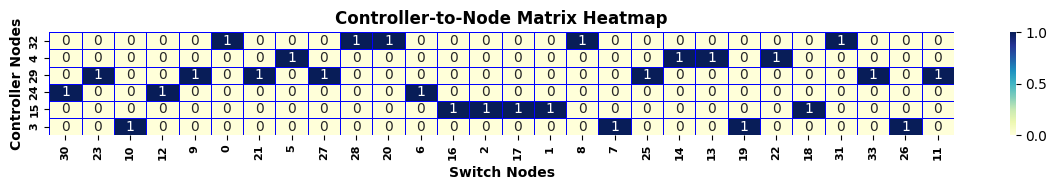

In [118]:
# 17
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming assigned_nodes_dict is already defined

# List of controllers and nodes
controllers = list(assigned_nodes.keys())  # Correcting the list from assigned_node_list
nodes = list(set(node for nodes in assigned_nodes.values() for node in nodes))

# Initialize the controller-to-node matrix with zeros (no assignments initially)
controller_to_node_matrix = np.zeros((len(controllers), len(nodes)))

# Populate the controller-to-node matrix with binary values (1 if node assigned, else 0)
for j, controller in enumerate(controllers):
    for node in assigned_nodes[controller]:
        i = nodes.index(node)
        controller_to_node_matrix[j, i] = 1  # Mark assignment

# Print the controller-to-node matrix
print("Controller-to-Node Matrix:")
print(controller_to_node_matrix)

# Plotting the controller-to-node matrix as a heatmap
plt.figure(figsize=(12, 2))  # Adjust the figure size as needed

# Use sns.heatmap to create the heatmap with a color intensity bar
ax = sns.heatmap(controller_to_node_matrix, cmap="YlGnBu", cbar=True,
                 linewidths=0.5, linecolor='blue', annot=True, fmt='g',
                 xticklabels=nodes, yticklabels=controllers)

# Set axis labels with bold font
plt.xlabel('Switch Nodes', fontsize=10, fontweight='bold')
plt.ylabel('Controller Nodes', fontsize=10, fontweight='bold')

# Set title with bold font
plt.title('Controller-to-Node Matrix Heatmap', fontsize=12, fontweight='bold')

# Bold x and y tick labels
plt.xticks(rotation=90, fontsize=8, fontweight='bold')
plt.yticks(fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()


In [119]:
K

['3', '32', '24', '4', '15', '29']

In [120]:
assigned_nodes

{'32': ['31', '8', '28', '0', '20'],
 '4': ['13', '22', '5', '14'],
 '29': ['11', '21', '23', '25', '27', '33', '9'],
 '24': ['12', '30', '6'],
 '15': ['1', '16', '2', '18', '17'],
 '3': ['10', '26', '7', '19']}

In [121]:
# # 21
# #HETEROGENEOUS CAPACITATED CONTROLLER PLACEMENT UNDER STATIC TRAFFIC - corrected code 

# from gurobipy import Model, GRB, quicksum
# import numpy as np

# # Calculate latency matrix T_ij
# all_nodes = list(geo_loc_data.keys())
# n = len(all_nodes)
# T_ij = np.zeros((n, n))

# for i in range(n):
#     for j in range(i + 1, n):
#         node1, node2 = all_nodes[i], all_nodes[j]
#         distance = haversine(node1, node2, geo_loc_data)
#         latency = (distance * 1000) / (2 * 1e8)  # Latency in milliseconds

#         T_ij[i][j] = latency
#         T_ij[j][i] = latency  # Symmetric matrix

# # Map nodes to indices
# node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}

# # Inputs
# C = [1200, 2500, 6500, 12000]  # Prices of controller types
# mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types
# flow_rate = 2                  # Flow rate (Kpps) of each switch

# switch_indices = list(range(n))  # Indices of all nodes as switches

# # switch_nodes = [node for node in all_nodes if node not in controllers]
# # switch_indices = [node_to_idx[node] for node in switch_nodes]  # Indices of switch nodes
# P = len(C)  # Number of controller types

# # Calculate C_max for normalization
# C_max = n * max(C)

# # Calculate T_max as the sum of all latencies in the T_ij matrix
# T_max = np.sum(T_ij)

# # Coefficients for objective function (adjust weights for cost and latency)
# alpha = 0.34  # Weight for cost minimization
# beta = 0.33  # Weight for switch-to-controller latency minimization
# gamma = 0.33  # Weight for controller-to-controller latency minimization

# # Create the model
# model = Model("Controller_Assignment")

# # Decision variables
# Y = model.addVars(P, n, vtype=GRB.BINARY, name="Y")  # Controller type placement
# D = model.addVars(n, n, vtype=GRB.BINARY, name="D")  # Switch-to-controller assignment

# # Objective function terms
# cost_term = quicksum(C[k] * Y[k, j] for k in range(P) for j in range(n))
# # latency_term = quicksum(T_ij[switch_indices[i], K[j]] * D[i, j] for i in range(n))
# latency_term = quicksum(T_ij[switch_indices[i], j] * D[i, j] for i in range(n) for j in range(n))

# controller_to_controller_latency_term = quicksum(
#     T_ij[j1, j2] * Y[k1, j1] * Y[k2, j2]
#     for k1 in range(P) for j1 in range(n)
#     for k2 in range(P) for j2 in range(n) if j1 < j2
# )


# # Set the objective function
# model.setObjective(
#     (alpha / C_max) * cost_term +
#     (beta / T_max) * latency_term +
#     (gamma / T_max) * controller_to_controller_latency_term,
#     GRB.MINIMIZE
# )


# # Adjust Constraints and Iterations in the Model
# # 1. Each selected location can host at most one type of controller
# for j in range(n):
#     model.addConstr(quicksum(Y[k, j] for k in range(P)) <= 1, name=f"Location_{j}_One_Controller")

# # 2. Each switch must be assigned to exactly one controller
# for i in range(n):
#     model.addConstr(quicksum(D[i, j] for j in range(n)) == 1, name=f"Switch_{i}_Assigned_To_One_Controller")

# # 3. Switches can only be assigned to active controllers
# for i in range(n):
#     for j in range(n):
#         model.addConstr(D[i, j] <= quicksum(Y[k, j] for k in range(P)), name=f"Switch_{i}_To_Active_Controller_{j}")

# # 4. Controller capacity must not be exceeded
# for j in range(n):
#     model.addConstr(
#         quicksum(flow_rate * D[i, j] for i in range(n)) <= quicksum(mu[k] * Y[k, j] for k in range(P)),
#         name=f"Controller_Capacity_{j}"
#     )

# # Solve the model
# model.optimize()


# if model.status == GRB.OPTIMAL:
#     print(f"Optimal Objective Value (Normalized): {model.objVal}")

#     # Determine optimal locations and location-to-switch assignments
#     optimal_locations = []
#     location_to_switch_assignment = {}
#     location_controller_types = {}
#     load_capacity_ratios = {}
#     total_cost = 0  # Initialize total cost

#     for j in range(n):  # Iterate over all possible locations
#         # Check if a controller is placed at location j
#         for k in range(P):
#             if Y[k, j].x > 0.5:  # Controller type k is placed at location j
#                 location = all_nodes[j]
#                 controller_type = k
#                 controller_capacity = mu[k]
#                 location_controller_types[location] = controller_type
#                 total_cost += C[k]

#                 # Assign switches to this location
#                 switches = [
#                     all_nodes[i] for i in range(n) if D[i, j].x > 0.5
#                 ]
#                 location_to_switch_assignment[location] = switches

#                 # Calculate and store the load-to-capacity ratio
#                 total_load = len(switches) * flow_rate
#                 load_capacity_ratio = total_load / controller_capacity if controller_capacity > 0 else 0
#                 load_capacity_ratios[location] = load_capacity_ratio

#                 print(f"Location {location}: Controller Type = {controller_type}, "
#                       f"Load = {total_load}, Capacity = {controller_capacity}, "
#                       f"Load-Capacity Ratio = {load_capacity_ratio:.2f}")
#                 break  # No need to check other controller types for this location

#     print("\nTotal Cost of Selected Controllers:", total_cost)
#     print("\nLocation-to-Switch Assignments:")
#     for location, switches in location_to_switch_assignment.items():
#         print(f"Location {location}: Switches {switches}")

#     # Calculate and print load imbalance
#     if load_capacity_ratios:
#         max_load_ratio = max(load_capacity_ratios.values())
#         min_load_ratio = min(load_capacity_ratios.values())
#         load_imbalance = ((max_load_ratio - min_load_ratio) / max_load_ratio) * 100 if max_load_ratio != 0 else 0.0

#         print("\n--------------------------------------")
#         print(f"Load Imbalance: {load_imbalance:.2f}%")
#         print(f"Overall Max Load Capacity Ratio = {max_load_ratio:.2f}")
#         print(f"Overall Min Load Capacity Ratio = {min_load_ratio:.2f}")

#     # Calculate switch-to-controller latency
#     total_switch_to_controller_latency = sum(
#         T_ij[node_to_idx[switch], node_to_idx[location]]
#         for location in optimal_locations
#         for switch in location_to_switch_assignment.get(location, [])
#     )
#     print(f"Total Switch-to-Controller Latency: {total_switch_to_controller_latency}")

#     # Calculate controller-to-controller latency
#     total_controller_to_controller_latency = sum(
#         T_ij[node_to_idx[optimal_locations[i]], node_to_idx[optimal_locations[j]]]
#         for i in range(len(optimal_locations))
#         for j in range(i + 1, len(optimal_locations))
#     )
#     print(f"Total Controller-to-Controller Latency: {total_controller_to_controller_latency}")

# else:
#     print("No feasible solution found.")

# print(f"\nTotal cost of controllers: {total_cost}")



In [122]:
# ttt
# #Ensure location_switch_allocations keys and values are strings
# location_switch_allocations = {
#     str(location): [str(node) for node in nodes]
#     for location, nodes in location_to_switch_assignment.items()
# }

# # Prepare the list of updated controllers
# updated_controllers = list(location_to_switch_assignment.keys())
# print("Updated Controllers:")
# print(updated_controllers)

# # Initialize a dictionary to store latency results for each controller
# latency_results = {}

# # Variables to compute aggregate latencies
# total_average_latency = 0
# max_worst_case_latency = float('-inf')

# # Variables for controller-to-controller latency calculations
# total_controller_latency = 0
# controller_pairs = 0
# max_pairwise_worst_case_latency = float('-inf')

# # Calculate latencies for each controller to assigned nodes
# for location, switches in location_to_switch_assignment.items():
#     total_latency = 0
#     worst_case_latency = float('-inf')

#     for switch in switches:
#         try:
#             # Calculate the shortest path length (latency) between the location and the node
#             latency = nx.shortest_path_length(G, source=location, target=switch, weight='weight')
            
#             # Convert latency to milliseconds
#             latency_ms = (latency * 1000) / (2 * 1e8)  # Adjust formula if necessary
            
#             # Update the cumulative and worst-case latencies
#             total_latency += latency_ms
#             worst_case_latency = max(worst_case_latency, latency_ms)
#         except nx.NetworkXNoPath:
#             print(f"No path found between location {location} and node {node}. Skipping latency calculation.")

#     # Calculate average latency for this controller
#     average_latency = total_latency / len(switches) if switches else 0
#     total_average_latency += average_latency  # Add to total average latency sum

#     # Update the maximum worst-case latency across all controllers
#     max_worst_case_latency = max(max_worst_case_latency, worst_case_latency)

#     # Store the latencies for this location
#     latency_results[location] = {
#         'average_latency': average_latency,
#         'worst_case_latency': worst_case_latency
#     }


# # Compute latencies between controllers
# for i, controller1 in enumerate(updated_controllers):
#     for j, controller2 in enumerate(updated_controllers):
#         if i < j:  # Avoid duplicate calculations for pairs
#             try:
#                 # Calculate shortest path length between two controllers
#                 pairwise_latency = nx.shortest_path_length(G, source=controller1, target=controller2, weight='weight')
#                 pairwise_latency_ms = (pairwise_latency * 1000) / (2 * 1e8)  # Adjust formula if necessary

#                 # Accumulate total controller-to-controller latency
#                 total_controller_latency += pairwise_latency_ms
#                 controller_pairs += 1

#                 # Update the maximum pairwise worst-case latency
#                 max_pairwise_worst_case_latency = max(max_pairwise_worst_case_latency, pairwise_latency_ms)
#             except nx.NetworkXNoPath:
#                 print(f"No path found between controllers {controller1} and {controller2}. Skipping latency calculation.")

# # Calculate the average controller-to-controller latency
# average_controller_latency = total_controller_latency / controller_pairs if controller_pairs > 0 else 0

# # Consolidate the results for the current percentage
# latency_results_per_percentage[percentage] = {
#     'average_controller_latency': average_controller_latency,
#     'max_pairwise_worst_case_latency': max_pairwise_worst_case_latency,
#     'total_average_latency': total_average_latency,
#     'max_worst_case_latency': max_worst_case_latency,
#     'controller_latencies': latency_results
# }

# # Display results
# print(f"\nAverage Controller-to-Controller Latency = {average_controller_latency:.15f} ms")
# print(f"Maximum Pairwise Worst-Case Latency = {max_pairwise_worst_case_latency:.15f} ms")
# print(f"\nTotal Average Node to Controller Latency = {total_average_latency:.15f} ms")
# print(f"Maximum Worst-Case Node to Controller Latency = {max_worst_case_latency:.15f} ms")


In [123]:
# import matplotlib.pyplot as plt
# import networkx as nx
# import matplotlib.cm as cm
# import matplotlib.colors as mcolors

# def plot_graph_with_location_assignments(G, geo_loc_data, location_to_switch_assignment):
#     """
#     Visualize the graph with geographical positions, highlighting controllers (locations)
#     and their assigned switches in distinct colors.
#     """
#     # Extract geographical positions
#     positions = {node: (data['long'], data['lat']) for node, data in geo_loc_data.items()}

#     # Initialize a figure
#     plt.figure(figsize=(8, 4))

#     # Create a colormap with distinct colors for each location (controller)
#     colormap = cm.get_cmap('tab20', len(location_to_switch_assignment))
#     color_norm = mcolors.Normalize(vmin=0, vmax=len(location_to_switch_assignment) - 1)

#     # Draw the entire graph with default edge color
#     nx.draw(
#         G, pos=positions, with_labels=True, node_color='lightgrey', 
#         node_size=100, font_size=8, edge_color='lightgray', alpha=0.5
#     )

#     # Highlight each controller location and its assigned switches
#     for index, (location, switches) in enumerate(location_to_switch_assignment.items()):
#         # Get the color for this controller location
#         color = colormap(color_norm(index))

#         # Draw the controller node (location)
#         nx.draw_networkx_nodes(
#             G, positions, nodelist=[location], node_size=300, node_color=[color],
#             edgecolors='black', label=f"Location {location}"
#         )

#         # Draw the switches assigned to this controller
#         nx.draw_networkx_nodes(
#             G, positions, nodelist=switches, node_size=150, node_color=[color],
#             alpha=0.8, edgecolors='black'
#         )

#         # Draw edges between the controller and its assigned switches
#         for switch in switches:
#             if G.has_edge(location, switch):
#                 nx.draw_networkx_edges(
#                     G, positions, edgelist=[(location, switch)], edge_color=[color], width=2
#                 )

#     # Add the legend outside the plot area to the right
#     plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Locations")

#     # Title and labels
#     # plt.title("Network Graph with Location-to-Switch Assignments", fontsize=14)
#     plt.xlabel("Longitude", fontsize=12)
#     plt.ylabel("Latitude", fontsize=12)

#     # Add grid to the plot
#     plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

#     # Adjust the layout to make room for the legend
#     plt.tight_layout()

#     # Show the plot
#     plt.show()

# # Example usage
# # Assuming G, geo_loc_data, and location_to_switch_assignment are defined
# plot_graph_with_location_assignments(G, geo_loc_data, location_to_switch_assignment)


In [124]:

# # Chapter 5 - Model for comparison with EBCP Framework - page 1 
# # # PLACEMENT OF SDN CONTROLLERS BASED ON NETWORK SETUP COSTS AND LATENCY OF CONTROL PACKETS - I
# from gurobipy import Model, GRB, quicksum
# import numpy as np

# # Inputs
# C = [1200, 2500, 6500, 12000]  # Prices of controller types
# mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types
# # m = len(K)  # Indices of selected candidate controllers
# # n = len(geo_loc_data)          # Number of nodes (switches + candidate controller locations)
# all_nodes = list(geo_loc_data.keys())
# n = len(all_nodes)
# P = len(C)                     # Number of controller types
# lambda_i = [2] * n             # Each switch has a constant flow rate of 2

# # Use the existing T_ij matrix for latency (latency between any pair of nodes)
# T_ij = np.zeros((n, n))


# # Calculate and store latency for every pair of nodes using haversine function
# all_nodes = list(geo_loc_data.keys())
# for i in range(n):
#     for j in range(i + 1, n):
#         node1, node2 = all_nodes[i], all_nodes[j]
#         distance = haversine(node1, node2, geo_loc_data)
#         latency = (distance * 1000) / (2 * 1e8)  # in milliseconds (assuming light speed in fiber)

#         # Store latency in the matrix (symmetric)
#         T_ij[i][j] = latency
#         T_ij[j][i] = latency

# # # Calculate C_max for normalization
# # C_max = len(selected_controllers) * max(C)

# # Calculate C_max for normalization
# C_max = n * max(C)

# # Calculate T_max as the sum of all latencies in the T_ij matrix
# T_max = np.sum(T_ij)

# # Coefficients for objective function (adjust weights for cost and latency)
# alpha = 0.34  # Weight for cost minimization
# beta = 0.33  # Weight for switch-to-controller latency minimization
# gamma = 0.33  # Weight for controller-to-controller latency minimization

# # Create the optimization model
# model = Model("Minimize_Controller_Cost_and_Assignment")

# # Decision variables
# Y = model.addVars(P, n, vtype=GRB.BINARY, name="Y")  # Controller type placement
# D = model.addVars(n, n, vtype=GRB.BINARY, name="D")  # Switch-to-controller assignment



# # Objective function terms
# cost_term = quicksum(C[k] * Y[k, j] for k in range(P) for j in range(n))
# latency_term = quicksum(T_ij[i, j] * D[i, j] for i in range(n) for j in range(n))


# # Define the controller-to-controller latency term
# controller_to_controller_latency_term = quicksum(
#     T_ij[j1, j2] * Y[k1, j1] * Y[k2, j2] 
#     for k1 in range(P) for j1 in range(n) for k2 in range(P) for j2 in range(n) if j1 != j2

# )


# # Update the objective function to include the controller-to-controller latency term
# model.setObjective(
#     (alpha / C_max) * cost_term + 
#     (beta / T_max) * latency_term + 
#     (gamma / T_max) * controller_to_controller_latency_term,
#     GRB.MINIMIZE
# )

# # Constraints
# # 1. Each selected location can host at most one type of controller
# for j in range(n):
#     model.addConstr(quicksum(Y[k, j] for k in range(P)) <= 1, name=f"Location_{j}_One_Controller")

# # 2. Each switch must be assigned to exactly one controller
# for i in range(n):
#     model.addConstr(quicksum(D[i, j] for j in range(n)) == 1, name=f"Switch_{i}_Assigned_To_One_Controller")

# # 3. Switches can only be assigned to active controllers
# for i in range(n):
#     for j in range(n):
#         model.addConstr(D[i, j] <= quicksum(Y[k, j] for k in range(P)), name=f"Switch_{i}_To_Active_Controller_{j}")

# # 4. Controller capacity must not be exceeded
# for j in range(n):
#     model.addConstr(
#         quicksum(lambda_i[i] * D[i, j] for i in range(n)) <= quicksum(mu[k] * Y[k, j] for k in range(P)),
#         name=f"Controller_Capacity_{j}"
#     )

# # Solve the model
# model.optimize()

# if model.status == GRB.OPTIMAL:
#     print(f"Optimal Objective Value (Normalized): {model.objVal}")
#     total_cost = 0
#     total_latency = 0
#     total_controller_latency = 0

#     # Dictionary to store the switches managed by each controller location
#     location_to_switch_assignment = {}

#     # Collect all controller locations
#     controller_locations = {j for k in range(P) for j in range(n) if Y[k, j].x > 0.5}

#     # Print allocation details and populate the dictionary
#     for k in range(P):
#         for j in range(n):
#             if Y[k, j].x > 0.5:  # Controller type `k` is placed at location `j`
#                 switches_managed = [
#                     i for i in range(n) 
#                     if D[i, j].x > 0.5 and i != j and i not in controller_locations
#                 ]

#                 # Store in dictionary
#                 location_to_switch_assignment[j] = switches_managed

#                 if switches_managed:
#                     print(f"Controller of type {k} at location {j} manages switches: {switches_managed}")
                
#                 total_cost += C[k]

#                 # Calculate total latency for this assignment
#                 for i in switches_managed:
#                     total_latency += T_ij[i, j]  # Add the latency for this switch-controller pair

#     # Calculate the total controller-to-controller latency
#     for k1 in range(P):
#         for j1 in range(n):
#             if Y[k1, j1].x > 0.5:
#                 for k2 in range(P):
#                     for j2 in range(n):
#                         if Y[k2, j2].x > 0.5 and j1 != j2:
#                             total_controller_latency += T_ij[j1, j2]

#     # Print total costs and latency metrics
#     print(f"\nTotal cost of controllers: {total_cost}")
#     print(f"Total switch-to-controller latency: {total_latency}")
#     print(f"Total controller-to-controller latency: {total_controller_latency}")

#     # Print the dictionary
#     print("\nLocation to Switch Assignment:")
#     for location, switches in location_to_switch_assignment.items():
#         print(f"Location {location}: {switches}")

# elif model.status == GRB.INFEASIBLE:
#     print("Model is infeasible. Debugging infeasibility...")
#     model.computeIIS()
#     model.write("infeasible_model.ilp")
#     print("IIS written to 'infeasible_model.ilp'.")
# else:
#     print("No feasible solution found.")


In [125]:
# # Chapter 5 - Model for comparison with EBCP Framework - page 2 
# #Ensure location_switch_allocations keys and values are strings
# # Ensure location_to_switch_assignment keys and values are strings
# location_to_switch_assignment = {
#     str(location): [str(node) for node in nodes]
#     for location, nodes in location_to_switch_assignment.items()
# }


# # Prepare the list of updated controllers
# updated_controllers = list(location_to_switch_assignment.keys())
# print("Updated Controllers:")
# print(updated_controllers)

# # Print the dictionary
# print("\nLocation to Switch Assignment:")
# for location, switches in location_to_switch_assignment.items():
#     print(f"Location {location}: {switches}")

# # Initialize a dictionary to store latency results for each controller
# latency_results = {}

# # Variables to compute aggregate latencies
# total_average_latency = 0
# max_worst_case_latency = float('-inf')

# # Variables for controller-to-controller latency calculations
# total_controller_latency = 0
# controller_pairs = 0
# max_pairwise_worst_case_latency = float('-inf')

# # Calculate latencies for each controller to assigned nodes
# for location, switches in location_to_switch_assignment.items():
#     total_latency = 0
#     worst_case_latency = float('-inf')

#     for switch in switches:
#         try:
#             # Calculate the shortest path length (latency) between the location and the node
#             latency = nx.shortest_path_length(G, source=location, target=switch, weight='weight')
            
#             # Convert latency to milliseconds
#             latency_ms = (latency * 1000) / (2 * 1e8)  # Adjust formula if necessary
            
#             # Update the cumulative and worst-case latencies
#             total_latency += latency_ms
#             worst_case_latency = max(worst_case_latency, latency_ms)
#         except nx.NetworkXNoPath:
#             print(f"No path found between location {location} and node {node}. Skipping latency calculation.")

#     # Calculate average latency for this controller
#     average_latency = total_latency / len(switches) if switches else 0
#     total_average_latency += average_latency  # Add to total average latency sum

#     # Update the maximum worst-case latency across all controllers
#     max_worst_case_latency = max(max_worst_case_latency, worst_case_latency)

#     # Store the latencies for this location
#     latency_results[location] = {
#         'average_latency': average_latency,
#         'worst_case_latency': worst_case_latency
#     }


# # Compute latencies between controllers
# for i, controller1 in enumerate(updated_controllers):
#     for j, controller2 in enumerate(updated_controllers):
#         if i < j:  # Avoid duplicate calculations for pairs
#             try:
#                 # Calculate shortest path length between two controllers
#                 pairwise_latency = nx.shortest_path_length(G, source=controller1, target=controller2, weight='weight')
#                 pairwise_latency_ms = (pairwise_latency * 1000) / (2 * 1e8)  # Adjust formula if necessary

#                 # Accumulate total controller-to-controller latency
#                 total_controller_latency += pairwise_latency_ms
#                 controller_pairs += 1

#                 # Update the maximum pairwise worst-case latency
#                 max_pairwise_worst_case_latency = max(max_pairwise_worst_case_latency, pairwise_latency_ms)
#             except nx.NetworkXNoPath:
#                 print(f"No path found between controllers {controller1} and {controller2}. Skipping latency calculation.")

# # Calculate the average controller-to-controller latency
# average_controller_latency = total_controller_latency / controller_pairs if controller_pairs > 0 else 0

# # Consolidate the results for the current percentage
# latency_results_per_percentage[percentage] = {
#     'average_controller_latency': average_controller_latency,
#     'max_pairwise_worst_case_latency': max_pairwise_worst_case_latency,
#     'total_average_latency': total_average_latency,
#     'max_worst_case_latency': max_worst_case_latency,
#     'controller_latencies': latency_results
# }

# # Display results
# print(f"\nAverage Controller-to-Controller Latency = {average_controller_latency:.15f} ms")
# print(f"Maximum Pairwise Worst-Case Latency = {max_pairwise_worst_case_latency:.15f} ms")
# print(f"\nTotal Average Node to Controller Latency = {total_average_latency:.15f} ms")
# print(f"Maximum Worst-Case Node to Controller Latency = {max_worst_case_latency:.15f} ms")


In [126]:
# # Chapter 5 - Model for comparison with EBCP Framework - page 3
# # Initialize variables to store total loads and capacities by controller type
# controller_loads = {k: 0 for k in range(P)}  # Total load for each controller type
# controller_capacities = {k: 0 for k in range(P)}  # Capacity of each controller type
# location_to_controller_type = {}  # To store controller type assigned to each location

# # Loop through each controller location to calculate its load, capacity, and ratio
# for j in range(n):
#     controller_type = None
#     for k in range(P):
#         if Y[k, j].x > 0.5:  # Controller of type `k` is placed at location `j`
#             controller_type = k
#             break

#     if controller_type is not None:  # If a controller is placed at this location
#         # Calculate total load at this location
#         total_load = sum(lambda_i[int(switch)] for switch in location_to_switch_assignment.get(str(j), []))
        
#         # Calculate load capacity ratio
#         capacity = mu[controller_type]
#         load_capacity_ratio = total_load / capacity if capacity > 0 else 0

#         # Add to the controller type's total load and capacity
#         controller_loads[controller_type] += total_load
#         controller_capacities[controller_type] += capacity
        
#         # Store the controller type for this location
#         location_to_controller_type[j] = controller_type

#         # Print load, capacity, and load capacity ratio for this specific location
#         print(f"Location {j}: Controller Type {controller_type}, Total Load: {total_load}, "
#               f"Capacity: {capacity}, Load Capacity Ratio: {load_capacity_ratio:.2f}")
        
# # Initialize variables for load imbalance calculation
# load_ratios = []

# # Loop through each controller location to calculate its load, capacity, and ratio
# for j in range(n):
#     controller_type = None
#     for k in range(P):
#         if Y[k, j].x > 0.5:  # Controller of type `k` is placed at location `j`
#             controller_type = k
#             break

#     if controller_type is not None:  # If a controller is placed at this location
#         # Calculate total load at this location
#         total_load = sum(lambda_i[int(switch)] for switch in location_to_switch_assignment.get(str(j), []))
        
#         # Calculate capacity utilization (load-to-capacity ratio)
#         capacity = mu[controller_type]
#         load_ratio = total_load / capacity if capacity > 0 else 0
#         load_ratios.append(load_ratio)

# # Calculate max and min load capacity ratios
# if load_ratios:
#     max_load_capacity_ratio = max(load_ratios)
#     min_load_capacity_ratio = min(load_ratios)

#     # Calculate load imbalance
#     if max_load_capacity_ratio > 0:
#         load_imbalance = ((max_load_capacity_ratio - min_load_capacity_ratio) / max_load_capacity_ratio) * 100
#     else:
#         load_imbalance = 0

#     # Print the load imbalance
#     print(f"\nLoad Imbalance: {load_imbalance:.2f}%")
#     print(f"\nmax_load_capacity_ratio: {max_load_capacity_ratio:.2f}")
#     print(f"\nmin_load_capacity_ratio: {min_load_capacity_ratio:.2f}")
# else:
#     print("\nNo active controllers to calculate load imbalance.")


In [127]:
# # Chapter 5 - Model for comparison with EBCP Framework - page 4
# import matplotlib.pyplot as plt
# import networkx as nx
# import matplotlib.cm as cm
# import matplotlib.colors as mcolors

# def plot_graph_with_location_assignments(G, geo_loc_data, location_to_switch_assignment):
#     """
#     Visualize the graph with geographical positions, highlighting controllers (locations)
#     and their assigned switches in distinct colors.
#     """
#     # Extract geographical positions
#     positions = {node: (data['long'], data['lat']) for node, data in geo_loc_data.items()}

#     # Initialize a figure
#     plt.figure(figsize=(8, 4))

#     # Create a colormap with distinct colors for each location (controller)
#     colormap = cm.get_cmap('tab20', len(location_to_switch_assignment))
#     color_norm = mcolors.Normalize(vmin=0, vmax=len(location_to_switch_assignment) - 1)

#     # Draw the entire graph with default edge color
#     nx.draw(
#         G, pos=positions, with_labels=True, node_color='lightgrey', 
#         node_size=100, font_size=8, edge_color='lightgray', alpha=0.5
#     )

#     # Highlight each controller location and its assigned switches
#     for index, (location, switches) in enumerate(location_to_switch_assignment.items()):
#         # Get the color for this controller location
#         color = colormap(color_norm(index))

#         # Draw the controller node (location)
#         nx.draw_networkx_nodes(
#             G, positions, nodelist=[location], node_size=300, node_color=[color],
#             edgecolors='black', label=f"Location {location}"
#         )

#         # Draw the switches assigned to this controller
#         nx.draw_networkx_nodes(
#             G, positions, nodelist=switches, node_size=150, node_color=[color],
#             alpha=0.8, edgecolors='black'
#         )

#         # Draw edges between the controller and its assigned switches
#         for switch in switches:
#             if G.has_edge(location, switch):
#                 nx.draw_networkx_edges(
#                     G, positions, edgelist=[(location, switch)], edge_color=[color], width=2
#                 )

#     # Add the legend outside the plot area to the right
#     plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Locations")

#     # Title and labels
#     # plt.title("Network Graph with Location-to-Switch Assignments", fontsize=14)
#     plt.xlabel("Longitude", fontsize=12)
#     plt.ylabel("Latitude", fontsize=12)

#     # Add grid to the plot
#     plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

#     # Adjust the layout to make room for the legend
#     plt.tight_layout()

#     # Show the plot
#     plt.show()

# # Example usage
# # Assuming G, geo_loc_data, and location_to_switch_assignment are defined
# plot_graph_with_location_assignments(G, geo_loc_data, location_to_switch_assignment)


In [128]:
# 18 
# # Synethetic Traffic Generation for highest Peak Period 1
# import numpy as np
# import pandas as pd
# import seaborn as sns
# import networkx as nx
# import matplotlib.pyplot as plt
# import random

# # Set the seed for reproducibility
# np.random.seed(42)
# random.seed(42)

# # Define flow ranges
# mice_flow_range = (2, 4)
# elephant_flow_range = (4, 9)

# # Define the distribution weights
# mice_weight = 0.4
# elephant_weight = 0.6

# # Step 2: Calculate centrality metrics
# # Calculate betweenness centrality
# betweenness_centrality = nx.betweenness_centrality(G, weight='latency')
# # Calculate closeness centrality
# closeness_centrality = nx.closeness_centrality(G, distance='latency')

# # Normalize centrality metrics
# max_betweenness = max(betweenness_centrality.values())
# max_closeness = max(closeness_centrality.values())
# normalized_betweenness = {node: value / max_betweenness for node, value in betweenness_centrality.items()}
# normalized_closeness = {node: value / max_closeness for node, value in closeness_centrality.items()}

# # Create a combined centrality value by summing normalized betweenness and closeness
# combined_centrality = {node: normalized_betweenness.get(node, 0) + normalized_closeness.get(node, 0)
#                        for node in G.nodes()}

# # Step 3: Prepare data for heatmap with flow classification
# heatmap_data = []
# flow_type_data = []

# # Create a list to store data for each controller and its assigned switches
# for controller, switches in assigned_nodes.items():
#     # Shuffle switches to ensure even distribution of flow types
#     random.shuffle(switches)
    
#     # Calculate number of mice and elephant flows
#     num_switches = len(switches)
#     num_mice_flows = int(num_switches * mice_weight)
#     num_elephant_flows = num_switches - num_mice_flows
    
#     # Assign traffic loads
#     mice_flows = np.random.uniform(mice_flow_range[0], mice_flow_range[1], num_mice_flows)
#     elephant_flows = np.random.uniform(elephant_flow_range[0], elephant_flow_range[1], num_elephant_flows)
    
#     traffic_loads = np.concatenate([mice_flows, elephant_flows])
#     flow_types = ['m'] * num_mice_flows + ['e'] * num_elephant_flows
#     np.random.shuffle(traffic_loads)  # Shuffle to mix flow types
#     np.random.shuffle(flow_types)  # Shuffle flow types
    
#     for switch, load, flow_type in zip(switches, traffic_loads, flow_types):
#         # Scale traffic load by combined centrality
#         scaled_load = load * combined_centrality.get(switch, 1)  # Default to 1 if centrality not found
#         heatmap_data.append({
#             'Controller': controller,
#             'Switch': switch,
#             'Scaled Load': scaled_load  # Use only scaled load for heatmap
#         })
#         flow_type_data.append({
#             'Switch': switch,
#             'Type': flow_type  # Flow type ('e' or 'm')
#         })

# # Convert to DataFrame for heatmap
# df_heatmap = pd.DataFrame(heatmap_data)

# # Convert to DataFrame for switch types
# df_flow_types = pd.DataFrame(flow_type_data)

# # Step 4: Create the heatmap showing scaled load
# # Use pivot_table to restructure the DataFrame for heatmap visualization
# heatmap_df = df_heatmap.pivot_table(index='Controller', columns='Switch', values='Scaled Load', aggfunc='mean')

# # Plot the heatmap
# plt.figure(figsize=(12, 2))
# sns.heatmap(heatmap_df, annot=True, cmap='YlGnBu', linewidths=0.5, linecolor='black', annot_kws={"size": 6})
# plt.title("Total Scaled Load Heatmap", fontsize=14, fontweight='bold')
# plt.xlabel("Switch", fontsize=12, fontweight='bold')
# plt.ylabel("Controller", fontsize=12, fontweight='bold')

# # Embolden x and y axis tick labels
# plt.xticks(fontsize=10, fontweight='bold')
# plt.yticks(fontsize=10, fontweight='bold')
# plt.show()

# # Step 5: Display the table of switch nodes and their types
# print("Switch Nodes and Types:")
# print(df_flow_types)

# # Step 6: Prepare the table for total scaled load per controller
# controller_total_scaled_load = df_heatmap.groupby('Controller')['Scaled Load'].sum().reset_index()
# controller_total_scaled_load.columns = ['Controller', 'Total Scaled Load']

# # Step 7: Display the total scaled load for each controller
# print("\nTotal Scaled Load per Controller:")
# print(controller_total_scaled_load)

# # Calculate the sum of Total Scaled Load for all controllers
# total_scaled_load_sum = controller_total_scaled_load['Total Scaled Load'].sum()

# # Print the total scaled load sum
# print(f"\nTotal Scaled Load Sum for All Controllers: {total_scaled_load_sum}")


Controller-to-Switch Matrix with Load:
[[0. 0. 2. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 2. 0. 0. 0. 2. 0. 0.
  0. 0. 2. 0.]
 [0. 0. 0. 0. 0. 2. 0. 0. 0. 2. 2. 0. 0. 0. 0. 0. 2. 0. 0. 0. 0. 0. 0. 0.
  2. 0. 0. 0.]
 [2. 0. 0. 2. 0. 0. 0. 0. 0. 0. 0. 2. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 2. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 2. 2. 0. 2. 0.
  0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 2. 2. 2. 2. 0. 0. 0. 0. 0. 0. 0. 2.
  0. 0. 0. 0.]
 [0. 2. 0. 0. 2. 0. 2. 0. 2. 0. 0. 0. 0. 0. 0. 0. 0. 0. 2. 0. 0. 0. 0. 0.
  0. 2. 0. 2.]]


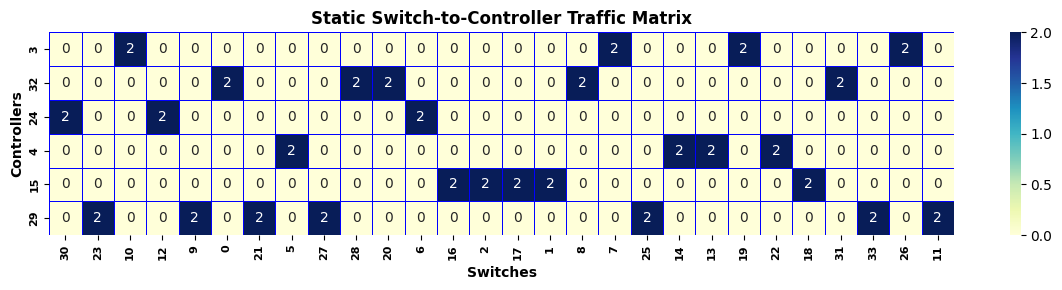

In [129]:
# 19  Illustrate heatmpa of Static Traffic load at 2kps for each switch 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming assigned_nodes_dict and selected_locations are already defined

# Flow rate (Kpps) of each switch
flow_rate = 2  

# List of controllers and switches
controllers = list(K)

# Create a sorted list of all switches
switches = list({switch for switches in assigned_nodes.values() for switch in switches})

# Initialize the controller-to-switch matrix
location_to_switch_assignment_matrix = np.zeros((len(controllers), len(switches)))

# Populate the matrix with load values (flow_rate) where there is a connection
for j, controller in enumerate(controllers):
    for switch in assigned_nodes[controller]:
        i = switches.index(switch)
        location_to_switch_assignment_matrix[j, i] = flow_rate  # Assign the load

# Print the controller-to-switch matrix
print("Controller-to-Switch Matrix with Load:")
print(location_to_switch_assignment_matrix)

# Plotting the controller-to-switch matrix as a heatmap
plt.figure(figsize=(12, 3))  # Adjust the figure size as needed

# Use sns.heatmap to create the heatmap with a color intensity bar
ax = sns.heatmap(location_to_switch_assignment_matrix, cmap="YlGnBu", cbar=True,
                 linewidths=0.5, linecolor='blue', annot=True, fmt='g',
                 xticklabels=switches, yticklabels=controllers)

# Set axis labels with bold font
plt.xlabel('Switches', fontsize=10, fontweight='bold')
plt.ylabel('Controllers', fontsize=10, fontweight='bold')

# Set title with bold font
plt.title('Static Switch-to-Controller Traffic Matrix', fontsize=12, fontweight='bold')

# Bold x and y tick labels
plt.xticks(rotation=90, fontsize=8, fontweight='bold')
plt.yticks(fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()


In [130]:
K

['3', '32', '24', '4', '15', '29']

C:\Users\AdebayoI\AppData\Local\Temp\ipykernel_25692\3368889587.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap('tab20', len(assigned_nodes))
C:\Users\AdebayoI\AppData\Local\Temp\ipykernel_25692\3368889587.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


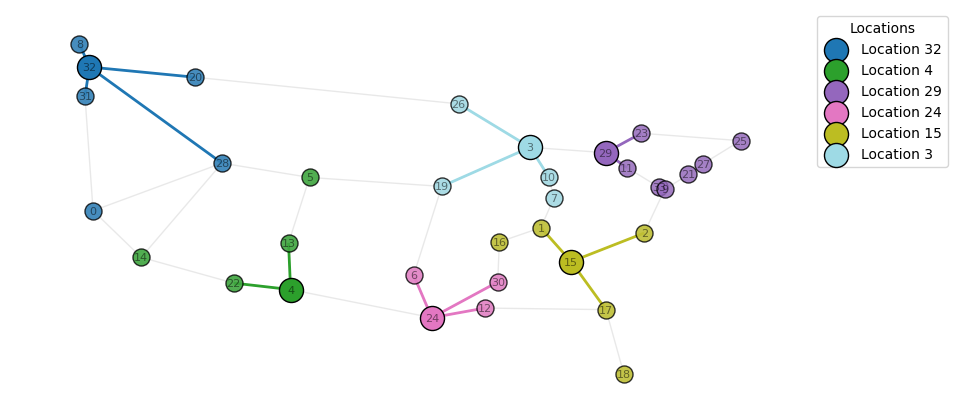

In [131]:
# PLOT for Chapter four 
# Chapter 5 - Model for comparison with EBCP Framework - page 4
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def plot_graph_with_location_assignments(G, geo_loc_data, assigned_nodes):
    """
    Visualize the graph with geographical positions, highlighting controllers (locations)
    and their assigned switches in distinct colors.
    """
    # Extract geographical positions
    positions = {node: (data['long'], data['lat']) for node, data in geo_loc_data.items()}

    # Initialize a figure
    plt.figure(figsize=(8, 4))

    # Create a colormap with distinct colors for each location (controller)
    colormap = cm.get_cmap('tab20', len(assigned_nodes))
    color_norm = mcolors.Normalize(vmin=0, vmax=len(assigned_nodes) - 1)

    # Draw the entire graph with default edge color
    nx.draw(
        G, pos=positions, with_labels=True, node_color='lightgrey', 
        node_size=100, font_size=8, edge_color='lightgray', alpha=0.5
    )

    # Highlight each controller location and its assigned switches
    for index, (location, switches) in enumerate(assigned_nodes.items()):
        # Get the color for this controller location
        color = colormap(color_norm(index))

        # Draw the controller node (location)
        nx.draw_networkx_nodes(
            G, positions, nodelist=[location], node_size=300, node_color=[color],
            edgecolors='black', label=f"Location {location}"
        )

        # Draw the switches assigned to this controller
        nx.draw_networkx_nodes(
            G, positions, nodelist=switches, node_size=150, node_color=[color],
            alpha=0.8, edgecolors='black'
        )

        # Draw edges between the controller and its assigned switches
        for switch in switches:
            if G.has_edge(location, switch):
                nx.draw_networkx_edges(
                    G, positions, edgelist=[(location, switch)], edge_color=[color], width=2
                )

    # Add the legend outside the plot area to the right
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Locations")

    # Title and labels
    # plt.title("Network Graph with Location-to-Switch Assignments", fontsize=14)
    plt.xlabel("Longitude", fontsize=12)
    plt.ylabel("Latitude", fontsize=12)

    # Add grid to the plot
    plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    # Adjust the layout to make room for the legend
    plt.tight_layout()

    # Show the plot
    plt.show()

# Example usage
# Assuming G, geo_loc_data, and location_to_switch_assignment are defined
plot_graph_with_location_assignments(G, geo_loc_data, assigned_nodes)


In [132]:
# # 20
# #HOMOGENEOUS CAPACIATED CONTROLLER PLACEMENT UNDER STATIC TRAFFIC - corrected code 
# from gurobipy import Model, GRB, quicksum
# import numpy as np

# # Assuming geo_loc_data and haversine function are defined
# # geo_loc_data contains node names as keys and (latitude, longitude) as values
# # haversine(node1, node2, geo_loc_data) calculates distance between two nodes

# # Calculate latency matrix T_ij
# all_nodes = list(geo_loc_data.keys())
# n = len(all_nodes)
# T_ij = np.zeros((n, n))

# for i in range(n):
#     for j in range(i + 1, n):
#         node1, node2 = all_nodes[i], all_nodes[j]
#         distance = haversine(node1, node2, geo_loc_data)
#         latency = (distance * 1000) / (2 * 1e8)  # Latency in milliseconds
#         T_ij[i][j] = latency
#         T_ij[j][i] = latency  # Symmetric matrix

# # Map nodes to indices
# node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}

# # Inputs
# C = [1200, 2500, 6500, 12000]  # Prices of controller types
# mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types
# flow_rate = 2                  # Flow rate (Kpps) of each switch

# # Define `K` (indices of selected candidate controllers)
# K = [node_to_idx[node] for node in controllers]
# m = len(K)
# switch_nodes = [node for node in all_nodes if node not in controllers]
# switch_indices = [node_to_idx[node] for node in switch_nodes]
# P = len(C)

# # Calculate normalization factors
# C_max = len(switch_nodes) * max(C)
# T_max = np.sum(T_ij)

# # Objective function weights
# alpha, beta, gamma = 0.34, 0.33, 0.33

# # Create the model
# model = Model("Controller_Assignment")

# # Decision Variables
# Z = model.addVars(P, vtype=GRB.BINARY, name="Z")
# Y = model.addVars(P, m, vtype=GRB.BINARY, name="Y")
# D = model.addVars(len(switch_nodes), m, vtype=GRB.BINARY, name="D")

# # Objective Function
# model.setObjective(
#     (alpha / C_max) * quicksum(C[k] * Y[k, j] for k in range(P) for j in range(m)) +
#     (beta / T_max) * quicksum(T_ij[switch_indices[i], K[j]] * D[i, j] for i in range(len(switch_nodes)) for j in range(m)) +
#     (gamma / T_max) * quicksum(
#         T_ij[K[j1], K[j2]] * Y[k1, j1] * Y[k2, j2]
#         for k1 in range(P) for j1 in range(m)
#         for k2 in range(P) for j2 in range(m) if j1 < j2
#     ),
#     GRB.MINIMIZE
# )

# # Constraints
# model.addConstr(quicksum(Z[k] for k in range(P)) == 1, name="Single_Controller_Type")

# for j in range(m):
#     for k in range(P):
#         model.addConstr(Y[k, j] <= Z[k], name=f"Controller_Type_{k}_Location_{j}")

# for j in range(m):
#     model.addConstr(quicksum(Y[k, j] for k in range(P)) <= 1, name=f"Location_{j}_One_Controller")

# for i in range(len(switch_nodes)):
#     model.addConstr(quicksum(D[i, j] for j in range(m)) == 1, name=f"Switch_{i}_Assigned_To_One_Controller")

# for i in range(len(switch_nodes)):
#     for j in range(m):
#         model.addConstr(D[i, j] <= quicksum(Y[k, j] for k in range(P)), name=f"Switch_{i}_To_Active_Controller_{j}")

# for j in range(m):
#     model.addConstr(
#         quicksum(flow_rate * D[i, j] for i in range(len(switch_nodes))) <= quicksum(mu[k] * Y[k, j] for k in range(P)),
#         name=f"Controller_Capacity_{j}"
#     )

# max_capacity = 0.80
# for j in range(m):
#     load = quicksum(flow_rate * D[i, j] for i in range(len(switch_nodes)))
#     capacity = quicksum(mu[k] * Y[k, j] for k in range(P))
#     model.addConstr(load <= max_capacity * capacity, name=f"Max_Capacity_Ratio_Controller_{j}")

# # Solve the model
# model.optimize()

# if model.status == GRB.OPTIMAL:
#     print(f"Optimal Objective Value: {model.objVal}")

#     # Determine optimal locations
#     optimal_locations = [all_nodes[K[j]] for j in range(m) if any(Y[k, j].x > 0.5 for k in range(P))]
#     print(f"Optimal Locations: {optimal_locations}")

#     # Switch assignments to controllers
#     switch_assignments = {}
#     for i, switch in enumerate(switch_nodes):
#         assigned_controller_idx = next(j for j in range(m) if D[i, j].x > 0.5)
#         assigned_controller = all_nodes[K[assigned_controller_idx]]
#         switch_assignments[switch] = assigned_controller

#     # Find remaining nodes in K
#     remaining_nodes = [all_nodes[K[j]] for j in range(m) if all(Y[k, j].x <= 0.5 for k in range(P))]

#     # Reassign remaining nodes as switches
#     reassigned_switch_assignments = {}
#     for node in remaining_nodes:
#         node_idx = node_to_idx[node]
#         closest_controller = min(
#             optimal_locations,
#             key=lambda loc: T_ij[node_idx, node_to_idx[loc]]
#         )
#         reassigned_switch_assignments[node] = closest_controller

# if model.status == GRB.OPTIMAL:
#     print(f"Optimal Objective Value: {model.objVal}")

#     # Determine optimal and unselected locations
#     selected_locations = [all_nodes[K[j]] for j in range(m) if any(Y[k, j].x > 0.5 for k in range(P))]
#     unselected_locations = [all_nodes[K[j]] for j in range(m) if all(Y[k, j].x <= 0.5 for k in range(P))]

#     print(f"Selected Locations (Optimal): {selected_locations}")
#     print(f"Unselected Locations (To Be Reassigned as Switches): {unselected_locations}")

#     # Assign switches to locations
#     location_to_switch_assignment = {loc: [] for loc in selected_locations}

#     # Assign initially
#     for i, switch in enumerate(switch_nodes):
#         assigned_location = None
#         for j in range(m):
#             if D[i, j].x > 0.5:
#                 assigned_location = all_nodes[K[j]]
#                 break
#         if assigned_location:
#             location_to_switch_assignment[assigned_location].append(switch)

#     # Reassign unselected locations as switches
#     for unselected_loc in unselected_locations:
#         node_idx = node_to_idx[unselected_loc]
#         closest_location = min(
#             selected_locations,
#             key=lambda loc: T_ij[node_idx, node_to_idx[loc]]
#         )
#         location_to_switch_assignment[closest_location].append(unselected_loc)

#     # Balance the switch assignments
#     print("\nBalancing Location-to-Switch Assignments:")
#     max_switches = max(len(switches) for switches in location_to_switch_assignment.values())
#     min_switches = min(len(switches) for switches in location_to_switch_assignment.values())

#     while max_switches - min_switches > 1:
#         # Find overloaded and underloaded locations
#         overloaded_location = max(location_to_switch_assignment, key=lambda loc: len(location_to_switch_assignment[loc]))
#         underloaded_location = min(location_to_switch_assignment, key=lambda loc: len(location_to_switch_assignment[loc]))
    
#         # Select a switch to move from the overloaded to underloaded location
#         switch_to_move = location_to_switch_assignment[overloaded_location].pop()
#         underloaded_location_idx = node_to_idx[underloaded_location]
    
#         # Reassign the switch based on proximity
#         closest_location = min(
#             [underloaded_location],
#             key=lambda loc: T_ij[node_to_idx[switch_to_move], node_to_idx[loc]]
#         )
#         location_to_switch_assignment[closest_location].append(switch_to_move)
    
#         # Update max and min switches
#         max_switches = max(len(switches) for switches in location_to_switch_assignment.values())
#         min_switches = min(len(switches) for switches in location_to_switch_assignment.values())

#     # Print final balanced assignments
#     print("\nFinal Balanced Location-to-Switch Assignments:")
#     for location, switches in location_to_switch_assignment.items():
#         print(f"Location {location}: {switches}")

#     # # Print updated location-to-switch assignments
#     # print("\nUpdated Location-to-Switch Assignments After Reassignment:")
#     # for location, switches in location_to_switch_assignment.items():
#     #     print(f"Location {location}: {switches}")

#     # Calculate and print load-to-capacity ratio for each updated location
#     print("\nLoad-to-Capacity Ratios for Each Location After Reassignment:")
#     controller_type_names = ['A', 'B', 'C', 'D']  # Mapping of controller types

#     load_capacity_ratios = {}  # Store load-to-capacity ratios for each location
#     for location, switches in location_to_switch_assignment.items():
#         total_load = len(switches) * flow_rate  # Calculate total load for the location
#         selected_controller_type = None
#         selected_capacity = 0

#         # Find the assigned controller type and its capacity
#         for j in range(m):
#             if all_nodes[K[j]] == location:
#                 for k in range(P):
#                     if Y[k, j].x > 0.5:
#                         selected_controller_type = k
#                         selected_capacity = mu[k]
#                         break
#                 break

#         # Calculate the load-to-capacity ratio and enforce capacity constraints
#         if selected_capacity > 0:
#             load_capacity_ratio = total_load / selected_capacity
#             load_capacity_ratios[location] = load_capacity_ratio

#             # Check and enforce capacity constraint
#             if total_load > selected_capacity:
#                 print(f"WARNING: Location {location} exceeds capacity! "
#                       f"Load = {total_load}, Capacity = {selected_capacity}. "
#                       f"(Controller Type {controller_type_names[selected_controller_type]})")
#             else:
#                 print(f"Location {location}: "
#                       f"Load = {total_load}, Capacity = {selected_capacity}, "
#                       f"Load_Capacity_Ratio = {load_capacity_ratio:.2f} "
#                       f"(Controller Type {controller_type_names[selected_controller_type]})")
#         else:
#             print(f"Location {location}: No assigned controller.")

#     # Calculate and print the total cost of controllers
#     total_cost = 0
#     for location, switches in location_to_switch_assignment.items():
#         selected_capacity = 0
#         selected_controller_type = None

#         # Find the assigned controller's capacity
#         for j in range(m):
#             if all_nodes[K[j]] == location:
#                 for k in range(P):
#                     if Y[k, j].x > 0.5:
#                         selected_controller_type = k
#                         selected_capacity = mu[k]
#                         break
#                 break

#         if selected_controller_type is not None:
#             total_cost += C[selected_controller_type]  # Use cost from C list

#     print(f"\nTotal cost of controllers: {total_cost}")

#     # Calculate and store load imbalance for the current configuration
#     if load_capacity_ratios:
#         max_load_ratio = max(load_capacity_ratios.values())
#         min_load_ratio = min(load_capacity_ratios.values())
#         load_imbalance = ((max_load_ratio - min_load_ratio) / max_load_ratio) * 100 if max_load_ratio != 0 else 0.0

#         print("\n--------------------------------------")
#         print(f"Load Imbalance: {load_imbalance:.2f}%")
#         print(f"Overall Max Load Capacity Ratio = {max_load_ratio:.2f}")
#         print(f"Overall Min Load Capacity Ratio = {min_load_ratio:.2f}")

#     # Calculate and print switch-to-controller latency
#     total_switch_to_controller_latency = 0.0
#     for location in selected_locations:
#         for switch in location_to_switch_assignment.get(location, []):
#             switch_idx = node_to_idx[switch]
#             controller_idx = node_to_idx[location]  # Assuming location is assigned a controller node
#             latency = T_ij[switch_idx, controller_idx]
#             total_switch_to_controller_latency += latency

#     print(f"Total Switch-to-Controller Latency: {total_switch_to_controller_latency}")

#     # Calculate and print controller-to-controller latency
#     total_controller_to_controller_latency = 0.0
#     for i, location1 in enumerate(selected_locations):
#         for j, location2 in enumerate(selected_locations):
#             if i < j:  # Avoid double counting
#                 controller1_idx = node_to_idx[location1]
#                 controller2_idx = node_to_idx[location2]
#                 latency = T_ij[controller1_idx, controller2_idx]
#                 total_controller_to_controller_latency += latency

#     print(f"Total Controller-to-Controller Latency: {total_controller_to_controller_latency}")

# else:
#     print("No feasible solution found.")



In [133]:
# #HOMOGENEOUS CAPACIATED CONTROLLER PLACEMENT UNDER STATIC TRAFFIC   -     Previous code 

# from gurobipy import Model, GRB, quicksum
# import numpy as np

# # Assuming geo_loc_data and haversine function are defined
# # geo_loc_data contains node names as keys and (latitude, longitude) as values
# # haversine(node1, node2, geo_loc_data) calculates distance between two nodes

# # Calculate latency matrix T_ij
# all_nodes = list(geo_loc_data.keys())
# n = len(all_nodes)
# T_ij = np.zeros((n, n))

# for i in range(n):
#     for j in range(i + 1, n):
#         node1, node2 = all_nodes[i], all_nodes[j]
#         distance = haversine(node1, node2, geo_loc_data)
#         latency = (distance * 1000) / (2 * 1e8)  # Latency in milliseconds

#         T_ij[i][j] = latency
#         T_ij[j][i] = latency  # Symmetric matrix

# # Map nodes to indices
# node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}

# # Inputs
# C = [1200, 2500, 6500, 12000]  # Prices of controller types
# mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types
# flow_rate = 2                  # Flow rate (Kpps) of each switch

# # Define `K` (indices of selected candidate controllers)
# K = [node_to_idx[node] for node in controllers]  # Ensure controllers is defined
# m = len(K)  # Number of selected controller candidates
# switch_nodes = [node for node in all_nodes if node not in controllers]
# switch_indices = [node_to_idx[node] for node in switch_nodes]  # Indices of switch nodes
# P = len(C)  # Number of controller types

# # Calculate C_max for normalization
# C_max = len(switch_nodes) * max(C)

# # Calculate T_max as the sum of all latencies in the T_ij matrix
# T_max = np.sum(T_ij)

# # Coefficients for objective function (adjust weights for cost and latency)
# alpha = 0.34  # Weight for cost minimization
# beta = 0.33  # Weight for switch-to-controller latency minimization
# gamma = 0.33  # Weight for controller-to-controller latency minimization

# # Create the model
# model = Model("Controller_Assignment")

# # Decision variables
# Y = model.addVars(P, m, vtype=GRB.BINARY, name="Y")  # Controller type placement
# D = model.addVars(len(switch_nodes), m, vtype=GRB.BINARY, name="D")  # Switch-to-controller assignment

# # Objective function terms
# cost_term = quicksum(C[k] * Y[k, j] for k in range(P) for j in range(m))
# latency_term = quicksum(T_ij[switch_indices[i], K[j]] * D[i, j] for i in range(len(switch_nodes)) for j in range(m))
# controller_to_controller_latency_term = quicksum(
#     T_ij[K[j1], K[j2]] * Y[k1, j1] * Y[k2, j2] 
#     for k1 in range(P) for j1 in range(m) 
#     for k2 in range(P) for j2 in range(m) if j1 < j2
# )

# # Set the objective function
# model.setObjective(
#     (alpha / C_max) * cost_term +
#     (beta / T_max) * latency_term +
#     (gamma / T_max) * controller_to_controller_latency_term,
#     GRB.MINIMIZE
# )

# # Constraints
# # 1. Each selected location can host at most one type of controller
# for j in range(m):
#     model.addConstr(quicksum(Y[k, j] for k in range(P)) <= 1, name=f"Location_{j}_One_Controller")

# # 2. Each switch must be assigned to exactly one controller
# for i in range(len(switch_nodes)):
#     model.addConstr(quicksum(D[i, j] for j in range(m)) == 1, name=f"Switch_{i}_Assigned_To_One_Controller")

# # 3. Switches can only be assigned to active controllers
# for i in range(len(switch_nodes)):
#     for j in range(m):
#         model.addConstr(D[i, j] <= quicksum(Y[k, j] for k in range(P)), name=f"Switch_{i}_To_Active_Controller_{j}")

# # 4. Controller capacity must not be exceeded
# for j in range(m):
#     model.addConstr(
#         quicksum(flow_rate * D[i, j] for i in range(len(switch_nodes))) <= quicksum(mu[k] * Y[k, j] for k in range(P)),
#         name=f"Controller_Capacity_{j}"
#     )
    

# # Add min_capacity and max_capacity constraints
# # min_capacity = 0.80  # Minimum load capacity ratio
# max_capacity = 0.30  # Maximum load capacity ratio

# for j in range(m):  # For each controller location
#     # Corrected range to match `D` dimensions
#     load = quicksum(flow_rate * D[i, j] for i in range(len(switch_nodes)))
#     capacity = quicksum(mu[k] * Y[k, j] for k in range(P))
    
#     # # Ensure capacity > 0 before applying constraints
#     # model.addConstr(
#     #     load >= min_capacity * capacity,
#     #     name=f"Min_Capacity_Ratio_Controller_{j}"
#     # )
#     model.addConstr(
#         load <= max_capacity * capacity,
#         name=f"Max_Capacity_Ratio_Controller_{j}"
#     )

# # Solve the model
# model.optimize()

# if model.status == GRB.OPTIMAL:
#     print(f"Optimal Objective Value: {model.objVal}")

#     # Determine optimal locations
#     optimal_locations = [all_nodes[K[j]] for j in range(m) if any(Y[k, j].x > 0.5 for k in range(P))]
#     print(f"Optimal Locations: {optimal_locations}")

#     # Switch assignments to controllers
#     switch_assignments = {}
#     for i, switch in enumerate(switch_nodes):
#         assigned_controller_idx = next(j for j in range(m) if D[i, j].x > 0.5)
#         assigned_controller = all_nodes[K[assigned_controller_idx]]
#         switch_assignments[switch] = assigned_controller

#     # Find remaining nodes in K
#     remaining_nodes = [all_nodes[K[j]] for j in range(m) if all(Y[k, j].x <= 0.5 for k in range(P))]

#     # Reassign remaining nodes as switches
#     reassigned_switch_assignments = {}
#     for node in remaining_nodes:
#         node_idx = node_to_idx[node]
#         closest_controller = min(
#             optimal_locations,
#             key=lambda loc: T_ij[node_idx, node_to_idx[loc]]
#         )
#         reassigned_switch_assignments[node] = closest_controller

# if model.status == GRB.OPTIMAL:
#     print(f"Optimal Objective Value: {model.objVal}")

#     # Determine optimal and unselected locations
#     selected_locations = [all_nodes[K[j]] for j in range(m) if any(Y[k, j].x > 0.5 for k in range(P))]
#     unselected_locations = [all_nodes[K[j]] for j in range(m) if all(Y[k, j].x <= 0.5 for k in range(P))]

#     print(f"Selected Locations (Optimal): {selected_locations}")
#     print(f"Unselected Locations (To Be Reassigned as Switches): {unselected_locations}")

#     # Assign switches to locations
#     location_to_switch_assignment = {loc: [] for loc in selected_locations}

#     # Assign initially
#     for i, switch in enumerate(switch_nodes):
#         assigned_location = None
#         for j in range(m):
#             if D[i, j].x > 0.5:
#                 assigned_location = all_nodes[K[j]]
#                 break
#         if assigned_location:
#             location_to_switch_assignment[assigned_location].append(switch)

#     # Reassign unselected locations as switches
#     for unselected_loc in unselected_locations:
#         node_idx = node_to_idx[unselected_loc]
#         closest_location = min(
#             selected_locations,
#             key=lambda loc: T_ij[node_idx, node_to_idx[loc]]
#         )
#         location_to_switch_assignment[closest_location].append(unselected_loc)

#     # Print updated location-to-switch assignments
#     print("\nUpdated Location-to-Switch Assignments After Reassignment:")
#     for location, switches in location_to_switch_assignment.items():
#         print(f"Location {location}: {switches}")

#     # Calculate and print load-to-capacity ratio for each updated location
#     print("\nLoad-to-Capacity Ratios for Each Location After Reassignment:")
#     controller_type_names = ['A', 'B', 'C', 'D']  # Mapping of controller types

#     load_capacity_ratios = {}  # Store load-to-capacity ratios for each location
#     for location, switches in location_to_switch_assignment.items():
#         total_load = len(switches) * flow_rate  # Calculate total load for the location
#         selected_controller_type = None
#         selected_capacity = 0

#         # Find the assigned controller type and its capacity
#         for j in range(m):
#             if all_nodes[K[j]] == location:
#                 for k in range(P):
#                     if Y[k, j].x > 0.5:
#                         selected_controller_type = k
#                         selected_capacity = mu[k]
#                         break
#                 break

#         # Calculate the load-to-capacity ratio and enforce capacity constraints
#         if selected_capacity > 0:
#             load_capacity_ratio = total_load / selected_capacity
#             load_capacity_ratios[location] = load_capacity_ratio

#             # Check and enforce capacity constraint
#             if total_load > selected_capacity:
#                 print(f"WARNING: Location {location} exceeds capacity! "
#                       f"Load = {total_load}, Capacity = {selected_capacity}. "
#                       f"(Controller Type {controller_type_names[selected_controller_type]})")
#             else:
#                 print(f"Location {location}: "
#                       f"Load = {total_load}, Capacity = {selected_capacity}, "
#                       f"Load_Capacity_Ratio = {load_capacity_ratio:.2f} "
#                       f"(Controller Type {controller_type_names[selected_controller_type]})")
#         else:
#             print(f"Location {location}: No assigned controller.")

#     # Calculate and print the total cost of controllers
#     total_cost = 0
#     for location, switches in location_to_switch_assignment.items():
#         selected_capacity = 0
#         selected_controller_type = None

#         # Find the assigned controller's capacity
#         for j in range(m):
#             if all_nodes[K[j]] == location:
#                 for k in range(P):
#                     if Y[k, j].x > 0.5:
#                         selected_controller_type = k
#                         selected_capacity = mu[k]
#                         break
#                 break

#         if selected_controller_type is not None:
#             total_cost += C[selected_controller_type]  # Use cost from C list

#     print(f"\nTotal cost of controllers: {total_cost}")

#     # Calculate and store load imbalance for the current configuration
#     if load_capacity_ratios:
#         max_load_ratio = max(load_capacity_ratios.values())
#         min_load_ratio = min(load_capacity_ratios.values())
#         load_imbalance = ((max_load_ratio - min_load_ratio) / max_load_ratio) * 100 if max_load_ratio != 0 else 0.0

#         print("\n--------------------------------------")
#         print(f"Load Imbalance: {load_imbalance:.2f}%")
#         print(f"Overall Max Load Capacity Ratio = {max_load_ratio:.2f}")
#         print(f"Overall Min Load Capacity Ratio = {min_load_ratio:.2f}")

#     # Calculate and print switch-to-controller latency
#     total_switch_to_controller_latency = 0.0
#     for location in selected_locations:
#         for switch in location_to_switch_assignment.get(location, []):
#             switch_idx = node_to_idx[switch]
#             controller_idx = node_to_idx[location]  # Assuming location is assigned a controller node
#             latency = T_ij[switch_idx, controller_idx]
#             total_switch_to_controller_latency += latency

#     print(f"Total Switch-to-Controller Latency: {total_switch_to_controller_latency}")

#     # Calculate and print controller-to-controller latency
#     total_controller_to_controller_latency = 0.0
#     for i, location1 in enumerate(selected_locations):
#         for j, location2 in enumerate(selected_locations):
#             if i < j:  # Avoid double counting
#                 controller1_idx = node_to_idx[location1]
#                 controller2_idx = node_to_idx[location2]
#                 latency = T_ij[controller1_idx, controller2_idx]
#                 total_controller_to_controller_latency += latency

#     print(f"Total Controller-to-Controller Latency: {total_controller_to_controller_latency}")

# else:
#     print("No feasible solution found.")


In [136]:
ttt
# 21
#HETEROGENEOUS CAPACITATED CONTROLLER PLACEMENT UNDER STATIC TRAFFIC - corrected code 

from gurobipy import Model, GRB, quicksum
import numpy as np

# Assuming geo_loc_data and haversine function are defined
# geo_loc_data contains node names as keys and (latitude, longitude) as values
# haversine(node1, node2, geo_loc_data) calculates distance between two nodes

# Calculate latency matrix T_ij
all_nodes = list(geo_loc_data.keys())
n = len(all_nodes)
T_ij = np.zeros((n, n))

for i in range(n):
    for j in range(i + 1, n):
        node1, node2 = all_nodes[i], all_nodes[j]
        distance = haversine(node1, node2, geo_loc_data)
        latency = (distance * 1000) / (2 * 1e8)  # Latency in milliseconds

        T_ij[i][j] = latency
        T_ij[j][i] = latency  # Symmetric matrix

# Map nodes to indices
node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}

# Inputs
C = [1200, 2500, 6500, 12000]  # Prices of controller types
mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types
flow_rate = 2                  # Flow rate (Kpps) of each switch

# Define `K` (indices of selected candidate controllers)
K = [node_to_idx[node] for node in controllers]  # Ensure controllers is defined
m = len(K)  # Number of selected controller candidates
switch_nodes = [node for node in all_nodes if node not in controllers]
switch_indices = [node_to_idx[node] for node in switch_nodes]  # Indices of switch nodes
P = len(C)  # Number of controller types

# Calculate C_max for normalization
C_max = len(switch_nodes) * max(C)

# Calculate T_max as the sum of all latencies in the T_ij matrix
T_max = np.sum(T_ij)

# Coefficients for objective function (adjust weights for cost and latency)
alpha = 0.34  # Weight for cost minimization
beta = 0.33  # Weight for switch-to-controller latency minimization
gamma = 0.33  # Weight for controller-to-controller latency minimization

# Create the model
model = Model("Controller_Assignment")

# Decision variables
Y = model.addVars(P, m, vtype=GRB.BINARY, name="Y")  # Controller type placement
D = model.addVars(len(switch_nodes), m, vtype=GRB.BINARY, name="D")  # Switch-to-controller assignment

# Objective function terms
cost_term = quicksum(C[k] * Y[k, j] for k in range(P) for j in range(m))
latency_term = quicksum(T_ij[switch_indices[i], K[j]] * D[i, j] for i in range(len(switch_nodes)) for j in range(m))
controller_to_controller_latency_term = quicksum(
    T_ij[K[j1], K[j2]] * Y[k1, j1] * Y[k2, j2] 
    for k1 in range(P) for j1 in range(m) 
    for k2 in range(P) for j2 in range(m) if j1 < j2
)

# Set the objective function
model.setObjective(
    (alpha / C_max) * cost_term +
    (beta / T_max) * latency_term +
    (gamma / T_max) * controller_to_controller_latency_term,
    GRB.MINIMIZE
)

# # Constraints
# # 1. Each selected location can host at most one type of controller
# for j in range(m):
#     model.addConstr(quicksum(Y[k, j] for k in range(P)) <= 1, name=f"Location_{j}_One_Controller")

# 2. Each switch must be assigned to exactly one controller
for i in range(len(switch_nodes)):
    model.addConstr(quicksum(D[i, j] for j in range(m)) == 1, name=f"Switch_{i}_Assigned_To_One_Controller")

# 3. Switches can only be assigned to active controllers
for i in range(len(switch_nodes)):
    for j in range(m):
        model.addConstr(D[i, j] <= quicksum(Y[k, j] for k in range(P)), name=f"Switch_{i}_To_Active_Controller_{j}")

# 4. Controller capacity must not be exceeded
for j in range(m):
    model.addConstr(
        quicksum(flow_rate * D[i, j] for i in range(len(switch_nodes))) <= quicksum(mu[k] * Y[k, j] for k in range(P)),
        name=f"Controller_Capacity_{j}"
    )
    
# Add min_capacity and max_capacity constraints
min_capacity = 0.70  # Minimum load capacity ratio
max_capacity = 0.90 # Maximum load capacity ratio

for j in range(m):  # For each controller location
    # Corrected range to match `D` dimensions
    load = quicksum(flow_rate * D[i, j] for i in range(len(switch_nodes)))
    capacity = quicksum(mu[k] * Y[k, j] for k in range(P))
    
    # Ensure capacity > 0 before applying constraints
    model.addConstr(
        load >= min_capacity * capacity,
        name=f"Min_Capacity_Ratio_Controller_{j}"
    )
    model.addConstr(
        load <= max_capacity * capacity,
        name=f"Max_Capacity_Ratio_Controller_{j}"
    )

# Solve the model
model.optimize()

if model.status == GRB.OPTIMAL:
    print(f"Optimal Objective Value (Normalized): {model.objVal}")

    # Determine optimal locations
    optimal_locations = [all_nodes[K[j]] for j in range(m) if any(Y[k, j].x > 0.5 for k in range(P))]
    print(f"Optimal Locations: {optimal_locations}")

    # Switch assignments to controllers
    switch_assignments = {}
    for i, switch in enumerate(switch_nodes):
        assigned_controller_idx = next(j for j in range(m) if D[i, j].x > 0.5)
        assigned_controller = all_nodes[K[assigned_controller_idx]]
        switch_assignments[switch] = assigned_controller

    # Find remaining nodes in K
    remaining_nodes = [all_nodes[K[j]] for j in range(m) if all(Y[k, j].x <= 0.5 for k in range(P))]

    # Reassign remaining nodes as switches
    reassigned_switch_assignments = {}
    for node in remaining_nodes:
        node_idx = node_to_idx[node]
        closest_controller = min(
            optimal_locations,
            key=lambda loc: T_ij[node_idx, node_to_idx[loc]]
        )
        reassigned_switch_assignments[node] = closest_controller

if model.status == GRB.OPTIMAL:
    print(f"Optimal Objective Value: {model.objVal}")

    # Selected and unselected locations
    selected_locations = [all_nodes[K[j]] for j in range(m) if any(Y[k, j].x > 0.5 for k in range(P))]
    unselected_locations = [all_nodes[K[j]] for j in range(m) if all(Y[k, j].x <= 0.5 for k in range(P))]

    print(f"Selected Locations (Optimal): {selected_locations}")
    print(f"Unselected Locations (To Be Reassigned as Switches): {unselected_locations}")

    # Assign switches to locations
    location_to_switch_assignment = {loc: [] for loc in selected_locations}

    # Assign switches to initially selected locations
    for i, switch in enumerate(switch_nodes):
        assigned_location = None
        for j in range(m):
            if D[i, j].x > 0.5:
                assigned_location = all_nodes[K[j]]
                break
        if assigned_location:
            location_to_switch_assignment[assigned_location].append(switch)

    # Reassign unselected locations as switches
    for unselected_loc in unselected_locations:
        node_idx = node_to_idx[unselected_loc]
        closest_location = min(
            selected_locations,
            key=lambda loc: T_ij[node_idx, node_to_idx[loc]]
        )
        location_to_switch_assignment[closest_location].append(unselected_loc)

    # Print updated location-to-switch assignments
    print("\nUpdated Location-to-Switch Assignments After Reassignment:")
    for location, switches in location_to_switch_assignment.items():
        print(f"Location {location}: {switches}")

    # Initialize the dictionary to store location to controller type assignments
    location_controller_types = {}
    optimal_locations = []  # Initialize list to store optimal locations
    load_capacity_ratios = {}  # Initialize dictionary to store load-to-capacity ratios
    
    # Adjust controller types if capacity is exceeded
    print("\nAdjusting Controller Types for Exceeded Capacities:")
    controller_type_names = ['A', 'B', 'C', 'D']  # Mapping of controller types
    total_cost = 0  # Initialize total cost to zero
    for location, switches in location_to_switch_assignment.items():
        total_load = len(switches) * flow_rate  # Calculate total load for the location
        selected_controller_type = None
        selected_capacity = 0
        min_cost = float('inf')

        # Find the initially assigned controller type and its capacity
        for j in range(m):
            if all_nodes[K[j]] == location:
                for k in range(P):
                    if Y[k, j].x > 0.5:  # Check if the controller type is assigned
                        selected_controller_type = k
                        selected_capacity = mu[k]
                        break
                break

        # Check if the capacity meets or exceeds the load
        if total_load > selected_capacity:
            print(f"WARNING: Location {location} exceeds capacity! "
                f"Load = {total_load}, Capacity = {selected_capacity}. Reassigning controller type.")
            # Reassign to a controller type with sufficient capacity
            for k in range(P):
                if total_load <= mu[k]:
                    selected_controller_type = k
                    selected_capacity = mu[k]
                    print(f"New Controller Type {controller_type_names[k]} assigned to Location {location}.")
                    total_cost += C[k]  # Add the new controller's cost to the total cost
                    break
        else:
            # If the capacity is sufficient, ensure the cost is minimized
            for k in range(P):
                if mu[k] >= total_load and C[k] < min_cost:  # Check if capacity is sufficient and cost is minimized
                    selected_controller_type = k
                    selected_capacity = mu[k]
                    min_cost = C[k]
                    print(f"Location {location} is under capacity. Controller Type {controller_type_names[k]} selected.")
                    total_cost += C[k]  # Add the cost of the selected controller type


        # Store the final assignment
        location_controller_types[location] = controller_type_names[selected_controller_type]
        optimal_locations.append(location)


        # Calculate and print the ratio
        if selected_capacity > 0:  # Use selected_capacity instead of assigned_capacity
            load_capacity_ratio = total_load / selected_capacity
            load_capacity_ratios[location] = load_capacity_ratio
            print(f"Location {location}: Load = {total_load}, Capacity = {selected_capacity}, "
                f"Load_Capacity_Ratio = {load_capacity_ratio:.2f} "
                f"(Controller Type {controller_type_names[selected_controller_type]})")

            # print(f"Location {location}: Load = {total_load}, Capacity = {selected_capacity}, "
            #     f"Load_Capacity_Ratio = {load_capacity_ratio:.2f}")
            #     f"(Controller Type {controller_type_names[selected_controller_type]})")
        else:
            print(f"Location {location}: No assigned controller.")

    print(f"\nTotal cost of controllers: {total_cost}")

    # Calculate and store load imbalance for the current configuration
    if load_capacity_ratios:
        max_load_ratio = max(load_capacity_ratios.values())
        min_load_ratio = min(load_capacity_ratios.values())
        load_imbalance = ((max_load_ratio - min_load_ratio) / max_load_ratio) * 100 if max_load_ratio != 0 else 0.0

        print("\n--------------------------------------")
        print(f"Load Imbalance: {load_imbalance:.2f}%")
        print(f"Overall Max Load Capacity Ratio = {max_load_ratio:.2f}")
        print(f"Overall Min Load Capacity Ratio = {min_load_ratio:.2f}")

    # Calculate and print switch-to-controller latency
    total_switch_to_controller_latency = 0.0
    for location in selected_locations:
        for switch in location_to_switch_assignment.get(location, []):
            switch_idx = node_to_idx[switch]
            controller_idx = node_to_idx[location]  # Assuming location is assigned a controller node
            latency = T_ij[switch_idx, controller_idx]
            total_switch_to_controller_latency += latency

    print(f"Total Switch-to-Controller Latency: {total_switch_to_controller_latency}")

    # Calculate and print controller-to-controller latency
    total_controller_to_controller_latency = 0.0
    for i, location1 in enumerate(selected_locations):
        for j, location2 in enumerate(selected_locations):
            if i < j:  # Avoid double counting
                controller1_idx = node_to_idx[location1]
                controller2_idx = node_to_idx[location2]
                latency = T_ij[controller1_idx, controller2_idx]
                total_controller_to_controller_latency += latency

    print(f"Total Controller-to-Controller Latency: {total_controller_to_controller_latency}")

else:
    print("No feasible solution found.")



NameError: name 'ttt' is not defined

In [38]:
# #HETEROGENEOUS CAPACITATED CONTROLLER PLACEMENT UNDER STATIC TRAFFIC  - Previous code 

# from gurobipy import Model, GRB, quicksum
# import numpy as np

# # Assuming geo_loc_data and haversine function are defined
# # geo_loc_data contains node names as keys and (latitude, longitude) as values
# # haversine(node1, node2, geo_loc_data) calculates distance between two nodes

# # Calculate latency matrix T_ij
# all_nodes = list(geo_loc_data.keys())
# n = len(all_nodes)
# T_ij = np.zeros((n, n))

# for i in range(n):
#     for j in range(i + 1, n):
#         node1, node2 = all_nodes[i], all_nodes[j]
#         distance = haversine(node1, node2, geo_loc_data)
#         latency = (distance * 1000) / (2 * 1e8)  # Latency in milliseconds

#         T_ij[i][j] = latency
#         T_ij[j][i] = latency  # Symmetric matrix

# # Map nodes to indices
# node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}

# # Inputs
# C = [1200, 2500, 6500, 12000]  # Prices of controller types
# mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types
# flow_rate = 2                  # Flow rate (Kpps) of each switch

# # Define `K` (indices of selected candidate controllers)
# K = [node_to_idx[node] for node in controllers]  # Ensure controllers is defined
# m = len(K)  # Number of selected controller candidates
# switch_nodes = [node for node in all_nodes if node not in controllers]
# switch_indices = [node_to_idx[node] for node in switch_nodes]  # Indices of switch nodes
# P = len(C)  # Number of controller types

# # Calculate C_max for normalization
# C_max = len(switch_nodes) * max(C)

# # Calculate T_max as the sum of all latencies in the T_ij matrix
# T_max = np.sum(T_ij)

# # Coefficients for objective function (adjust weights for cost and latency)
# alpha = 0.34  # Weight for cost minimization
# beta = 0.33  # Weight for switch-to-controller latency minimization
# gamma = 0.33  # Weight for controller-to-controller latency minimization

# # Create the model
# model = Model("Controller_Assignment")

# # Decision variables
# Y = model.addVars(P, m, vtype=GRB.BINARY, name="Y")  # Controller type placement
# D = model.addVars(len(switch_nodes), m, vtype=GRB.BINARY, name="D")  # Switch-to-controller assignment

# # Objective function terms
# cost_term = quicksum(C[k] * Y[k, j] for k in range(P) for j in range(m))
# latency_term = quicksum(T_ij[switch_indices[i], K[j]] * D[i, j] for i in range(len(switch_nodes)) for j in range(m))
# controller_to_controller_latency_term = quicksum(
#     T_ij[K[j1], K[j2]] * Y[k1, j1] * Y[k2, j2] 
#     for k1 in range(P) for j1 in range(m) 
#     for k2 in range(P) for j2 in range(m) if j1 < j2
# )

# # Set the objective function
# model.setObjective(
#     (alpha / C_max) * cost_term +
#     (beta / T_max) * latency_term +
#     (gamma / T_max) * controller_to_controller_latency_term,
#     GRB.MINIMIZE
# )

# # 2. Each switch must be assigned to exactly one controller
# for i in range(len(switch_nodes)):
#     model.addConstr(quicksum(D[i, j] for j in range(m)) == 1, name=f"Switch_{i}_Assigned_To_One_Controller")

# # 3. Switches can only be assigned to active controllers
# for i in range(len(switch_nodes)):
#     for j in range(m):
#         model.addConstr(D[i, j] <= quicksum(Y[k, j] for k in range(P)), name=f"Switch_{i}_To_Active_Controller_{j}")

# # 4. Controller capacity must not be exceeded
# for j in range(m):
#     model.addConstr(
#         quicksum(flow_rate * D[i, j] for i in range(len(switch_nodes))) <= quicksum(mu[k] * Y[k, j] for k in range(P)),
#         name=f"Controller_Capacity_{j}"
#     )
    
# # Add min_capacity and max_capacity constraints
# min_capacity = 0.60  # Minimum load capacity ratio
# max_capacity = 0.90  # Maximum load capacity ratio

# for j in range(m):  # For each controller location
#     # Corrected range to match `D` dimensions
#     load = quicksum(flow_rate * D[i, j] for i in range(len(switch_nodes)))
#     capacity = quicksum(mu[k] * Y[k, j] for k in range(P))
    
#     # Ensure capacity > 0 before applying constraints
#     model.addConstr(
#         load >= min_capacity * capacity,
#         name=f"Min_Capacity_Ratio_Controller_{j}"
#     )
#     model.addConstr(
#         load <= max_capacity * capacity,
#         name=f"Max_Capacity_Ratio_Controller_{j}"
#     )

# # Solve the model
# model.optimize()

# if model.status == GRB.OPTIMAL:
#     print(f"Optimal Objective Value (Normalized): {model.objVal}")

#     # Determine optimal locations
#     optimal_locations = [all_nodes[K[j]] for j in range(m) if any(Y[k, j].x > 0.5 for k in range(P))]
#     print(f"Optimal Locations: {optimal_locations}")

#     # Switch assignments to controllers
#     switch_assignments = {}
#     for i, switch in enumerate(switch_nodes):
#         assigned_controller_idx = next(j for j in range(m) if D[i, j].x > 0.5)
#         assigned_controller = all_nodes[K[assigned_controller_idx]]
#         switch_assignments[switch] = assigned_controller

#     # Find remaining nodes in K
#     remaining_nodes = [all_nodes[K[j]] for j in range(m) if all(Y[k, j].x <= 0.5 for k in range(P))]

#     # Reassign remaining nodes as switches
#     reassigned_switch_assignments = {}
#     for node in remaining_nodes:
#         node_idx = node_to_idx[node]
#         closest_controller = min(
#             optimal_locations,
#             key=lambda loc: T_ij[node_idx, node_to_idx[loc]]
#         )
#         reassigned_switch_assignments[node] = closest_controller

# if model.status == GRB.OPTIMAL:
#     print(f"Optimal Objective Value: {model.objVal}")

#     # Selected and unselected locations
#     selected_locations = [all_nodes[K[j]] for j in range(m) if any(Y[k, j].x > 0.5 for k in range(P))]
#     unselected_locations = [all_nodes[K[j]] for j in range(m) if all(Y[k, j].x <= 0.5 for k in range(P))]

#     print(f"Selected Locations (Optimal): {selected_locations}")
#     print(f"Unselected Locations (To Be Reassigned as Switches): {unselected_locations}")

#     # Assign switches to locations
#     location_to_switch_assignment = {loc: [] for loc in selected_locations}

#     # Assign switches to initially selected locations
#     for i, switch in enumerate(switch_nodes):
#         assigned_location = None
#         for j in range(m):
#             if D[i, j].x > 0.5:
#                 assigned_location = all_nodes[K[j]]
#                 break
#         if assigned_location:
#             location_to_switch_assignment[assigned_location].append(switch)

#     # Reassign unselected locations as switches
#     for unselected_loc in unselected_locations:
#         node_idx = node_to_idx[unselected_loc]
#         closest_location = min(
#             selected_locations,
#             key=lambda loc: T_ij[node_idx, node_to_idx[loc]]
#         )
#         location_to_switch_assignment[closest_location].append(unselected_loc)

#     # Print updated location-to-switch assignments
#     print("\nUpdated Location-to-Switch Assignments After Reassignment:")
#     for location, switches in location_to_switch_assignment.items():
#         print(f"Location {location}: {switches}")

# #     # Adjust controller types if capacity is exceeded
# #     print("\nAdjusting Controller Types for Exceeded Capacities:")
# #     controller_type_names = ['A', 'B', 'C', 'D']  # Mapping of controller types
# #     for location, switches in location_to_switch_assignment.items():
# #         total_load = len(switches) * flow_rate  # Calculate total load for the location
# #         selected_controller_type = None
# #         selected_capacity = 0

# #         # Find the assigned controller type and its capacity
# #         for j in range(m):
# #             if all_nodes[K[j]] == location:
# #                 for k in range(P):
# #                     if Y[k, j].x > 0.5:
# #                         selected_controller_type = k
# #                         selected_capacity = mu[k]
# #                         break
# #                 break

# #         # Dynamically reassign controller type if capacity is insufficient
# #         if total_load > selected_capacity:
# #             print(f"WARNING: Location {location} exceeds capacity! "
# #                 f"Load = {total_load}, Capacity = {selected_capacity}. Reassigning controller type.")
# #             for k in range(P):
# #                 if total_load <= mu[k]:
# #                     selected_controller_type = k
# #                     selected_capacity = mu[k]
# #                     print(f"New Controller Type {controller_type_names[k]} assigned to Location {location}.")
# #                     break

# #     # Optimize model after adjustments
# #     model.optimize()

# #     # Calculate and print updated load-to-capacity ratios
# #     print("\nUpdated Load-to-Capacity Ratios for Each Location After Reassignment:")
# #     load_capacity_ratios = {}  # Store load-to-capacity ratios for each location
# #     for location, switches in location_to_switch_assignment.items():
# #         total_load = len(switches) * flow_rate
# #         assigned_capacity = 0

# #         # Find the assigned capacity from the optimized model
# #         for j in range(m):
# #             if all_nodes[K[j]] == location:
# #                 for k in range(P):
# #                     if Y[k, j].x > 0.5:
# #                         assigned_capacity = mu[k]
# #                         break
# #                 break

# #         # Calculate and print the ratio
# #         if assigned_capacity > 0:
# #             load_capacity_ratio = total_load / assigned_capacity
# #             load_capacity_ratios[location] = load_capacity_ratio
# #             print(f"Location {location}: Load = {total_load}, Capacity = {assigned_capacity}, "
# #                 f"Load_Capacity_Ratio = {load_capacity_ratio:.2f}")
# #         else:
# #             print(f"Location {location}: No assigned controller.")

# #         # Calculate the load-to-capacity ratio and enforce capacity constraints
# #         if selected_capacity > 0:
# #             load_capacity_ratio = total_load / selected_capacity
# #             load_capacity_ratios[location] = load_capacity_ratio

# #             # Check and enforce capacity constraint
# #             if total_load > selected_capacity:
# #                 print(f"WARNING: Location {location} exceeds capacity! "
# #                       f"Load = {total_load}, Capacity = {selected_capacity}. "
# #                       f"(Controller Type {controller_type_names[selected_controller_type]})")
# #             else:
# #                 print(f"Location {location}: "
# #                       f"Load = {total_load}, Capacity = {selected_capacity}, "
# #                       f"Load_Capacity_Ratio = {load_capacity_ratio:.2f} "
# #                       f"(Controller Type {controller_type_names[selected_controller_type]})")
# #         else:
# #             print(f"Location {location}: No assigned controller.")

# #     # Calculate and print the total cost of controllers
# #     total_cost = 0
# #     for location, switches in location_to_switch_assignment.items():
# #         selected_capacity = 0
# #         selected_controller_type = None

# #         # Find the assigned controller's capacity
# #         for j in range(m):
# #             if all_nodes[K[j]] == location:
# #                 for k in range(P):
# #                     if Y[k, j].x > 0.5:
# #                         selected_controller_type = k
# #                         selected_capacity = mu[k]
# #                         break
# #                 break

# #         if selected_controller_type is not None:
# #             total_cost += C[selected_controller_type]  # Use cost from C list

# #     print(f"\nTotal cost of controllers: {total_cost}")

# #     # Calculate and store load imbalance for the current configuration
# #     if load_capacity_ratios:
# #         max_load_ratio = max(load_capacity_ratios.values())
# #         min_load_ratio = min(load_capacity_ratios.values())
# #         load_imbalance = ((max_load_ratio - min_load_ratio) / max_load_ratio) * 100 if max_load_ratio != 0 else 0.0

# #         print("\n--------------------------------------")
# #         print(f"Load Imbalance: {load_imbalance:.2f}%")
# #         print(f"Overall Max Load Capacity Ratio = {max_load_ratio:.2f}")
# #         print(f"Overall Min Load Capacity Ratio = {min_load_ratio:.2f}")

# #     # Calculate and print switch-to-controller latency
# #     total_switch_to_controller_latency = 0.0
# #     for location in selected_locations:
# #         for switch in location_to_switch_assignment.get(location, []):
# #             switch_idx = node_to_idx[switch]
# #             controller_idx = node_to_idx[location]  # Assuming location is assigned a controller node
# #             latency = T_ij[switch_idx, controller_idx]
# #             total_switch_to_controller_latency += latency

# #     print(f"Total Switch-to-Controller Latency: {total_switch_to_controller_latency}")

# #     # Calculate and print controller-to-controller latency
# #     total_controller_to_controller_latency = 0.0
# #     for i, location1 in enumerate(selected_locations):
# #         for j, location2 in enumerate(selected_locations):
# #             if i < j:  # Avoid double counting
# #                 controller1_idx = node_to_idx[location1]
# #                 controller2_idx = node_to_idx[location2]
# #                 latency = T_ij[controller1_idx, controller2_idx]
# #                 total_controller_to_controller_latency += latency

# #     print(f"Total Controller-to-Controller Latency: {total_controller_to_controller_latency}")

# # else:
# #     print("No feasible solution found.")


In [ ]:
assigned_nodes

{'32': ['31', '8', '28', '0', '20'],
 '4': ['13', '22', '5', '14'],
 '29': ['11', '21', '23', '25', '27', '33', '9'],
 '24': ['12', '30', '6'],
 '15': ['1', '16', '2', '18', '17'],
 '3': ['10', '26', '7', '19']}

In [ ]:

#Ensure location_switch_allocations keys and values are strings
location_switch_allocations = {
    str(location): [str(node) for node in nodes]
    for location, nodes in location_to_switch_assignment.items()
}

# Prepare the list of updated controllers
updated_controllers = list(location_to_switch_assignment.keys())
print("Updated Controllers:")
print(updated_controllers)

# Initialize a dictionary to store latency results for each controller
latency_results = {}

# Variables to compute aggregate latencies
total_average_latency = 0
max_worst_case_latency = float('-inf')

# Variables for controller-to-controller latency calculations
total_controller_latency = 0
controller_pairs = 0
max_pairwise_worst_case_latency = float('-inf')

# Calculate latencies for each controller to assigned nodes
for location, switches in location_to_switch_assignment.items():
    total_latency = 0
    worst_case_latency = float('-inf')

    for switch in switches:
        try:
            # Calculate the shortest path length (latency) between the location and the node
            latency = nx.shortest_path_length(G, source=location, target=switch, weight='weight')
            
            # Convert latency to milliseconds
            latency_ms = (latency * 1000) / (2 * 1e8)  # Adjust formula if necessary
            
            # Update the cumulative and worst-case latencies
            total_latency += latency_ms
            worst_case_latency = max(worst_case_latency, latency_ms)
        except nx.NetworkXNoPath:
            print(f"No path found between location {location} and node {node}. Skipping latency calculation.")

    # Calculate average latency for this controller
    average_latency = total_latency / len(switches) if switches else 0
    total_average_latency += average_latency  # Add to total average latency sum

    # Update the maximum worst-case latency across all controllers
    max_worst_case_latency = max(max_worst_case_latency, worst_case_latency)

    # Store the latencies for this location
    latency_results[location] = {
        'average_latency': average_latency,
        'worst_case_latency': worst_case_latency
    }


# Compute latencies between controllers
for i, controller1 in enumerate(updated_controllers):
    for j, controller2 in enumerate(updated_controllers):
        if i < j:  # Avoid duplicate calculations for pairs
            try:
                # Calculate shortest path length between two controllers
                pairwise_latency = nx.shortest_path_length(G, source=controller1, target=controller2, weight='weight')
                pairwise_latency_ms = (pairwise_latency * 1000) / (2 * 1e8)  # Adjust formula if necessary

                # Accumulate total controller-to-controller latency
                total_controller_latency += pairwise_latency_ms
                controller_pairs += 1

                # Update the maximum pairwise worst-case latency
                max_pairwise_worst_case_latency = max(max_pairwise_worst_case_latency, pairwise_latency_ms)
            except nx.NetworkXNoPath:
                print(f"No path found between controllers {controller1} and {controller2}. Skipping latency calculation.")

# Calculate the average controller-to-controller latency
average_controller_latency = total_controller_latency / controller_pairs if controller_pairs > 0 else 0

# Consolidate the results for the current percentage
latency_results_per_percentage[percentage] = {
    'average_controller_latency': average_controller_latency,
    'max_pairwise_worst_case_latency': max_pairwise_worst_case_latency,
    'total_average_latency': total_average_latency,
    'max_worst_case_latency': max_worst_case_latency,
    'controller_latencies': latency_results
}

# Display results
print(f"\nAverage Controller-to-Controller Latency = {average_controller_latency:.15f} ms")
print(f"Maximum Pairwise Worst-Case Latency = {max_pairwise_worst_case_latency:.15f} ms")
print(f"\nTotal Average Node to Controller Latency = {total_average_latency:.15f} ms")
print(f"Maximum Worst-Case Node to Controller Latency = {max_worst_case_latency:.15f} ms")


Updated Controllers:
['4', '15', '29']

Average Controller-to-Controller Latency = 0.000094345000000 ms
Maximum Pairwise Worst-Case Latency = 0.000119230000000 ms

Total Average Node to Controller Latency = 0.000125368000000 ms
Maximum Worst-Case Node to Controller Latency = 0.000131330000000 ms


C:\Users\AdebayoI\AppData\Local\Temp\ipykernel_25692\668305778.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap('tab20', len(location_to_switch_assignment))
C:\Users\AdebayoI\AppData\Local\Temp\ipykernel_25692\668305778.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


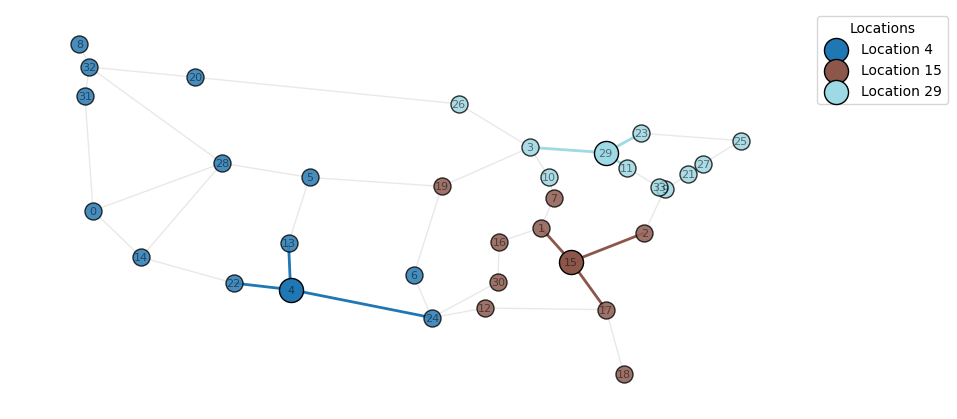

In [ ]:
# PLOT for Chapter four 
# Chapter 5 - Model for comparison with EBCP Framework - page 4
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def plot_graph_with_location_assignments(G, geo_loc_data, location_to_switch_assignment):
    """
    Visualize the graph with geographical positions, highlighting controllers (locations)
    and their assigned switches in distinct colors.
    """
    # Extract geographical positions
    positions = {node: (data['long'], data['lat']) for node, data in geo_loc_data.items()}

    # Initialize a figure
    plt.figure(figsize=(8, 4))

    # Create a colormap with distinct colors for each location (controller)
    colormap = cm.get_cmap('tab20', len(location_to_switch_assignment))
    color_norm = mcolors.Normalize(vmin=0, vmax=len(location_to_switch_assignment) - 1)

    # Draw the entire graph with default edge color
    nx.draw(
        G, pos=positions, with_labels=True, node_color='lightgrey', 
        node_size=100, font_size=8, edge_color='lightgray', alpha=0.5
    )

    # Highlight each controller location and its assigned switches
    for index, (location, switches) in enumerate(location_to_switch_assignment.items()):
        # Get the color for this controller location
        color = colormap(color_norm(index))

        # Draw the controller node (location)
        nx.draw_networkx_nodes(
            G, positions, nodelist=[location], node_size=300, node_color=[color],
            edgecolors='black', label=f"Location {location}"
        )

        # Draw the switches assigned to this controller
        nx.draw_networkx_nodes(
            G, positions, nodelist=switches, node_size=150, node_color=[color],
            alpha=0.8, edgecolors='black'
        )

        # Draw edges between the controller and its assigned switches
        for switch in switches:
            if G.has_edge(location, switch):
                nx.draw_networkx_edges(
                    G, positions, edgelist=[(location, switch)], edge_color=[color], width=2
                )

    # Add the legend outside the plot area to the right
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Locations")

    # Title and labels
    # plt.title("Network Graph with Location-to-Switch Assignments", fontsize=14)
    plt.xlabel("Longitude", fontsize=12)
    plt.ylabel("Latitude", fontsize=12)

    # Add grid to the plot
    plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    # Adjust the layout to make room for the legend
    plt.tight_layout()

    # Show the plot
    plt.show()

# Example usage
# Assuming G, geo_loc_data, and location_to_switch_assignment are defined
plot_graph_with_location_assignments(G, geo_loc_data, location_to_switch_assignment)


In [ ]:
ttt
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Assuming assigned_nodes_dict and selected_locations are already defined

# # Flow rate (Kpps) of each switch
# flow_rate = 2  

# # List of controllers and switches
# controllers = list(selected_locations)

# # Create a sorted list of all switches
# switches = list({switch for switches in location_to_switch_assignment.values() for switch in switches})

# # Initialize the controller-to-switch matrix
# location_to_switch_assignment_matrix = np.zeros((len(controllers), len(switches)))

# # Populate the matrix with load values (flow_rate) where there is a connection
# for j, controller in enumerate(controllers):
#     for switch in location_to_switch_assignment[controller]:
#         i = switches.index(switch)
#         location_to_switch_assignment_matrix[j, i] = flow_rate  # Assign the load

# # Print the controller-to-switch matrix
# print("Controller-to-Switch Matrix with Load:")
# print(location_to_switch_assignment_matrix)

# # Plotting the controller-to-switch matrix as a heatmap
# plt.figure(figsize=(12, 2))  # Adjust the figure size as needed

# # Use sns.heatmap to create the heatmap with a color intensity bar
# ax = sns.heatmap(location_to_switch_assignment_matrix, cmap="YlGnBu", cbar=True,
#                  linewidths=0.5, linecolor='blue', annot=True, fmt='g',
#                  xticklabels=switches, yticklabels=controllers)

# # Set axis labels with bold font
# plt.xlabel('Switch Nodes', fontsize=10, fontweight='bold')
# plt.ylabel('Controller Nodes', fontsize=10, fontweight='bold')

# # Set title with bold font
# plt.title('Optimal Controller-to-Switch Traffic Matix (Static)', fontsize=12, fontweight='bold')

# # Bold x and y tick labels
# plt.xticks(rotation=90, fontsize=8, fontweight='bold')
# plt.yticks(fontsize=8, fontweight='bold')

# plt.tight_layout()
# plt.show()


NameError: name 'ttt' is not defined

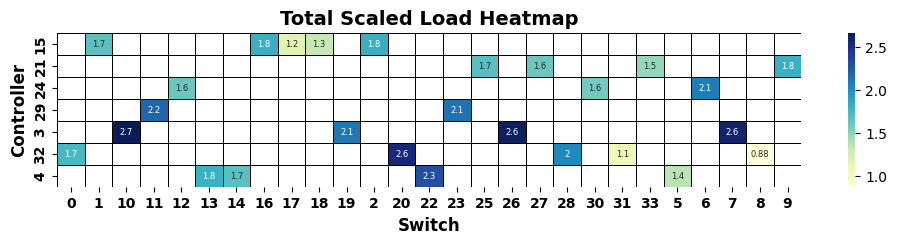

Switch Nodes and Types:
   Switch Type
0      26    e
1      19    m
2       7    e
3      10    e
4      31    e
5       0    m
6      20    e
7       8    m
8      28    e
9      30    m
10     12    e
11      6    e
12      5    e
13     14    e
14     13    m
15     22    e
16      9    e
17     25    e
18     27    m
19     33    e
20     16    m
21      2    e
22     17    e
23      1    e
24     18    m
25     11    e
26     23    e

Total Scaled Load per Controller:
  Controller  Total Scaled Load
0         15           7.803754
1         21           6.589413
2         24           5.279084
3         29           4.310838
4          3           9.990621
5         32           8.278118
6          4           7.145615

Total Scaled Load Sum for All Controllers: 49.3974429942607


In [ ]:
# 22
# Synethetic Traffic Generation for highest Peak Period 2 
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt
import random

# Set the seed for reproducibility
np.random.seed(42)
random.seed(42)

# Define flow ranges
mice_flow_range = (1, 1.8)
elephant_flow_range = (1.8, 2.6)

# Define the distribution weights
mice_weight = 0.4
elephant_weight = 0.6

# Step 2: Calculate centrality metrics
# Calculate betweenness centrality
betweenness_centrality = nx.betweenness_centrality(G, weight='latency')
# Calculate closeness centrality
closeness_centrality = nx.closeness_centrality(G, distance='latency')

# Normalize centrality metrics
max_betweenness = max(betweenness_centrality.values())
max_closeness = max(closeness_centrality.values())
normalized_betweenness = {node: value / max_betweenness for node, value in betweenness_centrality.items()}
normalized_closeness = {node: value / max_closeness for node, value in closeness_centrality.items()}

# Create a combined centrality value by summing normalized betweenness and closeness
combined_centrality = {node: normalized_betweenness.get(node, 0) + normalized_closeness.get(node, 0)
                       for node in G.nodes()}

# Step 3: Prepare data for heatmap with flow classification
heatmap_data = []
flow_type_data = []

# Create a list to store data for each controller and its assigned switches
for controller, switches in assigned_nodes.items():
    # Shuffle switches to ensure even distribution of flow types
    random.shuffle(switches)
    
    # Calculate number of mice and elephant flows
    num_switches = len(switches)
    num_mice_flows = int(num_switches * mice_weight)
    num_elephant_flows = num_switches - num_mice_flows
    
    # Assign traffic loads
    mice_flows = np.random.uniform(mice_flow_range[0], mice_flow_range[1], num_mice_flows)
    elephant_flows = np.random.uniform(elephant_flow_range[0], elephant_flow_range[1], num_elephant_flows)
    
    traffic_loads = np.concatenate([mice_flows, elephant_flows])
    flow_types = ['m'] * num_mice_flows + ['e'] * num_elephant_flows
    np.random.shuffle(traffic_loads)  # Shuffle to mix flow types
    np.random.shuffle(flow_types)  # Shuffle flow types

    scaled_loads = {}  # Dictionary to store scaled loads per switch
    
    for switch, load, flow_type in zip(switches, traffic_loads, flow_types):
        # Scale traffic load by combined centrality
        scaled_load = load * combined_centrality.get(switch, 1)  # Default to 1 if centrality not found
        scaled_loads[switch] = scaled_load  # Store in dictionary

        heatmap_data.append({
            'Controller': controller,
            'Switch': switch,
            'Scaled Load': scaled_load  # Use only scaled load for heatmap
        })
        flow_type_data.append({
            'Switch': switch,
            'Type': flow_type  # Flow type ('e' or 'm')
        })

# Convert to DataFrame for heatmap
df_heatmap = pd.DataFrame(heatmap_data)

# Convert to DataFrame for switch types
df_flow_types = pd.DataFrame(flow_type_data)

# Step 4: Create the heatmap showing scaled load
# Use pivot_table to restructure the DataFrame for heatmap visualization
heatmap_df = df_heatmap.pivot_table(index='Controller', columns='Switch', values='Scaled Load', aggfunc='mean')

# Plot the heatmap
plt.figure(figsize=(12, 2))
sns.heatmap(heatmap_df, annot=True, cmap='YlGnBu', linewidths=0.5, linecolor='black', annot_kws={"size": 6})
plt.title("Total Scaled Load Heatmap", fontsize=14, fontweight='bold')
plt.xlabel("Switch", fontsize=12, fontweight='bold')
plt.ylabel("Controller", fontsize=12, fontweight='bold')

# Embolden x and y axis tick labels
plt.xticks(fontsize=10, fontweight='bold')
plt.yticks(fontsize=10, fontweight='bold')
plt.show()

# Step 5: Display the table of switch nodes and their types
print("Switch Nodes and Types:")
print(df_flow_types)

# Step 6: Prepare the table for total scaled load per controller
controller_total_scaled_load = df_heatmap.groupby('Controller')['Scaled Load'].sum().reset_index()
controller_total_scaled_load.columns = ['Controller', 'Total Scaled Load']

# Step 7: Display the total scaled load for each controller
print("\nTotal Scaled Load per Controller:")
print(controller_total_scaled_load)

# Calculate the sum of Total Scaled Load for all controllers
total_scaled_load_sum = controller_total_scaled_load['Total Scaled Load'].sum()

# Print the total scaled load sum
print(f"\nTotal Scaled Load Sum for All Controllers: {total_scaled_load_sum}")

In [44]:
# import numpy as np
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# import random
# from gurobipy import Model, GRB, quicksum

# # Set the seed for reproducibility
# np.random.seed(42)
# random.seed(42)

# # Assuming `geo_loc_data`, `T_ij`, `G`, and other related data are already defined and calculated elsewhere.

# # Inputs
# C = [1200, 2500, 6500, 12000]  # Prices of controller types
# mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types

# # Define flow ranges
# mice_flow_range = (1, 1.8)
# elephant_flow_range = (1.8, 2.6)

# # Define the distribution weights
# mice_weight = 0.4
# elephant_weight = 0.6

# # Step 2: Calculate centrality metrics
# # Assuming graph G is defined with nodes and edges
# betweenness_centrality = nx.betweenness_centrality(G, weight='latency')
# closeness_centrality = nx.closeness_centrality(G, distance='latency')

# # Normalize centrality metrics
# max_betweenness = max(betweenness_centrality.values())
# max_closeness = max(closeness_centrality.values())
# normalized_betweenness = {node: value / max_betweenness for node, value in betweenness_centrality.items()}
# normalized_closeness = {node: value / max_closeness for node, value in closeness_centrality.items()}

# # Combined centrality value
# combined_centrality = {node: normalized_betweenness.get(node, 0) + normalized_closeness.get(node, 0)
#                        for node in G.nodes()}

# # Step 3: Prepare data for heatmap with flow classification
# heatmap_data = []
# flow_type_data = []

# # Assuming `assigned_nodes` is defined somewhere
# for controller, switches in assigned_nodes.items():
#     # Shuffle switches to ensure even distribution of flow types
#     random.shuffle(switches)
    
#     # Calculate number of mice and elephant flows
#     num_switches = len(switches)
#     num_mice_flows = int(num_switches * mice_weight)
#     num_elephant_flows = num_switches - num_mice_flows
    
#     # Assign traffic loads
#     mice_flows = np.random.uniform(mice_flow_range[0], mice_flow_range[1], num_mice_flows)
#     elephant_flows = np.random.uniform(elephant_flow_range[0], elephant_flow_range[1], num_elephant_flows)
    
#     traffic_loads = np.concatenate([mice_flows, elephant_flows])
#     flow_types = ['m'] * num_mice_flows + ['e'] * num_elephant_flows
#     np.random.shuffle(traffic_loads)  # Shuffle to mix flow types
#     np.random.shuffle(flow_types)  # Shuffle flow types

#     scaled_loads = {}  # Dictionary to store scaled loads per switch
    
#     for switch, load, flow_type in zip(switches, traffic_loads, flow_types):
#         # Scale traffic load by combined centrality
#         scaled_load = load * combined_centrality.get(switch, 1)  # Default to 1 if centrality not found
#         scaled_loads[switch] = scaled_load  # Store in dictionary

#         heatmap_data.append({
#             'Controller': controller,
#             'Switch': switch,
#             'Scaled Load': scaled_load  # Use only scaled load for heatmap
#         })
#         flow_type_data.append({
#             'Switch': switch,
#             'Type': flow_type  # Flow type ('e' or 'm')
#         })

# # Convert to DataFrame for heatmap
# df_heatmap = pd.DataFrame(heatmap_data)

# # Convert to DataFrame for switch types
# df_flow_types = pd.DataFrame(flow_type_data)

# # Step 4: Create the heatmap showing scaled load
# heatmap_df = df_heatmap.pivot_table(index='Controller', columns='Switch', values='Scaled Load', aggfunc='mean')

# # Plot the heatmap
# plt.figure(figsize=(12, 2))
# sns.heatmap(heatmap_df, annot=True, cmap='YlGnBu', linewidths=0.5, linecolor='black', annot_kws={"size": 6})
# plt.title("Total Scaled Load Heatmap", fontsize=14, fontweight='bold')
# plt.xlabel("Switch", fontsize=12, fontweight='bold')
# plt.ylabel("Controller", fontsize=12, fontweight='bold')
# plt.xticks(fontsize=10, fontweight='bold')
# plt.yticks(fontsize=10, fontweight='bold')
# plt.show()

# # Step 5: Display the table of switch nodes and their types
# print("Switch Nodes and Types:")
# print(df_flow_types)

# # Display the table of Switch Nodes and their Scaled Loads
# print("Switch Nodes and Scaled Loads:")
# switch_loads_df = df_heatmap[['Switch', 'Scaled Load']]
# print(switch_loads_df)

# # Step 6: Prepare the table for total scaled load per controller
# controller_total_scaled_load = df_heatmap.groupby('Controller')['Scaled Load'].sum().reset_index()
# controller_total_scaled_load.columns = ['Controller', 'Total Scaled Load']

# # Step 7: Display the total scaled load for each controller
# print("\nTotal Scaled Load per Controller:")
# print(controller_total_scaled_load)

# # Calculate the sum of Total Scaled Load for all controllers
# total_scaled_load_sum = controller_total_scaled_load['Total Scaled Load'].sum()

# # Print the total scaled load sum
# print(f"\nTotal Scaled Load Sum for All Controllers: {total_scaled_load_sum}")

# # Define K (indices of selected candidate controllers)
# K = [node_to_idx[node] for node in controllers]  # Ensure controllers are defined
# m = len(K)  # Number of selected controller candidates
# switch_nodes = [node for node in all_nodes if node not in controllers]
# switch_indices = [node_to_idx[node] for node in switch_nodes]  # Indices of switch nodes
# P = len(C)  # Number of controller types

# # Create the model
# model = Model("Controller_Assignment")

# # Decision variables
# Y = model.addVars(P, m, vtype=GRB.BINARY, name="Y")  # Controller type placement
# D = model.addVars(len(switch_nodes), m, vtype=GRB.BINARY, name="D")  # Switch-to-controller assignment

# # Objective function terms
# cost_term = quicksum(C[k] * Y[k, j] for k in range(P) for j in range(m))
# latency_term = quicksum(T_ij[switch_indices[i], K[j]] * D[i, j] for i in range(len(switch_nodes)) for j in range(m))
# controller_to_controller_latency_term = quicksum(
#     T_ij[K[j1], K[j2]] * Y[k1, j1] * Y[k2, j2] 
#     for k1 in range(P) for j1 in range(m) 
#     for k2 in range(P) for j2 in range(m) if j1 < j2
# )

# # Set the objective function
# model.setObjective(
#     (alpha / C_max) * cost_term + 
#     (beta / max(T_ij.flatten())) * latency_term + 
#     (gamma / max(T_ij.flatten())) * controller_to_controller_latency_term, 
#     GRB.MINIMIZE
# )

# # Constraints
# model.addConstrs(quicksum(Y[k, j] for k in range(P)) == 1 for j in range(m))  # Each location gets exactly one controller
# model.addConstrs(quicksum(D[i, j] for j in range(m)) == 1 for i in range(len(switch_nodes)))  # Each switch is assigned to one controller

# # Optimize the model
# model.optimize()

# # Check if the model found an optimal solution
# if model.status == GRB.OPTIMAL:
#     print("\nOptimal Solution Found!")
    
#     # Print the assignments of controllers and switches
#     for j in range(m):
#         print(f"Location {j}:")
#         for k in range(P):
#             if Y[k, j].x > 0.5:  # Controller type assigned
#                 print(f"  Controller Type {k} selected")
        
#         for i in range(len(switch_nodes)):
#             if D[i, j].x > 0.5:  # Switch assigned to this controller
#                 print(f"  Switch {switch_nodes[i]} assigned")

# else:
#     print("\nNo optimal solution found.")


In [ ]:
assigned_nodes

{'3': ['26', '19', '7', '10'],
 '32': ['31', '0', '20', '8', '28'],
 '24': ['30', '12', '6'],
 '4': ['5', '14', '13', '22'],
 '21': ['9', '25', '27', '33'],
 '15': ['16', '2', '17', '1', '18'],
 '29': ['11', '23']}

In [46]:

# # Synethetic Traffic Generation for highest Peak Period 2 
# import numpy as np
# import pandas as pd
# import seaborn as sns
# import networkx as nx
# import matplotlib.pyplot as plt
# import random

# # Set the seed for reproducibility
# np.random.seed(42)
# random.seed(42)

# # # Define flow ranges
# # mice_flow_range = (1, 1.8)
# # elephant_flow_range = (1.8, 2.6)

# # Define flow ranges
# mice_flow_range = (2, 2.8)
# elephant_flow_range = (2.8, 3.6)

# # Define the distribution weights
# mice_weight = 0.4
# elephant_weight = 0.6

# # Step 2: Calculate centrality metrics
# # Calculate betweenness centrality
# betweenness_centrality = nx.betweenness_centrality(G, weight='latency')
# # Calculate closeness centrality
# closeness_centrality = nx.closeness_centrality(G, distance='latency')

# # Normalize centrality metrics
# max_betweenness = max(betweenness_centrality.values())
# max_closeness = max(closeness_centrality.values())
# normalized_betweenness = {node: value / max_betweenness for node, value in betweenness_centrality.items()}
# normalized_closeness = {node: value / max_closeness for node, value in closeness_centrality.items()}

# # Create a combined centrality value by summing normalized betweenness and closeness
# combined_centrality = {node: normalized_betweenness.get(node, 0) + normalized_closeness.get(node, 0)
#                        for node in G.nodes()}

# # Step 3: Prepare data for heatmap with flow classification
# heatmap_data = []
# flow_type_data = []

# # Create a list to store data for each controller and its assigned switches
# for controller, switches in assigned_nodes.items():
#     # Shuffle switches to ensure even distribution of flow types
#     random.shuffle(switches)
    
#     # Calculate number of mice and elephant flows
#     num_switches = len(switches)
#     num_mice_flows = int(num_switches * mice_weight)
#     num_elephant_flows = num_switches - num_mice_flows
    
#     # Assign traffic loads
#     mice_flows = np.random.uniform(mice_flow_range[0], mice_flow_range[1], num_mice_flows)
#     elephant_flows = np.random.uniform(elephant_flow_range[0], elephant_flow_range[1], num_elephant_flows)
    
#     traffic_loads = np.concatenate([mice_flows, elephant_flows])
#     flow_types = ['m'] * num_mice_flows + ['e'] * num_elephant_flows
#     np.random.shuffle(traffic_loads)  # Shuffle to mix flow types
#     np.random.shuffle(flow_types)  # Shuffle flow types

#     scaled_loads = {}  # Dictionary to store scaled loads per switch
    
#     for switch, load, flow_type in zip(switches, traffic_loads, flow_types):
#         # Scale traffic load by combined centrality
#         scaled_load = load * combined_centrality.get(switch, 1)  # Default to 1 if centrality not found
#         scaled_loads[switch] = scaled_load  # Store in dictionary

#         heatmap_data.append({
#             'Controller': controller,
#             'Switch': switch,
#             'Scaled Load': scaled_load  # Use only scaled load for heatmap
#         })
#         flow_type_data.append({
#             'Switch': switch,
#             'Type': flow_type  # Flow type ('e' or 'm')
#         })

# # Convert to DataFrame for heatmap
# df_heatmap = pd.DataFrame(heatmap_data)

# # Convert to DataFrame for switch types
# df_flow_types = pd.DataFrame(flow_type_data)

# # Step 4: Create the heatmap showing scaled load
# # Use pivot_table to restructure the DataFrame for heatmap visualization
# heatmap_df = df_heatmap.pivot_table(index='Controller', columns='Switch', values='Scaled Load', aggfunc='mean')

# # Plot the heatmap
# plt.figure(figsize=(12, 2))
# sns.heatmap(heatmap_df, annot=True, cmap='YlGnBu', linewidths=0.5, linecolor='black', annot_kws={"size": 6})
# plt.title("Dynamic Switch-to-Controller Traffic Matrix", fontsize=14, fontweight='bold')
# plt.xlabel("Switch", fontsize=12, fontweight='bold')
# plt.ylabel("Controller", fontsize=12, fontweight='bold')

# # Embolden x and y axis tick labels
# plt.xticks(fontsize=10, fontweight='bold')
# plt.yticks(fontsize=10, fontweight='bold')
# plt.show()

# # Step 5: Display the table of switch nodes and their types
# print("Switch Nodes and Types:")
# print(df_flow_types)

# # Display the table of Switch Nodes and their Scaled Loads
# print("Switch Nodes and Scaled Loads:")
# switch_loads_df = df_heatmap[['Switch', 'Scaled Load']]
# print(switch_loads_df)

# # Step 6: Prepare the table for total scaled load per controller
# controller_total_scaled_load = df_heatmap.groupby('Controller')['Scaled Load'].sum().reset_index()
# controller_total_scaled_load.columns = ['Controller', 'Total Scaled Load']

# # Step 7: Display the total scaled load for each controller
# print("\nTotal Scaled Load per Controller:")
# print(controller_total_scaled_load)

# # Calculate the sum of Total Scaled Load for all controllers
# total_scaled_load_sum = controller_total_scaled_load['Total Scaled Load'].sum()

# # Print the total scaled load sum
# print(f"\nTotal Scaled Load Sum for All Controllers: {total_scaled_load_sum}")

In [ ]:
controllers

['32', '24', '4', '15', '21', '3', '29']

In [ ]:
# 23
controllers = list(assigned_nodes.keys())
print("Controllers:")
print(controllers)

switches = set()
for controller, assigned_switches in assigned_nodes.items():
    switches.update(assigned_switches)

print("Switches:")
print((switches))  # Sorted for easier readability

Controllers:
['3', '32', '24', '4', '21', '15', '29']
Switches:
{'19', '28', '31', '33', '18', '20', '12', '16', '7', '17', '2', '26', '9', '5', '6', '1', '11', '23', '10', '13', '22', '25', '30', '27', '14', '0', '8'}


In [ ]:
assigned_nodes

{'3': ['26', '19', '7', '10'],
 '32': ['31', '0', '20', '8', '28'],
 '24': ['30', '12', '6'],
 '4': ['5', '14', '13', '22'],
 '21': ['9', '25', '27', '33'],
 '15': ['16', '2', '17', '1', '18'],
 '29': ['11', '23']}

In [ ]:
# Display the table of Switch Nodes and their Scaled Loads
print("Switch Nodes and Scaled Loads:")
switch_loads_df = df_heatmap[['Switch', 'Scaled Load']]
print(switch_loads_df)

Switch Nodes and Scaled Loads:
   Switch  Scaled Load
0      26     2.627862
1      19     2.105399
2       7     2.591318
3      10     2.666041
4      31     1.082075
5       0     1.744985
6      20     2.552587
7       8     0.875444
8      28     2.023026
9      30     1.582637
10     12     1.623747
11      6     2.072700
12      5     1.364653
13     14     1.682153
14     13     1.800125
15     22     2.298685
16      9     1.812586
17     25     1.685459
18     27     1.611222
19     33     1.480146
20     16     1.818805
21      2     1.812967
22     17     1.182415
23      1     1.666135
24     18     1.323431
25     11     2.182952
26     23     2.127886


In [51]:
# # 24
# #HOMOOGENEOUS CAPACIATED CONTROLLER PLACEMENT UNDER DYNAMIC TRAFFIC CONDITIONS - a single timestamp 

# from gurobipy import Model, GRB, quicksum
# import numpy as np

# # Calculate latency matrix T_ij
# all_nodes = list(geo_loc_data.keys())
# n = len(all_nodes)
# T_ij = np.zeros((n, n))

# for i in range(n):
#     for j in range(i + 1, n):
#         node1, node2 = all_nodes[i], all_nodes[j]
#         distance = haversine(node1, node2, geo_loc_data)
#         latency = (distance * 1000) / (2 * 1e8)  # Latency in milliseconds

#         T_ij[i][j] = latency
#         T_ij[j][i] = latency  # Symmetric matrix

# # Map nodes to indices
# node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}

# # Inputs
# C = [1200, 2500, 6500, 12000]  # Prices of controller types
# mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types

# # Define `K` (indices of selected candidate controllers)
# K = [node_to_idx[node] for node in controllers]  # Ensure controllers is defined
# m = len(K)  # Number of selected controller candidates
# switch_nodes = [node for node in all_nodes if node not in controllers]
# switch_indices = [node_to_idx[node] for node in switch_nodes]  # Indices of switch nodes
# P = len(C)  # Number of controller types

# # Calculate C_max for normalization
# C_max = len(switch_nodes) * max(C)

# # Calculate T_max as the sum of all latencies in the T_ij matrix
# T_max = np.sum(T_ij)

# # Coefficients for objective function (adjust weights for cost and latency)
# alpha = 0.34  # Weight for cost minimization
# beta = 0.33 # Weight for switch-to-controller latency minimization
# gamma = 0.33  # Weight for controller-to-controller latency minimization

# # Create the model
# model = Model("Controller_Assignment")

# # Decision variables
# Y = model.addVars(P, m, vtype=GRB.BINARY, name="Y")  # Controller type placement
# D = model.addVars(len(switch_nodes), m, vtype=GRB.BINARY, name="D")  # Switch-to-controller assignment

# # Objective function terms
# cost_term = quicksum(C[k] * Y[k, j] for k in range(P) for j in range(m))
# latency_term = quicksum(T_ij[switch_indices[i], K[j]] * D[i, j] for i in range(len(switch_nodes)) for j in range(m))
# controller_to_controller_latency_term = quicksum(
#     T_ij[K[j1], K[j2]] * Y[k1, j1] * Y[k2, j2] 
#     for k1 in range(P) for j1 in range(m) 
#     for k2 in range(P) for j2 in range(m) if j1 < j2
# )

# # Set the objective function
# model.setObjective(
#     (alpha / C_max) * cost_term +
#     (beta / T_max) * latency_term +
#     (gamma / T_max) * controller_to_controller_latency_term,
#     GRB.MINIMIZE
# )

# # Constraints
# # 1. Each selected location can host at most one type of controller
# for j in range(m):
#     model.addConstr(quicksum(Y[k, j] for k in range(P)) <= 1, name=f"Location_{j}_One_Controller")

# # 2. Each switch must be assigned to exactly one controller
# for i in range(len(switch_nodes)):
#     model.addConstr(quicksum(D[i, j] for j in range(m)) == 1, name=f"Switch_{i}_Assigned_To_One_Controller")

# # 3. Switches can only be assigned to active controllers
# for i in range(len(switch_nodes)):
#     for j in range(m):
#         model.addConstr(D[i, j] <= quicksum(Y[k, j] for k in range(P)), name=f"Switch_{i}_To_Active_Controller_{j}")

# # Adjust the load calculations based on scaled_loads
# for j in range(m):  # Iterate through all potential controllers or locations
#     # Constraint: Scaled load assigned to a controller cannot exceed its capacity
#     model.addConstr(
#         quicksum(
#             switch_loads_df.loc[switch_loads_df['Switch'] == switch, 'Scaled Load'].values[0] * D[i, j]
#             for i, switch in enumerate(switch_nodes)
#         ) 
#         <= quicksum(mu[k] * Y[k, j] for k in range(P)),
#         name=f"Scaled_Load_To_Capacity_Controller_{j}"
#     )


# # # Add min_capacity and max_capacity constraints
# # min_capacity = 0.60  # Minimum load capacity ratio
# max_capacity = 0.30  # Maximum load capacity ratio

# # Auxiliary binary variable to indicate whether a controller is active
# is_active = model.addVars(m, vtype=GRB.BINARY, name="is_active")

# for j in range(m):  # Iterate through all potential controllers or controller locations
    
#     load = quicksum(
#     switch_loads_df.loc[switch_loads_df['Switch'] == switch, 'Scaled Load'].values[0] * D[i, j]
#     for i, switch in enumerate(switch_nodes)
#     )
#     # Calculate the capacity available for controller `j`
#     capacity = quicksum(mu[k] * Y[k, j] for k in range(P))

#     # Enforce constraints only if `capacity > 0` to avoid division errors
#    # Link `is_active[j]` to the activation of the controller
#     model.addConstr(capacity <= is_active[j] * sum(mu), name=f"Capacity_Active_Link_{j}")
    
#     # # Minimum capacity ratio constraint: load >= min_capacity * capacity
#     # model.addConstr(load >= min_capacity * capacity - (1 - is_active[j]) * sum(mu), name=f"Min_Capacity_{j}")
    
#     # Maximum capacity ratio constraint: load <= max_capacity * capacity
#     model.addConstr(load <= max_capacity * capacity + (1 - is_active[j]) * sum(mu), name=f"Max_Capacity_{j}")

# # Solve the model
# model.optimize()

# if model.status == GRB.OPTIMAL:
#     print(f"Optimal Objective Value: {model.objVal}")

#     # Determine optimal and unselected locations
#     selected_locations = [all_nodes[K[j]] for j in range(m) if any(Y[k, j].x > 0.5 for k in range(P))]
#     unselected_locations = [all_nodes[K[j]] for j in range(m) if all(Y[k, j].x <= 0.5 for k in range(P))]

#     print(f"Selected Locations (Optimal): {selected_locations}")
#     print(f"Unselected Locations (To Be Reassigned as Switches): {unselected_locations}")

#     # Assign switches to locations
#     location_to_switch_assignment = {loc: [] for loc in selected_locations}

#     # Initial assignments
#     for i, switch in enumerate(switch_nodes):
#         assigned_location = None
#         for j in range(m):
#             if D[i, j].x > 0.5:
#                 assigned_location = all_nodes[K[j]]
#                 break
#         if assigned_location:
#             location_to_switch_assignment[assigned_location].append(switch)

#     # Reassign unselected locations as switches
#     for unselected_loc in unselected_locations:
#         node_idx = node_to_idx[unselected_loc]
#         closest_location = min(
#             selected_locations,
#             key=lambda loc: T_ij[node_idx, node_to_idx[loc]]
#         )
#         location_to_switch_assignment[closest_location].append(unselected_loc)

#     # Print updated location-to-switch assignments
#     print("\nUpdated Location-to-Switch Assignments After Reassignment:")
#     for location, switches in location_to_switch_assignment.items():
#         print(f"Location {location}: {switches}")

#     # Create a dictionary to map switch IDs to scaled load values
#     switch_to_load = dict(zip(switch_loads_df['Switch'].astype(str), switch_loads_df['Scaled Load']))

#     # List of controllers and sorted list of switches
#     controllers = list(selected_locations)
#     switches = sorted({switch for switches in location_to_switch_assignment.values() for switch in switches})

#     # Initialize the controller-to-switch matrix
#     location_to_switch_assignment_matrix = np.zeros((len(controllers), len(switches)))

#     # Populate the matrix with scaled load values
#     for j, controller in enumerate(controllers):
#         for switch in location_to_switch_assignment[controller]:
#             if switch in switch_to_load:
#                 i = switches.index(switch)
#                 location_to_switch_assignment_matrix[j, i] = switch_to_load[switch]

#     # Calculate load-to-capacity ratios and total cost
#     print("\nLoad-to-Capacity Ratios for Each Location:")
#     load_capacity_ratios = {}
#     total_cost = 0

#     for i, location in enumerate(controllers):
#         total_load = np.sum(location_to_switch_assignment_matrix[i, :])
#         selected_controller_type = None
#         selected_capacity = 0

#         for idx, capacity in enumerate(mu):
#             if total_load <= capacity:
#                 selected_controller_type = idx
#                 selected_capacity = capacity
#                 break

#         if selected_capacity > 0 and total_load > 0:
#             load_capacity_ratio = total_load / selected_capacity
#             load_capacity_ratios[location] = load_capacity_ratio
#             print(f"Location {location}: Load = {total_load:.2f}, Capacity = {selected_capacity}, "
#                   f"Load_Capacity_Ratio = {load_capacity_ratio:.2f} "
#                   f"(Controller Type {controller_type_names[selected_controller_type]})")
#         else:
#             load_capacity_ratios[location] = 0
#             print(f"Location {location}: No assigned controller or no load.")

#         if selected_controller_type is not None:
#             total_cost += C[selected_controller_type]
#         else:
#             print(f"Warning: Location {location} has no controller assigned.")

#     print(f"\nTotal cost of controllers: {total_cost:.2f}")

#     # Calculate load imbalance
#     if load_capacity_ratios:
#         max_load_ratio = max(load_capacity_ratios.values())
#         min_load_ratio = min(load_capacity_ratios.values())
#         load_imbalance = ((max_load_ratio - min_load_ratio) / max_load_ratio) * 100 if max_load_ratio != 0 else 0.0

#         print("\n--------------------------------------")
#         print(f"Load Imbalance: {load_imbalance:.2f}%")
#         print(f"Overall Max Load Capacity Ratio = {max_load_ratio:.2f}")
#         print(f"Overall Min Load Capacity Ratio = {min_load_ratio:.2f}")
#     else:
#         print("No load capacity ratios available. Skipping load imbalance calculation.")

#     # Calculate switch-to-controller latency
#     try:
#         total_switch_to_controller_latency = 0.0
#         for location in selected_locations:
#             assigned_switches = location_to_switch_assignment.get(location, [])
#             for switch in assigned_switches:
#                 if switch in node_to_idx and location in node_to_idx:
#                     switch_idx = node_to_idx[switch]
#                     controller_idx = node_to_idx[location]
#                     latency = T_ij[switch_idx, controller_idx]
#                     total_switch_to_controller_latency += latency
#                 else:
#                     print(f"Warning: Node {switch} or location {location} not found in node_to_idx.")

#         print(f"Total Switch-to-Controller Latency: {total_switch_to_controller_latency:.5f}")
#     except (KeyError, IndexError) as e:
#         print(f"Error during switch-to-controller latency calculation: {e}")

#     # Calculate controller-to-controller latency
#     try:
#         total_controller_to_controller_latency = 0.0
#         for i, location1 in enumerate(selected_locations):
#             for j, location2 in enumerate(selected_locations):
#                 if i < j:
#                     if location1 in node_to_idx and location2 in node_to_idx:
#                         controller1_idx = node_to_idx[location1]
#                         controller2_idx = node_to_idx[location2]
#                         latency = T_ij[controller1_idx, controller2_idx]
#                         total_controller_to_controller_latency += latency
#                     else:
#                         print(f"Warning: Locations {location1} or {location2} not found in node_to_idx.")

#         print(f"Total Controller-to-Controller Latency: {total_controller_to_controller_latency:.5f}")
#     except (KeyError, IndexError) as e:
#         print(f"Error during controller-to-controller latency calculation: {e}")


In [52]:
# 25 

# #HETEROGENEOUS CAPACIATED CONTROLLER PLACEMENT UNDER DYNAMIC TRAFFIC CONDITIONS - a single timestamp 

# from gurobipy import Model, GRB, quicksum
# import numpy as np

# # Calculate latency matrix T_ij
# all_nodes = list(geo_loc_data.keys())
# n = len(all_nodes)
# T_ij = np.zeros((n, n))

# for i in range(n):
#     for j in range(i + 1, n):
#         node1, node2 = all_nodes[i], all_nodes[j]
#         distance = haversine(node1, node2, geo_loc_data)
#         latency = (distance * 1000) / (2 * 1e8)  # Latency in milliseconds

#         T_ij[i][j] = latency
#         T_ij[j][i] = latency  # Symmetric matrix

# # Map nodes to indices
# node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}

# # Inputs
# C = [1200, 2500, 6500, 12000]  # Prices of controller types
# mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types

# # Define `K` (indices of selected candidate controllers)
# K = [node_to_idx[node] for node in controllers]  # Ensure controllers is defined
# m = len(K)  # Number of selected controller candidates
# switch_nodes = [node for node in all_nodes if node not in controllers]
# switch_indices = [node_to_idx[node] for node in switch_nodes]  # Indices of switch nodes
# P = len(C)  # Number of controller types

# # Calculate C_max for normalization
# C_max = len(switch_nodes) * max(C)

# # Calculate T_max as the sum of all latencies in the T_ij matrix
# T_max = np.sum(T_ij)

# # Coefficients for objective function (adjust weights for cost and latency)
# alpha = 0.34  # Weight for cost minimization
# beta = 0.33 # Weight for switch-to-controller latency minimization
# gamma = 0.33  # Weight for controller-to-controller latency minimization

# # Create the model
# model = Model("Controller_Assignment")

# # Decision variables
# Y = model.addVars(P, m, vtype=GRB.BINARY, name="Y")  # Controller type placement
# D = model.addVars(len(switch_nodes), m, vtype=GRB.BINARY, name="D")  # Switch-to-controller assignment

# # Objective function terms
# cost_term = quicksum(C[k] * Y[k, j] for k in range(P) for j in range(m))
# latency_term = quicksum(T_ij[switch_indices[i], K[j]] * D[i, j] for i in range(len(switch_nodes)) for j in range(m))
# controller_to_controller_latency_term = quicksum(
#     T_ij[K[j1], K[j2]] * Y[k1, j1] * Y[k2, j2] 
#     for k1 in range(P) for j1 in range(m) 
#     for k2 in range(P) for j2 in range(m) if j1 < j2
# )

# # Set the objective function
# model.setObjective(
#     (alpha / C_max) * cost_term +
#     (beta / T_max) * latency_term +
#     (gamma / T_max) * controller_to_controller_latency_term,
#     GRB.MINIMIZE
# )

# # Constraints
# # 1. Each selected location can host at most one type of controller
# for j in range(m):
#     model.addConstr(quicksum(Y[k, j] for k in range(P)) <= 1, name=f"Location_{j}_One_Controller")

# # 2. Each switch must be assigned to exactly one controller
# for i in range(len(switch_nodes)):
#     model.addConstr(quicksum(D[i, j] for j in range(m)) == 1, name=f"Switch_{i}_Assigned_To_One_Controller")

# # 3. Switches can only be assigned to active controllers
# for i in range(len(switch_nodes)):
#     for j in range(m):
#         model.addConstr(D[i, j] <= quicksum(Y[k, j] for k in range(P)), name=f"Switch_{i}_To_Active_Controller_{j}")

# # Adjust the load calculations based on scaled_loads
# for j in range(m):  # Iterate through all potential controllers or locations
#     # Constraint: Scaled load assigned to a controller cannot exceed its capacity
#     model.addConstr(
#         quicksum(
#             switch_loads_df.loc[switch_loads_df['Switch'] == switch, 'Scaled Load'].values[0] * D[i, j]
#             for i, switch in enumerate(switch_nodes)
#         ) 
#         <= quicksum(mu[k] * Y[k, j] for k in range(P)),
#         name=f"Scaled_Load_To_Capacity_Controller_{j}"
#     )


# # Add min_capacity and max_capacity constraints
# min_capacity = 0.60  # Minimum load capacity ratio
# max_capacity = 0.90  # Maximum load capacity ratio

# # Auxiliary binary variable to indicate whether a controller is active
# is_active = model.addVars(m, vtype=GRB.BINARY, name="is_active")

# for j in range(m):  # Iterate through all potential controllers or controller locations
    
#     load = quicksum(
#     switch_loads_df.loc[switch_loads_df['Switch'] == switch, 'Scaled Load'].values[0] * D[i, j]
#     for i, switch in enumerate(switch_nodes)
#     )
#     # Calculate the capacity available for controller `j`
#     capacity = quicksum(mu[k] * Y[k, j] for k in range(P))

#     # Enforce constraints only if `capacity > 0` to avoid division errors
#    # Link `is_active[j]` to the activation of the controller
#     model.addConstr(capacity <= is_active[j] * sum(mu), name=f"Capacity_Active_Link_{j}")
    
#     # Minimum capacity ratio constraint: load >= min_capacity * capacity
#     model.addConstr(load >= min_capacity * capacity - (1 - is_active[j]) * sum(mu), name=f"Min_Capacity_{j}")
    
#     # Maximum capacity ratio constraint: load <= max_capacity * capacity
#     model.addConstr(load <= max_capacity * capacity + (1 - is_active[j]) * sum(mu), name=f"Max_Capacity_{j}")

# # Solve the model
# model.optimize()

# if model.status == GRB.OPTIMAL:
#     print(f"Optimal Objective Value: {model.objVal}")

#     # Determine optimal and unselected locations
#     selected_locations = [all_nodes[K[j]] for j in range(m) if any(Y[k, j].x > 0.5 for k in range(P))]
#     unselected_locations = [all_nodes[K[j]] for j in range(m) if all(Y[k, j].x <= 0.5 for k in range(P))]

#     print(f"Selected Locations (Optimal): {selected_locations}")
#     print(f"Unselected Locations (To Be Reassigned as Switches): {unselected_locations}")

#     # Assign switches to locations
#     location_to_switch_assignment = {loc: [] for loc in selected_locations}

#     # Initial assignments
#     for i, switch in enumerate(switch_nodes):
#         assigned_location = None
#         for j in range(m):
#             if D[i, j].x > 0.5:
#                 assigned_location = all_nodes[K[j]]
#                 break
#         if assigned_location:
#             location_to_switch_assignment[assigned_location].append(switch)

#     # Reassign unselected locations as switches
#     for unselected_loc in unselected_locations:
#         node_idx = node_to_idx[unselected_loc]
#         closest_location = min(
#             selected_locations,
#             key=lambda loc: T_ij[node_idx, node_to_idx[loc]]
#         )
#         location_to_switch_assignment[closest_location].append(unselected_loc)

#     # Print updated location-to-switch assignments
#     print("\nUpdated Location-to-Switch Assignments After Reassignment:")
#     for location, switches in location_to_switch_assignment.items():
#         print(f"Location {location}: {switches}")

#     # Create a dictionary to map switch IDs to scaled load values
#     switch_to_load = dict(zip(switch_loads_df['Switch'].astype(str), switch_loads_df['Scaled Load']))

#     # List of controllers and sorted list of switches
#     controllers = list(selected_locations)
#     switches = sorted({switch for switches in location_to_switch_assignment.values() for switch in switches})

#     # Initialize the controller-to-switch matrix
#     location_to_switch_assignment_matrix = np.zeros((len(controllers), len(switches)))

#     # Populate the matrix with scaled load values
#     for j, controller in enumerate(controllers):
#         for switch in location_to_switch_assignment[controller]:
#             if switch in switch_to_load:
#                 i = switches.index(switch)
#                 location_to_switch_assignment_matrix[j, i] = switch_to_load[switch]

#     # Calculate load-to-capacity ratios and total cost
#     print("\nLoad-to-Capacity Ratios for Each Location:")
#     load_capacity_ratios = {}
#     total_cost = 0

#     for i, location in enumerate(controllers):
#         total_load = np.sum(location_to_switch_assignment_matrix[i, :])
#         selected_controller_type = None
#         selected_capacity = 0

#         for idx, capacity in enumerate(mu):
#             if total_load <= capacity:
#                 selected_controller_type = idx
#                 selected_capacity = capacity
#                 break

#         if selected_capacity > 0 and total_load > 0:
#             load_capacity_ratio = total_load / selected_capacity
#             load_capacity_ratios[location] = load_capacity_ratio
#             print(f"Location {location}: Load = {total_load:.2f}, Capacity = {selected_capacity}, "
#                   f"Load_Capacity_Ratio = {load_capacity_ratio:.2f} "
#                   f"(Controller Type {controller_type_names[selected_controller_type]})")
#         else:
#             load_capacity_ratios[location] = 0
#             print(f"Location {location}: No assigned controller or no load.")

#         if selected_controller_type is not None:
#             total_cost += C[selected_controller_type]
#         else:
#             print(f"Warning: Location {location} has no controller assigned.")

#     print(f"\nTotal cost of controllers: {total_cost:.2f}")

#     # Calculate load imbalance
#     if load_capacity_ratios:
#         max_load_ratio = max(load_capacity_ratios.values())
#         min_load_ratio = min(load_capacity_ratios.values())
#         load_imbalance = ((max_load_ratio - min_load_ratio) / max_load_ratio) * 100 if max_load_ratio != 0 else 0.0

#         print("\n--------------------------------------")
#         print(f"Load Imbalance: {load_imbalance:.2f}%")
#         print(f"Overall Max Load Capacity Ratio = {max_load_ratio:.2f}")
#         print(f"Overall Min Load Capacity Ratio = {min_load_ratio:.2f}")
#     else:
#         print("No load capacity ratios available. Skipping load imbalance calculation.")

#     # Calculate switch-to-controller latency
#     try:
#         total_switch_to_controller_latency = 0.0
#         for location in selected_locations:
#             assigned_switches = location_to_switch_assignment.get(location, [])
#             for switch in assigned_switches:
#                 if switch in node_to_idx and location in node_to_idx:
#                     switch_idx = node_to_idx[switch]
#                     controller_idx = node_to_idx[location]
#                     latency = T_ij[switch_idx, controller_idx]
#                     total_switch_to_controller_latency += latency
#                 else:
#                     print(f"Warning: Node {switch} or location {location} not found in node_to_idx.")

#         print(f"Total Switch-to-Controller Latency: {total_switch_to_controller_latency:.5f}")
#     except (KeyError, IndexError) as e:
#         print(f"Error during switch-to-controller latency calculation: {e}")

#     # Calculate controller-to-controller latency
#     try:
#         total_controller_to_controller_latency = 0.0
#         for i, location1 in enumerate(selected_locations):
#             for j, location2 in enumerate(selected_locations):
#                 if i < j:
#                     if location1 in node_to_idx and location2 in node_to_idx:
#                         controller1_idx = node_to_idx[location1]
#                         controller2_idx = node_to_idx[location2]
#                         latency = T_ij[controller1_idx, controller2_idx]
#                         total_controller_to_controller_latency += latency
#                     else:
#                         print(f"Warning: Locations {location1} or {location2} not found in node_to_idx.")

#         print(f"Total Controller-to-Controller Latency: {total_controller_to_controller_latency:.5f}")
#     except (KeyError, IndexError) as e:
#         print(f"Error during controller-to-controller latency calculation: {e}")


In [ ]:
total_load

40

In [54]:
# #Ensure location_switch_allocations keys and values are strings
# location_switch_allocations = {
#     str(location): [str(node) for node in nodes]
#     for location, nodes in location_to_switch_assignment.items()
# }

# # Prepare the list of updated controllers
# updated_controllers = list(location_to_switch_assignment.keys())
# print("Updated Controllers:")
# print(updated_controllers)

# # Initialize a dictionary to store latency results for each controller
# latency_results = {}

# # Variables to compute aggregate latencies
# total_average_latency = 0
# max_worst_case_latency = float('-inf')

# # Variables for controller-to-controller latency calculations
# total_controller_latency = 0
# controller_pairs = 0
# max_pairwise_worst_case_latency = float('-inf')

# # Calculate latencies for each controller to assigned nodes
# for location, switches in location_to_switch_assignment.items():
#     total_latency = 0
#     worst_case_latency = float('-inf')

#     for switch in switches:
#         try:
#             # Calculate the shortest path length (latency) between the location and the node
#             latency = nx.shortest_path_length(G, source=location, target=switch, weight='weight')
            
#             # Convert latency to milliseconds
#             latency_ms = (latency * 1000) / (2 * 1e8)  # Adjust formula if necessary
            
#             # Update the cumulative and worst-case latencies
#             total_latency += latency_ms
#             worst_case_latency = max(worst_case_latency, latency_ms)
#         except nx.NetworkXNoPath:
#             print(f"No path found between location {location} and node {node}. Skipping latency calculation.")

#     # Calculate average latency for this controller
#     average_latency = total_latency / len(switches) if switches else 0
#     total_average_latency += average_latency  # Add to total average latency sum

#     # Update the maximum worst-case latency across all controllers
#     max_worst_case_latency = max(max_worst_case_latency, worst_case_latency)

#     # Store the latencies for this location
#     latency_results[location] = {
#         'average_latency': average_latency,
#         'worst_case_latency': worst_case_latency
#     }


# # Compute latencies between controllers
# for i, controller1 in enumerate(updated_controllers):
#     for j, controller2 in enumerate(updated_controllers):
#         if i < j:  # Avoid duplicate calculations for pairs
#             try:
#                 # Calculate shortest path length between two controllers
#                 pairwise_latency = nx.shortest_path_length(G, source=controller1, target=controller2, weight='weight')
#                 pairwise_latency_ms = (pairwise_latency * 1000) / (2 * 1e8)  # Adjust formula if necessary

#                 # Accumulate total controller-to-controller latency
#                 total_controller_latency += pairwise_latency_ms
#                 controller_pairs += 1

#                 # Update the maximum pairwise worst-case latency
#                 max_pairwise_worst_case_latency = max(max_pairwise_worst_case_latency, pairwise_latency_ms)
#             except nx.NetworkXNoPath:
#                 print(f"No path found between controllers {controller1} and {controller2}. Skipping latency calculation.")

# # Calculate the average controller-to-controller latency
# average_controller_latency = total_controller_latency / controller_pairs if controller_pairs > 0 else 0

# # Consolidate the results for the current percentage
# latency_results_per_percentage[percentage] = {
#     'average_controller_latency': average_controller_latency,
#     'max_pairwise_worst_case_latency': max_pairwise_worst_case_latency,
#     'total_average_latency': total_average_latency,
#     'max_worst_case_latency': max_worst_case_latency,
#     'controller_latencies': latency_results
# }

# # Display results
# print(f"\nAverage Controller-to-Controller Latency = {average_controller_latency:.15f} ms")
# print(f"Maximum Pairwise Worst-Case Latency = {max_pairwise_worst_case_latency:.15f} ms")
# print(f"\nTotal Average Node to Controller Latency = {total_average_latency:.15f} ms")
# print(f"Maximum Worst-Case Node to Controller Latency = {max_worst_case_latency:.15f} ms")


In [55]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd

# # Assuming assigned_nodes_dict and selected_locations are already defined
# # Assuming location_to_switch_assignment and switch_loads_df are provided

# # Create a dictionary to map switch IDs to scaled load values
# switch_to_load = dict(zip(switch_loads_df['Switch'].astype(str), switch_loads_df['Scaled Load']))

# # List of controllers and switches
# controllers = list(selected_locations)

# # Create a sorted list of all switches
# switches = sorted({switch for switches in location_to_switch_assignment.values() for switch in switches})

# # Initialize the controller-to-switch matrix
# location_to_switch_assignment_matrix = np.zeros((len(controllers), len(switches)))

# # Populate the matrix with scaled load values where there is a connection
# for j, controller in enumerate(controllers):
#     for switch in location_to_switch_assignment[controller]:
#         if switch in switch_to_load:
#             i = switches.index(switch)
#             location_to_switch_assignment_matrix[j, i] = switch_to_load[switch]  # Assign the scaled load

# # # Print the controller-to-switch matrix
# # print("Controller-to-Switch Matrix with Scaled Load:")
# # print(location_to_switch_assignment_matrix)

# # Custom annotation formatter
# def annotate_heatmap(matrix):
#     annotations = []
#     for row in matrix:
#         annotations.append(
#             [f"{val:.2f}" if val != 0 else "0" for val in row]
#         )
#     return annotations

# # Generate custom annotations for the heatmap
# annotations = annotate_heatmap(location_to_switch_assignment_matrix)

# # Plotting the controller-to-switch matrix as a heatmap
# plt.figure(figsize=(12, 2))  # Adjust the figure size as needed

# # Use sns.heatmap to create the heatmap with a color intensity bar
# ax = sns.heatmap(location_to_switch_assignment_matrix, cmap="YlGnBu", cbar=True,
#                  linewidths=0.5, linecolor='blue', annot=annotations, fmt='',  # Custom annotations used
#                  xticklabels=switches, yticklabels=controllers)

# # Set axis labels with bold font
# plt.xlabel('Switch Nodes', fontsize=10, fontweight='bold')
# plt.ylabel('Controller Nodes', fontsize=10, fontweight='bold')

# # Set title with bold font
# plt.title('Controller-to-Switch Traffic Matrix', fontsize=12, fontweight='bold')

# # Bold x and y tick labels
# plt.xticks(rotation=90, fontsize=8, fontweight='bold')
# plt.yticks(fontsize=8, fontweight='bold')

# plt.tight_layout()
# plt.show()


In [56]:
# # Synethetic Traffic Generation for highest Peak Period 2 
# import numpy as np
# import pandas as pd
# import seaborn as sns
# import networkx as nx
# import matplotlib.pyplot as plt
# import random

# # Set the seed for reproducibility
# np.random.seed(42)
# random.seed(42)

# # # Define flow ranges
# # mice_flow_range = (1, 1.8)
# # elephant_flow_range = (1.8, 2.6)

# # Define flow ranges
# mice_flow_range = (2, 2.8)
# elephant_flow_range = (2.8, 3.6)

# # Define the distribution weights
# mice_weight = 0.4
# elephant_weight = 0.6

# # Step 2: Calculate centrality metrics
# # Calculate betweenness centrality
# betweenness_centrality = nx.betweenness_centrality(G, weight='latency')
# # Calculate closeness centrality
# closeness_centrality = nx.closeness_centrality(G, distance='latency')

# # Normalize centrality metrics
# max_betweenness = max(betweenness_centrality.values())
# max_closeness = max(closeness_centrality.values())
# normalized_betweenness = {node: value / max_betweenness for node, value in betweenness_centrality.items()}
# normalized_closeness = {node: value / max_closeness for node, value in closeness_centrality.items()}

# # Create a combined centrality value by summing normalized betweenness and closeness
# combined_centrality = {node: normalized_betweenness.get(node, 0) + normalized_closeness.get(node, 0)
#                        for node in G.nodes()}

# # Step 3: Prepare data for heatmap with flow classification
# heatmap_data = []
# flow_type_data = []

# # Create a list to store data for each controller and its assigned switches
# for controller, switches in assigned_nodes.items():
#     # Shuffle switches to ensure even distribution of flow types
#     random.shuffle(switches)
    
#     # Calculate number of mice and elephant flows
#     num_switches = len(switches)
#     num_mice_flows = int(num_switches * mice_weight)
#     num_elephant_flows = num_switches - num_mice_flows
    
#     # Assign traffic loads
#     mice_flows = np.random.uniform(mice_flow_range[0], mice_flow_range[1], num_mice_flows)
#     elephant_flows = np.random.uniform(elephant_flow_range[0], elephant_flow_range[1], num_elephant_flows)
    
#     traffic_loads = np.concatenate([mice_flows, elephant_flows])
#     flow_types = ['m'] * num_mice_flows + ['e'] * num_elephant_flows
#     np.random.shuffle(traffic_loads)  # Shuffle to mix flow types
#     np.random.shuffle(flow_types)  # Shuffle flow types

#     scaled_loads = {}  # Dictionary to store scaled loads per switch
    
#     for switch, load, flow_type in zip(switches, traffic_loads, flow_types):
#         # Scale traffic load by combined centrality
#         scaled_load = load * combined_centrality.get(switch, 1)  # Default to 1 if centrality not found
#         scaled_loads[switch] = scaled_load  # Store in dictionary

#         heatmap_data.append({
#             'Controller': controller,
#             'Switch': switch,
#             'Scaled Load': scaled_load  # Use only scaled load for heatmap
#         })
#         flow_type_data.append({
#             'Switch': switch,
#             'Type': flow_type  # Flow type ('e' or 'm')
#         })

# # Convert to DataFrame for heatmap
# df_heatmap = pd.DataFrame(heatmap_data)

# # Convert to DataFrame for switch types
# df_flow_types = pd.DataFrame(flow_type_data)

# # Step 4: Create the heatmap showing scaled load
# # Use pivot_table to restructure the DataFrame for heatmap visualization
# heatmap_df = df_heatmap.pivot_table(index='Controller', columns='Switch', values='Scaled Load', aggfunc='mean')

# # Plot the heatmap
# plt.figure(figsize=(12, 2))
# sns.heatmap(heatmap_df, annot=True, cmap='YlGnBu', linewidths=0.5, linecolor='black', annot_kws={"size": 6})
# plt.title("Dynamic Switch-to-Controller Traffic Matrix", fontsize=14, fontweight='bold')
# plt.xlabel("Switch", fontsize=12, fontweight='bold')
# plt.ylabel("Controller", fontsize=12, fontweight='bold')

# # Embolden x and y axis tick labels
# plt.xticks(fontsize=10, fontweight='bold')
# plt.yticks(fontsize=10, fontweight='bold')
# plt.show()

# # Step 5: Display the table of switch nodes and their types
# print("Switch Nodes and Types:")
# print(df_flow_types)

# # Display the table of Switch Nodes and their Scaled Loads
# print("Switch Nodes and Scaled Loads:")
# switch_loads_df = df_heatmap[['Switch', 'Scaled Load']]
# print(switch_loads_df)

# # Step 6: Prepare the table for total scaled load per controller
# controller_total_scaled_load = df_heatmap.groupby('Controller')['Scaled Load'].sum().reset_index()
# controller_total_scaled_load.columns = ['Controller', 'Total Scaled Load']

# # Step 7: Display the total scaled load for each controller
# print("\nTotal Scaled Load per Controller:")
# print(controller_total_scaled_load)

# # Calculate the sum of Total Scaled Load for all controllers
# total_scaled_load_sum = controller_total_scaled_load['Total Scaled Load'].sum()

# # Print the total scaled load sum
# print(f"\nTotal Scaled Load Sum for All Controllers: {total_scaled_load_sum}")

In [ ]:
assigned_nodes

{'3': ['26', '19', '7', '10'],
 '32': ['31', '0', '20', '8', '28'],
 '24': ['30', '12', '6'],
 '4': ['5', '14', '13', '22'],
 '21': ['9', '25', '27', '33'],
 '15': ['16', '2', '17', '1', '18'],
 '29': ['11', '23']}


=== Processing Timestamp 1 ===


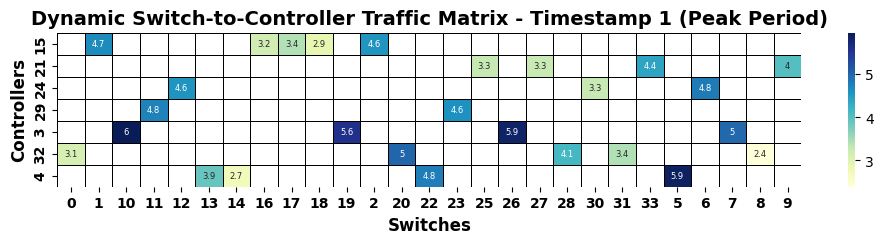

Switch Nodes and Types:
   Switch Type
0      26    e
1      19    m
2       7    e
3      10    e
4      31    e
5       0    m
6      20    e
7       8    m
8      28    e
9      30    m
10     12    e
11      6    e
12      5    e
13     14    e
14     13    m
15     22    e
16      9    e
17     25    e
18     27    m
19     33    e
20     16    m
21      2    e
22     17    e
23      1    e
24     18    m
25     11    e
26     23    e
Switch Nodes and Scaled Loads:
   Switch  Scaled Load
0       7     4.977449
1      19     5.588092
2      10     5.968718
3      26     5.855966
4       8     2.387939
5      20     5.003931
6      31     3.428432
7      28     4.144508
8       0     3.115222
9      12     4.588333
10     30     3.272799
11      6     4.818775
12     14     2.745366
13     13     3.905035
14      5     5.892733
15     22     4.784988
16     25     3.289094
17     27     3.258259
18     33     4.398795
19      9     4.036324
20      2     4.580317
21      1     4.679

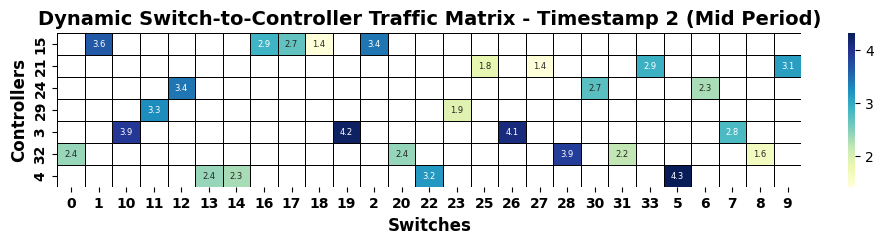

Switch Nodes and Types:
   Switch Type
0      26    e
1      19    m
2       7    e
3      10    e
4      31    e
5       0    m
6      20    e
7       8    m
8      28    e
9      30    m
10     12    e
11      6    e
12      5    e
13     14    e
14     13    m
15     22    e
16      9    e
17     25    e
18     27    m
19     33    e
20     16    m
21      2    e
22     17    e
23      1    e
24     18    m
25     11    e
26     23    e
Switch Nodes and Scaled Loads:
   Switch  Scaled Load
0       7     2.808997
1      10     3.929180
2      26     4.095399
3      19     4.244562
4       0     2.383039
5      28     3.870857
6      31     2.171803
7      20     2.394770
8       8     1.636886
9      12     3.422019
10      6     2.293892
11     30     2.731060
12      5     4.321244
13     22     3.156155
14     14     2.307935
15     13     2.385530
16     33     2.924486
17     27     1.427080
18      9     3.100031
19     25     1.840837
20     18     1.418267
21     16     2.881

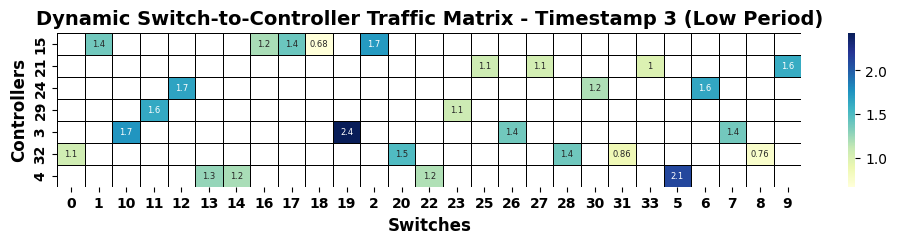

Switch Nodes and Types:
   Switch Type
0      26    e
1      19    m
2       7    e
3      10    e
4      31    e
5       0    m
6      20    e
7       8    m
8      28    e
9      30    m
10     12    e
11      6    e
12      5    e
13     14    e
14     13    m
15     22    e
16      9    e
17     25    e
18     27    m
19     33    e
20     16    m
21      2    e
22     17    e
23      1    e
24     18    m
25     11    e
26     23    e
Switch Nodes and Scaled Loads:
   Switch  Scaled Load
0      10     1.748032
1       7     1.379394
2      26     1.387690
3      19     2.429535
4       8     0.755452
5      28     1.391855
6      31     0.864276
7       0     1.063452
8      20     1.504496
9      12     1.665045
10      6     1.645919
11     30     1.190656
12     13     1.271352
13      5     2.110520
14     14     1.207649
15     22     1.182948
16     27     1.051089
17     25     1.074409
18      9     1.609269
19     33     0.995309
20     16     1.208512
21      2     1.718

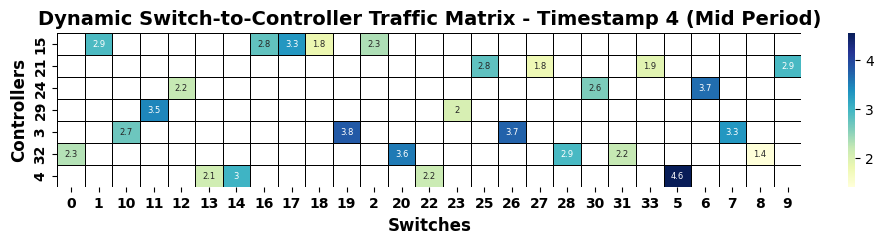

Switch Nodes and Types:
   Switch Type
0      26    e
1      19    m
2       7    e
3      10    e
4      31    e
5       0    m
6      20    e
7       8    m
8      28    e
9      30    m
10     12    e
11      6    e
12      5    e
13     14    e
14     13    m
15     22    e
16      9    e
17     25    e
18     27    m
19     33    e
20     16    m
21      2    e
22     17    e
23      1    e
24     18    m
25     11    e
26     23    e
Switch Nodes and Scaled Loads:
   Switch  Scaled Load
0      10     2.709796
1      19     3.820317
2       7     3.313473
3      26     3.738758
4       0     2.299941
5       8     1.404739
6      20     3.554238
7      31     2.207142
8      28     2.943004
9      12     2.194986
10      6     3.658441
11     30     2.612989
12      5     4.565145
13     22     2.151794
14     14     3.000995
15     13     2.100875
16      9     2.943169
17     33     1.914107
18     27     1.757194
19     25     2.797450
20      2     2.337478
21     16     2.782

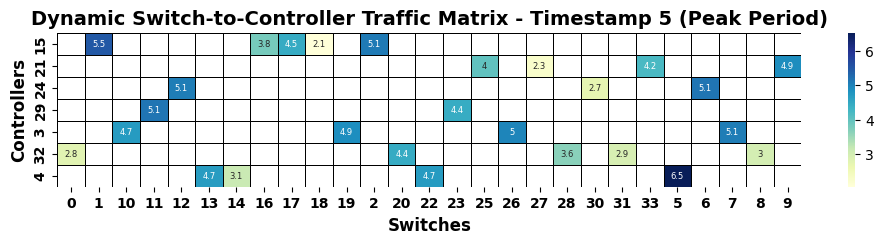

Switch Nodes and Types:
   Switch Type
0      26    e
1      19    m
2       7    e
3      10    e
4      31    e
5       0    m
6      20    e
7       8    m
8      28    e
9      30    m
10     12    e
11      6    e
12      5    e
13     14    e
14     13    m
15     22    e
16      9    e
17     25    e
18     27    m
19     33    e
20     16    m
21      2    e
22     17    e
23      1    e
24     18    m
25     11    e
26     23    e
Switch Nodes and Scaled Loads:
   Switch  Scaled Load
0      19     4.877867
1       7     5.056196
2      26     4.983489
3      10     4.700532
4      28     3.640870
5       0     2.789042
6       8     2.988087
7      31     2.934091
8      20     4.444062
9      30     2.727996
10      6     5.149970
11     12     5.060175
12      5     6.521614
13     13     4.670907
14     14     3.118828
15     22     4.697594
16      9     4.891732
17     33     4.208215
18     27     2.251779
19     25     3.996190
20     18     2.051124
21     17     4.452

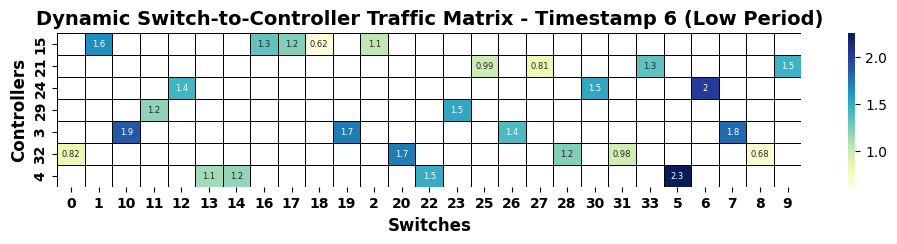

Switch Nodes and Types:
   Switch Type
0      26    e
1      19    m
2       7    e
3      10    e
4      31    e
5       0    m
6      20    e
7       8    m
8      28    e
9      30    m
10     12    e
11      6    e
12      5    e
13     14    e
14     13    m
15     22    e
16      9    e
17     25    e
18     27    m
19     33    e
20     16    m
21      2    e
22     17    e
23      1    e
24     18    m
25     11    e
26     23    e
Switch Nodes and Scaled Loads:
   Switch  Scaled Load
0      19     1.729827
1       7     1.795769
2      26     1.409936
3      10     1.875723
4      20     1.723706
5      31     0.977302
6      28     1.226941
7       0     0.824480
8       8     0.675967
9       6     2.012115
10     12     1.443552
11     30     1.531078
12     13     1.141935
13     14     1.185213
14     22     1.498097
15      5     2.260515
16     33     1.342745
17      9     1.463611
18     27     0.807856
19     25     0.989876
20     18     0.624495
21     17     1.229

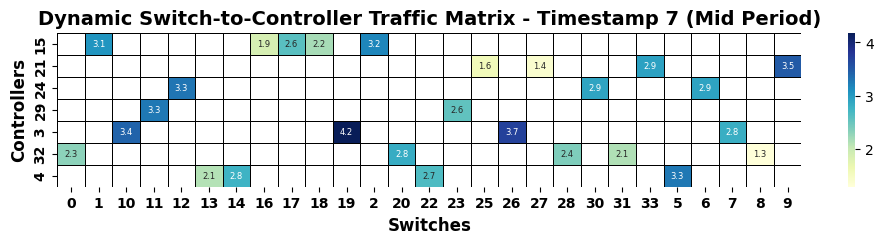

Switch Nodes and Types:
   Switch Type
0      26    e
1      19    m
2       7    e
3      10    e
4      31    e
5       0    m
6      20    e
7       8    m
8      28    e
9      30    m
10     12    e
11      6    e
12      5    e
13     14    e
14     13    m
15     22    e
16      9    e
17     25    e
18     27    m
19     33    e
20     16    m
21      2    e
22     17    e
23      1    e
24     18    m
25     11    e
26     23    e
Switch Nodes and Scaled Loads:
   Switch  Scaled Load
0       7     2.814072
1      10     3.417901
2      26     3.705002
3      19     4.181004
4      20     2.838741
5      31     2.141726
6       0     2.317337
7      28     2.391665
8       8     1.300959
9      30     2.917097
10     12     3.296886
11      6     2.931241
12     22     2.672303
13     14     2.771220
14     13     2.116846
15      5     3.274875
16     25     1.589033
17      9     3.488167
18     27     1.397014
19     33     2.948911
20     16     1.885807
21     18     2.188

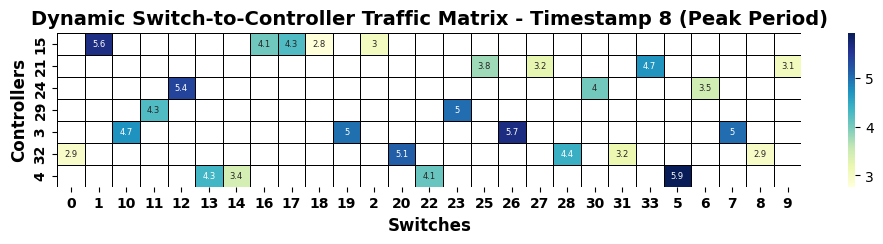

Switch Nodes and Types:
   Switch Type
0      26    e
1      19    m
2       7    e
3      10    e
4      31    e
5       0    m
6      20    e
7       8    m
8      28    e
9      30    m
10     12    e
11      6    e
12      5    e
13     14    e
14     13    m
15     22    e
16      9    e
17     25    e
18     27    m
19     33    e
20     16    m
21      2    e
22     17    e
23      1    e
24     18    m
25     11    e
26     23    e
Switch Nodes and Scaled Loads:
   Switch  Scaled Load
0      26     5.653638
1      19     4.997173
2       7     5.030593
3      10     4.729297
4      28     4.437893
5       8     2.945031
6       0     2.929950
7      20     5.137534
8      31     3.164606
9       6     3.472744
10     30     4.035241
11     12     5.387956
12      5     5.936813
13     13     4.345970
14     14     3.429855
15     22     4.107811
16     33     4.701083
17     27     3.231410
18     25     3.789683
19      9     3.050346
20      2     3.012546
21     18     2.767

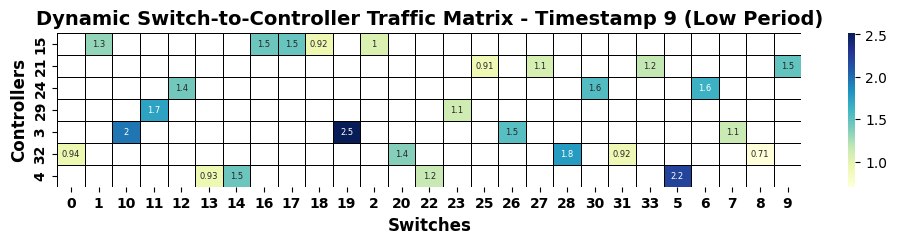

Switch Nodes and Types:
   Switch Type
0      26    e
1      19    m
2       7    e
3      10    e
4      31    e
5       0    m
6      20    e
7       8    m
8      28    e
9      30    m
10     12    e
11      6    e
12      5    e
13     14    e
14     13    m
15     22    e
16      9    e
17     25    e
18     27    m
19     33    e
20     16    m
21      2    e
22     17    e
23      1    e
24     18    m
25     11    e
26     23    e
Switch Nodes and Scaled Loads:
   Switch  Scaled Load
0       7     1.141565
1      10     1.964901
2      26     1.534314
3      19     2.520196
4      28     1.778836
5       0     0.936998
6      20     1.370191
7       8     0.705259
8      31     0.916129
9      30     1.553466
10     12     1.430985
11      6     1.647475
12      5     2.213176
13     22     1.154077
14     13     0.926563
15     14     1.453864
16     33     1.170990
17     27     1.071282
18     25     0.913129
19      9     1.490654
20     16     1.451095
21     17     1.475

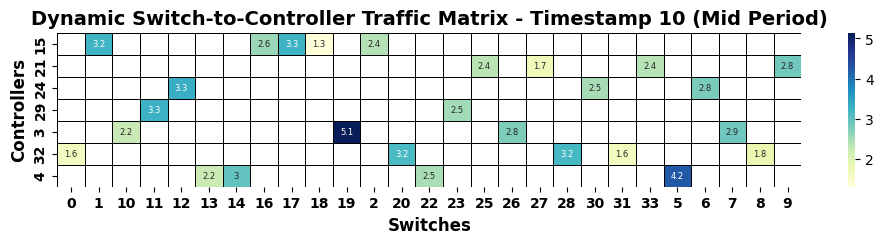

Switch Nodes and Types:
   Switch Type
0      26    e
1      19    m
2       7    e
3      10    e
4      31    e
5       0    m
6      20    e
7       8    m
8      28    e
9      30    m
10     12    e
11      6    e
12      5    e
13     14    e
14     13    m
15     22    e
16      9    e
17     25    e
18     27    m
19     33    e
20     16    m
21      2    e
22     17    e
23      1    e
24     18    m
25     11    e
26     23    e
Switch Nodes and Scaled Loads:
   Switch  Scaled Load
0      10     2.245267
1      19     5.143371
2      26     2.760670
3       7     2.879205
4       8     1.844525
5      20     3.153338
6      28     3.192255
7       0     1.614872
8      31     1.626577
9      12     3.334175
10     30     2.484604
11      6     2.786629
12     14     2.967726
13     13     2.214186
14      5     4.234037
15     22     2.473771
16     27     1.695903
17      9     2.839449
18     33     2.385948
19     25     2.359807
20     17     3.272081
21      2     2.405

In [ ]:
# 26
# Synethetic Traffic Generation depicting low, mid and peak traffic periods 
import numpy as np
import random
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the seed for reproducibility
np.random.seed(42)
random.seed(42)

# Define flow ranges
mice_flow_range = (2, 2.8)
elephant_flow_range = (2.8, 3.6)

# Define the distribution weights
mice_weight = 0.4
elephant_weight = 0.6

# Define the traffic load multipliers for different periods
period_multipliers = {
    "low": 0.5,
    "mid": 1.0,
    "peak": 1.5
}


# Define the distribution weights
weights = {
    'low': (0.6, 0.4),
    'mid': (0.5, 0.5),
    'peak': (0.4, 0.6)
}

# Define scaling factors for active switches
scaling_factors = {
    'low': 0.5,
    'mid': 0.7,
    'peak': 0.9
}

# Generate a list of periods for timestamps
periods = ['peak', 'mid', 'low', 'mid', 'peak', 'low', 'mid', 'peak', 'low', 'mid']

# Number of timestamps
num_timestamps = len(periods)

# Data structures to store results for all timestamps
all_heatmap_data = []
all_flow_type_data = []a

# Data structures to store results
switch_loads_per_timestamp = {}
all_controller_total_scaled_loads = []

# Simulate traffic for each timestamp
for timestamp in range(num_timestamps):

    period = periods[timestamp]
    mice_weight, elephant_weight = weights[period]
    scaling_factor = scaling_factors[period]

    print(f"\n=== Processing Timestamp {timestamp + 1} ===")

    multiplier = period_multipliers[period]

    # Step 2: Calculate centrality metrics
    betweenness_centrality = nx.betweenness_centrality(G, weight='latency')
    closeness_centrality = nx.closeness_centrality(G, distance='latency')

    # Normalize centrality metrics
    max_betweenness = max(betweenness_centrality.values(), default=1)
    max_closeness = max(closeness_centrality.values(), default=1)
    normalized_betweenness = {node: value / max_betweenness for node, value in betweenness_centrality.items()}
    normalized_closeness = {node: value / max_closeness for node, value in closeness_centrality.items()}
    combined_centrality = {node: normalized_betweenness.get(node, 0) + normalized_closeness.get(node, 0)
                           for node in G.nodes()}

    heatmap_data = []
    flow_type_data = []

    for controller, switches in assigned_nodes.items():
        random.shuffle(switches)

        num_switches = len(switches)
        num_mice_flows = int(num_switches * mice_weight)
        num_elephant_flows = num_switches - num_mice_flows

        mice_flows = np.random.uniform(mice_flow_range[0], mice_flow_range[1], num_mice_flows)
        elephant_flows = np.random.uniform(elephant_flow_range[0], elephant_flow_range[1], num_elephant_flows)

        traffic_loads = np.concatenate([mice_flows, elephant_flows]) * multiplier
        flow_types = ['m'] * num_mice_flows + ['e'] * num_elephant_flows
        np.random.shuffle(traffic_loads)
        np.random.shuffle(flow_types)

        for switch, load, flow_type in zip(switches, traffic_loads, flow_types):
            scaled_load = load * combined_centrality.get(switch, 1)
            heatmap_data.append({
                'Controller': controller,
                'Switch': switch,
                'Scaled Load': scaled_load
            })
            flow_type_data.append({
                'Switch': switch,
                'Type': flow_type
            })

    # Store results for this timestamp
    all_heatmap_data.extend(heatmap_data)
    all_flow_type_data.extend(flow_type_data)

    # Heatmap processing
    df_heatmap = pd.DataFrame(heatmap_data)
    heatmap_df = df_heatmap.pivot_table(index='Controller', columns='Switch', values='Scaled Load', aggfunc='mean')

    # Store switch loads in the dictionary
    switch_loads_per_timestamp[timestamp] = df_heatmap[['Switch', 'Scaled Load']]


    # Plot heatmap
    plt.figure(figsize=(12, 2))
    sns.heatmap(heatmap_df, annot=True, cmap='YlGnBu', linewidths=0.5, linecolor='black', annot_kws={"size": 6})
    plt.title(f"Dynamic Switch-to-Controller Traffic Matrix - Timestamp {timestamp + 1} ({period.capitalize()} Period)",
              fontsize=14, fontweight='bold')
    plt.xlabel("Switches", fontsize=12, fontweight='bold')
    plt.ylabel("Controllers", fontsize=12, fontweight='bold')
    plt.xticks(fontsize=10, fontweight='bold')
    plt.yticks(fontsize=10, fontweight='bold')
    plt.show()


    # Step 5: Display the table of switch nodes and their types
    print("Switch Nodes and Types:")
    print(df_flow_types)

    # Display the table of Switch Nodes and their Scaled Loads
    print("Switch Nodes and Scaled Loads:")
    switch_loads_df = df_heatmap[['Switch', 'Scaled Load']]
    print(switch_loads_df)

    # Calculate total scaled load per controller
    controller_total_scaled_load = df_heatmap.groupby('Controller')['Scaled Load'].sum().reset_index()
    controller_total_scaled_load.columns = ['Controller', 'Total Scaled Load']
    all_controller_total_scaled_loads.append(controller_total_scaled_load)

    print("\nTotal Scaled Load per Controller:")
    print(controller_total_scaled_load)

    total_scaled_load_sum = controller_total_scaled_load['Total Scaled Load'].sum()
    print(f"\nTotal Scaled Load Sum for Timestamp {timestamp + 1}: {total_scaled_load_sum}")

# Optionally combine and save results for all timestamps
all_flow_type_df = pd.DataFrame(all_flow_type_data)
all_heatmap_df = pd.DataFrame(all_heatmap_data)


In [59]:
# 27
controllers = list(assigned_nodes.keys())
print("Controllers:")
print(controllers)

switches = set()
for controller, assigned_switches in assigned_nodes.items():
    switches.update(assigned_switches)

print("Switches:")
print((switches))  # Sorted for easier readability

Controllers:
['3', '32', '24', '4', '21', '15', '29']
Switches:
{'19', '28', '31', '33', '18', '20', '12', '17', '7', '16', '2', '26', '9', '5', '6', '1', '11', '23', '10', '13', '22', '25', '30', '27', '14', '0', '8'}


In [ ]:
switch_loads_per_timestamp

{0:    Switch  Scaled Load
 0       7     4.977449
 1      19     5.588092
 2      10     5.968718
 3      26     5.855966
 4       8     2.387939
 5      20     5.003931
 6      31     3.428432
 7      28     4.144508
 8       0     3.115222
 9      12     4.588333
 10     30     3.272799
 11      6     4.818775
 12     14     2.745366
 13     13     3.905035
 14      5     5.892733
 15     22     4.784988
 16     25     3.289094
 17     27     3.258259
 18     33     4.398795
 19      9     4.036324
 20      2     4.580317
 21      1     4.679999
 22     17     3.418702
 23     16     3.164550
 24     18     2.907561
 25     11     4.752022
 26     23     4.618429,
 1:    Switch  Scaled Load
 0       7     2.808997
 1      10     3.929180
 2      26     4.095399
 3      19     4.244562
 4       0     2.383039
 5      28     3.870857
 6      31     2.171803
 7      20     2.394770
 8       8     1.636886
 9      12     3.422019
 10      6     2.293892
 11     30     2.731060
 12      

In [ ]:
print(switch_loads_per_timestamp.keys())  # Should include 0, 1, 2, ...


dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


In [62]:

# # HOMOGENEOUS CAPACITATED CONTROLLER PLACEMENT UNDER DYNAMIC TRAFFIC CONDITIONS WITH VARYING TIMESTAMPS 
# from gurobipy import Model, GRB, quicksum
# import numpy as np

# # Define geographical data and other inputs
# # Assuming `geo_loc_data`, `all_nodes`, `controllers`, `switch_loads_per_timestamp` are already defined

# # Calculate latency matrix T_ij
# all_nodes = list(geo_loc_data.keys())
# n = len(all_nodes)
# T_ij = np.zeros((n, n))

# for i in range(n):
#     for j in range(i + 1, n):
#         node1, node2 = all_nodes[i], all_nodes[j]
#         distance = haversine(node1, node2, geo_loc_data)
#         latency = (distance * 1000) / (2 * 1e8)  # Latency in milliseconds
#         T_ij[i][j] = latency
#         T_ij[j][i] = latency  # Symmetric matrix

# # Map nodes to indices
# node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}

# # Inputs
# C = [1200, 2500, 6500, 12000]  # Prices of controller types
# mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types
# # min_capacity = 0.5  # Minimum capacity ratio
# # max_capacity = 1.0  # Maximum capacity ratio

# # Controllers and switches
# K = [node_to_idx[node] for node in controllers]  # Ensure `controllers` list is defined
# m = len(K)  # Number of selected controller candidates
# switch_nodes = [node for node in all_nodes if node not in controllers]
# switch_indices = [node_to_idx[node] for node in switch_nodes]  # Indices of switch nodes
# P = len(C)  # Number of controller types

# # Calculate C_max for normalization
# C_max = len(switch_nodes) * max(C)

# # Calculate T_max as the sum of all latencies in the T_ij matrix
# T_max = np.sum(T_ij)

# # Coefficients for objective function (adjust weights for cost and latency)
# alpha = 0.34  # Weight for cost minimization
# beta = 0.33   # Weight for switch-to-controller latency minimization
# gamma = 0.33  # Weight for controller-to-controller latency minimization

# # Define `switch_loads_per_timestamp` as a list of lists
# # Each inner list contains the load of each switch for the corresponding timestamp
# # Example: switch_loads_per_timestamp[t][i] represents the load of switch `i` at timestamp `t`
# # switch_loads_per_timestamp = [[...], [...], ...]

# # Define number of timestamps
# num_timestamps = len(switch_loads_per_timestamp)

# # Initialize the model
# model = Model("Dynamic_Controller_Assignment")

# # Decision Variables
# Y = model.addVars(P, m, num_timestamps, vtype=GRB.BINARY, name="Y")  # Controller type placement
# D = model.addVars(len(switch_nodes), m, num_timestamps, vtype=GRB.BINARY, name="D")  # Switch assignment

# # Objective Function Terms
# cost_term = quicksum(
#     C[k] * Y[k, j, t]
#     for k in range(P)
#     for j in range(m)
#     for t in range(num_timestamps)
# )

# latency_term = quicksum(
#     T_ij[switch_indices[i], K[j]] * D[i, j, t]
#     for i in range(len(switch_nodes))
#     for j in range(m)
#     for t in range(num_timestamps)
# )

# controller_to_controller_latency_term = quicksum(
#     T_ij[K[j1], K[j2]] * Y[k1, j1, t] * Y[k2, j2, t]
#     for k1 in range(P) for j1 in range(m)
#     for k2 in range(P) for j2 in range(m)
#     for t in range(num_timestamps) if j1 < j2
# )

# # Objective Function
# model.setObjective(
#     (alpha / C_max) * cost_term +
#     (beta / T_max) * latency_term +
#     (gamma / T_max) * controller_to_controller_latency_term,
#     GRB.MINIMIZE
# )

# # Constraints

# # 1. Each selected location can host at most one type of controller at any timestamp
# for j in range(m):
#     for t in range(num_timestamps):
#         model.addConstr(quicksum(Y[k, j, t] for k in range(P)) <= 1, name=f"Location_{j}_One_Controller_Timestamp_{t}")

# # 2. Each switch must be assigned to exactly one controller per timestamp
# for i in range(len(switch_nodes)):
#     for t in range(num_timestamps):
#         model.addConstr(quicksum(D[i, j, t] for j in range(m)) == 1, name=f"Switch_{i}_Assigned_To_One_Controller_Timestamp_{t}")

# # 3. Switches can only be assigned to active controllers
# for i in range(len(switch_nodes)):
#     for j in range(m):
#         for t in range(num_timestamps):
#             model.addConstr(D[i, j, t] <= quicksum(Y[k, j, t] for k in range(P)), name=f"Switch_{i}_To_Active_Controller_{j}_Timestamp_{t}")


# # Adjust the load calculations based on scaled_loads
# for j in range(m):  # Iterate through all potential controllers or locations
#     for t in range(num_timestamps):
#         # Constraint: Scaled load assigned to a controller cannot exceed its capacity
#         model.addConstr(
#             quicksum(
#                 switch_loads_per_timestamp[t].loc[
#                     switch_loads_per_timestamp[t]['Switch'] == switch, 'Scaled Load'
#                 ].values[0] * D[i, j, t]  # Include the timestamp index here
#                 for i, switch in enumerate(switch_nodes)
#             )
#             <= quicksum(mu[k] * Y[k, j, t] for k in range(P)),
#             name=f"Scaled_Load_To_Capacity_Controller_{j}_Timestamp_{t}"
#         )


# # # Add min_capacity and max_capacity constraints
# # min_capacity = 0.60  # Minimum load capacity ratio
# max_capacity = 0.80  # Maximum load capacity ratio

# # Auxiliary binary variable to indicate whether a controller is active
# # is_active = model.addVars(m, vtype=GRB.BINARY, name="is_active")

# is_active = model.addVars(m, num_timestamps, vtype=GRB.BINARY, name="is_active")

# for j in range(m):  # Iterate through all potential controllers or controller locations
#     for t in range(num_timestamps):
#         # Calculate the load assigned to controller `j` at timestamp `t`
#         load = quicksum(
#         switch_loads_per_timestamp[t].loc[
#                     switch_loads_per_timestamp[t]['Switch'] == switch, 'Scaled Load'
#                 ].values[0] * D[i, j, t]  # Include the timestamp index here
#                 for i, switch in enumerate(switch_nodes)
#         )
#     # Calculate the capacity available for controller `j`
#         capacity = quicksum(mu[k] * Y[k, j, t] for k in range(P))

#         # Enforce constraints only if `capacity > 0` to avoid division errors
#         # Link `is_active[j]` to the activation of the controller
#         # model.addConstr(capacity <= is_active[j] * sum(mu), name=f"Capacity_Active_Link_{j}")
    
#         # # Minimum capacity ratio constraint: load >= min_capacity * capacity
#         # model.addConstr(load >= min_capacity * capacity - (1 - is_active[j]) * sum(mu), name=f"Min_Capacity_{j}")
    
#         # # Maximum capacity ratio constraint: load <= max_capacity * capacity
#         # model.addConstr(load <= max_capacity * capacity + (1 - is_active[j]) * sum(mu), name=f"Max_Capacity_{j}")
#         model.addConstr(capacity <= is_active[j, t] * sum(mu), name=f"Capacity_Active_Link_{j}_Timestamp_{t}")

#         # # Minimum capacity ratio constraint: load >= min_capacity * capacity
#         # model.addConstr(
#         #     load >= min_capacity * capacity - (1 - is_active[j, t]) * sum(mu),
#         #     name=f"Min_Capacity_{j}_Timestamp_{t}"
#         # )

#         # Maximum capacity ratio constraint: load <= max_capacity * capacity
#         model.addConstr(
#             load <= max_capacity * capacity + (1 - is_active[j, t]) * sum(mu),
#             name=f"Max_Capacity_{j}_Timestamp_{t}"
#         )


# # Solve the model
# model.optimize()

# if model.status == GRB.OPTIMAL:
#     print(f"Optimal Objective Value: {model.objVal}")

#     # Iterate through timestamps to determine selected and unselected locations
#     for t in range(num_timestamps):
#         selected_locations = [
#             all_nodes[K[j]]
#             for j in range(m)
#             if any(Y[k, j, t].x > 0.5 for k in range(P))
#         ]
#         unselected_locations = [
#             all_nodes[K[j]]
#             for j in range(m)
#             if all(Y[k, j, t].x <= 0.5 for k in range(P))
#         ]

#         print(f"Timestamp {t + 1}:")
#         print(f"  Selected Locations: {selected_locations}")
#         print(f"  Unselected Locations: {unselected_locations}")



In [63]:
# # 28
# # HOMOGENEOUS CAPACITATED CONTROLLER PLACEMENT UNDER DYNAMIC TRAFFIC CONDITIONS WITH VARYING TIMESTAMPS 
# from gurobipy import Model, GRB, quicksum
# import numpy as np

# # Define geographical data and other inputs
# # Assuming `geo_loc_data`, `all_nodes`, `controllers`, `switch_loads_per_timestamp` are already defined

# # Calculate latency matrix T_ij
# all_nodes = list(geo_loc_data.keys())
# n = len(all_nodes)
# T_ij = np.zeros((n, n))

# for i in range(n):
#     for j in range(i + 1, n):
#         node1, node2 = all_nodes[i], all_nodes[j]
#         distance = haversine(node1, node2, geo_loc_data)
#         latency = (distance * 1000) / (2 * 1e8)  # Latency in milliseconds
#         T_ij[i][j] = latency
#         T_ij[j][i] = latency  # Symmetric matrix

# # Map nodes to indices
# node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}

# # Inputs
# C = [1200, 2500, 6500, 12000]  # Prices of controller types
# mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types
# # min_capacity = 0.5  # Minimum capacity ratio
# # max_capacity = 1.0  # Maximum capacity ratio

# # Controllers and switches
# K = [node_to_idx[node] for node in controllers]  # Ensure `controllers` list is defined
# m = len(K)  # Number of selected controller candidates
# switch_nodes = [node for node in all_nodes if node not in controllers]
# switch_indices = [node_to_idx[node] for node in switch_nodes]  # Indices of switch nodes
# P = len(C)  # Number of controller types

# # Calculate C_max for normalization
# C_max = len(switch_nodes) * max(C)

# # Calculate T_max as the sum of all latencies in the T_ij matrix
# T_max = np.sum(T_ij)

# # Coefficients for objective function (adjust weights for cost and latency)
# alpha = 0.34  # Weight for cost minimization
# beta = 0.33   # Weight for switch-to-controller latency minimization
# gamma = 0.33  # Weight for controller-to-controller latency minimization

# # Define number of timestamps
# num_timestamps = len(switch_loads_per_timestamp)

# # Initialize the model
# model = Model("Dynamic_Controller_Assignment")

# # Decision Variables
# Z = model.addVars(P, num_timestamps, vtype=GRB.BINARY, name="Z")
# Y = model.addVars(P, m, num_timestamps, vtype=GRB.BINARY, name="Y")  # Controller type placement
# D = model.addVars(len(switch_nodes), m, num_timestamps, vtype=GRB.BINARY, name="D")  # Switch assignment


# # Objective Function Terms
# cost_term = quicksum(
#     C[k] * Y[k, j, t]
#     for k in range(P)
#     for j in range(m)
#     for t in range(num_timestamps)
# )

# latency_term = quicksum(
#     T_ij[switch_indices[i], K[j]] * D[i, j, t]
#     for i in range(len(switch_nodes))
#     for j in range(m)
#     for t in range(num_timestamps)
# )

# controller_to_controller_latency_term = quicksum(
#     T_ij[K[j1], K[j2]] * Y[k1, j1, t] * Y[k2, j2, t]
#     for k1 in range(P) for j1 in range(m)
#     for k2 in range(P) for j2 in range(m)
#     for t in range(num_timestamps) if j1 < j2
# )

# # Objective Function
# model.setObjective(
#     (alpha / C_max) * cost_term +
#     (beta / T_max) * latency_term +
#     (gamma / T_max) * controller_to_controller_latency_term,
#     GRB.MINIMIZE
# )

# for t in range(num_timestamps):
#     model.addConstr(quicksum(Z[k, t] for k in range(P)) == 1, name=f"Single_Controller_Type_Timestamp_{t}")

# for j in range(m):
#     for k in range(P):
#         for t in range(num_timestamps):
#             model.addConstr(Y[k, j, t] <= Z[k, t], name=f"Controller_Type_{k}_Location_{j}_Timestamp_{t}")


# # Constraint 1: Each selected location can host at most one type of controller at any timestamp
# for j in range(m):
#     for t in range(num_timestamps):
#         model.addConstr(
#             quicksum(Y[k, j, t] for k in range(P)) <= 1,
#             name=f"Location_{j}_One_Controller_Timestamp_{t}"
#         )

# # Constraint 2: Each switch must be assigned to exactly one controller per timestamp
# for i in range(len(switch_nodes)):
#     for t in range(num_timestamps):
#         model.addConstr(
#             quicksum(D[i, j, t] for j in range(m)) == 1,
#             name=f"Switch_{i}_Assigned_To_One_Controller_Timestamp_{t}"
#         )

# # Constraint 3: Switches can only be assigned to active controllers
# for i in range(len(switch_nodes)):
#     for j in range(m):
#         for t in range(num_timestamps):
#             model.addConstr(
#                 D[i, j, t] <= quicksum(Y[k, j, t] for k in range(P)),
#                 name=f"Switch_{i}_To_Active_Controller_{j}_Timestamp_{t}"
#             )

# # Constraint 4: Scaled load assigned to a controller cannot exceed its capacity
# for j in range(m):
#     for t in range(num_timestamps):
#         model.addConstr(
#             quicksum(
#                 switch_loads_per_timestamp[t].loc[
#                     switch_loads_per_timestamp[t]['Switch'] == switch, 'Scaled Load'
#                 ].values[0] * D[i, j, t]
#                 for i, switch in enumerate(switch_nodes)
#             )
#             <= quicksum(mu[k] * Y[k, j, t] for k in range(P)),
#             name=f"Scaled_Load_To_Capacity_Controller_{j}_Timestamp_{t}"
#         )

# # Constraint 5: Enforce maximum capacity ratio for controllers
# max_capacity = 0.80  # Maximum load capacity ratio
# is_active = model.addVars(m, num_timestamps, vtype=GRB.BINARY, name="is_active")

# for j in range(m):
#     for t in range(num_timestamps):
#         load = quicksum(
#             switch_loads_per_timestamp[t].loc[
#                 switch_loads_per_timestamp[t]['Switch'] == switch, 'Scaled Load'
#             ].values[0] * D[i, j, t]
#             for i, switch in enumerate(switch_nodes)
#         )
#         capacity = quicksum(mu[k] * Y[k, j, t] for k in range(P))
#         model.addConstr(
#             capacity <= is_active[j, t] * sum(mu),
#             name=f"Capacity_Active_Link_{j}_Timestamp_{t}"
#         )
#         model.addConstr(
#             load <= max_capacity * capacity + (1 - is_active[j, t]) * sum(mu),
#             name=f"Max_Capacity_{j}_Timestamp_{t}"
#         )


# # Solve the model
# model.optimize()

# if model.status == GRB.OPTIMAL:
#     print(f"Optimal Objective Value: {model.objVal}")

#     for t in range(num_timestamps):
#         print(f"Timestamp {t + 1}:")
        
#         # Determine optimal locations for the current timestamp
#         optimal_locations = [
#             all_nodes[K[j]] 
#             for j in range(m) 
#             if any(Y[k, j, t].x > 0.5 for k in range(P))
#         ]
#         print(f"Optimal Locations: {optimal_locations}")

#         # Switch assignments to controllers for the current timestamp
#         switch_assignments = {}
#         for i, switch in enumerate(switch_nodes):
#             assigned_controller_idx = next(
#                 j for j in range(m) if D[i, j, t].x > 0.5
#             )
#             assigned_controller = all_nodes[K[assigned_controller_idx]]
#             switch_assignments[switch] = assigned_controller

#         # print(f"Switch Assignments: {switch_assignments}")

#         # Find remaining nodes in K for the current timestamp
#         remaining_nodes = [
#             all_nodes[K[j]] 
#             for j in range(m) 
#             if all(Y[k, j, t].x <= 0.5 for k in range(P))
#         ]

#         # Reassign remaining nodes as switches for the current timestamp
#         reassigned_switch_assignments = {}
#         for node in remaining_nodes:
#             node_idx = node_to_idx[node]
#             closest_controller = min(
#                 optimal_locations,
#                 key=lambda loc: T_ij[node_idx, node_to_idx[loc]]
#             )
#             reassigned_switch_assignments[node] = closest_controller


# if model.status == GRB.OPTIMAL:
#     print(f"Optimal Objective Value: {model.objVal}")

#     for t in range(num_timestamps):
#         print(f"Timestamp {t + 1}:")

#         # Determine selected (optimal) locations for the current timestamp
#         selected_locations = [
#             all_nodes[K[j]] 
#             for j in range(m) 
#             if any(Y[k, j, t].x > 0.5 for k in range(P))
#         ]

#         # Determine unselected locations for the current timestamp
#         unselected_locations = [
#             all_nodes[K[j]] 
#             for j in range(m) 
#             if all(Y[k, j, t].x <= 0.5 for k in range(P))
#         ]

#         print(f"Selected Locations (Optimal): {selected_locations}")
#         print(f"Unselected Locations (To Be Reassigned as Switches): {unselected_locations}")

#         # Initialize location-to-switch assignment for this timestamp
#         location_to_switch_assignment = {loc: [] for loc in selected_locations}


#         # Assign switches to locations
#         for i, switch in enumerate(switch_nodes):
#             assigned_location = None
#             for j in range(m):
#                 if D[i, j, t].x > 0.5:  # Access D decision variable for the current timestamp
#                     assigned_location = all_nodes[K[j]]
#                     break
#             if assigned_location:
#                 location_to_switch_assignment[assigned_location].append(switch)

#         # Reassign unselected locations as switches
#         for unselected_loc in unselected_locations:
#             node_idx = node_to_idx[unselected_loc]
#             closest_location = min(
#                 selected_locations,
#                 key=lambda loc: T_ij[node_idx, node_to_idx[loc]]
#             )
#             location_to_switch_assignment[closest_location].append(unselected_loc)

#         # Balance the switch assignments for the current timestamp
#         print("\nBalancing Location-to-Switch Assignments:")
#         max_switches = max(len(switches) for switches in location_to_switch_assignment.values())
#         min_switches = min(len(switches) for switches in location_to_switch_assignment.values())

#         while max_switches - min_switches > 1:
#             # Find overloaded and underloaded locations
#             overloaded_location = max(location_to_switch_assignment, key=lambda loc: len(location_to_switch_assignment[loc]))
#             underloaded_location = min(location_to_switch_assignment, key=lambda loc: len(location_to_switch_assignment[loc]))
   
#             # Select a switch to move from the overloaded to underloaded location
#             switch_to_move = location_to_switch_assignment[overloaded_location].pop()
#             underloaded_location_idx = node_to_idx[underloaded_location]
    
#             # Reassign the switch based on proximity
#             closest_location = min(
#                 [underloaded_location],
#                 key=lambda loc: T_ij[node_to_idx[switch_to_move], node_to_idx[loc]]
#             )
#             location_to_switch_assignment[closest_location].append(switch_to_move)
    
#             # Update max and min switches
#             max_switches = max(len(switches) for switches in location_to_switch_assignment.values())
#             min_switches = min(len(switches) for switches in location_to_switch_assignment.values())

#         # Print final balanced assignments
#         print("\nFinal Balanced Location-to-Switch Assignments:")
#         for location, switches in location_to_switch_assignment.items():
#             print(f"Location {location}: {switches}")


#         # Calculate and print load-to-capacity ratio for each updated location
#         print("\nLoad-to-Capacity Ratios for Each Location After Reassignment:")
#         controller_type_names = ['A', 'B', 'C', 'D']  # Mapping of controller types


#         # Store load-to-capacity ratios for each location
#         load_capacity_ratios = {}

#         # Initialize a variable to store the total load for the timestamp
#         total_load_per_timestamp = 0

#         for location, switches in location_to_switch_assignment.items():
#             total_load = 0
    
#             # Calculate the total load for the location (sum of scaled load for each switch)
#             for switch in switches:
#                 # Find the row in switch_loads_per_timestamp[t] where 'Switch' column matches the current switch
#                 switch_load_row = switch_loads_per_timestamp[t].loc[switch_loads_per_timestamp[t]['Switch'] == switch]
        
#                 # If the switch is found in the dataframe, retrieve the 'Scaled Load' value
#                 if not switch_load_row.empty:
#                     total_load += switch_load_row['Scaled Load'].values[0]
#                 else:
#                     print(f"Warning: Switch {switch} not found in the data for timestamp {t}")

#             # Add the location's load to the total load for the timestamp
#             total_load_per_timestamp += total_load

#             selected_controller_type = None
#             selected_capacity = 0

#             # Find the assigned controller type and its capacity for the location
#             for j in range(m):
#                 if all_nodes[K[j]] == location:  # Check if the location matches the node in K[j]
#                     for k in range(P):  # Loop through all controller types
#                         if Y[k, j, t].x > 0.5:  # Check if the controller type k is assigned to location j
#                             selected_controller_type = k
#                             selected_capacity = mu[k]  # Get the capacity of the selected controller type
#                             break
#                     break  # Break out of the j loop once the controller is found

#             # Calculate the load-to-capacity ratio and enforce capacity constraints
#             if selected_capacity > 0:
#                 load_capacity_ratio = total_load / selected_capacity
#                 load_capacity_ratios[location] = load_capacity_ratio

#                 # Check and enforce capacity constraint
#                 if total_load > selected_capacity:
#                     print(f"WARNING: Location {location} exceeds capacity! "
#                         f"Load = {total_load}, Capacity = {selected_capacity}. "
#                         f"(Controller Type {controller_type_names[selected_controller_type]})")
#                 else:
#                     print(f"Location {location}: "
#                         f"Load = {total_load}, Capacity = {selected_capacity}, "
#                         f"Load_Capacity_Ratio = {load_capacity_ratio:.2f} "
#                         f"(Controller Type {controller_type_names[selected_controller_type]})")
#             else:
#                 print(f"Location {location}: No assigned controller.")

#         # # Print the total load for the timestamp
#         print(f"\nTotal Load for Timestamp: {total_load_per_timestamp:.2f}")
        
#         # Calculate and print the total cost of controllers
#         total_cost = 0
#         for location, switches in location_to_switch_assignment.items():
#             selected_capacity = 0
#             selected_controller_type = None

#             # Find the assigned controller's capacity
#             for j in range(m):
#                 if all_nodes[K[j]] == location:
#                     for k in range(P):
#                         if Y[k, j, t].x > 0.5:
#                             selected_controller_type = k
#                             selected_capacity = mu[k]
#                             break
#                     break

#             if selected_controller_type is not None:
#                 total_cost += C[selected_controller_type]  # Use cost from C list

#         print(f"\nTotal cost of controllers: {total_cost}")

#         # Calculate and store load imbalance for the current configuration
#         if load_capacity_ratios:
#             max_load_ratio = max(load_capacity_ratios.values())
#             min_load_ratio = min(load_capacity_ratios.values())
#             load_imbalance = ((max_load_ratio - min_load_ratio) / max_load_ratio) * 100 if max_load_ratio != 0 else 0.0

#             print("\n--------------------------------------")
#             print(f"Load Imbalance: {load_imbalance:.2f}%")
#             print(f"Overall Max Load Capacity Ratio = {max_load_ratio:.2f}")
#             print(f"Overall Min Load Capacity Ratio = {min_load_ratio:.2f}")

#         # Calculate and print switch-to-controller latency
#         total_switch_to_controller_latency = 0.0
#         for location in selected_locations:
#             for switch in location_to_switch_assignment.get(location, []):
#                 switch_idx = node_to_idx[switch]
#                 controller_idx = node_to_idx[location]  # Assuming location is assigned a controller node
#                 latency = T_ij[switch_idx, controller_idx]
#                 total_switch_to_controller_latency += latency

#         print(f"Total Switch-to-Controller Latency: {total_switch_to_controller_latency}")

#         # Calculate and print controller-to-controller latency
#         total_controller_to_controller_latency = 0.0
#         for i, location1 in enumerate(selected_locations):
#             for j, location2 in enumerate(selected_locations):
#                 if i < j:  # Avoid double counting
#                     controller1_idx = node_to_idx[location1]
#                     controller2_idx = node_to_idx[location2]
#                     latency = T_ij[controller1_idx, controller2_idx]
#                     total_controller_to_controller_latency += latency

#         print(f"Total Controller-to-Controller Latency: {total_controller_to_controller_latency}")

#     else:
#         print("No feasible solution found.")

        

In [ ]:
#29
# HETEROGENEOUS CAPACITATED CONTROLLER PLACEMENT UNDER DYNAMIC TRAFFIC CONDITIONS WITH VARYING TIMESTAMPS 
from gurobipy import Model, GRB, quicksum
import numpy as np

# Define geographical data and other inputs
# Assuming `geo_loc_data`, `all_nodes`, `controllers`, `switch_loads_per_timestamp` are already defined

# Calculate latency matrix T_ij
all_nodes = list(geo_loc_data.keys())
n = len(all_nodes)
T_ij = np.zeros((n, n))

for i in range(n):
    for j in range(i + 1, n):
        node1, node2 = all_nodes[i], all_nodes[j]
        distance = haversine(node1, node2, geo_loc_data)
        latency = (distance * 1000) / (2 * 1e8)  # Latency in milliseconds
        T_ij[i][j] = latency
        T_ij[j][i] = latency  # Symmetric matrix

# Map nodes to indices
node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}

# Inputs
C = [1200, 2500, 6500, 12000]  # Prices of controller types
mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types
# min_capacity = 0.5  # Minimum capacity ratio
# max_capacity = 1.0  # Maximum capacity ratio

# Controllers and switches
K = [node_to_idx[node] for node in controllers]  # Ensure `controllers` list is defined
m = len(K)  # Number of selected controller candidates
switch_nodes = [node for node in all_nodes if node not in controllers]
switch_indices = [node_to_idx[node] for node in switch_nodes]  # Indices of switch nodes
P = len(C)  # Number of controller types

# Calculate C_max for normalization
C_max = len(switch_nodes) * max(C)

# Calculate T_max as the sum of all latencies in the T_ij matrix
T_max = np.sum(T_ij)

# Coefficients for objective function (adjust weights for cost and latency)
alpha = 0.34  # Weight for cost minimization
beta = 0.33   # Weight for switch-to-controller latency minimization
gamma = 0.33  # Weight for controller-to-controller latency minimization

# Define `switch_loads_per_timestamp` as a list of lists
# Each inner list contains the load of each switch for the corresponding timestamp
# Example: switch_loads_per_timestamp[t][i] represents the load of switch `i` at timestamp `t`
# switch_loads_per_timestamp = [[...], [...], ...]

# Define number of timestamps
num_timestamps = len(switch_loads_per_timestamp)

# Initialize the model
model = Model("Dynamic_Controller_Assignment")

# Decision Variables
Y = model.addVars(P, m, num_timestamps, vtype=GRB.BINARY, name="Y")  # Controller type placement
D = model.addVars(len(switch_nodes), m, num_timestamps, vtype=GRB.BINARY, name="D")  # Switch assignment

# Objective Function Terms
cost_term = quicksum(
    C[k] * Y[k, j, t]
    for k in range(P)
    for j in range(m)
    for t in range(num_timestamps)
)

latency_term = quicksum(
    T_ij[switch_indices[i], K[j]] * D[i, j, t]
    for i in range(len(switch_nodes))
    for j in range(m)
    for t in range(num_timestamps)
)

controller_to_controller_latency_term = quicksum(
    T_ij[K[j1], K[j2]] * Y[k1, j1, t] * Y[k2, j2, t]
    for k1 in range(P) for j1 in range(m)
    for k2 in range(P) for j2 in range(m)
    for t in range(num_timestamps) if j1 < j2
)

# Objective Function
model.setObjective(
    (alpha / C_max) * cost_term +
    (beta / T_max) * latency_term +
    (gamma / T_max) * controller_to_controller_latency_term,
    GRB.MINIMIZE
)

# Constraints

# 1. Each selected location can host at most one type of controller at any timestamp
for j in range(m):
    for t in range(num_timestamps):
        model.addConstr(quicksum(Y[k, j, t] for k in range(P)) <= 1, name=f"Location_{j}_One_Controller_Timestamp_{t}")

# 2. Each switch must be assigned to exactly one controller per timestamp
for i in range(len(switch_nodes)):
    for t in range(num_timestamps):
        model.addConstr(quicksum(D[i, j, t] for j in range(m)) == 1, name=f"Switch_{i}_Assigned_To_One_Controller_Timestamp_{t}")

# 3. Switches can only be assigned to active controllers
for i in range(len(switch_nodes)):
    for j in range(m):
        for t in range(num_timestamps):
            model.addConstr(D[i, j, t] <= quicksum(Y[k, j, t] for k in range(P)), name=f"Switch_{i}_To_Active_Controller_{j}_Timestamp_{t}")


# Adjust the load calculations based on scaled_loads
for j in range(m):  # Iterate through all potential controllers or locations
    for t in range(num_timestamps):
        # Constraint: Scaled load assigned to a controller cannot exceed its capacity
        model.addConstr(
            quicksum(
                switch_loads_per_timestamp[t].loc[
                    switch_loads_per_timestamp[t]['Switch'] == switch, 'Scaled Load'
                ].values[0] * D[i, j, t]  # Include the timestamp index here
                for i, switch in enumerate(switch_nodes)
            )
            <= quicksum(mu[k] * Y[k, j, t] for k in range(P)),
            name=f"Scaled_Load_To_Capacity_Controller_{j}_Timestamp_{t}"
        )


# Add min_capacity and max_capacity constraints
min_capacity = 0.70  # Minimum load capacity ratio
max_capacity = 0.80  # Maximum load capacity ratio

# Auxiliary binary variable to indicate whether a controller is active
# is_active = model.addVars(m, vtype=GRB.BINARY, name="is_active")

is_active = model.addVars(m, num_timestamps, vtype=GRB.BINARY, name="is_active")


for j in range(m):  # Iterate through all potential controllers or controller locations
    for t in range(num_timestamps):
        # Calculate the load assigned to controller `j` at timestamp `t`
        load = quicksum(
        switch_loads_per_timestamp[t].loc[
                    switch_loads_per_timestamp[t]['Switch'] == switch, 'Scaled Load'
                ].values[0] * D[i, j, t]  # Include the timestamp index here
                for i, switch in enumerate(switch_nodes)
        )
    # Calculate the capacity available for controller `j`
        capacity = quicksum(mu[k] * Y[k, j, t] for k in range(P))

        # Enforce constraints only if `capacity > 0` to avoid division errors
        # Link `is_active[j]` to the activation of the controller
        # model.addConstr(capacity <= is_active[j] * sum(mu), name=f"Capacity_Active_Link_{j}")
    
        # # Minimum capacity ratio constraint: load >= min_capacity * capacity
        # model.addConstr(load >= min_capacity * capacity - (1 - is_active[j]) * sum(mu), name=f"Min_Capacity_{j}")
    
        # # Maximum capacity ratio constraint: load <= max_capacity * capacity
        # model.addConstr(load <= max_capacity * capacity + (1 - is_active[j]) * sum(mu), name=f"Max_Capacity_{j}")
        model.addConstr(capacity <= is_active[j, t] * sum(mu), name=f"Capacity_Active_Link_{j}_Timestamp_{t}")

        # Minimum capacity ratio constraint: load >= min_capacity * capacity
        model.addConstr(
            load >= min_capacity * capacity - (1 - is_active[j, t]) * sum(mu),
            name=f"Min_Capacity_{j}_Timestamp_{t}"
        )

        # Maximum capacity ratio constraint: load <= max_capacity * capacity
        model.addConstr(
            load <= max_capacity * capacity + (1 - is_active[j, t]) * sum(mu),
            name=f"Max_Capacity_{j}_Timestamp_{t}"
        )


# Solve the model
model.optimize()

if model.status == GRB.OPTIMAL:
    print(f"Optimal Objective Value: {model.objVal}")

    for t in range(num_timestamps):
        print(f"Timestamp {t + 1}:")
        
        # Determine optimal locations for the current timestamp
        optimal_locations = [
            all_nodes[K[j]] 
            for j in range(m) 
            if any(Y[k, j, t].x > 0.5 for k in range(P))
        ]
        print(f"Optimal Locations: {optimal_locations}")

        # Switch assignments to controllers for the current timestamp
        switch_assignments = {}
        for i, switch in enumerate(switch_nodes):
            assigned_controller_idx = next(
                j for j in range(m) if D[i, j, t].x > 0.5
            )
            assigned_controller = all_nodes[K[assigned_controller_idx]]
            switch_assignments[switch] = assigned_controller

        # print(f"Switch Assignments: {switch_assignments}")

        # Find remaining nodes in K for the current timestamp
        remaining_nodes = [
            all_nodes[K[j]] 
            for j in range(m) 
            if all(Y[k, j, t].x <= 0.5 for k in range(P))
        ]

        # Reassign remaining nodes as switches for the current timestamp
        reassigned_switch_assignments = {}
        for node in remaining_nodes:
            node_idx = node_to_idx[node]
            closest_controller = min(
                optimal_locations,
                key=lambda loc: T_ij[node_idx, node_to_idx[loc]]
            )
            reassigned_switch_assignments[node] = closest_controller


if model.status == GRB.OPTIMAL:
    print(f"Optimal Objective Value: {model.objVal}")

    for t in range(num_timestamps):
        print(f"Timestamp {t + 1}:")

        # Determine selected (optimal) locations for the current timestamp
        selected_locations = [
            all_nodes[K[j]] 
            for j in range(m) 
            if any(Y[k, j, t].x > 0.5 for k in range(P))
        ]

        # Determine unselected locations for the current timestamp
        unselected_locations = [
            all_nodes[K[j]] 
            for j in range(m) 
            if all(Y[k, j, t].x <= 0.5 for k in range(P))
        ]

        print(f"Selected Locations (Optimal): {selected_locations}")
        print(f"Unselected Locations (To Be Reassigned as Switches): {unselected_locations}")


            # Initialize location-to-switch assignment for this timestamp
        location_to_switch_assignment = {loc: [] for loc in selected_locations}


        # Assign switches to locations
        for i, switch in enumerate(switch_nodes):
            assigned_location = None
            for j in range(m):
                if D[i, j, t].x > 0.5:  # Access D decision variable for the current timestamp
                    assigned_location = all_nodes[K[j]]
                    break
            if assigned_location:
                location_to_switch_assignment[assigned_location].append(switch)

        # Reassign unselected locations as switches
        for unselected_loc in unselected_locations:
            node_idx = node_to_idx[unselected_loc]
            closest_location = min(
                selected_locations,
                key=lambda loc: T_ij[node_idx, node_to_idx[loc]]
            )
            location_to_switch_assignment[closest_location].append(unselected_loc)


        # Print final balanced assignments
        print("\nFinal Balanced Location-to-Switch Assignments:")
        for location, switches in location_to_switch_assignment.items():
            print(f"Location {location}: {switches}")


        # Calculate and print load-to-capacity ratio for each updated location
        print("\nLoad-to-Capacity Ratios for Each Location After Reassignment:")
        controller_type_names = ['A', 'B', 'C', 'D']  # Mapping of controller types


        # Store load-to-capacity ratios for each location
        load_capacity_ratios = {}

        # Initialize a variable to store the total load for the timestamp
        total_load_per_timestamp = 0

        for location, switches in location_to_switch_assignment.items():
            total_load = 0
    
            # Calculate the total load for the location (sum of scaled load for each switch)
            for switch in switches:
                # Find the row in switch_loads_per_timestamp[t] where 'Switch' column matches the current switch
                switch_load_row = switch_loads_per_timestamp[t].loc[switch_loads_per_timestamp[t]['Switch'] == switch]
        
                # If the switch is found in the dataframe, retrieve the 'Scaled Load' value
                if not switch_load_row.empty:
                    total_load += switch_load_row['Scaled Load'].values[0]
                else:
                    print(f"Warning: Switch {switch} not found in the data for timestamp {t}")

            # Add the location's load to the total load for the timestamp
            total_load_per_timestamp += total_load

            selected_controller_type = None
            selected_capacity = 0

            # Find the assigned controller type and its capacity for the location
            for j in range(m):
                if all_nodes[K[j]] == location:  # Check if the location matches the node in K[j]
                    for k in range(P):  # Loop through all controller types
                        if Y[k, j, t].x > 0.5:  # Check if the controller type k is assigned to location j
                            selected_controller_type = k
                            selected_capacity = mu[k]  # Get the capacity of the selected controller type
                            break
                    break  # Break out of the j loop once the controller is found

            # Calculate the load-to-capacity ratio and enforce capacity constraints
            if selected_capacity > 0:
                load_capacity_ratio = total_load / selected_capacity
                load_capacity_ratios[location] = load_capacity_ratio

                # Check and enforce capacity constraint
                if total_load > selected_capacity:
                    print(f"WARNING: Location {location} exceeds capacity! "
                        f"Load = {total_load}, Capacity = {selected_capacity}. "
                        f"(Controller Type {controller_type_names[selected_controller_type]})")
                else:
                    print(f"Location {location}: "
                        f"Load = {total_load}, Capacity = {selected_capacity}, "
                        f"Load_Capacity_Ratio = {load_capacity_ratio:.2f} "
                        f"(Controller Type {controller_type_names[selected_controller_type]})")
            else:
                print(f"Location {location}: No assigned controller.")

        # # Print the total load for the timestamp
        print(f"\nTotal Load for Timestamp: {total_load_per_timestamp:.2f}")
        
        # Calculate and print the total cost of controllers
        total_cost = 0
        for location, switches in location_to_switch_assignment.items():
            selected_capacity = 0
            selected_controller_type = None

            # Find the assigned controller's capacity
            for j in range(m):
                if all_nodes[K[j]] == location:
                    for k in range(P):
                        if Y[k, j, t].x > 0.5:
                            selected_controller_type = k
                            selected_capacity = mu[k]
                            break
                    break

            if selected_controller_type is not None:
                total_cost += C[selected_controller_type]  # Use cost from C list

        print(f"\nTotal cost of controllers: {total_cost}")



                # Calculate and store load imbalance for the current configuration
        if load_capacity_ratios:
            max_load_ratio = max(load_capacity_ratios.values())
            min_load_ratio = min(load_capacity_ratios.values())
            load_imbalance = ((max_load_ratio - min_load_ratio) / max_load_ratio) * 100 if max_load_ratio != 0 else 0.0

            print("\n--------------------------------------")
            print(f"Load Imbalance: {load_imbalance:.2f}%")
            print(f"Overall Max Load Capacity Ratio = {max_load_ratio:.2f}")
            print(f"Overall Min Load Capacity Ratio = {min_load_ratio:.2f}")

        # Calculate and print switch-to-controller latency
        total_switch_to_controller_latency = 0.0
        for location in selected_locations:
            for switch in location_to_switch_assignment.get(location, []):
                switch_idx = node_to_idx[switch]
                controller_idx = node_to_idx[location]  # Assuming location is assigned a controller node
                latency = T_ij[switch_idx, controller_idx]
                total_switch_to_controller_latency += latency

        print(f"Total Switch-to-Controller Latency: {total_switch_to_controller_latency}")

        # Calculate and print controller-to-controller latency
        total_controller_to_controller_latency = 0.0
        for i, location1 in enumerate(selected_locations):
            for j, location2 in enumerate(selected_locations):
                if i < j:  # Avoid double counting
                    controller1_idx = node_to_idx[location1]
                    controller2_idx = node_to_idx[location2]
                    latency = T_ij[controller1_idx, controller2_idx]
                    total_controller_to_controller_latency += latency

        print(f"Total Controller-to-Controller Latency: {total_controller_to_controller_latency}")

    else:
        print("No feasible solution found.")


Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11.0 (22621.2))

CPU model: Intel(R) Core(TM) i7-8565U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 2510 rows, 2240 columns and 18620 nonzeros
Model fingerprint: 0x48b4d526
Model has 3360 quadratic objective terms
Variable types: 0 continuous, 2240 integer (2240 binary)
Coefficient statistics:
  Matrix range     [6e-01, 3e+02]
  Objective range  [2e-05, 1e-02]
  QObjective range [2e-04, 1e-03]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 3e+02]
Presolve removed 1046 rows and 917 columns
Presolve time: 0.74s
Presolved: 3039 rows, 2898 columns, 12159 nonzeros
Variable types: 0 continuous, 2898 integer (2898 binary)
Found heuristic solution: objective 0.1194843

Root relaxation: objective 9.095175e-02, 450 iterations, 0.01 seconds (0.01 work units)

    Nodes    |    Current Node    |     Objective Bounds    

In [ ]:
# 30 

# Dictionary to store latency results for each timestamp
latency_results_per_timestamp = {}

if model.status == GRB.OPTIMAL:
    print(f"Optimal Objective Value: {model.objVal}")

    for t in range(num_timestamps):
        print(f"Timestamp {t + 1}:")

        # Determine selected (optimal) locations for the current timestamp
        selected_locations = [
            all_nodes[K[j]] 
            for j in range(m) 
            if any(Y[k, j, t].x > 0.5 for k in range(P))
        ]

        # Determine unselected locations for the current timestamp
        unselected_locations = [
            all_nodes[K[j]] 
            for j in range(m) 
            if all(Y[k, j, t].x <= 0.5 for k in range(P))
        ]

        print(f"Selected Locations (Optimal): {selected_locations}")
        print(f"Unselected Locations (To Be Reassigned as Switches): {unselected_locations}")

        # Initialize location-to-switch assignment for this timestamp
        location_to_switch_assignment = {loc: [] for loc in selected_locations}

        # Assign switches to locations
        for i, switch in enumerate(switch_nodes):
            assigned_location = None
            for j in range(m):
                if D[i, j, t].x > 0.5:  # Access D decision variable for the current timestamp
                    assigned_location = all_nodes[K[j]]
                    break
            if assigned_location:
                location_to_switch_assignment[assigned_location].append(switch)

        # Reassign unselected locations as switches
        for unselected_loc in unselected_locations:
            node_idx = node_to_idx[unselected_loc]
            closest_location = min(
                selected_locations,
                key=lambda loc: T_ij[node_idx, node_to_idx[loc]]
            )
            location_to_switch_assignment[closest_location].append(unselected_loc)

        # Balance the switch assignments for the current timestamp
        print("\nBalancing Location-to-Switch Assignments:")
        max_switches = max(len(switches) for switches in location_to_switch_assignment.values())
        min_switches = min(len(switches) for switches in location_to_switch_assignment.values())

        while max_switches - min_switches > 1:
            # Find overloaded and underloaded locations
            overloaded_location = max(location_to_switch_assignment, key=lambda loc: len(location_to_switch_assignment[loc]))
            underloaded_location = min(location_to_switch_assignment, key=lambda loc: len(location_to_switch_assignment[loc]))
   
            # Select a switch to move from the overloaded to underloaded location
            switch_to_move = location_to_switch_assignment[overloaded_location].pop()
            underloaded_location_idx = node_to_idx[underloaded_location]
    
            # Reassign the switch based on proximity
            closest_location = min(
                [underloaded_location],
                key=lambda loc: T_ij[node_to_idx[switch_to_move], node_to_idx[loc]]
            )
            location_to_switch_assignment[closest_location].append(switch_to_move)
    
            # Update max and min switches
            max_switches = max(len(switches) for switches in location_to_switch_assignment.values())
            min_switches = min(len(switches) for switches in location_to_switch_assignment.values())

        # Print final balanced assignments
        print("\nFinal Balanced Location-to-Switch Assignments:")
        for location, switches in location_to_switch_assignment.items():
            print(f"Location {location}: {switches}")

        # Initialize variables to store latency metrics for this timestamp
        latency_results = {}
        total_average_latency = 0
        max_worst_case_latency = float('-inf')
        total_controller_latency = 0
        controller_pairs = 0
        max_pairwise_worst_case_latency = float('-inf')

        # Calculate latencies for each controller to assigned nodes
        for location, switches in location_to_switch_assignment.items():  # Use final balanced assignments
            total_latency = 0
            worst_case_latency = float('-inf')

            for switch in switches:
                try:
                    # Calculate the shortest path length (latency) between the location and the node
                    latency = nx.shortest_path_length(G, source=location, target=switch, weight='weight')
                    
                    # Convert latency to milliseconds
                    latency_ms = (latency * 1000) / (2 * 1e8)  # Adjust formula if necessary
                    
                    # Update the cumulative and worst-case latencies
                    total_latency += latency_ms
                    worst_case_latency = max(worst_case_latency, latency_ms)
                except nx.NetworkXNoPath:
                    print(f"No path found between location {location} and node {switch}. Skipping latency calculation.")

            # Calculate average latency for this controller
            average_latency = total_latency / len(switches) if switches else 0
            total_average_latency += average_latency  # Add to total average latency sum

            # Update the maximum worst-case latency across all controllers
            max_worst_case_latency = max(max_worst_case_latency, worst_case_latency)

            # Store the latencies for this location
            latency_results[location] = {
                'average_latency': average_latency,
                'worst_case_latency': worst_case_latency
            }

        # Compute latencies between controllers
        for i, controller1 in enumerate(selected_locations):  # Controllers are the selected locations
            for j, controller2 in enumerate(selected_locations):
                if i < j:  # Avoid duplicate calculations for pairs
                    try:
                        # Calculate shortest path length between two controllers
                        pairwise_latency = nx.shortest_path_length(G, source=controller1, target=controller2, weight='weight')
                        pairwise_latency_ms = (pairwise_latency * 1000) / (2 * 1e8)  # Adjust formula if necessary

                        # Accumulate total controller-to-controller latency
                        total_controller_latency += pairwise_latency_ms
                        controller_pairs += 1

                        # Update the maximum pairwise worst-case latency
                        max_pairwise_worst_case_latency = max(max_pairwise_worst_case_latency, pairwise_latency_ms)
                    except nx.NetworkXNoPath:
                        print(f"No path found between controllers {controller1} and {controller2}. Skipping latency calculation.")

        # Calculate the average controller-to-controller latency
        average_controller_latency = total_controller_latency / controller_pairs if controller_pairs > 0 else 0

        # Consolidate the results for the current timestamp
        latency_results_per_timestamp[t] = {
            'average_controller_latency': average_controller_latency,
            'max_pairwise_worst_case_latency': max_pairwise_worst_case_latency,
            'total_average_latency': total_average_latency,
            'max_worst_case_latency': max_worst_case_latency,
            'controller_latencies': latency_results
        }

        # Display results for the current timestamp
        print(f"\nTimestamp {t + 1} Results:")
        print(f"Average Controller-to-Controller Latency = {average_controller_latency:.15f} ms")
        print(f"Maximum Pairwise Worst-Case Latency = {max_pairwise_worst_case_latency:.15f} ms")
        print(f"\nTotal Average Node to Controller Latency = {total_average_latency:.15f} ms")
        print(f"Maximum Worst-Case Node to Controller Latency = {max_worst_case_latency:.15f} ms")


Optimal Objective Value: 0.10454721634549409
Timestamp 1:
Selected Locations (Optimal): ['3', '4', '15', '29']
Unselected Locations (To Be Reassigned as Switches): ['32', '24', '21']

Balancing Location-to-Switch Assignments:

Final Balanced Location-to-Switch Assignments:
Location 3: ['7', '10', '19', '20', '26', '33', '24']
Location 4: ['0', '5', '8', '13', '14', '22', '28', '31']
Location 15: ['1', '2', '6', '12', '16', '17', '18', '30']
Location 29: ['9', '11', '23', '25', '27', '21', '32']

Timestamp 1 Results:
Average Controller-to-Controller Latency = 0.000073968333333 ms
Maximum Pairwise Worst-Case Latency = 0.000119230000000 ms

Total Average Node to Controller Latency = 0.000171447500000 ms
Maximum Worst-Case Node to Controller Latency = 0.000133245000000 ms
Timestamp 2:
Selected Locations (Optimal): ['3', '4', '15', '29']
Unselected Locations (To Be Reassigned as Switches): ['32', '24', '21']

Balancing Location-to-Switch Assignments:

Final Balanced Location-to-Switch Assig

In [ ]:
ttt 
# Dictionary to store latency results for each timestamp  (not working)
latency_results_per_timestamp = {}

# Iterate through each timestamp
for t in range(num_timestamps):
    print(f"\nProcessing Timestamp {t + 1}:")

    # Ensure location_switch_allocations keys and values are strings for the current timestamp
    location_switch_allocations = {
        str(location): [str(node) for node in nodes]
        for location, nodes in location_to_switch_assignment.items()
    }  # Ensure data is specific to the current timestamp

    # Prepare the list of updated controllers for the current timestamp
    updated_controllers = list(location_switch_allocations.keys())
    print("Updated Controllers:")
    print(updated_controllers)


    # Initialize variables to store latency metrics for this timestamp
    latency_results = {}
    total_average_latency = 0
    max_worst_case_latency = float('-inf')
    total_controller_latency = 0
    controller_pairs = 0
    max_pairwise_worst_case_latency = float('-inf')

    # Calculate latencies for each controller to assigned nodes
    for location, switches in location_switch_allocations.items():
        total_latency = 0
        worst_case_latency = float('-inf')

        for switch in switches:
            try:
                # Calculate the shortest path length (latency) between the location and the node
                latency = nx.shortest_path_length(G, source=location, target=switch, weight='weight')
                
                # Convert latency to milliseconds
                latency_ms = (latency * 1000) / (2 * 1e8)  # Adjust formula if necessary
                
                # Update the cumulative and worst-case latencies
                total_latency += latency_ms
                worst_case_latency = max(worst_case_latency, latency_ms)
            except nx.NetworkXNoPath:
                print(f"No path found between location {location} and node {switch}. Skipping latency calculation.")

        # Calculate average latency for this controller
        average_latency = total_latency / len(switches) if switches else 0
        total_average_latency += average_latency  # Add to total average latency sum

        # Update the maximum worst-case latency across all controllers
        max_worst_case_latency = max(max_worst_case_latency, worst_case_latency)

        # Store the latencies for this location
        latency_results[location] = {
            'average_latency': average_latency,
            'worst_case_latency': worst_case_latency
        }

    # Compute latencies between controllers
    for i, controller1 in enumerate(updated_controllers):
        for j, controller2 in enumerate(updated_controllers):
            if i < j:  # Avoid duplicate calculations for pairs
                try:
                    # Calculate shortest path length between two controllers
                    pairwise_latency = nx.shortest_path_length(G, source=controller1, target=controller2, weight='weight')
                    pairwise_latency_ms = (pairwise_latency * 1000) / (2 * 1e8)  # Adjust formula if necessary

                    # Accumulate total controller-to-controller latency
                    total_controller_latency += pairwise_latency_ms
                    controller_pairs += 1

                    # Update the maximum pairwise worst-case latency
                    max_pairwise_worst_case_latency = max(max_pairwise_worst_case_latency, pairwise_latency_ms)
                except nx.NetworkXNoPath:
                    print(f"No path found between controllers {controller1} and {controller2}. Skipping latency calculation.")

    # Calculate the average controller-to-controller latency
    average_controller_latency = total_controller_latency / controller_pairs if controller_pairs > 0 else 0

    # Consolidate the results for the current timestamp
    latency_results_per_timestamp[t] = {
        'average_controller_latency': average_controller_latency,
        'max_pairwise_worst_case_latency': max_pairwise_worst_case_latency,
        'total_average_latency': total_average_latency,
        'max_worst_case_latency': max_worst_case_latency,
        'controller_latencies': latency_results
    }

    # Display results for the current timestamp
    print(f"\nTimestamp {t + 1} Results:")
    print(f"Average Controller-to-Controller Latency = {average_controller_latency:.15f} ms")
    print(f"Maximum Pairwise Worst-Case Latency = {max_pairwise_worst_case_latency:.15f} ms")
    print(f"\nTotal Average Node to Controller Latency = {total_average_latency:.15f} ms")
    print(f"Maximum Worst-Case Node to Controller Latency = {max_worst_case_latency:.15f} ms")


NameError: name 'ttt' is not defined

In [1917]:
total_average_l
# Inputs
C = [1200, 2500, 6500, 12000]  # Prices of controller types
mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types

# Initialize a dictionary to store location-to-switch assignments for each timestamp
location_to_switch_assignment_per_timestamp = {}

for t in range(num_timestamps):
    print(f"\nTimestamp {t + 1}:")

    # Determine selected and unselected locations for the current timestamp
    selected_locations = [
        all_nodes[K[j]]
        for j in range(m)
        if any(Y[k, j, t].x > 0.5 for k in range(P))
    ]
    unselected_locations = [
        all_nodes[K[j]]
        for j in range(m)
        if all(Y[k, j, t].x <= 0.5 for k in range(P))
    ]

    # Assign switches to locations
    location_to_switch_assignment = {loc: [] for loc in selected_locations}

    # Initial assignments
    for i, switch in enumerate(switch_nodes):
        assigned_location = None
        for j in range(m):
            if D[i, j, t].x > 0.5:
                assigned_location = all_nodes[K[j]]
                break
        if assigned_location:
            location_to_switch_assignment[assigned_location].append(switch)

    # Reassign unselected locations as switches
    for unselected_loc in unselected_locations:
        node_idx = node_to_idx[unselected_loc]
        closest_location = min(
            selected_locations,
            key=lambda loc: T_ij[node_idx, node_to_idx[loc]]
        )
        location_to_switch_assignment[closest_location].append(unselected_loc)

    # Store the assignments for the current timestamp
    location_to_switch_assignment_per_timestamp[t] = location_to_switch_assignment

    # Print updated location-to-switch assignments for the current timestamp
    print("Updated Location-to-Switch Assignments After Reassignment:")
    for location, switches in location_to_switch_assignment.items():
        print(f"  Location {location}: {switches}")

    # Initialize a dictionary to store location-to-switch assignment matrices per timestamp
location_to_switch_assignment_matrices_per_timestamp = {}

for t in range(num_timestamps):
    print(f"\nTimestamp {t + 1}:")

    # Create a dictionary to map switch IDs to scaled load values for the current timestamp
    switch_to_load = dict(zip(
        switch_loads_per_timestamp[t]['Switch'].astype(str),
        switch_loads_per_timestamp[t]['Scaled Load']
    ))

    # List of controllers and sorted list of switches for the current timestamp
    controllers = list(location_to_switch_assignment_per_timestamp[t].keys())
    switches = sorted({
        switch for switches in location_to_switch_assignment_per_timestamp[t].values() for switch in switches
    })

    # Initialize the controller-to-switch matrix for the current timestamp
    location_to_switch_assignment_matrix = np.zeros((len(controllers), len(switches)))

    # Populate the matrix with scaled load values for the current timestamp
    for j, controller in enumerate(controllers):
        for switch in location_to_switch_assignment_per_timestamp[t][controller]:
            if switch in switch_to_load:
                i = switches.index(switch)
                location_to_switch_assignment_matrix[j, i] = switch_to_load[switch]

    # Store the matrix for the current timestamp
    location_to_switch_assignment_matrices_per_timestamp[t] = location_to_switch_assignment_matrix

    # Print the load-to-capacity ratios for the current timestamp
    print("Load-to-Capacity Ratios for Each Location:")
    for j, controller in enumerate(controllers):
        load = location_to_switch_assignment_matrix[j].sum()
        capacity = sum(
            mu[k] for k in range(P)
            if any(Y[k, j, t].x > 0.5 for k in range(P))
        )
        if capacity > 0:
            ratio = load / capacity
            print(f"  Location {controller}: Load = {load}, Capacity = {capacity}, Ratio = {ratio:.2f}")
        else:
            print(f"  Location {controller}: No capacity assigned.")

    


NameError: name 'total_average_l' is not defined

In [3789]:
load_capacity_ratios_per_timestamp = {}
total_cost_per_timestamp = {}

for t in range(num_timestamps):
    print(f"\nTimestamp {t + 1}:")

    # Initialize per-timestamp variables
    load_capacity_ratios = {}
    total_cost = 0

    # Ensure the correct number of controllers
    controllers = list(location_to_switch_assignment_per_timestamp[t].keys())

    for i, location in enumerate(controllers):
        # Ensure that the location index `i` does not exceed the available rows
        total_load = np.sum(location_to_switch_assignment_matrices_per_timestamp[t][i, :])  # Use matrix per timestamp
        selected_controller_type = None
        selected_capacity = 0

        # Find the suitable controller for the location based on the total load
        for idx, capacity in enumerate(mu):
            if total_load <= capacity:
                selected_controller_type = idx
                selected_capacity = capacity
                break

        # Calculate load-to-capacity ratio for the location
        if selected_capacity > 0 and total_load > 0:
            load_capacity_ratio = total_load / selected_capacity
            load_capacity_ratios[location] = load_capacity_ratio
            print(f"Location {location}: Load = {total_load:.2f}, Capacity = {selected_capacity}, "
                  f"Load_Capacity_Ratio = {load_capacity_ratio:.2f} "
                  f"(Controller Type {controller_type_names[selected_controller_type]})")
        else:
            load_capacity_ratios[location] = 0
            print(f"Location {location}: No assigned controller or no load.")

        # Add cost for the assigned controller type
        if selected_controller_type is not None:
            total_cost += C[selected_controller_type]
        else:
            print(f"Warning: Location {location} has no controller assigned.")

    # Store the results for the current timestamp
    load_capacity_ratios_per_timestamp[t] = load_capacity_ratios
    total_cost_per_timestamp[t] = total_cost

    # Print the total cost for the current timestamp
    print(f"\nTotal cost of controllers for Timestamp {t + 1}: {total_cost:.2f}")

# If you need to print the overall total cost after all timestamps:
overall_total_cost = sum(total_cost_per_timestamp.values())
print(f"\nOverall Total Cost Across All Timestamps: {overall_total_cost:.2f}")



Timestamp 1:
Location 29: Load = 39.83, Capacity = 40, Load_Capacity_Ratio = 1.00 (Controller Type B)
Location 4: Load = 24.13, Capacity = 25, Load_Capacity_Ratio = 0.97 (Controller Type A)
Location 15: Load = 24.23, Capacity = 25, Load_Capacity_Ratio = 0.97 (Controller Type A)
Location 3: Load = 22.74, Capacity = 25, Load_Capacity_Ratio = 0.91 (Controller Type A)

Total cost of controllers for Timestamp 1: 6100.00

Timestamp 2:
Location 29: Load = 24.33, Capacity = 25, Load_Capacity_Ratio = 0.97 (Controller Type A)
Location 4: Load = 22.48, Capacity = 25, Load_Capacity_Ratio = 0.90 (Controller Type A)
Location 15: Load = 24.88, Capacity = 25, Load_Capacity_Ratio = 1.00 (Controller Type A)

Total cost of controllers for Timestamp 2: 3600.00

Timestamp 3:
Location 29: Load = 22.70, Capacity = 25, Load_Capacity_Ratio = 0.91 (Controller Type A)
Location 4: Load = 13.78, Capacity = 25, Load_Capacity_Ratio = 0.55 (Controller Type A)

Total cost of controllers for Timestamp 3: 2400.00

Time

In [ ]:
load_capacity_ratios_per_timestamp = {}
total_cost_per_timestamp = {}

for t in range(num_timestamps):
    print(f"\nTimestamp {t + 1}:")

    # Initialize per-timestamp variables
    load_capacity_ratios = {}
    total_cost = 0

    for i, location in enumerate(controllers):
        total_load = np.sum(location_to_switch_assignment_matrices_per_timestamp[t][i, :])  # Use matrix per timestamp
        selected_controller_type = None
        selected_capacity = 0

        # Find the suitable controller for the location based on the total load
        for idx, capacity in enumerate(mu):
            if total_load <= capacity:
                selected_controller_type = idx
                selected_capacity = capacity
                break

        # Calculate load-to-capacity ratio for the location
        if selected_capacity > 0 and total_load > 0:
            load_capacity_ratio = total_load / selected_capacity
            load_capacity_ratios[location] = load_capacity_ratio
            print(f"Location {location}: Load = {total_load:.2f}, Capacity = {selected_capacity}, "
                  f"Load_Capacity_Ratio = {load_capacity_ratio:.2f} "
                  f"(Controller Type {controller_type_names[selected_controller_type]})")
        else:
            load_capacity_ratios[location] = 0
            print(f"Location {location}: No assigned controller or no load.")

        # Add cost for the assigned controller type
        if selected_controller_type is not None:
            total_cost += C[selected_controller_type]
        else:
            print(f"Warning: Location {location} has no controller assigned.")

    # Store the results for the current timestamp
    load_capacity_ratios_per_timestamp[t] = load_capacity_ratios
    total_cost_per_timestamp[t] = total_cost

    # Print the total cost for the current timestamp
    print(f"\nTotal cost of controllers for Timestamp {t + 1}: {total_cost:.2f}")

# If you need to print the overall total cost after all timestamps:
overall_total_cost = sum(total_cost_per_timestamp.values())
print(f"\nOverall Total Cost Across All Timestamps: {overall_total_cost:.2f}")



Timestamp 1:
Location 29: Load = 39.83, Capacity = 40, Load_Capacity_Ratio = 1.00 (Controller Type B)
Location 4: Load = 24.13, Capacity = 25, Load_Capacity_Ratio = 0.97 (Controller Type A)
Location 15: Load = 24.23, Capacity = 25, Load_Capacity_Ratio = 0.97 (Controller Type A)

Total cost of controllers for Timestamp 1: 4900.00

Timestamp 2:
Location 29: Load = 24.33, Capacity = 25, Load_Capacity_Ratio = 0.97 (Controller Type A)
Location 4: Load = 22.48, Capacity = 25, Load_Capacity_Ratio = 0.90 (Controller Type A)
Location 15: Load = 24.88, Capacity = 25, Load_Capacity_Ratio = 1.00 (Controller Type A)

Total cost of controllers for Timestamp 2: 3600.00

Timestamp 3:
Location 29: Load = 22.70, Capacity = 25, Load_Capacity_Ratio = 0.91 (Controller Type A)
Location 4: Load = 13.78, Capacity = 25, Load_Capacity_Ratio = 0.55 (Controller Type A)


IndexError: index 2 is out of bounds for axis 0 with size 2

In [ ]:
ttt
from gurobipy import Model, GRB, quicksum
import numpy as np

# Define geographical data and other inputs
# Assuming `geo_loc_data`, `all_nodes`, `controllers`, `switch_loads_per_timestamp` are already defined

# Calculate latency matrix T_ij
all_nodes = list(geo_loc_data.keys())
n = len(all_nodes)
T_ij = np.zeros((n, n))

for i in range(n):
    for j in range(i + 1, n):
        node1, node2 = all_nodes[i], all_nodes[j]
        distance = haversine(node1, node2, geo_loc_data)
        latency = (distance * 1000) / (2 * 1e8)  # Latency in milliseconds
        T_ij[i][j] = latency
        T_ij[j][i] = latency  # Symmetric matrix

# Map nodes to indices
node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}

# Inputs
C = [1200, 2500, 6500, 12000]  # Prices of controller types
mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types
min_capacity = 0.5  # Minimum capacity ratio
max_capacity = 1.0  # Maximum capacity ratio

# Controllers and switches
K = [node_to_idx[node] for node in controllers]  # Ensure `controllers` list is defined
m = len(K)  # Number of selected controller candidates
switch_nodes = [node for node in all_nodes if node not in controllers]
switch_indices = [node_to_idx[node] for node in switch_nodes]  # Indices of switch nodes
P = len(C)  # Number of controller types

# Calculate C_max for normalization
C_max = len(switch_nodes) * max(C)

# Calculate T_max as the sum of all latencies in the T_ij matrix
T_max = np.sum(T_ij)

# Coefficients for objective function (adjust weights for cost and latency)
alpha = 0.34  # Weight for cost minimization
beta = 0.33   # Weight for switch-to-controller latency minimization
gamma = 0.33  # Weight for controller-to-controller latency minimization

# Define `switch_loads_per_timestamp` as a list of lists
# Each inner list contains the load of each switch for the corresponding timestamp
# Example: switch_loads_per_timestamp[t][i] represents the load of switch `i` at timestamp `t`
# switch_loads_per_timestamp = [[...], [...], ...]

# Define number of timestamps
num_timestamps = len(switch_loads_per_timestamp)

# Initialize the model
model = Model("Dynamic_Controller_Assignment")

# Decision variables
Y = model.addVars(P, m, num_timestamps, vtype=GRB.BINARY, name="Y")  # Controller type placement
D = model.addVars(len(switch_nodes), m, num_timestamps, vtype=GRB.BINARY, name="D")  # Switch assignment
is_active = model.addVars(m, num_timestamps, vtype=GRB.BINARY, name="is_active")  # Controller activation

# Objective function terms
cost_term = quicksum(C[k] * Y[k, j, t] for k in range(P) for j in range(m) for t in range(num_timestamps))

latency_term = quicksum(
    T_ij[switch_indices[i], K[j]] * D[i, j, t] 
    for i in range(len(switch_nodes)) for j in range(m) for t in range(num_timestamps)
)

controller_to_controller_latency_term = quicksum(
    T_ij[K[j1], K[j2]] * Y[k1, j1, t] * Y[k2, j2, t] 
    for k1 in range(P) for j1 in range(m) 
    for k2 in range(P) for j2 in range(m) if j1 < j2 for t in range(num_timestamps)
)

# Set the objective function
model.setObjective(
    (alpha / C_max) * cost_term +
    (beta / T_max) * latency_term +
    (gamma / T_max) * controller_to_controller_latency_term,
    GRB.MINIMIZE
)

# Constraints
# Ensure that each switch is assigned to exactly one controller for each timestamp
for t in range(num_timestamps):
    for i in range(len(switch_nodes)):
        model.addConstr(quicksum(D[i, j, t] for j in range(m)) == 1, f"Switch_Assignment_{i}_Timestamp_{t}")

# Ensure controllers are only activated if assigned to a location for each timestamp
for t in range(num_timestamps):
    for j in range(m):
        model.addConstr(
            quicksum(Y[k, j, t] for k in range(P)) <= is_active[j, t],
            f"Controller_Activation_{j}_Timestamp_{t}"
        )

# Optimize the model
model.optimize()

# Process and display the results
if model.status == GRB.OPTIMAL:
    print("\nOptimal Solution Found:")
    for t in range(num_timestamps):
        print(f"\nTimestamp {t}:")
        for j in range(m):
            if is_active[j, t].x > 0.5:  # If the controller is active
                print(f"  Controller {K[j]} is active.")
                for k in range(P):
                    if Y[k, j, t].x > 0.5:  # If the controller type is assigned
                        print(f"    Assigned Controller Type: {C[k]}")
                for i in range(len(switch_nodes)):
                    if D[i, j, t].x > 0.5:  # If the switch is assigned to this controller
                        print(f"    Switch {switch_nodes[i]} assigned to Controller {K[j]}")
else:
    print("No optimal solution found.")


NameError: name 'ttt' is not defined

In [3562]:
tt
from gurobipy import Model, GRB, quicksum
import numpy as np

# Calculate latency matrix T_ij
all_nodes = list(geo_loc_data.keys())
n = len(all_nodes)
T_ij = np.zeros((n, n))

for i in range(n):
    for j in range(i + 1, n):
        node1, node2 = all_nodes[i], all_nodes[j]
        distance = haversine(node1, node2, geo_loc_data)
        latency = (distance * 1000) / (2 * 1e8)  # Latency in milliseconds

        T_ij[i][j] = latency
        T_ij[j][i] = latency  # Symmetric matrix


# Map nodes to indices
node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}

# Inputs
C = [1200, 2500, 6500, 12000]  # Prices of controller types
mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types
min_capacity = 0.5  # Minimum capacity ratio
max_capacity = 1.0  # Maximum capacity ratio


# Assuming `geo_loc_data`, `all_nodes`, `T_ij`, `C`, `mu`, `controllers`, `switch_nodes`, etc. are already defined

# Controllers and switches
K = [node_to_idx[node] for node in controllers]  # Ensure `controllers` list is defined
m = len(K)  # Number of selected controller candidates
switch_nodes = [node for node in all_nodes if node not in controllers]
switch_indices = [node_to_idx[node] for node in switch_nodes]  # Indices of switch nodes
P = len(C)  # Number of controller types

# Calculate C_max for normalization
C_max = len(switch_nodes) * max(C)

# Calculate T_max as the sum of all latencies in the T_ij matrix
T_max = np.sum(T_ij)

# Coefficients for objective function (adjust weights for cost and latency)
alpha = 0.34  # Weight for cost minimization
beta = 0.33   # Weight for switch-to-controller latency minimization
gamma = 0.33  # Weight for controller-to-controller latency minimization

# Assuming num_timestamps is defined
num_timestamps = 10  # Number of timestamps

# Initialize the model
model = Model("Dynamic_Controller_Assignment")

# Decision variables (indexed by timestamp)
Y = model.addVars(P, m, num_timestamps, vtype=GRB.BINARY, name="Y")  # Controller type placement for each timestamp
D = model.addVars(len(switch_nodes), m, num_timestamps, vtype=GRB.BINARY, name="D")  # Switch-to-controller assignment for each timestamp
is_active = model.addVars(m, num_timestamps, vtype=GRB.BINARY, name="is_active")  # Controller activation for each timestamp

# Objective function terms
cost_term = quicksum(C[k] * Y[k, j, t] for k in range(P) for j in range(m) for t in range(num_timestamps))  # Cost for placing controllers at each timestamp

latency_term = quicksum(
    T_ij[switch_indices[i], K[j]] * D[i, j, t] 
    for i in range(len(switch_nodes)) for j in range(m) for t in range(num_timestamps)
)  # Switch-to-controller latency for each timestamp

controller_to_controller_latency_term = quicksum(
    T_ij[K[j1], K[j2]] * Y[k1, j1, t] * Y[k2, j2, t] 
    for k1 in range(P) for j1 in range(m) 
    for k2 in range(P) for j2 in range(m) if j1 < j2 for t in range(num_timestamps)
)


# Set the objective function
model.setObjective(
    (alpha / C_max) * cost_term +
    (beta / T_max) * latency_term +
    (gamma / T_max) * controller_to_controller_latency_term,
    GRB.MINIMIZE
)

# Constraints
# Ensure that each switch is assigned to exactly one controller for each timestamp
for t in range(num_timestamps):
    for i in range(len(switch_nodes)):
        model.addConstr(quicksum(D[i, j, t] for j in range(m)) == 1, f"Switch_Assignment_{i}_Timestamp_{t}")

# # Ensure that each controller can handle the total load assigned to it without exceeding capacity for each timestamp
# for t in range(num_timestamps):
#     for j in range(m):
#         for k in range(P):
#             model.addConstr(
#                 quicksum(D[i, j, t] for i in range(len(switch_nodes))) * traffic_load[t][i] <= mu[k] * Y[k, j, t],
#                 f"Controller_Capacity_{j}_{k}_Timestamp_{t}"
#             )

# # Ensure that the total traffic load does not exceed controller capacity for each timestamp
# for t in range(num_timestamps):
#     for j in range(m):
#         model.addConstr(
#             quicksum(D[i, j, t] * traffic_load[t][i] for i in range(len(switch_nodes))) <= mu[k] * Y[k, j, t],
#             f"Controller_Capacity_{j}_{k}_Timestamp_{t}"
#         )

# Ensure controllers are only activated if assigned to a location for each timestamp
for t in range(num_timestamps):
    for j in range(m):
        model.addConstr(
            quicksum(Y[k, j, t] for k in range(P)) <= is_active[j, t],
            f"Controller_Activation_{j}_Timestamp_{t}"
        )

# Optimize the model
model.optimize()

# Process and display the results
if model.status == GRB.OPTIMAL:
    print("\nOptimal Solution Found:")
    for t in range(num_timestamps):
        print(f"\nTimestamp {t}:")
        for j in range(m):
            if is_active[j, t].x > 0.5:  # If the controller is active
                print(f"  Controller {K[j]} is active.")
                for k in range(P):
                    if Y[k, j, t].x > 0.5:  # If the controller type is assigned
                        print(f"    Assigned Controller Type: {C[k]}")
                for i in range(len(switch_nodes)):
                    if D[i, j, t].x > 0.5:  # If the switch is assigned to this controller
                        print(f"    Switch {switch_nodes[i]} assigned to Controller {K[j]}")
else:
    print("No optimal solution found.")


NameError: name 'tt' is not defined

In [3508]:
tt
from gurobipy import Model, GRB, quicksum
import numpy as np

# Calculate latency matrix T_ij
all_nodes = list(geo_loc_data.keys())
n = len(all_nodes)
T_ij = np.zeros((n, n))

for i in range(n):
    for j in range(i + 1, n):
        node1, node2 = all_nodes[i], all_nodes[j]
        distance = haversine(node1, node2, geo_loc_data)
        latency = (distance * 1000) / (2 * 1e8)  # Latency in milliseconds

        T_ij[i][j] = latency
        T_ij[j][i] = latency  # Symmetric matrix


# Map nodes to indices
node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}

# Inputs
C = [1200, 2500, 6500, 12000]  # Prices of controller types
mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types
min_capacity = 0.5  # Minimum capacity ratio
max_capacity = 1.0  # Maximum capacity ratio


# Define `K` (indices of selected candidate controllers)
K = [node_to_idx[node] for node in controllers]  # Ensure controllers is defined
m = len(K)  # Number of selected controller candidates
switch_nodes = [node for node in all_nodes if node not in controllers]
switch_indices = [node_to_idx[node] for node in switch_nodes]  # Indices of switch nodes
P = len(C)  # Number of controller types

# Calculate C_max for normalization
C_max = len(switch_nodes) * max(C)

# Calculate T_max as the sum of all latencies in the T_ij matrix
T_max = np.sum(T_ij)

# Coefficients for objective function (adjust weights for cost and latency)
alpha = 0.34  # Weight for cost minimization
beta = 0.33   # Weight for switch-to-controller latency minimization
gamma = 0.33  # Weight for controller-to-controller latency minimization

# Initialize a model
model = Model("Dynamic_Controller_Assignment")

# Simulate traffic for each timestamp
for timestamp in range(num_timestamps):

    print(f"\n=== Processing Timestamp {timestamp + 1} ===")

    # Decision variables
    Y = model.addVars(P, m, vtype=GRB.BINARY, name="Y")  # Controller type placement
    D = model.addVars(num_timestamps, len(switch_nodes), m, vtype=GRB.BINARY, name="D")  # Switch-to-controller assignment
    is_active = model.addVars(m, vtype=GRB.BINARY, name="is_active")  # Indicates controller activation

    # Objective function terms
    cost_term = quicksum(C[k] * Y[k, j] for k in range(P) for j in range(m))
    # Latency term for switch-to-controller assignment
    latency_term = quicksum(
        T_ij[switch_indices[i], node_to_idx[K[j]]] * D[i, j] 
        for i in range(len(switch_nodes)) for j in range(m)
    )

    # Controller-to-controller latency term
    controller_to_controller_latency_term = quicksum(
        T_ij[node_to_idx[K[j1]], node_to_idx[K[j2]]] * Y[k1, j1] * Y[k2, j2]
        for k1 in range(P) for j1 in range(m)
        for k2 in range(P) for j2 in range(m) if j1 < j2
    )

    # Set the objective function
    model.setObjective(
        (alpha / C_max) * cost_term +
        (beta / T_max) * latency_term +
        (gamma / T_max) * controller_to_controller_latency_term,
        GRB.MINIMIZE
    )

model.optimize()

# # Constraints
# for t in range(num_timestamps):
#     for i in range(len(switch_nodes)):
#         model.addConstr(quicksum(D[t, i, j] for j in range(m)) == 1, name=f"Switch_{i}_Assigned_At_Timestamp_{t}")

#         for j in range(m):
#             model.addConstr(
#                 D[t, i, j] <= quicksum(Y[k, j] for k in range(P)),
#                 name=f"Switch_{i}_Active_Controller_{j}_At_Timestamp_{t}"
#             )

#     for j in range(m):
#         load = quicksum(
#             all_switch_loads[t].loc[all_switch_loads[t]['Switch'] == switch, 'Scaled Load'].values[0] * D[t, i, j]
#             for i, switch in enumerate(switch_nodes)
#         )
#         capacity = quicksum(mu[k] * Y[k, j] for k in range(P))
#         model.addConstr(load >= min_capacity * capacity - (1 - is_active[j]) * sum(mu), name=f"Min_Load_{j}_{t}")
#         model.addConstr(load <= max_capacity * capacity + (1 - is_active[j]) * sum(mu), name=f"Max_Load_{j}_{t}")

# Solve the model
# model.optimize()


NameError: name 'tt' is not defined

In [2295]:
ttt
#HETEROGENEOUS CAPACIATED CONTROLLER PLACEMENT UNDER DYNAMIC TRAFFIC CONDITIONS 

from gurobipy import Model, GRB, quicksum
import numpy as np

# Calculate latency matrix T_ij
all_nodes = list(geo_loc_data.keys())
n = len(all_nodes)
T_ij = np.zeros((n, n))

for i in range(n):
    for j in range(i + 1, n):
        node1, node2 = all_nodes[i], all_nodes[j]
        distance = haversine(node1, node2, geo_loc_data)
        latency = (distance * 1000) / (2 * 1e8)  # Latency in milliseconds

        T_ij[i][j] = latency
        T_ij[j][i] = latency  # Symmetric matrix



# # Inputs for timestamps
# timestamps = range(len(traffic_matrices))  # Number of timestamps

# Number of timestamps
num_timestamps = 10
all_switch_loads = {t: switch_loads_df_per_timestamp[t] for t in num_timestamps}  # Load matrix per timestamp

# Map nodes to indices
node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}

# Inputs
C = [1200, 2500, 6500, 12000]  # Prices of controller types
mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types

# Define `K` (indices of selected candidate controllers)
K = [node_to_idx[node] for node in controllers]  # Ensure controllers is defined
m = len(K)  # Number of selected controller candidates
switch_nodes = [node for node in all_nodes if node not in controllers]
switch_indices = [node_to_idx[node] for node in switch_nodes]  # Indices of switch nodes
P = len(C)  # Number of controller types

# Calculate C_max for normalization
C_max = len(switch_nodes) * max(C)

# Calculate T_max as the sum of all latencies in the T_ij matrix
T_max = np.sum(T_ij)

# Coefficients for objective function (adjust weights for cost and latency)
alpha = 0.34  # Weight for cost minimization
beta = 0.33 # Weight for switch-to-controller latency minimization
gamma = 0.33  # Weight for controller-to-controller latency minimization

# Initialize a model
model = Model("Dynamic_Controller_Assignment")

# Decision variables
Y = model.addVars(P, m, vtype=GRB.BINARY, name="Y")  # Controller type placement (static across timestamps)
D = model.addVars(num_timestamps, len(switch_nodes), m, vtype=GRB.BINARY, name="D")  # Dynamic switch-to-controller assignment
is_active = model.addVars(m, vtype=GRB.BINARY, name="is_active")  # Indicates controller activation

# Define dynamic objective function terms
cost_term = quicksum(C[k] * Y[k, j] for k in range(P) for j in range(m))

# Add terms for dynamic latency and load balancing
latency_terms = []
for t in timestamps:
    # Latency term for switch-to-controller
    T_t = traffic_matrices[t]  # Latency matrix for timestamp `t`
    latency_term_t = quicksum(
        T_t[switch_indices[i], K[j]] * D[t, i, j]
        for i in range(len(switch_nodes))
        for j in range(m)
    )
    latency_terms.append(latency_term_t)

    # Controller-to-controller latency term (if dynamic at each timestamp)
    controller_to_controller_latency_t = quicksum(
        T_t[K[j1], K[j2]] * Y[k1, j1] * Y[k2, j2]
        for k1 in range(P) for j1 in range(m)
        for k2 in range(P) for j2 in range(m) if j1 < j2
    )
    latency_terms.append(controller_to_controller_latency_t)

# Aggregate latency terms across timestamps
latency_term = quicksum(latency_terms)

# Set the objective
model.setObjective(
    (alpha / C_max) * cost_term +
    (beta / T_max) * latency_term,
    GRB.MINIMIZE
)

# Constraints
for t in timestamps:
    # 1. Each switch must be assigned to exactly one controller per timestamp
    for i in range(len(switch_nodes)):
        model.addConstr(quicksum(D[t, i, j] for j in range(m)) == 1, name=f"Switch_{i}_Assigned_At_Timestamp_{t}")

    # 2. Switches can only be assigned to active controllers per timestamp
    for i in range(len(switch_nodes)):
        for j in range(m):
            model.addConstr(
                D[t, i, j] <= quicksum(Y[k, j] for k in range(P)),
                name=f"Switch_{i}_Active_Controller_{j}_At_Timestamp_{t}"
            )

    # 3. Load balancing constraints
    for j in range(m):
        # Load per timestamp
        load = quicksum(
            all_switch_loads[t].loc[all_switch_loads[t]['Switch'] == switch, 'Scaled Load'].values[0] * D[t, i, j]
            for i, switch in enumerate(switch_nodes)
        )
        capacity = quicksum(mu[k] * Y[k, j] for k in range(P))

        # Minimum capacity ratio
        model.addConstr(
            load >= min_capacity * capacity - (1 - is_active[j]) * sum(mu),
            name=f"Min_Capacity_{j}_At_Timestamp_{t}"
        )

        # Maximum capacity ratio
        model.addConstr(
            load <= max_capacity * capacity + (1 - is_active[j]) * sum(mu),
            name=f"Max_Capacity_{j}_At_Timestamp_{t}"
        )

# Solve the model
model.optimize()

# Print results
if model.status == GRB.OPTIMAL:
    print("Optimal solution found:")
    for j in range(m):
        for k in range(P):
            if Y[k, j].x > 0.5:
                print(f"Controller type {k} placed at location {j}")
    for t in timestamps:
        print(f"Timestamp {t}:")
        for i, switch in enumerate(switch_nodes):
            for j in range(m):
                if D[t, i, j].x > 0.5:
                    print(f"  Switch {switch} assigned to controller at location {j}")
else:
    print("No optimal solution found.")


NameError: name 'ttt' is not defined

In [1454]:
controllers = list(assigned_nodes.keys())
print("Controllers:")
print(controllers)

switches = set()
for controller, assigned_switches in assigned_nodes.items():
    switches.update(assigned_switches)

print("Switches:")
print((switches))  # Sorted for easier readability

Controllers:
['29', '4', '15', '24', '3', '32', '14']
Switches:
{'27', '8', '7', '12', '2', '20', '1', '10', '25', '23', '26', '31', '21', '30', '16', '33', '0', '18', '13', '6', '17', '28', '19', '9', '5', '22', '11'}


In [ ]:
tt# import numpy as np
# import pandas as pd
# import seaborn as sns
# import networkx as nx
# import matplotlib.pyplot as plt
# from gurobipy import Model, quicksum, GRB
# import random

# # Set the seed for reproducibility
# np.random.seed(42)
# random.seed(42)

# switch_nodes = G.nodes - K   # Replace with actual switch nodes
# controller_nodes = K  # Define controller nodes
# mu = [25, 40, 80, 150]
# min_capacity = 0.5  # Minimum capacity ratio
# max_capacity = 1.5  # Maximum capacity ratio

# # Define flow ranges and weights
# mice_flow_range = (2, 3)
# elephant_flow_range = (4, 6)
# mice_weight = 0.4
# elephant_weight = 0.6

# # Step 2: Calculate centrality metrics
# betweenness_centrality = nx.betweenness_centrality(G, weight='latency')
# closeness_centrality = nx.closeness_centrality(G, distance='latency')

# # Normalize centrality metrics
# max_betweenness = max(betweenness_centrality.values())
# max_closeness = max(closeness_centrality.values())
# normalized_betweenness = {node: value / max_betweenness for node, value in betweenness_centrality.items()}
# normalized_closeness = {node: value / max_closeness for node, value in closeness_centrality.items()}

# # Combine normalized centralities
# combined_centrality = {node: normalized_betweenness.get(node, 0) + normalized_closeness.get(node, 0) for node in G.nodes}

# # Synthetic Traffic Generation
# assigned_nodes = {...}  # Replace with actual assigned nodes dictionary
# scaled_loads = {}

# # Generate traffic loads and assign to switches
# for controller, switches in assigned_nodes.items():
#     random.shuffle(switches)
#     num_switches = len(switches)
#     num_mice_flows = int(num_switches * mice_weight)
#     num_elephant_flows = num_switches - num_mice_flows

#     mice_flows = np.random.uniform(mice_flow_range[0], mice_flow_range[1], num_mice_flows)
#     elephant_flows = np.random.uniform(elephant_flow_range[0], elephant_flow_range[1], num_elephant_flows)

#     traffic_loads = np.concatenate([mice_flows, elephant_flows])
#     np.random.shuffle(traffic_loads)

#     for switch, load in zip(switches, traffic_loads):
#         scaled_load = load * combined_centrality.get(switch, 1)
#         scaled_loads[switch] = scaled_load

# # Traffic loads ordered for optimization
# traffic_loads = [scaled_loads[switch] for switch in switch_nodes]

# # Optimization using Gurobi
# model = Model("DynamicTrafficOptimization")

# # Decision variables
# D = model.addVars(len(switch_nodes), len(controller_nodes), vtype=GRB.BINARY, name="D")
# Y = model.addVars(len(mu), len(controller_nodes), vtype=GRB.BINARY, name="Y")

# # Constraints
# # 1. Each switch is assigned to one controller
# for i in range(len(switch_nodes)):
#     model.addConstr(quicksum(D[i, j] for j in range(len(controller_nodes))) == 1)

# # 2. Switches can only be assigned to active controllers
# for i in range(len(switch_nodes)):
#     for j in range(len(controller_nodes)):
#         model.addConstr(D[i, j] <= quicksum(Y[k, j] for k in range(len(mu))))

# # 3. Controller capacity constraints
# for j in range(len(controller_nodes)):
#     load = quicksum(traffic_loads[i] * D[i, j] for i in range(len(switch_nodes)))
#     capacity = quicksum(mu[k] * Y[k, j] for k in range(len(mu)))
#     model.addConstr(load >= min_capacity * capacity)
#     model.addConstr(load <= max_capacity * capacity)

# # Objective: Minimize total latency
# model.setObjective(
#     quicksum(traffic_loads[i] * nx.shortest_path_length(G, switch_nodes[i], controller_nodes[j]) * D[i, j]
#              for i in range(len(switch_nodes)) for j in range(len(controller_nodes))),
#     GRB.MINIMIZE
# )

# # Solve the model
# model.optimize()

# # Step 4: Visualize results
# heatmap_data = [{"Controller": j, "Switch": i, "Scaled Load": traffic_loads[i]} for i in range(len(switch_nodes)) for j in range(len(controller_nodes)) if D[i, j].X > 0.5]
# df_heatmap = pd.DataFrame(heatmap_data)
# heatmap_df = df_heatmap.pivot_table(index="Controller", columns="Switch", values="Scaled Load", aggfunc="mean")

# # Plot heatmap
# plt.figure(figsize=(12, 6))
# sns.heatmap(heatmap_df, annot=True, cmap="YlGnBu", linewidths=0.5, linecolor="black")
# plt.title("Total Scaled Load Heatmap")
# plt.show()


NameError: name 'tt' is not defined

In [419]:
# # PLACEMENT OF SDN CONTROLLERS BASED ON NETWORK SETUP COSTS AND LATENCY OF CONTROL PACKETS 

# from gurobipy import Model, GRB, quicksum
# import numpy as np

# # Assuming geo_loc_data and haversine function are defined
# # geo_loc_data contains node names as keys and (latitude, longitude) as values
# # haversine(node1, node2, geo_loc_data) calculates distance between two nodes

# # Calculate latency matrix T_ij
# all_nodes = list(geo_loc_data.keys())
# n = len(all_nodes)
# T_ij = np.zeros((n, n))

# for i in range(n):
#     for j in range(i + 1, n):
#         node1, node2 = all_nodes[i], all_nodes[j]
#         distance = haversine(node1, node2, geo_loc_data)
#         latency = (distance * 1000) / (2 * 1e8)  # Latency in milliseconds

#         T_ij[i][j] = latency
#         T_ij[j][i] = latency  # Symmetric matrix

# # Map nodes to indices
# node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}

# # Inputs
# C = [1200, 2500, 6500, 12000]  # Prices of controller types
# mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types
# flow_rate = 2                  # Flow rate (Kpps) of each switch

# # Define `K` (indices of selected candidate controllers)
# K = [node_to_idx[node] for node in controllers]  # Ensure controllers is defined
# m = len(K)  # Number of selected controller candidates
# switch_nodes = [node for node in all_nodes if node not in controllers]
# switch_indices = [node_to_idx[node] for node in switch_nodes]  # Indices of switch nodes
# P = len(C)  # Number of controller types

# # Create the model
# model = Model("Controller_Assignment")

# # Decision variables
# Y = model.addVars(P, m, vtype=GRB.BINARY, name="Y")  # Controller type placement
# D = model.addVars(len(switch_nodes), m, vtype=GRB.BINARY, name="D")  # Switch-to-controller assignment

# # Objective function terms
# cost_term = quicksum(C[k] * Y[k, j] for k in range(P) for j in range(m))
# latency_term = quicksum(T_ij[switch_indices[i], K[j]] * D[i, j] for i in range(len(switch_nodes)) for j in range(m))
# controller_to_controller_latency_term = quicksum(
#     T_ij[K[j1], K[j2]] * Y[k1, j1] * Y[k2, j2] 
#     for k1 in range(P) for j1 in range(m) 
#     for k2 in range(P) for j2 in range(m) if j1 < j2
# )

# # Set the objective function
# model.setObjective(
#     cost_term + latency_term + controller_to_controller_latency_term,
#     GRB.MINIMIZE
# )

# # Constraints
# # 1. Each selected location can host at most one type of controller
# for j in range(m):
#     model.addConstr(quicksum(Y[k, j] for k in range(P)) <= 1, name=f"Location_{j}_One_Controller")

# # 2. Each switch must be assigned to exactly one controller
# for i in range(len(switch_nodes)):
#     model.addConstr(quicksum(D[i, j] for j in range(m)) == 1, name=f"Switch_{i}_Assigned_To_One_Controller")

# # 3. Switches can only be assigned to active controllers
# for i in range(len(switch_nodes)):
#     for j in range(m):
#         model.addConstr(D[i, j] <= quicksum(Y[k, j] for k in range(P)), name=f"Switch_{i}_To_Active_Controller_{j}")

# # 4. Controller capacity must not be exceeded
# for j in range(m):
#     model.addConstr(
#         quicksum(flow_rate * D[i, j] for i in range(len(switch_nodes))) <= quicksum(mu[k] * Y[k, j] for k in range(P)),
#         name=f"Controller_Capacity_{j}"
#     )

# # Solve the model
# model.optimize()

# if model.status == GRB.OPTIMAL:
#     print(f"Optimal Objective Value: {model.objVal}")

#     # Determine optimal locations
#     optimal_locations = [all_nodes[K[j]] for j in range(m) if any(Y[k, j].x > 0.5 for k in range(P))]
#     print(f"Optimal Locations: {optimal_locations}")

#     # Find remaining nodes in K
#     remaining_nodes = [all_nodes[K[j]] for j in range(m) if all(Y[k, j].x <= 0.5 for k in range(P))]

#     # Reassign remaining nodes as switches
#     reassigned_switch_assignments = {}
#     for node in remaining_nodes:
#         node_idx = node_to_idx[node]
#         closest_controller = min(
#             optimal_locations,
#             key=lambda loc: T_ij[node_idx, node_to_idx[loc]]
#         )
#         reassigned_switch_assignments[node] = closest_controller

#     print("Reassigned Switch Assignments:")
#     for switch, controller in reassigned_switch_assignments.items():
#         print(f"Switch {switch} reassigned to controller {controller}")

# else:
#     print("No feasible solution found.")


In [ ]:
scaled_load

2.0045315193578515

In [421]:
#HETEROGENEOUS CAPACIATED CONTROLLER PLACEMENT 

from gurobipy import Model, GRB, quicksum
import numpy as np

# Assuming geo_loc_data and haversine function are defined
# geo_loc_data contains node names as keys and (latitude, longitude) as values
# haversine(node1, node2, geo_loc_data) calculates distance between two nodes

# Calculate latency matrix T_ij
all_nodes = list(geo_loc_data.keys())
n = len(all_nodes)
T_ij = np.zeros((n, n))

for i in range(n):
    for j in range(i + 1, n):
        node1, node2 = all_nodes[i], all_nodes[j]
        distance = haversine(node1, node2, geo_loc_data)
        latency = (distance * 1000) / (2 * 1e8)  # Latency in milliseconds

        T_ij[i][j] = latency
        T_ij[j][i] = latency  # Symmetric matrix

# Map nodes to indices
node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}

# Inputs
C = [1200, 2500, 6500, 12000]  # Prices of controller types
mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types
flow_rate = 2                  # Flow rate (Kpps) of each switch

# Define `K` (indices of selected candidate controllers)
K = [node_to_idx[node] for node in controllers]  # Ensure controllers is defined
m = len(K)  # Number of selected controller candidates
switch_nodes = [node for node in all_nodes if node not in controllers]
switch_indices = [node_to_idx[node] for node in switch_nodes]  # Indices of switch nodes
P = len(C)  # Number of controller types

# Calculate C_max for normalization
C_max = len(switch_nodes) * max(C)

# Calculate T_max as the sum of all latencies in the T_ij matrix
T_max = np.sum(T_ij)

# Coefficients for objective function (adjust weights for cost and latency)
alpha = 0.4  # Weight for cost minimization
beta = 0.3  # Weight for switch-to-controller latency minimization
gamma = 0.3  # Weight for controller-to-controller latency minimization

# Create the model
model = Model("Controller_Assignment")

# Decision variables
Y = model.addVars(P, m, vtype=GRB.BINARY, name="Y")  # Controller type placement
D = model.addVars(len(switch_nodes), m, vtype=GRB.BINARY, name="D")  # Switch-to-controller assignment

# Objective function terms
cost_term = quicksum(C[k] * Y[k, j] for k in range(P) for j in range(m))
latency_term = quicksum(T_ij[switch_indices[i], K[j]] * D[i, j] for i in range(len(switch_nodes)) for j in range(m))
controller_to_controller_latency_term = quicksum(
    T_ij[K[j1], K[j2]] * Y[k1, j1] * Y[k2, j2] 
    for k1 in range(P) for j1 in range(m) 
    for k2 in range(P) for j2 in range(m) if j1 < j2
)

# Set the objective function
model.setObjective(
    (alpha / C_max) * cost_term +
    (beta / T_max) * latency_term +
    (gamma / T_max) * controller_to_controller_latency_term,
    GRB.MINIMIZE
)

# Constraints
# 1. Each selected location can host at most one type of controller
for j in range(m):
    model.addConstr(quicksum(Y[k, j] for k in range(P)) <= 1, name=f"Location_{j}_One_Controller")

# 2. Each switch must be assigned to exactly one controller
for i in range(len(switch_nodes)):
    model.addConstr(quicksum(D[i, j] for j in range(m)) == 1, name=f"Switch_{i}_Assigned_To_One_Controller")

# 3. Switches can only be assigned to active controllers
for i in range(len(switch_nodes)):
    for j in range(m):
        model.addConstr(D[i, j] <= quicksum(Y[k, j] for k in range(P)), name=f"Switch_{i}_To_Active_Controller_{j}")

# 4. Controller capacity must not be exceeded
for j in range(m):
    model.addConstr(
        quicksum(flow_rate * D[i, j] for i in range(len(switch_nodes))) <= quicksum(mu[k] * Y[k, j] for k in range(P)),
        name=f"Controller_Capacity_{j}"
    )
    

# Add min_capacity and max_capacity constraints
min_capacity = 0.80  # Minimum load capacity ratio
max_capacity = 0.90  # Maximum load capacity ratio

for j in range(m):  # For each controller location
    # Corrected range to match `D` dimensions
    load = quicksum(flow_rate * D[i, j] for i in range(len(switch_nodes)))
    capacity = quicksum(mu[k] * Y[k, j] for k in range(P))
    
    # Ensure capacity > 0 before applying constraints
    model.addConstr(
        load >= min_capacity * capacity,
        name=f"Min_Capacity_Ratio_Controller_{j}"
    )
    model.addConstr(
        load <= max_capacity * capacity,
        name=f"Max_Capacity_Ratio_Controller_{j}"
    )

# Solve the model
model.optimize()

if model.status == GRB.OPTIMAL:
    print(f"Optimal Objective Value: {model.objVal}")

    # Determine optimal locations
    optimal_locations = [all_nodes[K[j]] for j in range(m) if any(Y[k, j].x > 0.5 for k in range(P))]
    print(f"Optimal Locations: {optimal_locations}")

    # Switch assignments to controllers
    switch_assignments = {}
    for i, switch in enumerate(switch_nodes):
        assigned_controller_idx = next(j for j in range(m) if D[i, j].x > 0.5)
        assigned_controller = all_nodes[K[assigned_controller_idx]]
        switch_assignments[switch] = assigned_controller

   

    # Find remaining nodes in K
    remaining_nodes = [all_nodes[K[j]] for j in range(m) if all(Y[k, j].x <= 0.5 for k in range(P))]

    # Reassign remaining nodes as switches
    reassigned_switch_assignments = {}
    for node in remaining_nodes:
        node_idx = node_to_idx[node]
        closest_controller = min(
            optimal_locations,
            key=lambda loc: T_ij[node_idx, node_to_idx[loc]]
        )
        reassigned_switch_assignments[node] = closest_controller

if model.status == GRB.OPTIMAL:
    print(f"Optimal Objective Value: {model.objVal}")

    # Determine optimal and unselected locations
    selected_locations = [all_nodes[K[j]] for j in range(m) if any(Y[k, j].x > 0.5 for k in range(P))]
    unselected_locations = [all_nodes[K[j]] for j in range(m) if all(Y[k, j].x <= 0.5 for k in range(P))]

    print(f"Selected Locations (Optimal): {selected_locations}")
    print(f"Unselected Locations (To Be Reassigned as Switches): {unselected_locations}")

    # Assign switches to locations
    location_to_switch_assignment = {loc: [] for loc in selected_locations}

    # Assign initially
    for i, switch in enumerate(switch_nodes):
        assigned_location = None
        for j in range(m):
            if D[i, j].x > 0.5:
                assigned_location = all_nodes[K[j]]
                break
        if assigned_location:
            location_to_switch_assignment[assigned_location].append(switch)

    # Reassign unselected locations as switches
    for unselected_loc in unselected_locations:
        node_idx = node_to_idx[unselected_loc]
        closest_location = min(
            selected_locations,
            key=lambda loc: T_ij[node_idx, node_to_idx[loc]]
        )
        location_to_switch_assignment[closest_location].append(unselected_loc)

    # Print updated location-to-switch assignments
    print("\nUpdated Location-to-Switch Assignments After Reassignment:")
    for location, switches in location_to_switch_assignment.items():
        print(f"Location {location}: {switches}")

    # Print load-to-capacity ratio for each updated location
    print("\nLoad-to-Capacity Ratios for Each Location After Reassignment:")
    controller_type_names = ['A', 'B', 'C', 'D']  # Mapping of controller types

    load_capacity_ratios = {}  # Store load-to-capacity ratios for each location
    for location, switches in location_to_switch_assignment.items():
        total_load = len(switches) * flow_rate  # Calculate total load for the location
        selected_controller_type = None
        selected_capacity = 0

        # Find the assigned controller type and its capacity
        for j in range(m):
            if all_nodes[K[j]] == location:
                for k in range(P):
                    if Y[k, j].x > 0.5:
                        selected_controller_type = k
                        selected_capacity = mu[k]
                        break
                break

        # Calculate the load-to-capacity ratio
        if selected_capacity > 0:
            load_capacity_ratio = total_load / selected_capacity
            load_capacity_ratios[location] = load_capacity_ratio
            print(f"Location {location}: "
                  f"Load = {total_load}, Capacity = {selected_capacity}, "
                  f"Load_Capacity_Ratio = {load_capacity_ratio:.2f} "
                  f"(Controller Type {controller_type_names[selected_controller_type]})")
        else:
            print(f"Location {location}: No assigned controller.")

    total_cost = 0
    for location, switches in location_to_switch_assignment.items():
        selected_capacity = 0
        selected_controller_type = None

        # Find the assigned controller's capacity
        for j in range(m):
            if all_nodes[K[j]] == location:
                for k in range(P):
                    if Y[k, j].x > 0.5:
                        selected_controller_type = k
                        selected_capacity = mu[k]
                        break
                break

        if selected_controller_type is not None:
            total_cost += C[selected_controller_type]  # Use cost from C list

    print(f"\nTotal cost of controllers: {total_cost}")

    # Print overloaded controllers and the excess load
    print("\nOverloaded Controllers and Excess Load:")
    any_overloaded = False
    for location, switches in location_to_switch_assignment.items():
        total_load = len(switches) * flow_rate  # Calculate total load for the location
        selected_capacity = 0

        # Find the assigned controller's capacity
        for j in range(m):
            if all_nodes[K[j]] == location:
                for k in range(P):
                    if Y[k, j].x > 0.5:
                        selected_capacity = mu[k]
                        break
                break


                # Check overload conditions
        if selected_capacity > 0:
            if selected_capacity > min_capacity:
                excess_load = selected_capacity - total_load
                print(f"Location {location}: Exceeds Minimum Capacity. Excess Load = {excess_load:.2f}")
                any_overloaded = True
            elif selected_capacity > max_capacity:
                excess_load = selected_capacity - total_load
                print(f"Location {location}: Exceeds Maximum Capacity. Excess Load = {excess_load:.2f}")
                any_overloaded = True

    if not any_overloaded:
        print("No controller has excess capacity.")

    # Calculate and store load imbalance for the current configuration
    if load_capacity_ratios:
        max_load_ratio = max(load_capacity_ratios.values())
        min_load_ratio = min(load_capacity_ratios.values())
        load_imbalance = ((max_load_ratio - min_load_ratio) / max_load_ratio) * 100 if max_load_ratio != 0 else 0.0

        print("\n--------------------------------------")
        print(f"Load Imbalance: {load_imbalance:.2f}%")
        print(f"Overall Max Load Capacity Ratio = {max_load_ratio:.2f}")
        print(f"Overall Min Load Capacity Ratio = {min_load_ratio:.2f}")

    total_switch_to_controller_latency = 0.0
    for location in selected_locations:
        for switch in location_to_switch_assignment.get(location, []):
            switch_idx = node_to_idx[switch]
            controller_idx = node_to_idx[location]  # Assuming location is assigned a controller node
            latency = T_ij[switch_idx, controller_idx]
            total_switch_to_controller_latency += latency

    print(f"Total Switch-to-Controller Latency: {total_switch_to_controller_latency}")

    total_controller_to_controller_latency = 0.0
    for i, location1 in enumerate(selected_locations):
        for j, location2 in enumerate(selected_locations):
            if i < j:  # Avoid double counting
                controller1_idx = node_to_idx[location1]
                controller2_idx = node_to_idx[location2]
                latency = T_ij[controller1_idx, controller2_idx]
                total_controller_to_controller_latency += latency

    print(f"Total Controller-to-Controller Latency: {total_controller_to_controller_latency}")

else:
    print("No feasible solution found.")



Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11.0 (22621.2))

CPU model: Intel(R) Core(TM) i7-8565U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 104 rows, 72 columns and 608 nonzeros
Model fingerprint: 0xe78dcc83
Model has 16 quadratic objective terms
Variable types: 0 continuous, 72 integer (72 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [3e-05, 1e-02]
  QObjective range [7e-04, 7e-04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 32 rows and 34 columns
Presolve time: 0.00s
Presolved: 81 rows, 47 columns, 499 nonzeros
Variable types: 0 continuous, 47 integer (47 binary)
Found heuristic solution: objective 0.0137471
Found heuristic solution: objective 0.0108468

Root relaxation: objective 9.362879e-03, 9 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     

In [422]:
location_to_switch_assignment

{'29': ['1',
  '2',
  '3',
  '7',
  '9',
  '10',
  '11',
  '15',
  '17',
  '18',
  '21',
  '23',
  '25',
  '26',
  '27',
  '33'],
 '4': ['0',
  '5',
  '6',
  '8',
  '12',
  '13',
  '14',
  '16',
  '19',
  '20',
  '22',
  '24',
  '28',
  '30',
  '31',
  '32']}

In [ ]:
selected_locations

['29', '4']

In [424]:
flow_rate = 2                  # Flow rate (Kpps) of each switch

Controller-to-Switch Matrix with Load:
[[2. 2. 2. 0. 2. 0. 2. 0. 0. 0. 0. 2. 2. 0. 2. 0. 0. 2. 0. 0. 2. 2. 2. 2.
  0. 0. 2. 0. 0. 0. 2. 2.]
 [0. 0. 0. 2. 0. 2. 0. 2. 2. 2. 2. 0. 0. 2. 0. 2. 2. 0. 2. 2. 0. 0. 0. 0.
  2. 2. 0. 2. 2. 2. 0. 0.]]


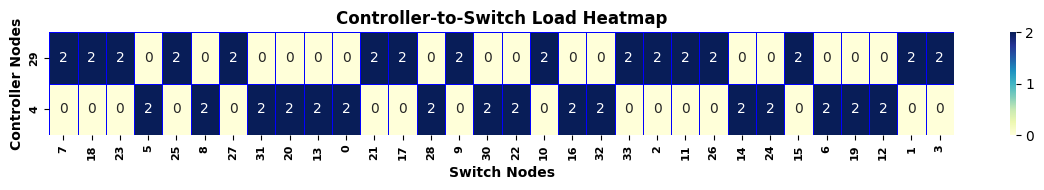

In [425]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming assigned_nodes_dict and selected_locations are already defined

# Flow rate (Kpps) of each switch
flow_rate = 2  

# List of controllers and switches
controllers = list(selected_locations)

# Create a sorted list of all switches
switches = list({switch for switches in location_to_switch_assignment.values() for switch in switches})

# Initialize the controller-to-switch matrix
location_to_switch_assignment_matrix = np.zeros((len(controllers), len(switches)))

# Populate the matrix with load values (flow_rate) where there is a connection
for j, controller in enumerate(controllers):
    for switch in location_to_switch_assignment[controller]:
        i = switches.index(switch)
        location_to_switch_assignment_matrix[j, i] = flow_rate  # Assign the load

# Print the controller-to-switch matrix
print("Controller-to-Switch Matrix with Load:")
print(location_to_switch_assignment_matrix)

# Plotting the controller-to-switch matrix as a heatmap
plt.figure(figsize=(12, 2))  # Adjust the figure size as needed

# Use sns.heatmap to create the heatmap with a color intensity bar
ax = sns.heatmap(location_to_switch_assignment_matrix, cmap="YlGnBu", cbar=True,
                 linewidths=0.5, linecolor='blue', annot=True, fmt='g',
                 xticklabels=switches, yticklabels=controllers)

# Set axis labels with bold font
plt.xlabel('Switch Nodes', fontsize=10, fontweight='bold')
plt.ylabel('Controller Nodes', fontsize=10, fontweight='bold')

# Set title with bold font
plt.title('Controller-to-Switch Load Heatmap', fontsize=12, fontweight='bold')

# Bold x and y tick labels
plt.xticks(rotation=90, fontsize=8, fontweight='bold')
plt.yticks(fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()


In [426]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example Data (Replace with actual data from your process)
heatmap_data = []
flow_type_data = []

# Generate heatmap_data and flow_type_data from updated location-to-switch assignments and load-capacity ratios
for loc, switches in location_to_switch_assignment.items():
    for switch in switches:
        # Assuming 'scaled_load' is Load/Capacity ratio for visualization purposes
        scaled_load = load_capacity_ratios[loc] if loc in load_capacity_ratios else 0
        heatmap_data.append({'Controller': loc, 'Switch': switch, 'Scaled Load': scaled_load})
        flow_type_data.append({'Switch': switch, 'Controller Type': 'A' if loc == '4' else 'B'})  # Example logic

# # Convert to DataFrame for heatmap
# df_heatmap = pd.DataFrame(heatmap_data)

# # Convert to DataFrame for switch types
# df_flow_types = pd.DataFrame(flow_type_data)

# # Step 4: Create the heatmap showing scaled load
# # Use pivot_table to restructure the DataFrame for heatmap visualization
# heatmap_df = df_heatmap.pivot_table(index='Controller', columns='Switch', values='Scaled Load', aggfunc='mean')

# # Plot the heatmap
# plt.figure(figsize=(12, 2))
# sns.heatmap(heatmap_df, annot=True, cmap='YlGnBu', linewidths=0.5, linecolor='black', annot_kws={"size": 6})
# plt.title("Total Scaled Load Heatmap", fontsize=14, fontweight='bold')
# plt.xlabel("Switch", fontsize=12, fontweight='bold')
# plt.ylabel("Controller", fontsize=12, fontweight='bold')

# # Embolden x and y axis tick labels
# plt.xticks(fontsize=10, fontweight='bold')
# plt.yticks(fontsize=10, fontweight='bold')
# plt.show()

# Step 5: Display the table of switch nodes and their types
print("Switch Nodes and Types:")
print(df_flow_types)

# # Step 6: Prepare the table for total scaled load per controller
# controller_total_scaled_load = df_heatmap.groupby('Controller')['Scaled Load'].sum().reset_index()
# controller_total_scaled_load.columns = ['Controller', 'Total Scaled Load']

# Step 7: Display the total scaled load for each controller
print("\nTotal Scaled Load per Controller:")
print(controller_total_scaled_load)

# # Calculate the sum of Total Scaled Load for all controllers
# total_scaled_load_sum = controller_total_scaled_load['Total Scaled Load'].sum()

# # Print the total scaled load sum
# print(f"\nTotal Scaled Load Sum for All Controllers: {total_scaled_load_sum}")


Switch Nodes and Types:
   Switch Type
0      12    m
1      30    e
2       6    e
3      21    e
4      23    e
5      11    m
6      27    e
7       9    e
8      33    m
9      25    e
10     17    m
11     16    e
12      2    e
13      1    e
14     18    m
15      5    e
16     14    e
17     13    e
18     22    m
19     20    m
20      0    e
21     28    e
22      8    e
23     31    m
24     10    e
25     26    m
26      7    e
27     19    e

Total Scaled Load per Controller:
  Controller  Total Scaled Load
0         15           4.900872
1         24           3.970323
2         29           7.113797
3          3           5.693454
4         32           4.888673
5          4           4.307220


In [ ]:
location_to_switch_assignment

{'29': ['1',
  '2',
  '3',
  '7',
  '9',
  '10',
  '11',
  '15',
  '17',
  '18',
  '21',
  '23',
  '25',
  '26',
  '27',
  '33'],
 '4': ['0',
  '5',
  '6',
  '8',
  '12',
  '13',
  '14',
  '16',
  '19',
  '20',
  '22',
  '24',
  '28',
  '30',
  '31',
  '32']}

In [428]:
#HOMOGENEOUS CAPACIATED CONTROLLER PLACEMENT 

from gurobipy import Model, GRB, quicksum
import numpy as np

# Assuming geo_loc_data and haversine function are defined
# geo_loc_data contains node names as keys and (latitude, longitude) as values
# haversine(node1, node2, geo_loc_data) calculates distance between two nodes

# Calculate latency matrix T_ij
all_nodes = list(geo_loc_data.keys())
n = len(all_nodes)
T_ij = np.zeros((n, n))

for i in range(n):
    for j in range(i + 1, n):
        node1, node2 = all_nodes[i], all_nodes[j]
        distance = haversine(node1, node2, geo_loc_data)
        latency = (distance * 1000) / (2 * 1e8)  # Latency in milliseconds

        T_ij[i][j] = latency
        T_ij[j][i] = latency  # Symmetric matrix

# Map nodes to indices
node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}

# Inputs
C = [1200, 2500, 6500, 12000]  # Prices of controller types
mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types
flow_rate = 2                  # Flow rate (Kpps) of each switch

# Define `K` (indices of selected candidate controllers)
K = [node_to_idx[node] for node in controllers]  # Ensure controllers is defined
m = len(K)  # Number of selected controller candidates
switch_nodes = [node for node in all_nodes if node not in controllers]
switch_indices = [node_to_idx[node] for node in switch_nodes]  # Indices of switch nodes
P = len(C)  # Number of controller types

# Calculate C_max for normalization
C_max = len(switch_nodes) * max(C)

# Calculate T_max as the sum of all latencies in the T_ij matrix
T_max = np.sum(T_ij)

# Coefficients for objective function (adjust weights for cost and latency)
alpha = 0.4  # Weight for cost minimization
beta = 0.3  # Weight for switch-to-controller latency minimization
gamma = 0.3  # Weight for controller-to-controller latency minimization

# Create the model
model = Model("Controller_Assignment")

# Decision variables
Y = model.addVars(P, m, vtype=GRB.BINARY, name="Y")  # Controller type placement
D = model.addVars(len(switch_nodes), m, vtype=GRB.BINARY, name="D")  # Switch-to-controller assignment

# Objective function terms
cost_term = quicksum(C[k] * Y[k, j] for k in range(P) for j in range(m))
latency_term = quicksum(T_ij[switch_indices[i], K[j]] * D[i, j] for i in range(len(switch_nodes)) for j in range(m))
controller_to_controller_latency_term = quicksum(
    T_ij[K[j1], K[j2]] * Y[k1, j1] * Y[k2, j2] 
    for k1 in range(P) for j1 in range(m) 
    for k2 in range(P) for j2 in range(m) if j1 < j2
)

# Set the objective function
model.setObjective(
    (alpha / C_max) * cost_term +
    (beta / T_max) * latency_term +
    (gamma / T_max) * controller_to_controller_latency_term,
    GRB.MINIMIZE
)

# Constraints
# 1. Each selected location can host at most one type of controller
for j in range(m):
    model.addConstr(quicksum(Y[k, j] for k in range(P)) <= 1, name=f"Location_{j}_One_Controller")

# 2. Each switch must be assigned to exactly one controller
for i in range(len(switch_nodes)):
    model.addConstr(quicksum(D[i, j] for j in range(m)) == 1, name=f"Switch_{i}_Assigned_To_One_Controller")

# 3. Switches can only be assigned to active controllers
for i in range(len(switch_nodes)):
    for j in range(m):
        model.addConstr(D[i, j] <= quicksum(Y[k, j] for k in range(P)), name=f"Switch_{i}_To_Active_Controller_{j}")

# 4. Controller capacity must not be exceeded
for j in range(m):
    model.addConstr(
        quicksum(flow_rate * D[i, j] for i in range(len(switch_nodes))) <= quicksum(mu[k] * Y[k, j] for k in range(P)),
        name=f"Controller_Capacity_{j}"
    )
    

# Add min_capacity and max_capacity constraints
# min_capacity = 0.80  # Minimum load capacity ratio
max_capacity = 0.30  # Maximum load capacity ratio

for j in range(m):  # For each controller location
    # Corrected range to match `D` dimensions
    load = quicksum(flow_rate * D[i, j] for i in range(len(switch_nodes)))
    capacity = quicksum(mu[k] * Y[k, j] for k in range(P))
    
    # # Ensure capacity > 0 before applying constraints
    # model.addConstr(
    #     load >= min_capacity * capacity,
    #     name=f"Min_Capacity_Ratio_Controller_{j}"
    # )
    model.addConstr(
        load <= max_capacity * capacity,
        name=f"Max_Capacity_Ratio_Controller_{j}"
    )

# Solve the model
model.optimize()

if model.status == GRB.OPTIMAL:
    print(f"Optimal Objective Value: {model.objVal}")

    # Determine optimal locations
    optimal_locations = [all_nodes[K[j]] for j in range(m) if any(Y[k, j].x > 0.5 for k in range(P))]
    print(f"Optimal Locations: {optimal_locations}")

    # Switch assignments to controllers
    switch_assignments = {}
    for i, switch in enumerate(switch_nodes):
        assigned_controller_idx = next(j for j in range(m) if D[i, j].x > 0.5)
        assigned_controller = all_nodes[K[assigned_controller_idx]]
        switch_assignments[switch] = assigned_controller

   

    # Find remaining nodes in K
    remaining_nodes = [all_nodes[K[j]] for j in range(m) if all(Y[k, j].x <= 0.5 for k in range(P))]

    # Reassign remaining nodes as switches
    reassigned_switch_assignments = {}
    for node in remaining_nodes:
        node_idx = node_to_idx[node]
        closest_controller = min(
            optimal_locations,
            key=lambda loc: T_ij[node_idx, node_to_idx[loc]]
        )
        reassigned_switch_assignments[node] = closest_controller

if model.status == GRB.OPTIMAL:
    print(f"Optimal Objective Value: {model.objVal}")

    # Determine optimal and unselected locations
    selected_locations = [all_nodes[K[j]] for j in range(m) if any(Y[k, j].x > 0.5 for k in range(P))]
    unselected_locations = [all_nodes[K[j]] for j in range(m) if all(Y[k, j].x <= 0.5 for k in range(P))]

    print(f"Selected Locations (Optimal): {selected_locations}")
    print(f"Unselected Locations (To Be Reassigned as Switches): {unselected_locations}")

    # Assign switches to locations
    location_to_switch_assignment = {loc: [] for loc in selected_locations}

    # Assign initially
    for i, switch in enumerate(switch_nodes):
        assigned_location = None
        for j in range(m):
            if D[i, j].x > 0.5:
                assigned_location = all_nodes[K[j]]
                break
        if assigned_location:
            location_to_switch_assignment[assigned_location].append(switch)

    # Reassign unselected locations as switches
    for unselected_loc in unselected_locations:
        node_idx = node_to_idx[unselected_loc]
        closest_location = min(
            selected_locations,
            key=lambda loc: T_ij[node_idx, node_to_idx[loc]]
        )
        location_to_switch_assignment[closest_location].append(unselected_loc)

    # Print updated location-to-switch assignments
    print("\nUpdated Location-to-Switch Assignments After Reassignment:")
    for location, switches in location_to_switch_assignment.items():
        print(f"Location {location}: {switches}")



Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11.0 (22621.2))

CPU model: Intel(R) Core(TM) i7-8565U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 102 rows, 72 columns and 536 nonzeros
Model fingerprint: 0x34751904
Model has 16 quadratic objective terms
Variable types: 0 continuous, 72 integer (72 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [3e-05, 1e-02]
  QObjective range [7e-04, 7e-04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 98 rows and 32 columns
Presolve time: 0.00s
Presolved: 20 rows, 56 columns, 126 nonzeros
Variable types: 0 continuous, 56 integer (56 binary)
Found heuristic solution: objective 0.0242548

Root relaxation: objective 2.234001e-02, 8 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl 

In [429]:
from collections import defaultdict


def calculate_load_capacity_ratio(location, switches, flow_rate, mu, Y, K, m, P, all_nodes):
    total_load = len(switches) * flow_rate  # Calculate total load for the location
    selected_capacity = 0
    selected_controller_type = None

    # Find the assigned controller type and its capacity
    for j in range(m):
        if all_nodes[K[j]] == location:
            for k in range(P):
                if Y[k, j].x > 0.5:
                    selected_controller_type = k
                    selected_capacity = mu[k]
                    break
            break

    # Calculate the load-to-capacity ratio
    if selected_capacity > 0:
        load_capacity_ratio = total_load / selected_capacity
        return load_capacity_ratio, selected_controller_type, selected_capacity
    return None, None, None

def calculate_switch_to_controller_latency(location_to_switch_assignment, selected_locations, T_ij, node_to_idx):
    total_switch_to_controller_latency = 0.0
    for location in selected_locations:
        for switch in location_to_switch_assignment.get(location, []):
            switch_idx = node_to_idx[switch]
            controller_idx = node_to_idx[location]  # Assuming location is assigned a controller node
            total_switch_to_controller_latency += T_ij[switch_idx, controller_idx]
    return total_switch_to_controller_latency

def calculate_controller_to_controller_latency(selected_locations, T_ij, node_to_idx):
    total_controller_to_controller_latency = 0.0
    for i, location1 in enumerate(selected_locations):
        for j, location2 in enumerate(selected_locations):
            if i < j:  # Avoid double counting
                controller1_idx = node_to_idx[location1]
                controller2_idx = node_to_idx[location2]
                total_controller_to_controller_latency += T_ij[controller1_idx, controller2_idx]
    return total_controller_to_controller_latency

# Balancing reassignment logic
location_to_switch_assignment = defaultdict(list)  # Updated to default dictionary

# Initial assignment of switches to selected locations
for i, switch in enumerate(switch_nodes):
    assigned_location = None
    for j in range(m):
        if D[i, j].x > 0.5:
            assigned_location = all_nodes[K[j]]
            break
    if assigned_location:
        location_to_switch_assignment[assigned_location].append(switch)

# Balance assignment for unselected locations
for unselected_loc in unselected_locations:
    node_idx = node_to_idx[unselected_loc]
    
    # Find the location with the fewest switches that is closest
    closest_location = min(
        selected_locations,
        key=lambda loc: (
            T_ij[node_idx, node_to_idx[loc]],  # First prioritize minimum distance
            len(location_to_switch_assignment[loc])  # Then prioritize fewer assignments
        )
    )
    location_to_switch_assignment[closest_location].append(unselected_loc)

# Rebalance assignments to minimize imbalance
all_switches = list(location_to_switch_assignment.items())
while True:
    max_location, max_switches = max(all_switches, key=lambda x: len(x[1]))
    min_location, min_switches = min(all_switches, key=lambda x: len(x[1]))
    
    # Check if balancing is needed
    if len(max_switches) - len(min_switches) <= 1:
        break  # Balancing complete
    
    # Move one switch from the max_location to the min_location
    switch_to_move = max_switches.pop()
    min_switches.append(switch_to_move)

# Convert back to a regular dictionary for final result
location_to_switch_assignment = dict(location_to_switch_assignment)

# Print updated location-to-switch assignments
print("\nBalanced Location-to-Switch Assignments:")
for location, switches in location_to_switch_assignment.items():
    print(f"Location {location}: {switches}")

def calculate_total_cost_and_load_imbalance(location_to_switch_assignment, flow_rate, mu, controller_type_names, C):
    # Step 1: Calculate the maximum total load across all locations
    max_total_load = max(len(switches) * flow_rate for switches in location_to_switch_assignment.values())

    # Step 2: Select the single controller type that can handle the maximum total load
    selected_controller_type = None
    selected_capacity = None
    selected_cost = None

    for controller_type, capacity in enumerate(mu):
        if capacity >= max_total_load:
            selected_controller_type = controller_type
            selected_capacity = capacity
            selected_cost = C[controller_type]
            break  # Stop at the first suitable controller type

    if selected_controller_type is None:
        print("Error: No controller type can handle the maximum total load.")
        return None, None, None

    # Step 3: Calculate the total cost
    total_cost = selected_cost * len(location_to_switch_assignment)

    # Step 4: Print load, capacity, ratio, and controller type for each location
    load_capacity_ratios = []
    for location, switches in location_to_switch_assignment.items():
        total_load = len(switches) * flow_rate
        load_capacity_ratio = total_load / selected_capacity
        load_capacity_ratios.append(load_capacity_ratio)
        print(f"Location {location}: Load = {total_load}, Capacity = {selected_capacity}, "
              f"Load_Capacity_Ratio = {load_capacity_ratio:.2f} "
              f"(Controller Type {controller_type_names[selected_controller_type]})")

    # Step 5: Calculate max, min, and load imbalance
    max_load_capacity_ratio = max(load_capacity_ratios)
    min_load_capacity_ratio = min(load_capacity_ratios)
    load_imbalance = ((max_load_capacity_ratio - min_load_capacity_ratio) / max_load_capacity_ratio) * 100

    # Print results
    print("\nLoad Imbalance Calculations:")
    print(f"Max Load Capacity Ratio: {max_load_capacity_ratio:.2f}")
    print(f"Min Load Capacity Ratio: {min_load_capacity_ratio:.2f}")
    print(f"Load Imbalance: {load_imbalance:.2f}%")

    print(f"\nTotal Cost: {total_cost}")
    return selected_controller_type, total_cost, load_imbalance

controller_type_names = ['A', 'B', 'C', 'D']

# Call the function
selected_controller_type, total_cost, load_imbalance = calculate_total_cost_and_load_imbalance(
    location_to_switch_assignment, flow_rate, mu, controller_type_names, C
)


# Print overloaded controllers and the excess load
print("\nOverloaded Controllers and Excess Load:")
any_overloaded = False
for location, switches in location_to_switch_assignment.items():
    total_load = len(switches) * flow_rate  # Calculate total load for the location
    selected_capacity = 0

    # Find the assigned controller's capacity
    for j in range(m):
        if all_nodes[K[j]] == location:
            for k in range(P):
                if Y[k, j].x > 0.5:
                    selected_capacity = mu[k]
                    break
            break

    # Check overload condition (only for max_capacity)
    if selected_capacity > 0:
        load_to_capacity_ratio = total_load / selected_capacity
        if load_to_capacity_ratio > 1:
            excess_load = total_load - selected_capacity
            print(f"Location {location}: Exceeds Maximum Capacity. Excess Load = {excess_load:.2f}")
            any_overloaded = True

if not any_overloaded:
    print("No controller's capacity is exceeded.")

# Calculate total latencies
total_switch_to_controller_latency = calculate_switch_to_controller_latency(location_to_switch_assignment, selected_locations, T_ij, node_to_idx)
print(f"Total Switch-to-Controller Latency: {total_switch_to_controller_latency}")

total_controller_to_controller_latency = calculate_controller_to_controller_latency(selected_locations, T_ij, node_to_idx)
print(f"Total Controller-to-Controller Latency: {total_controller_to_controller_latency}")



Balanced Location-to-Switch Assignments:
Location 4: ['0', '5', '6', '8', '13', '14', '20', '22', '24', '28', '31', '32', '33', '30', '27', '26']
Location 29: ['1', '2', '3', '7', '9', '10', '11', '12', '15', '16', '17', '18', '19', '21', '23', '25']
Location 4: Load = 32, Capacity = 40, Load_Capacity_Ratio = 0.80 (Controller Type B)
Location 29: Load = 32, Capacity = 40, Load_Capacity_Ratio = 0.80 (Controller Type B)

Load Imbalance Calculations:
Max Load Capacity Ratio: 0.80
Min Load Capacity Ratio: 0.80
Load Imbalance: 0.00%

Total Cost: 5000

Overloaded Controllers and Excess Load:
No controller's capacity is exceeded.
Total Switch-to-Controller Latency: 0.1897158643224855
Total Controller-to-Controller Latency: 0.01225899323213097


In [ ]:

#Ensure location_switch_allocations keys and values are strings
location_switch_allocations = {
    str(location): [str(node) for node in nodes]
    for location, nodes in location_to_switch_assignment.items()
}

# Prepare the list of updated controllers
updated_controllers = list(location_to_switch_assignment.keys())
print("Updated Controllers:")
print(updated_controllers)

# Initialize a dictionary to store latency results for each controller
latency_results = {}

# Variables to compute aggregate latencies
total_average_latency = 0
max_worst_case_latency = float('-inf')

# Variables for controller-to-controller latency calculations
total_controller_latency = 0
controller_pairs = 0
max_pairwise_worst_case_latency = float('-inf')

# Calculate latencies for each controller to assigned nodes
for location, assigned_nodes in location_to_switch_assignment.items():
    total_latency = 0
    worst_case_latency = float('-inf')

    for node in assigned_nodes:
        try:
            # Calculate the shortest path length (latency) between the location and the node
            latency = nx.shortest_path_length(G, source=location, target=node, weight='weight')
            
            # Convert latency to milliseconds
            latency_ms = (latency * 1000) / (2 * 1e8)  # Adjust formula if necessary
            
            # Update the cumulative and worst-case latencies
            total_latency += latency_ms
            worst_case_latency = max(worst_case_latency, latency_ms)
        except nx.NetworkXNoPath:
            print(f"No path found between location {location} and node {node}. Skipping latency calculation.")

    # Calculate average latency for this controller
    average_latency = total_latency / len(assigned_nodes) if assigned_nodes else 0
    total_average_latency += average_latency  # Add to total average latency sum

    # Update the maximum worst-case latency across all controllers
    max_worst_case_latency = max(max_worst_case_latency, worst_case_latency)

    # Store the latencies for this location
    latency_results[location] = {
        'average_latency': average_latency,
        'worst_case_latency': worst_case_latency
    }


# Compute latencies between controllers
for i, controller1 in enumerate(updated_controllers):
    for j, controller2 in enumerate(updated_controllers):
        if i < j:  # Avoid duplicate calculations for pairs
            try:
                # Calculate shortest path length between two controllers
                pairwise_latency = nx.shortest_path_length(G, source=controller1, target=controller2, weight='weight')
                pairwise_latency_ms = (pairwise_latency * 1000) / (2 * 1e8)  # Adjust formula if necessary

                # Accumulate total controller-to-controller latency
                total_controller_latency += pairwise_latency_ms
                controller_pairs += 1

                # Update the maximum pairwise worst-case latency
                max_pairwise_worst_case_latency = max(max_pairwise_worst_case_latency, pairwise_latency_ms)
            except nx.NetworkXNoPath:
                print(f"No path found between controllers {controller1} and {controller2}. Skipping latency calculation.")

# Calculate the average controller-to-controller latency
average_controller_latency = total_controller_latency / controller_pairs if controller_pairs > 0 else 0

# Consolidate the results for the current percentage
latency_results_per_percentage[percentage] = {
    'average_controller_latency': average_controller_latency,
    'max_pairwise_worst_case_latency': max_pairwise_worst_case_latency,
    'total_average_latency': total_average_latency,
    'max_worst_case_latency': max_worst_case_latency,
    'controller_latencies': latency_results
}

# Display results
print(f"\nAverage Controller-to-Controller Latency = {average_controller_latency:.15f} ms")
print(f"Maximum Pairwise Worst-Case Latency = {max_pairwise_worst_case_latency:.15f} ms")
print(f"\nTotal Average Node to Controller Latency = {total_average_latency:.15f} ms")
print(f"Maximum Worst-Case Node to Controller Latency = {max_worst_case_latency:.15f} ms")


Updated Controllers:
['4', '29']

Average Controller-to-Controller Latency = 0.000119230000000 ms
Maximum Pairwise Worst-Case Latency = 0.000119230000000 ms

Total Average Node to Controller Latency = 0.000124584375000 ms
Maximum Worst-Case Node to Controller Latency = 0.000152275000000 ms


In [431]:

# from gurobipy import Model, GRB, quicksum
# import numpy as np

# # Assuming geo_loc_data and haversine function are defined
# # geo_loc_data contains node names as keys and (latitude, longitude) as values
# # haversine(node1, node2, geo_loc_data) calculates distance between two nodes

# # Calculate latency matrix T_ij
# all_nodes = list(geo_loc_data.keys())
# n = len(all_nodes)
# T_ij = np.zeros((n, n))

# for i in range(n):
#     for j in range(i + 1, n):
#         node1, node2 = all_nodes[i], all_nodes[j]
#         distance = haversine(node1, node2, geo_loc_data)
#         latency = (distance * 1000) / (2 * 1e8)  # Latency in milliseconds

#         T_ij[i][j] = latency
#         T_ij[j][i] = latency  # Symmetric matrix

# # Map nodes to indices
# node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}

# # Inputs
# C = [1200, 2500, 6500, 12000]  # Prices of controller types
# mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types
# flow_rate = 2                  # Flow rate (Kpps) of each switch
# # controllers = ['24', '29', '15', '32', '21', '4', '3']  # Example controller nodes
# controllers = K
# switch_nodes = set(all_nodes) - set(controllers)        # Switch nodes
# P = len(C)  # Number of controller types

# # Create the model
# model = Model("Controller_Assignment")

# # Decision variables
# x = {}  # x[i, j] = 1 if controller i is assigned to controller type j
# y = {}  # y[k, i] = 1 if switch k is assigned to controller i

# for i in range(len(controllers)):
#     for j in range(P):
#         x[i, j] = model.addVar(vtype=GRB.BINARY, name=f"x_{controllers[i]}_{j}")

# for k in switch_nodes:
#     for i in range(len(controllers)):
#         y[k, i] = model.addVar(vtype=GRB.BINARY, name=f"y_{k}_{controllers[i]}")

# # Constraints

# # Capacity constraint (controllers cannot exceed their capacity)
# for i in range(len(controllers)):
#     model.addConstr(
#         quicksum(flow_rate * y[k, i] for k in switch_nodes) <= 
#         quicksum(mu[j] * x[i, j] for j in range(P)),
#         name=f"Capacity_{controllers[i]}"
#     )

# # Assignment constraint (each controller is assigned one type)
# for i in range(len(controllers)):
#     model.addConstr(
#         quicksum(x[i, j] for j in range(P)) == 1,
#         name=f"Assignment_{controllers[i]}"
#     )

# # Switch assignment constraint (each switch is assigned to exactly one controller)
# for k in switch_nodes:
#     model.addConstr(
#         quicksum(y[k, i] for i in range(len(controllers))) == 1,
#         name=f"Switch_Assignment_{k}"
#     )


# # Switches can only be assigned to active controllers
# for k in switch_nodes:
#     for i in range(len(controllers)):
#         model.addConstr(
#             y[k, i] <= quicksum(x[i, j] for j in range(P)),
#             name=f"Switch_Assignment_to_Active_Controller_{k}_{controllers[i]}"
#         )


# # # Objective: Minimize total cost (controller cost + assignment cost)
# # assignment_cost = quicksum(
# #     T_ij[node_to_idx[k], node_to_idx[controllers[i]]] * y[k, i]
# #     for k in switch_nodes
# #     for i in range(len(controllers))
# # )


# # Average latency calculation
# num_assignments = len(switch_nodes)
# assignment_cost = quicksum(
#     T_ij[node_to_idx[k], node_to_idx[controllers[i]]] * y[k, i]
#     for k in switch_nodes
#     for i in range(len(controllers))
# ) / num_assignments


# controller_cost = quicksum(
#     C[j] * x[i, j]
#     for i in range(len(controllers))
#     for j in range(P)
# )

# model.setObjective(controller_cost + assignment_cost, GRB.MINIMIZE)

# # Optimize the model
# model.optimize()

# # Create solution dictionary
# solution_dict = {}

# if model.status == GRB.OPTIMAL:
#     print("Optimal Assignment of Controller Types and Switches:")
#     total_cost = 0
#     for i in range(len(controllers)):
#         for j in range(P):
#             if x[i, j].x > 0.5:  # Controller type assignment
#                 controller_id = controllers[i]
#                 type_name = chr(65 + j)  # A, B, C, etc.
#                 capacity = mu[j]
#                 cost = C[j]
#                 solution_dict[controller_id] = {
#                     'type': type_name,
#                     'capacity': capacity,
#                     'cost': cost,
#                     'switches': []
#                 }
#                 total_cost += cost

#     for k in switch_nodes:
#         for i in range(len(controllers)):
#             if y[k, i].x > 0.5:  # Switch assignment
#                 solution_dict[controllers[i]]['switches'].append(k)

#     for controller, details in solution_dict.items():
#         print(f"Controller {controller} -> Type {details['type']} | Capacity {details['capacity']} | Cost {details['cost']} | Switches: {details['switches']}")
#     print(f"\nTotal Cost: {total_cost}")
# else:
#     print("No optimal solution found.")


In [ ]:

from gurobipy import Model, GRB, quicksum
import numpy as np

# Assuming geo_loc_data and haversine function are defined
# geo_loc_data contains node names as keys and (latitude, longitude) as values
# haversine(node1, node2, geo_loc_data) calculates distance between two nodes

# Calculate latency matrix T_ij
all_nodes = list(geo_loc_data.keys())
n = len(all_nodes)
T_ij = np.zeros((n, n))

for i in range(n):
    for j in range(i + 1, n):
        node1, node2 = all_nodes[i], all_nodes[j]
        distance = haversine(node1, node2, geo_loc_data)
        latency = (distance * 1000) / (2 * 1e8)  # Latency in milliseconds

        T_ij[i][j] = latency
        T_ij[j][i] = latency  # Symmetric matrix

# Map nodes to indices
node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}

# Inputs
C = [1200, 2500, 6500, 12000]  # Prices of controller types
mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types
flow_rate = 2                  # Flow rate (Kpps) of each switch

# Define `K` (indices of selected candidate controllers)
K = [node_to_idx[node] for node in controllers]  # Ensure controllers is defined
m = len(K)  # Number of selected controller candidates
switch_nodes = [node for node in all_nodes if node not in controllers]
switch_indices = [node_to_idx[node] for node in switch_nodes]  # Indices of switch nodes
P = len(C)  # Number of controller types

# Calculate C_max for normalization
C_max = len(switch_nodes) * max(C)

# Calculate T_max as the sum of all latencies in the T_ij matrix
T_max = np.sum(T_ij)

# Coefficients for objective function (adjust weights for cost and latency)
alpha = 0.4  # Weight for cost minimization
beta = 0.3  # Weight for switch-to-controller latency minimization
gamma = 0.3  # Weight for controller-to-controller latency minimization

# Create the model
model = Model("Controller_Assignment")

# Decision variables
Y = model.addVars(P, m, vtype=GRB.BINARY, name="Y")  # Controller type placement
D = model.addVars(len(switch_nodes), m, vtype=GRB.BINARY, name="D")  # Switch-to-controller assignment

# Objective function terms
cost_term = quicksum(C[k] * Y[k, j] for k in range(P) for j in range(m))
latency_term = quicksum(T_ij[switch_indices[i], K[j]] * D[i, j] for i in range(len(switch_nodes)) for j in range(m))
controller_to_controller_latency_term = quicksum(
    T_ij[K[j1], K[j2]] * Y[k1, j1] * Y[k2, j2] 
    for k1 in range(P) for j1 in range(m) 
    for k2 in range(P) for j2 in range(m) if j1 < j2
)

# Set the objective function
model.setObjective(
    (alpha / C_max) * cost_term +
    (beta / T_max) * latency_term +
    (gamma / T_max) * controller_to_controller_latency_term,
    GRB.MINIMIZE
)

# Constraints
# 1. Each selected location can host at most one type of controller
for j in range(m):
    model.addConstr(quicksum(Y[k, j] for k in range(P)) <= 1, name=f"Location_{j}_One_Controller")

# 2. Each switch must be assigned to exactly one controller
for i in range(len(switch_nodes)):
    model.addConstr(quicksum(D[i, j] for j in range(m)) == 1, name=f"Switch_{i}_Assigned_To_One_Controller")

# 3. Switches can only be assigned to active controllers
for i in range(len(switch_nodes)):
    for j in range(m):
        model.addConstr(D[i, j] <= quicksum(Y[k, j] for k in range(P)), name=f"Switch_{i}_To_Active_Controller_{j}")

# 4. Controller capacity must not be exceeded
for j in range(m):
    model.addConstr(
        quicksum(flow_rate * D[i, j] for i in range(len(switch_nodes))) <= quicksum(mu[k] * Y[k, j] for k in range(P)),
        name=f"Controller_Capacity_{j}"
    )


# Add min_capacity and max_capacity constraints
min_capacity = 0.70  # Minimum load capacity ratio
max_capacity = 0.80  # Maximum load capacity ratio

for j in range(m):  # For each controller location
    # Corrected range to match `D` dimensions
    load = quicksum(flow_rate * D[i, j] for i in range(len(switch_nodes)))
    capacity = quicksum(mu[k] * Y[k, j] for k in range(P))
    
    # Ensure capacity > 0 before applying constraints
    model.addConstr(
        load >= min_capacity * capacity,
        name=f"Min_Capacity_Ratio_Controller_{j}"
    )
    model.addConstr(
        load <= max_capacity * capacity,
        name=f"Max_Capacity_Ratio_Controller_{j}"
    )


# Solve the model
model.optimize()

if model.status == GRB.OPTIMAL:
    print(f"Optimal Objective Value (Normalized): {model.objVal}")
    total_cost = 0
    total_latency = 0
    total_controller_latency = 0

    controller_type_names = ['A', 'B', 'C', 'D']  # Mapping of controller types

    load_capacity_ratios = {}  # To store load-to-capacity ratios for load imbalance calculation
    location_switch_assignments = {}  # To store switch assignments per location



    for k in range(P):
        for j in range(m):
            if Y[k, j].x > 0.5:  # Controller type `k` is placed at location `j`
                location = all_nodes[K[j]]
                switches_managed = [
                    all_nodes[switch_indices[i]] for i in range(len(switch_nodes)) 
                    if D[i, j].x > 0.5
                ]

                load = sum(flow_rate for switch in switches_managed)  # Total load on the controller
                capacity = mu[k]  # Capacity of the controller type
                
                # Calculate the load-to-capacity ratio
                load_capacity_ratio = load / capacity if capacity > 0 else 0.0
                load_capacity_ratios[location] = load_capacity_ratio
                
                print(
                    # f"Controller of type {controller_type_names[k]} at location {location}: "
                    f"Load = {load}, Capacity = {capacity}, "
                    f"Load_Capacity_Ratio = {load_capacity_ratio:.2f}"
                )


                # Add to the `location_switch_assignments` dictionary
                location_name = all_nodes[K[j]]
                location_switch_assignments[location_name] = switches_managed


                if switches_managed:
                    print(f"Controller of type {controller_type_names[k]} at location {all_nodes[K[j]]} manages switches: {switches_managed}")
                total_cost += C[k]
                total_latency += sum(T_ij[node_to_idx[switch], K[j]] for switch in switches_managed)

    # Print the `location_switch_assignments`
    print("\nLocation-to-Switch Assignments:")
    for location, switches in location_switch_assignments.items():
        print(f"Location {location}: {switches}")


    for k1 in range(P):
        for j1 in range(m):
            if Y[k1, j1].x > 0.5:
                for k2 in range(P):
                    for j2 in range(m):
                        if Y[k2, j2].x > 0.5 and j1 < j2:
                            total_controller_latency += T_ij[K[j1], K[j2]]

    print(f"\nTotal cost of controllers: {total_cost}")
    print(f"Total switch-to-controller latency: {total_latency}")
    print(f"Total controller-to-controller latency: {total_controller_latency}")

    # Calculate and store load imbalance for the current configuration
    if load_capacity_ratios:
        max_load_ratio = max(load_capacity_ratios.values())
        min_load_ratio = min(load_capacity_ratios.values())
        load_imbalance = ((max_load_ratio - min_load_ratio) / max_load_ratio) * 100 if max_load_ratio != 0 else 0.0
        
        print("\n--------------------------------------")
        print(f"Load Imbalance: {load_imbalance:.2f}%")
        print(f"Overall Max Load Capacity Ratio = {max_load_ratio:.2f}")
        print(f"Overall Min Load Capacity Ratio = {min_load_ratio:.2f}")


else:
    print("No feasible solution found.")



# # Prepare the list of updated controllers
# updated_controllers = list(location_switch_assignments.keys())
# print("Updated Controllers:")
# print(updated_controllers)

# # Initialize a dictionary to store latency results for each controller
# latency_results = {}

# # Variables to compute aggregate latencies
# total_average_latency = 0
# max_worst_case_latency = float('-inf')

# # Variables for controller-to-controller latency calculations
# total_controller_latency = 0
# controller_pairs = 0
# max_pairwise_worst_case_latency = float('-inf')

# # Calculate latencies for each controller to assigned nodes
# for location, assigned_nodes in location_switch_assignments.items():
#     total_latency = 0
#     worst_case_latency = float('-inf')

#     for node in assigned_nodes:
#         try:
#             # Calculate the shortest path length (latency) between the location and the node
#             latency = nx.shortest_path_length(G, source=location, target=node, weight='weight')
            
#             # Convert latency to milliseconds
#             latency_ms = (latency * 1000) / (2 * 1e8)  # Adjust formula if necessary
            
#             # Update the cumulative and worst-case latencies
#             total_latency += latency_ms
#             worst_case_latency = max(worst_case_latency, latency_ms)
#         except nx.NetworkXNoPath:
#             print(f"No path found between location {location} and node {node}. Skipping latency calculation.")

#     # Calculate average latency for this controller
#     average_latency = total_latency / len(assigned_nodes) if assigned_nodes else 0
#     total_average_latency += average_latency  # Add to total average latency sum

#     # Update the maximum worst-case latency across all controllers
#     max_worst_case_latency = max(max_worst_case_latency, worst_case_latency)

#     # Store the latencies for this location
#     latency_results[location] = {
#         'average_latency': average_latency,
#         'worst_case_latency': worst_case_latency
#     }

# # Compute latencies between controllers
# for i, controller1 in enumerate(updated_controllers):
#     for j, controller2 in enumerate(updated_controllers):
#         if i < j:  # Avoid duplicate calculations for pairs
#             try:
#                 # Calculate shortest path length between two controllers
#                 pairwise_latency = nx.shortest_path_length(G, source=controller1, target=controller2, weight='weight')
#                 pairwise_latency_ms = (pairwise_latency * 1000) / (2 * 1e8)  # Adjust formula if necessary

#                 # Accumulate total controller-to-controller latency
#                 total_controller_latency += pairwise_latency_ms
#                 controller_pairs += 1

#                 # Update the maximum pairwise worst-case latency
#                 max_pairwise_worst_case_latency = max(max_pairwise_worst_case_latency, pairwise_latency_ms)
#             except nx.NetworkXNoPath:
#                 print(f"No path found between controllers {controller1} and {controller2}. Skipping latency calculation.")

# # Calculate the average controller-to-controller latency
# average_controller_latency = total_controller_latency / controller_pairs if controller_pairs > 0 else 0

# # Consolidate the results for the current percentage
# latency_results_per_percentage[percentage] = {
#     'average_controller_latency': average_controller_latency,
#     'max_pairwise_worst_case_latency': max_pairwise_worst_case_latency,
#     'total_average_latency': total_average_latency,
#     'max_worst_case_latency': max_worst_case_latency,
#     'controller_latencies': latency_results
# }

# # Display results
# print(f"\nAverage Controller-to-Controller Latency = {average_controller_latency:.15f} ms")
# print(f"Maximum Pairwise Worst-Case Latency = {max_pairwise_worst_case_latency:.15f} ms")
# print(f"\nTotal Average Node to Controller Latency = {total_average_latency:.15f} ms")
# print(f"Maximum Worst-Case Node to Controller Latency = {max_worst_case_latency:.15f} ms")



Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11.0 (22621.2))

CPU model: Intel(R) Core(TM) i7-8565U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 104 rows, 72 columns and 608 nonzeros
Model fingerprint: 0xa2fcb98f
Model has 16 quadratic objective terms
Variable types: 0 continuous, 72 integer (72 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [3e-05, 1e-02]
  QObjective range [7e-04, 7e-04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 32 rows and 34 columns
Presolve time: 0.00s
Presolved: 81 rows, 47 columns, 499 nonzeros
Variable types: 0 continuous, 47 integer (47 binary)
Found heuristic solution: objective 0.0106605

Root relaxation: objective 1.033861e-02, 9 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl 

In [433]:
# After solving the optimization model...
if model.status == GRB.OPTIMAL:
    print(f"Optimal Objective Value (Normalized): {model.objVal}")

    # Store location-switch assignments
    location_switch_assignments = {}

    # Prepare to store unselected locations
    unselected_locations = []

    for k in range(P):
        for j in range(m):
            if Y[k, j].x > 0.5:  # Controller type `k` is placed at location `j`
                location_name = all_nodes[K[j]]
                switches_managed = [
                    all_nodes[switch_indices[i]] for i in range(len(switch_nodes))
                    if D[i, j].x > 0.5
                ]

                # Add switches to location
                location_switch_assignments[location_name] = switches_managed

    # Identify unselected locations
    all_selected_locations = list(location_switch_assignments.keys())
    unselected_locations = [node for node in controllers if node not in all_selected_locations]

    print("Selected Locations (Optimal):", all_selected_locations)
    print("Unselected Locations (To Be Reassigned as Switches):", unselected_locations)

    # Reassignment logic for unselected locations as switches
    for unselected in unselected_locations:
        unselected_idx = node_to_idx[unselected]

        # Find the closest selected location to the unselected location
        closest_location = None
        min_latency = float("inf")

        for selected_loc in all_selected_locations:
            selected_idx = node_to_idx[selected_loc]
            latency = T_ij[unselected_idx][selected_idx]

            if latency < min_latency:
                min_latency = latency
                closest_location = selected_loc

        # Reassign the unselected location as a switch to the closest optimal location
        if closest_location:
            location_switch_assignments[closest_location].append(unselected)

    # Print the updated location-to-switch assignments
    print("\nUpdated Location-to-Switch Assignments After Reassignment:")
    for location, switches in location_switch_assignments.items():
        print(f"Location {location}: {switches}")
else:
    print("No feasible solution found.")


Optimal Objective Value (Normalized): 0.010338609247962267
Selected Locations (Optimal): ['29', '4']
Unselected Locations (To Be Reassigned as Switches): []

Updated Location-to-Switch Assignments After Reassignment:
Location 29: ['1', '2', '3', '7', '9', '10', '11', '15', '17', '18', '21', '23', '25', '26', '27', '33']
Location 4: ['0', '5', '6', '8', '12', '13', '14', '16', '19', '20', '22', '24', '28', '30', '31', '32']


In [ ]:
# Step 1: Identify selected locations
selected_locations = [all_nodes[K[j]] for j in range(m) for k in range(P) if Y[k, j].x > 0.5]
unselected_locations = [node for node in [all_nodes[idx] for idx in K] if node not in selected_locations]

print("\nSelected Locations (Optimal):", selected_locations)
print("Unselected Locations (To Be Reassigned as Switches):", unselected_locations)

# Step 2: Reassign unselected locations as switches
for unselected_node in unselected_locations:
    unselected_idx = node_to_idx[unselected_node]
    
    # Find the closest selected location based on latency
    closest_location = None
    min_latency = float('inf')
    
    for location in selected_locations:
        location_idx = node_to_idx[location]
        if T_ij[unselected_idx][location_idx] < min_latency:
            min_latency = T_ij[unselected_idx][location_idx]
            closest_location = location
    
    # Assign the unselected node as a switch to the closest location
    if closest_location:
        location_switch_assignments[closest_location].append(unselected_node)

# Step 3: Print the updated switch-to-location assignments
print("\nUpdated Location-to-Switch Assignments After Reassignment:")
for location, switches in location_switch_assignments.items():
    print(f"Location {location}: {switches}")



Selected Locations (Optimal): ['29', '4']
Unselected Locations (To Be Reassigned as Switches): []

Updated Location-to-Switch Assignments After Reassignment:
Location 29: ['1', '2', '3', '7', '9', '10', '11', '15', '17', '18', '21', '23', '25', '26', '27', '33']
Location 4: ['0', '5', '6', '8', '12', '13', '14', '16', '19', '20', '22', '24', '28', '30', '31', '32']


In [435]:

# # Prepare the list of updated controllers
# updated_controllers = list(location_switch_assignments.keys())
# print("Updated Controllers:")
# print(updated_controllers)

# # Initialize a dictionary to store latency results for each controller
# latency_results = {}

# # Variables to compute aggregate latencies
# total_average_latency = 0
# max_worst_case_latency = float('-inf')

# # Variables for controller-to-controller latency calculations
# total_controller_latency = 0
# controller_pairs = 0
# max_pairwise_worst_case_latency = float('-inf')

# # Calculate latencies for each controller to assigned nodes
# for location, assigned_nodes in location_switch_assignments.items():
#     total_latency = 0
#     worst_case_latency = float('-inf')

#     for node in assigned_nodes:
#         try:
#             # Calculate the shortest path length (latency) between the location and the node
#             latency = nx.shortest_path_length(G, source=location, target=node, weight='weight')
            
#             # Convert latency to milliseconds
#             latency_ms = (latency * 1000) / (2 * 1e8)  # Adjust formula if necessary
            
#             # Update the cumulative and worst-case latencies
#             total_latency += latency_ms
#             worst_case_latency = max(worst_case_latency, latency_ms)
#         except nx.NetworkXNoPath:
#             print(f"No path found between location {location} and node {node}. Skipping latency calculation.")

#     # Calculate average latency for this controller
#     average_latency = total_latency / len(assigned_nodes) if assigned_nodes else 0
#     total_average_latency += average_latency  # Add to total average latency sum

#     # Update the maximum worst-case latency across all controllers
#     max_worst_case_latency = max(max_worst_case_latency, worst_case_latency)

#     # Store the latencies for this location
#     latency_results[location] = {
#         'average_latency': average_latency,
#         'worst_case_latency': worst_case_latency
#     }

# # Compute latencies between controllers
# for i, controller1 in enumerate(updated_controllers):
#     for j, controller2 in enumerate(updated_controllers):
#         if i < j:  # Avoid duplicate calculations for pairs
#             try:
#                 # Calculate shortest path length between two controllers
#                 pairwise_latency = nx.shortest_path_length(G, source=controller1, target=controller2, weight='weight')
#                 pairwise_latency_ms = (pairwise_latency * 1000) / (2 * 1e8)  # Adjust formula if necessary

#                 # Accumulate total controller-to-controller latency
#                 total_controller_latency += pairwise_latency_ms
#                 controller_pairs += 1

#                 # Update the maximum pairwise worst-case latency
#                 max_pairwise_worst_case_latency = max(max_pairwise_worst_case_latency, pairwise_latency_ms)
#             except nx.NetworkXNoPath:
#                 print(f"No path found between controllers {controller1} and {controller2}. Skipping latency calculation.")

# # Calculate the average controller-to-controller latency
# average_controller_latency = total_controller_latency / controller_pairs if controller_pairs > 0 else 0

# # Consolidate the results for the current percentage
# latency_results_per_percentage[percentage] = {
#     'average_controller_latency': average_controller_latency,
#     'max_pairwise_worst_case_latency': max_pairwise_worst_case_latency,
#     'total_average_latency': total_average_latency,
#     'max_worst_case_latency': max_worst_case_latency,
#     'controller_latencies': latency_results
# }

# # Display results
# print(f"\nAverage Controller-to-Controller Latency = {average_controller_latency:.15f} ms")
# print(f"Maximum Pairwise Worst-Case Latency = {max_pairwise_worst_case_latency:.15f} ms")
# print(f"\nTotal Average Node to Controller Latency = {total_average_latency:.15f} ms")
# print(f"Maximum Worst-Case Node to Controller Latency = {max_worst_case_latency:.15f} ms")


In [ ]:

from gurobipy import Model, GRB, quicksum
import numpy as np

# Assuming geo_loc_data and haversine function are defined
# geo_loc_data contains node names as keys and (latitude, longitude) as values
# haversine(node1, node2, geo_loc_data) calculates distance between two nodes

# Calculate latency matrix T_ij
all_nodes = list(geo_loc_data.keys())
n = len(all_nodes)
T_ij = np.zeros((n, n))

for i in range(n):
    for j in range(i + 1, n):
        node1, node2 = all_nodes[i], all_nodes[j]
        distance = haversine(node1, node2, geo_loc_data)
        latency = (distance * 1000) / (2 * 1e8)  # Latency in milliseconds

        T_ij[i][j] = latency
        T_ij[j][i] = latency  # Symmetric matrix

# Map nodes to indices
node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}

# Inputs
C = [1200, 2500, 6500, 12000]  # Prices of controller types
mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types
flow_rate = 2                  # Flow rate (Kpps) of each switch
# controllers = ['24', '29', '15', '32', '21', '4', '3']  # Example controller nodes
controllers = K
m = len(K)  # Indices of selected candidate controllers
switch_nodes = set(all_nodes) - set(controllers)        # Switch nodes
P = len(C)  # Number of controller types

# Calculate C_max for normalization
C_max = n * max(C)

# Calculate T_max as the sum of all latencies in the T_ij matrix
T_max = np.sum(T_ij)

# Coefficients for objective function (adjust weights for cost and latency)
alpha = 0.4  # Weight for cost minimization
beta = 0.3  # Weight for switch-to-controller latency minimization
gamma = 0.3  # Weight for controller-to-controller latency minimization

# Create the model
model = Model("Controller_Assignment")

# Decision variables
Y = model.addVars(P, m, vtype=GRB.BINARY, name="Y")  # Controller type placement
D = model.addVars(n, m, vtype=GRB.BINARY, name="D")  # Switch-to-controller assignment


# Objective function terms
cost_term = quicksum(C[k] * Y[k, j] for k in range(P) for j in range(m))
latency_term = quicksum(T_ij[i, j] * D[i, j] for i in range(n) for j in range(m))


# Define the controller-to-controller latency term
controller_to_controller_latency_term = quicksum(
    T_ij[j1, j2] * Y[k1, j1] * Y[k2, j2] 
    for k1 in range(P) for j1 in range(m) for k2 in range(P) for j2 in range(m) if j1 != j2

)

# Update the objective function to include the controller-to-controller latency term
model.setObjective(
    (alpha / C_max) * cost_term + 
    (beta / T_max) * latency_term + 
    (gamma / T_max) * controller_to_controller_latency_term,
    GRB.MINIMIZE
)

# Constraints
# 1. Each selected location can host at most one type of controller
for j in range(m):
    model.addConstr(quicksum(Y[k, j] for k in range(P)) <= 1, name=f"Location_{j}_One_Controller")

# 2. Each switch must be assigned to exactly one controller
for i in range(n):
    model.addConstr(quicksum(D[i, j] for j in range(m)) == 1, name=f"Switch_{i}_Assigned_To_One_Controller")

# 3. Switches can only be assigned to active controllers
for i in range(n):
    for j in range(m):
        model.addConstr(D[i, j] <= quicksum(Y[k, j] for k in range(P)), name=f"Switch_{i}_To_Active_Controller_{j}")

# 4. Controller capacity must not be exceeded
for j in range(m):
    model.addConstr(
        quicksum(flow_rate * D[i, j] for i in range(n)) <= quicksum(mu[k] * Y[k, j] for k in range(P)),
        name=f"Controller_Capacity_{j}"
    )

# Solve the model
model.optimize()


if model.status == GRB.OPTIMAL:
    print(f"Optimal Objective Value (Normalized): {model.objVal}")
    total_cost = 0
    total_latency = 0
    total_controller_latency = 0

    # Collect all controller locations
    controller_locations = {j for k in range(P) for j in range(m) if Y[k, j].x > 0.5}

    # Define controller type names
    controller_type_names = ['A', 'B', 'C', 'D']  # Mapping of controller types

    # Print allocation details
    for k in range(P):
        for j in range(m):
            if Y[k, j].x > 0.5:  # Controller type `k` is placed at location `j`
                switches_managed = [
                    str(all_nodes[i]) for i in range(n) 
                    if D[i, j].x > 0.5 and i != j and i not in controller_locations
                ]
                if switches_managed:
                    print(f"Controller of type {controller_type_names[k]} at location {all_nodes[j]} manages switches: {switches_managed}")
                total_cost += C[k]

                # Calculate total latency for this assignment
                for i in switches_managed:
                    total_latency += T_ij[node_to_idx[i], j]  # Add the latency for this switch-controller pair

    # Calculate the total controller-to-controller latency
    for k1 in range(P):
        for j1 in range(m):
            if Y[k1, j1].x > 0.5:
                for k2 in range(P):
                    for j2 in range(m):
                        if Y[k2, j2].x > 0.5 and j1 != j2:
                            total_controller_latency += T_ij[j1, j2]

    print(f"\nTotal cost of controllers: {total_cost}")
    print(f"Total switch-to-controller latency: {total_latency}")
    print(f"Total controller-to-controller latency: {total_controller_latency}")

    print(f"\nTotal cost of controllers: {total_cost}")
else:
    print("No feasible solution found.")


Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11.0 (22621.2))

CPU model: Intel(R) Core(TM) i7-8565U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 106 rows, 76 columns and 492 nonzeros
Model fingerprint: 0x71b358e5
Model has 16 quadratic objective terms
Variable types: 0 continuous, 76 integer (76 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [4e-05, 1e-02]
  QObjective range [2e-03, 2e-03]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective 0.0245195
Presolve removed 34 rows and 34 columns
Presolve time: 0.00s
Presolved: 88 rows, 58 columns, 472 nonzeros
Variable types: 0 continuous, 58 integer (58 binary)

Root relaxation: objective 9.419634e-03, 13 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl

In [ ]:
if model.status == GRB.OPTIMAL:
    print(f"Optimal Objective Value (Normalized): {model.objVal}")
    total_cost = 0
    total_latency = 0
    total_controller_latency = 0

    # Collect all controller locations
    controller_locations = {j for k in range(P) for j in range(m) if Y[k, j].x > 0.5}

    # Define controller type names
    controller_type_names = ['A', 'B', 'C', 'D']  # Mapping of controller types

    # Initialize load and capacity tracking
    load_capacity_ratios = {}

    # Print allocation details
    for k in range(P):
        for j in range(m):
            if Y[k, j].x > 0.5:  # Controller type `k` is placed at location `j`
                switches_managed = [
                    str(all_nodes[i]) for i in range(n) 
                    if D[i, j].x > 0.5 and i != j and i not in controller_locations
                ]

                # Calculate load and capacity
                load = sum(flow_rate for i in range(n) if D[i, j].x > 0.5)
                capacity = mu[k]
                load_capacity_ratio = load / capacity if capacity > 0 else 0
                load_capacity_ratios[j] = load_capacity_ratio

                # Print load details for this controller
                print(f"Controller of type {controller_type_names[k]} at location {all_nodes[j]}: "
                      f"Load = {load}, Capacity = {capacity}, Load_Capacity_Ratio = {load_capacity_ratio:.2f}")

                total_cost += C[k]

                # Calculate total latency for this assignment
                for i in switches_managed:
                    total_latency += T_ij[node_to_idx[i], j]  # Add the latency for this switch-controller pair

    # Calculate the total controller-to-controller latency
    for k1 in range(P):
        for j1 in range(m):
            if Y[k1, j1].x > 0.5:
                for k2 in range(P):
                    for j2 in range(m):
                        if Y[k2, j2].x > 0.5 and j1 != j2:
                            total_controller_latency += T_ij[j1, j2]

    # Calculate load imbalance
    if load_capacity_ratios:
        max_load_ratio = max(load_capacity_ratios.values())
        min_load_ratio = min(load_capacity_ratios.values())
        load_imbalance = ((max_load_ratio - min_load_ratio) / max_load_ratio) * 100 if max_load_ratio != 0 else 0.0

        # Print load imbalance details
        print("\n--------------------------------------")
        print(f"Load Imbalance: {load_imbalance:.2f}%")
        print(f"Overall Max Load Capacity Ratio = {max_load_ratio:.2f}")
        print(f"Overall Min Load Capacity Ratio = {min_load_ratio:.2f}")

    print(f"\nTotal cost of controllers: {total_cost}")
    print(f"Total switch-to-controller latency: {total_latency}")
    print(f"Total controller-to-controller latency: {total_controller_latency}")

else:
    print("No feasible solution found.")


Optimal Objective Value (Normalized): 0.010726129363700179
Controller of type B at location 0: Load = 28, Capacity = 40, Load_Capacity_Ratio = 0.70
Controller of type B at location 1: Load = 40, Capacity = 40, Load_Capacity_Ratio = 1.00

--------------------------------------
Load Imbalance: 30.00%
Overall Max Load Capacity Ratio = 1.00
Overall Min Load Capacity Ratio = 0.70

Total cost of controllers: 5000
Total switch-to-controller latency: 0.1708026935379751
Total controller-to-controller latency: 0.031252316781808044


In [438]:
ttt
from gurobipy import Model, GRB, quicksum
import numpy as np

# Inputs
C = [1200, 2500, 6500, 12000]  # Prices of controller types
mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types
m = len(K)  # Indices of selected candidate controllers
# n = len(geo_loc_data)          # Number of nodes (switches + candidate controller locations)
all_nodes = list(geo_loc_data.keys())
n = len(all_nodes)
P = len(C)                     # Number of controller types
lambda_i = [2] * n             # Each switch has a constant flow rate of 2

# Use the existing T_ij matrix for latency (latency between any pair of nodes)
T_ij = np.zeros((n, n))


# Calculate and store latency for every pair of nodes using haversine function
all_nodes = list(geo_loc_data.keys())
for i in range(n):
    for j in range(i + 1, n):
        node1, node2 = all_nodes[i], all_nodes[j]
        distance = haversine(node1, node2, geo_loc_data)
        latency = (distance * 1000) / (2 * 1e8)  # in milliseconds (assuming light speed in fiber)

        # Store latency in the matrix (symmetric)
        T_ij[i][j] = latency
        T_ij[j][i] = latency

# # Calculate C_max for normalization
# C_max = len(selected_controllers) * max(C)

# Calculate C_max for normalization
C_max = n * max(C)

# Calculate T_max as the sum of all latencies in the T_ij matrix
T_max = np.sum(T_ij)

# Coefficients for objective function (adjust weights for cost and latency)
alpha = 0.4  # Weight for cost minimization
beta = 0.3  # Weight for switch-to-controller latency minimization
gamma = 0.3  # Weight for controller-to-controller latency minimization

# Create the optimization model
model = Model("Minimize_Controller_Cost_and_Assignment")

# Decision variables
Y = model.addVars(P, m, vtype=GRB.BINARY, name="Y")  # Controller type placement
D = model.addVars(n, m, vtype=GRB.BINARY, name="D")  # Switch-to-controller assignment



# Objective function terms
cost_term = quicksum(C[k] * Y[k, j] for k in range(P) for j in range(m))
latency_term = quicksum(T_ij[i, j] * D[i, j] for i in range(n) for j in range(m))


# Define the controller-to-controller latency term
controller_to_controller_latency_term = quicksum(
    T_ij[j1, j2] * Y[k1, j1] * Y[k2, j2] 
    for k1 in range(P) for j1 in range(m) for k2 in range(P) for j2 in range(m) if j1 != j2

)


# Update the objective function to include the controller-to-controller latency term
model.setObjective(
    (alpha / C_max) * cost_term + 
    (beta / T_max) * latency_term + 
    (gamma / T_max) * controller_to_controller_latency_term,
    GRB.MINIMIZE
)

# Constraints
# 1. Each selected location can host at most one type of controller
for j in range(m):
    model.addConstr(quicksum(Y[k, j] for k in range(P)) <= 1, name=f"Location_{j}_One_Controller")

# 2. Each switch must be assigned to exactly one controller
for i in range(n):
    model.addConstr(quicksum(D[i, j] for j in range(m)) == 1, name=f"Switch_{i}_Assigned_To_One_Controller")

# 3. Switches can only be assigned to active controllers
for i in range(n):
    for j in range(m):
        model.addConstr(D[i, j] <= quicksum(Y[k, j] for k in range(P)), name=f"Switch_{i}_To_Active_Controller_{j}")

# 4. Controller capacity must not be exceeded
for j in range(m):
    model.addConstr(
        quicksum(lambda_i[i] * D[i, j] for i in range(n)) <= quicksum(mu[k] * Y[k, j] for k in range(P)),
        name=f"Controller_Capacity_{j}"
    )

# Solve the model
model.optimize()

if model.status == GRB.OPTIMAL:
    print(f"Optimal Objective Value (Normalized): {model.objVal}")
    total_cost = 0
    total_latency = 0
    total_controller_latency = 0

    # Collect all controller locations
    controller_locations = {j for k in range(P) for j in range(m) if Y[k, j].x > 0.5}

    # Print allocation details
    for k in range(P):
        for j in range(m):
            if Y[k, j].x > 0.5:  # Controller type `k` is placed at location `j`
                switches_managed = [
                    i for i in range(n) 
                    if D[i, j].x > 0.5 and i != j and i not in controller_locations
                ]
                if switches_managed:
                    print(f"Controller of type {k} at location {j} manages switches: {switches_managed}")
                total_cost += C[k]

                # Calculate total latency for this assignment
                for i in switches_managed:
                    total_latency += T_ij[i, j]  # Add the latency for this switch-controller pair

    # Calculate the total controller-to-controller latency
    for k1 in range(P):
        for j1 in range(m):
            if Y[k1, j1].x > 0.5:
                for k2 in range(P):
                    for j2 in range(m):
                        if Y[k2, j2].x > 0.5 and j1 != j2:
                            total_controller_latency += T_ij[j1, j2]

    print(f"\nTotal cost of controllers: {total_cost}")
    print(f"Total switch-to-controller latency: {total_latency}")
    print(f"Total controller-to-controller latency: {total_controller_latency}")

elif model.status == GRB.INFEASIBLE:
    print("Model is infeasible. Debugging infeasibility...")
    model.computeIIS()
    model.write("infeasible_model.ilp")
    print("IIS written to 'infeasible_model.ilp'.")
else:
    print("No feasible solution found.")


NameError: name 'ttt' is not defined

In [ ]:
ttt
from gurobipy import Model, GRB

# Inputs
C = [1200, 2500, 6500, 12000]  # Prices of controller types
mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types
flow_rate = 2                  # Flow rate (Kpps) of each switch
n = len(geo_loc_data)          # Number of nodes (switches + candidate controller locations)
P = len(C)                     # Number of controller types

# Create the model
model = Model("Controller_Assignment")

# Decision variables: x[i][j] = 1 if controller i is assigned to controller type j
x = {}
for i in range(len(controllers)):
    for j in range(P):
        x[i, j] = model.addVar(vtype=GRB.BINARY, name=f"x_{controllers[i]}_{j}")

# Add constraints
# Capacity constraint (considering flow rate of switches)
for i in range(len(controllers)):
    model.addConstr(
        sum(flow_rate * len(assigned_nodes[controllers[i]]) * x[i, j] for j in range(P)) <= sum(mu[j] * x[i, j] for j in range(P)),
        name=f"Capacity_{controllers[i]}"
    )

# Assignment constraint
for i in range(len(controllers)):
    model.addConstr(
        sum(x[i, j] for j in range(P)) == 1,
        name=f"Assignment_{controllers[i]}"
    )

# Objective: Minimize the total cost
model.setObjective(
    sum(C[j] * x[i, j] for i in range(len(controllers)) for j in range(P)),
    GRB.MINIMIZE
)

# Optimize the model
model.optimize()

# Create the solution dictionary
solution_dict = {}

# Display the results
if model.status == GRB.OPTIMAL:
    print("Optimal Assignment of Controller Types:")
    total_cost = 0
    for i in range(len(controllers)):
        for j in range(P):
            if x[i, j].x > 0.5:  # Checking if x[i, j] is 1 (assigned)
                controller_id = controllers[i]
                type_name = chr(65 + j)  # Type names (A, B, C, etc.)
                capacity = mu[j]
                cost = C[j]
                solution_dict[controller_id] = {
                    'type': type_name,
                    'capacity': capacity,
                    'cost': cost
                }
                print(f"Controller node {controller_id} is assigned to Type {type_name} with Capacity {capacity} and Cost {cost}")
                total_cost += cost
    print(f"\nTotal Cost of Deploying Controller Types: {total_cost}")
else:
    print("No optimal solution found.")

# # Initialize variables to calculate load imbalance
# controller_capacities = mu  # Capacities of the controllers
# load_capacity_ratios = {}

# overall_max_load_ratio = float('-inf')
# overall_min_load_ratio = float('inf')

# # Calculate the load on each controller
# print("Load on Each Controller in Updated Controllers:")
# for controller in controllers:
#     load = flow_rate * len(assigned_nodes.get(controller, []))  # Total flow rate for assigned switches
    
#     # Get the assigned controller type information from the solution
#     type_info = solution_dict.get(controller, None)
#     if type_info is not None:
#         controller_type_index = list(chr(65 + i) for i in range(P)).index(type_info.get('type', 'A'))
#         capacity = controller_capacities[controller_type_index]
        
#         # Calculate load-to-capacity ratio
#         load_capacity_ratio = load / capacity if capacity != 0 else 0.0
#         load_capacity_ratios[controller] = load_capacity_ratio

#         # Print load and capacity details
#         print(f"Controller {controller}: Load = {load}, Capacity = {capacity}, Load_Capacity_Ratio = {load_capacity_ratio:.2f}")
        
#         # Update overall max and min load capacity ratios
#         if load_capacity_ratio > overall_max_load_ratio:
#             overall_max_load_ratio = load_capacity_ratio
#         if load_capacity_ratio < overall_min_load_ratio:
#             overall_min_load_ratio = load_capacity_ratio
#     else:
#         print(f"Warning: No solution found for controller {controller}")

# # Calculate and store load imbalance for the current configuration
# if load_capacity_ratios:
#     max_load_ratio = max(load_capacity_ratios.values())
#     min_load_ratio = min(load_capacity_ratios.values())
#     load_imbalance = ((max_load_ratio - min_load_ratio) / max_load_ratio) * 100 if max_load_ratio != 0 else 0.0

# # Print load imbalance
# print("--------------------------------------")
# print(f"Load Imbalance: {load_imbalance:.2f}%")

# # Print overall max and min load capacity ratios
# print(f"Overall Max Load Capacity Ratio = {overall_max_load_ratio:.2f}")
# print(f"Overall Min Load Capacity Ratio = {overall_min_load_ratio:.2f}")


NameError: name 'ttt' is not defined

In [ ]:
from gurobipy import Model, GRB, quicksum

# Inputs
C = [1200, 2500, 6500, 12000]  # Prices of controller types
mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types
flow_rate = 2                  # Flow rate (Kpps) of each switch
n = len(geo_loc_data)          # Number of nodes (switches + candidate controller locations)
P = len(C)                     # Number of controller types
distance_matrix = {}           # Distance matrix between all nodes (assume precomputed)
G_nodes = set(G.nodes)         # All nodes in the graph
switch_nodes = G_nodes - set(controllers)  # Switch nodes

distance_matrix = {}
for k in switch_nodes:
    for i in controllers:
        distance_matrix[k, i] = compute_distance(geo_loc_data[k], geo_loc_data[i])


# Create the model
model = Model("Controller_Assignment_Extended")

# Decision variables
# x[i, j]: 1 if controller i is assigned to controller type j
x = {}
for i in range(len(controllers)):
    for j in range(P):
        x[i, j] = model.addVar(vtype=GRB.BINARY, name=f"x_{controllers[i]}_{j}")

# y[k, i]: 1 if switch node k is assigned to controller i
y = {}
for k in switch_nodes:
    for i in range(len(controllers)):
        y[k, i] = model.addVar(vtype=GRB.BINARY, name=f"y_{k}_{controllers[i]}")

# Add constraints
# 1. Capacity constraint (controller processing power)
for i in range(len(controllers)):
    model.addConstr(
        sum(flow_rate * y[k, i] for k in switch_nodes) <= sum(mu[j] * x[i, j] for j in range(P)),
        name=f"Capacity_{controllers[i]}"
    )

# 2. Assignment constraint for controllers (one type per controller)
for i in range(len(controllers)):
    model.addConstr(
        sum(x[i, j] for j in range(P)) == 1,
        name=f"Assignment_{controllers[i]}"
    )

# 3. Assignment constraint for switches (each switch assigned to one controller)
for k in switch_nodes:
    model.addConstr(
        sum(y[k, i] for i in range(len(controllers))) == 1,
        name=f"SwitchAssignment_{k}"
    )

# Objective: Minimize total cost
# Controller cost + Switch-to-Controller assignment cost
assignment_cost = quicksum(
    distance_matrix[k, controllers[i]] * y[k, i] 
    for k in switch_nodes 
    for i in range(len(controllers))
)
controller_cost = quicksum(
    C[j] * x[i, j] 
    for i in range(len(controllers)) 
    for j in range(P)
)

model.setObjective(controller_cost + assignment_cost, GRB.MINIMIZE)

# Optimize the model
model.optimize()

# Display the results
solution_dict = {}

if model.status == GRB.OPTIMAL:
    print("Optimal Assignment of Controller Types:")
    total_cost = 0
    for i in range(len(controllers)):
        for j in range(P):
            if x[i, j].x > 0.5:
                controller_id = controllers[i]
                type_name = chr(65 + j)
                capacity = mu[j]
                cost = C[j]
                solution_dict[controller_id] = {
                    'type': type_name,
                    'capacity': capacity,
                    'cost': cost
                }
                print(f"Controller node {controller_id} is assigned to Type {type_name} with Capacity {capacity} and Cost {cost}")
                total_cost += cost
    print(f"\nTotal Cost of Deploying Controller Types: {total_cost}")

    print("\nSwitch Node Assignments:")
    for k in switch_nodes:
        for i in range(len(controllers)):
            if y[k, i].x > 0.5:
                assigned_controller = controllers[i]
                print(f"Switch node {k} is assigned to Controller node {assigned_controller}")
else:
    print("No optimal solution found.")


KeyError: ('14', '24')

In [ ]:
switch_nodes

{'0',
 '1',
 '10',
 '11',
 '12',
 '13',
 '14',
 '16',
 '17',
 '18',
 '19',
 '2',
 '20',
 '22',
 '23',
 '25',
 '26',
 '27',
 '28',
 '30',
 '31',
 '33',
 '5',
 '6',
 '7',
 '8',
 '9'}

In [ ]:

ttt
min_capacity = 0.40  # Minimum load capacity ratio
max_capacity = 0.60  # Maximum load capacity ratio

# List to store controllers within the specified load capacity range
selected_controllers = []

# Print controllers within the specified load capacity range
print("\nControllers within the specified load capacity range:")
for controller, load_ratio in load_capacity_ratios.items():
    if min_capacity <= load_ratio <= max_capacity:
        details = solution_dict.get(controller, {})
        if details:
            selected_controllers.append(controller)  # Add to the list
            print(f"Controller {controller}: Type = {details['type']}, "
                  f"Capacity = {details['capacity']}, Cost = {details['cost']}, "
                  f"Load_Capacity_Ratio = {load_ratio:.2f}")

# Print the list of selected controllers
print(f"\nSelected Controllers: {selected_controllers}")


NameError: name 'ttt' is not defined

In [ ]:
min_capacity = 0.40  # Minimum load capacity ratio
max_capacity = 0.60   # Maximum load capacity ratio


# List to store controllers within the specified load capacity range
selected_controllers = []

# Print controllers within the specified load capacity range
print("\nControllers within the specified load capacity range:")
for controller, load_ratio in load_capacity_ratios.items():
    if min_capacity <= load_ratio <= max_capacity:
        details = solution_dict.get(controller, {})
        if details:

            selected_controllers.append(controller)  # Add to the list
            print(f"Controller {controller}: Type = {details['type']}, "
                  f"Capacity = {details['capacity']}, Cost = {details['cost']}, "
                  f"Load_Capacity_Ratio = {load_ratio:.2f}")

# Print the list of selected controllers
print(f"\nSelected Controllers: {selected_controllers}")


Controllers within the specified load capacity range:
Controller 15: Type = A, Capacity = 25, Cost = 1200, Load_Capacity_Ratio = 0.40
Controller 32: Type = A, Capacity = 25, Cost = 1200, Load_Capacity_Ratio = 0.40

Selected Controllers: ['15', '32']


In [ ]:

import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Debug messages toggle
DEBUG = True

min_capacity = 0.40  # Minimum load capacity ratio
max_capacity = 0.80  # Maximum load capacity ratio

# Calculate capacity limits for each controller
controller_capacities = {controller: solution_dict[controller]["capacity"] for controller in selected_controllers}
min_switches = {controller: int(min_capacity * capacity) for controller, capacity in controller_capacities.items()}
max_switches = {controller: int(max_capacity * capacity) for controller, capacity in controller_capacities.items()}

# Find all nodes in the graph
all_nodes = set(G.nodes())

# Find the nodes that are in the updated controllers list
updated_controller_nodes = set(selected_controllers)

# Compute the updated list of switches
updated_switches = list(all_nodes - updated_controller_nodes)

# Debug: Updated list of switches
if DEBUG:
    print("Updated Switches List:", updated_switches)

# Initialize updated assignments
updated_assignments_WNBS = {controller: [] for controller in updated_controller_nodes}
switch_assignment_status = {switch: False for switch in updated_switches}

# Step 2: Reassign switches based on proximity using BFS-style search
current_hop = 1
unassigned_switches = set(updated_switches)

while unassigned_switches:
    for switch in list(unassigned_switches):
        closest_controller = None
        for controller in updated_controller_nodes:
            try:
                distance = nx.shortest_path_length(G, source=switch, target=controller)
            except nx.NetworkXNoPath:
                continue
            
            if distance == current_hop and len(updated_assignments_WNBS[controller]) < max_switches[controller]:
                closest_controller = controller
                break
        
        if closest_controller:
            updated_assignments_WNBS[closest_controller].append(switch)
            switch_assignment_status[switch] = True
            unassigned_switches.remove(switch)

    current_hop += 1

# Step 3: Redistribute switches to meet min_capacity constraint
underloaded_controllers = [
    controller for controller, switches in updated_assignments_WNBS.items()
    if len(switches) < min_switches[controller]
]

for controller in underloaded_controllers:
    needed = min_switches[controller] - len(updated_assignments_WNBS[controller])

    while needed > 0:
        candidate_switch = None
        candidate_controller = None
        min_hops = float('inf')

        for donor_controller, donor_switches in updated_assignments_WNBS.items():
            if len(donor_switches) > max_switches[donor_controller]:
                for switch in donor_switches:
                    try:
                        hops = nx.shortest_path_length(G, source=switch, target=controller)
                        if DEBUG:
                            print(f"Redistribution: {switch} from {donor_controller} to {controller}, hops: {hops}")
                    except nx.NetworkXNoPath:
                        continue
                    
                    if hops < min_hops:
                        min_hops = hops
                        candidate_switch = switch
                        candidate_controller = donor_controller

        if candidate_switch and candidate_controller:
            updated_assignments_WNBS[candidate_controller].remove(candidate_switch)
            updated_assignments_WNBS[controller].append(candidate_switch)
            needed -= 1
        else:
            print(f"Unable to fully satisfy the minimum switch constraint for controller {controller}.")
            break

# Output the updated assignments
print("\nUpdated Assignments for Switches to Controllers:")
for controller, switches in updated_assignments_WNBS.items():
    print(f"Controller {controller}: Switches {switches}")


Updated Switches List: ['14', '7', '29', '25', '1', '9', '23', '17', '24', '20', '16', '26', '33', '21', '4', '6', '10', '12', '11', '22', '0', '28', '18', '2', '19', '30', '13', '5', '8', '27', '31', '3']

Updated Assignments for Switches to Controllers:
Controller 15: Switches ['1', '17', '2', '7', '9', '16', '12', '18', '24', '33', '21', '10', '30', '4', '6', '11', '27', '25']
Controller 32: Switches ['20', '28', '8', '31', '14', '26', '0', '5', '22', '19', '13', '3', '29', '23']


In [ ]:

# import numpy as np
# import pandas as pd
# from statsmodels.tsa.arima.model import ARIMA
# import matplotlib.pyplot as plt
# import seaborn as sns
# import networkx as nx

# # Debug messages toggle
# DEBUG = True

# min_switches = 16  # Minimum load capacity ratio
# max_switches = 18  # Maximum load capacity ratio

# # Find all nodes in the graph
# all_nodes = set(G.nodes())

# # Find the nodes that are in the updated controllers list
# updated_controller_nodes = set(selected_controllers)

# # Compute the updated list of switches
# updated_switches = list(all_nodes - updated_controller_nodes)

# # Debug: Updated list of switches
# if DEBUG:
#     print("Updated Switches List:", updated_switches)

# # Initialize updated assignments
# updated_assignments_WNBS = {controller: [] for controller in updated_controller_nodes}
# switch_assignment_status = {switch: False for switch in updated_switches}

# # Step 2: Reassign switches based on proximity using BFS-style search
# current_hop = 1
# unassigned_switches = set(updated_switches)

# while unassigned_switches:
#     for switch in list(unassigned_switches):
#         closest_controller = None
#         for controller in updated_controller_nodes:
#             try:
#                 distance = nx.shortest_path_length(G, source=switch, target=controller)
#                 # if DEBUG:
#                     # print(f"Distance from switch {switch} to controller {controller}: {distance}")
#             except nx.NetworkXNoPath:
#                 # if DEBUG:
#                     # print(f"No path found between switch {switch} and controller {controller}.")
#                 continue
            
#             if distance == current_hop and len(updated_assignments_WNBS[controller]) < max_switches:
#                 closest_controller = controller
#                 break
        
#         if closest_controller:
#             updated_assignments_WNBS[closest_controller].append(switch)
#             switch_assignment_status[switch] = True
#             unassigned_switches.remove(switch)

#     current_hop += 1

# # Step 3: Redistribute switches to meet min_switches constraint
# underloaded_controllers = [
#     controller for controller, switches in updated_assignments_WNBS.items()
#     if len(switches) < min_switches
# ]

# for controller in underloaded_controllers:
#     needed = min_switches - len(updated_assignments_WNBS[controller])

#     while needed > 0:
#         candidate_switch = None
#         candidate_controller = None
#         min_hops = float('inf')

#         for donor_controller, donor_switches in updated_assignments_WNBS.items():
#             if len(donor_switches) > max_switches:
#                 for switch in donor_switches:
#                     try:
#                         hops = nx.shortest_path_length(G, source=switch, target=controller)
#                         if DEBUG:
#                             print(f"Redistribution: {switch} from {donor_controller} to {controller}, hops: {hops}")
#                     except nx.NetworkXNoPath:
#                         continue
                    
#                     if hops < min_hops:
#                         min_hops = hops
#                         candidate_switch = switch
#                         candidate_controller = donor_controller

#         if candidate_switch and candidate_controller:
#             updated_assignments_WNBS[candidate_controller].remove(candidate_switch)
#             updated_assignments_WNBS[controller].append(candidate_switch)
#             needed -= 1
#         else:
#             print(f"Unable to fully satisfy the minimum switch constraint for controller {controller}.")
#             break

# # Output the updated assignments
# print("\nUpdated Assignments for Switches to Controllers:")
# for controller, switches in updated_assignments_WNBS.items():
#     print(f"Controller {controller}: Switches {switches}")


In [ ]:
assigned_nodes

{'24': ['12', '30', '6'],
 '29': ['11', '23', '25'],
 '15': ['1', '16', '17', '2', '18'],
 '32': ['20', '28', '0', '31', '8'],
 '21': ['33', '9', '27'],
 '4': ['13', '5', '14', '22'],
 '3': ['10', '19', '26', '7']}

In [ ]:
from gurobipy import Model, GRB

# Inputs
C = [1200, 2500, 6500, 12000]  # Prices of controller types
mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types
flow_rate = 3                  # Flow rate (Kpps) of each switch
n = len(geo_loc_data)          # Number of nodes (switches + candidate controller locations)
P = len(C)                     # Number of controller types

# Create the model
model = Model("Controller_Assignment")

# Decision variables: x[i][j] = 1 if controller i is assigned to controller type j
x = {}
for i in range(len(selected_controllers)):
    for j in range(P):
        x[i, j] = model.addVar(vtype=GRB.BINARY, name=f"x_{controllers[i]}_{j}")

# Add constraints
# Capacity constraint (considering flow rate of switches)
for i in range(len(selected_controllers)):
    model.addConstr(
        sum(flow_rate * len(updated_assignments_WNBS[selected_controllers[i]]) * x[i, j] for j in range(P)) <= sum(mu[j] * x[i, j] for j in range(P)),
        name=f"Capacity_{selected_controllers[i]}"
    )

# Assignment constraint
for i in range(len(selected_controllers)):
    model.addConstr(
        sum(x[i, j] for j in range(P)) == 1,
        name=f"Assignment_{selected_controllers[i]}"
    )

# Objective: Minimize the total cost
model.setObjective(
    sum(C[j] * x[i, j] for i in range(len(selected_controllers)) for j in range(P)),
    GRB.MINIMIZE
)

# Optimize the model
model.optimize()

# Create the solution dictionary
solution_dict = {}

# Display the results
if model.status == GRB.OPTIMAL:
    print("Optimal Assignment of Controller Types:")
    total_cost = 0
    for i in range(len(selected_controllers)):
        for j in range(P):
            if x[i, j].x > 0.5:  # Checking if x[i, j] is 1 (assigned)
                controller_id = selected_controllers[i]
                type_name = chr(65 + j)  # Type names (A, B, C, etc.)
                capacity = mu[j]
                cost = C[j]
                solution_dict[controller_id] = {
                    'type': type_name,
                    'capacity': capacity,
                    'cost': cost
                }
                print(f"Controller node {controller_id} is assigned to Type {type_name} with Capacity {capacity} and Cost {cost}")
                total_cost += cost
    print(f"\nTotal Cost of Deploying Controller Types: {total_cost}")
else:
    print("No optimal solution found.")

# Initialize variables to calculate load imbalance
controller_capacities = mu  # Capacities of the controllers
load_capacity_ratios = {}

overall_max_load_ratio = float('-inf')
overall_min_load_ratio = float('inf')

# Calculate the load on each controller
print("Load on Each Controller in Updated Controllers:")
for controller in selected_controllers:
    load = flow_rate * len(updated_assignments_WNBS.get(controller, []))  # Total flow rate for assigned switches
    
    # Get the assigned controller type information from the solution
    type_info = solution_dict.get(controller, None)
    if type_info is not None:
        controller_type_index = list(chr(65 + i) for i in range(P)).index(type_info.get('type', 'A'))
        capacity = controller_capacities[controller_type_index]
        
        # Calculate load-to-capacity ratio
        load_capacity_ratio = load / capacity if capacity != 0 else 0.0
        load_capacity_ratios[controller] = load_capacity_ratio

        # Print load and capacity details
        print(f"Controller {controller}: Load = {load}, Capacity = {capacity}, Load_Capacity_Ratio = {load_capacity_ratio:.2f}")
        
        # Update overall max and min load capacity ratios
        if load_capacity_ratio > overall_max_load_ratio:
            overall_max_load_ratio = load_capacity_ratio
        if load_capacity_ratio < overall_min_load_ratio:
            overall_min_load_ratio = load_capacity_ratio
    else:
        print(f"Warning: No solution found for controller {controller}")

# Calculate and store load imbalance for the current configuration
if load_capacity_ratios:
    max_load_ratio = max(load_capacity_ratios.values())
    min_load_ratio = min(load_capacity_ratios.values())
    load_imbalance = ((max_load_ratio - min_load_ratio) / max_load_ratio) * 100 if max_load_ratio != 0 else 0.0

# Print load imbalance
print("--------------------------------------")
print(f"Load Imbalance: {load_imbalance:.2f}%")

# Print overall max and min load capacity ratios
print(f"Overall Max Load Capacity Ratio = {overall_max_load_ratio:.2f}")
print(f"Overall Min Load Capacity Ratio = {overall_min_load_ratio:.2f}")


Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11.0 (22621.2))

CPU model: Intel(R) Core(TM) i7-8565U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 8 rows, 16 columns and 32 nonzeros
Model fingerprint: 0x0039c726
Variable types: 0 continuous, 16 integer (16 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+02]
  Objective range  [1e+03, 1e+04]


  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective 31500.000000
Presolve removed 8 rows and 16 columns
Presolve time: 0.11s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.13 seconds (0.00 work units)
Thread count was 1 (of 8 available processors)

Solution count 2: 6100 31500 

Optimal solution found (tolerance 1.00e-04)
Best objective 6.100000000000e+03, best bound 6.100000000000e+03, gap 0.0000%
Optimal Assignment of Controller Types:
Controller node 15 is assigned to Type A with Capacity 25 and Cost 1200
Controller node 32 is assigned to Type A with Capacity 25 and Cost 1200
Controller node 4 is assigned to Type A with Capacity 25 and Cost 1200
Controller node 3 is assigned to Type B with Capacity 40 and Cost 2500

Total Cost of Deploying Controller Types: 6100
Load on Each Controller in Updated Controllers:
Controller 15: Load = 21, Capacity = 25, Load_Capacity_Ratio = 0.84
Controller 32: Loa

In [ ]:
updated_assignments_WNBS

{'4': ['24', '22', '13', '14', '6', '12', '30', '5'],
 '3': ['29', '26', '10', '19', '7', '23', '11', '25', '33', '27'],
 '15': ['1', '17', '2', '9', '16', '18', '21'],
 '32': ['20', '28', '8', '31', '0']}

In [ ]:
#Ensure location_switch_allocations keys and values are strings
location_switch_allocations = {
    str(location): [str(node) for node in nodes]
    for location, nodes in updated_assignments_WNBS.items()
}

# Prepare the list of updated controllers
updated_controllers = list(location_switch_allocations.keys())
print("Updated Controllers:")
print(updated_controllers)

# Initialize a dictionary to store latency results for each controller
latency_results = {}

# Variables to compute aggregate latencies
total_average_latency = 0
max_worst_case_latency = float('-inf')

# Variables for controller-to-controller latency calculations
total_controller_latency = 0
controller_pairs = 0
max_pairwise_worst_case_latency = float('-inf')

# Calculate latencies for each controller to assigned nodes
for location, assigned_nodes in location_switch_allocations.items():
    total_latency = 0
    worst_case_latency = float('-inf')

    for node in assigned_nodes:
        try:
            # Calculate the shortest path length (latency) between the location and the node
            latency = nx.shortest_path_length(G, source=location, target=node, weight='weight')
            
            # Convert latency to milliseconds
            latency_ms = (latency * 1000) / (2 * 1e8)  # Adjust formula if necessary
            
            # Update the cumulative and worst-case latencies
            total_latency += latency_ms
            worst_case_latency = max(worst_case_latency, latency_ms)
        except nx.NetworkXNoPath:
            print(f"No path found between location {location} and node {node}. Skipping latency calculation.")

    # Calculate average latency for this controller
    average_latency = total_latency / len(assigned_nodes) if assigned_nodes else 0
    total_average_latency += average_latency  # Add to total average latency sum

    # Update the maximum worst-case latency across all controllers
    max_worst_case_latency = max(max_worst_case_latency, worst_case_latency)

    # Store the latencies for this location
    latency_results[location] = {
        'average_latency': average_latency,
        'worst_case_latency': worst_case_latency
    }

# Compute latencies between controllers
for i, controller1 in enumerate(updated_controllers):
    for j, controller2 in enumerate(updated_controllers):
        if i < j:  # Avoid duplicate calculations for pairs
            try:
                # Calculate shortest path length between two controllers
                pairwise_latency = nx.shortest_path_length(G, source=controller1, target=controller2, weight='weight')
                pairwise_latency_ms = (pairwise_latency * 1000) / (2 * 1e8)  # Adjust formula if necessary

                # Accumulate total controller-to-controller latency
                total_controller_latency += pairwise_latency_ms
                controller_pairs += 1

                # Update the maximum pairwise worst-case latency
                max_pairwise_worst_case_latency = max(max_pairwise_worst_case_latency, pairwise_latency_ms)
            except nx.NetworkXNoPath:
                print(f"No path found between controllers {controller1} and {controller2}. Skipping latency calculation.")

# Calculate the average controller-to-controller latency
average_controller_latency = total_controller_latency / controller_pairs if controller_pairs > 0 else 0

# Consolidate the results for the current percentage
latency_results_per_percentage[percentage] = {
    'average_controller_latency': average_controller_latency,
    'max_pairwise_worst_case_latency': max_pairwise_worst_case_latency,
    'total_average_latency': total_average_latency,
    'max_worst_case_latency': max_worst_case_latency,
    'controller_latencies': latency_results
}

# Display results
print(f"\nAverage Controller-to-Controller Latency = {average_controller_latency:.15f} ms")
print(f"Maximum Pairwise Worst-Case Latency = {max_pairwise_worst_case_latency:.15f} ms")
print(f"\nTotal Average Node to Controller Latency = {total_average_latency:.15f} ms")
print(f"Maximum Worst-Case Node to Controller Latency = {max_worst_case_latency:.15f} ms")


Updated Controllers:
['4', '3', '15', '32']

Average Controller-to-Controller Latency = 0.000103471666667 ms
Maximum Pairwise Worst-Case Latency = 0.000154870000000 ms

Total Average Node to Controller Latency = 0.000129462160714 ms
Maximum Worst-Case Node to Controller Latency = 0.000066545000000 ms


In [ ]:

# Assuming geo_loc_data and the haversine function are already defined
# geo_loc_data is a dictionary with node names as keys and (latitude, longitude) as values
# haversine(node1, node2, geo_loc_data) calculates the distance between two nodes

import numpy as np

# List all nodes
all_nodes = list(geo_loc_data.keys())
n = len(all_nodes)

# Initialize the latency matrix T_ij
T_ij = np.zeros((n, n))

# Calculate and store latency for every pair of nodes
for i in range(n):
    for j in range(i + 1, n):
        node1, node2 = all_nodes[i], all_nodes[j]
        distance = haversine(node1, node2, geo_loc_data)
        latency = (distance * 1000) / (2 * 1e8)  # in milliseconds (assuming light speed in fiber)

        # Store latency in the matrix
        T_ij[i][j] = latency
        T_ij[j][i] = latency  # Ensure the matrix is symmetric

# Calculate T_max as the sum of all latencies in the matrix
T_max = np.sum(T_ij)

print(f"T_max (total latency): {T_max} ms")


T_max (total latency): 10.407752157187833 ms


In [ ]:
all_nodes

['0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 '10',
 '11',
 '12',
 '13',
 '14',
 '15',
 '16',
 '17',
 '18',
 '19',
 '20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '28',
 '29',
 '30',
 '31',
 '32',
 '33']

In [ ]:
T_max = np.sum(T_ij) 

In [ ]:
T_max

10.407752157187833

In [ ]:
from gurobipy import Model, GRB, quicksum

# Inputs
C = [1200, 2500, 6500, 12000]  # Prices of controller types
mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types
n = len(geo_loc_data)          # Number of nodes (switches + candidate controller locations)
P = len(C)                     # Number of controller types
lambda_i = [2] * n             # Each switch has a constant flow rate of 2

# Calculate C_max for normalization
C_max = n * max(C)

# Coefficients for objective function (focus only on cost for now)
alpha = 1.0  # Full weight to cost minimization

# Create the optimization model
model = Model("Minimize_Controller_Cost_and_Assignment")

# Decision variables
Y = model.addVars(P, n, vtype=GRB.BINARY, name="Y")  # Controller type placement
D = model.addVars(n, n, vtype=GRB.BINARY, name="D")  # Switch-to-controller assignment

# Objective function: Minimize cost of controllers
cost_term = quicksum(C[k] * Y[k, j] for k in range(P) for j in range(n))
model.setObjective((alpha / C_max) * cost_term, GRB.MINIMIZE)

# Constraints
# 1. Each location can host at most one type of controller
for j in range(n):
    model.addConstr(quicksum(Y[k, j] for k in range(P)) <= 1, name=f"Location_{j}_One_Controller")

# 2. Each switch must be assigned to exactly one controller
for i in range(n):
    model.addConstr(quicksum(D[i, j] for j in range(n)) == 1, name=f"Switch_{i}_Assigned_To_One_Controller")

# 3. Switches can only be assigned to active controllers
for i in range(n):
    for j in range(n):
        model.addConstr(D[i, j] <= quicksum(Y[k, j] for k in range(P)), name=f"Switch_{i}_To_Active_Controller_{j}")

# 4. Controller capacity must not be exceeded
for j in range(n):
    model.addConstr(
        quicksum(lambda_i[i] * D[i, j] for i in range(n)) <= quicksum(mu[k] * Y[k, j] for k in range(P)),
        name=f"Controller_Capacity_{j}"
    )

# Solve the model
model.optimize()

if model.status == GRB.OPTIMAL:
    print(f"Optimal Objective Value (Normalized): {model.objVal}")
    total_cost = 0

    # Collect all controller locations
    controller_locations = {j for k in range(P) for j in range(n) if Y[k, j].x > 0.5}

    # Print allocation details
    for k in range(P):
        for j in range(n):
            if Y[k, j].x > 0.5:  # Controller type `k` is placed at location `j`
                # Exclude all controller locations from switches managed by this controller
                switches_managed = [
                    i for i in range(n) 
                    if D[i, j].x > 0.5 and i != j and i not in controller_locations
                ]
                if switches_managed:
                    print(f"Controller of type {k} at location {j} manages switches: {switches_managed}")
                total_cost += C[k]

    print(f"\nTotal cost of controllers: {total_cost}")
elif model.status == GRB.INFEASIBLE:
    print("Model is infeasible. Debugging infeasibility...")
    model.computeIIS()
    model.write("infeasible_model.ilp")
    print("IIS written to 'infeasible_model.ilp'.")
else:
    print("No feasible solution found.")

Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11.0 (22621.2))

CPU model: Intel(R) Core(TM) i7-8565U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 1258 rows, 1292 columns and 8364 nonzeros
Model fingerprint: 0x8b25f0b1
Variable types: 0 continuous, 1292 integer (1292 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [3e-03, 3e-02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective 0.2245098
Presolve removed 0 rows and 34 columns
Presolve time: 0.02s
Presolved: 1258 rows, 1258 columns, 7140 nonzeros
Found heuristic solution: objective 0.0647059
Variable types: 0 continuous, 1258 integer (1258 binary)

Root relaxation: objective 8.333333e-03, 1839 iterations, 0.06 seconds (0.08 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  

In [ ]:

from gurobipy import Model, GRB, quicksum
import numpy as np

# Inputs
C = [1200, 2500, 6500, 12000]  # Prices of controller types
mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types
n = len(geo_loc_data)          # Number of nodes (switches + candidate controller locations)
P = len(C)                     # Number of controller types
lambda_i = [2] * n             # Each switch has a constant flow rate of 2

# Use the existing T_ij matrix for latency (latency between any pair of nodes)
T_ij = np.zeros((n, n))

# Calculate and store latency for every pair of nodes using haversine function
all_nodes = list(geo_loc_data.keys())
for i in range(n):
    for j in range(i + 1, n):
        node1, node2 = all_nodes[i], all_nodes[j]
        distance = haversine(node1, node2, geo_loc_data)
        latency = (distance * 1000) / (2 * 1e8)  # in milliseconds (assuming light speed in fiber)

        # Store latency in the matrix (symmetric)
        T_ij[i][j] = latency
        T_ij[j][i] = latency

# Calculate C_max for normalization
C_max = n * max(C)

# Calculate T_max as the sum of all latencies in the T_ij matrix
T_max = np.sum(T_ij)

# Coefficients for objective function (adjust weights for cost and latency)
alpha = 1.0  # Weight for cost minimization
beta = 1.0   # Weight for latency minimization

# Create the optimization model
model = Model("Minimize_Controller_Cost_and_Assignment")

# Decision variables
Y = model.addVars(P, n, vtype=GRB.BINARY, name="Y")  # Controller type placement
D = model.addVars(n, n, vtype=GRB.BINARY, name="D")  # Switch-to-controller assignment

# Objective function: Minimize cost of controllers and latency
cost_term = quicksum(C[k] * Y[k, j] for k in range(P) for j in range(n))
latency_term = quicksum(T_ij[i, j] * D[i, j] for i in range(n) for j in range(n))

model.setObjective(
    (alpha / C_max) * cost_term + (beta / T_max) * latency_term, 
    GRB.MINIMIZE
)

# Constraints
# 1. Each location can host at most one type of controller
for j in range(n):
    model.addConstr(quicksum(Y[k, j] for k in range(P)) <= 1, name=f"Location_{j}_One_Controller")

# 2. Each switch must be assigned to exactly one controller
for i in range(n):
    model.addConstr(quicksum(D[i, j] for j in range(n)) == 1, name=f"Switch_{i}_Assigned_To_One_Controller")

# 3. Switches can only be assigned to active controllers
for i in range(n):
    for j in range(n):
        model.addConstr(D[i, j] <= quicksum(Y[k, j] for k in range(P)), name=f"Switch_{i}_To_Active_Controller_{j}")

# 4. Controller capacity must not be exceeded
for j in range(n):
    model.addConstr(
        quicksum(lambda_i[i] * D[i, j] for i in range(n)) <= quicksum(mu[k] * Y[k, j] for k in range(P)),
        name=f"Controller_Capacity_{j}"
    )

# Solve the model
model.optimize()

if model.status == GRB.OPTIMAL:
    print(f"Optimal Objective Value (Normalized): {model.objVal}")
    total_cost = 0
    total_latency = 0

    # Collect all controller locations
    controller_locations = {j for k in range(P) for j in range(n) if Y[k, j].x > 0.5}

    # Print allocation details
    for k in range(P):
        for j in range(n):
            if Y[k, j].x > 0.5:  # Controller type `k` is placed at location `j`
                # Exclude all controller locations from switches managed by this controller
                switches_managed = [
                    i for i in range(n) 
                    if D[i, j].x > 0.5 and i != j and i not in controller_locations
                ]
                if switches_managed:
                    print(f"Controller of type {k} at location {j} manages switches: {switches_managed}")
                total_cost += C[k]
                
                # Calculate total latency for this assignment
                for i in switches_managed:
                    total_latency += T_ij[i, j]  # Add the latency for this switch-controller pair

    print(f"\nTotal cost of controllers: {total_cost}")
    print(f"Total switch-to-controller latency: {total_latency}")

elif model.status == GRB.INFEASIBLE:
    print("Model is infeasible. Debugging infeasibility...")
    model.computeIIS()
    model.write("infeasible_model.ilp")
    print("IIS written to 'infeasible_model.ilp'.")
else:
    print("No feasible solution found.")


Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11.0 (22621.2))

CPU model: Intel(R) Core(TM) i7-8565U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 1258 rows, 1292 columns and 8364 nonzeros
Model fingerprint: 0xdf421608
Variable types: 0 continuous, 1292 integer (1292 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [2e-05, 3e-02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective 0.2541036
Presolve removed 0 rows and 34 columns
Presolve time: 0.01s
Presolved: 1258 rows, 1258 columns, 7140 nonzeros
Found heuristic solution: objective 0.0772989
Variable types: 0 continuous, 1258 integer (1258 binary)
Found heuristic solution: objective 0.0373655

Root relaxation: objective 1.917237e-02, 430 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective

In [ ]:
from gurobipy import Model, GRB, quicksum
import numpy as np

# Inputs
C = [1200, 2500, 6500, 12000]  # Prices of controller types
mu = [25, 40, 80, 150]         # Processing power (Kpps) of controller types
n = len(geo_loc_data)          # Number of nodes (switches + candidate controller locations)
P = len(C)                     # Number of controller types
lambda_i = [2] * n             # Each switch has a constant flow rate of 2

# Use the existing T_ij matrix for latency (latency between any pair of nodes)
T_ij = np.zeros((n, n))

# Calculate and store latency for every pair of nodes using haversine function
all_nodes = list(geo_loc_data.keys())
for i in range(n):
    for j in range(i + 1, n):
        node1, node2 = all_nodes[i], all_nodes[j]
        distance = haversine(node1, node2, geo_loc_data)
        latency = (distance * 1000) / (2 * 1e8)  # in milliseconds (assuming light speed in fiber)

        # Store latency in the matrix (symmetric)
        T_ij[i][j] = latency
        T_ij[j][i] = latency

# Calculate C_max for normalization
C_max = n * max(C)

# Calculate T_max as the sum of all latencies in the T_ij matrix
T_max = np.sum(T_ij)

# Coefficients for objective function (adjust weights for cost and latency)
alpha = 0.4  # Weight for cost minimization
beta = 0.3  # Weight for switch-to-controller latency minimization
gamma = 0.3  # Weight for controller-to-controller latency minimization

# Create the optimization model
model = Model("Minimize_Controller_Cost_and_Assignment")

# Decision variables
Y = model.addVars(P, n, vtype=GRB.BINARY, name="Y")  # Controller type placement
D = model.addVars(n, n, vtype=GRB.BINARY, name="D")  # Switch-to-controller assignment

# Objective function: Minimize cost of controllers, switch-to-controller latency, and controller-to-controller latency
cost_term = quicksum(C[k] * Y[k, j] for k in range(P) for j in range(n))
latency_term = quicksum(T_ij[i, j] * D[i, j] for i in range(n) for j in range(n))

# Define the controller-to-controller latency term
controller_to_controller_latency_term = quicksum(
    T_ij[j1, j2] * Y[k1, j1] * Y[k2, j2] 
    for k1 in range(P) for j1 in range(n) for k2 in range(P) for j2 in range(n) if j1 != j2
)

# Update the objective function to include the controller-to-controller latency term
model.setObjective(
    (alpha / C_max) * cost_term + 
    (beta / T_max) * latency_term + 
    (gamma / T_max) * controller_to_controller_latency_term,
    GRB.MINIMIZE
)

# Constraints
# 1. Each location can host at most one type of controller
for j in range(n):
    model.addConstr(quicksum(Y[k, j] for k in range(P)) <= 1, name=f"Location_{j}_One_Controller")

# 2. Each switch must be assigned to exactly one controller
for i in range(n):
    model.addConstr(quicksum(D[i, j] for j in range(n)) == 1, name=f"Switch_{i}_Assigned_To_One_Controller")

# 3. Switches can only be assigned to active controllers
for i in range(n):
    for j in range(n):
        model.addConstr(D[i, j] <= quicksum(Y[k, j] for k in range(P)), name=f"Switch_{i}_To_Active_Controller_{j}")

# 4. Controller capacity must not be exceeded
for j in range(n):
    model.addConstr(
        quicksum(lambda_i[i] * D[i, j] for i in range(n)) <= quicksum(mu[k] * Y[k, j] for k in range(P)),
        name=f"Controller_Capacity_{j}"
    )

# Solve the model
model.optimize()

if model.status == GRB.OPTIMAL:
    print(f"Optimal Objective Value (Normalized): {model.objVal}")
    total_cost = 0
    total_latency = 0
    total_controller_latency = 0

    # Collect all controller locations
    controller_locations = {j for k in range(P) for j in range(n) if Y[k, j].x > 0.5}

    # Print allocation details
    for k in range(P):
        for j in range(n):
            if Y[k, j].x > 0.5:  # Controller type `k` is placed at location `j`
                # Exclude all controller locations from switches managed by this controller
                switches_managed = [
                    i for i in range(n) 
                    if D[i, j].x > 0.5 and i != j and i not in controller_locations
                ]
                if switches_managed:
                    print(f"Controller of type {k} at location {j} manages switches: {switches_managed}")
                total_cost += C[k]
                
                # Calculate total latency for this assignment
                for i in switches_managed:
                    total_latency += T_ij[i, j]  # Add the latency for this switch-controller pair

    # Calculate the total controller-to-controller latency
    for k1 in range(P):
        for j1 in range(n):
            if Y[k1, j1].x > 0.5:
                for k2 in range(P):
                    for j2 in range(n):
                        if Y[k2, j2].x > 0.5 and j1 != j2:
                            total_controller_latency += T_ij[j1, j2]

    print(f"\nTotal cost of controllers: {total_cost}")
    print(f"Total switch-to-controller latency: {total_latency}")
    print(f"Total controller-to-controller latency: {total_controller_latency}")

elif model.status == GRB.INFEASIBLE:
    print("Model is infeasible. Debugging infeasibility...")
    model.computeIIS()
    model.write("infeasible_model.ilp")
    print("IIS written to 'infeasible_model.ilp'.")
else:
    print("No feasible solution found.")

Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11.0 (22621.2))

CPU model: Intel(R) Core(TM) i7-8565U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 1258 rows, 1292 columns and 8364 nonzeros
Model fingerprint: 0xfd0f0cd0
Model has 8976 quadratic objective terms
Variable types: 0 continuous, 1292 integer (1292 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [6e-06, 1e-02]
  QObjective range [2e-05, 3e-03]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective 0.2284525
Presolve time: 0.12s
Presolved: 10234 rows, 10268 columns, 35292 nonzeros
Variable types: 0 continuous, 10268 integer (10268 binary)

Root relaxation: objective 6.718244e-03, 780 iterations, 0.03 seconds (0.04 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth 

In [ ]:
if model.status == GRB.OPTIMAL:
    print(f"Optimal Objective Value (Normalized): {model.objVal}")
    total_cost = 0
    total_latency = 0
    total_controller_latency = 0

    controller_locations = {j for k in range(P) for j in range(n) if Y[k, j].x > 0.5}
    load_ratios = []

    # Print allocation details
    for k in range(P):
        for j in range(n):
            if Y[k, j].x > 0.5:  # Controller type `k` is placed at location `j`
                switches_managed = [
                    i for i in range(n) 
                    if D[i, j].x > 0.5 and i != j and i not in controller_locations
                ]
                if switches_managed:
                    print(f"Controller of type {k} at location {j} manages switches: {switches_managed}")
                total_cost += C[k]

                # Calculate total latency for this assignment
                controller_load = 0
                for i in switches_managed:
                    total_latency += T_ij[i, j]  # Add the latency for this switch-controller pair
                    controller_load += lambda_i[i]  # Add the load of the switch

                # Calculate load ratio for this controller
                capacity = mu[k]
                if capacity > 0:  # Avoid division by zero
                    load_ratio = controller_load / capacity
                    load_ratios.append(load_ratio)

    # Calculate the total controller-to-controller latency
    for k1 in range(P):
        for j1 in range(n):
            if Y[k1, j1].x > 0.5:
                for k2 in range(P):
                    for j2 in range(n):
                        if Y[k2, j2].x > 0.5 and j1 != j2:
                            total_controller_latency += T_ij[j1, j2]

    # Calculate load imbalance metrics
    if load_ratios:
        overall_max_load_ratio = max(load_ratios)
        overall_min_load_ratio = min(load_ratios)
        if overall_max_load_ratio > 0:  # Avoid division by zero
            load_imbalance = (
                (overall_max_load_ratio - overall_min_load_ratio) / overall_max_load_ratio
            ) * 100
        else:
            load_imbalance = 0
    else:
        overall_max_load_ratio = overall_min_load_ratio = load_imbalance = 0

    print(f"\nTotal cost of controllers: {total_cost}")
    print(f"Total switch-to-controller latency: {total_latency}")
    print(f"Total controller-to-controller latency: {total_controller_latency}")
    print(f"Overall Max Load Ratio: {overall_max_load_ratio}")
    print(f"Overall Min Load Ratio: {overall_min_load_ratio}")
    print(f"Load Imbalance: {load_imbalance:.2f}%")

elif model.status == GRB.INFEASIBLE:
    print("Model is infeasible. Debugging infeasibility...")
    model.computeIIS()
    model.write("infeasible_model.ilp")
    print("IIS written to 'infeasible_model.ilp'.")
else:
    print("No feasible solution found.")


Optimal Objective Value (Normalized): 0.008310039657836226
Controller of type 0 at location 11 manages switches: [2, 3, 9, 10, 21, 23, 25, 27, 29, 33]
Controller of type 0 at location 16 manages switches: [1, 6, 7, 12, 15, 17, 18, 19, 24, 26, 30]
Controller of type 0 at location 28 manages switches: [0, 4, 5, 8, 13, 14, 20, 22, 31, 32]

Total cost of controllers: 3600
Total switch-to-controller latency: 0.10839870847342113
Total controller-to-controller latency: 0.05745325908471109
Overall Max Load Ratio: 0.88
Overall Min Load Ratio: 0.8
Load Imbalance: 9.09%


In [ ]:
# Calculate the load on each controller
print("\nLoad on Each Controller:")
load_capacity_ratios = {}

for k in range(P):
    for j in range(n):
        if Y[k, j].x > 0.5:  # Check if controller type `k` is placed at location `j`
            # Calculate the total load for this controller
            controller_load = sum(
                lambda_i[i] for i in range(n) if D[i, j].x > 0.5 and i != j
            )
            capacity = mu[k]  # Capacity of the controller type

            # Calculate load-to-capacity ratio
            load_capacity_ratio = controller_load / capacity if capacity != 0 else 0.0
            load_capacity_ratios[j] = load_capacity_ratio

            # Print load and capacity details
            print(f"Controller at location {j} (Type {k}): "
                  f"Load = {controller_load}, Capacity = {capacity}, "
                  f"Load_Capacity_Ratio = {load_capacity_ratio:.2f}")



Load on Each Controller:
Controller at location 11 (Type 0): Load = 20, Capacity = 25, Load_Capacity_Ratio = 0.80
Controller at location 16 (Type 0): Load = 22, Capacity = 25, Load_Capacity_Ratio = 0.88
Controller at location 28 (Type 0): Load = 20, Capacity = 25, Load_Capacity_Ratio = 0.80


In [ ]:
# Initialize counters for the total switch-to-controller latency and total controller-to-controller latency 
switch_to_controller_count = 0
controller_to_controller_count = 0

# Initialize total latencies
total_switch_to_controller_latency = 0
total_controller_to_controller_latency = 0

# Collect all controller locations
controller_locations = {j for k in range(P) for j in range(n) if Y[k, j].x > 0.5}

# Print allocation details and calculate latencies
location_switch_allocations = {}

for k in range(P):
    for j in range(n):
        if Y[k, j].x > 0.5:  # Controller type `k` is placed at location `j`
            # Exclude all controller locations from switches managed by this controller
            switches_managed = [
                i for i in range(n) 
                if D[i, j].x > 0.5 and i != j and i not in controller_locations
            ]
            
            # Track location-to-switch allocations
            if switches_managed:
                location_switch_allocations[j] = switches_managed  # Store by location
            
            # Calculate total switch-to-controller latency for this assignment
            for i in switches_managed:
                latency = T_ij[i, j]  # Add the latency for this switch-controller pair
                total_switch_to_controller_latency += latency
                switch_to_controller_count += 1

            # Calculate total controller-to-controller latency
            for k2 in range(P):
                for j2 in range(n):
                    if Y[k2, j2].x > 0.5 and j != j2:
                        latency = T_ij[j, j2]  # Add the latency for this controller-to-controller pair
                        total_controller_to_controller_latency += latency
                        controller_to_controller_count += 1

# Print the location-to-switch allocations in the desired format
for location, switches in location_switch_allocations.items():
    print(f"Location {location} manages switches: {switches}")

# Calculate average latencies
average_switch_to_controller_latency = total_switch_to_controller_latency / switch_to_controller_count if switch_to_controller_count > 0 else 0
average_controller_to_controller_latency = total_controller_to_controller_latency / controller_to_controller_count if controller_to_controller_count > 0 else 0

# Print the results
print(f"\nTotal cost of controllers: {total_cost}")
print(f"Total switch-to-controller latency: {total_switch_to_controller_latency}")
print(f"Total controller-to-controller latency: {total_controller_to_controller_latency}")
print(f"Average switch-to-controller latency: {average_switch_to_controller_latency:.4f} ms")
print(f"Average controller-to-controller latency: {average_controller_to_controller_latency:.4f} ms")


Location 11 manages switches: [2, 3, 9, 10, 21, 23, 25, 27, 29, 33]
Location 16 manages switches: [1, 6, 7, 12, 15, 17, 18, 19, 24, 26, 30]
Location 28 manages switches: [0, 4, 5, 8, 13, 14, 20, 22, 31, 32]

Total cost of controllers: 3600
Total switch-to-controller latency: 0.10839870847342113
Total controller-to-controller latency: 0.05745325908471109
Average switch-to-controller latency: 0.0035 ms
Average controller-to-controller latency: 0.0096 ms


In [ ]:
location_switch_allocations

{11: [2, 3, 9, 10, 21, 23, 25, 27, 29, 33],
 16: [1, 6, 7, 12, 15, 17, 18, 19, 24, 26, 30],
 28: [0, 4, 5, 8, 13, 14, 20, 22, 31, 32]}

In [ ]:
# Convert location_switch_allocations to use strings
location_switch_allocations = {
    str(location): [str(node) for node in nodes]
    for location, nodes in location_switch_allocations.items()
}

In [ ]:
# Prepare and print the updated list of controllers
updated_controllers = list(location_switch_allocations.keys())
print("Updated Controllers:")
print(updated_controllers)

# Initialize a dictionary to store average and worst-case latencies for each controller
latency_results = {}

# Variables to calculate total average and maximum worst-case latencies
total_average_latency = 0
max_worst_case_latency = float('-inf')  # Start with the smallest possible value

# Variables to calculate average controller-to-controller latency and maximum worst-case between controllers
total_controller_latency = 0
controller_pairs = 0
max_pairwise_worst_case_latency = float('-inf')

# Calculate average and worst-case latencies for each location (controller)
for location, assigned_nodes in location_switch_allocations.items():
    total_latency = 0
    worst_case_latency = float('-inf')  # Start with the smallest possible value

    for node in assigned_nodes:
        # Calculate shortest path length from location (controller) to the assigned node
        latency = nx.shortest_path_length(G, source=location, target=node, weight='weight')
        
        # Convert latency to milliseconds (if needed)
        latency_ms = (latency * 1000) / (2 * 1e8)  # Adjust based on your specific formula
        
        # Update total latency
        total_latency += latency_ms
        
        # Update worst case latency
        worst_case_latency = max(worst_case_latency, latency_ms)

    # Calculate average latency (if there are assigned nodes)
    if assigned_nodes:
        average_latency = total_latency / len(assigned_nodes)
        total_average_latency += average_latency  # Sum of all averages
    else:
        average_latency = 0  # or some other logic if no nodes are assigned

    # Update maximum worst-case latency
    max_worst_case_latency = max(max_worst_case_latency, worst_case_latency)

    # Store the results
    latency_results[location] = {
        'average_latency': average_latency,
        'worst_case_latency': worst_case_latency
    }

# Calculate average controller-to-controller latency and max worst-case latency between pairs of controllers
for controller1 in updated_controllers:
    for controller2 in updated_controllers:
        if controller1 != controller2:
            # Calculate shortest path length between two controllers
            pairwise_latency = nx.shortest_path_length(G, source=controller1, target=controller2, weight='weight')
            pairwise_latency_ms = (pairwise_latency * 1000) / (2 * 1e8)  # Adjust based on your specific formula

            # Update total controller latency and count
            total_controller_latency += pairwise_latency_ms
            controller_pairs += 1

            # Update maximum pairwise worst-case latency
            max_pairwise_worst_case_latency = max(max_pairwise_worst_case_latency, pairwise_latency_ms)

# Calculate average controller-to-controller latency
average_controller_latency = total_controller_latency / controller_pairs if controller_pairs > 0 else 0

# Save the results for this percentage
latency_results_per_percentage[percentage] = {
    'average_controller_latency': average_controller_latency,
    'max_pairwise_worst_case_latency': max_pairwise_worst_case_latency,
    'total_average_latency': total_average_latency,
    'max_worst_case_latency': max_worst_case_latency,
    'controller_latencies': latency_results
}

# Print average controller-to-controller latency and maximum pairwise worst-case latency
print(f"\nAverage Controller-to-Controller Latency = {average_controller_latency:.15f} ms")
print(f"Maximum Pairwise Worst-Case Latency = {max_pairwise_worst_case_latency:.15f} ms")

# Print total average and maximum worst-case latency
print(f"\nTotal Average Node to Controller Latency = {total_average_latency:.15f} ms")
print(f"Maximum Worst-Case Node to Controller Latency = {max_worst_case_latency:.15f} ms")


Updated Controllers:
['11', '16', '28']

Average Controller-to-Controller Latency = 0.000102980000000 ms
Maximum Pairwise Worst-Case Latency = 0.000127105000000 ms

Total Average Node to Controller Latency = 0.000113524454545 ms
Maximum Worst-Case Node to Controller Latency = 0.000070820000000 ms


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming assigned_nodes_dict is already defined

# List of controllers and nodes
controllers = list(assigned_nodes.keys())  # Correcting the list from assigned_node_list
nodes = list(set(node for nodes in assigned_nodes.values() for node in nodes))

# Initialize the controller-to-node matrix with zeros (no assignments initially)
controller_to_node_matrix = np.zeros((len(controllers), len(nodes)))

# Populate the controller-to-node matrix with binary values (1 if node assigned, else 0)
for j, controller in enumerate(controllers):
    for node in assigned_nodes[controller]:
        i = nodes.index(node)
        controller_to_node_matrix[j, i] = 1  # Mark assignment

# Print the controller-to-node matrix
print("Controller-to-Node Matrix:")
print(controller_to_node_matrix)

# Plotting the controller-to-node matrix as a heatmap
plt.figure(figsize=(12, 2))  # Adjust the figure size as needed

# Use sns.heatmap to create the heatmap with a color intensity bar
ax = sns.heatmap(controller_to_node_matrix, cmap="YlGnBu", cbar=True,
                 linewidths=0.5, linecolor='blue', annot=True, fmt='g',
                 xticklabels=nodes, yticklabels=controllers)

# Set axis labels with bold font
plt.xlabel('Switch Nodes', fontsize=10, fontweight='bold')
plt.ylabel('Controller Nodes', fontsize=10, fontweight='bold')

# Set title with bold font
plt.title('Controller-to-Node Matrix Heatmap', fontsize=12, fontweight='bold')

# Bold x and y tick labels
plt.xticks(rotation=90, fontsize=8, fontweight='bold')
plt.yticks(fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()


AttributeError: 'list' object has no attribute 'keys'

In [ ]:
from gurobipy import Model, GRB

# Define the input data
C = [288, 576, 960, 1920, 3600]  # Prices of the controllers
P = 5  # Number of controller types
mu = [6, 12, 20, 40, 75]  # Capacities of the controllers

# Create the model
model = Model("Controller_Assignment")

# Decision variables: x[i][j] = 1 if controller i is assigned to controller type j
x = {}
for i in range(len(controllers)):
    for j in range(P):
        x[i, j] = model.addVar(vtype=GRB.BINARY, name=f"x_{controllers[i]}_{j}")

# Add constraints
# Capacity constraint
for i in range(len(controllers)):
    model.addConstr(
        sum(mu[j] * x[i, j] for j in range(P)) >= len(assigned_nodes[controllers[i]]),
        name=f"Capacity_{controllers[i]}"
    )

# Assignment constraint
for i in range(len(controllers)):
    model.addConstr(
        sum(x[i, j] for j in range(P)) == 1,
        name=f"Assignment_{controllers[i]}"
    )

# Objective: Minimize the total cost
model.setObjective(
    sum(C[j] * x[i, j] for i in range(len(controllers)) for j in range(P)),
    GRB.MINIMIZE
)

# Optimize the model
model.optimize()

# Create the solution dictionary
solution_dict = {}

# Display the results
if model.status == GRB.OPTIMAL:
    print("Optimal Assignment of Controller Types:")
    total_cost = 0
    for i in range(len(controllers)):
        for j in range(P):
            if x[i, j].x > 0.5:  # Checking if x[i, j] is 1 (assigned)
                controller_id = controllers[i]
                type_name = chr(65 + j)  # Type names (A, B, C, etc.)
                capacity = mu[j]
                cost = C[j]
                solution_dict[controller_id] = {
                    'type': type_name,
                    'capacity': capacity,
                    'cost': cost
                }
                print(f"Controller node {controller_id} is assigned to Type {type_name} with Capacity {capacity} and Cost {cost}")
                total_cost += cost
    print(f"\nTotal Cost of Deploying Controller Types: {total_cost}")
else:
    print("No optimal solution found.")

# Initialize variables to calculate load imbalance
controller_capacities = mu  # Capacities of the controllers
load_capacity_ratios = {}

overall_max_load_ratio = float('-inf')
overall_min_load_ratio = float('inf')

# Calculate the load on each controller
print("Load on Each Controller in Updated Controllers:")
for controller in controllers:
    load = len(assigned_nodes.get(controller, []))
    
    # Get the assigned controller type information from the solution
    type_info = solution_dict.get(controller, None)
    if type_info is not None:
        controller_type_index = list(chr(65 + i) for i in range(P)).index(type_info.get('type', 'A'))
        capacity = controller_capacities[controller_type_index]
        
        # Calculate load-to-capacity ratio
        load_capacity_ratio = load / capacity if capacity != 0 else 0.0
        load_capacity_ratios[controller] = load_capacity_ratio

        # Print load and capacity details
        print(f"Controller {controller}: Load = {load}, Capacity = {capacity}, Load_Capacity_Ratio = {load_capacity_ratio:.2f}")
        
        # Update overall max and min load capacity ratios
        if load_capacity_ratio > overall_max_load_ratio:
            overall_max_load_ratio = load_capacity_ratio
        if load_capacity_ratio < overall_min_load_ratio:
            overall_min_load_ratio = load_capacity_ratio
    else:
        print(f"Warning: No solution found for controller {controller}")

# Calculate and store load imbalance for the current configuration
if load_capacity_ratios:
    max_load_ratio = max(load_capacity_ratios.values())
    min_load_ratio = min(load_capacity_ratios.values())
    load_imbalance = ((max_load_ratio - min_load_ratio) / max_load_ratio) * 100 if max_load_ratio != 0 else 0.0

# Print load imbalance
print("--------------------------------------")
print(f"Load Imbalance: {load_imbalance:.2f}%")

# Print overall max and min load capacity ratios
print(f"Overall Max Load Capacity Ratio = {overall_max_load_ratio:.2f}")
print(f"Overall Min Load Capacity Ratio = {overall_min_load_ratio:.2f}")


Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11.0 (22621.2))

CPU model: Intel(R) Core(TM) i7-8565U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 14 rows, 35 columns and 70 nonzeros
Model fingerprint: 0x2b1871d8
Variable types: 0 continuous, 35 integer (35 binary)
Coefficient statistics:
  Matrix range     [1e+00, 8e+01]
  Objective range  [3e+02, 4e+03]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 5e+00]
Found heuristic solution: objective 7920.0000000
Presolve removed 14 rows and 35 columns
Presolve time: 0.00s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.01 seconds (0.00 work units)
Thread count was 1 (of 8 available processors)

Solution count 2: 2016 7920 

Optimal solution found (tolerance 1.00e-04)
Best objective 2.016000000000e+03, best bound 2.016000000000e+03, gap 0.0000%
Optimal Assignment of Controll

In [ ]:

import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx


# Step 1: Identify controllers with only one assigned node
controllers_to_remove = [controller for controller, nodes in assigned_nodes_dict.items() if len(nodes) == 1]

# Create a list of updated controllers after removal
updated_controllers = [controller for controller in controllers if controller not in controllers_to_remove]

# Print the updated list of controllers
print("Updated Controllers List:", updated_controllers)

# Find all nodes in the graph
all_nodes = set(G.nodes())

# Find the nodes that are in the updated controllers list
updated_controller_nodes = set(updated_controllers)

# Compute the updated list of switches by subtracting the updated controller nodes from all nodes
updated_switches = list(all_nodes - updated_controller_nodes)

# Print the updated list of switches
print("Updated Switches List:", updated_switches)

# Create a dictionary to store the updated assignments
updated_assignments = {controller: [] for controller in updated_controllers}

# Reassign each switch to its closest updated controller
for switch in updated_switches:
    min_distance = float('inf')
    closest_controller = None

    for controller in updated_controllers:
        # Calculate the distance between the switch and each updated controller
        try:
            distance = nx.shortest_path_length(G, source=switch, target=controller, weight='latency')  # Assuming latency is the edge weight
        except nx.NetworkXNoPath:
            continue  # Skip if there's no path

        if distance < min_distance:
            min_distance = distance
            closest_controller = controller

    if closest_controller is not None:
        # Assign the switch to the closest controller
        updated_assignments[closest_controller].append(switch)
    else:
        print(f"No valid controller found for switch {switch}. Reassignment skipped.")

# Output the updated assignments
print("Updated Assignments for Switches to Controllers:")
for controller, switches in updated_assignments.items():
    print(f"Controller {controller}: Switches {switches}")

Updated Controllers List: ['21', '32', '24', '4', '15', '29', '3']
Updated Switches List: ['31', '33', '27', '1', '8', '10', '14', '23', '5', '30', '13', '11', '9', '22', '26', '12', '7', '17', '6', '18', '19', '16', '25', '28', '2', '0', '20']
Updated Assignments for Switches to Controllers:
Controller 21: Switches ['33', '27', '9', '25']
Controller 32: Switches ['31', '8', '14', '5', '28', '0', '20']
Controller 24: Switches ['30', '12', '6', '16']
Controller 4: Switches ['13', '22']
Controller 15: Switches ['1', '7', '17', '18', '2']
Controller 29: Switches ['23', '11']
Controller 3: Switches ['10', '26', '19']


In [ ]:
# Prepare and print the updated list of controllers
updated_controllers = list(updated_assignments.keys())
print("Updated Controllers:")
print(updated_controllers)

# Initialize a dictionary to store average and worst-case latencies for each controller
latency_results = {}

# Variables to calculate total average and maximum worst-case latencies
total_average_latency = 0
max_worst_case_latency = float('-inf')  # Start with the smallest possible value

# Variables to calculate average controller-to-controller latency and maximum worst-case between controllers
total_controller_latency = 0
controller_pairs = 0
max_pairwise_worst_case_latency = float('-inf')

# Calculate average and worst-case latencies for each controller
for controller, assigned_nodes in updated_assignments.items():
    total_latency = 0
    worst_case_latency = float('-inf')  # Start with the smallest possible value

    for node in assigned_nodes:
        # Calculate shortest path length from controller to the assigned node
        latency = nx.shortest_path_length(G, source=controller, target=node, weight='weight')
        
        # Convert latency to milliseconds (if needed)
        latency_ms = (latency * 1000) / (2 * 1e8)  # Adjust based on your specific formula
        
        # Update total latency
        total_latency += latency_ms
        
        # Update worst case latency
        worst_case_latency = max(worst_case_latency, latency_ms)

    # Calculate average latency (if there are assigned nodes)
    if assigned_nodes:
        average_latency = total_latency / len(assigned_nodes)
        total_average_latency += average_latency  # Sum of all averages
    else:
        average_latency = 0  # or some other logic if no nodes are assigned

    # Update maximum worst-case latency
    max_worst_case_latency = max(max_worst_case_latency, worst_case_latency)

    # Store the results
    latency_results[controller] = {
        'average_latency': average_latency,
        'worst_case_latency': worst_case_latency
    }

# Calculate average controller-to-controller latency and max worst-case latency between pairs of controllers
for controller1 in updated_assignments.keys():
    for controller2 in updated_assignments.keys():
        if controller1 != controller2:
            # Calculate shortest path length between two controllers
            pairwise_latency = nx.shortest_path_length(G, source=controller1, target=controller2, weight='weight')
            pairwise_latency_ms = (pairwise_latency * 1000) / (2 * 1e8)  # Adjust based on your specific formula

            # Update total controller latency and count
            total_controller_latency += pairwise_latency_ms
            controller_pairs += 1

            # Update maximum pairwise worst-case latency
            max_pairwise_worst_case_latency = max(max_pairwise_worst_case_latency, pairwise_latency_ms)

# Calculate average controller-to-controller latency
average_controller_latency = total_controller_latency / controller_pairs if controller_pairs > 0 else 0

# Save the results for this percentage
latency_results_per_percentage[percentage] = {
    'average_controller_latency': average_controller_latency,
    'max_pairwise_worst_case_latency': max_pairwise_worst_case_latency,
    'total_average_latency': total_average_latency,
    'max_worst_case_latency': max_worst_case_latency,
    'controller_latencies': latency_results
}

# Print average controller-to-controller latency and maximum pairwise worst-case latency
print(f"\nAverage Controller-to-Controller Latency = {average_controller_latency:.15f} ms")
print(f"Maximum Pairwise Worst-Case Latency = {max_pairwise_worst_case_latency:.15f} ms")

# Print total average and maximum worst-case latency
print(f"\nTotal Average node to Controller Latency = {total_average_latency:.15f} ms")
print(f"Maximum Worst-Case node to Controller Latency = {max_worst_case_latency:.15f} ms")


Updated Controllers:
['21', '32', '24', '4', '15', '29', '3']

Average Controller-to-Controller Latency = 0.000090750714286 ms
Maximum Pairwise Worst-Case Latency = 0.000161080000000 ms

Total Average node to Controller Latency = 0.000140275690476 ms
Maximum Worst-Case node to Controller Latency = 0.000069285000000 ms


In [ ]:
updated_assignments

{'21': ['33', '27', '9', '25'],
 '32': ['31', '8', '14', '5', '28', '0', '20'],
 '24': ['30', '12', '6', '16'],
 '4': ['13', '22'],
 '15': ['1', '7', '17', '18', '2'],
 '29': ['23', '11'],
 '3': ['10', '26', '19']}

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Define the minimum and maximum number of switches allowed per controller
min_switches = 3  # Example: Minimum 3 switches
max_switches = 4  # Example: Maximum 4 switches

# Step 1: Identify controllers with only one assigned node
controllers_to_remove = [controller for controller, nodes in assigned_nodes_dict.items() if len(nodes) == 1]

# Create a list of updated controllers after removal
updated_controllers = [controller for controller in controllers if controller not in controllers_to_remove]

# Print the updated list of controllers
print("Updated Controllers List:", updated_controllers)

# Find all nodes in the graph
all_nodes = set(G.nodes())

# Find the nodes that are in the updated controllers list
updated_controller_nodes = set(updated_controllers)

# Compute the updated list of switches by subtracting the updated controller nodes from all nodes
updated_switches = list(all_nodes - updated_controller_nodes)

# Print the updated list of switches
print("Updated Switches List:", updated_switches)

# Create a dictionary to store the updated assignments
updated_assignments_WNBS = {controller: [] for controller in updated_controllers}

# Step 2: Reassign switches based on proximity using BFS-style search
# Initialize a dictionary to track switch assignment status
switch_assignment_status = {switch: False for switch in updated_switches}

# Process assignments in increasing hop distances
current_hop = 1
unassigned_switches = set(updated_switches)

while unassigned_switches:
    for switch in list(unassigned_switches):
        closest_controller = None
        for controller in updated_controllers:
            try:
                # Calculate shortest path length (hop distance) between the switch and the controller
                distance = nx.shortest_path_length(G, source=switch, target=controller)
            except nx.NetworkXNoPath:
                continue  # Skip if there's no path
            
            # Only consider controllers within the current hop range and with available capacity
            if distance == current_hop and len(updated_assignments_WNBS[controller]) < max_switches:
                closest_controller = controller
                break  # Assign to the first eligible controller within this hop range

        if closest_controller:
            # Assign the switch to the closest eligible controller
            updated_assignments_WNBS[closest_controller].append(switch)
            switch_assignment_status[switch] = True
            unassigned_switches.remove(switch)

    # Move to the next hop range
    current_hop += 1

# Step 3: Redistribute switches if needed to meet the min_switches constraint
# Identify underloaded controllers
underloaded_controllers = [
    controller for controller, switches in updated_assignments_WNBS.items()
    if len(switches) < min_switches
]

# Redistribute switches from overloaded controllers to underloaded ones
for controller in underloaded_controllers:
    needed = min_switches - len(updated_assignments_WNBS[controller])

    while needed > 0:
        # Find the closest unassigned switch from overloaded controllers
        candidate_switch = None
        candidate_controller = None
        min_hops = float('inf')

        for donor_controller, donor_switches in updated_assignments_WNBS.items():
            if len(donor_switches) > max_switches:
                for switch in donor_switches:
                    try:
                        # Calculate shortest path length (hop distance) between the switch and the underloaded controller
                        hops = nx.shortest_path_length(G, source=switch, target=controller)
                    except nx.NetworkXNoPath:
                        continue  # Skip if there's no path

                    # Update the closest switch if a better option is found
                    if hops < min_hops:
                        min_hops = hops
                        candidate_switch = switch
                        candidate_controller = donor_controller

        if candidate_switch and candidate_controller:
            # Transfer the switch
            updated_assignments_WNBS[candidate_controller].remove(candidate_switch)
            updated_assignments_WNBS[controller].append(candidate_switch)
            needed -= 1
        else:
            print(f"Unable to fully satisfy the minimum switch constraint for controller {controller}.")
            break

# Output the updated assignments
print("\nUpdated Assignments for Switches to Controllers:")
for controller, switches in updated_assignments_WNBS.items():
    print(f"Controller {controller}: Switches {switches}")



Updated Controllers List: ['21', '32', '24', '4', '15', '29', '3']
Updated Switches List: ['31', '33', '27', '1', '8', '10', '14', '23', '5', '30', '13', '11', '9', '22', '26', '12', '7', '17', '6', '18', '19', '16', '25', '28', '2', '0', '20']

Updated Assignments for Switches to Controllers:
Controller 21: Switches ['27', '9', '33', '25']
Controller 32: Switches ['31', '8', '28', '20']
Controller 24: Switches ['30', '12', '6', '16']
Controller 4: Switches ['13', '22', '14', '5']
Controller 15: Switches ['1', '17', '2', '7']
Controller 29: Switches ['23', '11', '18']
Controller 3: Switches ['10', '26', '19', '0']


In [ ]:
# Prepare and print the updated list of controllers
updated_controllers = list(updated_assignments.keys())
print("Updated Controllers:")
print(updated_controllers)

# Initialize a dictionary to store average and worst-case latencies for each controller
latency_results = {}

# Variables to calculate total average and maximum worst-case latencies
total_average_latency = 0
max_worst_case_latency = float('-inf')  # Start with the smallest possible value

# Variables to calculate average controller-to-controller latency and maximum worst-case between controllers
total_controller_latency = 0
controller_pairs = 0
max_pairwise_worst_case_latency = float('-inf')

# Calculate average and worst-case latencies for each controller
for controller, assigned_nodes in updated_assignments.items():
    total_latency = 0
    worst_case_latency = float('-inf')  # Start with the smallest possible value

    for node in assigned_nodes:
        # Calculate shortest path length from controller to the assigned node
        latency = nx.shortest_path_length(G, source=controller, target=node, weight='weight')
        
        # Convert latency to milliseconds (if needed)
        latency_ms = (latency * 1000) / (2 * 1e8)  # Adjust based on your specific formula
        
        # Update total latency
        total_latency += latency_ms
        
        # Update worst case latency
        worst_case_latency = max(worst_case_latency, latency_ms)

    # Calculate average latency (if there are assigned nodes)
    if assigned_nodes:
        average_latency = total_latency / len(assigned_nodes)
        total_average_latency += average_latency  # Sum of all averages
    else:
        average_latency = 0  # or some other logic if no nodes are assigned

    # Update maximum worst-case latency
    max_worst_case_latency = max(max_worst_case_latency, worst_case_latency)

    # Store the results
    latency_results[controller] = {
        'average_latency': average_latency,
        'worst_case_latency': worst_case_latency
    }

# Calculate average controller-to-controller latency and max worst-case latency between pairs of controllers
for controller1 in updated_assignments.keys():
    for controller2 in updated_assignments.keys():
        if controller1 != controller2:
            # Calculate shortest path length between two controllers
            pairwise_latency = nx.shortest_path_length(G, source=controller1, target=controller2, weight='weight')
            pairwise_latency_ms = (pairwise_latency * 1000) / (2 * 1e8)  # Adjust based on your specific formula

            # Update total controller latency and count
            total_controller_latency += pairwise_latency_ms
            controller_pairs += 1

            # Update maximum pairwise worst-case latency
            max_pairwise_worst_case_latency = max(max_pairwise_worst_case_latency, pairwise_latency_ms)

# Calculate average controller-to-controller latency
average_controller_latency = total_controller_latency / controller_pairs if controller_pairs > 0 else 0

# Save the results for this percentage
latency_results_per_percentage[percentage] = {
    'average_controller_latency': average_controller_latency,
    'max_pairwise_worst_case_latency': max_pairwise_worst_case_latency,
    'total_average_latency': total_average_latency,
    'max_worst_case_latency': max_worst_case_latency,
    'controller_latencies': latency_results
}

# Print average controller-to-controller latency and maximum pairwise worst-case latency
print(f"\nAverage Controller-to-Controller Latency = {average_controller_latency:.15f} ms")
print(f"Maximum Pairwise Worst-Case Latency = {max_pairwise_worst_case_latency:.15f} ms")

# Print total average and maximum worst-case latency
print(f"\nTotal Average node to Controller Latency = {total_average_latency:.15f} ms")
print(f"Maximum Worst-Case node to Controller Latency = {max_worst_case_latency:.15f} ms")


Updated Controllers:
['21', '32', '24', '4', '15', '29', '3']

Average Controller-to-Controller Latency = 0.000090750714286 ms
Maximum Pairwise Worst-Case Latency = 0.000161080000000 ms

Total Average node to Controller Latency = 0.000140275690476 ms
Maximum Worst-Case node to Controller Latency = 0.000069285000000 ms


In [ ]:
updated_assignments_WNBS

{'21': ['27', '9', '33', '25'],
 '32': ['31', '8', '28', '20'],
 '24': ['30', '12', '6', '16'],
 '4': ['13', '22', '14', '5'],
 '15': ['1', '17', '2', '7'],
 '29': ['23', '11', '18'],
 '3': ['10', '26', '19', '0']}

In [ ]:
updated_assignments_WNBS

{'21': ['27', '9', '33', '25'],
 '32': ['31', '8', '28', '20'],
 '24': ['30', '12', '6', '16'],
 '4': ['13', '22', '14', '5'],
 '15': ['1', '17', '2', '7'],
 '29': ['23', '11', '18'],
 '3': ['10', '26', '19', '0']}

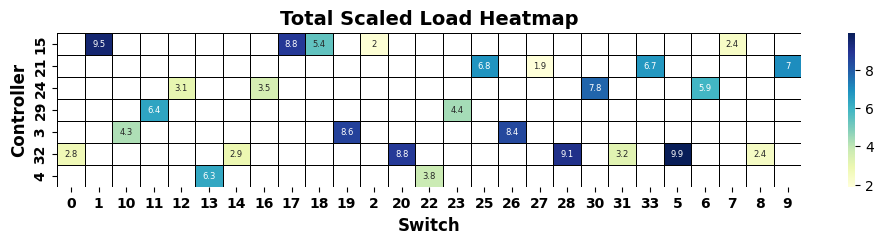

Switch Nodes and Types:
   Switch Type
0       9    e
1      27    m
2      25    e
3      33    e
4      28    m
5       5    e
6      14    e
7      31    e
8       0    m
9      20    e
10      8    e
11     12    m
12      6    e
13     30    e
14     16    e
15     22    e
16     13    e
17     18    m
18      1    m
19     17    e
20      2    e
21      7    e
22     11    e
23     23    e
24     10    m
25     26    e
26     19    e

Total Scaled Load per Controller:
  Controller  Total Scaled Load
0         15          28.107000
1         21          22.436517
2         24          20.217635
3         29          10.763750
4          3          21.275924
5         32          39.069054
6          4          10.082020

Total Scaled Load Sum for All Controllers: 151.9518996143589


In [ ]:

# Synethetic Traffic Generation for highest Peak Period
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt
import random

# Set the seed for reproducibility
np.random.seed(42)
random.seed(42)

# Define flow ranges
mice_flow_range = (2, 4)
elephant_flow_range = (4, 9)

# Define the distribution weights
mice_weight = 0.4
elephant_weight = 0.6

# Step 2: Calculate centrality metrics
# Calculate betweenness centrality
betweenness_centrality = nx.betweenness_centrality(G, weight='latency')
# Calculate closeness centrality
closeness_centrality = nx.closeness_centrality(G, distance='latency')

# Normalize centrality metrics
max_betweenness = max(betweenness_centrality.values())
max_closeness = max(closeness_centrality.values())
normalized_betweenness = {node: value / max_betweenness for node, value in betweenness_centrality.items()}
normalized_closeness = {node: value / max_closeness for node, value in closeness_centrality.items()}

# Create a combined centrality value by summing normalized betweenness and closeness
combined_centrality = {node: normalized_betweenness.get(node, 0) + normalized_closeness.get(node, 0)
                       for node in G.nodes()}

# Step 3: Prepare data for heatmap with flow classification
heatmap_data = []
flow_type_data = []

# Create a list to store data for each controller and its assigned switches
for controller, switches in updated_assignments.items():
    # Shuffle switches to ensure even distribution of flow types
    random.shuffle(switches)
    
    # Calculate number of mice and elephant flows
    num_switches = len(switches)
    num_mice_flows = int(num_switches * mice_weight)
    num_elephant_flows = num_switches - num_mice_flows
    
    # Assign traffic loads
    mice_flows = np.random.uniform(mice_flow_range[0], mice_flow_range[1], num_mice_flows)
    elephant_flows = np.random.uniform(elephant_flow_range[0], elephant_flow_range[1], num_elephant_flows)
    
    traffic_loads = np.concatenate([mice_flows, elephant_flows])
    flow_types = ['m'] * num_mice_flows + ['e'] * num_elephant_flows
    np.random.shuffle(traffic_loads)  # Shuffle to mix flow types
    np.random.shuffle(flow_types)  # Shuffle flow types
    
    for switch, load, flow_type in zip(switches, traffic_loads, flow_types):
        # Scale traffic load by combined centrality
        scaled_load = load * combined_centrality.get(switch, 1)  # Default to 1 if centrality not found
        heatmap_data.append({
            'Controller': controller,
            'Switch': switch,
            'Scaled Load': scaled_load  # Use only scaled load for heatmap
        })
        flow_type_data.append({
            'Switch': switch,
            'Type': flow_type  # Flow type ('e' or 'm')
        })

# Convert to DataFrame for heatmap
df_heatmap = pd.DataFrame(heatmap_data)

# Convert to DataFrame for switch types
df_flow_types = pd.DataFrame(flow_type_data)

# Step 4: Create the heatmap showing scaled load
# Use pivot_table to restructure the DataFrame for heatmap visualization
heatmap_df = df_heatmap.pivot_table(index='Controller', columns='Switch', values='Scaled Load', aggfunc='mean')

# Plot the heatmap
plt.figure(figsize=(12, 2))
sns.heatmap(heatmap_df, annot=True, cmap='YlGnBu', linewidths=0.5, linecolor='black', annot_kws={"size": 6})
plt.title("Total Scaled Load Heatmap", fontsize=14, fontweight='bold')
plt.xlabel("Switch", fontsize=12, fontweight='bold')
plt.ylabel("Controller", fontsize=12, fontweight='bold')

# Embolden x and y axis tick labels
plt.xticks(fontsize=10, fontweight='bold')
plt.yticks(fontsize=10, fontweight='bold')
plt.show()

# Step 5: Display the table of switch nodes and their types
print("Switch Nodes and Types:")
print(df_flow_types)

# Step 6: Prepare the table for total scaled load per controller
controller_total_scaled_load = df_heatmap.groupby('Controller')['Scaled Load'].sum().reset_index()
controller_total_scaled_load.columns = ['Controller', 'Total Scaled Load']

# Step 7: Display the total scaled load for each controller
print("\nTotal Scaled Load per Controller:")
print(controller_total_scaled_load)

# Calculate the sum of Total Scaled Load for all controllers
total_scaled_load_sum = controller_total_scaled_load['Total Scaled Load'].sum()

# Print the total scaled load sum
print(f"\nTotal Scaled Load Sum for All Controllers: {total_scaled_load_sum}")



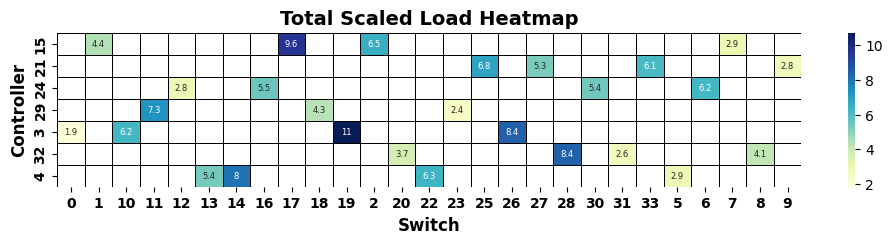

Switch Nodes and Types:
   Switch Type
0      33    e
1       9    m
2      25    e
3      27    e
4      20    e
5      28    e
6      31    m
7       8    e
8      12    m
9      16    e
10      6    e
11     30    e
12     22    e
13     14    m
14     13    e
15      5    e
16     17    e
17      2    e
18      7    e
19      1    m
20     11    e
21     23    m
22     18    e
23     10    m
24      0    e
25     19    e
26     26    e

Total Scaled Load per Controller:
  Controller  Total Scaled Load
0         15          23.380073
1         21          20.978376
2         24          19.947567
3         29          14.001467
4          3          27.193213
5         32          18.860221
6          4          22.558790

Total Scaled Load Sum for All Controllers: 146.91970773823923


In [ ]:

# Synethetic Traffic Generation for highest Peak Period
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt
import random

# Set the seed for reproducibility
np.random.seed(42)
random.seed(42)

# Define flow ranges
mice_flow_range = (2, 4)
elephant_flow_range = (4, 9)

# Define the distribution weights
mice_weight = 0.4
elephant_weight = 0.6

# Step 2: Calculate centrality metrics
# Calculate betweenness centrality
betweenness_centrality = nx.betweenness_centrality(G, weight='latency')
# Calculate closeness centrality
closeness_centrality = nx.closeness_centrality(G, distance='latency')

# Normalize centrality metrics
max_betweenness = max(betweenness_centrality.values())
max_closeness = max(closeness_centrality.values())
normalized_betweenness = {node: value / max_betweenness for node, value in betweenness_centrality.items()}
normalized_closeness = {node: value / max_closeness for node, value in closeness_centrality.items()}

# Create a combined centrality value by summing normalized betweenness and closeness
combined_centrality = {node: normalized_betweenness.get(node, 0) + normalized_closeness.get(node, 0)
                       for node in G.nodes()}

# Step 3: Prepare data for heatmap with flow classification
heatmap_data = []
flow_type_data = []

# Create a list to store data for each controller and its assigned switches
for controller, switches in updated_assignments_WNBS.items():
    # Shuffle switches to ensure even distribution of flow types
    random.shuffle(switches)
    
    # Calculate number of mice and elephant flows
    num_switches = len(switches)
    num_mice_flows = int(num_switches * mice_weight)
    num_elephant_flows = num_switches - num_mice_flows
    
    # Assign traffic loads
    mice_flows = np.random.uniform(mice_flow_range[0], mice_flow_range[1], num_mice_flows)
    elephant_flows = np.random.uniform(elephant_flow_range[0], elephant_flow_range[1], num_elephant_flows)
    
    traffic_loads = np.concatenate([mice_flows, elephant_flows])
    flow_types = ['m'] * num_mice_flows + ['e'] * num_elephant_flows
    np.random.shuffle(traffic_loads)  # Shuffle to mix flow types
    np.random.shuffle(flow_types)  # Shuffle flow types
    
    for switch, load, flow_type in zip(switches, traffic_loads, flow_types):
        # Scale traffic load by combined centrality
        scaled_load = load * combined_centrality.get(switch, 1)  # Default to 1 if centrality not found
        heatmap_data.append({
            'Controller': controller,
            'Switch': switch,
            'Scaled Load': scaled_load  # Use only scaled load for heatmap
        })
        flow_type_data.append({
            'Switch': switch,
            'Type': flow_type  # Flow type ('e' or 'm')
        })

# Convert to DataFrame for heatmap
df_heatmap = pd.DataFrame(heatmap_data)

# Convert to DataFrame for switch types
df_flow_types = pd.DataFrame(flow_type_data)

# Step 4: Create the heatmap showing scaled load
# Use pivot_table to restructure the DataFrame for heatmap visualization
heatmap_df = df_heatmap.pivot_table(index='Controller', columns='Switch', values='Scaled Load', aggfunc='mean')

# Plot the heatmap
plt.figure(figsize=(12, 2))
sns.heatmap(heatmap_df, annot=True, cmap='YlGnBu', linewidths=0.5, linecolor='black', annot_kws={"size": 6})
plt.title("Total Scaled Load Heatmap", fontsize=14, fontweight='bold')
plt.xlabel("Switch", fontsize=12, fontweight='bold')
plt.ylabel("Controller", fontsize=12, fontweight='bold')

# Embolden x and y axis tick labels
plt.xticks(fontsize=10, fontweight='bold')
plt.yticks(fontsize=10, fontweight='bold')
plt.show()

# Step 5: Display the table of switch nodes and their types
print("Switch Nodes and Types:")
print(df_flow_types)

# Step 6: Prepare the table for total scaled load per controller
controller_total_scaled_load = df_heatmap.groupby('Controller')['Scaled Load'].sum().reset_index()
controller_total_scaled_load.columns = ['Controller', 'Total Scaled Load']

# Step 7: Display the total scaled load for each controller
print("\nTotal Scaled Load per Controller:")
print(controller_total_scaled_load)

# Calculate the sum of Total Scaled Load for all controllers
total_scaled_load_sum = controller_total_scaled_load['Total Scaled Load'].sum()

# Print the total scaled load sum
print(f"\nTotal Scaled Load Sum for All Controllers: {total_scaled_load_sum}")



In [ ]:
# # Define a function to calculate latency using haversine distance (returns in milliseconds)
# def calculate_latency(node1, node2, geo_loc_data):
#     distance = haversine(node1, node2, geo_loc_data)
#     # Latency in milliseconds
#     latency = (distance * 1000) / (2 * 1e8)  # Speed of light approximation in fiber optics
#     latency_in_ms = latency * 1000  # Convert seconds to milliseconds
#     return latency_in_ms

# # Initialize variables for RSavg and RSmax
# total_latency_max_neighbors = 0
# max_latency_max_neighbors = 0
# total_paths_max_neighbors = 0
# worst_case_pair_max_neighbors = None

# # Iterate over all pairs of locations in the optimal combination
# for location1 in updated_controllers:
#     for location2 in updated_controllers:
#         if location1 != location2:
#             try:
#                 # Calculate latency between locations using the calculate_latency function
#                 latency_optimal = calculate_latency(location1, location2, geo_loc_data)

#                 # Update total latency and increment the number of paths
#                 total_latency_max_neighbors += latency_optimal
#                 total_paths_max_neighbors += 1

#                 # Update the maximum worst-case latency and track the pair of locations
#                 if latency_optimal > max_latency_max_neighbors:
#                     max_latency_max_neighbors = latency_optimal
#                     worst_case_pair_max_neighbors = (location1, location2)

#             except KeyError:
#                 print(f"No geographical data available for {location1} or {location2}")

# # Calculate RSavg (Average Latency) between locations
# if total_paths_max_neighbors > 0:
#     average_latency_max_neighbors = total_latency_max_neighbors / total_paths_max_neighbors
# else:
#     average_latency_max_neighbors = 0
#     print("No valid paths for L2L latency calculation.")

# # Print the results in milliseconds
# print(f"\nRSavg (Average Latency for L2L): {average_latency_max_neighbors:.2f} ms")
# print(f"RSmax (Worst-Case Latency for L2L): {max_latency_max_neighbors:.2f} ms")

# # Print the pair with worst-case latency
# print(f"Worst-Case Pair: {worst_case_pair_max_neighbors}")

# # # Create a dictionary to store average latencies for each location
# # average_latencies_dict = {}
# # max_worst_case_latency = 0

# # Initialize variables for RSavg and RSmax calculations
# average_latencies_dict = {}
# max_worst_case_latency = 0
# total_latency_sum = 0
# total_nodes = len(geo_loc_data)  # Total number of nodes in the network

# # Debug: Print controller and assignment data
# print(f"Controllers: {updated_controllers}")
# print(f"Assignments: {updated_assignments}")

# # Print the optimal switch assignment and calculate average latency
# for controller in updated_controllers:
#     nodes_assigned = updated_assignments[controller]

#     # Debug: Print the nodes assigned to each controller
#     print(f"Controller {controller} has nodes: {nodes_assigned}")

#     # Calculate average latency between location and nodes_assigned
#     latencies = []
#     for switch in nodes_assigned:
#         try:

#             latency = calculate_latency(controller, switch, geo_loc_data)
#             latencies.append(latency)

#             # Keep a running sum of latencies for RSavg calculation
#             total_latency_sum += latency

#             # Update the maximum worst-case latency (RSmax) if this latency is higher
#             if latency > max_worst_case_latency:
#                 max_worst_case_latency = latency

#         except KeyError:
#             print(f"Error: Missing geographical data for nodes {controller} or {switch}")

#     # Safeguard for average calculation
#     if latencies:
#         average_latency = sum(latencies) / len(latencies)
#     else:
#         average_latency = 0
#         print(f"No latencies for controller {controller}")

#     # Store the average latency for each controller
#     average_latencies_dict[controller] = average_latency

# # Calculate the overall RSavg (average latency across all nodes)
# overall_average_latency  = total_latency_sum / total_nodes if total_nodes > 0 else 0

# # Output the results in milliseconds (ms)
# print(f"RSavg (Total Average Latency): {overall_average_latency :.2f} ms")
# print(f"RSmax (Maximum Worst-Case Latency): {max_worst_case_latency:.2f} ms")

# print(f"Total Average Latency for N2L: {overall_average_latency:.2f}")
# print(f"Maximum Worst-Case Latency for N2L: {max_worst_case_latency:.2f}")

# # Function to calculate latencies
# def calculate_latencies(updated_assignments, centroids, geo_loc_data):
#     intra_cluster_latencies = {}
#     inter_cluster_latencies = {}

#     # Intra-cluster latencies
#     for centroid in centroids:
#         assigned_nodes = updated_assignments.get(centroid, [])
        
#         # # Debug: Print assigned nodes for each centroid
#         # print(f"Centroid {centroid} has assigned nodes: {assigned_nodes}")

#         if assigned_nodes:
#             latencies = []
#             total_latency_sum = 0
            
#             for node in assigned_nodes:
#                 try:
#                     # Calculate latency between centroid and node
#                     latency = calculate_latency(centroid, node, geo_loc_data)
#                     latencies.append(latency)
#                     total_latency_sum += latency
                    
#                     # Debug: Print individual latencies
#                     # print(f"Latency from Centroid {centroid} to Node {node}: {latency:.15f} ms")
                
#                 except KeyError:
#                     print(f"No geographical data available for node {node} or centroid {centroid}. Skipping this node.")
                    
#             # Calculate average intra-cluster latency
#             if latencies:
#                 average_intra_latency = total_latency_sum / len(latencies)
#                 intra_cluster_latencies[centroid] = average_intra_latency
#             else:
#                 intra_cluster_latencies[centroid] = 0  # No valid latencies found
#         else:
#             intra_cluster_latencies[centroid] = 0  # No assigned nodes

#     # Inter-cluster latencies
#     for centroid in centroids:
#         inter_cluster_latencies[centroid] = {}
#         for other_centroid in centroids:
#             if centroid != other_centroid:
#                 try:
#                     inter_cluster_latencies[centroid][other_centroid] = calculate_latency(centroid, other_centroid, geo_loc_data)
#                 except KeyError:
#                     print(f"No geographical data available for {centroid} or {other_centroid}. Skipping this pair.")

#     return intra_cluster_latencies, inter_cluster_latencies

# centroids = updated_controllers

# # Example call (make sure to define updated_assignments, centroids, and geo_loc_data beforehand)
# intra_cluster_latencies, inter_cluster_latencies = calculate_latencies(updated_assignments, centroids, geo_loc_data)

# # # Print intra-cluster latencies
# # print("Intra-Cluster Latencies:")
# # for centroid, latency in intra_cluster_latencies.items():
# #     print(f"Centroid {centroid}: Average Intra-Cluster Latency = {latency:.15f} ms")

# # # Print inter-cluster latencies
# # print("\nInter-Cluster Latencies:")
# # for centroid, other_latencies in inter_cluster_latencies.items():
# #     for other_centroid, latency in other_latencies.items():
# #         print(f"From Centroid {centroid} to Centroid {other_centroid}: Inter-Cluster Latency = {latency:.15f} ms")

# # Calculate DBI
# DBI_sum = 0
# for controller in updated_controllers:
#     S_i = intra_cluster_latencies.get(controller, 0)
    
#     # Calculate M_ij_avg using inter-cluster latencies
#     inter_latencies = inter_cluster_latencies.get(controller, {}).values()
#     M_ij_avg = sum(inter_latencies) / (len(updated_controllers) - 1) if len(updated_controllers) > 1 else 0

#     if M_ij_avg > 0:
#         DBI_sum += S_i / M_ij_avg

# DBI = DBI_sum / len(updated_controllers) if len(updated_controllers) > 1 else 0

# # Calculate the Silhouette Score
# silhouette_scores = []
# for controller in updated_controllers:
#     nodes_assigned = [node for node, assigned_head in closest_nodes_dict.items() if assigned_head == controller]
#     if nodes_assigned:
#         # Calculate a_Oi using calculate_latency function
#         a_Oi = sum(calculate_latency(controller, node, geo_loc_data) for node in nodes_assigned) / len(nodes_assigned)

#         b_Oi_list = []
#         for other_location in updated_controllers:
#             if other_location != controller:
#                 nodes_assigned_other = [node for node, assigned_head in closest_nodes_dict.items() if assigned_head == other_location]
#                 if nodes_assigned_other:
#                     # Calculate b_Oi using calculate_latency function
#                     b_Oi = sum(calculate_latency(controller, node, geo_loc_data) for node in nodes_assigned_other) / len(nodes_assigned_other)
#                     b_Oi_list.append(b_Oi)

#         b_Oi = min(b_Oi_list) if b_Oi_list else 0

#         silhouette_score = (b_Oi - a_Oi) / max(a_Oi, b_Oi) if max(a_Oi, b_Oi) > 0 else 0
#         silhouette_scores.append(silhouette_score)

# overall_silhouette_score = sum(silhouette_scores) / len(silhouette_scores) if silhouette_scores else 0

# # Calculate Within-Cluster Variance
# within_cluster_variance = 0
# for centroid in updated_controllers:
#     assigned_nodes = [node for node, assigned_head in closest_nodes_dict.items() if assigned_head == centroid]
#     within_cluster_variance += sum(
#         calculate_latency(node, centroid, geo_loc_data)**2 for node in assigned_nodes
#     )

# # Calculate Between-Cluster Variance
# between_cluster_variance = 0
# centroid_list = list(updated_controllers)
# for i in range(len(centroid_list)):
#     for j in range(i + 1, len(centroid_list)):
#         between_cluster_variance += calculate_latency(centroid_list[i], centroid_list[j], geo_loc_data)**2

# # Calculate Calinski-Harabasz Index
# N = len(G.nodes())
# K = len(updated_controllers)
# calinski_harabasz_index = (between_cluster_variance / (K - 1)) / (within_cluster_variance / (N - K)) if within_cluster_variance > 0 else 0



# # If the length of the updated controllers is what you want
# length_assigned_nodes_list = len(updated_controllers)

# # Prepare data for the table
# table_data = [
#     f"{average_latency_max_neighbors:.5f}",
#     f"{max_latency_max_neighbors:.5f}",
#     f"{overall_average_latency:.5f}",
#     f"{max_worst_case_latency:.5f}",
#     length_assigned_nodes_list
# ]

# # Define headers
# headers = ["Average Latency L2L", "Worst-Case Latency L2L", "Total Average Latency N2L", "Max Worst-Case Latency N2L", "Selected Controllers"]

# # Print the table
# print(tabulate([table_data], headers=headers, tablefmt="pretty"))

# # Print the clustering metrics
# print(f"\nClustering Metrics:")
# print(f"Davies-Bouldin Index: {DBI:.5f}")
# print(f"Overall Silhouette Score: {overall_silhouette_score:.5f}")
# print(f"Calinski-Harabasz Index: {calinski_harabasz_index:.5f}")


In [ ]:
# Assuming geo_loc_data and the haversine function are already defined
# Assuming updated_assignments is defined

# List all nodes
all_nodes = list(geo_loc_data.keys())
n = len(all_nodes)

# Initialize the latency matrix T_ij
T_ij = np.zeros((n, n))

# Calculate and store latency for every pair of nodes
for i in range(n):
    for j in range(i + 1, n):
        node1, node2 = all_nodes[i], all_nodes[j]
        distance = haversine(node1, node2, geo_loc_data)
        latency = (distance * 1000) / (2 * 1e8)  # in milliseconds
        
        # Store latency in the matrix
        T_ij[i][j] = latency
        T_ij[j][i] = latency  # Ensure the matrix is symmetric

# Calculate T_max as the sum of all latencies in the matrix
T_max = np.sum(T_ij)

# Calculate the sum of T_ij for controller-to-node latency
controller_to_node_sum = 0
for controller, nodes in updated_assignments.items():
    controller_idx = all_nodes.index(controller)
    for node in nodes:
        node_idx = all_nodes.index(node)
        controller_to_node_sum += T_ij[controller_idx][node_idx]

# Calculate the sum of T_ij for controller-to-controller latency
controller_to_controller_sum = 0
controllers = list(updated_assignments.keys())
for i in range(len(controllers)):
    for j in range(i + 1, len(controllers)):
        controller1_idx = all_nodes.index(controllers[i])
        controller2_idx = all_nodes.index(controllers[j])
        controller_to_controller_sum += T_ij[controller1_idx][controller2_idx]

# Normalize these sums by T_max
normalized_controller_to_node = controller_to_node_sum / T_max
normalized_controller_to_controller = controller_to_controller_sum / T_max

# Print the results
print("T_max (Maximum Latency):", T_max)
print("Sum of T_ij for Controller-to-Node:", controller_to_node_sum)
print("Sum of T_ij for Controller-to-Controller:", controller_to_controller_sum)
print("Normalized Controller-to-Node Latency:", normalized_controller_to_node)
print("Normalized Controller-to-Controller Latency:", normalized_controller_to_controller)


T_max (Maximum Latency): 10.407752157187833
Sum of T_ij for Controller-to-Node: 0.0762374427229271
Sum of T_ij for Controller-to-Controller: 0.2042014605212654
Normalized Controller-to-Node Latency: 0.00732506323858565
Normalized Controller-to-Controller Latency: 0.01962013097902597


In [ ]:
# Assuming geo_loc_data and the haversine function are already defined
# Assuming updated_assignments is defined

# List all nodes
all_nodes = list(geo_loc_data.keys())
n = len(all_nodes)

# Initialize the latency matrix T_ij
T_ij = np.zeros((n, n))

# Calculate and store latency for every pair of nodes
for i in range(n):
    for j in range(i + 1, n):
        node1, node2 = all_nodes[i], all_nodes[j]
        distance = haversine(node1, node2, geo_loc_data)
        latency = (distance * 1000) / (2 * 1e8)  # in milliseconds
        
        # Store latency in the matrix
        T_ij[i][j] = latency
        T_ij[j][i] = latency  # Ensure the matrix is symmetric

# Calculate T_max as the sum of all latencies in the matrix
T_max = np.sum(T_ij)

# Calculate the sum of T_ij for controller-to-node latency
controller_to_node_sum = 0
for controller, nodes in updated_assignments_WNBS.items():
    controller_idx = all_nodes.index(controller)
    for node in nodes:
        node_idx = all_nodes.index(node)
        controller_to_node_sum += T_ij[controller_idx][node_idx]

# Calculate the sum of T_ij for controller-to-controller latency
controller_to_controller_sum = 0
controllers = list(updated_assignments.keys())
for i in range(len(controllers)):
    for j in range(i + 1, len(controllers)):
        controller1_idx = all_nodes.index(controllers[i])
        controller2_idx = all_nodes.index(controllers[j])
        controller_to_controller_sum += T_ij[controller1_idx][controller2_idx]

# Normalize these sums by T_max
normalized_controller_to_node = controller_to_node_sum / T_max
normalized_controller_to_controller = controller_to_controller_sum / T_max

# Print the results
print("T_max (Maximum Latency):", T_max)
print("Sum of T_ij for Controller-to-Node:", controller_to_node_sum)
print("Sum of T_ij for Controller-to-Controller:", controller_to_controller_sum)
print("Normalized Controller-to-Node Latency:", normalized_controller_to_node)
print("Normalized Controller-to-Controller Latency:", normalized_controller_to_controller)


T_max (Maximum Latency): 10.407752157187833
Sum of T_ij for Controller-to-Node: 0.08349298255172156
Sum of T_ij for Controller-to-Controller: 0.2042014605212654
Normalized Controller-to-Node Latency: 0.008022191659710055
Normalized Controller-to-Controller Latency: 0.01962013097902597


In [ ]:

import numpy as np
import pandas as pd
from gurobipy import Model, GRB

# Extract controller IDs and total scaled load values
controllers = controller_total_scaled_load['Controller'].tolist()
total_scaled_load = controller_total_scaled_load['Total Scaled Load'].tolist()

# Define controller and switch details
C = [288, 576, 960, 1920, 3600]  # Prices of the controllers
P = 5  # Number of controller types
mu = [6, 12, 20, 40, 75]  # Capacities of the controllers (in kbps)

# Create the optimization model
model = Model("Controller_Assignment")

# Decision variables: x[i][j] = 1 if controller i is assigned to controller type j
x = {}
for i in range(len(controllers)):
    for j in range(P):
        x[i, j] = model.addVar(vtype=GRB.BINARY, name=f"x_{controllers[i]}_{j}")

# Add capacity constraints
for i in range(len(controllers)):
    controller_id = controllers[i]
    load = total_scaled_load[i]
    model.addConstr(
        sum(mu[j] * x[i, j] for j in range(P)) >= load,
        name=f"Capacity_{controller_id}"
    )

# Assignment constraint: ensure each controller is assigned exactly one type
for i in range(len(controllers)):
    model.addConstr(
        sum(x[i, j] for j in range(P)) == 1,
        name=f"Assignment_{controllers[i]}"
    )

# Objective: Minimize total cost
model.setObjective(
    sum(C[j] * x[i, j] for i in range(len(controllers)) for j in range(P)),
    GRB.MINIMIZE
)

# Optimize the model
model.optimize()

# Initialize the total cost variable
total_cost = 0

# Create solution dictionary
solution_dict = {}
if model.status == GRB.OPTIMAL:
    print("Optimal Assignment of Controller Types:")
    total_cost = 0
    for i in range(len(controllers)):
        for j in range(P):
            if x[i, j].x > 0.5:  # Check if x[i, j] is 1 (assigned)
                controller_id = controllers[i]
                type_name = chr(65 + j)  # Assign type names A, B, C, etc.
                capacity = mu[j]
                cost = C[j]
                solution_dict[controller_id] = {
                    'type': type_name,
                    'capacity': capacity,
                    'cost': cost
                }
                print(f"Controller {controller_id} -> Type {type_name} (Capacity: {capacity}, Cost: {cost})")
                total_cost += cost
    print(f"\nTotal Cost of Deploying Controller Types: {total_cost}")
else:
    print("No optimal solution found.")


# ---------------------------------------------------
# Calculate load imbalance and print details
# ---------------------------------------------------

# Initialize variables to compute load imbalance
overall_max_load_ratio = float('-inf')
overall_min_load_ratio = float('inf')
load_capacity_ratios = {}

total_load_all_controllers = 0

for controller in controllers:
    load = total_scaled_load[controllers.index(controller)]
    assigned_type = solution_dict.get(controller, {}).get('type', 'A')
    controller_type_index = ord(assigned_type) - 65
    capacity = mu[controller_type_index]

    load_capacity_ratio = load / capacity if capacity != 0 else 0.0
    load_capacity_ratios[controller] = load_capacity_ratio

    print(f"Controller {controller}: Load = {load} kbps, Capacity = {capacity} kbps, Load/Capacity = {load_capacity_ratio:.2f}")

    overall_max_load_ratio = max(overall_max_load_ratio, load_capacity_ratio)
    overall_min_load_ratio = min(overall_min_load_ratio, load_capacity_ratio)

load_imbalance = ((overall_max_load_ratio - overall_min_load_ratio) / overall_max_load_ratio) * 100 if overall_max_load_ratio != 0 else 0.0
print(f"Load Imbalance: {load_imbalance:.2f}%")



Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11.0 (22621.2))

CPU model: Intel(R) Core(TM) i7-8565U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 14 rows, 35 columns and 70 nonzeros
Model fingerprint: 0x2e8a3d04
Variable types: 0 continuous, 35 integer (35 binary)
Coefficient statistics:
  Matrix range     [1e+00, 8e+01]
  Objective range  [3e+02, 4e+03]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 3e+01]
Found heuristic solution: objective 13200.000000
Presolve removed 14 rows and 35 columns
Presolve time: 0.00s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.02 seconds (0.00 work units)
Thread count was 1 (of 8 available processors)

Solution count 2: 10560 13200 

Optimal solution found (tolerance 1.00e-04)
Best objective 1.056000000000e+04, best bound 1.056000000000e+04, gap 0.0000%
Optimal Assignment of Contro

In [ ]:
import numpy as np
import pandas as pd
from gurobipy import Model, GRB

# Extract controller IDs and total scaled load values
controllers = controller_total_scaled_load['Controller'].tolist()
loads = controller_total_scaled_load['Total Scaled Load'].tolist()

# Calculate total scaled load sum
total_scaled_load_sum = sum(loads)

# Define controller and switch details
C = [288, 576, 960, 1920, 3600]  # Prices of the controllers
P = 5  # Number of controller types
mu = [6, 12, 20, 40, 75]  # Capacities of the controllers (in kbps)

# Create the optimization model
model = Model("Single_Controller_Type_Assignment")

# Decision variables: y[j] = 1 if controller type j is chosen
y = {j: model.addVar(vtype=GRB.BINARY, name=f"y_{j}") for j in range(P)}

# Add constraint: Only one controller type can be used
model.addConstr(sum(y[j] for j in range(P)) == 1, name="Single_Controller_Type")

# Add capacity constraint: Ensure the chosen controller type can handle the total scaled load
model.addConstr(
    sum(mu[j] * y[j] for j in range(P)) * len(controllers) >= total_scaled_load_sum,
    name="Capacity_Constraint"
)

# Objective: Minimize the cost of the chosen controller type
model.setObjective(sum(C[j] * y[j] for j in range(P)), GRB.MINIMIZE)

# Optimize the model
model.optimize()

# Output the results
if model.status == GRB.OPTIMAL:
    print("Optimal Assignment of Controller Types:")
    selected_type = None
    type_name, capacity, cost = None, None, None
    for j in range(P):
        if y[j].x > 0.5:  # Check if controller type j is selected
            selected_type = j
            type_name = chr(65 + j)  # Assign type names A, B, C, etc.
            capacity = mu[j]
            cost = C[j]
            break
    
    total_cost = 0
    load_capacity_ratios = []
    for controller_id, load in zip(controllers, loads):
        total_cost += cost
        load_capacity_ratio = load / capacity
        load_capacity_ratios.append(load_capacity_ratio)
        print(
            f"Controller {controller_id} -> Type {type_name} "
            f"(Capacity: {capacity}, Cost: {cost})"
        )
    
    print(f"\nTotal Cost of Deploying Controller Types: {total_cost}")
    print()
    for controller_id, load, ratio in zip(controllers, loads, load_capacity_ratios):
        print(
            f"Controller {controller_id}: Load = {load:.2f} kbps, "
            f"Capacity = {capacity} kbps, Load/Capacity = {ratio:.2f}"
        )
    
    # Load imbalance calculation
    max_ratio = max(load_capacity_ratios)
    min_ratio = min(load_capacity_ratios)
    load_imbalance = ((max_ratio - min_ratio) / max_ratio) * 100
    print(f"Load Imbalance: {load_imbalance:.2f}%")
else:
    print("No optimal solution found.")


Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11.0 (22621.2))

CPU model: Intel(R) Core(TM) i7-8565U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 2 rows, 5 columns and 10 nonzeros
Model fingerprint: 0x3acd2d84
Variable types: 0 continuous, 5 integer (5 binary)
Coefficient statistics:
  Matrix range     [1e+00, 5e+02]
  Objective range  [3e+02, 4e+03]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+02]
Found heuristic solution: objective 3600.0000000
Presolve removed 2 rows and 5 columns
Presolve time: 0.00s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.01 seconds (0.00 work units)
Thread count was 1 (of 8 available processors)

Solution count 2: 1920 3600 

Optimal solution found (tolerance 1.00e-04)
Best objective 1.920000000000e+03, best bound 1.920000000000e+03, gap 0.0000%
Optimal Assignment of Controller Typ


Timestamp 1 - Period: low_peak (Mice Weight: 0.6, Elephant Weight: 0.4, Scaling Factor: 0.5)


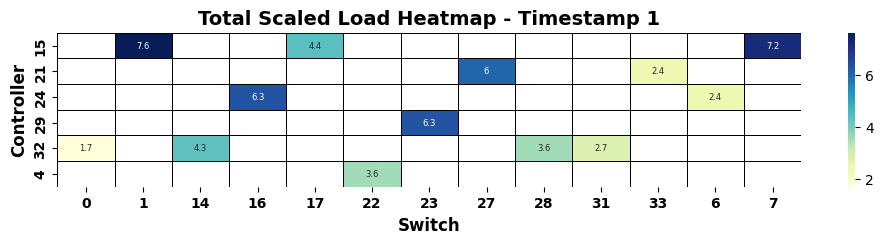


Timestamp 2 - Period: mid_peak (Mice Weight: 0.5, Elephant Weight: 0.5, Scaling Factor: 0.7)


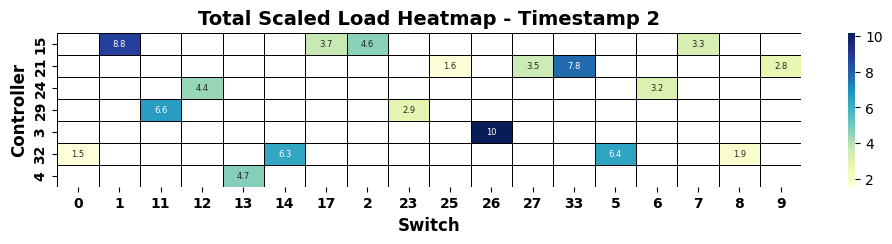


Timestamp 3 - Period: peak (Mice Weight: 0.4, Elephant Weight: 0.6, Scaling Factor: 0.9)


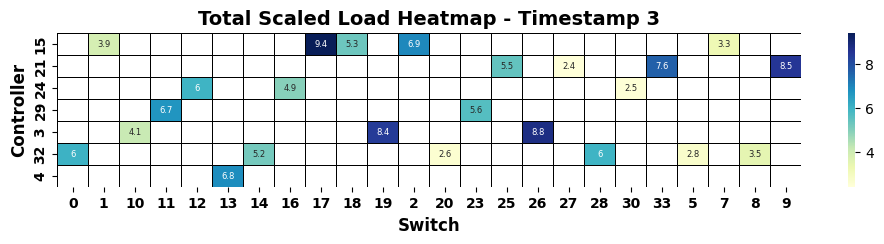


Timestamp 4 - Period: low_peak (Mice Weight: 0.6, Elephant Weight: 0.4, Scaling Factor: 0.5)


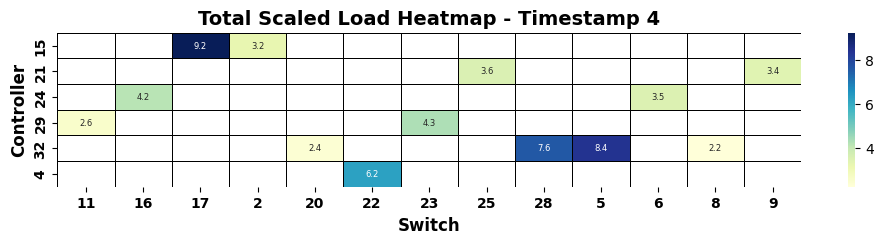


Timestamp 5 - Period: mid_peak (Mice Weight: 0.5, Elephant Weight: 0.5, Scaling Factor: 0.7)


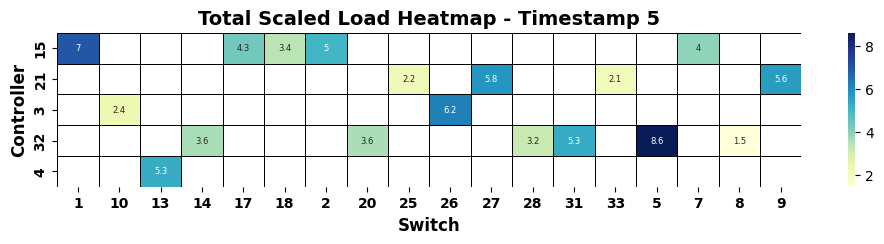


Timestamp 6 - Period: mid_peak (Mice Weight: 0.5, Elephant Weight: 0.5, Scaling Factor: 0.7)


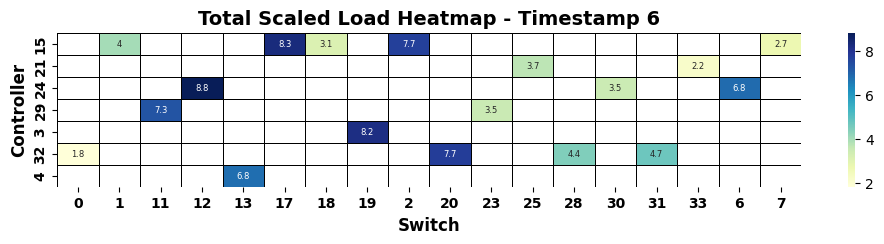


Timestamp 7 - Period: low_peak (Mice Weight: 0.6, Elephant Weight: 0.4, Scaling Factor: 0.5)


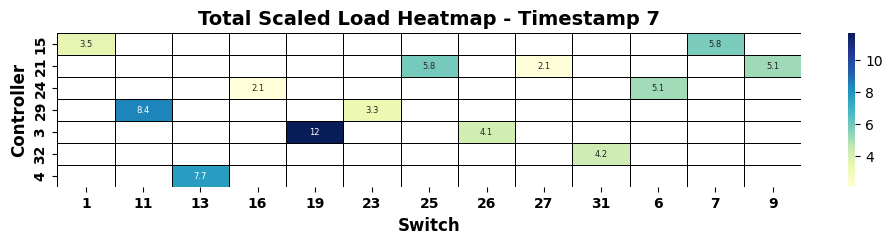


Timestamp 8 - Period: mid_peak (Mice Weight: 0.5, Elephant Weight: 0.5, Scaling Factor: 0.7)


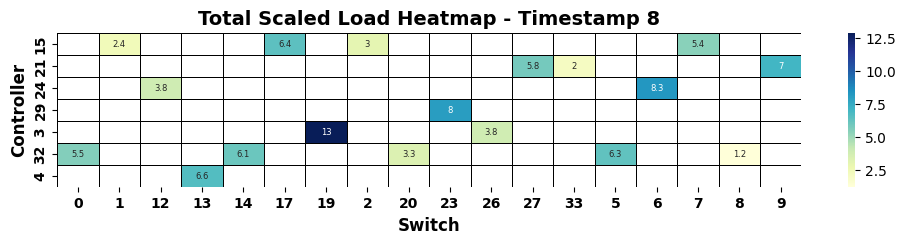


Timestamp 9 - Period: peak (Mice Weight: 0.4, Elephant Weight: 0.6, Scaling Factor: 0.9)


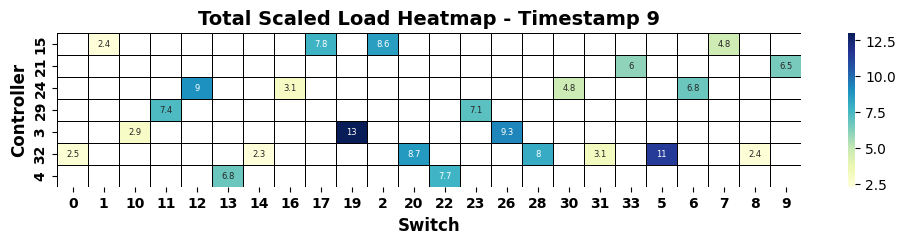


Timestamp 10 - Period: peak (Mice Weight: 0.4, Elephant Weight: 0.6, Scaling Factor: 0.9)


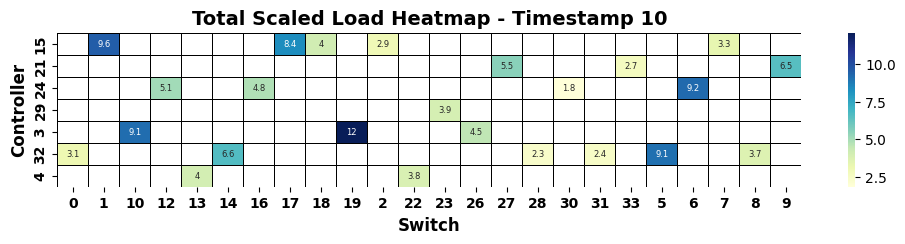


Controller-to-Switch Assignments for Timestamp 1:
  Controller 21: Switches ['27', '33']
  Controller 32: Switches ['14', '0', '28', '31']
  Controller 24: Switches ['6', '16']
  Controller 4: Switches ['22']
  Controller 15: Switches ['17', '1', '7']
  Controller 29: Switches ['23']

Controller-to-Switch Assignments for Timestamp 2:
  Controller 21: Switches ['25', '27', '9', '33']
  Controller 32: Switches ['5', '14', '8', '0']
  Controller 24: Switches ['6', '12']
  Controller 4: Switches ['13']
  Controller 15: Switches ['2', '17', '1', '7']
  Controller 29: Switches ['23', '11']
  Controller 3: Switches ['26']

Controller-to-Switch Assignments for Timestamp 3:
  Controller 21: Switches ['25', '27', '9', '33']
  Controller 32: Switches ['14', '5', '28', '8', '0', '20']
  Controller 24: Switches ['16', '30', '12']
  Controller 4: Switches ['13']
  Controller 15: Switches ['18', '7', '17', '1', '2']
  Controller 29: Switches ['23', '11']
  Controller 3: Switches ['26', '19', '10']



In [ ]:
from collections import defaultdict
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt
import random

# Set the seed for reproducibility
np.random.seed(42)
random.seed(42)

# Define flow ranges
mice_flow_range = (2, 4)
elephant_flow_range = (4, 9)

# Define the distribution weights
weights = {
    'peak': (0.4, 0.6),
    'mid_peak': (0.5, 0.5),
    'low_peak': (0.6, 0.4)
}

# Define scaling factors for active switches based on period
scaling_factors = {
    'peak': 0.9,  # Base scaling factor for peak period
    'mid_peak': 0.7,  # 70% of the peak period's active switches
    'low_peak': 0.5  # 50% of the peak period's active switches
}

# Generate a list of periods for timestamps
# Ensure each period is represented at least 3 times
periods = ['peak'] * 3 + ['mid_peak'] * 4 + ['low_peak'] * 3
random.shuffle(periods)  # Shuffle to distribute periods randomly

# Prepare for timestamps
num_timestamps = 10

# Ensure 'G', 'updated_assignments', 'updated_switches', and 'solution_dict' are defined

# Initialize a dictionary to store total scaled load for each controller at each timestamp
total_scaled_load_per_timestamp = {i: {} for i in range(num_timestamps)}

# Extract capacities from solution_dict
controller_capacities = {controller: details['capacity'] for controller, details in solution_dict.items()}

# Prepare to store results for each timestamp
heatmaps = []
switch_types = []
active_switches_counts = []
active_switches_per_timestamp = []  # To store active switches for each timestamp

# Initialize a dictionary to store scaled loads per switch across timestamps
scaled_load_per_switch = {switch: [] for switch in updated_switches}


# Initialize a dictionary to store controller-to-switch assignments for each timestamp
controller_to_switch_assignment_per_timestamp = {i: defaultdict(list) for i in range(num_timestamps)}


# Loop through each timestamp
for timestamp in range(num_timestamps):
    period = periods[timestamp]
    mice_weight, elephant_weight = weights[period]
    scaling_factor = scaling_factors[period]
    
    print(f"\nTimestamp {timestamp + 1} - Period: {period} (Mice Weight: {mice_weight}, Elephant Weight: {elephant_weight}, Scaling Factor: {scaling_factor})")
    
    # Step 2: Calculate centrality metrics
    betweenness_centrality = nx.betweenness_centrality(G, weight='latency')
    closeness_centrality = nx.closeness_centrality(G, distance='latency')

    # Normalize centrality metrics
    max_betweenness = max(betweenness_centrality.values(), default=1)
    max_closeness = max(closeness_centrality.values(), default=1)
    normalized_betweenness = {node: value / max_betweenness for node, value in betweenness_centrality.items()}
    normalized_closeness = {node: value / max_closeness for node, value in closeness_centrality.items()}

    # Create a combined centrality value by summing normalized betweenness and closeness
    combined_centrality = {node: normalized_betweenness.get(node, 0) + normalized_closeness.get(node, 0)
                           for node in G.nodes()}

    # Step 3: Prepare data for heatmap with flow classification
    heatmap_data = []
    flow_type_data = []

    # Determine the number of active switches to use based on the scaling factor
    num_active_switches = int(len(updated_switches) * scaling_factor)
    selected_switches = random.sample(updated_switches, num_active_switches)
    active_switches_per_timestamp.append(selected_switches)  # Store selected active switches

     # Create a list to store data for each controller and its assigned switches
    switch_to_controller_assignment = []  # Initialize for each timestamp

    # Create a list to store data for each controller and its assigned switches
    for controller, switches in updated_assignments.items():
        # Filter and shuffle switches to ensure even distribution of flow types
        switches = [switch for switch in switches if switch in selected_switches]
        random.shuffle(switches)

        # Calculate number of mice and elephant flows
        num_switches = len(switches)
        num_mice_flows = int(num_switches * mice_weight)
        num_elephant_flows = num_switches - num_mice_flows

        # Assign traffic loads
        mice_flows = np.random.uniform(mice_flow_range[0], mice_flow_range[1], num_mice_flows)
        elephant_flows = np.random.uniform(elephant_flow_range[0], elephant_flow_range[1], num_elephant_flows)

        traffic_loads = np.concatenate([mice_flows, elephant_flows])
        flow_types = ['m'] * num_mice_flows + ['e'] * num_elephant_flows
        np.random.shuffle(traffic_loads)  # Shuffle to mix flow types
        np.random.shuffle(flow_types)  # Shuffle flow types


        for switch in switches:
            switch_to_controller_assignment.append((switch, controller))

   


    # # Step 8: Print switch-to-controller assignment for this timestamp
    # controller_to_switches = defaultdict(list)

    # for switch, controller in switch_to_controller_assignment:
    #     controller_to_switches[controller].append(switch)

        for switch, load, flow_type in zip(switches, traffic_loads, flow_types):
            # Scale traffic load by combined centrality
            scaled_load = load * combined_centrality.get(switch, 1)  # Default to 1 if centrality not found
            heatmap_data.append({
                'Controller': controller,
                'Switch': switch,
                'Scaled Load': scaled_load  # Use only scaled load for heatmap
            })
            flow_type_data.append({
                'Switch': switch,
                'Type': flow_type  # Flow type ('e' or 'm')
            })

            # Store the scaled load for the current switch
            scaled_load_per_switch[switch].append((timestamp + 1, scaled_load))

            # Store the switch-to-controller assignment for printing
            switch_to_controller_assignment.append((switch, controller))

    # Convert to DataFrame for heatmap
    df_heatmap = pd.DataFrame(heatmap_data)

    # Convert to DataFrame for switch types
    df_flow_types = pd.DataFrame(flow_type_data)

    # Step 4: Create the heatmap showing scaled load
    # Use pivot_table to restructure the DataFrame for heatmap visualization
    heatmap_df = df_heatmap.pivot_table(index='Controller', columns='Switch', values='Scaled Load', aggfunc='mean')

    # Store the heatmap data
    heatmaps.append(heatmap_df)

    # Plot the heatmap
    plt.figure(figsize=(12, 2))
    sns.heatmap(heatmap_df, annot=True, cmap='YlGnBu', linewidths=0.5, linecolor='black', annot_kws={"size": 6})
    plt.title(f"Total Scaled Load Heatmap - Timestamp {timestamp + 1}", fontsize=14, fontweight='bold')
    plt.xlabel("Switch", fontsize=12, fontweight='bold')
    plt.ylabel("Controller", fontsize=12, fontweight='bold')
    plt.xticks(fontsize=10, fontweight='bold')
    plt.yticks(fontsize=10, fontweight='bold')
    plt.show()

     

    # # Step 8: Print switch-to-controller assignment for this timestamp
    # controller_to_switches = defaultdict(list)

    # # Step 8: Print switch-to-controller assignment for this timestamp
    # # print(f"\nController-to-Switch Assignments for Timestamp {timestamp + 1}:")
    # for switch, controller in switch_to_controller_assignment:
    #     # print(f"  Switch {switch} is assigned to Controller {controller}")
    #     controller_to_switches[controller].append(switch)

    # print(f"\nController-to-Switch Assignments for Timestamp {timestamp + 1}:")
    # for controller, switches in controller_to_switches.items():
    #     # print(f"  Controller {controller}: Switches {switches}")
    #     print(f"  Controller {controller}: Switches {list(set(switches))}")

    # Calculate total scaled load per controller for this timestamp
    controller_total_scaled_load = df_heatmap.groupby('Controller')['Scaled Load'].sum().reset_index()
    controller_total_scaled_load.columns = ['Controller', 'Total Scaled Load']
    
    # Store the total scaled load for this timestamp
    for _, row in controller_total_scaled_load.iterrows():
        controller = row['Controller']
        total_scaled_load_per_timestamp[timestamp][controller] = row['Total Scaled Load']

    # Store the number of active switches for the current timestamp
    active_switches_counts.append(len(selected_switches))

    # Populate the dictionary with controller-to-switch assignments for this timestamp
    for switch, controller in switch_to_controller_assignment:
        controller_to_switch_assignment_per_timestamp[timestamp][controller].append(switch)

# Example print statement to verify the contents of the dictionary
for timestamp, assignments in controller_to_switch_assignment_per_timestamp.items():
    print(f"\nController-to-Switch Assignments for Timestamp {timestamp + 1}:")
    for controller, switches in assignments.items():
        print(f"  Controller {controller}: Switches {list(set(switches))}")

# Step 5: Display the table of switch nodes and their types
print("Switch Nodes and Types:")
print(df_flow_types)

# Step 6: Display the scaled load of each active switch across timestamps
print("\nScaled Load per Active Switch across Timestamps:")
for switch, loads in scaled_load_per_switch.items():
    print(f"Switch {switch}:")
    for timestamp, load in loads:
        print(f"  Timestamp {timestamp}: {load:.2f}")

# Step 7: Display the total scaled load for each controller at each timestamp
print("\nTotal Scaled Load per Controller per Timestamp:")
for timestamp, loads in total_scaled_load_per_timestamp.items():
    print(f"Timestamp {timestamp + 1}:")
    for controller, load in loads.items():
        print(f"  Controller {controller}: {load:.2f}")

# Display the capacity per controller
print("\nCapacity per Controller:")
for controller, capacity in controller_capacities.items():
    print(f"  Controller {controller}: {capacity}")

# Display the number of active switches per timestamp
print("\nNumber of Active Switches per Timestamp:")
for i, count in enumerate(active_switches_counts):
    print(f"Timestamp {i + 1}: {count} active switches")
    print(f"Active switches: {active_switches_per_timestamp[i]}")


In [ ]:
# Initialize a dictionary to store utilization per controller per timestamp
utilization_per_timestamp = {i: {} for i in range(num_timestamps)}

# Calculate utilization for each controller per timestamp
for timestamp, loads in total_scaled_load_per_timestamp.items():
    for controller, load in loads.items():
        capacity = controller_capacities.get(controller, 1)  # Default to 1 if capacity not found
        utilization = load / capacity
        utilization_per_timestamp[timestamp][controller] = utilization

# Display the utilization per controller per timestamp
print("\nUtilization per Controller per Timestamp:")
for timestamp, utilizations in utilization_per_timestamp.items():
    print(f"Timestamp {timestamp + 1}:")
    for controller, utilization in utilizations.items():
        print(f"  Controller {controller}: Utilization {utilization:.2f}")

# # Optionally, print a summary table
# import pandas as pd

# # Convert utilization data to DataFrame for better visualization
# utilization_data = []
# for timestamp, utilizations in utilization_per_timestamp.items():
#     for controller, utilization in utilizations.items():
#         utilization_data.append({
#             'Timestamp': timestamp + 1,
#             'Controller': controller,
#             'Utilization': utilization
#         })

# utilization_df = pd.DataFrame(utilization_data)
# print("\nUtilization Summary Table:")
# print(utilization_df)



Utilization per Controller per Timestamp:
Timestamp 1:
  Controller 15: Utilization 0.48
  Controller 21: Utilization 0.21
  Controller 24: Utilization 0.44
  Controller 29: Utilization 0.31
  Controller 32: Utilization 0.62
  Controller 4: Utilization 0.09
Timestamp 2:
  Controller 15: Utilization 0.51
  Controller 21: Utilization 0.39
  Controller 24: Utilization 0.38
  Controller 29: Utilization 0.48
  Controller 3: Utilization 0.26
  Controller 32: Utilization 0.81
  Controller 4: Utilization 0.12
Timestamp 3:
  Controller 15: Utilization 0.72
  Controller 21: Utilization 0.60
  Controller 24: Utilization 0.67
  Controller 29: Utilization 0.62
  Controller 3: Utilization 0.53
  Controller 32: Utilization 1.30
  Controller 4: Utilization 0.17
Timestamp 4:
  Controller 15: Utilization 0.31
  Controller 21: Utilization 0.17
  Controller 24: Utilization 0.38
  Controller 29: Utilization 0.34
  Controller 32: Utilization 1.03
  Controller 4: Utilization 0.16
Timestamp 5:
  Controller 1

In [ ]:
# Define the utilization range
lower_utilization_limit = 0.3
upper_utilization_limit = 0.7

# Initialize a dictionary to store active controllers per timestamp
active_controllers_per_timestamp = {i: [] for i in range(num_timestamps)}
non_active_controllers_per_timestamp = {i: [] for i in range(num_timestamps)}

# Determine active and non-active controllers for each timestamp
for timestamp, utilizations in utilization_per_timestamp.items():
    active_controllers = []
    non_active_controllers = []
    
    for controller, utilization in utilizations.items():
        if lower_utilization_limit <= utilization <= upper_utilization_limit:
            active_controllers.append(controller)
        else:
            non_active_controllers.append(controller)
    
    # Store results
    active_controllers_per_timestamp[timestamp] = active_controllers
    non_active_controllers_per_timestamp[timestamp] = non_active_controllers

# Display active and non-active controllers per timestamp
print("\nActive Controllers per Timestamp:")
for timestamp, controllers in active_controllers_per_timestamp.items():
    print(f"Timestamp {timestamp + 1}: Active Controllers {controllers}")

print("\nNon-Active Controllers per Timestamp:")
for timestamp, controllers in non_active_controllers_per_timestamp.items():
    print(f"Timestamp {timestamp + 1}: Non-Active Controllers {controllers}")



Active Controllers per Timestamp:
Timestamp 1: Active Controllers ['15', '24', '29', '32']
Timestamp 2: Active Controllers ['15', '21', '24', '29']
Timestamp 3: Active Controllers ['21', '24', '29', '3']
Timestamp 4: Active Controllers ['15', '24', '29']
Timestamp 5: Active Controllers ['15', '21']
Timestamp 6: Active Controllers ['15', '29']
Timestamp 7: Active Controllers ['21', '24', '29', '3']
Timestamp 8: Active Controllers ['15', '21', '24', '29', '3']
Timestamp 9: Active Controllers ['15', '21', '3', '4']
Timestamp 10: Active Controllers ['21', '3']

Non-Active Controllers per Timestamp:
Timestamp 1: Non-Active Controllers ['21', '4']
Timestamp 2: Non-Active Controllers ['3', '32', '4']
Timestamp 3: Non-Active Controllers ['15', '32', '4']
Timestamp 4: Non-Active Controllers ['21', '32', '4']
Timestamp 5: Non-Active Controllers ['3', '32', '4']
Timestamp 6: Non-Active Controllers ['21', '24', '3', '32', '4']
Timestamp 7: Non-Active Controllers ['15', '32', '4']
Timestamp 8: Non

In [ ]:
import networkx as nx

# Initialize dictionary to store new assignments
new_assignments_per_timestamp = {timestamp: {} for timestamp in range(num_timestamps)}

# Iterate through each timestamp
for timestamp in range(num_timestamps):
    # Get the list of active switches for the current timestamp
    active_switches = set(active_switches_per_timestamp[timestamp])

    # Get the set of active controllers for the current timestamp
    active_controllers = set(active_controllers_per_timestamp[timestamp])

    # Calculate shortest path distances from active switches to active controllers
    switch_to_closest_controller = {}
    
    for switch in active_switches:
        closest_controller = None
        min_distance = float('inf')
        
        for controller in active_controllers:
            try:
                # Calculate the distance between the switch and each active controller
                distance = nx.shortest_path_length(G, source=switch, target=controller, weight='latency')
                
                # Update the closest controller if this one is closer
                if distance < min_distance:
                    min_distance = distance
                    closest_controller = controller
            
            except nx.NetworkXNoPath:
                continue  # Skip if there's no path

        if closest_controller is not None:
            # Assign the switch to the closest controller
            if closest_controller not in new_assignments_per_timestamp[timestamp]:
                new_assignments_per_timestamp[timestamp][closest_controller] = []
            new_assignments_per_timestamp[timestamp][closest_controller].append(switch)
        else:
            print(f"No paths found for switch {switch} in timestamp {timestamp + 1}")

    # Print the results
    print(f"Timestamp {timestamp + 1}:")
    for controller, switches in new_assignments_per_timestamp[timestamp].items():
        print(f"  Controller {controller}: Switches {switches}")


Timestamp 1:
  Controller 24: Switches ['22', '6']
  Controller 32: Switches ['14', '31', '28', '0']
  Controller 29: Switches ['23', '33', '27']
  Controller 15: Switches ['7', '16', '17', '1']
Timestamp 2:
  Controller 24: Switches ['14', '12', '13', '6', '0']
  Controller 29: Switches ['23', '26', '5', '25', '33', '8', '11']
  Controller 15: Switches ['7', '1', '17', '2']
  Controller 21: Switches ['27', '9']
Timestamp 3:
  Controller 21: Switches ['33', '27', '9', '25', '2']
  Controller 3: Switches ['1', '8', '10', '5', '26', '7', '19', '28', '0', '20']
  Controller 24: Switches ['14', '30', '13', '12', '17', '18', '16']
  Controller 29: Switches ['23', '11']
Timestamp 4:
  Controller 24: Switches ['22', '6']
  Controller 29: Switches ['23', '5', '25', '20', '28', '8', '11']
  Controller 15: Switches ['16', '17', '2', '9']
Timestamp 5:
  Controller 15: Switches ['14', '18', '26', '10', '7', '5', '31', '17', '1', '8', '28', '2', '13', '20']
  Controller 21: Switches ['25', '33', '2

In [ ]:
# Initialize dictionary to store total cost per timestamp
total_cost_per_timestamp = {timestamp: 0 for timestamp in range(num_timestamps)}

# Calculate the total cost for each timestamp using new_assignments_per_timestamp
for timestamp, assignments in new_assignments_per_timestamp.items():
    total_cost = 0
    for controller in assignments.keys():
        # Fetch the cost from solution_dict
        controller_info = solution_dict.get(controller, {})
        total_cost += controller_info.get('cost', 0)
    total_cost_per_timestamp[timestamp] = total_cost

# Print the results
for timestamp, cost in total_cost_per_timestamp.items():
    print(f"Timestamp {timestamp + 1}: Total Cost = {cost}")


Timestamp 1: Total Cost = 4800
Timestamp 2: Total Cost = 5760
Timestamp 3: Total Cost = 5760
Timestamp 4: Total Cost = 3840
Timestamp 5: Total Cost = 3840
Timestamp 6: Total Cost = 2880
Timestamp 7: Total Cost = 5760
Timestamp 8: Total Cost = 7680
Timestamp 9: Total Cost = 7680
Timestamp 10: Total Cost = 3840


In [ ]:
# Initialize dictionary to store total scaled load per controller per timestamp
total_scaled_load_per_timestamp = {timestamp: {} for timestamp in range(num_timestamps)}

# Calculate the scaled load for each controller per timestamp
for timestamp in range(num_timestamps):
    assignments = new_assignments_per_timestamp[timestamp]
    
    # Collect all scaled loads for the current timestamp
    for controller, switches in assignments.items():
        total_scaled_load = 0
        for switch in switches:
            # Retrieve the scaled load for the current switch
            switch_scaled_loads = [load for ts, load in scaled_load_per_switch.get(switch, []) if ts == (timestamp + 1)]
            total_scaled_load += sum(switch_scaled_loads)
        
        total_scaled_load_per_timestamp[timestamp][controller] = total_scaled_load

# Initialize dictionary to store controller capacities
controller_capacities = {controller: details['capacity'] for controller, details in solution_dict.items()}

# Initialize dictionary to store utilization per controller per timestamp
utilization_per_timestamp = {timestamp: {} for timestamp in range(num_timestamps)}

# Calculate utilization for each controller per timestamp
for timestamp, loads in total_scaled_load_per_timestamp.items():
    for controller, load in loads.items():
        capacity = controller_capacities.get(controller, 1)  # Default to 1 if capacity not found
        utilization = load / capacity
        utilization_per_timestamp[timestamp][controller] = utilization

# Display the utilization per controller per timestamp
print("\nUtilization per Controller per Timestamp:")
for timestamp, utilizations in utilization_per_timestamp.items():
    print(f"Timestamp {timestamp + 1}:")
    for controller, utilization in utilizations.items():
        print(f"  Controller {controller}: Utilization {utilization:.2f}")



Utilization per Controller per Timestamp:
Timestamp 1:
  Controller 24: Utilization 0.30
  Controller 32: Utilization 0.62
  Controller 29: Utilization 0.74
  Controller 15: Utilization 0.64
Timestamp 2:
  Controller 24: Utilization 1.01
  Controller 29: Utilization 1.87
  Controller 15: Utilization 0.51
  Controller 21: Utilization 0.16
Timestamp 3:
  Controller 21: Utilization 0.77
  Controller 3: Utilization 1.23
  Controller 24: Utilization 2.01
  Controller 29: Utilization 0.62
Timestamp 4:
  Controller 24: Utilization 0.49
  Controller 29: Utilization 1.55
  Controller 15: Utilization 0.50
Timestamp 5:
  Controller 15: Utilization 1.58
  Controller 21: Utilization 0.39
Timestamp 6:
  Controller 15: Utilization 0.95
  Controller 29: Utilization 2.86
Timestamp 7:
  Controller 29: Utilization 0.58
  Controller 3: Utilization 0.73
  Controller 24: Utilization 0.74
  Controller 21: Utilization 0.33
Timestamp 8:
  Controller 24: Utilization 1.51
  Controller 29: Utilization 0.40
  Con

In [ ]:

# Initialize dictionary to store total scaled load per controller per timestamp
total_scaled_load_per_timestamp = {timestamp: {} for timestamp in range(num_timestamps)}

# Calculate the load for each controller per timestamp
for timestamp, assignments in new_assignments_per_timestamp.items():
    for controller, switches in assignments.items():
        load = len(switches)  # Assuming each switch has a fixed load of 1 unit
        if controller not in total_scaled_load_per_timestamp[timestamp]:
            total_scaled_load_per_timestamp[timestamp][controller] = 0
        total_scaled_load_per_timestamp[timestamp][controller] += load

# Initialize dictionary to store controller capacities
controller_capacities = {controller: details['capacity'] for controller, details in solution_dict.items()}

# Initialize dictionary to store utilization per controller per timestamp
utilization_per_timestamp = {timestamp: {} for timestamp in range(num_timestamps)}

# Calculate utilization for each controller per timestamp
for timestamp, loads in total_scaled_load_per_timestamp.items():
    for controller, load in loads.items():
        capacity = controller_capacities.get(controller, 1)  # Default to 1 if capacity not found
        utilization = load / capacity
        utilization_per_timestamp[timestamp][controller] = utilization

# Display the utilization per controller per timestamp
print("\nUtilization per Controller per Timestamp:")
for timestamp, utilizations in utilization_per_timestamp.items():
    print(f"Timestamp {timestamp + 1}:")
    for controller, utilization in utilizations.items():
        print(f"  Controller {controller}: Utilization {utilization:.2f}")



Utilization per Controller per Timestamp:
Timestamp 1:
  Controller 24: Utilization 0.10
  Controller 32: Utilization 0.20
  Controller 29: Utilization 0.15
  Controller 15: Utilization 0.10
Timestamp 2:
  Controller 24: Utilization 0.25
  Controller 29: Utilization 0.35
  Controller 15: Utilization 0.10
  Controller 21: Utilization 0.05
Timestamp 3:
  Controller 21: Utilization 0.12
  Controller 3: Utilization 0.25
  Controller 24: Utilization 0.35
  Controller 29: Utilization 0.10
Timestamp 4:
  Controller 24: Utilization 0.10
  Controller 29: Utilization 0.35
  Controller 15: Utilization 0.10
Timestamp 5:
  Controller 15: Utilization 0.35
  Controller 21: Utilization 0.10
Timestamp 6:
  Controller 15: Utilization 0.17
  Controller 29: Utilization 0.55
Timestamp 7:
  Controller 29: Utilization 0.10
  Controller 3: Utilization 0.12
  Controller 24: Utilization 0.15
  Controller 21: Utilization 0.07
Timestamp 8:
  Controller 24: Utilization 0.25
  Controller 29: Utilization 0.05
  Con

In [ ]:
ttt
# import gurobipy as gp
from gurobipy import GRB
import networkx as nx
from sklearn.metrics import davies_bouldin_score, silhouette_score, calinski_harabasz_score
import numpy as np
import time
from tabulate import tabulate

# Define percentage thresholds for selecting the top K nodes
# percentages = [100, 95, 90, 85, 80, 75, 70, 65, 60, 55, 50, 45, 40, 35, 30, 25, 20, 15]

# Define percentage thresholds for selecting the top K nodes
percentages = [20, 40, 60, 80, 100]

# Function to get top K nodes based on DNBE centrality at a given percentage threshold
def get_nodes_at_percentage(DNBC_centrality, percentage):
    num_nodes = len(DNBC_centrality)
    index = int((percentage / 100) * num_nodes)
    return [node for node, score in DNBC_centrality[:index]]  # Extract the top K nodes

# Initialize a dictionary to store the assigned_nodes_dict for each percentage
assigned_nodes_dicts = {}

# Loop over each percentage threshold
for percentage in percentages:
    # Initial set K: Get top K nodes based on DNBE centrality for the current percentage
    K = get_nodes_at_percentage(sorted_nodes, percentage)

    print(f"Initial set K (nodes in top {percentage}% of DNBE centrality scores):")
    print(K)
    print(f"Number of nodes in initial set K: {len(K)}\n")


    # Step 3: Select the top N nodes based on the sorted DNBC_centrality
    initial_controllers = K

    # Step 4: Calculate average latency for each node in initial_controllers
    node_latencies = {}

    for node in initial_controllers:
        total_latency = 0  # Initialize total latency for each node
        reachable_count = 0  # Count of reachable nodes

        # Get the shortest path length from 'node' to all other nodes
        shortest_path_lengths = nx.shortest_path_length(G, source=node, weight='weight')
    
        for target_node, distance in shortest_path_lengths.items():
            if node != target_node:  # Exclude the node itself
                latency = (distance * 1000) / (2 * 1e8)  # Latency in milliseconds
                total_latency += latency
                reachable_count += 1  # Increment count of reachable nodes
    
        # Calculate average latency, handling the case when no other nodes are reachable
        average_latency = total_latency / reachable_count if reachable_count > 0 else 0

        node_latencies[node] = {
            'total_latency': total_latency,
            'average_latency': average_latency
        }

    # Step 5: Sort initial_controllers by average latency in ascending order
    final_controllers = sorted(initial_controllers, key=lambda x: node_latencies[x]['average_latency'])

    # # Step 6: Print final controllers with their average latency values formatted to 15 decimal places
    # print("Final Controllers sorted by Average Latency:")
    # for node in final_controllers:
    #     print(f"Node {node}: Average Latency = {node_latencies[node]['average_latency']:.15f} ms")

    # Step 7: Print the final selected controllers and their count
    print(f"Selected final controllers: {final_controllers}")
    print(f"Total number of final controllers: {len(final_controllers)}")


    # Step 1: Initialize the list to hold the final controllers without direct neighbors
    filtered_final_controllers = []

    # Step 2: Set to keep track of all nodes already added to filtered_final_controllers or their neighbors
    excluded_nodes = set()

    # Step 3: Iterate over each node in sorted final controllers
    for node in final_controllers:
        # If the node or any of its neighbors is already in excluded_nodes, skip it
        if node not in excluded_nodes:
            # Add the node to the final list
            filtered_final_controllers.append(node)
        
            # Add this node and its neighbors to the excluded set
            excluded_nodes.add(node)
            excluded_nodes.update(G.neighbors(node))  # Add all direct neighbors of this node

    # Step 4: Print the filtered final controllers
    print("Filtered Final Controllers without direct neighbors:")
    for node in filtered_final_controllers:
        print(f"Node {node}: Average Latency = {node_latencies[node]['average_latency']:.15f} ms")

    # Step 5: Print the count of filtered controllers
    print(f"Total number of filtered controllers: {len(filtered_final_controllers)}")

    min_independent_dominating_set = filtered_final_controllers

    
    assigned_nodes_dict = {}
    # Calculate nodes that are not in initial_controllers
    nodes_not_selected = set(G.nodes) - set(min_independent_dominating_set)

    # Initialize a dictionary to store the closest nodes
    closest_nodes_dict = {}

    # Assign each node in nodes_not_selected to the closest node in initial_controllers
    for node_not_selected in nodes_not_selected:
        closest_node = min(min_independent_dominating_set, key=lambda x: nx.shortest_path_length(G, source=node_not_selected, target=x, weight='weight'))
        closest_nodes_dict[node_not_selected] = closest_node

    # Extract the list of controllers (assigned nodes)
    assigned_node_list = list(set(closest_nodes_dict.values()))

    # Find nodes in initial_controllers that are not in assigned_node_list
    unassigned_initial_controllers = [node for node in min_independent_dominating_set if node not in assigned_node_list]

    # Assign these unassigned nodes to the closest node in assigned_node_list
    for unassigned_node in unassigned_initial_controllers:
        closest_assigned_node = min(assigned_node_list, key=lambda x: nx.shortest_path_length(G, source=unassigned_node, target=x, weight='weight'))
        closest_nodes_dict[unassigned_node] = closest_assigned_node

    # Update the assigned_node_list with the newly assigned nodes
    assigned_node_list = list(set(closest_nodes_dict.values()))

    assigned_nodes_dict = {assigned_node: [node for node, assigned in closest_nodes_dict.items() if assigned == assigned_node] for assigned_node in assigned_node_list}
    # Print the nodes assigned to each controller in assigned_node_list
    for controller in assigned_node_list:
        assigned_nodes = [node for node, assigned in closest_nodes_dict.items() if assigned == controller]
        print(f"Node {controller} has the following nodes assigned to it: {(assigned_nodes)}")

     # Store in dictionary for later reference
    assigned_nodes_dicts[percentage] = assigned_nodes_dict
#     # Define a function to solve the model
# def solve_model(selected_nodes):
#     model = gp.Model()
#     x = {node: model.addVar(vtype=GRB.BINARY, name=f'x_{node}') for node in selected_nodes}
#     for node in selected_nodes:
#         model.addConstr(x[node] + gp.quicksum(x[neighbor] for neighbor in G.neighbors(node) if neighbor in selected_nodes) >= 1)
#     model.setObjective(gp.quicksum(x[node] for node in selected_nodes), GRB.MINIMIZE)
#     model.optimize()
#     return [node for node in selected_nodes if x[node].x > 0.5]


# # Initialize a dictionary to store the assigned_nodes_dict for each percentage
# assigned_nodes_dicts = {}

# # Iterate through percentage thresholds and solve the model
# for percentage in percentages:
#     selected_nodes = get_nodes_at_percentage(sorted_nodes, percentage)
#     min_independent_dominating_set = solve_model(selected_nodes)

#     # Print the minimum independent dominating set
#     print(f"Minimum Independent Dominating Set for top {percentage}%: {min_independent_dominating_set}")

#     # Calculate nodes that are not in initial_controllers
#     nodes_not_selected = set(G.nodes) - set(min_independent_dominating_set)

#     # Initialize a dictionary to store the closest nodes
#     closest_nodes_dict = {}

#     # Assign each node in nodes_not_selected to the closest node in initial_controllers
#     for node_not_selected in nodes_not_selected:
#         closest_node = min(min_independent_dominating_set, key=lambda x: nx.shortest_path_length(G, source=node_not_selected, target=x, weight='weight'))
#         closest_nodes_dict[node_not_selected] = closest_node

#     # Extract the list of controllers (assigned nodes)
#     assigned_node_list = list(set(closest_nodes_dict.values()))

#     # Find nodes in initial_controllers that are not in assigned_node_list
#     unassigned_initial_controllers = [node for node in min_independent_dominating_set if node not in assigned_node_list]

#     # Assign these unassigned nodes to the closest node in assigned_node_list
#     for unassigned_node in unassigned_initial_controllers:
#         closest_assigned_node = min(assigned_node_list, key=lambda x: nx.shortest_path_length(G, source=unassigned_node, target=x, weight='weight'))
#         closest_nodes_dict[unassigned_node] = closest_assigned_node

#     # Update the assigned_node_list with the newly assigned nodes
#     assigned_node_list = list(set(closest_nodes_dict.values()))



#     # Store the assigned_nodes_dict for the current percentage
#     assigned_nodes_dict = {assigned_node: [node for node, assigned in closest_nodes_dict.items() if assigned == assigned_node] for assigned_node in assigned_node_list}
#     assigned_nodes_dicts[percentage] = assigned_nodes_dict

# # Now, print the assigned_nodes_dict for each percentage
# for percentage, assigned_nodes_dict in assigned_nodes_dicts.items():
#     print(f"\nPercentage: {percentage}%")
#     print("Assigned Node List:")
    
#     for assigned_node, nodes_list in assigned_nodes_dict.items():
#         print(f"Node {assigned_node} has the following nodes assigned to it: {nodes_list}")


NameError: name 'ttt' is not defined

In [ ]:
assigned_nodes_dicts

{20: {'24': ['2',
   '17',
   '27',
   '12',
   '21',
   '7',
   '9',
   '30',
   '10',
   '18',
   '6',
   '1',
   '16',
   '15'],
  '14': ['0', '22'],
  '32': ['8', '20', '31'],
  '5': ['11', '28', '4', '25', '29', '23', '3', '33', '13', '19', '26']},
 40: {'0': ['14'],
  '22': ['4'],
  '5': ['28', '13', '19'],
  '21': ['11', '27', '25', '29', '23', '33', '9'],
  '24': ['12', '30', '6'],
  '32': ['8', '20', '31'],
  '15': ['2', '17', '7', '3', '10', '18', '1', '16', '26']},
 60: {'0': ['14'],
  '22': ['4'],
  '5': ['28', '13'],
  '21': ['11', '27', '25', '33', '9'],
  '24': ['12', '30', '6'],
  '8': ['32', '31', '20'],
  '15': ['2', '17', '1', '16', '18'],
  '3': ['29', '23', '7', '10', '19', '26']},
 80: {'0': ['14'],
  '21': ['27', '25'],
  '22': ['4'],
  '5': ['28', '13'],
  '24': ['12', '30', '6'],
  '23': ['29'],
  '17': ['18'],
  '33': ['11', '9', '2'],
  '1': ['7', '16', '15'],
  '8': ['32', '31', '20'],
  '3': ['10', '19', '26']},
 100: {'11': ['29', '23'],
  '0': ['14'],
  '

In [ ]:
# import gurobipy as gp
# from gurobipy import GRB
# import networkx as nx
# from sklearn.metrics import davies_bouldin_score, silhouette_score, calinski_harabasz_score
# import numpy as np
# import time
# from tabulate import tabulate

# # Define percentage thresholds for selecting the top K nodes
# percentages = [100, 95, 90, 85, 80, 75, 70, 65, 60, 55, 50, 45, 40, 35, 30, 25, 20, 15]

# # Function to get top K nodes based on DNBE centrality at a given percentage threshold
# def get_nodes_at_percentage(DNBC_centrality, percentage):
#     num_nodes = len(DNBC_centrality)
#     index = int((percentage / 100) * num_nodes)
#     return [node for node, score in DNBC_centrality[:index]]  # Extract the top K nodes

# # Initialize a dictionary to store the assigned_nodes_dict for each percentage
# assigned_nodes_dicts = {}

# # Loop over each percentage threshold
# for percentage in percentages:
#     # Initial set K: Get top K nodes based on DNBE centrality for the current percentage
#     K = get_nodes_at_percentage(sorted_nodes, percentage)

#     print(f"Initial set K (nodes in top {percentage}% of DNBE centrality scores):")
#     print(K)
#     print(f"Number of nodes in initial set K: {len(K)}\n")


#     # Define a function to solve the model
#     def solve_model(selected_nodes):
#         model = gp.Model()
#         x = {node: model.addVar(vtype=GRB.BINARY, name=f'x_{node}') for node in selected_nodes}
#         for node in selected_nodes:
#             model.addConstr(x[node] + gp.quicksum(x[neighbor] for neighbor in G.neighbors(node) if neighbor in selected_nodes) >= 1)
#         model.setObjective(gp.quicksum(x[node] for node in selected_nodes), GRB.MINIMIZE)
#         model.optimize()
#         return [node for node in selected_nodes if x[node].x > 0.5]

    # # Initialize the MIDS list and selected nodes set
    # min_independent_dominating_set = []


    # min_independent_dominating_set = set()
    # selected_nodes = set()

    # # Loop through nodes sorted by shortest path
    # for node, _ in sorted_nodes_by_latency:
    #     if node in K and node not in selected_nodes:
    #         # Add the node to the dominating set
    #         min_independent_dominating_set.add(node)
    #         # Mark the node and its neighbors as dominated
    #         selected_nodes.add(node)
    #         selected_nodes.update(G.neighbors(node))

    #     # Stop if all nodes in K are dominated
    #     if selected_nodes.issuperset(K):
    #         break

#     # Loop through nodes sorted by shortest path
#     for node, _ in sorted_nodes_by_latency:  # Only need the node for comparison
#         if node in K:  # The node must be part of the initial K set
#             # If MIDS is empty, select the first node with the minimum shortest path
#             if not min_independent_dominating_set:
#                 min_independent_dominating_set.append(node)
#                 selected_nodes.add(node)
#             else:
#                 # Check if the node is NOT a direct neighbor of any node already in MIDS
#                 neighbors = set(G.neighbors(node))
#                 if not neighbors.intersection(selected_nodes):  # If it's not a neighbor of any selected node
#                     min_independent_dominating_set.append(node)
#                     selected_nodes.add(node)

#         # Stop if all nodes in K have been processed
#         if len(min_independent_dominating_set) == len(K):
#             break

#     # The result for this percentage is in MIDS
#     print(f"Minimum Independent Dominating Set (MIDS) for top {percentage}% of DNBE centrality:")
#     print(min_independent_dominating_set)
#     print(f"Number of nodes in MIDS: {len(min_independent_dominating_set)}\n")

#     # Calculate nodes that are not in initial_controllers
#     nodes_not_selected = set(G.nodes) - set(min_independent_dominating_set)

#     # Initialize a dictionary to store the closest nodes
#     closest_nodes_dict = {}

#     # Assign each node in nodes_not_selected to the closest node in initial_controllers
#     for node_not_selected in nodes_not_selected:
#         closest_node = min(min_independent_dominating_set, key=lambda x: nx.shortest_path_length(G, source=node_not_selected, target=x, weight='weight'))
#         closest_nodes_dict[node_not_selected] = closest_node

#     # Extract the list of controllers (assigned nodes)
#     assigned_node_list = list(set(closest_nodes_dict.values()))

#     # Find nodes in initial_controllers that are not in assigned_node_list
#     unassigned_initial_controllers = [node for node in min_independent_dominating_set if node not in assigned_node_list]

#     # Assign these unassigned nodes to the closest node in assigned_node_list
#     for unassigned_node in unassigned_initial_controllers:
#         closest_assigned_node = min(assigned_node_list, key=lambda x: nx.shortest_path_length(G, source=unassigned_node, target=x, weight='weight'))
#         closest_nodes_dict[unassigned_node] = closest_assigned_node

#     # Update the assigned_node_list with the newly assigned nodes
#     assigned_node_list = list(set(closest_nodes_dict.values()))

#     # Store the assigned_nodes_dict for the current percentage
#     assigned_nodes_dict = {assigned_node: [node for node, assigned in closest_nodes_dict.items() if assigned == assigned_node] for assigned_node in assigned_node_list}
#     assigned_nodes_dicts[percentage] = assigned_nodes_dict

# # Now, print the assigned_nodes_dict for each percentage
# for percentage, assigned_nodes_dict in assigned_nodes_dicts.items():
#     print(f"\nPercentage: {percentage}%")
#     print("Assigned Node List:")
    
#     for assigned_node, nodes_list in assigned_nodes_dict.items():
#         print(f"Node {assigned_node} has the following nodes assigned to it: {nodes_list}")


In [ ]:
# ttt
# import gurobipy as gp
# from gurobipy import GRB
# import networkx as nx
# from sklearn.metrics import davies_bouldin_score, silhouette_score, calinski_harabasz_score
# import numpy as np
# import time
# from tabulate import tabulate

# # # Define percentage thresholds
# # percentages = [15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]

# percentages = [100, 95, 90, 85, 80, 75, 70, 65, 60, 55, 50, 45, 40, 35, 30, 25, 20, 15]

# # Get nodes at a given percentage threshold
# def get_nodes_at_percentage(DNBC_centrality, percentage):
#     num_nodes = len(DNBC_centrality)
#     index = int((percentage / 100) * num_nodes)
#     return [node for node, score in DNBC_centrality[:index]]

# # Print nodes for each percentage threshold
# for percentage in percentages:
#     nodes_at_percentage = get_nodes_at_percentage(sorted_nodes, percentage)
#     print(f"Nodes in top {percentage}% of centrality scores:")
#     print(nodes_at_percentage)
#     print(len(nodes_at_percentage))
#     print()  # For spacing between percentage outputs

# # Define a function to solve the model
# def solve_model(selected_nodes):
#     model = gp.Model()
#     x = {node: model.addVar(vtype=GRB.BINARY, name=f'x_{node}') for node in selected_nodes}
#     for node in selected_nodes:
#         model.addConstr(x[node] + gp.quicksum(x[neighbor] for neighbor in G.neighbors(node) if neighbor in selected_nodes) >= 1)
#     model.setObjective(gp.quicksum(x[node] for node in selected_nodes), GRB.MINIMIZE)
#     model.optimize()
#     return [node for node in selected_nodes if x[node].x > 0.5]


# # Initialize a dictionary to store the assigned_nodes_dict for each percentage
# assigned_nodes_dicts = {}

# # Iterate through percentage thresholds and solve the model
# for percentage in percentages:
#     selected_nodes = get_nodes_at_percentage(sorted_nodes, percentage)
#     min_independent_dominating_set = solve_model(selected_nodes)

#     # Print the minimum independent dominating set
#     print(f"Minimum Independent Dominating Set for top {percentage}%: {min_independent_dominating_set}")

#     # Calculate nodes that are not in initial_controllers
#     nodes_not_selected = set(G.nodes) - set(min_independent_dominating_set)

#     # Initialize a dictionary to store the closest nodes
#     closest_nodes_dict = {}

#     # Assign each node in nodes_not_selected to the closest node in initial_controllers
#     for node_not_selected in nodes_not_selected:
#         closest_node = min(min_independent_dominating_set, key=lambda x: nx.shortest_path_length(G, source=node_not_selected, target=x, weight='weight'))
#         closest_nodes_dict[node_not_selected] = closest_node

#     # Extract the list of controllers (assigned nodes)
#     assigned_node_list = list(set(closest_nodes_dict.values()))

#     # Find nodes in initial_controllers that are not in assigned_node_list
#     unassigned_initial_controllers = [node for node in min_independent_dominating_set if node not in assigned_node_list]

#     # Assign these unassigned nodes to the closest node in assigned_node_list
#     for unassigned_node in unassigned_initial_controllers:
#         closest_assigned_node = min(assigned_node_list, key=lambda x: nx.shortest_path_length(G, source=unassigned_node, target=x, weight='weight'))
#         closest_nodes_dict[unassigned_node] = closest_assigned_node

#     # Update the assigned_node_list with the newly assigned nodes
#     assigned_node_list = list(set(closest_nodes_dict.values()))



#     # Store the assigned_nodes_dict for the current percentage
#     assigned_nodes_dict = {assigned_node: [node for node, assigned in closest_nodes_dict.items() if assigned == assigned_node] for assigned_node in assigned_node_list}
#     assigned_nodes_dicts[percentage] = assigned_nodes_dict

# # Now, print the assigned_nodes_dict for each percentage
# for percentage, assigned_nodes_dict in assigned_nodes_dicts.items():
#     print(f"\nPercentage: {percentage}%")
#     print("Assigned Node List:")
    
#     for assigned_node, nodes_list in assigned_nodes_dict.items():
#         print(f"Node {assigned_node} has the following nodes assigned to it: {nodes_list}")


In [ ]:
# import numpy as np
# import networkx as nx
# import matplotlib.pyplot as plt

# # Define a function to calculate latency using haversine distance (returns in milliseconds)
# def calculate_latency(node1, node2, geo_loc_data):
#     distance = haversine(node1, node2, geo_loc_data)
#     # Latency in milliseconds
#     latency = (distance * 1000) / (2 * 1e8)  # Speed of light approximation in fiber optics
#     latency_in_ms = latency * 1000  # Convert seconds to milliseconds
#     return latency_in_ms

# # Dictionary to store latencies for each percentage
# latency_results_per_percentage = {}

# # Step 1: Loop over percentages and print the assigned nodes dictionary
# for percentage, assigned_nodes_dict in assigned_nodes_dicts.items():
#     print(f"\nPercentage: {percentage}%")
#     print("Assigned Node List:")


#     # Function to reassign nodes and controllers with only one node
#     def reassign_single_nodes(assigned_nodes_dict, G):
#         while True:
#             # Step 1: Identify controllers with only one assigned node
#             controllers_to_remove = [controller for controller, nodes in assigned_nodes_dict.items() if len(nodes) == 1]

#             if not controllers_to_remove:
#                 break  # Exit if no controllers with single nodes remain

#             # Step 2: For each controller with only 1 node, reassign both the node and the controller as switches
#             for controller in controllers_to_remove:
#                 single_node = assigned_nodes_dict[controller][0]  # The single node assigned to this controller
#                 min_distance_node = float('inf')
#                 min_distance_controller = float('inf')
#                 nearest_controller_for_node = None
#                 nearest_controller_for_controller = None

#                 # Step 3: Find the nearest controller for the single node
#                 for other_controller in assigned_nodes_dict:
#                     if other_controller != controller:  # Skip the controller being removed
#                         try:
#                             # Reassign the single node
#                             distance_node = nx.shortest_path_length(G, source=single_node, target=other_controller, weight='latency')  # Assuming latency as weight
#                         except nx.NetworkXNoPath:
#                             continue  # Skip if there's no path

#                         if distance_node < min_distance_node:
#                             min_distance_node = distance_node
#                             nearest_controller_for_node = other_controller

#                         try:
#                             # Reassign the controller itself (now treated as a switch)
#                             distance_controller = nx.shortest_path_length(G, source=controller, target=other_controller, weight='latency')
#                         except nx.NetworkXNoPath:
#                             continue  # Skip if there's no path

#                         if distance_controller < min_distance_controller:
#                             min_distance_controller = distance_controller
#                             nearest_controller_for_controller = other_controller

#                 # Step 4: Reassign the single node and the controller itself as a switch to the nearest controller
#                 if nearest_controller_for_node is not None:
#                     assigned_nodes_dict[nearest_controller_for_node].append(single_node)
#                     print(f"Node {single_node} reassigned from Controller {controller} to Controller {nearest_controller_for_node}")
#                 else:
#                     print(f"No valid nearest controller found for Node {single_node} (originally assigned to Controller {controller}).")

#                 if nearest_controller_for_controller is not None:
#                     assigned_nodes_dict[nearest_controller_for_controller].append(controller)
#                     print(f"Controller {controller} reassigned as a switch to Controller {nearest_controller_for_controller}")
#                 else:
#                     print(f"No valid nearest controller found for Controller {controller}.")

#                 # Step 5: Remove the original controller from the dictionary after reassignment
#                 del assigned_nodes_dict[controller]

#         # Step 6: Output the updated assignments
#         print("Updated Assignments for Switches to Controllers:")
#         for controller, switches in assigned_nodes_dict.items():
#             print(f"Controller {controller}: Switches {switches}")

#         return assigned_nodes_dict

#     # Call the function to reassign single-node controllers
#     updated_assignments = reassign_single_nodes(assigned_nodes_dict, G)

#     # Prepare and print the updated list of controllers
#     updated_controllers = list(updated_assignments.keys())
#     print("Updated Controllers:")
#     print(updated_controllers)

#     # Initialize a dictionary to store average and worst-case latencies for each controller
#     latency_results = {}

#     # Variables to calculate total average and maximum worst-case latencies
#     total_average_latency = 0
#     max_worst_case_latency = float('-inf')  # Start with the smallest possible value

#     # Variables to calculate average controller-to-controller latency and maximum worst-case between controllers
#     total_controller_latency = 0
#     controller_pairs = 0
#     max_pairwise_worst_case_latency = float('-inf')

#     # Calculate average and worst-case latencies for each controller
#     for controller, assigned_nodes in updated_assignments.items():
#         total_latency = 0
#         worst_case_latency = float('-inf')  # Start with the smallest possible value

#         for node in assigned_nodes:
#             # Calculate shortest path length from controller to the assigned node
#             latency = nx.shortest_path_length(G, source=controller, target=node, weight='weight')
        
#             # Convert latency to milliseconds (if needed)
#             latency_ms = (latency * 1000) / (2 * 1e8)  # Adjust based on your specific formula
        
#             # Update total latency
#             total_latency += latency_ms
        
#             # Update worst case latency
#             worst_case_latency = max(worst_case_latency, latency_ms)

#         # Calculate average latency (if there are assigned nodes)
#         if assigned_nodes:
#             average_latency = total_latency / len(assigned_nodes)
#             total_average_latency += average_latency  # Sum of all averages
#         else:
#             average_latency = 0  # or some other logic if no nodes are assigned

#         # Update maximum worst-case latency
#         max_worst_case_latency = max(max_worst_case_latency, worst_case_latency)

#         # Store the results
#         latency_results[controller] = {
#             'average_latency': average_latency,
#             'worst_case_latency': worst_case_latency
#         }

#     # Calculate average controller-to-controller latency and max worst-case latency between pairs of controllers
#     for controller1 in updated_assignments.keys():
#         for controller2 in updated_assignments.keys():
#             if controller1 != controller2:
#                 # Calculate shortest path length between two controllers
#                 pairwise_latency = nx.shortest_path_length(G, source=controller1, target=controller2, weight='weight')
#                 pairwise_latency_ms = (pairwise_latency * 1000) / (2 * 1e8)  # Adjust based on your specific formula

#                 # Update total controller latency and count
#                 total_controller_latency += pairwise_latency_ms
#                 controller_pairs += 1

#                 # Update maximum pairwise worst-case latency
#                 max_pairwise_worst_case_latency = max(max_pairwise_worst_case_latency, pairwise_latency_ms)

#         # Calculate average controller-to-controller latency
#         average_controller_latency = total_controller_latency / controller_pairs if controller_pairs > 0 else 0

#     # Save the results for this percentage
#     latency_results_per_percentage[percentage] = {
#         'total_average_latency': total_average_latency,
#         'max_worst_case_latency': max_worst_case_latency,
#         'average_controller_latency': average_controller_latency,
#         'max_pairwise_worst_case_latency': max_pairwise_worst_case_latency,
#         'controller_latencies': latency_results
# }

#         # Print the latency results for each controller
#     for controller, latencies in latency_results.items():
#         print(f"Controller {controller}:")
#         print(f"  Average Latency = {latencies['average_latency']:.15f} ms")
#         print(f"  Worst-Case Latency = {latencies['worst_case_latency']:.15f} ms")

#     # Print total average and maximum worst-case latency
#     print(f"\nTotal Average Latency across all controllers = {total_average_latency:.15f} ms")
#     print(f"Maximum Worst-Case Latency among all controllers = {max_worst_case_latency:.15f} ms")

#     # Print average controller-to-controller latency and maximum pairwise worst-case latency
#     print(f"\nAverage Controller-to-Controller Latency = {average_controller_latency:.15f} ms")
#     print(f"Maximum Pairwise Worst-Case Latency = {max_pairwise_worst_case_latency:.15f} ms")


#     # Function to calculate latencies
#     def calculate_latencies(updated_assignments, centroids, geo_loc_data, G):
#         intra_cluster_latencies = {}
#         inter_cluster_latencies = {}

#         # Variables for total average and maximum worst-case latencies for intra-cluster
#         total_intra_average_latency = 0
#         max_intra_worst_case_latency = float('-inf')

#         # Intra-cluster latencies
#         for centroid in centroids:
#             assigned_nodes = updated_assignments.get(centroid, [])

#             if assigned_nodes:
#                 total_latency = 0
#                 worst_case_latency = float('-inf')

#                 for node in assigned_nodes:
#                     try:
#                         # Calculate latency between centroid and node
#                         latency = nx.shortest_path_length(G, source=centroid, target=node, weight='weight')
#                         latency_ms = (latency * 1000) / (2 * 1e8)  # Adjust based on your specific formula
                    
#                         # Update total latency and worst-case latency
#                         total_latency += latency_ms
#                         worst_case_latency = max(worst_case_latency, latency_ms)

#                     except KeyError:
#                         print(f"No geographical data available for node {node} or centroid {centroid}. Skipping this node.")

#                 # Calculate average intra-cluster latency
#                 average_intra_latency = total_latency / len(assigned_nodes)
#                 intra_cluster_latencies[centroid] = {
#                     'average_latency': average_intra_latency,
#                     'worst_case_latency': worst_case_latency
#                 }
#                 total_intra_average_latency += average_intra_latency
#                 max_intra_worst_case_latency = max(max_intra_worst_case_latency, worst_case_latency)
#             else:
#                 intra_cluster_latencies[centroid] = {'average_latency': 0, 'worst_case_latency': 0}  # No assigned nodes

#         # Inter-cluster latencies
#         for centroid in centroids:
#             inter_cluster_latencies[centroid] = {}
#             for other_centroid in centroids:
#                 if centroid != other_centroid:
#                     try:
#                         # Calculate inter-cluster latency
#                         inter_latency = nx.shortest_path_length(G, source=centroid, target=other_centroid, weight='weight')
#                         inter_latency_ms = (inter_latency * 1000) / (2 * 1e8)  # Adjust based on your specific formula
#                         inter_cluster_latencies[centroid][other_centroid] = inter_latency_ms
                    
#                         # Update maximum inter-cluster worst-case latency
#                         max_intra_worst_case_latency = max(max_intra_worst_case_latency, inter_latency_ms)
                    
#                     except KeyError:
#                         print(f"No geographical data available for {centroid} or {other_centroid}. Skipping this pair.")

#         return intra_cluster_latencies, inter_cluster_latencies, total_intra_average_latency, max_intra_worst_case_latency

#     # Example call (make sure to define updated_assignments, centroids, geo_loc_data, and G beforehand)
#     centroids = updated_controllers
#     intra_cluster_latencies, inter_cluster_latencies, total_intra_average_latency, max_intra_worst_case_latency = calculate_latencies(updated_assignments, centroids, geo_loc_data, G)


# # # Print results
#     # print("\nIntra-Cluster Latencies:")
#     # for centroid, latencies in intra_cluster_latencies.items():
#     #     print(f"Centroid {centroid}: Average Latency = {latencies['average_latency']:.15f} ms, Worst-Case Latency = {latencies['worst_case_latency']:.15f} ms")

#     # print(f"\nTotal Average Intra-Cluster Latency = {total_intra_average_latency:.15f} ms")
#     # print(f"Maximum Intra-Cluster Worst-Case Latency = {max_intra_worst_case_latency:.15f} ms")

#     # print("\nInter-Cluster Latencies:")
#     # for centroid, latencies in inter_cluster_latencies.items():
#     #     print(f"Centroid {centroid}: {latencies}")

#     # Calculate DBI
#     DBI_sum = 0
#     for controller in updated_controllers:
#         # Get the average latency for the current controller
#         S_i = intra_cluster_latencies.get(controller, {}).get('average_latency', 0)
    
#         # Calculate M_ij_avg using inter-cluster latencies
#         inter_latencies = inter_cluster_latencies.get(controller, {}).values()
#         M_ij_avg = sum(inter_latencies) / (len(updated_controllers) - 1) if len(updated_controllers) > 1 else 0

#         if M_ij_avg > 0:
#             DBI_sum += S_i / M_ij_avg

#     DBI = DBI_sum / len(updated_controllers) if len(updated_controllers) > 1 else 0
#     print(f"\nDunn Index (DBI) = {DBI:.15f}")

#     # Calculate the Silhouette Score
#     silhouette_scores = []
#     for controller in updated_controllers:
#         nodes_assigned = [node for node, assigned_head in closest_nodes_dict.items() if assigned_head == controller]
#         if nodes_assigned:
#             # Calculate a_Oi using latency calculation
#             a_Oi = sum(calculate_latency(controller, node, geo_loc_data) for node in nodes_assigned) / len(nodes_assigned)

#             b_Oi_list = []
#             for other_location in updated_controllers:
#                 if other_location != controller:
#                     nodes_assigned_other = [node for node, assigned_head in closest_nodes_dict.items() if assigned_head == other_location]
#                     if nodes_assigned_other:
#                         # Calculate b_Oi using latency calculation
#                         b_Oi = sum(calculate_latency(controller, node, geo_loc_data) for node in nodes_assigned_other) / len(nodes_assigned_other)
#                         b_Oi_list.append(b_Oi)

#             b_Oi = min(b_Oi_list) if b_Oi_list else 0

#             silhouette_score = (b_Oi - a_Oi) / max(a_Oi, b_Oi) if max(a_Oi, b_Oi) > 0 else 0
#             silhouette_scores.append(silhouette_score)

#     overall_silhouette_score = sum(silhouette_scores) / len(silhouette_scores) if silhouette_scores else 0
#     print(f"\nOverall Silhouette Score = {overall_silhouette_score:.15f}")

#     # Calculate Within-Cluster Variance
#     within_cluster_variance = 0
#     for centroid in updated_controllers:
#         assigned_nodes = [node for node, assigned_head in closest_nodes_dict.items() if assigned_head == centroid]
#         within_cluster_variance += sum(
#             calculate_latency(node, centroid, geo_loc_data)**2 for node in assigned_nodes
#         )

#     # Calculate Between-Cluster Variance
#     between_cluster_variance = 0
#     centroid_list = list(updated_controllers)
#     for i in range(len(centroid_list)):
#         for j in range(i + 1, len(centroid_list)):
#             between_cluster_variance += calculate_latency(centroid_list[i], centroid_list[j], geo_loc_data)**2

#     # Calculate Calinski-Harabasz Index
#     N = len(G.nodes())
#     K = len(updated_controllers)
#     calinski_harabasz_index = (between_cluster_variance / (K - 1)) / (within_cluster_variance / (N - K)) if within_cluster_variance > 0 else 0
#     print(f"\nCalinski-Harabasz Index = {calinski_harabasz_index:.15f}")

#     # If the length of the updated controllers is what you want
#     length_assigned_nodes_list = len(updated_controllers)

#     table_data_per_percentage = {}  

#     # Prepare data for the table
#     table_data = [
#         f"{average_controller_latency:.8f}",
#         f"{max_pairwise_worst_case_latency:.8f}",
#         f"{total_average_latency:.8f}",
#         f"{max_worst_case_latency:.8f}",
#         length_assigned_nodes_list
#     ]

#     # Define headers
#     headers = ["Average Latency L2L", "Worst-Case Latency L2L", "Total Average Latency N2L", "Max Worst-Case Latency N2L", "Selected Controllers"]

#     # Print the table
#     print(tabulate([table_data], headers=headers, tablefmt="pretty"))

#     # Print the clustering metrics
#     print(f"\nClustering Metrics:")
#     print(f"Davies-Bouldin Index: {DBI:.5f}")
#     print(f"Overall Silhouette Score: {overall_silhouette_score:.5f}")
#     print(f"Calinski-Harabasz Index: {calinski_harabasz_index:.5f}")


In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Define a function to calculate latency using haversine distance (returns in milliseconds)
def calculate_latency(node1, node2, geo_loc_data):
    distance = haversine(node1, node2, geo_loc_data)
    # Latency in milliseconds
    latency = (distance * 1000) / (2 * 1e8)  # Speed of light approximation in fiber optics
    latency_in_ms = latency * 1000  # Convert seconds to milliseconds
    return latency_in_ms

# Dictionary to store latencies for each percentage
latency_results_per_percentage = {}

# Step 1: Loop over percentages and print the assigned nodes dictionary
for percentage, assigned_nodes_dict in assigned_nodes_dicts.items():
    print(f"\nPercentage: {percentage}%")
    print("Assigned Node List:")

    # Function to reassign nodes and controllers with only one node
    def reassign_single_nodes(assigned_nodes_dict, G):
        while True:
            # Step 1: Identify controllers with only one assigned node
            controllers_to_remove = [controller for controller, nodes in assigned_nodes_dict.items() if len(nodes) == 1]

            if not controllers_to_remove:
                break  # Exit if no controllers with single nodes remain

            # Step 2: For each controller with only 1 node, reassign both the node and the controller as switches
            for controller in controllers_to_remove:
                single_node = assigned_nodes_dict[controller][0]  # The single node assigned to this controller
                min_distance_node = float('inf')
                min_distance_controller = float('inf')
                nearest_controller_for_node = None
                nearest_controller_for_controller = None

                # Step 3: Find the nearest controller for the single node
                for other_controller in assigned_nodes_dict:
                    if other_controller != controller:  # Skip the controller being removed
                        try:
                            # Reassign the single node
                            distance_node = nx.shortest_path_length(G, source=single_node, target=other_controller, weight='latency')  # Assuming latency as weight
                        except nx.NetworkXNoPath:
                            continue  # Skip if there's no path

                        if distance_node < min_distance_node:
                            min_distance_node = distance_node
                            nearest_controller_for_node = other_controller

                        try:
                            # Reassign the controller itself (now treated as a switch)
                            distance_controller = nx.shortest_path_length(G, source=controller, target=other_controller, weight='latency')
                        except nx.NetworkXNoPath:
                            continue  # Skip if there's no path

                        if distance_controller < min_distance_controller:
                            min_distance_controller = distance_controller
                            nearest_controller_for_controller = other_controller

                # Step 4: Reassign the single node and the controller itself as a switch to the nearest controller
                if nearest_controller_for_node is not None:
                    assigned_nodes_dict[nearest_controller_for_node].append(single_node)
                    print(f"Node {single_node} reassigned from Controller {controller} to Controller {nearest_controller_for_node}")
                else:
                    print(f"No valid nearest controller found for Node {single_node} (originally assigned to Controller {controller}).")

                if nearest_controller_for_controller is not None:
                    assigned_nodes_dict[nearest_controller_for_controller].append(controller)
                    print(f"Controller {controller} reassigned as a switch to Controller {nearest_controller_for_controller}")
                else:
                    print(f"No valid nearest controller found for Controller {controller}.")

                # Step 5: Remove the original controller from the dictionary after reassignment
                del assigned_nodes_dict[controller]

        # Step 6: Output the updated assignments
        print("Updated Assignments for Switches to Controllers:")
        for controller, switches in assigned_nodes_dict.items():
            print(f"Controller {controller}: Switches {switches}")

        return assigned_nodes_dict

    # Call the function to reassign single-node controllers
    updated_assignments = reassign_single_nodes(assigned_nodes_dict, G)

   # Prepare and print the updated list of controllers
    updated_controllers = list(updated_assignments.keys())
    print("Updated Controllers:")
    print(updated_controllers)

    # Initialize a dictionary to store average and worst-case latencies for each controller
    latency_results = {}

    # Variables to calculate total average and maximum worst-case latencies
    total_average_latency = 0
    max_worst_case_latency = float('-inf')  # Start with the smallest possible value

    # Variables to calculate average controller-to-controller latency and maximum worst-case between controllers
    total_controller_latency = 0
    controller_pairs = 0
    max_pairwise_worst_case_latency = float('-inf')

    # Calculate average and worst-case latencies for each controller
    for controller, assigned_nodes in updated_assignments.items():
        total_latency = 0
        worst_case_latency = float('-inf')  # Start with the smallest possible value

        for node in assigned_nodes:
            # Calculate shortest path length from controller to the assigned node
            latency = nx.shortest_path_length(G, source=controller, target=node, weight='weight')
        
            # Convert latency to milliseconds (if needed)
            latency_ms = (latency * 1000) / (2 * 1e8)  # Adjust based on your specific formula
        
            # Update total latency
            total_latency += latency_ms
        
            # Update worst case latency
            worst_case_latency = max(worst_case_latency, latency_ms)

        # Calculate average latency (if there are assigned nodes)
        if assigned_nodes:
            average_latency = total_latency / len(assigned_nodes)
            total_average_latency += average_latency  # Sum of all averages
        else:
            average_latency = 0  # or some other logic if no nodes are assigned

        # Update maximum worst-case latency
        max_worst_case_latency = max(max_worst_case_latency, worst_case_latency)

        # Store the results
        latency_results[controller] = {
            'average_latency': average_latency,
            'worst_case_latency': worst_case_latency
        }

    # Calculate average controller-to-controller latency and max worst-case latency between pairs of controllers
    for controller1 in updated_assignments.keys():
        for controller2 in updated_assignments.keys():
            if controller1 != controller2:
                # Calculate shortest path length between two controllers
                pairwise_latency = nx.shortest_path_length(G, source=controller1, target=controller2, weight='weight')
                pairwise_latency_ms = (pairwise_latency * 1000) / (2 * 1e8)  # Adjust based on your specific formula

                # Update total controller latency and count
                total_controller_latency += pairwise_latency_ms
                controller_pairs += 1

                # Update maximum pairwise worst-case latency
                max_pairwise_worst_case_latency = max(max_pairwise_worst_case_latency, pairwise_latency_ms)

    # Calculate average controller-to-controller latency
    average_controller_latency = total_controller_latency / controller_pairs if controller_pairs > 0 else 0


    # Save the results for this percentage
    latency_results_per_percentage[percentage] = {
        'total_average_latency': total_average_latency,
        'max_worst_case_latency': max_worst_case_latency,
        'average_controller_latency': average_controller_latency,
        'max_pairwise_worst_case_latency': max_pairwise_worst_case_latency,
        'controller_latencies': latency_results
    }

    # # Print the latency results for each controller
    # for controller, latencies in latency_results.items():
    #     print(f"Controller {controller}:")
    #     print(f"  Average Latency = {latencies['average_latency']:.15f} ms")
    #     print(f"  Worst-Case Latency = {latencies['worst_case_latency']:.15f} ms")

    # Print total average and maximum worst-case latency
    print(f"\nTotal Average Latency across all controllers = {total_average_latency:.15f} ms")
    print(f"Maximum Worst-Case Latency among all controllers = {max_worst_case_latency:.15f} ms")

    # Print average controller-to-controller latency and maximum pairwise worst-case latency
    print(f"\nAverage Controller-to-Controller Latency = {average_controller_latency:.15f} ms")
    print(f"Maximum Pairwise Worst-Case Latency = {max_pairwise_worst_case_latency:.15f} ms")


    # Function to calculate latencies
    def calculate_latencies(updated_assignments, centroids, geo_loc_data, G):
        intra_cluster_latencies = {}
        inter_cluster_latencies = {}

        # Variables for total average and maximum worst-case latencies for intra-cluster
        total_intra_average_latency = 0
        max_intra_worst_case_latency = float('-inf')

        # Intra-cluster latencies
        for centroid in centroids:
            assigned_nodes = updated_assignments.get(centroid, [])

            if assigned_nodes:
                total_latency = 0
                worst_case_latency = float('-inf')

                for node in assigned_nodes:
                    try:
                        # Calculate latency between centroid and node
                        latency = nx.shortest_path_length(G, source=centroid, target=node, weight='weight')
                        latency_ms = (latency * 1000) / (2 * 1e8)  # Adjust based on your specific formula
                    
                        # Update total latency and worst-case latency
                        total_latency += latency_ms
                        worst_case_latency = max(worst_case_latency, latency_ms)

                    except KeyError:
                        print(f"No geographical data available for node {node} or centroid {centroid}. Skipping this node.")

                # Calculate average intra-cluster latency
                average_intra_latency = total_latency / len(assigned_nodes)
                intra_cluster_latencies[centroid] = {
                    'average_latency': average_intra_latency,
                    'worst_case_latency': worst_case_latency
                }
                total_intra_average_latency += average_intra_latency
                max_intra_worst_case_latency = max(max_intra_worst_case_latency, worst_case_latency)
            else:
                intra_cluster_latencies[centroid] = {'average_latency': 0, 'worst_case_latency': 0}  # No assigned nodes

        # Inter-cluster latencies
        for centroid in centroids:
            inter_cluster_latencies[centroid] = {}
            for other_centroid in centroids:
                if centroid != other_centroid:
                    try:
                        # Calculate inter-cluster latency
                        inter_latency = nx.shortest_path_length(G, source=centroid, target=other_centroid, weight='weight')
                        inter_latency_ms = (inter_latency * 1000) / (2 * 1e8)  # Adjust based on your specific formula
                        inter_cluster_latencies[centroid][other_centroid] = inter_latency_ms
                    
                        # Update maximum inter-cluster worst-case latency
                        max_intra_worst_case_latency = max(max_intra_worst_case_latency, inter_latency_ms)
                    
                    except KeyError:
                        print(f"No geographical data available for {centroid} or {other_centroid}. Skipping this pair.")

        return intra_cluster_latencies, inter_cluster_latencies, total_intra_average_latency, max_intra_worst_case_latency

    # Example call (make sure to define updated_assignments, centroids, geo_loc_data, and G beforehand)
    centroids = updated_controllers
    intra_cluster_latencies, inter_cluster_latencies, total_intra_average_latency, max_intra_worst_case_latency = calculate_latencies(updated_assignments, centroids, geo_loc_data, G)

    # # Print results
    # print("\nIntra-Cluster Latencies:")
    # for centroid, latencies in intra_cluster_latencies.items():
    #     print(f"Centroid {centroid}: Average Latency = {latencies['average_latency']:.15f} ms, Worst-Case Latency = {latencies['worst_case_latency']:.15f} ms")

    # print(f"\nTotal Average Intra-Cluster Latency = {total_intra_average_latency:.15f} ms")
    # print(f"Maximum Intra-Cluster Worst-Case Latency = {max_intra_worst_case_latency:.15f} ms")

    # print("\nInter-Cluster Latencies:")
    # for centroid, latencies in inter_cluster_latencies.items():
    #     print(f"Centroid {centroid}: {latencies}")

    # Calculate DBI
    DBI_sum = 0
    for controller in updated_controllers:
        # Get the average latency for the current controller
        S_i = intra_cluster_latencies.get(controller, {}).get('average_latency', 0)
    
        # Calculate M_ij_avg using inter-cluster latencies
        inter_latencies = inter_cluster_latencies.get(controller, {}).values()
        M_ij_avg = sum(inter_latencies) / (len(updated_controllers) - 1) if len(updated_controllers) > 1 else 0

        if M_ij_avg > 0:
            DBI_sum += S_i / M_ij_avg

    DBI = DBI_sum / len(updated_controllers) if len(updated_controllers) > 1 else 0
    print(f"\nDunn Index (DBI) = {DBI:.15f}")

    # Calculate the Silhouette Score
    silhouette_scores = []
    for controller in updated_controllers:
        nodes_assigned = [node for node, assigned_head in closest_nodes_dict.items() if assigned_head == controller]
        if nodes_assigned:
            # Calculate a_Oi using latency calculation
            a_Oi = sum(calculate_latency(controller, node, geo_loc_data) for node in nodes_assigned) / len(nodes_assigned)

            b_Oi_list = []
            for other_location in updated_controllers:
                if other_location != controller:
                    nodes_assigned_other = [node for node, assigned_head in closest_nodes_dict.items() if assigned_head == other_location]
                    if nodes_assigned_other:
                        # Calculate b_Oi using latency calculation
                        b_Oi = sum(calculate_latency(controller, node, geo_loc_data) for node in nodes_assigned_other) / len(nodes_assigned_other)
                        b_Oi_list.append(b_Oi)

            b_Oi = min(b_Oi_list) if b_Oi_list else 0

            silhouette_score = (b_Oi - a_Oi) / max(a_Oi, b_Oi) if max(a_Oi, b_Oi) > 0 else 0
            silhouette_scores.append(silhouette_score)

    overall_silhouette_score = sum(silhouette_scores) / len(silhouette_scores) if silhouette_scores else 0
    print(f"\nOverall Silhouette Score = {overall_silhouette_score:.15f}")

    # Calculate Within-Cluster Variance
    within_cluster_variance = 0
    for centroid in updated_controllers:
        assigned_nodes = [node for node, assigned_head in closest_nodes_dict.items() if assigned_head == centroid]
        within_cluster_variance += sum(
            calculate_latency(node, centroid, geo_loc_data)**2 for node in assigned_nodes
        )

    # Calculate Between-Cluster Variance
    between_cluster_variance = 0
    centroid_list = list(updated_controllers)
    for i in range(len(centroid_list)):
        for j in range(i + 1, len(centroid_list)):
            between_cluster_variance += calculate_latency(centroid_list[i], centroid_list[j], geo_loc_data)**2

    # Calculate Calinski-Harabasz Index
    N = len(G.nodes())
    K = len(updated_controllers)
    calinski_harabasz_index = (between_cluster_variance / (K - 1)) / (within_cluster_variance / (N - K)) if within_cluster_variance > 0 else 0
    print(f"\nCalinski-Harabasz Index = {calinski_harabasz_index:.15f}")

    # If the length of the updated controllers is what you want
    length_assigned_nodes_list = len(updated_controllers)

    table_data_per_percentage = {}  

    # Prepare data for the table
    table_data = [
        f"{average_controller_latency:.8f}",
        f"{max_pairwise_worst_case_latency:.8f}",
        f"{total_average_latency:.8f}",
        f"{max_worst_case_latency:.8f}",
        length_assigned_nodes_list
    ]

    # Define headers
    headers = ["Average Latency L2L", "Worst-Case Latency L2L", "Total Average Latency N2L", "Max Worst-Case Latency N2L", "Selected Controllers"]

    # Print the table
    print(tabulate([table_data], headers=headers, tablefmt="pretty"))

    # Print the clustering metrics
    print(f"\nClustering Metrics:")
    print(f"Davies-Bouldin Index: {DBI:.5f}")
    print(f"Overall Silhouette Score: {overall_silhouette_score:.5f}")
    print(f"Calinski-Harabasz Index: {calinski_harabasz_index:.5f}")



Percentage: 20%
Assigned Node List:
Updated Assignments for Switches to Controllers:
Controller 24: Switches ['2', '17', '27', '12', '21', '7', '9', '30', '10', '18', '6', '1', '16', '15']
Controller 14: Switches ['0', '22']
Controller 32: Switches ['8', '20', '31']
Controller 5: Switches ['11', '28', '4', '25', '29', '23', '3', '33', '13', '19', '26']
Updated Controllers:
['24', '14', '32', '5']

Total Average Latency across all controllers = 0.000168514469697 ms
Maximum Worst-Case Latency among all controllers = 0.000119720000000 ms

Average Controller-to-Controller Latency = 0.000085919166667 ms
Maximum Pairwise Worst-Case Latency = 0.000149315000000 ms

Dunn Index (DBI) = 0.510056438396154

Overall Silhouette Score = 0.666445171148227

Calinski-Harabasz Index = 243.547182709312722
+---------------------+------------------------+---------------------------+----------------------------+----------------------+
| Average Latency L2L | Worst-Case Latency L2L | Total Average Latency N2L

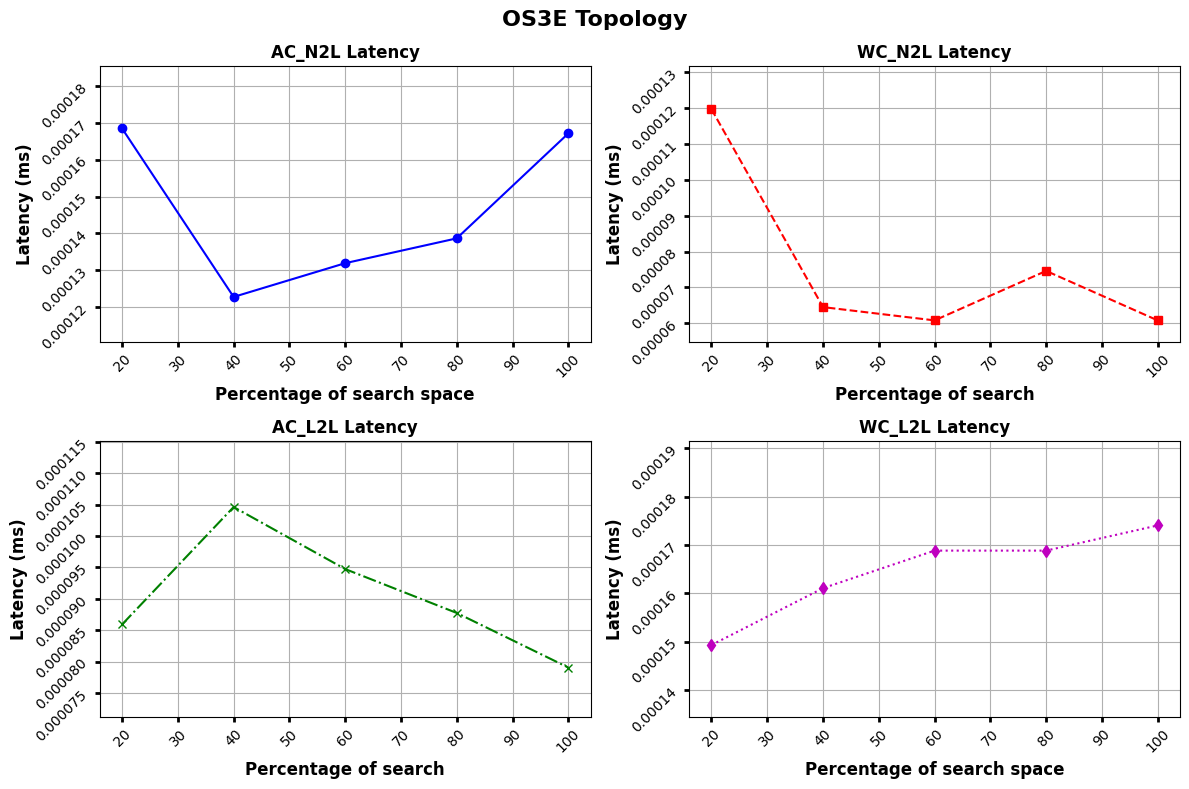

In [ ]:
import matplotlib.pyplot as plt

# Extract percentages
percentages = list(latency_results_per_percentage.keys())
percentages.sort()  # To make sure percentages are in ascending order

# Extract values for each type of latency
total_average_latencies = [latency_results_per_percentage[p]['total_average_latency'] for p in percentages]
max_worst_case_latencies = [latency_results_per_percentage[p]['max_worst_case_latency'] for p in percentages]
average_controller_latencies = [latency_results_per_percentage[p]['average_controller_latency'] for p in percentages]
max_pairwise_worst_case_latencies = [latency_results_per_percentage[p]['max_pairwise_worst_case_latency'] for p in percentages]

# Create subplots for each latency type
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Add a title at the center of the top of the plots
fig.suptitle('OS3E Topology', fontsize=16, fontweight='bold')

# Plot 1: Total Average Latency
axs[0, 0].plot(percentages, total_average_latencies, marker='o', linestyle='-', color='b')
axs[0, 0].set_title('AC_N2L Latency', fontsize=12, fontweight='bold')
axs[0, 0].set_xlabel('Percentage of search space', fontsize=12, fontweight='bold')
axs[0, 0].set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')
axs[0, 0].set_ylim([min(total_average_latencies) * 0.9, max(total_average_latencies) * 1.1])
axs[0, 0].grid(True)

# Bolden tick labels for the first plot
axs[0, 0].tick_params(axis='both', which='major', labelsize=10, labelrotation=45, width=2)


# Plot 2: Maximum Worst-Case Latency
axs[0, 1].plot(percentages, max_worst_case_latencies, marker='s', linestyle='--', color='r')
axs[0, 1].set_title('WC_N2L Latency', fontsize=12, fontweight='bold')
axs[0, 1].set_xlabel('Percentage of search', fontsize=12, fontweight='bold')
axs[0, 1].set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')
axs[0, 1].set_ylim([min(max_worst_case_latencies) * 0.9, max(max_worst_case_latencies) * 1.1])
axs[0, 1].grid(True)

# Bolden tick labels for the second plot
axs[0, 1].tick_params(axis='both', which='major', labelsize=10, labelrotation=45, width=2)

# Plot 3: Average Controller-to-Controller Latency
axs[1, 0].plot(percentages, average_controller_latencies, marker='x', linestyle='-.', color='g')
axs[1, 0].set_title('AC_L2L Latency', fontsize=12, fontweight='bold')
axs[1, 0].set_xlabel('Percentage of search', fontsize=12, fontweight='bold')
axs[1, 0].set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')
axs[1, 0].set_ylim([min(average_controller_latencies) * 0.9, max(average_controller_latencies) * 1.1])
axs[1, 0].grid(True)

# Bolden tick labels for the third plot
axs[1, 0].tick_params(axis='both', which='major', labelsize=10, labelrotation=45, width=2)

# Plot 4: Maximum Pairwise Worst-Case Latency
axs[1, 1].plot(percentages, max_pairwise_worst_case_latencies, marker='d', linestyle=':', color='m')
axs[1, 1].set_title('WC_L2L Latency', fontsize=12, fontweight='bold')
axs[1, 1].set_xlabel('Percentage of search space', fontsize=12, fontweight='bold')
axs[1, 1].set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')
axs[1, 1].set_ylim([min(max_pairwise_worst_case_latencies) * 0.9, max(max_pairwise_worst_case_latencies) * 1.1])
axs[1, 1].grid(True)

# Bolden tick labels for the fourth plot
axs[1, 1].tick_params(axis='both', which='major', labelsize=10, labelrotation=45, width=2)


# Adjust layout to avoid overlapping
plt.tight_layout()

# Show the plots
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming latency_results_per_percentage is already defined
# Extract percentages
percentages = list(latency_results_per_percentage.keys())
percentages.sort()  # To ensure percentages are in ascending order

# Extract values for each type of latency
total_average_latencies = [latency_results_per_percentage[p]['total_average_latency'] for p in percentages]
max_worst_case_latencies = [latency_results_per_percentage[p]['max_worst_case_latency'] for p in percentages]
average_controller_latencies = [latency_results_per_percentage[p]['average_controller_latency'] for p in percentages]
max_pairwise_worst_case_latencies = [latency_results_per_percentage[p]['max_pairwise_worst_case_latency'] for p in percentages]

# Create a DataFrame for easy tabular representation
latency_data = pd.DataFrame({
    'Percentage': percentages,
    'Total Average Latency (ms)': total_average_latencies,
    'Max Worst Case Latency (ms)': max_worst_case_latencies,
    'Average Controller Latency (ms)': average_controller_latencies,
    'Max Pairwise Worst Case Latency (ms)': max_pairwise_worst_case_latencies
})

# Print the DataFrame to console (for quick verification)
print(latency_data)

# Save the DataFrame to a CSV file
latency_data.to_csv('JEC_DNBE_comparison.csv', index=False)


   Percentage  Total Average Latency (ms)  Max Worst Case Latency (ms)  \
0          20                    0.000169                     0.000120   
1          40                    0.000123                     0.000064   
2          60                    0.000132                     0.000061   
3          80                    0.000139                     0.000075   
4         100                    0.000167                     0.000061   

   Average Controller Latency (ms)  Max Pairwise Worst Case Latency (ms)  
0                         0.000086                              0.000149  
1                         0.000105                              0.000161  
2                         0.000095                              0.000169  
3                         0.000088                              0.000169  
4                         0.000079                              0.000174  


In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # Assuming latency_results_per_percentage is already defined
# # Extract percentages
# percentages = list(latency_results_per_percentage.keys())
# percentages.sort()  # To ensure percentages are in ascending order

# # Extract values for each type of latency
# total_average_latencies = [latency_results_per_percentage[p]['total_average_latency'] for p in percentages]
# max_worst_case_latencies = [latency_results_per_percentage[p]['max_worst_case_latency'] for p in percentages]
# average_controller_latencies = [latency_results_per_percentage[p]['average_controller_latency'] for p in percentages]
# max_pairwise_worst_case_latencies = [latency_results_per_percentage[p]['max_pairwise_worst_case_latency'] for p in percentages]

# # Create a DataFrame for easy tabular representation
# latency_data = pd.DataFrame({
#     'Percentage': percentages,
#     'Total Average Latency (ms)': total_average_latencies,
#     'Max Worst Case Latency (ms)': max_worst_case_latencies,
#     'Average Controller Latency (ms)': average_controller_latencies,
#     'Max Pairwise Worst Case Latency (ms)': max_pairwise_worst_case_latencies
# })

# # Print the DataFrame to console (for quick verification)
# print(latency_data)

# # Save the DataFrame to a CSV file
# latency_data.to_csv('JEC_DNB_comparison.csv', index=False)


In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # Assuming latency_results_per_percentage is already defined
# # Extract percentages
# percentages = list(latency_results_per_percentage.keys())
# percentages.sort()  # To ensure percentages are in ascending order

# # Extract values for each type of latency
# total_average_latencies = [latency_results_per_percentage[p]['total_average_latency'] for p in percentages]
# max_worst_case_latencies = [latency_results_per_percentage[p]['max_worst_case_latency'] for p in percentages]
# average_controller_latencies = [latency_results_per_percentage[p]['average_controller_latency'] for p in percentages]
# max_pairwise_worst_case_latencies = [latency_results_per_percentage[p]['max_pairwise_worst_case_latency'] for p in percentages]

# # Create a DataFrame for easy tabular representation
# latency_data = pd.DataFrame({
#     'Percentage': percentages,
#     'Total Average Latency (ms)': total_average_latencies,
#     'Max Worst Case Latency (ms)': max_worst_case_latencies,
#     'Average Controller Latency (ms)': average_controller_latencies,
#     'Max Pairwise Worst Case Latency (ms)': max_pairwise_worst_case_latencies
# })

# # Print the DataFrame to console (for quick verification)
# print(latency_data)

# # Save the DataFrame to a CSV file
# latency_data.to_csv('JEC_DN_comparison.csv', index=False)


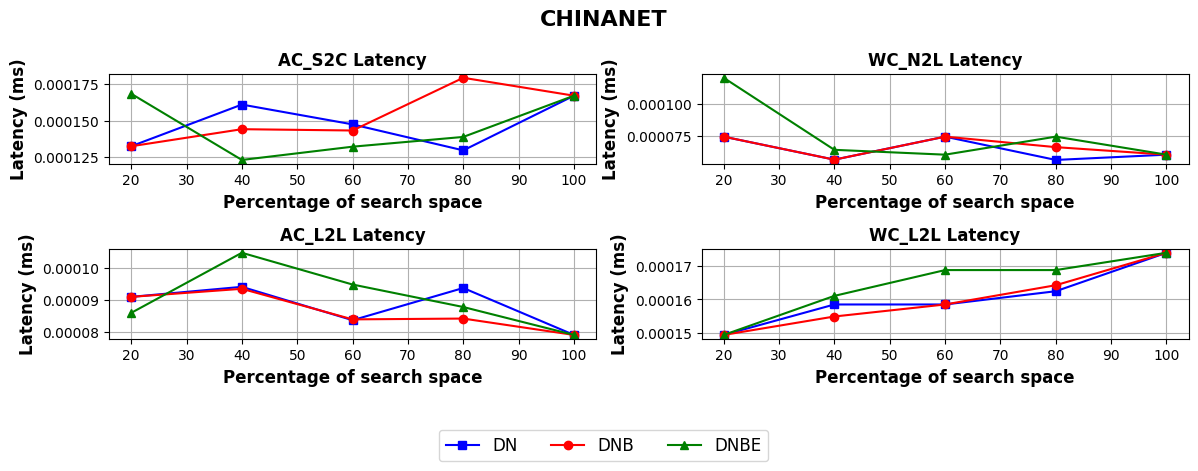

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV files
dn_data = pd.read_csv('JEC_DN_comparison.csv')
dnb_data = pd.read_csv('JEC_DNB_comparison.csv')
dnbe_data = pd.read_csv('JEC_DNBE_comparison.csv')

# Strip spaces from column names
dn_data.columns = dn_data.columns.str.strip()
dnb_data.columns = dnb_data.columns.str.strip()
dnbe_data.columns = dnbe_data.columns.str.strip()

# Extract percentages and latencies for DN
dn_percentages = dn_data['Percentage'].tolist()
dn_total_average_latencies = dn_data['Total Average Latency (ms)'].tolist()
dn_max_worst_case_latencies = dn_data['Max Worst Case Latency (ms)'].tolist()
dn_average_controller_latencies = dn_data['Average Controller Latency (ms)'].tolist()
dn_max_pairwise_worst_case_latencies = dn_data['Max Pairwise Worst Case Latency (ms)'].tolist()

# Extract percentages and latencies for DNB
dnb_percentages = dnb_data['Percentage'].tolist()
dnb_total_average_latencies = dnb_data['Total Average Latency (ms)'].tolist()
dnb_max_worst_case_latencies = dnb_data['Max Worst Case Latency (ms)'].tolist()
dnb_average_controller_latencies = dnb_data['Average Controller Latency (ms)'].tolist()
dnb_max_pairwise_worst_case_latencies = dnb_data['Max Pairwise Worst Case Latency (ms)'].tolist()

# Extract percentages and latencies for DNBE
dnbe_percentages = dnbe_data['Percentage'].tolist()
dnbe_total_average_latencies = dnbe_data['Total Average Latency (ms)'].tolist()
dnbe_max_worst_case_latencies = dnbe_data['Max Worst Case Latency (ms)'].tolist()
dnbe_average_controller_latencies = dnbe_data['Average Controller Latency (ms)'].tolist()
dnbe_max_pairwise_worst_case_latencies = dnbe_data['Max Pairwise Worst Case Latency (ms)'].tolist()

# Create subplots for each latency type
fig, axs = plt.subplots(2, 2, figsize=(12, 4))

# Add a title at the center of the top of the plots
fig.suptitle('CHINANET', fontsize=16, fontweight='bold')

# Plot 1: Total Average Latency
axs[0, 0].plot(dn_percentages, dn_total_average_latencies, marker='s', linestyle='-', color='b', label='DN')
axs[0, 0].plot(dnb_percentages, dnb_total_average_latencies, marker='o', linestyle='-', color='r', label='DNB')
axs[0, 0].plot(dnbe_percentages, dnbe_total_average_latencies, marker='^', linestyle='-', color='g', label='DNBE')
axs[0, 0].set_title('AC_S2C Latency', fontsize=12, fontweight='bold')
axs[0, 0].set_xlabel('Percentage of search space', fontsize=12, fontweight='bold')
axs[0, 0].set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')
axs[0, 0].grid(True)
# axs[0, 0].legend()

# Plot 2: Maximum Worst-Case Latency
axs[0, 1].plot(dn_percentages, dn_max_worst_case_latencies, marker='s', linestyle='-', color='b', label='DN')
axs[0, 1].plot(dnb_percentages, dnb_max_worst_case_latencies, marker='o', linestyle='-', color='r', label='DNB')
axs[0, 1].plot(dnbe_percentages, dnbe_max_worst_case_latencies, marker='^', linestyle='-', color='g', label='DNBE')
axs[0, 1].set_title('WC_N2L Latency', fontsize=12, fontweight='bold')
axs[0, 1].set_xlabel('Percentage of search space', fontsize=12, fontweight='bold')
axs[0, 1].set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')
axs[0, 1].grid(True)
# axs[0, 1].legend()

# Plot 3: Average Controller Latency
axs[1, 0].plot(dn_percentages, dn_average_controller_latencies, marker='s', linestyle='-', color='b', label='DN')
axs[1, 0].plot(dnb_percentages, dnb_average_controller_latencies, marker='o', linestyle='-', color='r', label='DNB')
axs[1, 0].plot(dnbe_percentages, dnbe_average_controller_latencies, marker='^', linestyle='-', color='g', label='DNBE')
axs[1, 0].set_title('AC_L2L Latency', fontsize=12, fontweight='bold')
axs[1, 0].set_xlabel('Percentage of search space', fontsize=12, fontweight='bold')
axs[1, 0].set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')
axs[1, 0].grid(True)
# axs[1, 0].legend()

# Plot 4: Maximum Pairwise Worst-Case Latency
axs[1, 1].plot(dn_percentages, dn_max_pairwise_worst_case_latencies, marker='s', linestyle='-', color='b', label='DN')
axs[1, 1].plot(dnb_percentages, dnb_max_pairwise_worst_case_latencies, marker='o', linestyle='-', color='r', label='DNB')
axs[1, 1].plot(dnbe_percentages, dnbe_max_pairwise_worst_case_latencies, marker='^', linestyle='-', color='g', label='DNBE')
axs[1, 1].set_title('WC_L2L Latency', fontsize=12, fontweight='bold')
axs[1, 1].set_xlabel('Percentage of search space', fontsize=12, fontweight='bold')
axs[1, 1].set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')
axs[1, 1].grid(True)
# axs[1, 1].legend()

# Place a single legend outside of the subplots
fig.legend(['DN', 'DNB', 'DNBE'], loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3, fontsize=12)


# Adjust layout to avoid overlapping
plt.tight_layout()

# Show the plots
plt.show()


In [ ]:
ttt
mport pandas as pd

# Load the CSV file
csv_file_path = 'latency_results_comparison.csv'
comparison_data = pd.read_csv(csv_file_path)

# Check the first few rows and the columns of the DataFrame
print(comparison_data.head())  # Show the first few rows
print(comparison_data.columns)  # Show the column names


SyntaxError: invalid syntax (2966662964.py, line 2)

In [ ]:
import os

# List all files in the current directory
print(os.listdir(os.getcwd()))


['.ipynb_checkpoints', '.vs', 'ABVT_2.png', 'algorithms.py', 'algo_rank.py', 'amazon', 'average_case_controller_to_controller.csv', 'average_case_controller_to_switch.csv', 'binary_tree', 'books_read.png', 'CEnew', 'condmat', 'controller_switch_id.csv', 'controller_switch_id_ranked.csv', 'CPP.ipynb', 'CP_simulator', 'custom_topology.py', 'dblp', 'different_multi -2.py', 'different_multi-2.ipynb', 'different_multi-5.ipynb', 'different_multi-5.py', 'different_multi-6.txt', 'different_multi.ipynb', 'different_multi3.ipynb', 'different_multi4.ipynb', 'different_multiple-6.ipynb', 'different_order_in_EnRenewRank.ipynb', 'different_plots.ipynb', 'ditg.log', 'EBCP09122023.ipynb', 'email', 'EviContPlacment.ipynb', 'EvidentialPlacement.py', 'exp_1_diff_sets.ipynb', 'exp_2_diff_lambda.ipynb', 'facebook', 'fastsim', 'Fig3.1.png', 'get_avg_shortest_length.ipynb', 'Gowalla', 'hamster', 'HepPh', 'images', 'images_1000', 'images_2', 'images_3', 'images_4', 'Internet2LatLong.csv', 'Internet2Mininet.JP

In [ ]:
import pandas as pd

# Load the CSV file
csv_file_path = 'latency_results_comparison.csv'
comparison_data = pd.read_csv(csv_file_path)

# Strip spaces from column names
comparison_data.columns = comparison_data.columns.str.strip()

# Extract the relevant data into lists
comparison_percentages = comparison_data['Percentage'].tolist()
comparison_total_average_latencies = comparison_data['Total Average Latency (ms)'].tolist()
comparison_max_worst_case_latencies = comparison_data['Max Worst Case Latency (ms)'].tolist()
comparison_average_controller_latencies = comparison_data['Average Controller Latency (ms)'].tolist()
comparison_max_pairwise_worst_case_latencies = comparison_data['Max Pairwise Worst Case Latency (ms)'].tolist()

# Check the extracted lists
print("Percentages:", comparison_percentages)
print("Total Average Latencies:", comparison_total_average_latencies)
print("Max Worst Case Latencies:", comparison_max_worst_case_latencies)
print("Average Controller Latencies:", comparison_average_controller_latencies)
print("Max Pairwise Worst Case Latencies:", comparison_max_pairwise_worst_case_latencies)


Percentages: [20, 40, 60, 80, 100]
Total Average Latencies: [0.0001484378653846, 0.0001586845555555, 0.0001452835897435, 0.0001963746428571, 0.0001519534999999]
Max Worst Case Latencies: [8.3655e-05, 8.3655e-05, 5.6945e-05, 3.753e-05, 5.372999999999999e-05]
Average Controller Latencies: [6.933666666666666e-05, 9.924e-05, 9.392866666666668e-05, 8.860083333333337e-05, 9.149214285714283e-05]
Max Pairwise Worst Case Latencies: [0.000104005, 0.00015849, 0.00017334, 0.00017334, 0.000164015]


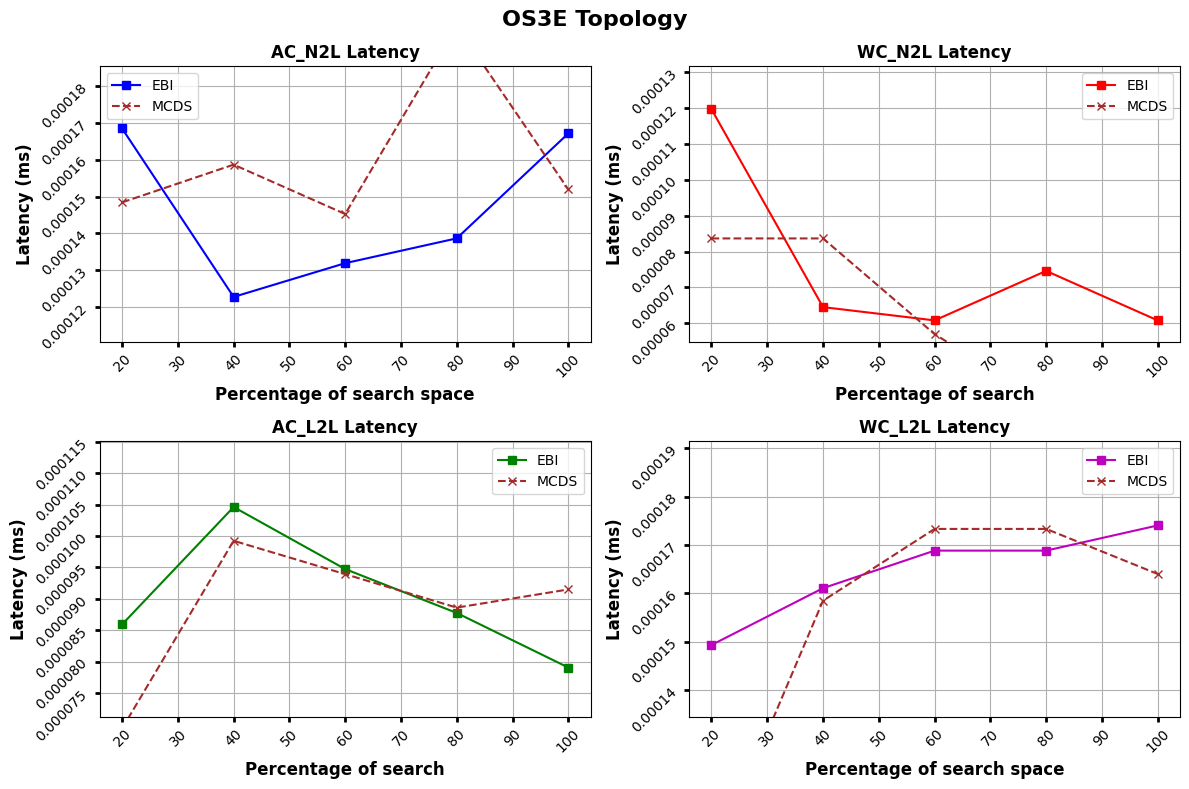

In [ ]:

import pandas as pd

# Load the CSV file
csv_file_path = 'latency_results_comparison.csv'
comparison_data = pd.read_csv(csv_file_path)

# Strip spaces from column names
comparison_data.columns = comparison_data.columns.str.strip()

# Extract the relevant data into lists
comparison_percentages = comparison_data['Percentage'].tolist()
comparison_total_average_latencies = comparison_data['Total Average Latency (ms)'].tolist()
comparison_max_worst_case_latencies = comparison_data['Max Worst Case Latency (ms)'].tolist()
comparison_average_controller_latencies = comparison_data['Average Controller Latency (ms)'].tolist()
comparison_max_pairwise_worst_case_latencies = comparison_data['Max Pairwise Worst Case Latency (ms)'].tolist()

# # Check the extracted lists
# print("Percentages:", comparison_percentages)
# print("Total Average Latencies:", comparison_total_average_latencies)
# print("Max Worst Case Latencies:", comparison_max_worst_case_latencies)
# print("Average Controller Latencies:", comparison_average_controller_latencies)
# print("Max Pairwise Worst Case Latencies:", comparison_max_pairwise_worst_case_latencies)




# # Check the extracted lists
# print("Percentages:", comparison_percentages)
# print("Total Average Latencies:", comparison_total_average_latencies)
# print("Max Worst Case Latencies:", comparison_max_worst_case_latencies)
# print("Average Controller Latencies:", comparison_average_controller_latencies)
# print("Max Pairwise Worst Case Latencies:", comparison_max_pairwise_worst_case_latencies)


# Extract percentages
percentages = list(latency_results_per_percentage.keys())
percentages.sort()  # Ensure percentages are in ascending order

# Extract values for each type of latency
total_average_latencies = [latency_results_per_percentage[p]['total_average_latency'] for p in percentages]
max_worst_case_latencies = [latency_results_per_percentage[p]['max_worst_case_latency'] for p in percentages]
average_controller_latencies = [latency_results_per_percentage[p]['average_controller_latency'] for p in percentages]
max_pairwise_worst_case_latencies = [latency_results_per_percentage[p]['max_pairwise_worst_case_latency'] for p in percentages]

# Create subplots for each latency type
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Add a title at the center of the top of the plots
fig.suptitle('OS3E Topology', fontsize=16, fontweight='bold')

# Plot 1: Total Average Latency
axs[0, 0].plot(percentages, total_average_latencies, marker='s', linestyle='-', color='b', label='EBI')
axs[0, 0].plot(comparison_percentages, comparison_total_average_latencies, marker='x', linestyle='--', color='brown', label='MCDS')
axs[0, 0].set_title('AC_N2L Latency', fontsize=12, fontweight='bold')
axs[0, 0].set_xlabel('Percentage of search space', fontsize=12, fontweight='bold')
axs[0, 0].set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')
axs[0, 0].set_ylim([min(total_average_latencies) * 0.9, max(total_average_latencies) * 1.1])
axs[0, 0].grid(True)
axs[0, 0].legend()  # Add legend

# Bolden tick labels for the first plot
axs[0, 0].tick_params(axis='both', which='major', labelsize=10, labelrotation=45, width=2)

# Plot 2: Maximum Worst-Case Latency
axs[0, 1].plot(percentages, max_worst_case_latencies, marker='s', linestyle='-', color='r', label='EBI')
axs[0, 1].plot(comparison_percentages, comparison_max_worst_case_latencies, marker='x', linestyle='--', color='brown', label='MCDS')
axs[0, 1].set_title('WC_N2L Latency', fontsize=12, fontweight='bold')
axs[0, 1].set_xlabel('Percentage of search', fontsize=12, fontweight='bold')
axs[0, 1].set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')
axs[0, 1].set_ylim([min(max_worst_case_latencies) * 0.9, max(max_worst_case_latencies) * 1.1])
axs[0, 1].grid(True)
axs[0, 1].legend()  # Add legend

# Bolden tick labels for the second plot
axs[0, 1].tick_params(axis='both', which='major', labelsize=10, labelrotation=45, width=2)

# Plot 3: Average Controller-to-Controller Latency
axs[1, 0].plot(percentages, average_controller_latencies, marker='s', linestyle='-', color='g', label='EBI')
axs[1, 0].plot(comparison_percentages, comparison_average_controller_latencies, marker='x', linestyle='--', color='brown', label='MCDS')
axs[1, 0].set_title('AC_L2L Latency', fontsize=12, fontweight='bold')
axs[1, 0].set_xlabel('Percentage of search', fontsize=12, fontweight='bold')
axs[1, 0].set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')
axs[1, 0].set_ylim([min(average_controller_latencies) * 0.9, max(average_controller_latencies) * 1.1])
axs[1, 0].grid(True)
axs[1, 0].legend()  # Add legend

# Bolden tick labels for the third plot
axs[1, 0].tick_params(axis='both', which='major', labelsize=10, labelrotation=45, width=2)

# Plot 4: Maximum Pairwise Worst-Case Latency
axs[1, 1].plot(percentages, max_pairwise_worst_case_latencies, marker='s', linestyle='-', color='m', label='EBI')
axs[1, 1].plot(comparison_percentages, comparison_max_pairwise_worst_case_latencies, marker='x', linestyle='--', color='brown', label='MCDS')
axs[1, 1].set_title('WC_L2L Latency', fontsize=12, fontweight='bold')
axs[1, 1].set_xlabel('Percentage of search space', fontsize=12, fontweight='bold')
axs[1, 1].set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')
axs[1, 1].set_ylim([min(max_pairwise_worst_case_latencies) * 0.9, max(max_pairwise_worst_case_latencies) * 1.1])
axs[1, 1].grid(True)
axs[1, 1].legend()  # Add legend

# Bolden tick labels for the fourth plot
axs[1, 1].tick_params(axis='both', which='major', labelsize=10, labelrotation=45, width=2)

# Adjust layout to avoid overlapping
plt.tight_layout()

# Show the plots
plt.show()


ValueError: min() arg is an empty sequence

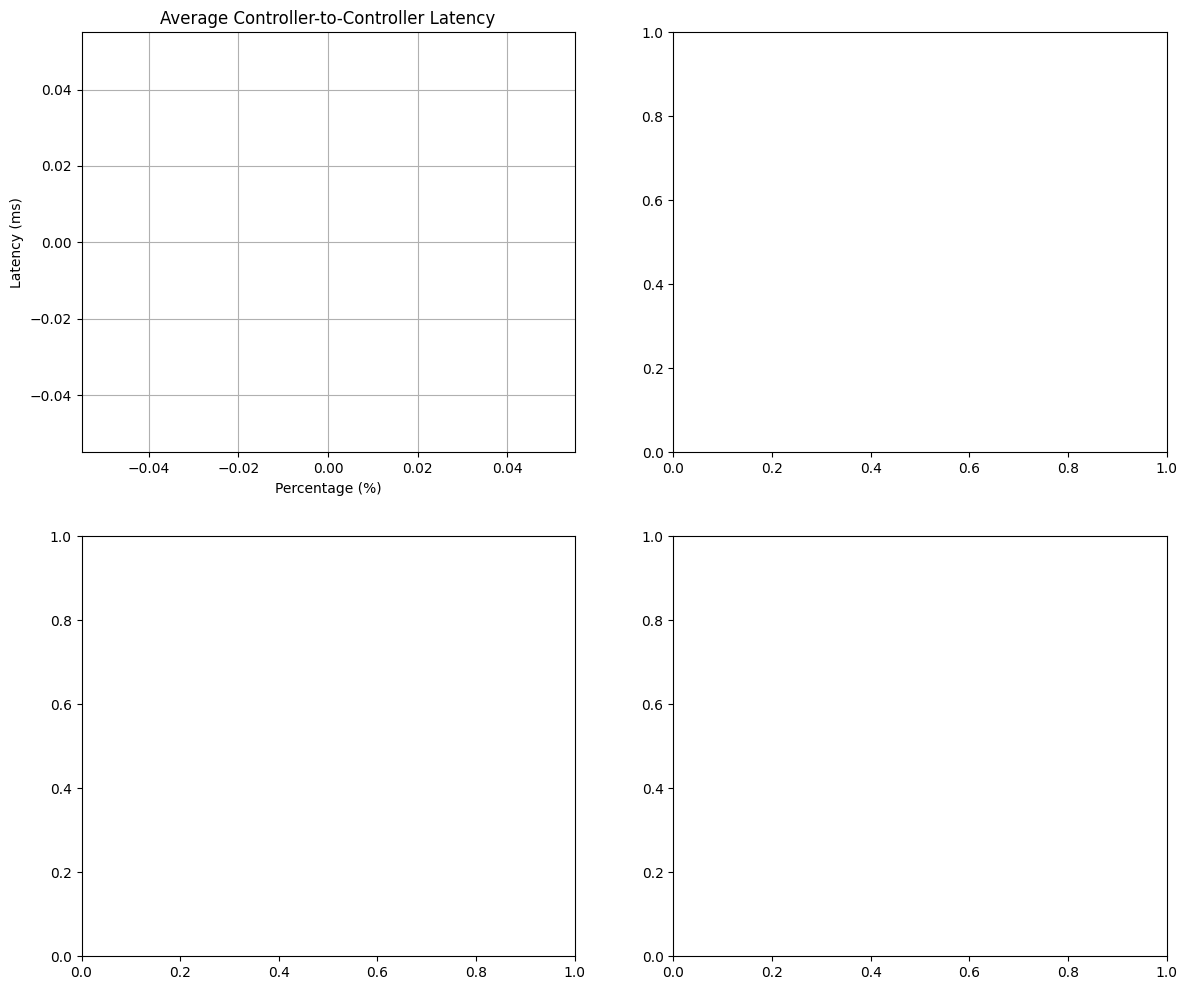

In [ ]:
import matplotlib.pyplot as plt

# Initialize lists to store performance metrics for each percentage
percentages = []
average_controller_latencies = []
max_pairwise_worst_case_latencies = []
total_average_latencies = []
max_worst_case_latencies = []

# Step 1: Loop over percentages and extract the metrics for each percentage from table_data
for percentage, table_data in table_data_per_percentage.items():
    # Append the current percentage to the list
    percentages.append(percentage)
    
    # Step 2: Extract latency values from the table_data
    average_controller_latency = float(table_data[0])
    max_pairwise_worst_case_latency = float(table_data[1])
    total_average_latency = float(table_data[2])
    max_worst_case_latency = float(table_data[3])
    
    # Step 3: Append the extracted latencies to the lists
    average_controller_latencies.append(average_controller_latency)
    max_pairwise_worst_case_latencies.append(max_pairwise_worst_case_latency)
    total_average_latencies.append(total_average_latency)
    max_worst_case_latencies.append(max_worst_case_latency)

# Step 4: Create subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Average Controller-to-Controller Latency
axs[0, 0].plot(percentages, average_controller_latencies, marker='o', linestyle='-', color='b')
axs[0, 0].set_title('Average Controller-to-Controller Latency')
axs[0, 0].set_xlabel('Percentage (%)')
axs[0, 0].set_ylabel('Latency (ms)')
axs[0, 0].grid(True)
axs[0, 0].set_ylim([min(average_controller_latencies) * 0.9, max(average_controller_latencies) * 1.1])

# Plot 2: Maximum Pairwise Worst-Case Latency
axs[0, 1].plot(percentages, max_pairwise_worst_case_latencies, marker='s', linestyle='--', color='r')
axs[0, 1].set_title('Maximum Pairwise Worst-Case Latency')
axs[0, 1].set_xlabel('Percentage (%)')
axs[0, 1].set_ylabel('Latency (ms)')
axs[0, 1].grid(True)
axs[0, 1].set_ylim([min(max_pairwise_worst_case_latencies) * 0.9, max(max_pairwise_worst_case_latencies) * 1.1])

# Plot 3: Total Average Latency (Node-to-Controller)
axs[1, 0].plot(percentages, total_average_latencies, marker='d', linestyle='-.', color='g')
axs[1, 0].set_title('Total Average Latency (Node-to-Controller)')
axs[1, 0].set_xlabel('Percentage (%)')
axs[1, 0].set_ylabel('Latency (ms)')
axs[1, 0].grid(True)
axs[1, 0].set_ylim([min(total_average_latencies) * 0.9, max(total_average_latencies) * 1.1])

# Plot 4: Maximum Worst-Case Latency (Node-to-Controller)
axs[1, 1].plot(percentages, max_worst_case_latencies, marker='^', linestyle=':', color='m')
axs[1, 1].set_title('Maximum Worst-Case Latency (Node-to-Controller)')
axs[1, 1].set_xlabel('Percentage (%)')
axs[1, 1].set_ylabel('Latency (ms)')
axs[1, 1].grid(True)
axs[1, 1].set_ylim([min(max_worst_case_latencies) * 0.9, max(max_worst_case_latencies) * 1.1])

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the plots
plt.show()


In [ ]:
average_controller_latencies

[]

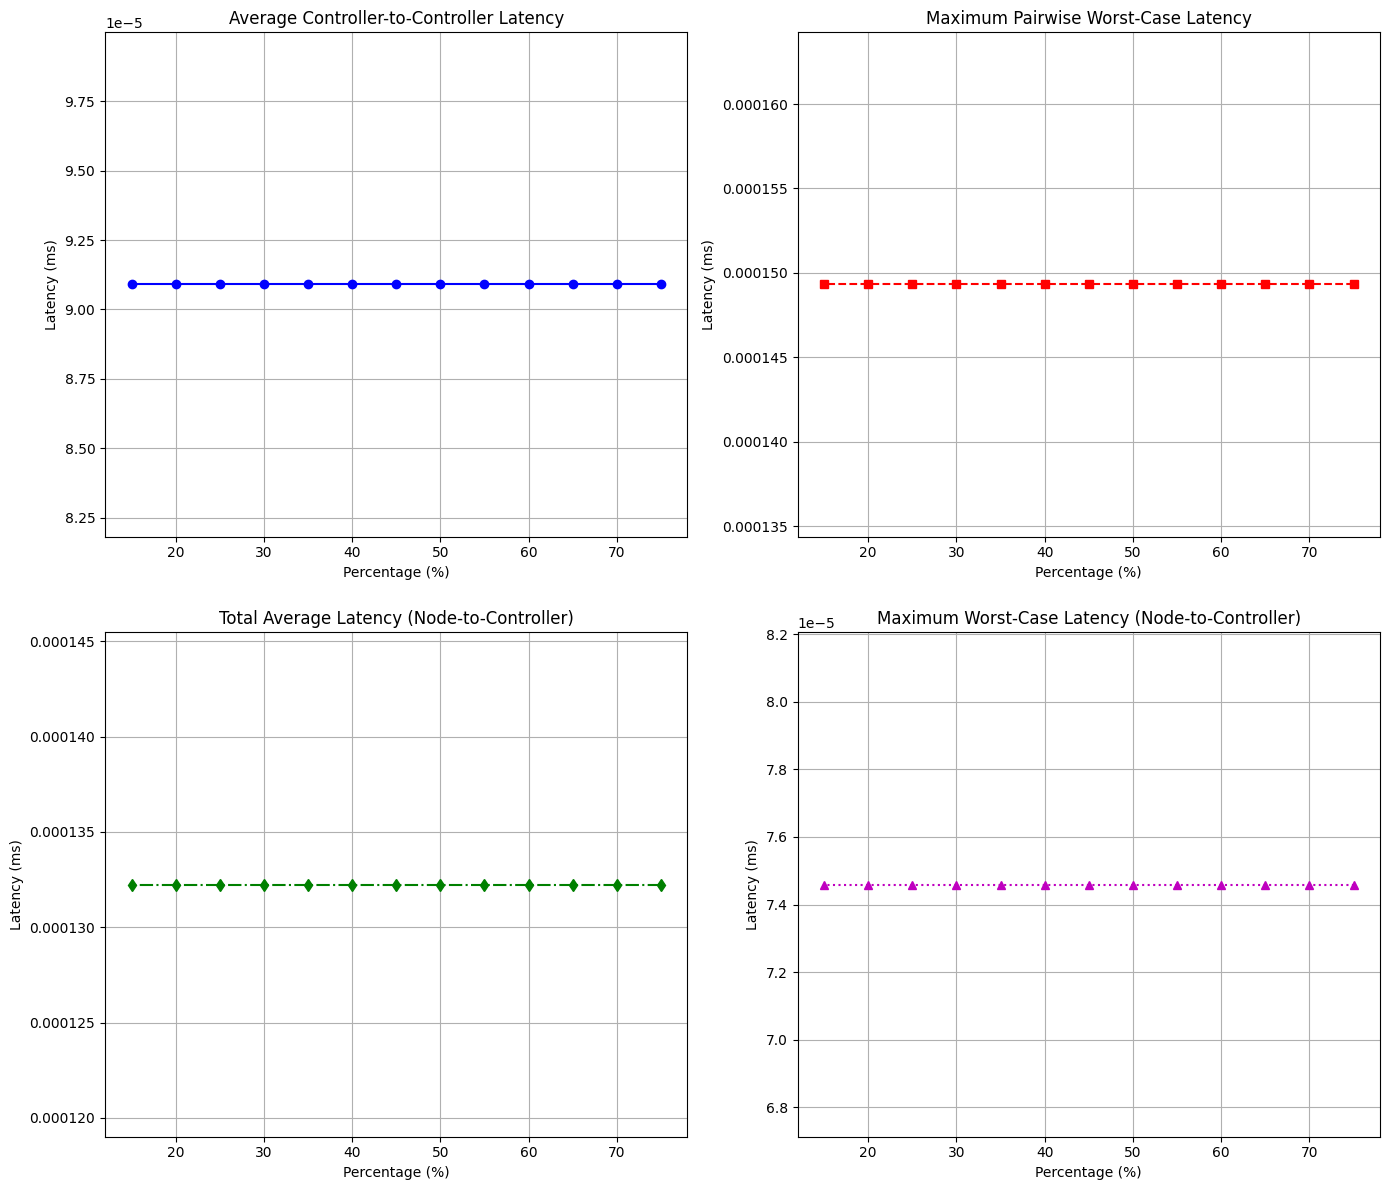

In [ ]:
import matplotlib.pyplot as plt

# Initialize lists to store performance metrics for each percentage
percentages = []
average_controller_latencies = []
max_pairwise_worst_case_latencies = []
total_average_latencies = []
max_worst_case_latencies = []

# Step 1: Loop over percentages and gather the metrics for each percentage
for percentage, assigned_nodes_dict in assigned_nodes_dicts.items():
    percentages.append(percentage)

    # Here we're assuming you already have the calculations for these latencies
    # Append the respective latency metrics for the current percentage
    average_controller_latencies.append(average_controller_latency)
    max_pairwise_worst_case_latencies.append(max_pairwise_worst_case_latency)
    total_average_latencies.append(total_average_latency)
    max_worst_case_latencies.append(max_worst_case_latency)

# Step 2: Create subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Average Controller-to-Controller Latency
axs[0, 0].plot(percentages, average_controller_latencies, marker='o', linestyle='-', color='b')
axs[0, 0].set_title('Average Controller-to-Controller Latency')
axs[0, 0].set_xlabel('Percentage (%)')
axs[0, 0].set_ylabel('Latency (ms)')
axs[0, 0].grid(True)  # Add gridlines
axs[0, 0].set_ylim([min(average_controller_latencies) * 0.9, max(average_controller_latencies) * 1.1])  # Scale up

# Plot 2: Maximum Pairwise Worst-Case Latency
axs[0, 1].plot(percentages, max_pairwise_worst_case_latencies, marker='s', linestyle='--', color='r')
axs[0, 1].set_title('Maximum Pairwise Worst-Case Latency')
axs[0, 1].set_xlabel('Percentage (%)')
axs[0, 1].set_ylabel('Latency (ms)')
axs[0, 1].grid(True)
axs[0, 1].set_ylim([min(max_pairwise_worst_case_latencies) * 0.9, max(max_pairwise_worst_case_latencies) * 1.1])

# Plot 3: Total Average Latency (Node-to-Controller)
axs[1, 0].plot(percentages, total_average_latencies, marker='d', linestyle='-.', color='g')
axs[1, 0].set_title('Total Average Latency (Node-to-Controller)')
axs[1, 0].set_xlabel('Percentage (%)')
axs[1, 0].set_ylabel('Latency (ms)')
axs[1, 0].grid(True)
axs[1, 0].set_ylim([min(total_average_latencies) * 0.9, max(total_average_latencies) * 1.1])

# Plot 4: Maximum Worst-Case Latency (Node-to-Controller)
axs[1, 1].plot(percentages, max_worst_case_latencies, marker='^', linestyle=':', color='m')
axs[1, 1].set_title('Maximum Worst-Case Latency (Node-to-Controller)')
axs[1, 1].set_xlabel('Percentage (%)')
axs[1, 1].set_ylabel('Latency (ms)')
axs[1, 1].grid(True)
axs[1, 1].set_ylim([min(max_worst_case_latencies) * 0.9, max(max_worst_case_latencies) * 1.1])

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the plots
plt.show()


In [ ]:
tttt

NameError: name 'tttt' is not defined

In [ ]:
import networkx as nx

# Assuming you have a graph G with edge weights representing distances between nodes
# and that you have a dictionary 'updated_assignments' mapping controllers to their assigned nodes.

# Initialize a dictionary to store average and worst-case latencies for each controller
latency_results = {}

# Variables to calculate total average and maximum worst-case latencies
total_average_latency = 0
max_worst_case_latency = float('-inf')  # Start with the smallest possible value

# Variables to calculate average controller-to-controller latency and maximum worst-case between controllers
total_controller_latency = 0
controller_pairs = 0
max_pairwise_worst_case_latency = float('-inf')

# Calculate average and worst-case latencies for each controller
for controller, assigned_nodes in updated_assignments.items():
    total_latency = 0
    worst_case_latency = float('-inf')  # Start with the smallest possible value

    for node in assigned_nodes:
        # Calculate shortest path length from controller to the assigned node
        latency = nx.shortest_path_length(G, source=controller, target=node, weight='weight')
        
        # Convert latency to milliseconds (if needed)
        latency_ms = (latency * 1000) / (2 * 1e8)  # Adjust based on your specific formula
        
        # Update total latency
        total_latency += latency_ms
        
        # Update worst case latency
        worst_case_latency = max(worst_case_latency, latency_ms)

    # Calculate average latency (if there are assigned nodes)
    if assigned_nodes:
        average_latency = total_latency / len(assigned_nodes)
        total_average_latency += average_latency  # Sum of all averages
    else:
        average_latency = 0  # or some other logic if no nodes are assigned

    # Update maximum worst-case latency
    max_worst_case_latency = max(max_worst_case_latency, worst_case_latency)

    # Store the results
    latency_results[controller] = {
        'average_latency': average_latency,
        'worst_case_latency': worst_case_latency
    }

# Calculate average controller-to-controller latency and max worst-case latency between pairs of controllers
for controller1 in updated_assignments.keys():
    for controller2 in updated_assignments.keys():
        if controller1 != controller2:
            # Calculate shortest path length between two controllers
            pairwise_latency = nx.shortest_path_length(G, source=controller1, target=controller2, weight='weight')
            pairwise_latency_ms = (pairwise_latency * 1000) / (2 * 1e8)  # Adjust based on your specific formula

            # Update total controller latency and count
            total_controller_latency += pairwise_latency_ms
            controller_pairs += 1

            # Update maximum pairwise worst-case latency
            max_pairwise_worst_case_latency = max(max_pairwise_worst_case_latency, pairwise_latency_ms)

# Calculate average controller-to-controller latency
average_controller_latency = total_controller_latency / controller_pairs if controller_pairs > 0 else 0

# Print the latency results for each controller
for controller, latencies in latency_results.items():
    print(f"Controller {controller}:")
    print(f"  Average Latency = {latencies['average_latency']:.15f} ms")
    print(f"  Worst-Case Latency = {latencies['worst_case_latency']:.15f} ms")

# Print total average and maximum worst-case latency
print(f"\nTotal Average Latency across all controllers = {total_average_latency:.15f} ms")
print(f"Maximum Worst-Case Latency among all controllers = {max_worst_case_latency:.15f} ms")

# Print average controller-to-controller latency and maximum pairwise worst-case latency
print(f"\nAverage Controller-to-Controller Latency = {average_controller_latency:.15f} ms")
print(f"Maximum Pairwise Worst-Case Latency = {max_pairwise_worst_case_latency:.15f} ms")


Controller 3:
  Average Latency = 0.000034380666667 ms
  Worst-Case Latency = 0.000056945000000 ms
Controller 32:
  Average Latency = 0.000022150000000 ms
  Worst-Case Latency = 0.000045900000000 ms
Controller 5:
  Average Latency = 0.000039465000000 ms
  Worst-Case Latency = 0.000061505000000 ms
Controller 24:
  Average Latency = 0.000036240000000 ms
  Worst-Case Latency = 0.000074590000000 ms

Total Average Latency across all controllers = 0.000132235666667 ms
Maximum Worst-Case Latency among all controllers = 0.000074590000000 ms

Average Controller-to-Controller Latency = 0.000090900833333 ms
Maximum Pairwise Worst-Case Latency = 0.000149315000000 ms


In [ ]:
import networkx as nx

# Function to calculate latencies
def calculate_latencies(updated_assignments, centroids, geo_loc_data, G):
    intra_cluster_latencies = {}
    inter_cluster_latencies = {}

    # Variables for total average and maximum worst-case latencies for intra-cluster
    total_intra_average_latency = 0
    max_intra_worst_case_latency = float('-inf')

    # Intra-cluster latencies
    for centroid in centroids:
        assigned_nodes = updated_assignments.get(centroid, [])

        if assigned_nodes:
            total_latency = 0
            worst_case_latency = float('-inf')

            for node in assigned_nodes:
                try:
                    # Calculate latency between centroid and node
                    latency = nx.shortest_path_length(G, source=centroid, target=node, weight='weight')
                    latency_ms = (latency * 1000) / (2 * 1e8)  # Adjust based on your specific formula
                    
                    # Update total latency and worst-case latency
                    total_latency += latency_ms
                    worst_case_latency = max(worst_case_latency, latency_ms)

                except KeyError:
                    print(f"No geographical data available for node {node} or centroid {centroid}. Skipping this node.")

            # Calculate average intra-cluster latency
            average_intra_latency = total_latency / len(assigned_nodes)
            intra_cluster_latencies[centroid] = {
                'average_latency': average_intra_latency,
                'worst_case_latency': worst_case_latency
            }
            total_intra_average_latency += average_intra_latency
            max_intra_worst_case_latency = max(max_intra_worst_case_latency, worst_case_latency)
        else:
            intra_cluster_latencies[centroid] = {'average_latency': 0, 'worst_case_latency': 0}  # No assigned nodes

    # Inter-cluster latencies
    for centroid in centroids:
        inter_cluster_latencies[centroid] = {}
        for other_centroid in centroids:
            if centroid != other_centroid:
                try:
                    # Calculate inter-cluster latency
                    inter_latency = nx.shortest_path_length(G, source=centroid, target=other_centroid, weight='weight')
                    inter_latency_ms = (inter_latency * 1000) / (2 * 1e8)  # Adjust based on your specific formula
                    inter_cluster_latencies[centroid][other_centroid] = inter_latency_ms
                    
                    # Update maximum inter-cluster worst-case latency
                    max_intra_worst_case_latency = max(max_intra_worst_case_latency, inter_latency_ms)
                    
                except KeyError:
                    print(f"No geographical data available for {centroid} or {other_centroid}. Skipping this pair.")

    return intra_cluster_latencies, inter_cluster_latencies, total_intra_average_latency, max_intra_worst_case_latency

# Example call (make sure to define updated_assignments, centroids, geo_loc_data, and G beforehand)
centroids = updated_controllers
intra_cluster_latencies, inter_cluster_latencies, total_intra_average_latency, max_intra_worst_case_latency = calculate_latencies(updated_assignments, centroids, geo_loc_data, G)

# Print results
print("\nIntra-Cluster Latencies:")
for centroid, latencies in intra_cluster_latencies.items():
    print(f"Centroid {centroid}: Average Latency = {latencies['average_latency']:.15f} ms, Worst-Case Latency = {latencies['worst_case_latency']:.15f} ms")

print(f"\nTotal Average Intra-Cluster Latency = {total_intra_average_latency:.15f} ms")
print(f"Maximum Intra-Cluster Worst-Case Latency = {max_intra_worst_case_latency:.15f} ms")

print("\nInter-Cluster Latencies:")
for centroid, latencies in inter_cluster_latencies.items():
    print(f"Centroid {centroid}: {latencies}")

# Calculate DBI
DBI_sum = 0
for controller in updated_controllers:
    # Get the average latency for the current controller
    S_i = intra_cluster_latencies.get(controller, {}).get('average_latency', 0)
    
    # Calculate M_ij_avg using inter-cluster latencies
    inter_latencies = inter_cluster_latencies.get(controller, {}).values()
    M_ij_avg = sum(inter_latencies) / (len(updated_controllers) - 1) if len(updated_controllers) > 1 else 0

    if M_ij_avg > 0:
        DBI_sum += S_i / M_ij_avg

DBI = DBI_sum / len(updated_controllers) if len(updated_controllers) > 1 else 0
print(f"\nDunn Index (DBI) = {DBI:.15f}")

# Calculate the Silhouette Score
silhouette_scores = []
for controller in updated_controllers:
    nodes_assigned = [node for node, assigned_head in closest_nodes_dict.items() if assigned_head == controller]
    if nodes_assigned:
        # Calculate a_Oi using latency calculation
        a_Oi = sum(calculate_latency(controller, node, geo_loc_data) for node in nodes_assigned) / len(nodes_assigned)

        b_Oi_list = []
        for other_location in updated_controllers:
            if other_location != controller:
                nodes_assigned_other = [node for node, assigned_head in closest_nodes_dict.items() if assigned_head == other_location]
                if nodes_assigned_other:
                    # Calculate b_Oi using latency calculation
                    b_Oi = sum(calculate_latency(controller, node, geo_loc_data) for node in nodes_assigned_other) / len(nodes_assigned_other)
                    b_Oi_list.append(b_Oi)

        b_Oi = min(b_Oi_list) if b_Oi_list else 0

        silhouette_score = (b_Oi - a_Oi) / max(a_Oi, b_Oi) if max(a_Oi, b_Oi) > 0 else 0
        silhouette_scores.append(silhouette_score)

overall_silhouette_score = sum(silhouette_scores) / len(silhouette_scores) if silhouette_scores else 0
print(f"\nOverall Silhouette Score = {overall_silhouette_score:.15f}")

# Calculate Within-Cluster Variance
within_cluster_variance = 0
for centroid in updated_controllers:
    assigned_nodes = [node for node, assigned_head in closest_nodes_dict.items() if assigned_head == centroid]
    within_cluster_variance += sum(
        calculate_latency(node, centroid, geo_loc_data)**2 for node in assigned_nodes
    )

# Calculate Between-Cluster Variance
between_cluster_variance = 0
centroid_list = list(updated_controllers)
for i in range(len(centroid_list)):
    for j in range(i + 1, len(centroid_list)):
        between_cluster_variance += calculate_latency(centroid_list[i], centroid_list[j], geo_loc_data)**2

# Calculate Calinski-Harabasz Index
N = len(G.nodes())
K = len(updated_controllers)
calinski_harabasz_index = (between_cluster_variance / (K - 1)) / (within_cluster_variance / (N - K)) if within_cluster_variance > 0 else 0
print(f"\nCalinski-Harabasz Index = {calinski_harabasz_index:.15f}")



Intra-Cluster Latencies:
Centroid 3: Average Latency = 0.000034380666667 ms, Worst-Case Latency = 0.000056945000000 ms
Centroid 32: Average Latency = 0.000022150000000 ms, Worst-Case Latency = 0.000045900000000 ms
Centroid 5: Average Latency = 0.000039465000000 ms, Worst-Case Latency = 0.000061505000000 ms
Centroid 24: Average Latency = 0.000036240000000 ms, Worst-Case Latency = 0.000074590000000 ms

Total Average Intra-Cluster Latency = 0.000132235666667 ms
Maximum Intra-Cluster Worst-Case Latency = 0.000149315000000 ms

Inter-Cluster Latencies:
Centroid 3: {'32': 0.000113325, '5': 6.2775e-05, '24': 7.0675e-05}
Centroid 32: {'3': 0.000113325, '5': 6.9285e-05, '24': 0.000149315}
Centroid 5: {'3': 6.2775e-05, '32': 6.9285e-05, '24': 8.003e-05}
Centroid 24: {'3': 7.0675e-05, '32': 0.000149315, '5': 8.003e-05}

Dunn Index (DBI) = 0.384690336387760

Overall Silhouette Score = 0.490832082348060

Calinski-Harabasz Index = 11.865183885440580


In [ ]:
tttt
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Step 1: Loop over percentages and print the assigned nodes dictionary
for percentage, assigned_nodes_dict in assigned_nodes_dicts.items():
    print(f"\nPercentage: {percentage}%")
    print("Assigned Node List:")

    # Function to reassign nodes and controllers with only one node
    def reassign_single_nodes(assigned_nodes_dict, G):
        while True:
            # Step 1: Identify controllers with only one assigned node
            controllers_to_remove = [controller for controller, nodes in assigned_nodes_dict.items() if len(nodes) == 1]

            if not controllers_to_remove:
                break  # Exit if no controllers with single nodes remain

            # Step 2: For each controller with only 1 node, reassign both the node and the controller as switches
            for controller in controllers_to_remove:
                single_node = assigned_nodes_dict[controller][0]  # The single node assigned to this controller
                min_distance_node = float('inf')
                min_distance_controller = float('inf')
                nearest_controller_for_node = None
                nearest_controller_for_controller = None

                # Step 3: Find the nearest controller for the single node
                for other_controller in assigned_nodes_dict:
                    if other_controller != controller:  # Skip the controller being removed
                        try:
                            # Reassign the single node
                            distance_node = nx.shortest_path_length(G, source=single_node, target=other_controller, weight='latency')  # Assuming latency as weight
                        except nx.NetworkXNoPath:
                            continue  # Skip if there's no path

                        if distance_node < min_distance_node:
                            min_distance_node = distance_node
                            nearest_controller_for_node = other_controller

                        try:
                            # Reassign the controller itself (now treated as a switch)
                            distance_controller = nx.shortest_path_length(G, source=controller, target=other_controller, weight='latency')
                        except nx.NetworkXNoPath:
                            continue  # Skip if there's no path

                        if distance_controller < min_distance_controller:
                            min_distance_controller = distance_controller
                            nearest_controller_for_controller = other_controller

                # Step 4: Reassign the single node and the controller itself as a switch to the nearest controller
                if nearest_controller_for_node is not None:
                    assigned_nodes_dict[nearest_controller_for_node].append(single_node)
                    print(f"Node {single_node} reassigned from Controller {controller} to Controller {nearest_controller_for_node}")
                else:
                    print(f"No valid nearest controller found for Node {single_node} (originally assigned to Controller {controller}).")

                if nearest_controller_for_controller is not None:
                    assigned_nodes_dict[nearest_controller_for_controller].append(controller)
                    print(f"Controller {controller} reassigned as a switch to Controller {nearest_controller_for_controller}")
                else:
                    print(f"No valid nearest controller found for Controller {controller}.")

                # Remove the original controller from the dictionary
                del assigned_nodes_dict[controller]

        # Step 5: Output the updated assignments
        print("Updated Assignments for Switches to Controllers:")
        for controller, switches in assigned_nodes_dict.items():
            print(f"Controller {controller}: Switches {switches}")

        return assigned_nodes_dict

# Example usage:
updated_assignments = reassign_single_nodes(assigned_nodes_dict, G)


NameError: name 'tttt' is not defined

In [ ]:
# #from networkx.algorithms.centrality import current_flow_betweenness_centrality
# #acf_centrality = current_flow_betweenness_centrality(G, k=10, normalized=True, weight='weight')

# G = graph_collections[2]
# geo_loc_data = {k: {"lat": v.get('Latitude', 0), "long": v.get('Longitude', 0)}
#                 for (k, v) in G.nodes(data=True)}
# data = geo_loc_data
# lat_long_values = [(data[k]["lat"], data[k]["long"]) for k in data.keys()]
# nodes_data = np.array(lat_long_values)


# # Load the graph
# #G = nx.karate_club_graph()

# # Calculate degree centrality score
# degree = dict(G.degree())
# #degree_centrality = nx.degree_centrality(G)
# node_strength_2_deg = {(n, sum(hub_information(G, n, 2)))
#                        for n in G.nodes()}

# node_strengths = dict(node_strength_2_deg)

# # Calculate betweenness centrality score
# # acf_centrality = nx.approximate_current_flow_betweenness_centrality(G)
# betweenness = nx.betweenness_centrality(G)
# # closeness = nx.closeness_centrality(G)
# #eccentricity = nx.eccentricity(G)

# # Calculate the reference values
# degrees = [d for n, d in G.degree()]
# kM = max(degrees)
# km = min(degrees)
# node_strengths_2 = list(node_strengths.values())
# BM = max(node_strengths_2) #, key=lambda x: x[1])
# bm = min(node_strengths_2)
# # acf_centality_scores = [acf_centrality[n] for n in G.nodes()]
# # CM = max(acf_centality_scores)
# # cm = min(acf_centality_scores)
# betweenness_scores = [betweenness[n] for n in G.nodes()]
# CM = max(betweenness_scores)
# cm = min(betweenness_scores)
# # closeness_scores = [closeness[n] for n in G.nodes()]
# # CM = max(closeness_scores)
# # cm = min(closeness_scores)
# #eccentricity_scores = [eccentricity[n] for n in G.nodes()]
# #CM = max(eccentricity_scores)
# #cm = min(eccentricity_scores)


# mu = 0.15
# nu = 0.15
# cu = 0.15
# # mu = np.mean(degrees)
# # nu = np.mean(node_strengths_2)
# # cu = np.mean(acf_centality_scores)
# #cu = np.mean(betweenness_scores)
# #cu = np.mean(closeness_scores)
# #cu = np.mean(eccentricity_scores)
# sigma = kM - km + 2*mu
# delta = BM - bm + 2*nu
# gamma = CM - cm + 2*cu

# # Calculate BPAs for each node
# BPA_wdi_h = {}
# BPA_wdi_l = {}
# BPA_wd2i_h = {}
# BPA_wd2i_l = {}
# BPA_wd3i_h = {}
# BPA_wd3i_l = {}
# for node in G.nodes():
#     ki = G.degree(node)
#     kbi = node_strengths[node]
#     # kci = acf_centrality[node]
#     kci = betweenness[node]
#     # kci = closeness[node]
# #    kci = eccentricity[node]

#     wdi_h = abs(ki - km) / sigma
#     wdi_l = abs(ki - kM) / sigma
#     wd2i_h = abs(kbi - bm) / delta
#     wd2i_l = abs(kbi - BM) / delta
#     wd3i_h = abs(kci - cm) / gamma
#     wd3i_l = abs(kci - CM) / gamma

#     wdi_theta = 1 - (wdi_h + wdi_l)
#     wd2i_theta = 1 - (wd2i_h + wd2i_l)
#     wd3i_theta = 1 - (wd3i_h + wd3i_l)
#     BPA_wdi_h[node] = wdi_h
#     BPA_wdi_l[node] = wdi_l
#     BPA_wd2i_h[node] = wd2i_h
#     BPA_wd2i_l[node] = wd2i_l
#     BPA_wd3i_h[node] = wd3i_h
#     BPA_wd3i_l[node] = wd3i_l

# DBC_centrality = {}
# for node in G.nodes():
#     wdi_h = BPA_wdi_h[node]
#     wdi_l = BPA_wdi_l[node]
#     wd2i_h = BPA_wd2i_h[node]
#     wd2i_l = BPA_wd2i_l[node]
#     wd3i_h = BPA_wd3i_h[node]
#     wd3i_l = BPA_wd3i_l[node]
#     wdi_theta = 1 - (wdi_h + wdi_l)
#     wd2i_theta = 1 - (wd2i_h + wd2i_l)
#     wd3i_theta = 1 - (wd3i_h + wd3i_l)

#     wi_h = wdi_h * wd2i_h * wd3i_h + wdi_h * wd2i_theta * wd3i_theta + wdi_theta * wd2i_h * wd3i_h
    
#     wi_l = wdi_l * wd2i_l * wd3i_l + wdi_l * wd2i_theta * wd3i_theta + wdi_theta * wd2i_l * wd3i_l 
             
#     wi_theta = wdi_theta * wd2i_theta * wd3i_theta

#     Wi_h = (wi_h + (0.5 * wi_theta)) #/ (wi_h + wi_l + wi_theta)
#     Wi_l = (wi_l + (0.5 * wi_theta)) #/ (wi_h + wi_l + wi_theta)
#     DBC_centrality[node] = Wi_h - Wi_l

# #print("DBC_centrality score:")
# #for node in G.nodes():
#  #       print(f"Node {node}: {DBC_centrality[node]}")

# for n, c in sorted(DBC_centrality.items(), key=lambda x: -x[1]):
#     print(f"Node {n}: DBC_centrality = {c:.7f}")
    

In [ ]:
# G = graph_collections[0]
# geo_loc_data = {k: {"lat": v.get('Latitude', 0), "long": v.get('Longitude', 0)}
#                 for (k, v) in G.nodes(data=True)}
# data = geo_loc_data
# lat_long_values = [(data[k]["lat"], data[k]["long"]) for k in data.keys()]
# nodes_data = np.array(lat_long_values)

# # Calculate degree centrality score
# degree = dict(G.degree())
# degree_centrality = nx.degree_centrality(G)

# node_strength_2_deg = {(n, sum(hub_information(G, n, 2)))
#                        for n in G.nodes()}

# node_strengths = dict(node_strength_2_deg)

# # Calculate betweenness centrality score

# #betweenness = nx.betweenness_centrality(G)
# betweenness_weighted = nx.betweenness_centrality(G, weight="weight")
# # closeness = nx.closeness_centrality(G)
# # acf_centrality = nx.approximate_current_flow_betweenness_centrality(G)
# eccentricity = nx.eccentricity(G)

# #Calculate the reference values
# degrees = [d for n, d in G.degree()]
# kM = max(degrees)
# km = min(degrees)
# node_strengths_2 = list(node_strengths.values())
# BM = max(node_strengths_2) #, key=lambda x: x[1])
# bm = min(node_strengths_2)
# #closeness_scores = [closeness[n] for n in G.nodes()]
# #CM = max(closeness_scores)
# #cm = min(closeness_scores)
# # acf_centality_scores = [acf_centrality[n] for n in G.nodes()]
# # CM = max(acf_centality_scores)
# # cm = min(acf_centality_scores)
# betweenness_scores = [betweenness_weighted[n] for n in G.nodes()]
# CM = max(betweenness_scores)
# cm = min(betweenness_scores)
# # closeness_scores = [closeness[n] for n in G.nodes()]
# # DM = max(closeness_scores)
# # dm = min(closeness_scores)
# eccentricity_scores = [eccentricity[n] for n in G.nodes()]
# DM = max(eccentricity_scores)
# dm = min(eccentricity_scores)




# mu = 0.15
# nu = 0.15
# # #cu = np.mean(acf_centality_scores)
# # cu = np.mean(betweenness_scores)
# cu = 0.15
# #du = np.mean(closeness_scores)
# # du = np.mean(acf_centality_scores)
# du = 0.15

# # mu = 1 
# # nu = 1
# # cu = 1 
# # du = 1 

# sigma = (kM - km) + 2*mu
# # sigma = kM - km + 2*mu
# delta = (BM - bm) + 2*nu
# gamma = (CM - cm) + 2*cu
# kappa = (DM - dm) + 2*du 

# # Calculate BPAs for each node
# BPA_wdi_h = {}
# BPA_wdi_l = {}
# BPA_wd2i_h = {}
# BPA_wd2i_l = {}
# BPA_wd3i_h = {}
# BPA_wd3i_l = {}
# BPA_wd4i_h = {}
# BPA_wd4i_l = {}
# for node in G.nodes():
#     ki = G.degree(node)
#     kbi = node_strengths[node]
#     # kci = acf_centrality[node]
#     kci = betweenness_weighted[node]
#     # kci = closeness[node]
#     # kdi = acf_centrality[node]
#     kdi = eccentricity[node]
#     # kdi = closeness[node]

#     wdi_h = abs(ki - km) / sigma
#     wdi_l = abs(ki - kM) / sigma
#     wd2i_h = abs(kbi - bm) / delta
#     wd2i_l = abs(kbi - BM) / delta
#     wd3i_h = abs(kci - cm) / gamma
#     wd3i_l = abs(kci - CM) / gamma
#     wd4i_h = abs(kdi - dm)/ kappa
#     wd4i_l = abs(kdi - DM)/ kappa

#     wdi_theta = 1 - (wdi_h + wdi_l)
#     wd2i_theta = 1 - (wd2i_h + wd2i_l)
#     wd3i_theta = 1 - (wd3i_h + wd3i_l)
#     wd4i_theta = 1 - (wd4i_h + wd4i_l)
#     BPA_wdi_h[node] = wdi_h
#     BPA_wdi_l[node] = wdi_l
#     BPA_wd2i_h[node] = wd2i_h
#     BPA_wd2i_l[node] = wd2i_l
#     BPA_wd3i_h[node] = wd3i_h
#     BPA_wd3i_l[node] = wd3i_l
#     BPA_wd4i_h[node] = wd4i_h
#     BPA_wd4i_l[node] = wd4i_l 

# DBC_centrality = {}

# for node in G.nodes():
#     wdi_h = BPA_wdi_h[node]
#     wdi_l = BPA_wdi_l[node]
#     wd2i_h = BPA_wd2i_h[node]
#     wd2i_l = BPA_wd2i_l[node]
#     wd3i_h = BPA_wd3i_h[node]
#     wd3i_l = BPA_wd3i_l[node]
#     wd4i_h = BPA_wd4i_h[node]
#     wd4i_l = BPA_wd4i_l[node]
#     wdi_theta = 1 - (wdi_h + wdi_l)
#     wd2i_theta = 1 - (wd2i_h + wd2i_l)
#     wd3i_theta = 1 - (wd3i_h + wd3i_l)
#     wd4i_theta = 1 - (wd4i_h + wd4i_l)

#     denominator = 1 - (wdi_h * wd2i_l * wd3i_l * wd4i_l + wdi_l * wd2i_h * wd3i_h * wd4i_h)


#     wi_h = wdi_h * wd2i_h * wd3i_h * wd4i_h + wd4i_theta * wd2i_theta * wdi_h * wd3i_theta + wdi_theta * wd2i_h * wd3i_h * wd4i_h / denominator
    
#     wi_l = wdi_l * wd2i_l * wd3i_l * wd4i_l + wdi_l * wd2i_theta * wd3i_theta * wdi_theta + wdi_theta * wd2i_l * wd3i_l * wd4i_l / denominator
             
#     wi_theta = wdi_theta * wd2i_theta * wd3i_theta * wd4i_theta / denominator

#     Wi_h = (wi_h + (0.5 * wi_theta)) #/ (wi_h + wi_l + wi_theta)
#     Wi_l = (wi_l + (0.5 * wi_theta)) #/ (wi_h + wi_l + wi_theta)
#     DBC_centrality[node] = Wi_h - Wi_l

# #print("DBC_centrality score:")
# #for node in G.nodes():
#  #       print(f"Node {node}: {DBC_centrality[node]}")

# for n, c in sorted(DBC_centrality.items(), key=lambda x: -x[1]):
#     print(f"Node {n}: DNBC_centrality = {c:.7f}")

In [ ]:
G = graph_collections[0]
geo_loc_data = {k: {"lat": v.get('Latitude', 0), "long": v.get('Longitude', 0)}
                for (k, v) in G.nodes(data=True)}
data = geo_loc_data
lat_long_values = [(data[k]["lat"], data[k]["long"]) for k in data.keys()]
nodes_data = np.array(lat_long_values)

In [ ]:
import networkx as nx

# Replace with your actual graph
G = gGrahps[0][1]

# Input the number of controllers (K)
K = 3

# Input the indices of controllers to be placed as strings
input_indices = input(f"Enter {K} indices of controllers to be placed (separated by spaces): ").split()

# Convert input indices to strings
selected_controllers = [str(idx) for idx in input_indices]

# Function to evaluate controller placement
def evaluate_controller_placement(selected_controllers):
    print("Individual:", selected_controllers)

    switch_assignments = {controller: [] for controller in selected_controllers}
    
    # Create a list of unassigned switches
    switch_list = [node for node in G.nodes if node not in selected_controllers]
    
    while switch_list:
        for controller in selected_controllers:
            # Assign a switch to each controller
            if switch_list:
                closest_switch = min(switch_list, key=lambda switch: nx.shortest_path_length(G, source=controller, target=switch))
                switch_assignments[controller].append(closest_switch)
                switch_list.remove(closest_switch)

    print(f"Controllers: {selected_controllers} -> Switch Assignments: {switch_assignments}")

# Call the function with selected controllers as strings
evaluate_controller_placement(selected_controllers)

# total_avg_latency = 0
# max_worst_latency = 0

# for controller, assigned_switches in switch_assignments.items():
#     total_avg_latency += sum(nx.shortest_path_length(G, source=switch, target=controller) for switch in assigned_switches)
#     max_latency = max(nx.shortest_path_length(G, source=switch, target=controller) for switch in assigned_switches)
#     max_worst_latency = max(max_worst_latency, max_latency)

#         # Calculate the total number of switches assigned to controllers
#     total_assigned_switches = sum(len(assigned_switches) for assigned_switches in switch_assignments.values())

#         # Calculate the average latency
#     avg_latency = total_avg_latency / total_assigned_switches


#         # avg_latency = total_avg_latency / len(controllers)

#     return avg_latency, max_worst_latency,  # Return only two fitness values

total_avg_latency = 0
max_worst_latency = 0

for controller, assigned_switches in switch_assignments.items():
    total_avg_latency += sum(nx.shortest_path_length(G, source=switch, target=controller) for switch in assigned_switches)
    max_latency = max(nx.shortest_path_length(G, source=switch, target=controller) for switch in assigned_switches)
    max_worst_latency = max(max_worst_latency, max_latency)

# Calculate the total number of switches assigned to controllers
total_assigned_switches = sum(len(assigned_switches) for assigned_switches in switch_assignments.values())

# Calculate the average latency
avg_latency = total_avg_latency / total_assigned_switches

# Print the average latency and max worst latency
print(f"Average Latency: {avg_latency:.2f}")
print(f"Max Worst Latency: {max_worst_latency:.2f}")




Individual: ['3']
Controllers: ['3'] -> Switch Assignments: {'3': ['4', '6', '5', '7', '8', '10', '1', '9', '0', '2']}


NameError: name 'switch_assignments' is not defined

In [ ]:
total_avg_latency

15

In [ ]:
switch_assignments

{'1': ['0', '10', '9', '2', '8'], '3': ['4', '6', '7', '5']}

In [ ]:
import networkx as nx

# Replace with your actual graph
G = gGrahps[0][1]

# # Input the number of controllers (K)
# K = 2

# # Input the indices of controllers to be placed
# input_indices = input(f"Enter {K} indices of controllers to be placed (separated by spaces): ").split()

# selected_controller_indices = [int(idx) for idx in input_indices]

# # Convert the indices to a list of selected controllers
# selected_controllers = list(selected_controller_indices)

# # Function to evaluate controller placement
# def evaluate_controller_placement(selected_controllers):
#     print("Individual:", selected_controllers)

#     switch_assignments = {controller: [] for controller in selected_controllers}
    
#     # Create a list of unassigned switches
#     switch_list = [node for node in G.nodes if node not in selected_controllers]
    
#     while switch_list:
#         for controller in selected_controllers:
#             # Assign a switch to each controller
#             if switch_list:
#                 closest_switch = min(switch_list, key=lambda switch: nx.shortest_path_length(G, source=controller, target=switch))
#                 switch_assignments[controller].append(closest_switch)
#                 switch_list.remove(closest_switch)

#     print(f"Controllers: {selected_controllers} -> Switch Assignments: {switch_assignments}")

# # Call the function to evaluate controller placement
# evaluate_controller_placement(selected_controllers)


# # Input the indices of controllers to be placed
# input_indices = input(f"Enter {K} indices of controllers to be placed (separated by spaces): ").split()

# # Convert input indices to integers
# selected_controller_indices = [int(idx) for idx in input_indices]

# # Check if the input is valid
# if len(selected_controller_indices) != K:
#     raise ValueError(f"You must select exactly {K} controllers.")

# # Create a list of selected controllers based on their indices
# selected_controllers = [node for idx, node in enumerate(G.nodes) if idx in selected_controller_indices]

# # Create a list of unassigned switches
# switch_list = set(G.nodes) - set(selected_controllers)

# # Initialize the switch assignments
# switch_assignments = {controller: [] for controller in selected_controllers}

# while switch_list:
#     for controller in selected_controllers:
#         # Assign a switch to each controller
#         if switch_list:
#             closest_switch = min(switch_list, key=lambda switch: nx.shortest_path_length(G, source=controller, target=switch))
#             switch_assignments[controller].append(closest_switch)
#             switch_list.remove(closest_switch)

#     total_avg_latency = 0
#     max_worst_latency = 0

#     for controller, assigned_switches in switch_assignments.items():
#         total_avg_latency += sum(nx.shortest_path_length(G, source=switch, target=controller) for switch in assigned_switches)
#         max_latency = max(nx.shortest_path_length(G, source=switch, target=controller) for switch in assigned_switches)
#         max_worst_latency = max(max_worst_latency, max_latency)

# # Calculate the total number of switches assigned to controllers
#     total_assigned_switches = sum(len(assigned_switches) for assigned_switches in switch_assignments.values())

# # Calculate the average latency
#     avg_latency = total_avg_latency / total_assigned_switches

# # Print the controller-switch assignments
# print("Controller-Switch Assignments:")
# for controller, assigned_switches in switch_assignments.items():
#     print(f"Controller {controller} -> Switches: {assigned_switches}")

# # Print the indices of selected controllers
# print(f"Indices of selected controllers: {selected_controller_indices}")

# # Print the calculated average latency and worst-case latency
# print(f"Average Latency: {avg_latency:.2f}")
# print(f"Worst-Case Latency: {max_worst_latency}")


Graph with 11 nodes and 14 edges


In [ ]:
import networkx as nx

# Replace with your actual graph
G = gGrahps[23][1]

# Input the number of controllers (K)
K = 4

# # Define the list of controllers (all nodes in the graph)
# controllers = list(G.nodes)

        # Input the indices of controllers to be placed
input_indices = input(f"Enter {K} indices of controllers to be placed (separated by spaces): ").split()

        # Convert input indices to integers
# selected_controllers = [int(idx) for idx in input_indices]

selected_controller_indices = [int(idx) for idx in input_indices]

# Check if the input is valid
if len(selected_controller_indices) != K:
    raise ValueError(f"You must select exactly {K} controllers.")


# Create a list of selected controllers based on their indices
selected_controllers = [node for idx, node in enumerate(G.nodes) if idx in selected_controller_indices]

# Create a list of unassigned switches
switch_list = [node for node in G.nodes if node not in selected_controllers]

       
# Print the indices of selected controllers
print(f"Indices of selected controllers: {selected_controllers}")

# Initialize the switch assignments
switch_assignments = {controller: [] for controller in selected_controllers}

# Create a list of unassigned switches
# switch_list = [node for node in G.nodes if node not in selected_controllers]
switch_list = set(G.nodes) - set(selected_controllers)


while switch_list:
    for controller in selected_controllers:
        # Assign a switch to each controller
        if switch_list:
            closest_switch = min(switch_list, key=lambda switch: nx.shortest_path_length(G, source=controller, target=switch))
            switch_assignments[controller].append(closest_switch)
            switch_list.remove(closest_switch)



total_avg_latency = 0
max_worst_latency = 0

for controller, assigned_switches in switch_assignments.items():
        total_avg_latency += sum(nx.shortest_path_length(G, source=switch, target=controller) for switch in assigned_switches)
        max_latency = max(nx.shortest_path_length(G, source=switch, target=controller) for switch in assigned_switches)
        max_worst_latency = max(max_worst_latency, max_latency)

        # Calculate the total number of switches assigned to controllers
        total_assigned_switches = sum(len(assigned_switches) for assigned_switches in switch_assignments.values())

        # Calculate the average latency
        avg_latency = total_avg_latency / total_assigned_switches


        # avg_latency = total_avg_latency / len(controllers)

        return avg_latency, max_worst_latency,  # Return only two fitness values

# Print the controller-switch assignments
print("Controller-Switch Assignments:")
for controller, assigned_switches in switch_assignments.items():
    print(f"Controller {controller} -> Switches: {assigned_switches}")



ValueError: invalid literal for int() with base 10: 'x'

In [ ]:
switch_list

['0',
 '1',
 '2',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 '10',
 '11',
 '12',
 '13',
 '14',
 '15',
 '16',
 '17',
 '18',
 '19',
 '20',
 '22',
 '23',
 '25',
 '26',
 '27',
 '28',
 '29',
 '31',
 '32',
 '33']

In [ ]:
# # Define threshold for high centrality (nodes with DBC centrality >= 0)
# threshold_high = 0.0577833
# threshold_low = -0.0063722
# # Select nodes from different centrality categories
# selected_high_centrality_nodes = []
# selected_mid_range_centrality_nodes = []
# selected_low_centrality_nodes = []

# for node in G.nodes():
#     centrality = DBC_centrality[node]
#     if centrality >= threshold_high:
#         selected_high_centrality_nodes.append(node)
#     elif threshold_low <= centrality < threshold_high:
#         selected_mid_range_centrality_nodes.append(node)
#     else:
#         selected_low_centrality_nodes.append(node)

# # Print selected nodes from each category
# print("Selected High Centrality Nodes:")
# for node in selected_high_centrality_nodes:
#     print(f"Node {node}: DBC_Centrality = {DBC_centrality[node]:.7f}")

# print("Selected Mid-Range Centrality Nodes:")
# for node in selected_mid_range_centrality_nodes:
#     print(f"Node {node}: DBC_Centrality = {DBC_centrality[node]:.7f}")

# print("Selected Low Centrality Nodes:")
# for node in selected_low_centrality_nodes:
#     print(f"Node {node}: DBC_Centrality = {DBC_centrality[node]:.7f}")

# # Combine the selected nodes into a single list for controller placement
# selected_nodes = (
#     selected_high_centrality_nodes
#     + selected_mid_range_centrality_nodes
#     + selected_low_centrality_nodes
# )

# print("Selected Nodes for Controller Placement:")
# for node in selected_nodes:
#     print(f"Node {node}: DBC_Centrality = {DBC_centrality[node]:.7f}")


In [ ]:
initial_controllers = []
for node in G.nodes():
    if DBC_centrality[node] > 0:
        initial_controllers.append(node)

initial_controllers.sort(reverse=True, key=lambda x: (DBC_centrality[x]))

#print("Initial controllers and their centrality scores (in descending order):")

# Print initial controllers
for node in initial_controllers:
    print(f"Node {node}: DBC_Centrality = {DBC_centrality[node]}")
#print(initial_controllers)

Node 28: DBC_Centrality = 0.07841470347287903
Node 32: DBC_Centrality = 0.06436485506302717
Node 5: DBC_Centrality = 0.039745959759299385
Node 24: DBC_Centrality = 0.030259623215883
Node 4: DBC_Centrality = 0.02025696639608032
Node 14: DBC_Centrality = 0.018087668341907302
Node 2: DBC_Centrality = 0.010269922153486115
Node 22: DBC_Centrality = 0.010143555471305332
Node 15: DBC_Centrality = 0.009963051495383339
Node 0: DBC_Centrality = 0.008609807459939734
Node 31: DBC_Centrality = 0.003121544552529271
Node 21: DBC_Centrality = 0.0005349704178125791
Node 27: DBC_Centrality = 0.0002839157727832119
Node 3: DBC_Centrality = 0.00011344719831144993


In [ ]:
# # Assuming you have already calculated DBC_centrality

# # Create a list of initial controllers
# initial_controllers = []

# for node in G.nodes():
#     if DBC_centrality[node] > 0:
#         initial_controllers.append(node)

# # Sort the initial controllers by DBC centrality in descending order
# initial_controllers.sort(reverse=True, key=lambda x: DBC_centrality[x])

# # # Ask for the number of initial controllers
# # num_initial_controllers = int(input("Enter the number of initial controllers: "))

# num_initial_controllers = 2

# # Print the specified number of initial controllers and their centrality scores
# print(f"Top {num_initial_controllers} initial controllers and their centrality scores (in descending order):")
# for i in range(min(num_initial_controllers, len(initial_controllers))):
#     node = initial_controllers[i]
#     print(f"Node {node}: DBC_Centrality = {DBC_centrality[node]}")


In [ ]:
# Assuming you have already calculated DBC_centrality

# # Create a list of initial controllers
# initial_controllers = []

# for node in G.nodes():
#     if DBC_centrality[node] > 0:
#         initial_controllers.append(node)

# # Sort the initial controllers by DBC centrality in descending order
# initial_controllers.sort(reverse=True, key=lambda x: DBC_centrality[x])

# # Ask for the number of initial controllers
# num_initial_controllers = 2

# # Modify the existing initial_controllers list to keep only the top num_initial_controllers nodes
# initial_controllers = initial_controllers[:num_initial_controllers]

# # Print the selected initial controllers and their centrality scores
# print(f"Top {num_initial_controllers} initial controllers and their centrality scores (in descending order):")
# for node in initial_controllers:
#     print(f"Node {node}: DBC_Centrality = {DBC_centrality[node]}")


In [ ]:
# # Create an empty list to store initial controllers
# initial_controllers = []

# # Manually input the nodes you want as initial controllers
# while True:
#     node_input = input("Enter the node index to be counted as an initial controller (or 'done' to finish): ")
    
#     if node_input.lower() == 'done':
#         break
    
#     try:
#         initial_controller = int(node_input)
#         initial_controllers.append(initial_controller)
#     except ValueError:
#         print("Invalid input. Please enter a valid node index or 'done' to finish.")

# # Print the selected initial controllers
# print("Selected initial controllers:")
# for initial_controller in initial_controllers:
#     print(f"Node {initial_controller}")


In [ ]:
print(initial_controllers)

['28', '32', '5', '24', '4', '14', '2', '22', '15', '0', '31', '21', '27', '3']


In [ ]:
non_controller_list = set(G.nodes()) - set(initial_controllers)
print("Non-controller nodes:", non_controller_list)

Non-controller nodes: {'1', '30', '29', '13', '33', '16', '23', '26', '11', '20', '8', '17', '25', '19', '6', '7', '10', '12', '18', '9'}


In [ ]:
switches_dict = {}
non_controller_list = set(G.nodes()) - set(initial_controllers)

# Step 1-5
for initial_controller in initial_controllers:
    switches_set = set(G.neighbors(initial_controller)).intersection(non_controller_list)
    switches_dict[initial_controller] = switches_set
    non_controller_list = non_controller_list - switches_set

# Step 6
if len(non_controller_list) > 0:
    for node in non_controller_list:
        min_distance = math.inf
        closest_controller = None
        for controller in initial_controllers:
            distance = nx.shortest_path_length(G, source=node, target=controller, weight='distance')
            if distance < min_distance:
                min_distance = distance
                closest_controller = controller
        switches_dict[closest_controller].add(node)

# Print the switches assigned to each initial controller
for initial_controller, switches in switches_dict.items():
    print(f"Initial Controller {initial_controller}: {len(switches)} switches assigned, switches = {list(switches)}")

# Print the total list of switches
all_switches = set()
for switches in switches_dict.values():
    all_switches.update(switches)
print(f"Total switches assigned: {len(all_switches)}, switches = {list(all_switches)}")

Initial Controller 28: 0 switches assigned, switches = []
Initial Controller 32: 2 switches assigned, switches = ['20', '8']
Initial Controller 5: 2 switches assigned, switches = ['19', '13']
Initial Controller 24: 4 switches assigned, switches = ['30', '16', '6', '12']
Initial Controller 4: 0 switches assigned, switches = []
Initial Controller 14: 0 switches assigned, switches = []
Initial Controller 2: 2 switches assigned, switches = ['33', '9']
Initial Controller 22: 0 switches assigned, switches = []
Initial Controller 15: 4 switches assigned, switches = ['1', '7', '17', '18']
Initial Controller 0: 0 switches assigned, switches = []
Initial Controller 31: 0 switches assigned, switches = []
Initial Controller 21: 0 switches assigned, switches = []
Initial Controller 27: 2 switches assigned, switches = ['23', '25']
Initial Controller 3: 4 switches assigned, switches = ['10', '26', '11', '29']
Total switches assigned: 20, switches = ['20', '8', '1', '17', '30', '25', '19', '6', '7', '

In [ ]:
# Step 7
unassigned_controllers = []
for controller, switches in switches_dict.items():
    if not switches:
        unassigned_controllers.append(controller)

# Print the unassigned controllers
if unassigned_controllers:
    print("Unassigned controllers:", unassigned_controllers)

Unassigned controllers: ['28', '4', '14', '22', '0', '31', '21']


In [ ]:
new_all_switches = set()
unassigned_controllers = []
for controller, switches in switches_dict.items():
    if not switches:
        unassigned_controllers.append(controller)

    # Add switches to the new_all_switches set
    new_all_switches.update(switches)

# Add unassigned controllers to the new_all_switches set
new_all_switches.update(unassigned_controllers)

# Print the unassigned controllers
if unassigned_controllers:
    print("Unassigned controllers:", unassigned_controllers)

# Print the total list of switches
print(f"Total switches assigned: {len(new_all_switches)}, switches = {list(new_all_switches)}")

Unassigned controllers: ['28', '4', '14', '22', '0', '31', '21']
Total switches assigned: 27, switches = ['20', '8', '21', '1', '22', '17', '30', '25', '14', '19', '28', '31', '6', '7', '29', '13', '10', '33', '12', '16', '18', '23', '4', '26', '11', '0', '9']


In [ ]:
new_all_switches = set()
unassigned_controllers = []
for controller, switches in switches_dict.items():
    if not switches:
        unassigned_controllers.append(controller)

    # Add switches to the new_all_switches set
    new_all_switches.update(switches)

# Add unassigned controllers to the new_all_switches set
new_all_switches.update(unassigned_controllers)

# Set new_initial_controllers to the set difference between G.nodes and new_all_switches
new_initial_controllers = set(G.nodes()) - new_all_switches

# Print the unassigned controllers
if unassigned_controllers:
    print("Unassigned controllers:", unassigned_controllers)

# Print the total list of switches
print(f"Total switches assigned: {len(new_all_switches)}, switches = {list(new_all_switches)}")

# Print the new initial controllers
print(f"New initial controllers: {len(new_initial_controllers)} controllers, controllers = {list(new_initial_controllers)}")

Unassigned controllers: ['28', '4', '14', '22', '0', '31', '21']
Total switches assigned: 27, switches = ['20', '8', '21', '1', '22', '17', '30', '25', '14', '19', '28', '31', '6', '7', '29', '13', '10', '33', '12', '16', '18', '23', '4', '26', '11', '0', '9']
New initial controllers: 7 controllers, controllers = ['15', '2', '3', '5', '27', '24', '32']


In [ ]:
new_initial_controllers = list(new_initial_controllers)
new_initial_controllers.sort(reverse=True, key=lambda x: (DBC_centrality[x]))

# Print new initial controllers
print("New Initial controllers and their centrality scores (in descending order):")
for node in new_initial_controllers:
    print(f"Node {node}: D_2NS_Centrality = {DBC_centrality[node]}")

New Initial controllers and their centrality scores (in descending order):
Node 32: D_2NS_Centrality = 0.06436485506302717
Node 5: D_2NS_Centrality = 0.039745959759299385
Node 24: D_2NS_Centrality = 0.030259623215883
Node 2: D_2NS_Centrality = 0.010269922153486115
Node 15: D_2NS_Centrality = 0.009963051495383339
Node 27: D_2NS_Centrality = 0.0002839157727832119
Node 3: D_2NS_Centrality = 0.00011344719831144993


In [ ]:
# import math

# def max_switches_per_controller(total_switches, DBC_centrality, new_initial_controllers):
#     # Calculate the total propagating capacity of all controllers
#     total_capacity = sum(DBC_centrality[node] for node in new_initial_controllers)

#     # Set the minimum and maximum number of switches per controller
#     min_switches_per_controller = 4  # You can adjust this value
#     max_switches_per_controller = 8  # You can adjust this value

#     # Calculate the proportional allocation of switches for each controller
#     switches_assigned = {}
#     for controller in new_initial_controllers:
#         proportional_allocation = (DBC_centrality[controller] / total_capacity) * total_switches
#         switches_assigned[controller] = max(min_switches_per_controller, min(max_switches_per_controller, math.ceil(proportional_allocation)))

#     return switches_assigned

# # Example usage with the provided DNBC_centrality, new_initial_controllers, and total number of switches
# total_switches = len(new_all_switches)

# new_initial_controllers = list(new_initial_controllers)
# new_initial_controllers.sort(reverse=True, key=lambda x: DBC_centrality[x])

# max_switches_per_controller  = max_switches_per_controller(total_switches, DBC_centrality, new_initial_controllers)
# print("Allocated number of switches for each controller:")
# for controller, num_switches in max_switches_per_controller.items():
#     print(f"{controller} - Allocated Switches: {num_switches}")

In [ ]:
# import math

# def max_switches_per_controller(total_switches, DBC_centrality, new_initial_controllers):
#     # Calculate the total propagating capacity of all controllers
#     total_capacity = sum(DBC_centrality[node] for node in new_initial_controllers)

#     # Set the minimum and maximum number of switches per controller
#     min_switches_per_controller = 4  # You can adjust this value
#     max_switches_per_controller = 8  # You can adjust this value

#     # Calculate the proportional allocation of switches for each controller
#     switches_assigned = {}
#     controller_capacity = {}  # New variable to store controller capacity
#     for controller in new_initial_controllers:
#         proportional_allocation = (DBC_centrality[controller] / total_capacity) * total_switches
#         allocated_switches = max(min_switches_per_controller, min(max_switches_per_controller, math.ceil(proportional_allocation)))
#         switches_assigned[controller] = allocated_switches
#         controller_capacity[controller] = allocated_switches  # Store controller capacity

#     return switches_assigned, controller_capacity  # Return both allocated switches and controller capacity

# # Example usage with the provided DNBC_centrality, new_initial_controllers, and total number of switches
# total_switches = len(new_all_switches)

# new_initial_controllers = list(new_initial_controllers)
# new_initial_controllers.sort(reverse=True, key=lambda x: DBC_centrality[x])

# # Call the function and capture the results
# switches_assigned, controller_capacity = max_switches_per_controller(total_switches, DBC_centrality, new_initial_controllers)

# print("\nController Capacity:")
# for controller, capacity in controller_capacity.items():
#     print(f"{controller} - controller_capacity: {capacity}")

In [ ]:
import math

# def euclidean_distance(p1, p2):
#     return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

# Assume G is your graph with geographic coordinates assigned to nodes
G = graph_collections[23]
# geo_loc_data = get_geo_data("Internet2LatLong.csv")
geo_loc_data = {k: {"lat": v.get('Latitude', 0), "long": v.get('Longitude', 0)}
                for (k, v) in G.nodes(data=True)}
# print(geo_loc_data)
edge_geo_data_combined = assign_location(G, geo_loc_data)
# set edge attributes
set_edge_attr(G, edge_geo_data_combined)


def euclidean_distance(p1, p2):
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

# Calculate Euclidean distances between nodes for each edge
for (u, v), (data_u, data_v) in edge_geo_data_combined.items():
    p1 = (data_u[u]['lat'], data_u[u]['long'])
    p2 = (data_v[v]['lat'], data_v[v]['long'])
    distance = euclidean_distance(p1, p2)
    G[u][v]['euclidean_distance'] = distance

In [ ]:
# Unweighted Neighborhood Based Scheduling (UNBS) for Heterogeneous controller placements when number of controllers to be placed is maximum 


import networkx as nx
import math

def euclidean_distance(p1, p2):
    return math.sqrt((p1["lat"] - p2["lat"])**2 + (p1["long"] - p2["long"])**2)

def assign_switches_to_controllers(G, new_all_switches, new_initial_controllers, max_steps):
    new_switches_dict = {controller: set() for controller in new_initial_controllers}
    remaining_switches = set(new_all_switches)

    # Get the geographic coordinates of the controllers
    controller_positions = {controller: geo_loc_data[controller] for controller in new_initial_controllers}

    while remaining_switches:
        assigned = False  # Flag to track if any assignment is made in this iteration
        for controller in new_initial_controllers:
            if remaining_switches:
                closest_switch = min(remaining_switches, key=lambda switch: euclidean_distance(controller_positions[controller], geo_loc_data[switch]))
                distance_to_controller = euclidean_distance(controller_positions[controller], geo_loc_data[closest_switch])
                if distance_to_controller <= max_steps:
                    # Check if the switch is directly connected to the controller or any assigned switch
                    if G.has_edge(controller, closest_switch) or any(G.has_edge(switch, closest_switch) for switch in new_switches_dict[controller]):
                        new_switches_dict[controller].add(closest_switch)
                        remaining_switches.remove(closest_switch)
                        assigned = True  # Mark assignment made

        # If no assignments were made in this iteration, break out of the loop
        if not assigned:
            break

    # # Assign unassigned switches to controllers whose switches have a direct edge to the unassigned switch
    # for switch in remaining_switches.copy():
    #     assigned = False
    #     for controller in new_initial_controllers:
    #         if assigned:
    #             break
    #         if any(G.has_edge(switch, assigned_switch) for assigned_switch in new_switches_dict[controller]):
    #             new_switches_dict[controller].add(switch)
    #             remaining_switches.remove(switch)
    #             assigned = True

    # Assign unassigned switches to their closest controllers
    for switch in remaining_switches.copy():
        closest_controller = min(new_initial_controllers, key=lambda controller: euclidean_distance(controller_positions[controller], geo_loc_data[switch]))
        new_switches_dict[closest_controller].add(switch)
        remaining_switches.remove(switch)

    return new_switches_dict

max_steps = 20

new_switches_dict = assign_switches_to_controllers(G, new_all_switches, new_initial_controllers, max_steps)

In [ ]:
# Optimal Unweighted Neighborhood Based Scheduling (UNBS) for Heterogeneous controller placements when number of controllers to be placed is maximum 

# Define the function to calculate Euclidean distance
def euclidean_distance(p1, p2):
    return math.sqrt((p1["lat"] - p2["lat"])**2 + (p1["long"] - p2["long"])**2)

    # Get the geographic coordinates of the controllers
controller_positions = {controller: geo_loc_data[controller] for controller in new_initial_controllers}

# Identify and print out empty controllers
empty_controllers = [controller for controller, switches in new_switches_dict.items() if len(switches) == 0]

if empty_controllers:
    print("\nEmpty Controllers:")
    for controller in empty_controllers:
        print(f"Controller {controller} has no switches assigned.")
        
        # Find the immediate neighbors of the empty controller
        immediate_neighbors = [neighbor for neighbor in G.neighbors(controller) if neighbor in new_switches_dict]
        
        if immediate_neighbors:
            # Find the closest immediate neighbor based on geographic proximity
            closest_neighbor = min(immediate_neighbors, key=lambda neighbor: euclidean_distance(controller_positions[controller], controller_positions[neighbor]))
            
            # Add the empty controller to the switches assigned to the closest neighbor controller
            new_switches_dict[closest_neighbor].add(controller)
            print(f"Reassigned to Controller {closest_neighbor}")
            
            # Remove the empty controller from new_switches_dict
            del new_switches_dict[controller]
            
            # Remove the empty controller from the list of initial_controllers
            new_initial_controllers.remove(controller)
            
            # Add the empty controller to the list of new_all_switches
            new_all_switches.add(controller)
            
        else:
            print("No immediate neighbors to reassign to.")
else:
    print("\nNo empty controllers found.")

# Print the updated list of new_initial_controllers
print("\nUpdated List of new_initial_controllers:")
print(new_initial_controllers)

# ... (remaining code)

# Print controller-to-switch allocation after load balancing
print("\nController and Switch Allocation After Load Balancing:")
for controller, switches in new_switches_dict.items():
    print(f"Controller {controller} - Allocated Switches: {len(switches)}")

# Print the switches assigned to each new initial controller
for initial_controller, switches in new_switches_dict.items():
    print(f"New Initial Controller {initial_controller}: {len(switches)} switches assigned, switches = {list(switches)}")

# Print the updated list of new_all_switches
print("\nUpdated List of new_all_switches:")
print(new_all_switches)

# Rest of your code
num_assigned_switches = {controller: len(switches) for controller, switches in new_switches_dict.items()}
total_assigned_switches = sum(num_assigned_switches.values())

# Calculate latency between each controller-switch pair
total_latency_switch_to_controller = 0  # Initialize the total latency sum to zero

for controller, switches in new_switches_dict.items():
    for switch in switches:
        try:
            distance = nx.shortest_path_length(G, source=switch, target=controller, weight='none')
            #print(f"Latency between Controller {controller} and Switch {switch}: {distance:.2f} units")

            # Add the latency to the total sum
            total_latency_switch_to_controller += distance

        except nx.NetworkXNoPath:
        # If no path exists between the switch and controller, skip and move to the next controller
            continue

# Calculate the average latency between controllers and switches
average_latency_switch_to_controller = total_latency_switch_to_controller / total_assigned_switches
print(f"Average latency between controllers and switches: {average_latency_switch_to_controller:.2f} m/s")

# Calculate latency between each controller-switch pair
max_latency_switch_to_controller = float('-inf')  # Initialize to a very small value
max_controller_switch_pair = (None, None)  # Initialize to None

for controller, switches in new_switches_dict.items():
    for switch in switches:
        try:
            distance = nx.shortest_path_length(G, source=switch, target=controller, weight='none')
            #print(f"Latency between Controller {controller} and Switch {switch}: {distance:.2f} units")

            # Update the maximum latency and corresponding controller-switch pair if found
            if distance > max_latency_switch_to_controller:
                max_latency_switch_to_controller = distance
                max_controller_switch_pair = (controller, switch)

        except nx.NetworkXNoPath:
            # If no path exists between the switch and controller, skip and move to the next controller
            continue

print(f"Maximum latency between controllers and switches: {max_latency_switch_to_controller:.2f} m/s")
print(f"Controller-switch pair with maximum latency: Controller {max_controller_switch_pair[0]} and Switch {max_controller_switch_pair[1]}")

# Calculate latency between each controller pair
total_latency_between_controllers = 0  # Initialize the total latency sum between controller pairs

# Nested loop to iterate over all combinations of distinct controllers
for i, controller1 in enumerate(new_initial_controllers):
    for controller2 in new_initial_controllers[i + 1:]:
        try:
            distance = nx.shortest_path_length(G, source=controller1, target=controller2, weight='none')
            #print(f"Latency between Controller {controller1} and Controller {controller2}: {distance:.2f} units")

            # Add the latency to the total sum
            total_latency_between_controllers += distance

        except nx.NetworkXNoPath:
        # If no path exists between the controllers, skip and move to the next controller pair
            continue

# Calculate the average latency between controllers
total_controller_pairs = len(new_initial_controllers) * (len(new_initial_controllers) - 1) / 2  # Total number of distinct controller pairs
average_latency_between_controllers = total_latency_between_controllers / total_controller_pairs
print(f"Average latency between controllers: {average_latency_between_controllers:.2f} m/s")

# Calculate latency between each controller pair
max_latency_between_controllers = float('-inf')  # Initialize the maximum latency to a very small value
worst_case_controller_pair = (None, None)  # Initialize to None

# Nested loop to iterate over all combinations of distinct controllers
for i, controller1 in enumerate(new_initial_controllers):
    for controller2 in new_initial_controllers[i + 1:]:
        try:
            distance = nx.shortest_path_length(G, source=controller1, target=controller2, weight='none')
        # print(f"Latency between Controller {controller1} and Controller {controller2}: {distance:.2f} units")

            # Update the maximum latency and corresponding controller pair if found
            if distance > max_latency_between_controllers:
                max_latency_between_controllers = distance
                worst_case_controller_pair = (controller1, controller2)

        except nx.NetworkXNoPath:
        # If no path exists between the controllers, skip and move to the next controller pair
            continue

# Print the worst-case latency and the corresponding controller pair
print(f"Worst-case latency between controllers: {max_latency_between_controllers:.2f} m/s")
print(f"Worst-case controller pair: Controller {worst_case_controller_pair[0]} and Controller {worst_case_controller_pair[1]}")




Empty Controllers:
Controller 2 has no switches assigned.
Reassigned to Controller 15

Updated List of new_initial_controllers:
['32', '5', '24', '15', '27', '3']

Controller and Switch Allocation After Load Balancing:
Controller 32 - Allocated Switches: 5
Controller 5 - Allocated Switches: 4
Controller 24 - Allocated Switches: 4
Controller 15 - Allocated Switches: 5
Controller 27 - Allocated Switches: 5
Controller 3 - Allocated Switches: 5
New Initial Controller 32: 5 switches assigned, switches = ['20', '8', '14', '31', '0']
New Initial Controller 5: 4 switches assigned, switches = ['4', '28', '22', '13']
New Initial Controller 24: 4 switches assigned, switches = ['19', '12', '30', '6']
New Initial Controller 15: 5 switches assigned, switches = ['1', '2', '17', '16', '18']
New Initial Controller 27: 5 switches assigned, switches = ['33', '21', '23', '25', '9']
New Initial Controller 3: 5 switches assigned, switches = ['7', '29', '10', '26', '11']

Updated List of new_all_switches:
{

In [ ]:
# Unweighted Neighborhood Based Scheduling (UNBS) for Heterogeneous controller placements when number of controllers to be placed is maximum 
Max_number_per_switch  
import networkx as nx
import math

def euclidean_distance(p1, p2):
    # return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)
    return math.sqrt((p1["lat"] - p2["lat"])**2 + (p1["long"] - p2["long"])**2)

def assign_switches_to_controllers(G, new_all_switches, new_initial_controllers, max_steps):
    new_switches_dict = {controller: set() for controller in new_initial_controllers}
    remaining_switches = set(new_all_switches)

    # Get the geographic coordinates of the controllers
    controller_positions = {controller: geo_loc_data[controller] for controller in new_initial_controllers}

    while remaining_switches:
        assigned = False  # Flag to track if any assignment is made in this iteration
        for controller in new_initial_controllers:
            if remaining_switches:
                closest_switch = min(remaining_switches, key=lambda switch: euclidean_distance(controller_positions[controller], geo_loc_data[switch]))
                distance_to_controller = euclidean_distance(controller_positions[controller], geo_loc_data[closest_switch])
                if distance_to_controller <= max_steps:
                    # Check if the switch is directly connected to the controller or any assigned switch
                    if G.has_edge(controller, closest_switch) or any(G.has_edge(switch, closest_switch) for switch in new_switches_dict[controller]):
                        new_switches_dict[controller].add(closest_switch)
                        remaining_switches.remove(closest_switch)
                        assigned = True  # Mark assignment made

        # If no assignments were made in this iteration, break out of the loop
        if not assigned:
            break

 

    return new_switches_dict

max_steps = 17

new_switches_dict = assign_switches_to_controllers(G, new_all_switches, new_initial_controllers, max_steps)

# # Call the function and capture the results
# switches_assigned, controller_capacity = max_switches_per_controller(total_switches, DBC_centrality, new_initial_controllers)

# # Now you can create the controller_capacity dictionary
# controller_capacity = {controller: max_switches for controller, max_switches in switches_assigned.items()}

# # Rest of your code
# num_assigned_switches = {controller: len(switches) for controller, switches in new_switches_dict.items()}
# total_assigned_switches = sum(num_assigned_switches.values())

# # Calculate load imbalance using the coefficient of variation (CV)
# loads = np.array(list(num_assigned_switches.values()))
# capacities = np.array([controller_capacity[controller] for controller in num_assigned_switches.keys()])

# mean_load = np.mean(loads)
# std_deviation = np.std(loads)
# cv = std_deviation / mean_load

# print(f"Load Imbalance (Coefficient of Variation): {cv:.2f}")

# # # Calculate the controller utilization and average utilization based on the actual number of switches assigned
# controller_utilization = {controller: num_assigned_switches[controller] / controller_capacity[controller] for controller in new_initial_controllers}
# average_utilization = sum(controller_utilization.values()) / len(controller_utilization)
# print("Controller Utilization:")
# for controller, utilization in controller_utilization.items():
#     print(f"Controller {controller}: {utilization:.2f}")
# print(f"Average Controller Utilization: {average_utilization:.2f}")

    
# Calculate latency between each controller-switch pair
total_latency_switch_to_controller = 0  # Initialize the total latency sum to zero

for controller, switches in new_switches_dict.items():
    for switch in switches:
        try:
            distance = nx.shortest_path_length(G, source=switch, target=controller, weight='none')
            #print(f"Latency between Controller {controller} and Switch {switch}: {distance:.2f} units")

            # Add the latency to the total sum
            total_latency_switch_to_controller += distance

        except nx.NetworkXNoPath:
        # If no path exists between the switch and controller, skip and move to the next controller
            continue

# Calculate the average latency between controllers and switches
average_latency_switch_to_controller = total_latency_switch_to_controller / total_assigned_switches
print(f"Average latency between controllers and switches: {average_latency_switch_to_controller:.2f} m/s")

# Calculate latency between each controller-switch pair
max_latency_switch_to_controller = float('-inf')  # Initialize to a very small value
max_controller_switch_pair = (None, None)  # Initialize to None

for controller, switches in new_switches_dict.items():
    for switch in switches:
        try:
            distance = nx.shortest_path_length(G, source=switch, target=controller, weight='none')
            #print(f"Latency between Controller {controller} and Switch {switch}: {distance:.2f} units")

            # Update the maximum latency and corresponding controller-switch pair if found
            if distance > max_latency_switch_to_controller:
                max_latency_switch_to_controller = distance
                max_controller_switch_pair = (controller, switch)

        except nx.NetworkXNoPath:
            # If no path exists between the switch and controller, skip and move to the next controller
            continue

print(f"Maximum latency between controllers and switches: {max_latency_switch_to_controller:.2f} m/s")
print(f"Controller-switch pair with maximum latency: Controller {max_controller_switch_pair[0]} and Switch {max_controller_switch_pair[1]}")

# Calculate latency between each controller pair
total_latency_between_controllers = 0  # Initialize the total latency sum between controller pairs

# Nested loop to iterate over all combinations of distinct controllers
for i, controller1 in enumerate(new_initial_controllers):
    for controller2 in new_initial_controllers[i + 1:]:
        try:
            distance = nx.shortest_path_length(G, source=controller1, target=controller2, weight='none')
            #print(f"Latency between Controller {controller1} and Controller {controller2}: {distance:.2f} units")

            # Add the latency to the total sum
            total_latency_between_controllers += distance

        except nx.NetworkXNoPath:
        # If no path exists between the controllers, skip and move to the next controller pair
            continue

# Calculate the average latency between controllers
total_controller_pairs = len(new_initial_controllers) * (len(new_initial_controllers) - 1) / 2  # Total number of distinct controller pairs
average_latency_between_controllers = total_latency_between_controllers / total_controller_pairs
print(f"Average latency between controllers: {average_latency_between_controllers:.2f} m/s")

# Calculate latency between each controller pair
max_latency_between_controllers = float('-inf')  # Initialize the maximum latency to a very small value
worst_case_controller_pair = (None, None)  # Initialize to None

# Nested loop to iterate over all combinations of distinct controllers
for i, controller1 in enumerate(new_initial_controllers):
    for controller2 in new_initial_controllers[i + 1:]:
        try:
            distance = nx.shortest_path_length(G, source=controller1, target=controller2, weight='none')
        # print(f"Latency between Controller {controller1} and Controller {controller2}: {distance:.2f} units")

            # Update the maximum latency and corresponding controller pair if found
            if distance > max_latency_between_controllers:
                max_latency_between_controllers = distance
                worst_case_controller_pair = (controller1, controller2)

        except nx.NetworkXNoPath:
        # If no path exists between the controllers, skip and move to the next controller pair
            continue

# Print the worst-case latency and the corresponding controller pair
print(f"Worst-case latency between controllers: {max_latency_between_controllers:.2f} m/s")
print(f"Worst-case controller pair: Controller {worst_case_controller_pair[0]} and Controller {worst_case_controller_pair[1]}")

# # Initialize controller allocation
# controller_allocation = {}

#     # Iterate over switches assigned to each controller
# for controller, switches in new_switches_dict.items():
#     # Assign each switch to the corresponding controller in controller_allocation
#     for switch in switches:
#         controller_allocation[switch] = controller

# # return controller_allocation

#     # Plot the graph
# colors = ['blue', 'green', 'red', 'orange', 'purple', 'pink', 'gray', 'brown', 'maroon', 'silver', 'lavender' 'navy']
# controller_colors = {controller: color for controller, color in zip(new_initial_controllers, colors)}
# node_colors = [controller_colors[controller_allocation[node]] if node not in new_initial_controllers else controller_colors[node] for node in G.nodes()]

# pos = {k: (v["long"], v["lat"]) for k, v in data.items()}

#     # Plot the graph
#     #pos = dict(zip(G.nodes(), nodes_data))
#     # Plot the graph
# plt.figure(figsize=(14, 8))  # Adjust the figure size as needed
# nx.draw(G, pos, node_color=node_colors)

#     # Add node labels
# labels = {node: str(node) for node in G.nodes()}
# nx.draw_networkx_labels(G, pos, labels, font_size=8)

#     # Add a legend
# legend_patches = []
# for controller, color in controller_colors.items():
#     patch = mpatches.Patch(color=color, label=f'Controller {controller}')
#     legend_patches.append(patch)
# plt.legend(handles=legend_patches, fontsize=8)

# # Show the plot
# plt.show()


# Print the switches assigned to each new initial controller
for initial_controller, switches in new_switches_dict.items():
    print(f"New Initial Controller {initial_controller}: {len(switches)} switches assigned, switches = {list(switches)}")


NameError: name 'Max_number_per_switch' is not defined

In [ ]:
# Weighted Neighborhood Based Scheduling (UNBS) for Heterogeneous controller placements when number of controllers to be placed is maximum

def euclidean_distance(p1, p2):
    return math.sqrt((p1["lat"] - p2["lat"])**2 + (p1["long"] - p2["long"])**2)

def assign_switches_to_controllers(G, new_all_switches, new_initial_controllers, max_steps, controller_capacity):
    new_switches_dict = {controller: set() for controller in new_initial_controllers}
    remaining_switches = set(new_all_switches)

    # Get the geographic coordinates of the controllers
    controller_positions = {controller: geo_loc_data[controller] for controller in new_initial_controllers}

    while remaining_switches:
        assigned = False  # Flag to track if any assignment is made in this iteration
        for controller in new_initial_controllers:
            if remaining_switches:
                # Check if the controller has reached its capacity
                if len(new_switches_dict[controller]) >= controller_capacity[controller]:
                    continue  # Skip this controller if it's at capacity

                closest_switch = min(remaining_switches, key=lambda switch: euclidean_distance(controller_positions[controller], geo_loc_data[switch]))
                distance_to_controller = euclidean_distance(controller_positions[controller], geo_loc_data[closest_switch])
                if distance_to_controller <= max_steps:
                    # Check if the switch is directly connected to the controller or any assigned switch
                    if G.has_edge(controller, closest_switch) or any(G.has_edge(switch, closest_switch) for switch in new_switches_dict[controller]):
                        new_switches_dict[controller].add(closest_switch)
                        remaining_switches.remove(closest_switch)
                        assigned = True  # Mark assignment made

        # If no assignments were made in this iteration, break out of the loop
        if not assigned:
            break

    return new_switches_dict

max_steps = 17
new_switches_dict = assign_switches_to_controllers(G, new_all_switches, new_initial_controllers, max_steps, controller_capacity)


# Define remaining_switches by subtracting assigned switches from new_all_switches
remaining_switches = set(new_all_switches)
for switches in new_switches_dict.values():
    remaining_switches -= switches

# Get the geographic coordinates of the controllers
controller_positions = {controller: geo_loc_data[controller] for controller in new_initial_controllers}

# Now, try to assign any remaining switches to controllers without exceeding capacity
for switch in remaining_switches.copy():
    for controller in new_initial_controllers:
        if len(new_switches_dict[controller]) < controller_capacity[controller]:
            distance_to_controller = euclidean_distance(controller_positions[controller], geo_loc_data[switch])
            if distance_to_controller <= max_steps:
                new_switches_dict[controller].add(switch)
                remaining_switches.remove(switch)
                break  # Assign to the first available controller

# At this point, all switches have been assigned while respecting capacity and distance constraints

# Call the function and capture the results
switches_assigned, controller_capacity = max_switches_per_controller(total_switches, DBC_centrality, new_initial_controllers)

# Now you can create the controller_capacity dictionary
controller_capacity = {controller: max_switches for controller, max_switches in switches_assigned.items()}

# Rest of your code
num_assigned_switches = {controller: len(switches) for controller, switches in new_switches_dict.items()}
total_assigned_switches = sum(num_assigned_switches.values())

# Calculate load imbalance using the coefficient of variation (CV)
loads = np.array(list(num_assigned_switches.values()))
capacities = np.array([controller_capacity[controller] for controller in num_assigned_switches.keys()])

mean_load = np.mean(loads)
std_deviation = np.std(loads)
cv = std_deviation / mean_load

print(f"Load Imbalance (Coefficient of Variation): {cv:.2f}")

# # Calculate the controller utilization and average utilization based on the actual number of switches assigned
controller_utilization = {controller: num_assigned_switches[controller] / controller_capacity[controller] for controller in new_initial_controllers}
average_utilization = sum(controller_utilization.values()) / len(controller_utilization)
print("Controller Utilization:")
for controller, utilization in controller_utilization.items():
    print(f"Controller {controller}: {utilization:.2f}")
print(f"Average Controller Utilization: {average_utilization:.2f}")

    
# Calculate latency between each controller-switch pair
total_latency_switch_to_controller = 0  # Initialize the total latency sum to zero

for controller, switches in new_switches_dict.items():
    for switch in switches:
        try:
            distance = nx.shortest_path_length(G, source=switch, target=controller, weight='none')
            #print(f"Latency between Controller {controller} and Switch {switch}: {distance:.2f} units")

            # Add the latency to the total sum
            total_latency_switch_to_controller += distance

        except nx.NetworkXNoPath:
        # If no path exists between the switch and controller, skip and move to the next controller
            continue

# Calculate the average latency between controllers and switches
average_latency_switch_to_controller = total_latency_switch_to_controller / total_assigned_switches
print(f"Average latency between controllers and switches: {average_latency_switch_to_controller:.2f} m/s")

# Calculate latency between each controller-switch pair
max_latency_switch_to_controller = float('-inf')  # Initialize to a very small value
max_controller_switch_pair = (None, None)  # Initialize to None

for controller, switches in new_switches_dict.items():
    for switch in switches:
        try:
            distance = nx.shortest_path_length(G, source=switch, target=controller, weight='none')
            #print(f"Latency between Controller {controller} and Switch {switch}: {distance:.2f} units")

            # Update the maximum latency and corresponding controller-switch pair if found
            if distance > max_latency_switch_to_controller:
                max_latency_switch_to_controller = distance
                max_controller_switch_pair = (controller, switch)

        except nx.NetworkXNoPath:
            # If no path exists between the switch and controller, skip and move to the next controller
            continue

print(f"Maximum latency between controllers and switches: {max_latency_switch_to_controller:.2f} m/s")
print(f"Controller-switch pair with maximum latency: Controller {max_controller_switch_pair[0]} and Switch {max_controller_switch_pair[1]}")

# Calculate latency between each controller pair
total_latency_between_controllers = 0  # Initialize the total latency sum between controller pairs

# Nested loop to iterate over all combinations of distinct controllers
for i, controller1 in enumerate(new_initial_controllers):
    for controller2 in new_initial_controllers[i + 1:]:
        try:
            distance = nx.shortest_path_length(G, source=controller1, target=controller2, weight='none')
            #print(f"Latency between Controller {controller1} and Controller {controller2}: {distance:.2f} units")

            # Add the latency to the total sum
            total_latency_between_controllers += distance

        except nx.NetworkXNoPath:
        # If no path exists between the controllers, skip and move to the next controller pair
            continue

# Calculate the average latency between controllers
total_controller_pairs = len(new_initial_controllers) * (len(new_initial_controllers) - 1) / 2  # Total number of distinct controller pairs
average_latency_between_controllers = total_latency_between_controllers / total_controller_pairs
print(f"Average latency between controllers: {average_latency_between_controllers:.2f} m/s")

# Calculate latency between each controller pair
max_latency_between_controllers = float('-inf')  # Initialize the maximum latency to a very small value
worst_case_controller_pair = (None, None)  # Initialize to None

# Nested loop to iterate over all combinations of distinct controllers
for i, controller1 in enumerate(new_initial_controllers):
    for controller2 in new_initial_controllers[i + 1:]:
        try:
            distance = nx.shortest_path_length(G, source=controller1, target=controller2, weight='none')
        # print(f"Latency between Controller {controller1} and Controller {controller2}: {distance:.2f} units")

            # Update the maximum latency and corresponding controller pair if found
            if distance > max_latency_between_controllers:
                max_latency_between_controllers = distance
                worst_case_controller_pair = (controller1, controller2)

        except nx.NetworkXNoPath:
        # If no path exists between the controllers, skip and move to the next controller pair
            continue

# Print the worst-case latency and the corresponding controller pair
print(f"Worst-case latency between controllers: {max_latency_between_controllers:.2f} m/s")
print(f"Worst-case controller pair: Controller {worst_case_controller_pair[0]} and Controller {worst_case_controller_pair[1]}")


# Initialize controller allocation
controller_allocation = {}

    # Iterate over switches assigned to each controller
for controller, switches in new_switches_dict.items():
    # Assign each switch to the corresponding controller in controller_allocation
    for switch in switches:
        controller_allocation[switch] = controller

# return controller_allocation

#     # Plot the graph
# colors = ['blue', 'green', 'red', 'orange', 'purple', 'pink', 'gray', 'brown', 'maroon', 'silver', 'lavender' 'navy']
# controller_colors = {controller: color for controller, color in zip(new_initial_controllers, colors)}
# node_colors = [controller_colors[controller_allocation[node]] if node not in new_initial_controllers else controller_colors[node] for node in G.nodes()]

# pos = {k: (v["long"], v["lat"]) for k, v in data.items()}

#     # Plot the graph
#     #pos = dict(zip(G.nodes(), nodes_data))
#     # Plot the graph
# plt.figure(figsize=(14, 8))  # Adjust the figure size as needed
# nx.draw(G, pos, node_color=node_colors)

#     # Add node labels
# labels = {node: str(node) for node in G.nodes()}
# nx.draw_networkx_labels(G, pos, labels, font_size=8)

#     # Add a legend
# legend_patches = []
# for controller, color in controller_colors.items():
#     patch = mpatches.Patch(color=color, label=f'Controller {controller}')
#     legend_patches.append(patch)
# plt.legend(handles=legend_patches, fontsize=8)

# # Show the plot
# plt.show()

# Print the switches assigned to each new initial controller
for initial_controller, switches in new_switches_dict.items():
    print(f"New Initial Controller {initial_controller}: {len(switches)} switches assigned, switches = {list(switches)}")


Load Imbalance (Coefficient of Variation): 0.65
Controller Utilization:
Controller 3: 1.00
Controller 24: 1.00
Controller 28: 0.00
Controller 5: 0.50
Controller 32: 0.75
Controller 4: 0.75
Controller 29: 1.00
Average Controller Utilization: 0.71
Average latency between controllers and switches: 1.96 m/s
Maximum latency between controllers and switches: 5.00 m/s
Controller-switch pair with maximum latency: Controller 3 and Switch 2
Average latency between controllers: 2.95 m/s
Worst-case latency between controllers: 5.00 m/s
Worst-case controller pair: Controller 24 and Controller 32
New Initial Controller 3: 8 switches assigned, switches = ['10', '15', '25', '26', '1', '2', '27', '7']
New Initial Controller 24: 6 switches assigned, switches = ['18', '6', '17', '30', '12', '16']
New Initial Controller 28: 0 switches assigned, switches = []
New Initial Controller 5: 2 switches assigned, switches = ['13', '19']
New Initial Controller 32: 3 switches assigned, switches = ['8', '20', '31']
N

In [ ]:
import math

def max_switches_per_controller(total_switches, DBC_centrality, new_initial_controllers, capacity_factor):
    # Calculate the total propagating capacity of all controllers
    total_capacity = sum(DBC_centrality[node] for node in new_initial_controllers)

    # Set the minimum and maximum number of switches per controller
    min_switches_per_controller = 4  # You can adjust this value
    max_switches_per_controller = 8  # You can adjust this value

    # Calculate the proportional allocation of switches for each controller
    switches_assigned = {}
    controller_capacity = {}  # New variable to store controller capacity
    for controller in new_initial_controllers:
        proportional_allocation = (DBC_centrality[controller] / total_capacity) * total_switches
        allocated_switches = max(min_switches_per_controller, min(max_switches_per_controller, math.ceil(proportional_allocation)))
        switches_assigned[controller] = allocated_switches
        controller_capacity[controller] = allocated_switches * capacity_factor  # Multiply by capacity factor

    return switches_assigned, controller_capacity  # Return both allocated switches and controller capacity

# Example usage with the provided DNBC_centrality, new_initial_controllers, and total number of switches
total_switches = len(new_all_switches)

new_initial_controllers = list(new_initial_controllers)
new_initial_controllers.sort(reverse=True, key=lambda x: DBC_centrality[x])

# Define the capacity factor (e.g., 500)
capacity_factor = 50

# Call the function with the capacity factor and capture the results
switches_assigned, controller_capacity = max_switches_per_controller(total_switches, DBC_centrality, new_initial_controllers, capacity_factor)

print("\nController Capacity:")
for controller, capacity in controller_capacity.items():
    print(f"{controller} - controller_capacity: {capacity}")



Controller Capacity:
3 - controller_capacity: 400
24 - controller_capacity: 300
28 - controller_capacity: 250
5 - controller_capacity: 200
32 - controller_capacity: 200
4 - controller_capacity: 200
29 - controller_capacity: 200


Simulation Step 1:


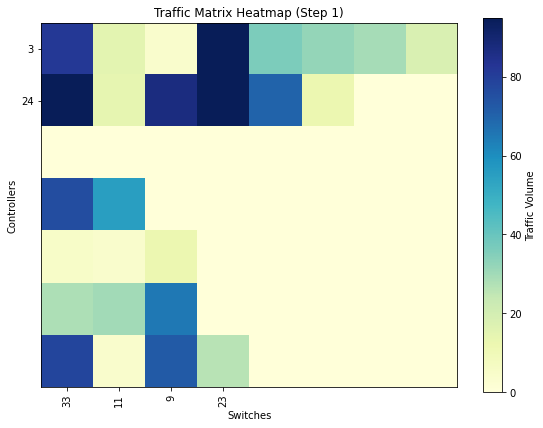


Total Load Assigned to Each Controller:
Controller 3: Total Load = 311 units
Controller 24: Total Load = 373 units
Controller 28: Total Load = 0 units
Controller 5: Total Load = 131 units
Controller 32: Total Load = 21 units
Controller 4: Total Load = 123 units
Controller 29: Total Load = 180 units
Selected Controllers (Step 1): ['24', '3']
Dynamic All New Switches: {'10', '25', '8', '15', '4', '23', '28', '0', '11', '9', '32', '5', '20', '27', '16', '13', '33', '6', '2', '17', '12', '7', '21', '29', '31', '26', '18', '1', '19', '14', '22', '30'}
Simulation Step 2:


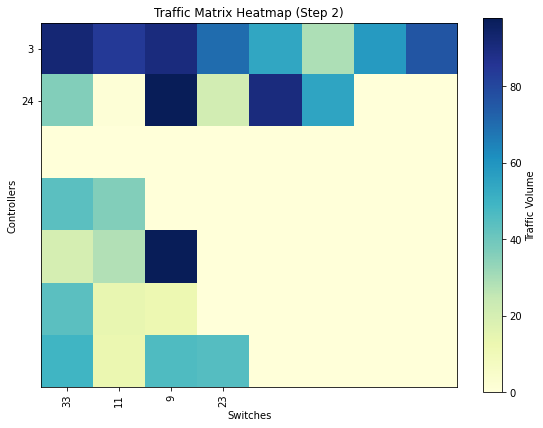


Total Load Assigned to Each Controller:
Controller 3: Total Load = 553 units
Controller 24: Total Load = 301 units
Controller 28: Total Load = 0 units
Controller 5: Total Load = 80 units
Controller 32: Total Load = 146 units
Controller 4: Total Load = 70 units
Controller 29: Total Load = 153 units
Selected Controllers (Step 2): ['3', '24', '29']
Dynamic All New Switches: {'10', '25', '8', '15', '4', '23', '28', '0', '11', '9', '32', '5', '20', '27', '16', '13', '33', '6', '2', '17', '12', '7', '21', '31', '26', '18', '1', '19', '14', '22', '30'}
Simulation Step 3:


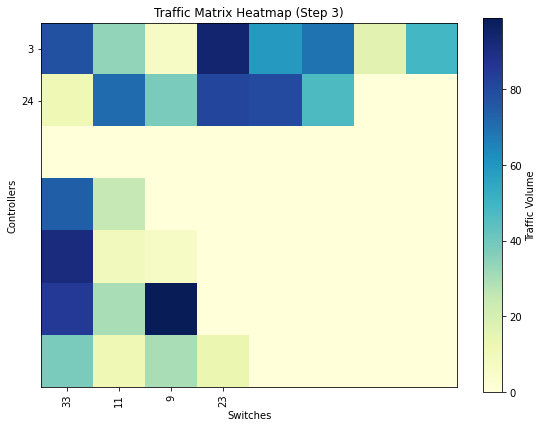


Total Load Assigned to Each Controller:
Controller 3: Total Load = 405 units
Controller 24: Total Load = 328 units
Controller 28: Total Load = 0 units
Controller 5: Total Load = 99 units
Controller 32: Total Load = 106 units
Controller 4: Total Load = 214 units
Controller 29: Total Load = 92 units
Selected Controllers (Step 3): ['3', '24', '4', '32']
Dynamic All New Switches: {'10', '25', '8', '15', '23', '28', '0', '11', '9', '5', '20', '27', '16', '13', '33', '6', '2', '17', '12', '7', '21', '29', '31', '26', '18', '1', '19', '14', '22', '30'}
Simulation Step 4:


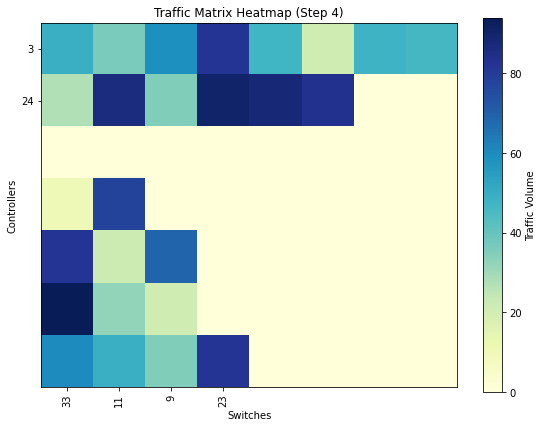


Total Load Assigned to Each Controller:
Controller 3: Total Load = 388 units
Controller 24: Total Load = 409 units
Controller 28: Total Load = 0 units
Controller 5: Total Load = 88 units
Controller 32: Total Load = 173 units
Controller 4: Total Load = 147 units
Controller 29: Total Load = 226 units
Selected Controllers (Step 4): ['24', '3', '29', '32', '4']
Dynamic All New Switches: {'10', '25', '8', '15', '23', '28', '0', '11', '9', '5', '20', '27', '16', '13', '33', '6', '2', '17', '12', '7', '21', '31', '26', '18', '1', '19', '14', '22', '30'}
Simulation Step 5:


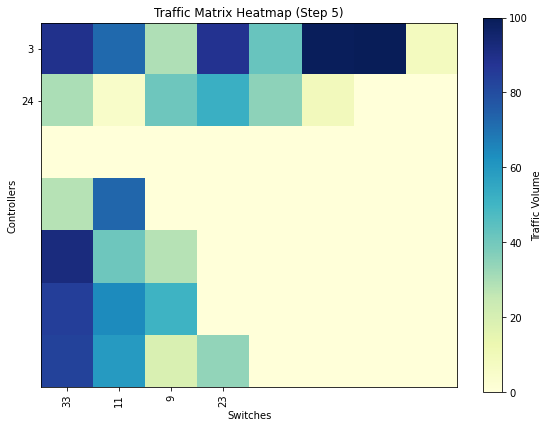


Total Load Assigned to Each Controller:
Controller 3: Total Load = 527 units
Controller 24: Total Load = 172 units
Controller 28: Total Load = 0 units
Controller 5: Total Load = 101 units
Controller 32: Total Load = 161 units
Controller 4: Total Load = 199 units
Controller 29: Total Load = 195 units
Selected Controllers (Step 5): ['3', '4', '29', '24', '32', '5']
Dynamic All New Switches: {'10', '25', '8', '15', '23', '28', '0', '11', '9', '20', '27', '16', '13', '33', '6', '2', '17', '12', '7', '21', '31', '26', '18', '1', '19', '14', '22', '30'}


In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np
import time

# Set a fixed seed value for the random number generator
random.seed(42)  # You can use any integer as the seed

# Define the traffic matrix (traffic from switches to controllers)
traffic_matrix = {controller: {} for controller in new_switches_dict}

# Simulate synthetic traffic over multiple steps
simulation_steps = 5
time_interval = 1  # 1 second
initial_controller_count = 2  # Initial number of controllers

# Define maximum and minimum capacity per controller
max_capacity_per_controller = {
    controller_id: 1000 for controller_id in new_switches_dict.keys()
}

# Initialize the list of active controllers with the initial count
active_controllers = list(new_switches_dict.keys())[:initial_controller_count]

# Create a dictionary to store selected controllers and their loads for each step
selected_controllers_info = {}

for step in range(simulation_steps):
    print(f"Simulation Step {step + 1}:")

    # Prompt the user to input the number of controllers to select in this step
    num_controllers_to_select = int(input(f"Enter the number of controllers to select in step {step + 1}: "))

    # Generate random traffic volumes between switches and controllers
    for controller, switches in new_switches_dict.items():
        for switch in switches:
            # Generate a random traffic volume (you can adjust the range)
            traffic_volume = random.randint(1, 100)
            # Assign the traffic volume to the matrix
            traffic_matrix[controller][switch] = traffic_volume

    # Extract switches and controllers from the traffic matrix
    switches = list(traffic_matrix[list(traffic_matrix.keys())[0]].keys())

    # Determine the maximum number of switches among all controllers
    max_num_switches = max(len(switches) for switches in traffic_matrix.values())

    # Create a 2D NumPy array filled with zeros
    matrix = np.zeros((len(traffic_matrix), max_num_switches), dtype=int)

    # Fill the NumPy array with traffic data
    for i, controller in enumerate(traffic_matrix.keys()):
        switches = list(traffic_matrix[controller].keys())
        for j, switch in enumerate(switches):
            matrix[i, j] = traffic_matrix[controller][switch]

    # Create the heatmap
    plt.figure(figsize=(8, 6))
    plt.imshow(matrix, cmap='YlGnBu', interpolation='nearest')

    # Set the x-axis ticks and labels
    x_tick_locations = range(len(switches))
    x_tick_labels = switches  # Use all switches as labels
    plt.xticks(x_tick_locations, x_tick_labels, rotation=90)

    # Set the y-axis ticks and labels
    y_tick_locations = range(len(active_controllers))
    y_tick_labels = active_controllers
    plt.yticks(y_tick_locations, y_tick_labels)

    # Add labels and colorbar
    plt.xlabel('Switches')
    plt.ylabel('Controllers')
    plt.colorbar(label='Traffic Volume')

    # Show the heatmap
    plt.title(f'Traffic Matrix Heatmap (Step {step + 1})')
    plt.tight_layout()
    plt.show()

    # Calculate the total traffic load and controller capacity for each controller
    controller_loads = {controller_id: 0 for controller_id in new_switches_dict.keys()}
    controller_capacity = {}  # New variable to store controller capacity

    for controller_id, switches in new_switches_dict.items():
        for switch in switches:
            load = traffic_matrix[controller_id][switch]
            controller_loads[controller_id] += load  # Use traffic volume directly
        controller_capacity[controller_id] = max_capacity_per_controller[controller_id]  # Use predefined capacity

    # Print the total load assigned to each controller
    print("\nTotal Load Assigned to Each Controller:")
    for controller, load in controller_loads.items():
        print(f"Controller {controller}: Total Load = {load} units")

    # Rank the controllers based on a combined score of load and capacity
    controller_scores = {controller_id: controller_loads[controller_id] / controller_capacity[controller_id] for controller_id in new_switches_dict.keys()}
    ranked_controllers = sorted(controller_scores.keys(), key=lambda c: controller_scores[c], reverse=True)

    # Select the top 'num_controllers_to_select' controllers
    selected_controllers = ranked_controllers[:num_controllers_to_select]

    # Store the selected controllers and their loads for this step
    selected_controllers_info[step] = [(controller, controller_loads[controller]) for controller in selected_controllers]

    # Print the selected controllers
    print(f"Selected Controllers (Step {step + 1}): {selected_controllers}")

    # Calculate dynamic_all_new_switches
    dynamic_all_new_switches = set(G.nodes()) - set(selected_controllers)
    print(f"Dynamic All New Switches: {dynamic_all_new_switches}")

    time.sleep(time_interval)


In [ ]:
# Initialize an empty switch_loads dictionary
switch_loads = {}

# Iterate through the traffic matrix to extract load for each switch
for controller, switches in traffic_matrix.items():
    for switch, traffic_volume in switches.items():
        switch_loads[switch] = traffic_volume

# Print the switch_loads dictionary
print("\nSwitch Loads:")
for switch, load in switch_loads.items():
    print(f"Switch {switch}: Load = {load} units")


Switch Loads:
Switch 10: Load = 89 units
Switch 15: Load = 72 units
Switch 25: Load = 29 units
Switch 26: Load = 88 units
Switch 1: Load = 42 units
Switch 2: Load = 99 units
Switch 27: Load = 100 units
Switch 7: Load = 8 units
Switch 18: Load = 30 units
Switch 6: Load = 5 units
Switch 17: Load = 41 units
Switch 30: Load = 52 units
Switch 12: Load = 35 units
Switch 16: Load = 9 units
Switch 13: Load = 28 units
Switch 19: Load = 73 units
Switch 8: Load = 92 units
Switch 20: Load = 41 units
Switch 31: Load = 28 units
Switch 14: Load = 84 units
Switch 0: Load = 64 units
Switch 22: Load = 51 units
Switch 33: Load = 83 units
Switch 11: Load = 59 units
Switch 9: Load = 19 units
Switch 23: Load = 34 units


In [ ]:
for step, info in selected_controllers_info.items():
    print(f"Step {step + 1} - Selected Controllers:")
    
    # Initialize a variable to store the total capacity for this step
    total_capacity = sum(load for _, load in info)
    
    for controller, load in info:
        print(f"Controller {controller}: Total Load = {load} units")
        
    # Print the total capacity for this step
    print(f"Total Capacity for Step {step + 1}: {total_capacity} units")


Step 1 - Selected Controllers:
Controller 24: Total Load = 373 units
Controller 3: Total Load = 311 units
Total Capacity for Step 1: 684 units
Step 2 - Selected Controllers:
Controller 3: Total Load = 553 units
Controller 24: Total Load = 301 units
Controller 29: Total Load = 153 units
Total Capacity for Step 2: 1007 units
Step 3 - Selected Controllers:
Controller 3: Total Load = 405 units
Controller 24: Total Load = 328 units
Controller 4: Total Load = 214 units
Controller 32: Total Load = 106 units
Total Capacity for Step 3: 1053 units
Step 4 - Selected Controllers:
Controller 24: Total Load = 409 units
Controller 3: Total Load = 388 units
Controller 29: Total Load = 226 units
Controller 32: Total Load = 173 units
Controller 4: Total Load = 147 units
Total Capacity for Step 4: 1343 units
Step 5 - Selected Controllers:
Controller 3: Total Load = 527 units
Controller 4: Total Load = 199 units
Controller 29: Total Load = 195 units
Controller 24: Total Load = 172 units
Controller 32: Tot

In [ ]:
# Prompt the user for the step
step = int(input("Enter the step (0, 1, 2, etc.): "))

# Check if the selected step exists in the selected_controllers_info dictionary
if step in selected_controllers_info:
    selected_controllers = [controller for controller, _ in selected_controllers_info[step]]
    print(f"Selected Controllers: {selected_controllers}")

    # Calculate dynamic_all_new_switches

    dynamic_all_new_switches = set(G.nodes()) - set(selected_controllers)
    
    # dynamic_all_new_switches = set(G.nodes()) - set(selected_controllers_info[step])
    print(f"Dynamic All New Switches: {dynamic_all_new_switches}")

    # Print the selected controllers as determined by the step input
    step_input = int(input(f"Enter the step to print selected controllers (0 to {step}): "))
    if step_input in selected_controllers_info:
        selected_controllers_step = [controller for controller, _ in selected_controllers_info[step_input]]
        print(f"Selected Controllers (Step {step_input} based on input): {selected_controllers_step}")
    else:
        print(f"No information available for step {step_input}")
else:
    print(f"Step {step} does not exist in the selected_controllers_info dictionary.")

Selected Controllers: ['24', '3']
Dynamic All New Switches: {'10', '25', '8', '15', '4', '23', '28', '0', '11', '9', '32', '5', '20', '27', '16', '13', '33', '6', '2', '17', '12', '7', '21', '29', '31', '26', '18', '1', '19', '14', '22', '30'}
Selected Controllers (Step 0 based on input): ['24', '3']


Load Imbalance (Coefficient of Variation): 0.51
Controller 24 Utilization: 0.17
Controller 3 Utilization: 0.53
Average Utilization: 0.35
Average latency between controllers and switches: 3.23 m/s
Maximum latency between controllers and switches: 5.00 m/s
Controller-switch pair with maximum latency: Controller 3 and Switch 21
Average latency between controllers: 3.00 m/s
Worst-case latency between controllers: 3.00 m/s
Worst-case controller pair: Controller 24 and Controller 3


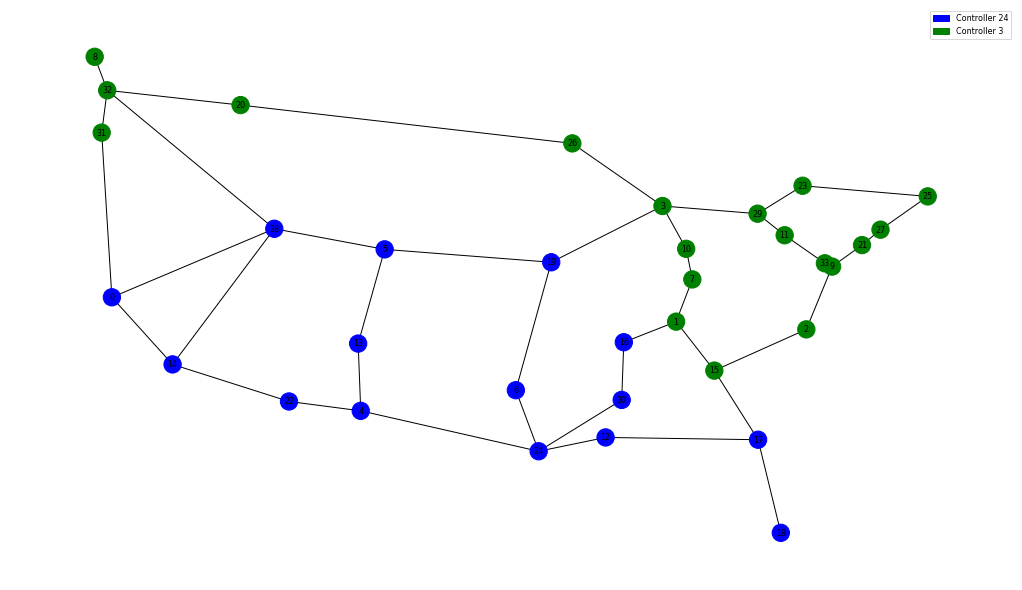

Controller 24: 14 switches assigned, switches = ['13', '4', '18', '6', '28', '0', '19', '5', '17', '30', '14', '12', '22', '16']
Controller 3: 18 switches assigned, switches = ['10', '15', '33', '26', '25', '23', '11', '21', '9', '1', '2', '20', '8', '32', '27', '29', '7', '31']


In [ ]:
# Unweighted Neighborhood Scheduling for Heterogenous controller placements when number of controllers to be placed fluatuates 
import networkx as nx
import math

# geo_loc_data = get_geo_data("Internet2LatLong.csv")
geo_loc_data = {k: {"lat": v.get('Latitude', 0), "long": v.get('Longitude', 0)}
                for (k, v) in G.nodes(data=True)}

def euclidean_distance(p1, p2):
    return math.sqrt((p1["lat"] - p2["lat"])**2 + (p1["long"] - p2["long"])**2)

selected_controllers = [controller for controller, _ in selected_controllers_info[step]]

dynamic_all_new_switches = set(G.nodes()) - set(selected_controllers)

# Initialize load on selected controllers
controller_loads = {controller_id: 0 for controller_id in selected_controllers}

# Function to assign switches to controllers using unweighted neighborhood-based scheduling
def assign_switches_to_controllers(G, dynamic_all_new_switches, selected_controllers, max_steps):
    new_dynamic_switches_dict = {controller: set() for controller in selected_controllers}
    remaining_dynamic_switches = set(dynamic_all_new_switches)

    # Get the geographic coordinates of the controllers
    controller_positions = {controller: geo_loc_data[controller] for controller in selected_controllers}

    while remaining_dynamic_switches:
        assigned = False  # Flag to track if any assignment is made in this iteration
        for controller in selected_controllers:
            if remaining_dynamic_switches:
                closest_switch = min(remaining_dynamic_switches, key=lambda switch: euclidean_distance(controller_positions[controller], geo_loc_data[switch]))
                distance_to_controller = euclidean_distance(controller_positions[controller], geo_loc_data[closest_switch])
                if distance_to_controller <= max_steps:
                    # Check if the switch is directly connected to the controller or any assigned switch
                    if G.has_edge(controller, closest_switch) or any(G.has_edge(switch, closest_switch) for switch in new_dynamic_switches_dict[controller]):
                        new_dynamic_switches_dict[controller].add(closest_switch)
                        remaining_dynamic_switches.remove(closest_switch)
                        assigned = True  # Mark assignment made

        # If no assignments were made in this iteration, break out of the loop
        if not assigned:
            break

    # Assign unassigned switches to the nearest controllers
    while remaining_dynamic_switches:
        unassigned_switch = remaining_dynamic_switches.pop()
        closest_controller = min(selected_controllers, key=lambda controller: min(euclidean_distance(geo_loc_data[unassigned_switch], geo_loc_data[assigned_switch]) for assigned_switch in new_dynamic_switches_dict[controller]))
        new_dynamic_switches_dict[closest_controller].add(unassigned_switch)

    return new_dynamic_switches_dict

max_steps = 30

new_dynamic_switches_dict = assign_switches_to_controllers(G, dynamic_all_new_switches, selected_controllers, max_steps)

# Calculate the load on each selected controller
controller_loads = {controller: 0 for controller in selected_controllers}
for controller_id, switches in traffic_matrix.items():
    for switch, traffic_volume in switches.items():
        if controller_id in selected_controllers:
            controller_loads[controller_id] += traffic_volume

# Calculate the mean load across all controllers
mean_load = np.mean(list(controller_loads.values()))

# Calculate the coefficient of variation (CV) as a measure of load imbalance
load_values = list(controller_loads.values())
if len(load_values) > 1:
    std_dev = np.std(load_values)
    cv = std_dev / mean_load
else:
    cv = 0.0  # Handle the case when there's only one controller

print(f"Load Imbalance (Coefficient of Variation): {cv:.2f}")

# Calculate controller utilization
controller_utilization = {}
total_utilization = 0

for controller in selected_controllers:
    load = controller_loads[controller]
    capacity = controller_capacity[controller]
    utilization = load / capacity
    controller_utilization[controller] = utilization
    total_utilization += utilization

# Calculate average utilization
average_utilization = total_utilization / len(selected_controllers)

# Print controller utilization
for controller, utilization in controller_utilization.items():
    print(f"Controller {controller} Utilization: {utilization:.2f}")

# Print average utilization
print(f"Average Utilization: {average_utilization:.2f}")


# Calculate latency between each controller-switch pair
total_latency_switch_to_controller = 0  # Initialize the total latency sum to zero

for controller, switches in new_dynamic_switches_dict.items():
    for switch in switches:
        try:
            distance = nx.shortest_path_length(G, source=switch, target=controller, weight='none')
            #print(f"Latency between Controller {controller} and Switch {switch}: {distance:.2f} units")

            # Add the latency to the total sum
            total_latency_switch_to_controller += distance

        except nx.NetworkXNoPath:
        # If no path exists between the switch and controller, skip and move to the next controller
            continue

# Calculate the average latency between controllers and switches
average_latency_switch_to_controller = total_latency_switch_to_controller / total_assigned_switches
print(f"Average latency between controllers and switches: {average_latency_switch_to_controller:.2f} m/s")

# Calculate latency between each controller-switch pair
max_latency_switch_to_controller = float('-inf')  # Initialize to a very small value
max_controller_switch_pair = (None, None)  # Initialize to None

for controller, switches in new_dynamic_switches_dict.items():
    for switch in switches:
        try:
            distance = nx.shortest_path_length(G, source=switch, target=controller, weight='none')
            #print(f"Latency between Controller {controller} and Switch {switch}: {distance:.2f} units")

            # Update the maximum latency and corresponding controller-switch pair if found
            if distance > max_latency_switch_to_controller:
                max_latency_switch_to_controller = distance
                max_controller_switch_pair = (controller, switch)

        except nx.NetworkXNoPath:
            # If no path exists between the switch and controller, skip and move to the next controller
            continue

print(f"Maximum latency between controllers and switches: {max_latency_switch_to_controller:.2f} m/s")
print(f"Controller-switch pair with maximum latency: Controller {max_controller_switch_pair[0]} and Switch {max_controller_switch_pair[1]}")

# Calculate latency between each controller pair in selected controllers
total_latency_between_controllers = 0  # Initialize the total latency sum between controller pairs
max_latency_between_controllers = float('-inf')  # Initialize the maximum latency to a very small value
worst_case_controller_pair = (None, None)  # Initialize to None

# Nested loop to iterate over all combinations of distinct controllers in selected controllers
for i, controller1 in enumerate(selected_controllers):
    for controller2 in selected_controllers[i + 1:]:
        try:
            distance = nx.shortest_path_length(G, source=controller1, target=controller2, weight='none')
            
            # Add the latency to the total sum
            total_latency_between_controllers += distance

            # Update the maximum latency and corresponding controller pair if found
            if distance > max_latency_between_controllers:
                max_latency_between_controllers = distance
                worst_case_controller_pair = (controller1, controller2)

        except nx.NetworkXNoPath:
            # If no path exists between the controllers, skip and move to the next controller pair
            continue

# Calculate the average latency between controllers
total_controller_pairs = len(selected_controllers) * (len(selected_controllers) - 1) / 2  # Total number of distinct controller pairs
average_latency_between_controllers = total_latency_between_controllers / total_controller_pairs

# Print the average latency and worst-case latency and corresponding controller pair
print(f"Average latency between controllers: {average_latency_between_controllers:.2f} m/s")
print(f"Worst-case latency between controllers: {max_latency_between_controllers:.2f} m/s")
# print(f"Worst-case controller pair: Controller {worst_case_controller_pair[0]} and Controller {worst_case_controller_pair[1]}")

# Calculate latency between each controller pair in selected controllers
total_latency_between_controllers = 0  # Initialize the total latency sum between controller pairs
max_latency_between_controllers = float('-inf')  # Initialize the maximum latency to a very small value
worst_case_controller_pair = (None, None)  # Initialize to None

# Nested loop to iterate over all combinations of distinct controllers in selected controllers
for i, controller1 in enumerate(selected_controllers):
    for controller2 in selected_controllers[i + 1:]:
        try:
            distance = nx.shortest_path_length(G, source=controller1, target=controller2, weight='none')
            
            # Add the latency to the total sum
            total_latency_between_controllers += distance

            # Update the maximum latency and corresponding controller pair if found
            if distance > max_latency_between_controllers:
                max_latency_between_controllers = distance
                worst_case_controller_pair = (controller1, controller2)

        except nx.NetworkXNoPath:
            # If no path exists between the controllers, skip and move to the next controller pair
            continue

# Calculate the average latency between controllers
total_controller_pairs = len(selected_controllers) * (len(selected_controllers) - 1) / 2  # Total number of distinct controller pairs
average_latency_between_controllers = total_latency_between_controllers / total_controller_pairs

print(f"Worst-case controller pair: Controller {worst_case_controller_pair[0]} and Controller {worst_case_controller_pair[1]}")


# Initialize controller allocation
controller_allocation = {}

    # Iterate over switches assigned to each controller
for controller, switches in new_dynamic_switches_dict.items():
    # Assign each switch to the corresponding controller in controller_allocation
    for switch in switches:
        controller_allocation[switch] = controller

# return controller_allocation

    # Plot the graph
colors = ['blue', 'green', 'red', 'orange', 'purple', 'pink', 'gray', 'brown', 'maroon', 'silver', 'lavender' 'navy']
controller_colors = {controller: color for controller, color in zip(selected_controllers, colors)}
node_colors = [controller_colors[controller_allocation[node]] if node not in selected_controllers else controller_colors[node] for node in G.nodes()]

pos = {k: (v["long"], v["lat"]) for k, v in data.items()}

    # Plot the graph
    #pos = dict(zip(G.nodes(), nodes_data))
    # Plot the graph
plt.figure(figsize=(14, 8))  # Adjust the figure size as needed
nx.draw(G, pos, node_color=node_colors)

    # Add node labels
labels = {node: str(node) for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=8)

    # Add a legend
legend_patches = []
for controller, color in controller_colors.items():
    patch = mpatches.Patch(color=color, label=f'Controller {controller}')
    legend_patches.append(patch)
plt.legend(handles=legend_patches, fontsize=8)

# Show the plot
plt.show()


# Print the switches assigned to each controller
for controller, switches in new_dynamic_switches_dict.items():
    print(f"Controller {controller}: {len(switches)} switches assigned, switches = {list(switches)}")

In [ ]:
# # Unweighted Neighborhood Based Scheduling (UNBS) for Heterogeneous controller placements when number of controllers to be placed is maximum 


# import networkx as nx
# import math


# def euclidean_distance(p1, p2):
#     # return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)
#     return math.sqrt((p1["lat"] - p2["lat"])**2 + (p1["long"] - p2["long"])**2)

# def assign_switches_to_controllers(G, new_all_switches, new_initial_controllers, max_steps):
#     new_switches_dict = {controller: set() for controller in new_initial_controllers}
#     remaining_switches = set(new_all_switches)

#     # Get the geographic coordinates of the controllers
#     controller_positions = {controller: geo_loc_data[controller] for controller in new_initial_controllers}

#     while remaining_switches:
#         assigned = False  # Flag to track if any assignment is made in this iteration
#         for controller in new_initial_controllers:
#             if remaining_switches:
#                 closest_switch = min(remaining_switches, key=lambda switch: euclidean_distance(controller_positions[controller], geo_loc_data[switch]))
#                 distance_to_controller = euclidean_distance(controller_positions[controller], geo_loc_data[closest_switch])
#                 if distance_to_controller <= max_steps:
#                     # Check if the switch is directly connected to the controller or any assigned switch
#                     if G.has_edge(controller, closest_switch) or any(G.has_edge(switch, closest_switch) for switch in new_switches_dict[controller]):
#                         new_switches_dict[controller].add(closest_switch)
#                         remaining_switches.remove(closest_switch)
#                         assigned = True  # Mark assignment made

#         # If no assignments were made in this iteration, break out of the loop
#         if not assigned:
#             break

#     # Add empty controllers to the nearest available controller aside from itself
#     empty_controllers = [controller for controller, switches in new_switches_dict.items() if not switches]
#     for empty_controller in empty_controllers:
#         nearest_controller = min(new_initial_controllers, key=lambda controller: euclidean_distance(controller_positions[empty_controller], controller_positions[controller]))
#         if nearest_controller != empty_controller:
#             new_initial_controllers.remove(empty_controller)
#             new_switches_dict[nearest_controller].add(empty_controller)
#             break  # Assign one empty controller in each iteration

#     return new_switches_dict

# max_steps = 17

# new_switches_dict = assign_switches_to_controllers(G, new_all_switches, new_initial_controllers, max_steps)

# # Calculate the load imbalance between the new initial controller clusters
# controller_capacity = {controller: abs(DBC_centrality[controller]) for controller in new_initial_controllers}
# total_capacity = sum(controller_capacity.values())
# num_assigned_switches = {controller: len(switches) for controller, switches in new_switches_dict.items()}
# total_assigned_switches = sum(num_assigned_switches.values())
# max_assigned_switches = max(num_assigned_switches.values())
# min_assigned_switches = min(num_assigned_switches.values())

# load_imbalance = (max_assigned_switches - min_assigned_switches) / total_assigned_switches * 100
# print(f"Load imbalance: {load_imbalance:.2f}%")

# # Calculate the controller capacity as the maximum number of switches a controller can handle
# controller_capacity = {controller: max_switches_per_controller[controller] for controller in new_initial_controllers}

# # # Calculate the controller utilization and average utilization based on the actual number of switches assigned
# controller_utilization = {controller: num_assigned_switches[controller] / controller_capacity[controller] for controller in new_initial_controllers}
# average_utilization = sum(controller_utilization.values()) / len(controller_utilization)
# print("Controller Utilization:")
# for controller, utilization in controller_utilization.items():
#     print(f"Controller {controller}: {utilization:.2f}")
# print(f"Average Controller Utilization: {average_utilization:.2f}")

# # Calculate latency between each controller-switch pair
# total_latency_switch_to_controller = 0  # Initialize the total latency sum to zero

# for controller, switches in new_switches_dict.items():
#     for switch in switches:
#         try:
#             distance = nx.shortest_path_length(G, source=switch, target=controller, weight='none')
#             #print(f"Latency between Controller {controller} and Switch {switch}: {distance:.2f} units")

#             # Add the latency to the total sum
#             total_latency_switch_to_controller += distance

#         except nx.NetworkXNoPath:
#         # If no path exists between the switch and controller, skip and move to the next controller
#             continue

# # Calculate the average latency between controllers and switches
# average_latency_switch_to_controller = total_latency_switch_to_controller / total_assigned_switches
# print(f"Average latency between controllers and switches: {average_latency_switch_to_controller:.2f} m/s")

# # Calculate latency between each controller-switch pair
# max_latency_switch_to_controller = float('-inf')  # Initialize to a very small value
# max_controller_switch_pair = (None, None)  # Initialize to None

# for controller, switches in new_switches_dict.items():
#     for switch in switches:
#         try:
#             distance = nx.shortest_path_length(G, source=switch, target=controller, weight='none')
#             #print(f"Latency between Controller {controller} and Switch {switch}: {distance:.2f} units")

#             # Update the maximum latency and corresponding controller-switch pair if found
#             if distance > max_latency_switch_to_controller:
#                 max_latency_switch_to_controller = distance
#                 max_controller_switch_pair = (controller, switch)

#         except nx.NetworkXNoPath:
#             # If no path exists between the switch and controller, skip and move to the next controller
#             continue

# print(f"Maximum latency between controllers and switches: {max_latency_switch_to_controller:.2f} m/s")
# print(f"Controller-switch pair with maximum latency: Controller {max_controller_switch_pair[0]} and Switch {max_controller_switch_pair[1]}")

# # Calculate latency between each controller pair
# total_latency_between_controllers = 0  # Initialize the total latency sum between controller pairs

# # Nested loop to iterate over all combinations of distinct controllers
# for i, controller1 in enumerate(new_initial_controllers):
#     for controller2 in new_initial_controllers[i + 1:]:
#         try:
#             distance = nx.shortest_path_length(G, source=controller1, target=controller2, weight='none')
#             #print(f"Latency between Controller {controller1} and Controller {controller2}: {distance:.2f} units")

#             # Add the latency to the total sum
#             total_latency_between_controllers += distance

#         except nx.NetworkXNoPath:
#         # If no path exists between the controllers, skip and move to the next controller pair
#             continue

# # Calculate the average latency between controllers
# total_controller_pairs = len(new_initial_controllers) * (len(new_initial_controllers) - 1) / 2  # Total number of distinct controller pairs
# average_latency_between_controllers = total_latency_between_controllers / total_controller_pairs
# print(f"Average latency between controllers: {average_latency_between_controllers:.2f} m/s")

# # Calculate latency between each controller pair
# max_latency_between_controllers = float('-inf')  # Initialize the maximum latency to a very small value
# worst_case_controller_pair = (None, None)  # Initialize to None

# # Nested loop to iterate over all combinations of distinct controllers
# for i, controller1 in enumerate(new_initial_controllers):
#     for controller2 in new_initial_controllers[i + 1:]:
#         try:
#             distance = nx.shortest_path_length(G, source=controller1, target=controller2, weight='none')
#         # print(f"Latency between Controller {controller1} and Controller {controller2}: {distance:.2f} units")

#             # Update the maximum latency and corresponding controller pair if found
#             if distance > max_latency_between_controllers:
#                 max_latency_between_controllers = distance
#                 worst_case_controller_pair = (controller1, controller2)

#         except nx.NetworkXNoPath:
#         # If no path exists between the controllers, skip and move to the next controller pair
#             continue

# # Print the worst-case latency and the corresponding controller pair
# print(f"Worst-case latency between controllers: {max_latency_between_controllers:.2f} m/s")
# print(f"Worst-case controller pair: Controller {worst_case_controller_pair[0]} and Controller {worst_case_controller_pair[1]}")

# # Initialize controller allocation
# controller_allocation = {}

#     # Iterate over switches assigned to each controller
# for controller, switches in new_switches_dict.items():
#     # Assign each switch to the corresponding controller in controller_allocation
#     for switch in switches:
#         controller_allocation[switch] = controller

# # return controller_allocation

#     # Plot the graph
# colors = ['blue', 'green', 'red', 'orange', 'purple', 'pink', 'gray', 'brown', 'maroon', 'silver', 'lavender' 'navy']
# controller_colors = {controller: color for controller, color in zip(new_initial_controllers, colors)}
# node_colors = [controller_colors[controller_allocation[node]] if node not in new_initial_controllers else controller_colors[node] for node in G.nodes()]

# pos = {k: (v["long"], v["lat"]) for k, v in data.items()}

#     # Plot the graph
#     #pos = dict(zip(G.nodes(), nodes_data))
#     # Plot the graph
# plt.figure(figsize=(14, 8))  # Adjust the figure size as needed
# nx.draw(G, pos, node_color=node_colors)

#     # Add node labels
# labels = {node: str(node) for node in G.nodes()}
# nx.draw_networkx_labels(G, pos, labels, font_size=8)

#     # Add a legend
# legend_patches = []
# for controller, color in controller_colors.items():
#     patch = mpatches.Patch(color=color, label=f'Controller {controller}')
#     legend_patches.append(patch)
# plt.legend(handles=legend_patches, fontsize=8)

# # Show the plot
# plt.show()


# # Print the switches assigned to each new initial controller
# for initial_controller, switches in new_switches_dict.items():
#     print(f"New Initial Controller {initial_controller}: {len(switches)} switches assigned, switches = {list(switches)}")

In [ ]:
import math

def max_switches_per_controller(total_switches, DBC_centrality, new_initial_controllers, capacity_factor):
    # Calculate the total propagating capacity of all controllers
    total_capacity = sum(DBC_centrality[node] for node in new_initial_controllers)

    # Set the minimum and maximum number of switches per controller
    min_switches_per_controller = 4  # You can adjust this value
    max_switches_per_controller = 8  # You can adjust this value

    # Calculate the proportional allocation of switches for each controller
    switches_assigned = {}
    controller_capacity = {}  # New variable to store controller capacity
    for controller in new_initial_controllers:
        proportional_allocation = (DBC_centrality[controller] / total_capacity) * total_switches
        allocated_switches = max(min_switches_per_controller, min(max_switches_per_controller, math.ceil(proportional_allocation)))
        switches_assigned[controller] = allocated_switches
        controller_capacity[controller] = allocated_switches * capacity_factor  # Multiply by capacity factor

    return switches_assigned, controller_capacity  # Return both allocated switches and controller capacity

# Example usage with the provided DNBC_centrality, new_initial_controllers, and total number of switches
total_switches = len(new_all_switches)

new_initial_controllers = list(new_initial_controllers)
new_initial_controllers.sort(reverse=True, key=lambda x: DBC_centrality[x])

# Define the capacity factor (e.g., 500)
capacity_factor = 50

# Call the function with the capacity factor and capture the results
switches_assigned, controller_capacity = max_switches_per_controller(total_switches, DBC_centrality, new_initial_controllers, capacity_factor)

print("\nController Capacity:")
for controller, capacity in controller_capacity.items():
    print(f"{controller} - controller_capacity: {capacity}")



Controller Capacity:
3 - controller_capacity: 400
24 - controller_capacity: 300
28 - controller_capacity: 250
5 - controller_capacity: 200
32 - controller_capacity: 200
4 - controller_capacity: 200
29 - controller_capacity: 200


Load Imbalance (Coefficient of Variation): 0.51
Controller 24 Utilization: 0.57
Controller 3 Utilization: 1.32
Average Utilization: 0.95
Average latency between controllers and switches: 3.11 m/s
Maximum latency between controllers and switches: 5.00 m/s
Controller-switch pair with maximum latency: Controller 3 and Switch 21
Average latency between controllers: 3.00 m/s
Worst-case latency between controllers: 3.00 m/s
Worst-case controller pair: Controller 24 and Controller 3


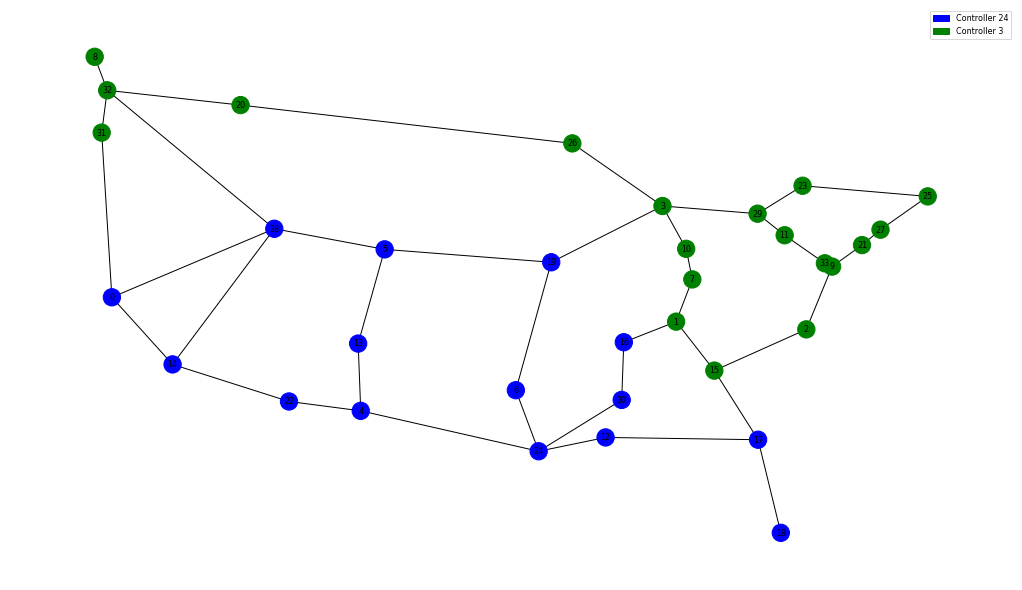

Controller 24: 14 switches assigned, switches = ['13', '4', '18', '6', '28', '0', '19', '5', '17', '30', '14', '12', '22', '16']
Controller 3: 18 switches assigned, switches = ['10', '15', '33', '26', '25', '23', '11', '21', '9', '1', '2', '20', '8', '32', '27', '29', '7', '31']


In [ ]:
# Weighted Neighborhood Scheduling for Heterogenous controller placements when number of controllers to be placed fluatuates 
import networkx as nx
import math

# geo_loc_data = get_geo_data("Internet2LatLong.csv")
geo_loc_data = {k: {"lat": v.get('Latitude', 0), "long": v.get('Longitude', 0)}
                for (k, v) in G.nodes(data=True)}

def euclidean_distance(p1, p2):
    return math.sqrt((p1["lat"] - p2["lat"])**2 + (p1["long"] - p2["long"])**2)

selected_controllers = [controller for controller, _ in selected_controllers_info[step]]

dynamic_all_new_switches = set(G.nodes()) - set(selected_controllers)

# Initialize load on selected controllers
controller_loads = {controller_id: 0 for controller_id in selected_controllers}


def assign_switches_to_controllers(G, dynamic_all_new_switches, selected_controllers, max_steps, controller_capacity):
    new_dynamic_switches_dict = {controller: set() for controller in selected_controllers}
    remaining_dynamic_switches = set(dynamic_all_new_switches)

    # Get the geographic coordinates of the controllers
    controller_positions = {controller: geo_loc_data[controller] for controller in selected_controllers}

    while remaining_dynamic_switches:
        assigned = False  # Flag to track if any assignment is made in this iteration
        for controller in selected_controllers:
            if remaining_dynamic_switches:
                # Check if the controller has reached its capacity
                if len(new_dynamic_switches_dict[controller]) >= controller_capacity[controller]:
                    continue  # Skip this controller if it's at capacity

                closest_switch = min(remaining_dynamic_switches, key=lambda switch: euclidean_distance(controller_positions[controller], geo_loc_data[switch]))
                distance_to_controller = euclidean_distance(controller_positions[controller], geo_loc_data[closest_switch])
                if distance_to_controller <= max_steps:
                    # Check if the switch is directly connected to the controller or any assigned switch
                    if G.has_edge(controller, closest_switch) or any(G.has_edge(switch, closest_switch) for switch in new_dynamic_switches_dict[controller]):
                        new_dynamic_switches_dict[controller].add(closest_switch)
                        remaining_dynamic_switches.remove(closest_switch)
                        assigned = True  # Mark assignment made

        # If no assignments were made in this iteration, break out of the loop
        if not assigned:
            break

    # Assign unassigned switches to the nearest controllers, ignoring capacity
    while remaining_dynamic_switches:
        unassigned_switch = remaining_dynamic_switches.pop()
        closest_controller = min(selected_controllers, key=lambda controller: min(euclidean_distance(geo_loc_data[unassigned_switch], geo_loc_data[assigned_switch]) for assigned_switch in new_dynamic_switches_dict[controller]))
        new_dynamic_switches_dict[closest_controller].add(unassigned_switch)

    return new_dynamic_switches_dict


    # Calculate the load on each selected controller
controller_loads = {controller: 0 for controller in selected_controllers}
for controller_id, switches in traffic_matrix.items():
    for switch, traffic_volume in switches.items():
        if controller_id in selected_controllers:
            controller_loads[controller_id] += traffic_volume

# Calculate the mean load across all controllers
mean_load = np.mean(list(controller_loads.values()))

# Calculate the coefficient of variation (CV) as a measure of load imbalance
load_values = list(controller_loads.values())
if len(load_values) > 1:
    std_dev = np.std(load_values)
    cv = std_dev / mean_load
else:
    cv = 0.0  # Handle the case when there's only one controller

print(f"Load Imbalance (Coefficient of Variation): {cv:.2f}")

# Calculate controller utilization
controller_utilization = {}
total_utilization = 0

for controller in selected_controllers:
    load = controller_loads[controller]
    capacity = controller_capacity[controller]
    utilization = load / capacity
    controller_utilization[controller] = utilization
    total_utilization += utilization

# Calculate average utilization
average_utilization = total_utilization / len(selected_controllers)

# Print controller utilization
for controller, utilization in controller_utilization.items():
    print(f"Controller {controller} Utilization: {utilization:.2f}")

# Print average utilization
print(f"Average Utilization: {average_utilization:.2f}")


# Calculate latency between each controller-switch pair
total_latency_switch_to_controller = 0  # Initialize the total latency sum to zero

for controller, switches in new_dynamic_switches_dict.items():
    for switch in switches:
        try:
            distance = nx.shortest_path_length(G, source=switch, target=controller, weight='none')
            #print(f"Latency between Controller {controller} and Switch {switch}: {distance:.2f} units")

            # Add the latency to the total sum
            total_latency_switch_to_controller += distance

        except nx.NetworkXNoPath:
        # If no path exists between the switch and controller, skip and move to the next controller
            continue

# Calculate the average latency between controllers and switches
average_latency_switch_to_controller = total_latency_switch_to_controller / total_assigned_switches
print(f"Average latency between controllers and switches: {average_latency_switch_to_controller:.2f} m/s")

# Calculate latency between each controller-switch pair
max_latency_switch_to_controller = float('-inf')  # Initialize to a very small value
max_controller_switch_pair = (None, None)  # Initialize to None

for controller, switches in new_dynamic_switches_dict.items():
    for switch in switches:
        try:
            distance = nx.shortest_path_length(G, source=switch, target=controller, weight='none')
            #print(f"Latency between Controller {controller} and Switch {switch}: {distance:.2f} units")

            # Update the maximum latency and corresponding controller-switch pair if found
            if distance > max_latency_switch_to_controller:
                max_latency_switch_to_controller = distance
                max_controller_switch_pair = (controller, switch)

        except nx.NetworkXNoPath:
            # If no path exists between the switch and controller, skip and move to the next controller
            continue

print(f"Maximum latency between controllers and switches: {max_latency_switch_to_controller:.2f} m/s")
print(f"Controller-switch pair with maximum latency: Controller {max_controller_switch_pair[0]} and Switch {max_controller_switch_pair[1]}")

# Calculate latency between each controller pair in selected controllers
total_latency_between_controllers = 0  # Initialize the total latency sum between controller pairs
max_latency_between_controllers = float('-inf')  # Initialize the maximum latency to a very small value
worst_case_controller_pair = (None, None)  # Initialize to None

# Nested loop to iterate over all combinations of distinct controllers in selected controllers
for i, controller1 in enumerate(selected_controllers):
    for controller2 in selected_controllers[i + 1:]:
        try:
            distance = nx.shortest_path_length(G, source=controller1, target=controller2, weight='none')
            
            # Add the latency to the total sum
            total_latency_between_controllers += distance

            # Update the maximum latency and corresponding controller pair if found
            if distance > max_latency_between_controllers:
                max_latency_between_controllers = distance
                worst_case_controller_pair = (controller1, controller2)

        except nx.NetworkXNoPath:
            # If no path exists between the controllers, skip and move to the next controller pair
            continue

# Calculate the average latency between controllers
total_controller_pairs = len(selected_controllers) * (len(selected_controllers) - 1) / 2  # Total number of distinct controller pairs
average_latency_between_controllers = total_latency_between_controllers / total_controller_pairs

# Print the average latency and worst-case latency and corresponding controller pair
print(f"Average latency between controllers: {average_latency_between_controllers:.2f} m/s")
print(f"Worst-case latency between controllers: {max_latency_between_controllers:.2f} m/s")
# print(f"Worst-case controller pair: Controller {worst_case_controller_pair[0]} and Controller {worst_case_controller_pair[1]}")

# Calculate latency between each controller pair in selected controllers
total_latency_between_controllers = 0  # Initialize the total latency sum between controller pairs
max_latency_between_controllers = float('-inf')  # Initialize the maximum latency to a very small value
worst_case_controller_pair = (None, None)  # Initialize to None

# Nested loop to iterate over all combinations of distinct controllers in selected controllers
for i, controller1 in enumerate(selected_controllers):
    for controller2 in selected_controllers[i + 1:]:
        try:
            distance = nx.shortest_path_length(G, source=controller1, target=controller2, weight='none')
            
            # Add the latency to the total sum
            total_latency_between_controllers += distance

            # Update the maximum latency and corresponding controller pair if found
            if distance > max_latency_between_controllers:
                max_latency_between_controllers = distance
                worst_case_controller_pair = (controller1, controller2)

        except nx.NetworkXNoPath:
            # If no path exists between the controllers, skip and move to the next controller pair
            continue

# Calculate the average latency between controllers
total_controller_pairs = len(selected_controllers) * (len(selected_controllers) - 1) / 2  # Total number of distinct controller pairs
average_latency_between_controllers = total_latency_between_controllers / total_controller_pairs

print(f"Worst-case controller pair: Controller {worst_case_controller_pair[0]} and Controller {worst_case_controller_pair[1]}")


# Initialize controller allocation
controller_allocation = {}

    # Iterate over switches assigned to each controller
for controller, switches in new_dynamic_switches_dict.items():
    # Assign each switch to the corresponding controller in controller_allocation
    for switch in switches:
        controller_allocation[switch] = controller

# return controller_allocation

    # Plot the graph
colors = ['blue', 'green', 'red', 'orange', 'purple', 'pink', 'gray', 'brown', 'maroon', 'silver', 'lavender' 'navy']
controller_colors = {controller: color for controller, color in zip(selected_controllers, colors)}
node_colors = [controller_colors[controller_allocation[node]] if node not in selected_controllers else controller_colors[node] for node in G.nodes()]

pos = {k: (v["long"], v["lat"]) for k, v in data.items()}

    # Plot the graph
    #pos = dict(zip(G.nodes(), nodes_data))
    # Plot the graph
plt.figure(figsize=(14, 8))  # Adjust the figure size as needed
nx.draw(G, pos, node_color=node_colors)

    # Add node labels
labels = {node: str(node) for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=8)

    # Add a legend
legend_patches = []
for controller, color in controller_colors.items():
    patch = mpatches.Patch(color=color, label=f'Controller {controller}')
    legend_patches.append(patch)
plt.legend(handles=legend_patches, fontsize=8)

# Show the plot
plt.show()

    # Print the switches assigned to each controller
for controller, switches in new_dynamic_switches_dict.items():
    print(f"Controller {controller}: {len(switches)} switches assigned, switches = {list(switches)}")




In [ ]:
# Calculate underloaded and overloaded controllers
underloaded_controllers = {}
overloaded_controllers = {}

for controller in selected_controllers:
    load = controller_loads[controller]
    capacity = controller_capacity[controller]

    if load < capacity:
        underloaded_controllers[controller] = (load, capacity)
    else:
        overloaded_controllers[controller] = (load, capacity)

# Print underloaded controllers
print("\nUnderloaded Controllers:")
for controller, (load, capacity) in underloaded_controllers.items():
    print(f"Controller {controller}: Load = {load} units, Capacity = {capacity} units")

# Print overloaded controllers
print("\nOverloaded Controllers:")
for controller, (load, capacity) in overloaded_controllers.items():
    print(f"Controller {controller}: Load = {load} units, Capacity = {capacity} units")


Underloaded Controllers:
Controller 24: Load = 172 units, Capacity = 300 units

Overloaded Controllers:
Controller 3: Load = 527 units, Capacity = 400 units


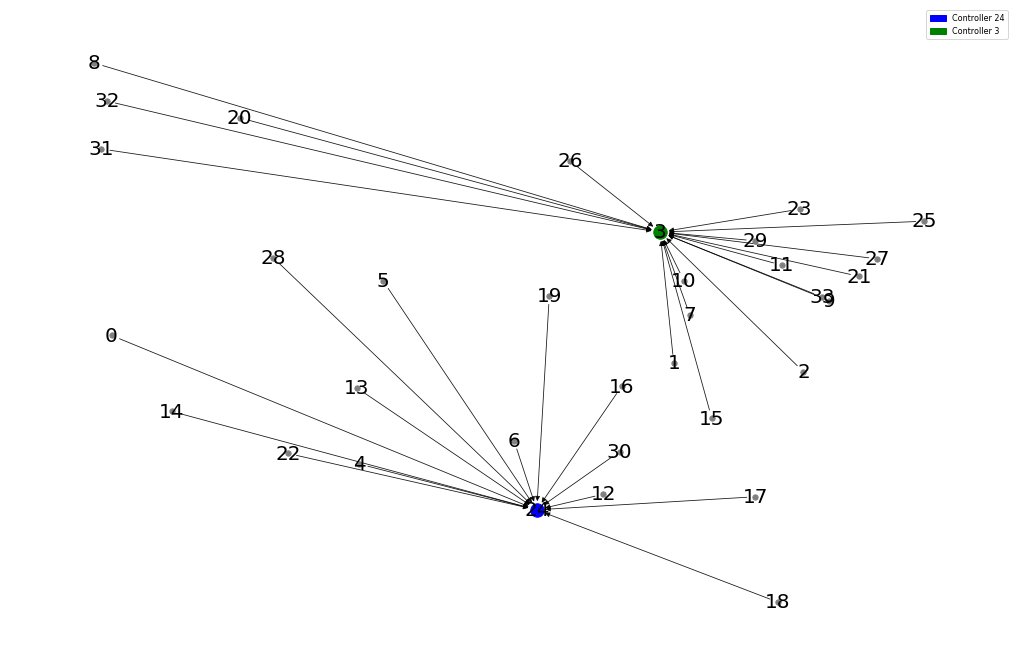

Controller 24: 14 switches assigned, switches = ['13', '4', '18', '6', '28', '0', '19', '5', '17', '30', '14', '12', '22', '16']
Controller 3: 18 switches assigned, switches = ['10', '15', '33', '26', '25', '23', '11', '21', '9', '1', '2', '20', '8', '32', '27', '29', '7', '31']


In [ ]:

controller_allocation = {}

    # Iterate over switches assigned to each controller
for controller, switches in new_dynamic_switches_dict.items():
    # Assign each switch to the corresponding controller in controller_allocation
    for switch in switches:
        controller_allocation[switch] = controller

# return controller_allocatio

switch_loads = {}

# Iterate through the traffic matrix to extract load for each switch
for controller, switches in traffic_matrix.items():
    for switch, traffic_volume in switches.items():
        switch_loads[switch] = traffic_volume

# Create a list of colors for controllers
colors = ['blue', 'green', 'red', 'orange', 'purple', 'pink', 'gray', 'brown', 'maroon', 'silver', 'lavender', 'navy']
controller_colors = {controller: color for controller, color in zip(selected_controllers, colors)}

# Create a directed graph (DiGraph) using NetworkX
G = nx.DiGraph()

# Add nodes (switches and controllers) to the graph
for node in controller_allocation:
    G.add_node(node)

# Add edges between switches and controllers based on controller_allocation
for switch, controller in controller_allocation.items():
    G.add_edge(switch, controller)

# Define the layout of the graph based on longitude and latitude
pos = {node: (data[node]["long"], data[node]["lat"]) for node in G.nodes()}

# Plot the graph
# Create a white background figure
fig = plt.figure(figsize=(18, 12), facecolor="white")  # Adjust the figure size as needed


# Draw the controllers as nodes with different colors
for controller in selected_controllers:
    nx.draw_networkx_nodes(G, pos, nodelist=[controller], node_color=controller_colors[controller], node_size=180)

# Draw the remaining nodes (switches) in gray
other_nodes = [node for node in G.nodes() if node not in selected_controllers]
nx.draw_networkx_nodes(G, pos, nodelist=other_nodes, node_color='gray', node_size=28)

# Draw edges and labels (if needed)
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), width=0.8, alpha=0.9)
nx.draw_networkx_labels(G, pos, labels, font_size=20)


# Add a legend
legend_patches = []
for controller, color in controller_colors.items():
    # load = switch_loads.get(controller, 0) 
    patch = mpatches.Patch(color=color, label=f'Controller {controller}')
    legend_patches.append(patch)
plt.legend(handles=legend_patches, fontsize=8)

# Show the plot
plt.axis('off')  # Turn off axis labels and ticks for a cleaner visualization
plt.show()


# Print the switches assigned to each controller
for controller, switches in new_dynamic_switches_dict.items():
    print(f"Controller {controller}: {len(switches)} switches assigned, switches = {list(switches)}")



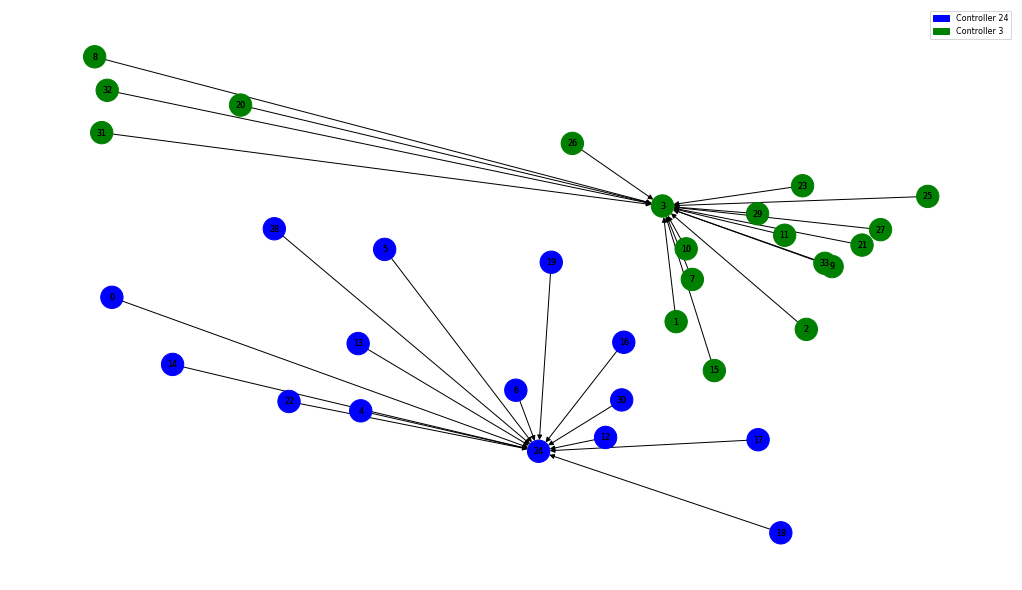

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# Create a directed graph
DG = G.to_directed()

# Define node colors and positions (you can reuse your existing definitions)
colors = ['blue', 'green', 'red', 'orange', 'purple', 'pink', 'gray', 'brown', 'maroon', 'silver', 'lavender', 'navy']
controller_colors = {controller: color for controller, color in zip(selected_controllers, colors)}
node_colors = [controller_colors[controller_allocation[node]] if node not in selected_controllers else controller_colors[node] for node in DG.nodes()]

pos = {k: (v["long"], v["lat"]) for k, v in data.items()}

# Plot the directed graph
plt.figure(figsize=(14, 8))  # Adjust the figure size as needed

# Plot edges with labels (load from switches)
# edge_labels = {(u, v): f"Load: {G[u][v]['load']}" for u, v in DG.edges()}
# nx.draw_networkx_edge_labels(DG, pos, edge_labels=edge_labels, font_size=8, label_pos=0.5, font_color='b', rotate=False)

# Plot the directed graph with edge labels
nx.draw(DG, pos, node_color=node_colors, with_labels=True, font_size=8, node_size=500, font_color='k')

# Add node labels
labels = {node: str(node) for node in DG.nodes()}
nx.draw_networkx_labels(DG, pos, labels, font_size=8)

# Add a legend
legend_patches = []
for controller, color in controller_colors.items():
    patch = mpatches.Patch(color=color, label=f'Controller {controller}')
    legend_patches.append(patch)
plt.legend(handles=legend_patches, fontsize=8)

# Show the plot
plt.show()


In [ ]:
import math

def max_switches_per_controller(total_switches, DBC_centrality, new_initial_controllers):
    # Calculate the total propagating capacity of all controllers
    total_capacity = sum(DBC_centrality[node] for node in new_initial_controllers)

    # Set the minimum and maximum number of switches per controller
    min_switches_per_controller = 4  # You can adjust this value
    max_switches_per_controller = 8  # You can adjust this value

    # Calculate the proportional allocation of switches for each controller
    switches_assigned = {}
    for controller in new_initial_controllers:
        proportional_allocation = (DBC_centrality[controller] / total_capacity) * total_switches
        switches_assigned[controller] = max(min_switches_per_controller, min(max_switches_per_controller, math.ceil(proportional_allocation)))

    return switches_assigned

# Example usage with the provided DNBC_centrality, new_initial_controllers, and total number of switches
total_switches = len(new_all_switches)

new_initial_controllers = list(new_initial_controllers)
new_initial_controllers.sort(reverse=True, key=lambda x: DBC_centrality[x])

max_switches_per_controller  = max_switches_per_controller(total_switches, DBC_centrality, new_initial_controllers)
print("Allocated number of switches for each controller:")
for controller, num_switches in max_switches_per_controller.items():
    print(f"{controller} - Allocated Switches: {num_switches}")

Allocated number of switches for each controller:
3 - Allocated Switches: 8
24 - Allocated Switches: 6
28 - Allocated Switches: 5
5 - Allocated Switches: 4
32 - Allocated Switches: 4
4 - Allocated Switches: 4
29 - Allocated Switches: 4


Load imbalance: 29.63%
Controller Utilization:
Controller 3: 0.62
Controller 24: 1.00
Controller 28: 0.00
Controller 5: 0.50
Controller 32: 0.75
Controller 4: 0.75
Controller 29: 2.00
Average Controller Utilization: 0.80
Average latency between controllers and switches: 1.74 m/s
Worst case latency between controllers and switches: 4.00 m/s
Controller-switch pair with maximum latency: Controller 3 and Switch 15
Average latency between controllers: 2.95 m/s
Worst-case latency between controllers: 5.00 m/s
Worst-case controller pair: Controller 24 and Controller 32


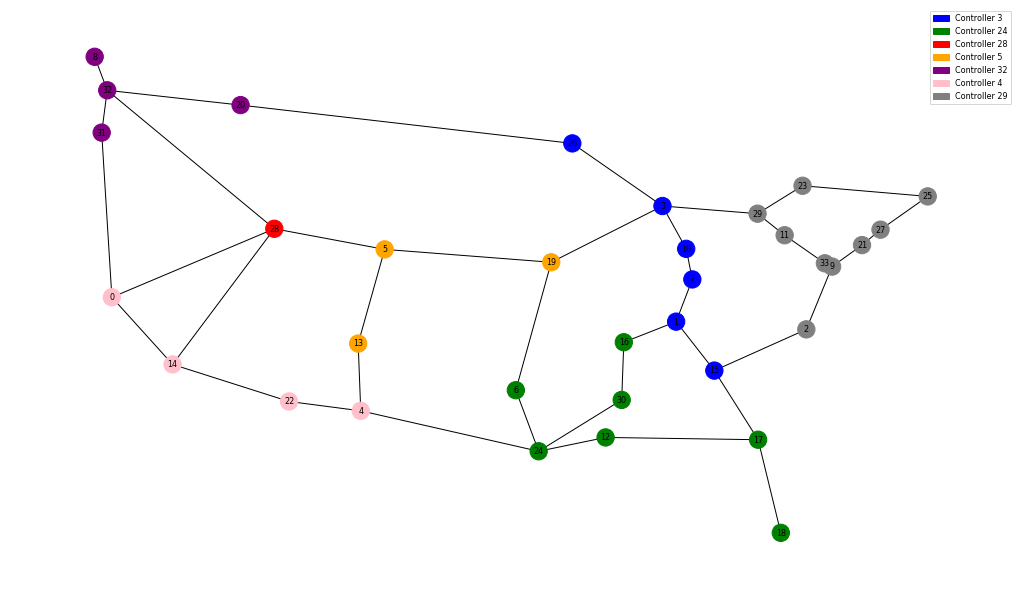

New Initial Controller 3: 5 switches assigned, switches = ['1', '10', '7', '15', '26']
New Initial Controller 24: 6 switches assigned, switches = ['18', '17', '12', '6', '16', '30']
New Initial Controller 28: 0 switches assigned, switches = []
New Initial Controller 5: 2 switches assigned, switches = ['19', '13']
New Initial Controller 32: 3 switches assigned, switches = ['31', '20', '8']
New Initial Controller 4: 3 switches assigned, switches = ['0', '22', '14']
New Initial Controller 29: 8 switches assigned, switches = ['25', '33', '27', '11', '9', '21', '2', '23']


In [ ]:
# Weighted Neighborhood Scheduling for Heterogenous controller placements when number of controllers to be placed is maximum

import networkx as nx
import math

def euclidean_distance(p1, p2):
    # return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)
    return math.sqrt((p1["lat"] - p2["lat"])**2 + (p1["long"] - p2["long"])**2)

def assign_switches_to_controllers(G, new_all_switches, new_initial_controllers, max_steps, max_switches_per_controller, min_switches_per_controller):
    new_switches_dict = {controller: set() for controller in new_initial_controllers}
    remaining_switches = set(new_all_switches)

    # Get the geographic coordinates of the controllers
    controller_positions = {controller: geo_loc_data[controller] for controller in new_initial_controllers}

    while remaining_switches:
        assigned = False  # Flag to track if any assignment is made in this iteration
        for controller in new_initial_controllers:
            if remaining_switches and len(new_switches_dict[controller]) < max_switches_per_controller:
                closest_switch = min(remaining_switches, key=lambda switch: euclidean_distance(controller_positions[controller], geo_loc_data[switch]))
                distance_to_controller = euclidean_distance(controller_positions[controller], geo_loc_data[closest_switch])
                if distance_to_controller <= max_steps:
                    # Check if the switch is directly connected to the controller or any assigned switch
                    if G.has_edge(controller, closest_switch) or any(G.has_edge(switch, closest_switch) for switch in new_switches_dict[controller]):
                        new_switches_dict[controller].add(closest_switch)
                        remaining_switches.remove(closest_switch)
                        assigned = True  # Mark assignment made

        # If no assignments were made in this iteration, break out of the loop
        if not assigned:
            break

    # Add empty controllers to the nearest available controller aside from itself
    empty_controllers = [controller for controller, switches in new_switches_dict.items() if not switches]
    for empty_controller in empty_controllers:
        nearest_controller = min(new_initial_controllers, key=lambda controller: euclidean_distance(controller_positions[empty_controller], controller_positions[controller]))
        if nearest_controller != empty_controller:
            new_initial_controllers.remove(empty_controller)
            new_switches_dict[nearest_controller].add(empty_controller)

    # Enforce the min_switches_per_controller constraint
    for controller in new_initial_controllers:
        while len(new_switches_dict[controller]) < min_switches_per_controller and remaining_switches:
            switch = remaining_switches.pop()
            new_switches_dict[controller].add(switch)

    return new_switches_dict



# Assuming you have defined G, new_all_switches, new_initial_controllers, max_steps

# Define the maximum and minimum number of switches per controller
max_switches_per_controller = 10  # Set your maximum value here
min_switches_per_controller = 4  # Set your minimum value here

# new_switches_dict = assign_switches_to_controllers(G, new_all_switches, new_initial_controllers, max_steps)
new_switches_dict = assign_switches_to_controllers(G, new_all_switches, new_initial_controllers, max_steps, max_switches_per_controller, min_switches_per_controller)

# # Print assignments
# print("Switch Assignments:")
# for controller, assigned_switches in new_switches_dict.items():
#     num_assigned_switches = len(assigned_switches)
#     assigned_switches_list = ', '.join(assigned_switches)
#     print(f"Controller {controller}: {num_assigned_switches} switches assigned, switches = [{assigned_switches_list}]")
# Calculate the total number of assigned switches
num_assigned_switches = {controller: len(switches) for controller, switches in new_switches_dict.items()}
total_assigned_switches = sum(num_assigned_switches.values())
 # Calculate the load imbalance between controllers
max_assigned_switches = max(num_assigned_switches.values())
min_assigned_switches = min(num_assigned_switches.values())
load_imbalance = (max_assigned_switches - min_assigned_switches) / total_assigned_switches * 100
print(f"Load imbalance: {load_imbalance:.2f}%")

# # Calculate the controller utilization and average utilization based on the actual number of switches assigned
controller_utilization = {controller: num_assigned_switches[controller] / controller_capacity[controller] for controller in new_initial_controllers}
average_utilization = sum(controller_utilization.values()) / len(controller_utilization)
print("Controller Utilization:")
for controller, utilization in controller_utilization.items():
    print(f"Controller {controller}: {utilization:.2f}")
print(f"Average Controller Utilization: {average_utilization:.2f}")

# Calculate latency between each controller-switch pair
total_latency_switch_to_controller = 0  # Initialize the total latency sum to zero

for controller, switches in switches_dict.items():
    for switch in switches:
        try:
            distance = nx.shortest_path_length(G, source=switch, target=controller, weight='none')
            #print(f"Latency between Controller {controller} and Switch {switch}: {distance:.2f} units")

            # Add the latency to the total sum
            total_latency_switch_to_controller += distance

        except nx.NetworkXNoPath:
        # If no path exists between the switch and controller, skip and move to the next controller
            continue

# Calculate the average latency between controllers and switches
average_latency_switch_to_controller = total_latency_switch_to_controller / total_assigned_switches
print(f"Average latency between controllers and switches: {average_latency_switch_to_controller:.2f} m/s")

# Calculate worst case latency between each controller-switch pair
max_latency_switch_to_controller = float('-inf')  # Initialize to a very small value
max_controller_switch_pair = (None, None)  # Initialize to None

for controller, switches in new_switches_dict.items():
    for switch in switches:
        try:
            distance = nx.shortest_path_length(G, source=switch, target=controller, weight='none')
            #print(f"Latency between Controller {controller} and Switch {switch}: {distance:.2f} units")

            # Update the maximum latency and corresponding controller-switch pair if found
            if distance > max_latency_switch_to_controller:
                max_latency_switch_to_controller = distance
                max_controller_switch_pair = (controller, switch)

        except nx.NetworkXNoPath:
            # If no path exists between the switch and controller, skip and move to the next controller
            continue

print(f"Worst case latency between controllers and switches: {max_latency_switch_to_controller:.2f} m/s")
print(f"Controller-switch pair with maximum latency: Controller {max_controller_switch_pair[0]} and Switch {max_controller_switch_pair[1]}")

# Calculate latency between each controller pair
total_latency_between_controllers = 0  # Initialize the total latency sum between controller pairs

# Nested loop to iterate over all combinations of distinct controllers
for i, controller1 in enumerate(new_initial_controllers):
    for controller2 in new_initial_controllers[i + 1:]:
        try:
            distance = nx.shortest_path_length(G, source=controller1, target=controller2, weight='none')
            #print(f"Latency between Controller {controller1} and Controller {controller2}: {distance:.2f} units")

            # Add the latency to the total sum
            total_latency_between_controllers += distance

        except nx.NetworkXNoPath:
        # If no path exists between the controllers, skip and move to the next controller pair
            continue

# Calculate the average latency between controllers
total_controller_pairs = len(new_initial_controllers) * (len(new_initial_controllers) - 1) / 2  # Total number of distinct controller pairs
average_latency_between_controllers = total_latency_between_controllers / total_controller_pairs
print(f"Average latency between controllers: {average_latency_between_controllers:.2f} m/s")



# Calculate latency between each controller pair
max_latency_between_controllers = float('-inf')  # Initialize the maximum latency to a very small value
worst_case_controller_pair = (None, None)  # Initialize to None

# Nested loop to iterate over all combinations of distinct controllers
for i, controller1 in enumerate(new_initial_controllers):
    for controller2 in new_initial_controllers[i + 1:]:
        try:
            distance = nx.shortest_path_length(G, source=controller1, target=controller2, weight='none')
        # print(f"Latency between Controller {controller1} and Controller {controller2}: {distance:.2f} units")

            # Update the maximum latency and corresponding controller pair if found
            if distance > max_latency_between_controllers:
                max_latency_between_controllers = distance
                worst_case_controller_pair = (controller1, controller2)

        except nx.NetworkXNoPath:
        # If no path exists between the controllers, skip and move to the next controller pair
            continue

# Print the worst-case latency and the corresponding controller pair
print(f"Worst-case latency between controllers: {max_latency_between_controllers:.2f} m/s")
print(f"Worst-case controller pair: Controller {worst_case_controller_pair[0]} and Controller {worst_case_controller_pair[1]}")


controller_allocation = {}

    # Iterate over switches assigned to each controller
for controller, switches in new_switches_dict.items():
    # Assign each switch to the corresponding controller in controller_allocation
    for switch in switches:
        controller_allocation[switch] = controller

# return controller_allocation

    # Plot the graph
colors = ['blue', 'green', 'red', 'orange', 'purple', 'pink', 'gray', 'brown', 'maroon', 'silver', 'lavender' 'navy']
controller_colors = {controller: color for controller, color in zip(new_initial_controllers, colors)}
node_colors = [controller_colors[controller_allocation[node]] if node not in new_initial_controllers else controller_colors[node] for node in G.nodes()]

pos = {k: (v["long"], v["lat"]) for k, v in data.items()}

    # Plot the graph
    #pos = dict(zip(G.nodes(), nodes_data))
    # Plot the graph
plt.figure(figsize=(14, 8))  # Adjust the figure size as needed
nx.draw(G, pos, node_color=node_colors)

    # Add node labels
labels = {node: str(node) for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=8)

    # Add a legend
legend_patches = []
for controller, color in controller_colors.items():
    patch = mpatches.Patch(color=color, label=f'Controller {controller}')
    legend_patches.append(patch)
plt.legend(handles=legend_patches, fontsize=8)

# Show the plot
plt.show()

# Print the switches assigned to each new initial controller
for initial_controller, switches in new_switches_dict.items():
    print(f"New Initial Controller {initial_controller}: {len(switches)} switches assigned, switches = {list(switches)}")


In [ ]:
# new_initial_controllers.sort(reverse=True, key=lambda x: (DBC_centrality[x]))
# new_initial_controllers = list(new_initial_controllers)
# #new_initial_controllers = [x[0] for x in new_initial_controllers]

# # # Create a list of all switches
# new_switches = list(G.nodes())

# # Remove the initial controllers from the list of switches
# all_switches = [node for node in new_switches if node not in new_initial_controllers]

# # # Create a dictionary to store the switches assigned to each new initial controller
# switches_dict = {}
# for initial_controller in new_initial_controllers:
#     switches_dict[initial_controller] = set()


# # Assign the switches to the initial controllers based on their weight
# while all_switches:
#     for controller in new_initial_controllers:
#         # Calculate the distance from the controller to each switch
#         distances = []
#         for switch in all_switches:
#             distance = nx.shortest_path_length(G, source=controller, target=switch, weight='distance')
#             distances.append((switch, distance))
#         # Sort the switches by their distance to the controller
#         distances = sorted(distances, key=lambda x: x[1])
#         # Assign the switch with the lowest distance to the controller if it hasn't already been assigned
#         switch_to_assign = None
#         for switch, distance in distances:
#             if switch not in switches_dict.values():
#                 switch_to_assign = switch
#                 break
#         if switch_to_assign:
#             switches_dict[controller].add(switch_to_assign)
#             all_switches.remove(switch_to_assign)
#         # If there are no switches left, exit the loop
#         if not all_switches:
#             break

# # Print the switches assigned to each new initial controller
# for initial_controller, switches in switches_dict.items():
#     print(f"New Initial Controller {initial_controller}: {len(switches)} switches assigned, switches = {list(switches)}")



In [ ]:
new_initial_controllers

['3', '24', '28', '5', '32', '4', '29']

In [ ]:
# # Get the initial controllers based on their D-2_NS_centrality
# initial_controllers = sorted(DBC_centrality.items(), key=itemgetter(1), reverse=True)[:8]
# initial_controllers = [x[0] for x in initial_controllers]

# # Create a list of all switches
# new_switches = list(G.nodes())
# # Remove the initial controllers from the list of switches
# all_switches = [node for node in new_switches if node not in initial_controllers]

# # Create a dictionary to store the switches assigned to each initial controller
# switches_dict = {initial_controller: [] for initial_controller in initial_controllers}

# # Assign the switches to the initial controllers based on their weight
# while all_switches:
#     for controller in initial_controllers:
#         # Calculate the distance from the controller to each switch
#         distances = []
#         for switch in all_switches:
#             distance = nx.shortest_path_length(G, source=controller, target=switch, weight='distance')
#             distances.append((switch, distance))
#         # Sort the switches by their distance to the controller
#         distances = sorted(distances, key=itemgetter(1))
#         # Assign the switch with the lowest distance to the controller
#         switch_to_assign = distances[0][0]
#         switches_dict[controller].append(switch_to_assign)
#         all_switches.remove(switch_to_assign)
#         # If there are no switches left, exit the loop
#         if not all_switches:
#             break



# # Calculate the total average and worst-case latency between controllers and switches
# total_latency = 0
# worst_case_latency = 0
# num_pairs = 0

# for controller in switches_dict:
#     for switch in switches_dict[controller]:
#         latency = nx.shortest_path_length(G, source=controller, target=switch, weight='distance')
#         total_latency += latency
#         num_pairs += 1
#         if latency > worst_case_latency:
#             worst_case_latency = latency

# average_latency = total_latency / num_pairs

# print(f"Total average latency: {average_latency:.2f}")
# print(f"Worst-case latency: {worst_case_latency}")

# # Get the list of controllers
# controllers = list(switches_dict.keys())

# # Calculate the shortest path lengths between all pairs of controllers
# path_lengths = []
# for i in range(len(controllers)):
#     for j in range(i+1, len(controllers)):
#         length = nx.shortest_path_length(G, source=controllers[i], target=controllers[j], weight='distance')
#         path_lengths.append(length)

# # Calculate the average and worst-case latency
# average_latency = sum(path_lengths) / len(path_lengths)
# worst_case_latency = max(path_lengths)

# print("Average latency between controllers:", average_latency)
# print("Worst-case latency between controllers:", worst_case_latency)

# # Calculate the load imbalance between the new initial controller clusters
# num_assigned_switches = {controller: len(switches) for controller, switches in switches_dict.items() if controller in new_initial_controllers}
# total_assigned_switches = sum(num_assigned_switches.values())
# max_assigned_switches = max(num_assigned_switches.values())
# min_assigned_switches = min(num_assigned_switches.values())
# load_imbalance = (max_assigned_switches - min_assigned_switches) / total_assigned_switches * 100
# print(f"Load imbalance: {load_imbalance:.2f}%")

# # Print the switches assigned to each initial controller
# for initial_controller, switches in switches_dict.items():
#     print(f"Initial Controller {initial_controller}: {len(switches)} switches assigned, switches = {switches}")

    
# # Create a dictionary to store the switches assigned to each new initial controller
# new_switches_dict = {}
# for initial_controller in new_initial_controllers:
#     new_switches_dict[initial_controller] = set()

# # Assign the switches in new_all_switches to the new initial controllers
# for node in new_all_switches:
#     min_distance = math.inf
#     closest_controller = None
#     for controller in new_initial_controllers:
#         distance = nx.shortest_path_length(G, source=node, target=controller, weight='distance')
#         if distance < min_distance:
#             min_distance = distance
#             closest_controller = controller
#     new_switches_dict[closest_controller].add(node)

# # Calculate the load imbalance between the new initial controller clusters
# num_assigned_switches = {controller: len(switches) for controller, switches in switches_dict.items()}
# total_assigned_switches = sum(num_assigned_switches.values())
# max_assigned_switches = max(num_assigned_switches.values())
# min_assigned_switches = min(num_assigned_switches.values())
# load_imbalance = (max_assigned_switches - min_assigned_switches) / total_assigned_switches * 100
# print(f"Load imbalance: {load_imbalance:.2f}%")

# # Calculate the total average latency between controllers and switches
# total_latency = 0
# for controller in new_initial_controllers:
#     for switch in switches_dict[controller]:
#         distance = nx.shortest_path_length(G, source=switch, target=controller, weight='distance')
#         total_latency += distance
# average_latency = total_latency / total_assigned_switches
# print(f"Total average latency: {average_latency:.2f} m/s")

# # Calculate the total average latency between controllers and switches
# total_latency = 0
# for controller1 in new_initial_controllers:
#     for controller2 in new_initial_controllers:
#         if controller1 != controller2:
#             distance = nx.shortest_path_length(G, source=controller1, target=controller2, weight='distance')
#             total_latency += distance
# average_latency = total_latency / (len(new_initial_controllers) * (len(new_initial_controllers) - 1))
# print(f"Average latency between controllers: {average_latency:.2f} m/s")

# # Calculate the worst-case latency between controllers and switches
# worst_case_latency = 0
# for controller in new_initial_controllers:
#     for switch in switches_dict[controller]:
#         distance = nx.shortest_path_length(G, source=switch, target=controller, weight='distance')
#         if distance > worst_case_latency:
#             worst_case_latency = distance
# print(f"Worst-case latency between controllers and switches: {worst_case_latency:.2f} m/s")

# # Calculate the worst-case latency between controllers
# worst_case_latency = 0
# for controller1 in new_initial_controllers:
#     for controller2 in new_initial_controllers:
#         if controller1 != controller2:
#             distance = nx.shortest_path_length(G, source=controller1, target=controller2, weight='distance')
#             if distance > worst_case_latency:
#                 worst_case_latency = distance
# print(f"Worst-case latency between controllers: {worst_case_latency:.2f} m/s")

# # Print the switches assigned to each new initial controller
# for initial_controller, switches in switches_dict.items():
#     print(f"New Initial Controller {initial_controller}: {len(switches)} switches assigned, switches = {list(switches)}")

# # Print the list of new_initial_controllers
# print(f"New initial controllers: {len(new_initial_controllers)} controllers, controllers = {list(new_initial_controllers)}")

# # Print the list of new_all_switches
# print(f"Total switches assigned: {len(new_all_switches)}, switches = {list(new_all_switches)}")



In [ ]:
# Convert new_initial_controllers to a list and sort by DBC centrality in descending order
new_initial_controllers = list(new_initial_controllers)
new_initial_controllers.sort(reverse=True, key=lambda x: (DBC_centrality[x]))

total_centrality = sum(DBC_centrality[node] for node in new_initial_controllers)
total_weight_percent = sum(DBC_centrality[node] / total_centrality for node in new_initial_controllers)

# Determine maximum number of switches that each controller should have assigned to it
max_switches_dict = {}
for controller in new_initial_controllers:
    weight_percent = DBC_centrality[controller] / total_centrality
    max_switches = int(round(weight_percent / total_weight_percent * len(new_all_switches)))
    max_switches_dict[controller] = max_switches

# Create a dictionary to store the switches assigned to each controller
#switches_assigned_dict = {controller: list(assigned_switches_dict[controller]) for controller in new_initial_controllers}

# # Assign switches to controllers based on their maximum number of switches
# assigned_switches_dict = {controller: set() for controller in new_initial_controllers}
# for node in new_all_switches:
#     min_distance = math.inf
#     closest_controller = None
#     for controller in new_initial_controllers:
#         distance = nx.shortest_path_length(G, source=node, target=controller, weight='distance')
#         if distance < min_distance:
#             min_distance = distance
#             closest_controller = controller
#     # Assign node to closest controller if it has not exceeded the maximum number of switches
#     if len(assigned_switches_dict[closest_controller]) < max_switches_dict[closest_controller]:
#         assigned_switches_dict[closest_controller].add(node)
#     # Otherwise, find the next available controller with remaining capacity and assign node to it
#     else:
#         for controller in new_initial_controllers:
#             if len(assigned_switches_dict[controller]) < max_switches_dict[controller]:
#                 assigned_switches_dict[controller].add(node)
#                 closest_controller = controller
#                 break
#     weight_percent = DBC_centrality[closest_controller] / total_centrality
#     #print(f"Node {node} assigned to Controller {closest_controller} - Weight Percentage: {weight_percent:.2f}")


# # Create a dictionary to store the switches assigned to each controller
# assigned_switches_dict = {controller: set() for controller in new_initial_controllers}

# # Assign switches to controllers based on their maximum number of switches
# for node in new_all_switches:
#     min_distance = math.inf
#     closest_controller = None
#     for controller in new_initial_controllers:
#         distance = nx.shortest_path_length(G, source=node, target=controller, weight='distance')
#         if distance < min_distance:
#             min_distance = distance
#             closest_controller = controller
#     # Assign node to closest controller if it has not exceeded the maximum number of switches
#     if len(assigned_switches_dict[closest_controller]) < max_switches_dict[closest_controller]:
#         assigned_switches_dict[closest_controller].add(node)
#     # Otherwise, find the next closest controller with remaining capacity and assign node to it
#     else:
#         found_controller = False
#         for i in range(len(new_initial_controllers)):
#             controller = new_initial_controllers[i]
#             if len(assigned_switches_dict[controller]) < max_switches_dict[controller]:
#                 assigned_switches_dict[controller].add(node)
#                 closest_controller = controller
#                 found_controller = True
#                 break
#         if not found_controller:
#             # If no controller is available with remaining capacity, assign the node to the closest controller
#             assigned_switches_dict[closest_controller].add(node)
            
#     weight_percent = DBC_centrality[closest_controller] / total_centrality

# Assign switches to controllers based on their maximum number of switches
new_switches_dict = {controller: set() for controller in new_initial_controllers}
for node in new_all_switches:
    min_distance = math.inf
    closest_controller = None
    max_weight = -1
    for controller in new_initial_controllers:
        distance = nx.shortest_path_length(G, source=node, target=controller, weight='distance')
        weight = DBC_centrality[controller]
        if distance < min_distance and weight > max_weight:
            min_distance = distance
            closest_controller = controller
            max_weight = weight
    # Assign node to closest controller if it has not exceeded the maximum number of switches
    if len(new_switches_dict[closest_controller]) < max_switches_dict[closest_controller]:
        new_switches_dict[closest_controller].add(node)
    # Otherwise, find the next closest controller with remaining capacity and assign node to it
    else:
        for controller in new_initial_controllers:
            if len(new_switches_dict[controller]) < max_switches_dict[controller]:
                new_switches_dict[controller].add(node)
                closest_controller = controller
                break
    weight_percent = DBC_centrality[closest_controller] / total_centrality


# Calculate average and worst-case controller to switch latency
latency_values = []
for controller in new_initial_controllers:
    switches_assigned = list(assigned_switches_dict[controller])
    for switch in switches_assigned:
        distance = nx.shortest_path_length(G, source=switch, target=controller, weight='distance')
        latency_values.append(distance)
        #print(f"Switch {switch} assigned to Controller {controller} - Latency: {distance}")
        
average_latency = sum(latency_values) / len(latency_values)
print(f"average_latency: {average_latency:.2f} m/s")
worst_case_latency = max(latency_values)
print(f"worst_case_latency: {worst_case_latency:.2f} m/s")

# Calculate controller-to-controller latencies
controller_latencies_dict = dict(nx.all_pairs_dijkstra_path_length(G, weight='distance'))

# Convert controller-to-controller latencies to a list of tuples
controller_latencies_list = [(src, dst, distance) for src in new_initial_controllers for dst, distance in controller_latencies_dict[src].items() if dst in new_initial_controllers and src != dst]

# Calculate average controller-to-controller latency
avg_controller_latency = sum(distance for _, _, distance in controller_latencies_list) / len(controller_latencies_list)
print(f"Average controller-to-controller latency: {avg_controller_latency:.2f}")

# Calculate worst-case controller-to-controller latency
worst_case_latency = max(distance for _, _, distance in controller_latencies_list)
print(f"Worst-case controller-to-controller latency: {worst_case_latency:.2f}")

# Print number of switches assigned to each controller
for controller in new_initial_controllers:
    num_switches = len(assigned_switches_dict[controller])
    weight_percent = DBC_centrality[controller] / total_centrality
    print(f"Controller {controller} - ProbCapacity: {weight_percent:.2f} - Num Switches: {num_switches}")


# Print switches assigned to each controller
for controller in new_initial_controllers:
    switches_assigned = list(assigned_switches_dict[controller])
    weight_percent = DBC_centrality[controller] / total_centrality
    print(f"Controller {controller} {switches_assigned}")

switch_counts = [len(assigned_switches_dict[controller]) for controller in new_initial_controllers]
load_imbalance = (max(switch_counts) - min(switch_counts)) / len(new_all_switches) * 100
print(f"Load imbalance: {load_imbalance:.2f}%")




NameError: name 'assigned_switches_dict' is not defined

In [ ]:
assigned_switches_dict

: 

In [ ]:
# import math
# import networkx as nx

# # Convert new_initial_controllers to a list and sort by DBC centrality in descending order
# new_initial_controllers = list(new_initial_controllers)
# new_initial_controllers.sort(reverse=True, key=lambda x: (DBC_centrality[x]))

# # Determine maximum number of switches that each controller should have assigned to it
# num_controllers = len(new_initial_controllers)
# total_switches = len(new_all_switches)
# switches_per_controller = total_switches // num_controllers
# remainder_switches = total_switches % num_controllers
# max_switches_dict = {controller: switches_per_controller for controller in new_initial_controllers}
# for i in range(remainder_switches):
#     max_switches_dict[new_initial_controllers[i]] += 1

# total_centrality = sum(DBC_centrality[node] for node in new_initial_controllers)
# total_weight_percent = sum(DBC_centrality[node] / total_centrality for node in new_initial_controllers)

# # Create a dictionary to store the switches assigned to each controller
# # switches_assigned_dict = {controller: list(assigned_switches_dict[controller]) for controller in new_initial_controllers}


# # Assign switches to controllers based on their maximum number of switches
# assigned_switches_dict = {controller: set() for controller in new_initial_controllers}
# for node in new_all_switches:
#     min_distance = math.inf
#     closest_controller = None
#     for controller in new_initial_controllers:
#         distance = nx.shortest_path_length(G, source=node, target=controller, weight='distance')
#         if distance < min_distance:
#             min_distance = distance
#             closest_controller = controller
#     # Assign node to closest controller if it has not exceeded the maximum number of switches
#     if len(assigned_switches_dict[closest_controller]) < max_switches_dict[closest_controller]:
#         assigned_switches_dict[closest_controller].add(node)
#     # Otherwise, find the next available controller with remaining capacity and assign node to it
#     else:
#         for controller in new_initial_controllers:
#             if len(assigned_switches_dict[controller]) < max_switches_dict[controller]:
#                 assigned_switches_dict[controller].add(node)
#                 closest_controller = controller
#                 break
#     weight_percent = DBC_centrality[closest_controller] / total_centrality
#     #print(f"Node {node} assigned to Controller {closest_controller} - Weight Percentage: {weight_percent:.2f}")

# # Calculate average and worst-case controller to switch latency
# latency_values = []
# for controller in new_initial_controllers:
#     switches_assigned = list(assigned_switches_dict[controller])
#     for switch in switches_assigned:
#         distance = nx.shortest_path_length(G, source=switch, target=controller, weight='distance')
#         latency_values.append(distance)
#         #print(f"Switch {switch} assigned to Controller {controller} - Latency: {distance}")
        
# average_latency = sum(latency_values) / len(latency_values)
# print(f"average_latency: {average_latency:.2f} m/s")
# worst_case_latency = max(latency_values)
# print(f"worst_case_latency: {worst_case_latency:.2f} m/s")

# # # Convert controller-to-controller latencies to a list of tuples
# # controller_latencies_list = [(src, dst, distance) for src in new_initial_controllers for dst, distance in controller_latencies_dict[src].items() if dst in new_initial_controllers and src != dst]

# # # Calculate average controller-to-controller latency
# # avg_controller_latency = sum(distance for _, _, distance in controller_latencies_list) / len(controller_latencies_list)
# # print(f"Average controller-to-controller latency: {avg_controller_latency:.2f}")

# # # Calculate worst-case controller-to-controller latency
# # worst_case_latency = max(distance for _, _, distance in controller_latencies_list)
# # print(f"Worst-case controller-to-controller latency: {worst_case_latency:.2f}")

# # Print switches assigned to each controller
# for controller in new_initial_controllers:
#     switches = assigned_switches_dict[controller]
#     weight_percent = DBC_centrality[controller] / total_centrality
#     print(f"Controller {controller} - Weight Percentage: {weight_percent:.2f} - Switches: {switches}")

# switch_counts = [len(assigned_switches_dict[controller]) for controller in new_initial_controllers]
# load_imbalance = (max(switch_counts) - min(switch_counts)) / len(new_all_switches) * 100
# print(f"Load imbalance: {load_imbalance:.2f}%")




: 

In [ ]:
controller_allocation = {}

# Iterate over switches assigned to each controller
#for controller, switches in switches_dict.items():
#for controller, switches in new_switches_dict.items():
for controller, switches in assigned_switches_dict.items(): 
    # Assign each switch to the corresponding controller in controller_allocation
    for switch in switches:
        controller_allocation[switch] = controller

: 

In [ ]:
controller_allocation

: 

In [ ]:
controller_allocation = {}

# Iterate over switches assigned to each controller
#for controller, switches in new_switches_dict.items():
for controller, switches in assigned_switches_dict.items(): 
    # Assign each switch to the corresponding controller in controller_allocation
    for switch in switches:
        controller_allocation[switch] = controller

colors = ['blue', 'green', 'red', 'orange', 'purple', 'pink', 'gray', 'brown', 'maroon', 'silver', 'lavender', 'navy']
controller_colors = {controller: color for controller, color in zip(new_initial_controllers, colors)}
node_colors = [controller_colors[controller_allocation[node]] if node not in new_initial_controllers else controller_colors[node] for node in G.nodes()]

pos = {k: (v["long"], v["lat"]) for k, v in data.items()}

# Plot the graph
#pos = dict(zip(G.nodes(), nodes_data))
nx.draw(G, pos, node_color=node_colors)

# Add node labels
labels = {node: str(node) for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=8)

# Add a legend
legend_patches = []
for controller, color in controller_colors.items():
    patch = mpatches.Patch(color=color, label=f'Controller {controller}')
    legend_patches.append(patch)
plt.legend(handles=legend_patches, fontsize=8)

# Show the plot
plt.show()


: 

In [ ]:
# Define the number of controllers to select
num_controllers = 4

# Sort the new initial controllers based on D_2SN_centrality
sorted_new_initial_controllers = sorted(new_initial_controllers, reverse=True, key=lambda x: (DBC_centrality[x]))

# Select the top num_controllers controllers from the sorted list
selected_controllers = sorted_new_initial_controllers[:num_controllers]

# Print the selected list of new initial controllers
print(f"Selected controllers: {len(selected_controllers)} controllers, controllers = {selected_controllers}")

# Print the D_2SN_centrality of each selected controller
for controller in selected_controllers:
    print(f"Node {controller}: D_2NS_Centrality = {DBC_centrality[controller]}")



: 

In [ ]:
dynamic_all_new_switches = set(G.nodes()) - set(selected_controllers)

: 

In [ ]:
# Create a dictionary to store the switches assigned to each controller
switches_dict = {}
for controller in selected_controllers:
    switches_dict[controller] = set()

# Assign the switches in dynamic_all_new_switches to the controllers
for node in dynamic_all_new_switches:
    min_distance = math.inf
    closest_controller = None
    for controller in selected_controllers:
        distance = nx.shortest_path_length(G, source=node, target=controller, weight='distance')
        if distance < min_distance:
            min_distance = distance
            closest_controller = controller
    # If the closest controller is in new_initial_controllers and hasn't been assigned any switches yet
    # and it is not already in the selected_controllers list
    if closest_controller in new_initial_controllers and not switches_dict[closest_controller] and closest_controller not in selected_controllers:
        switches_dict[closest_controller] = new_switches_dict[closest_controller]
    else:
        switches_dict[closest_controller].add(node)

# Calculate the total average latency between selected controllers and switches
if len(dynamic_all_new_switches) > 0:
    total_average_latency = total_latency / len(dynamic_all_new_switches)
else:
    total_average_latency = 0
print(f"Total average latency between selected controllers and switches: {total_average_latency:.2f} m/s")

# Create a dictionary to store the switches assigned to each controller
switches_dict = {}
for controller in selected_controllers:
    switches_dict[controller] = set()

# Assign the switches in dynamic_all_new_switches to the controllers
worst_case_latency = 0
for node in dynamic_all_new_switches:
    min_distance = math.inf
    closest_controller = None
    for controller in selected_controllers:
        distance = nx.shortest_path_length(G, source=node, target=controller, weight='distance')
        if distance < min_distance:
            min_distance = distance
            closest_controller = controller
    # If the closest controller is in new_initial_controllers and hasn't been assigned any switches yet
    # and it is not already in the selected_controllers list
    if closest_controller in new_initial_controllers and not switches_dict[closest_controller] and closest_controller not in selected_controllers:
        switches_dict[closest_controller] = new_switches_dict[closest_controller]
    else:
        switches_dict[closest_controller].add(node)
    if min_distance > worst_case_latency:
        worst_case_latency = min_distance

# Calculate the worst case latency between selected controllers and switches
print(f"Worst case latency between selected controllers and switches: {worst_case_latency:.2f} m/s")

# Calculate the average latency between selected controllers
controller_pairs = list(itertools.combinations(selected_controllers, 2))
avg_latencies = []
for pair in controller_pairs:
    distance = nx.shortest_path_length(G, source=pair[0], target=pair[1], weight='distance')
    avg_latencies.append(distance)
    avg_latency = sum(avg_latencies) / len(avg_latencies)


# Print the average latency between selected controllers
print(f"Average latency between selected controllers: {avg_latency:.2f} m/s")

# Calculate the worst-case latency between selected controllers
worst_case_latency = 0
for i in range(len(selected_controllers)):
    for j in range(i+1, len(selected_controllers)):
        distance = nx.shortest_path_length(G, source=selected_controllers[i], target=selected_controllers[j], weight='distance')
        if distance > worst_case_latency:
            worst_case_latency = distance

# Print the worst-case latency between selected controllers
print(f"Worst-case latency between selected controllers: {worst_case_latency:.2f} m/s")


# Print the switches assigned to each controller
for controller, switches in switches_dict.items():
    print(f"Controller {controller}: {len(switches)} switches assigned, switches = {list(switches)}")

# Calculate the load imbalance
num_switches_per_controller = [len(switches_dict[controller]) for controller in selected_controllers]

# Calculate the total number of switches
num_switches = sum(len(switches_dict[controller]) for controller in selected_controllers)

load_imbalance = (max(num_switches_per_controller) - min(num_switches_per_controller)) / num_switches * 100
print(f"Load imbalance: {load_imbalance:.2f}%")

: 

In [ ]:
# # Convert new_initial_controllers to a list and sort by DBC centrality in descending order
# new_initial_controllers = list(new_initial_controllers)
# new_initial_controllers.sort(reverse=True, key=lambda x: (DBC_centrality[x]))

# total_centrality = sum(DBC_centrality[node] for node in selected_controllers)
# total_weight_percent = sum(DBC_centrality[node] / total_centrality for node in selected_controllers)

# # Determine maximum number of switches that each controller should have assigned to it
# max_switches_dict = {}
# for controller in selected_controllers:
#     weight_percent = DBC_centrality[controller] / total_centrality
#     max_switches = int(round(weight_percent / total_weight_percent * len(new_all_switches)))
#     max_switches_dict[controller] = max_switches


# # Assign switches to controllers based on their maximum number of switches
# assigned_switches_dict = {controller: set() for controller in selected_controllers}
# for node in new_all_switches:
#     min_distance = math.inf
#     closest_controller = None
#     for controller in selected_controllers:
#         distance = nx.shortest_path_length(G, source=node, target=controller, weight='distance')
#         if distance < min_distance:
#             min_distance = distance
#             closest_controller = controller
#     # Assign node to closest controller if it has not exceeded the maximum number of switches
#     if len(assigned_switches_dict[closest_controller]) < max_switches_dict[closest_controller]:
#         assigned_switches_dict[closest_controller].add(node)
#     # Otherwise, find the next available controller with remaining capacity and assign node to i
#     else:
#         for controller in selected_controllers:
#             if len(assigned_switches_dict[controller]) < max_switches_dict[controller]:
#                 assigned_switches_dict[controller].add(node)
#                 closest_controller = controller
#                 break
#     weight_percent = DBC_centrality[closest_controller] / total_centrality

# # # Assign remaining controllers to the selected controllers based on DBC centrality
# remaining_controllers = set(new_initial_controllers) - set(selected_controllers)
# for controller in remaining_controllers:
#      max_distance = -1
#      selected_controller = None
#      for selected in selected_controllers:
#          distance = nx.shortest_path_length(G, source=controller, target=selected, weight='distance')
#          if distance > max_distance:
#              max_distance = distance
#              selected_controller = selected
#      assigned_switches_dict[selected_controller].add(controller)


# # Print switches assigned to each controller
# for controller, switches in assigned_switches_dict.items():
#     print(f"Controller {controller} has {len(switches)} switches assigned to it: {switches}")

# # # Create a dictionary to store the latency between each selected controller and its assigned switches
# latency_dict = {controller: [] for controller in selected_controllers}

# # # Calculate the latency between each selected controller and its assigned switches
# for controller in selected_controllers:
#     for switch in assigned_switches_dict[controller]:
#         latency = nx.shortest_path_length(G, source=controller, target=switch, weight='distance')
#         latency_dict[controller].append(latency)

# # # Calculate the total, average, and worst-case latency between each selected controller and its assigned switches
# total_latency = 0
# num_latency_entries = 0
# max_latency = -1
# for controller in selected_controllers:
#     controller_latency_list = latency_dict[controller]
#     num_latency_entries += len(controller_latency_list)
#     for latency in controller_latency_list:
#         total_latency += latency
#         if latency > max_latency:
#             max_latency = latency

# average_latency = total_latency / num_latency_entries

# print(f"Average latency: {average_latency}")

# print(f"Worst-case latency: {max_latency}")

# # Calculate the average and worst-case latency between selected controllers
# total_latency = 0
# worst_case_latency = 0
# num_pairs = 0

# for i in range(len(selected_controllers)):
#     for j in range(i + 1, len(selected_controllers)):
#         controller1 = selected_controllers[i]
#         controller2 = selected_controllers[j]
#         latency = nx.shortest_path_length(G, source=controller1, target=controller2, weight='distance')
#         total_latency += latency
#         worst_case_latency = max(worst_case_latency, latency)
#         num_pairs += 1

# average_latency = total_latency / num_pairs

# print(f"Average latency between selected controllers: {average_latency:.2f}")
# print(f"Worst-case latency between selected controllers: {worst_case_latency}")

# # # Calculate the load imbalance
# num_switches_per_controller = [len(assigned_switches_dict[controller]) for controller in selected_controllers]

# # # Calculate the total number of switches
# num_switches = sum(len(assigned_switches_dict[controller]) for controller in selected_controllers)

# load_imbalance = (max(num_switches_per_controller) - min(num_switches_per_controller)) / num_switches * 100
# print(f"Load imbalance: {load_imbalance:.2f}%")

: 

In [ ]:
# import math
# import networkx as nx

# # Convert new_initial_controllers to a list and sort by DBC centrality in descending order
# new_initial_controllers = list(new_initial_controllers)
# new_initial_controllers.sort(reverse=True, key=lambda x: (DBC_centrality[x]))

# # Determine maximum number of switches that each controller should have assigned to it
# num_selected_controllers = len(selected_controllers)
# total_switches = len(new_all_switches)
# switches_per_controller = total_switches // num_selected_controllers
# remainder_switches = total_switches % num_selected_controllers
# max_switches_dict = {controller: switches_per_controller for controller in selected_controllers}
# for i in range(remainder_switches):
#     max_switches_dict[selected_controllers[i]] += 1

# total_centrality = sum(DBC_centrality[node] for node in selected_controllers)
# total_weight_percent = sum(DBC_centrality[node] / total_centrality for node in selected_controllers)

# # Create a dictionary to store the switches assigned to each controller
# assigned_switches_dict = {controller: set() for controller in selected_controllers}

# # Assign switches to selected controllers based on their maximum number of switches
# for node in new_all_switches:
#     min_distance = math.inf
#     closest_controller = None
#     for controller in selected_controllers:
#         distance = nx.shortest_path_length(G, source=node, target=controller, weight='distance')
#         if distance < min_distance:
#             min_distance = distance
#             closest_controller = controller
#     # Assign node to closest controller if it has not exceeded the maximum number of switches
#     if len(assigned_switches_dict[closest_controller]) < max_switches_dict[closest_controller]:
#         assigned_switches_dict[closest_controller].add(node)
#     # Otherwise, find the next available controller with remaining capacity and assign node to it
#     else:
#         for controller in selected_controllers:
#             if len(assigned_switches_dict[controller]) < max_switches_dict[controller]:
#                 assigned_switches_dict[controller].add(node)
#                 closest_controller = controller
#                 break
#     weight_percent = DBC_centrality[closest_controller] / total_centrality

# # Assign remaining controllers to the selected controllers based on DBC centrality
# remaining_controllers = set(new_initial_controllers) - set(selected_controllers)
# for controller in remaining_controllers:
#     max_distance = -1
#     selected_controller = None
#     for selected in selected_controllers:
#         distance = nx.shortest_path_length(G, source=controller, target=selected, weight='distance')
#         if distance > max_distance:
#             max_distance = distance
#             selected_controller = selected
#     assigned_switches_dict[selected_controller].add(controller)

# # Print switches assigned to each controller
# for controller, switches in assigned_switches_dict.items():
#     print(f"Controller {controller} has {len(switches)} switches assigned to it: {switches}")

# # Create a dictionary to store the latency between each selected controller and its assigned switches
# latency_dict = {controller: [] for controller in selected_controllers}

# # Calculate the latency between each selected controller and its assigned switches
# for controller in selected_controllers:
#     for switch in assigned_switches_dict[controller]:
#         latency = nx.shortest_path_length(G, source=controller, target=switch, weight='distance')
#         latency_dict[controller].append(latency)

# # Calculate the total, average, and worst-case latency between each selected controller and its assigned switches
# total_latency = 0
# num_latency_entries = 0
# max_latency = -1
# for controller in selected_controllers:
#     controller_latency_list = latency_dict[controller]
#     num_latency_entries += len(controller_latency_list)
#     for latency in controller_latency_list:
#         total_latency += latency
#         if latency > max_latency:
#             max_latency = latency

# average_latency = total_latency / num_latency_entries

# print(f"Average latency: {average_latency}")
# print(f"Worst-case latency: {max_latency}")

# # Calculate the average and worst-case latency between selected controllers
# total_latency = 0
# worst_case_latency = 0
# num_pairs = 0

# for i in range(len(selected_controllers)):
#     for j in range(i + 1, len(selected_controllers)):
#         controller1 = selected_controllers[i]
#         controller2 = selected_controllers[j]
#         latency = nx.shortest_path_length(G, source=controller1, target=controller2, weight='distance')
#         total_latency += latency
#         worst_case_latency = max(worst_case_latency, latency)
#         num_pairs += 1

# average_latency = total_latency / num_pairs

# print(f"Average latency between selected controllers: {average_latency:.2f}")
# print(f"Worst-case latency between selected controllers: {worst_case_latency}")

# # # Calculate the load imbalance
# num_switches_per_controller = [len(assigned_switches_dict[controller]) for controller in selected_controllers]

# # # Calculate the total number of switches
# num_switches = sum(len(assigned_switches_dict[controller]) for controller in selected_controllers)

# load_imbalance = (max(num_switches_per_controller) - min(num_switches_per_controller)) / num_switches * 100
# print(f"Load imbalance: {load_imbalance:.2f}%")


: 

In [ ]:
# Initialize controller allocation
controller_allocation = {}

# Iterate over controllers
for controller in selected_controllers:
    switches = [switch for switch in dynamic_all_new_switches if switch in switches_dict[controller]]
 
       # Convert switches set to list
    switches = list(switches)
    # Assign each switch to the corresponding controller in controller_allocation
    for switch in switches:
        controller_allocation[switch] = controller

# for controller, switches in assigned_switches_dict.items():
#     for switch in switches: 
#         controller_allocation[switch] = controller 

# Create a list of colors for the selected controllers
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']
selected_controllers_colors = {controller: color for controller, color in zip(selected_controllers, colors)}
node_colors = [selected_controllers_colors[controller_allocation[node]] if node not in selected_controllers else selected_controllers_colors[node] for node in G.nodes()]

# Create a dictionary to store the positions of each node based on its longitude and latitude
pos = {k: (v["long"], v["lat"]) for k, v in data.items()}

# Plot the graph
#pos = dict(zip(G.nodes(), nodes_data))
nx.draw(G, pos, node_color=node_colors)

# Add node labels
labels = {node: str(node) for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=8)

# Add a legend
legend_patches = []
for controller, color in selected_controllers_colors.items():
    patch = mpatches.Patch(color=color, label=f'Controller {controller}')
    legend_patches.append(patch)
plt.legend(handles=legend_patches, fontsize=8)

# Show the plot
plt.show()

: 

In [ ]:
# #Dynamic assignment of switches to controllers without replacement 

# # Convert selected_controllers to a list and sort by DBC centrality in descending order
# selected_controllers = list(selected_controllers)
# selected_controllers.sort(reverse=True, key=lambda x: (DBC_centrality[x]))

# # Determine maximum number of switches that each controller should have assigned to it
# num_controllers = len(selected_controllers)
# total_switches = len(new_all_switches)
# switches_per_controller = total_switches // num_controllers
# remainder_switches = total_switches % num_controllers
# max_switches_dict = {controller: switches_per_controller for controller in selected_controllers}
# for i in range(remainder_switches):
#     max_switches_dict[selected_controllers[i]] += 1

# # Create a set to store the switches that haven't been assigned yet
# unassigned_switches = set(new_all_switches)

# # Assign switches to controllers based on their maximum number of switches
# assigned_switches_dict = {controller: set() for controller in selected_controllers}
# for controller in selected_controllers:
#     for _ in range(max_switches_dict[controller]):
#         # Find the unassigned switch closest to the controller
#         closest_switch = None
#         min_distance = math.inf
#         for node in unassigned_switches:
#             distance = nx.shortest_path_length(G, source=node, target=controller, weight='distance')
#             if distance < min_distance:
#                 min_distance = distance
#                 closest_switch = node
#         # Assign the closest switch to the controller
#         assigned_switches_dict[controller].add(closest_switch)
#         unassigned_switches.remove(closest_switch)
        
# # Assign the remaining unassigned switches to the other controllers
# for controller in selected_controllers:
#     while len(assigned_switches_dict[controller]) < max_switches_dict[controller]:
#         assigned_switches_dict[controller].add(unassigned_switches.pop())

# total_centrality = sum(DBC_centrality[node] for node in selected_controllers)
# total_weight_percent = sum(DBC_centrality[node] / total_centrality for node in selected_controllers)

# # Print the switches assigned to each controller
# for controller in selected_controllers:
#     weight_percent = DBC_centrality[controller] / total_centrality
#     print(f"Controller {controller}: {len(assigned_switches_dict[controller])} switches - Weight Percentage: {weight_percent:.2f}")

# for controller in selected_controllers:
#     print(f"Switches assigned to Controller {controller}: {assigned_switches_dict[controller]}")



: 

In [ ]:
# import networkx as nx
# import math
# import random
# from operator import itemgetter

# # Set the seed for reproducibility
# random.seed(0)

# # Load the network
# # G = nx.read_gml('data/network.gml', label='id')

# # Calculate the D-2_NS_centrality for each node
# #d2ns_centralities = nx.algorithms.centrality.second_order_centrality(G)

# # Get the initial controllers based on their D-2_NS_centrality
# initial_controllers = sorted(DBC_centrality.items(), key=itemgetter(1), reverse=True)[:8]
# initial_controllers = [x[0] for x in initial_controllers]

# # Create a list of all switches
# all_switches = list(G.nodes())
# # Remove the initial controllers from the list of switches
# all_switches = [node for node in all_switches if node not in initial_controllers]

# # Create a dictionary to store the switches assigned to each initial controller
# switches_dict = {initial_controller: [] for initial_controller in initial_controllers}

# # Assign the switches to the initial controllers based on their weight
# while all_switches:
#     for controller in initial_controllers:
#         # Calculate the distance from the controller to each switch
#         distances = []
#         for switch in all_switches:
#             distance = nx.shortest_path_length(G, source=controller, target=switch, weight='distance')
#             distances.append((switch, distance))
#         # Sort the switches by their distance to the controller
#         distances = sorted(distances, key=itemgetter(1))
#         # Assign the switch with the lowest distance to the controller
#         switch_to_assign = distances[0][0]
#         switches_dict[controller].append(switch_to_assign)
#         all_switches.remove(switch_to_assign)
#         # If there are no switches left, exit the loop
#         if not all_switches:
#             break

# # Print the switches assigned to each initial controller
# for initial_controller, switches in switches_dict.items():
#     print(f"Initial Controller {initial_controller}: {len(switches)} switches assigned, switches = {switches}")

: 

In [ ]:
# import networkx as nx
# import math
# import random
# from operator import itemgetter

# # Set the seed for reproducibility
# random.seed(0)

# # Load the network
# # G = nx.read_gml('data/network.gml', label='id')

# # Calculate the D-2_NS_centrality for each node
# #d2ns_centralities = nx.algorithms.centrality.second_order_centrality(G)

# # Get the initial controllers based on their D-2_NS_centrality
# initial_controllers = sorted(DBC_centrality.items(), key=itemgetter(1), reverse=True)[:8]
# initial_controllers = [x[0] for x in initial_controllers]

# # Create a list of all switches
# all_switches = list(G.nodes())
# # Remove the initial controllers from the list of switches
# all_switches = [node for node in all_switches if node not in initial_controllers]

# # Create a dictionary to store the switches assigned to each initial controller
# switches_dict = {initial_controller: [] for initial_controller in initial_controllers}

# # Assign the switches to the initial controllers based on their weight
# while all_switches:
#     for controller in initial_controllers:
#         # Calculate the distance from the controller to each switch
#         distances = []
#         for switch in all_switches:
#             distance = nx.shortest_path_length(G, source=controller, target=switch, weight='distance')
#             distances.append((switch, distance))
#         # Sort the switches by their distance to the controller
#         distances = sorted(distances, key=itemgetter(1))
#         # Assign the switch with the lowest distance to the controller
#         switch_to_assign = distances[0][0]
#         switches_dict[controller].append(switch_to_assign)
#         all_switches.remove(switch_to_assign)
#         # If there are no switches left, exit the loop
#         if not all_switches:
#             break

# # Print the switches assigned to each initial controller
# for initial_controller, switches in switches_dict.items():
#     print(f"Initial Controller {initial_controller}: {len(switches)} switches assigned, switches = {switches}")

: 

In [ ]:
# Initialize controller allocation
controller_allocation = {}

# Iterate over switches assigned to each controller
for controller, switches in switches_dict.items():
    # Assign each switch to the corresponding controller in controller_allocation
    for switch in switches:
        controller_allocation[switch] = controller

colors = ['blue', 'green', 'red', 'orange', 'purple', 'pink', 'gray', 'brown', 'maroon', 'silver', 'lavender' 'navy']
controller_colors = {controller: color for controller, color in zip(initial_controllers, colors)}
node_colors = [controller_colors[controller_allocation[node]] if node not in initial_controllers else controller_colors[node] for node in G.nodes()]

pos = {k: (v["long"], v["lat"]) for k, v in data.items()}

# Plot the graph
#pos = dict(zip(G.nodes(), nodes_data))
nx.draw(G, pos, node_color=node_colors)

# Add node labels
labels = {node: str(node) for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=8)

# Add a legend
legend_patches = []
for controller, color in controller_colors.items():
    patch = mpatches.Patch(color=color, label=f'Controller {controller}')
    legend_patches.append(patch)
plt.legend(handles=legend_patches, fontsize=8)

# Show the plot
plt.show()

: 

In [ ]:
G = graph_collections[23]
# geo_loc_data = get_geo_data("Internet2LatLong.csv")
geo_loc_data = {k: {"lat": v.get('Latitude', 0), "long": v.get('Longitude', 0)}
                for (k, v) in G.nodes(data=True)}
# print(geo_loc_data)
edge_geo_data_combined = assign_location(G, geo_loc_data)
# set edge attributes
set_edge_attr(G, edge_geo_data_combined)
# G.edges(data=True)

: 

In [ ]:

nx.number_of_nodes(G)

: 

In [ ]:
import networkx as nx
import itertools
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pulp
from pulp import LpMaximize, LpProblem, LpVariable, lpSum


def influence_maximization(G, k):
    degree = dict(nx.degree_centrality(G))
    sorted_nodes = sorted(degree, key=degree.get, reverse=True)
    return sorted_nodes[:k]

#def influence_maximization(G, k):
 #   betweenness = dict(nx.betweenness_centrality(G))
  #  sorted_nodes = sorted(betweenness, key=betweenness.get, reverse=True)
   # return sorted_nodes[:k]

#def influence_maximization(G, k):
 #   closeness = dict(nx.closeness_centrality(G))
  #  sorted_nodes = sorted(closeness, key=closeness.get, reverse=True)
   # return sorted_nodes[:k]

#def influence_maximization(G, k):
 #   eccentricity = dict(nx.essentricity_centrality(G))
  #  sorted_nodes = sorted(eccentricity, key=eccentricity.get, reverse=True)
   # return sorted_nodes[:k]

#def influence_maximization(G, k):
 #   current_flow = dict(nx.current_flow_betweenness_centrality(G))
  #  sorted_nodes = sorted(current_flow_betweenness_centrality, key=current_flow_betweenness_centrality.get, reverse=True)
   # return sorted_nodes[:k]

G = graph_collections[0]
geo_loc_data = {k: {"lat": v.get('Latitude', 0), "long": v.get('Longitude', 0)}
                for (k, v) in G.nodes(data=True)}
data = geo_loc_data
lat_long_values = [(data[k]["lat"], data[k]["long"]) for k in data.keys()]
nodes_data = np.array(lat_long_values)

edges_data = nx.get_edge_attributes(G, 'weight')
# Filter the graph to only include edges with defined weights


seed_nodes = influence_maximization(G, 3)
clusters = {node: [] for node in seed_nodes}

# Get the set of switches
switches = set(G.nodes()) - set(seed_nodes)

# Modify clusters to exclude seed nodes from the list of switches that can be assigned to controllers
for node in switches:
    eligible_seed_nodes = [seed_node for seed_node in seed_nodes if nx.has_path(G, seed_node, node)]
    seed_node = random.choice(eligible_seed_nodes)
    clusters[seed_node].append(node)

# Allocate switches to controllers in a randomized fashion
random.seed(0)
for node in G.nodes():
    seed_node = random.choice(seed_nodes)
    if nx.has_path(G, seed_node, node):
        clusters[seed_node].append(node)

# Allocate switches to controllers in a round-robin fashion
#for i, node in enumerate(sorted(switches)):
 #   seed_node = seed_nodes[i % len(seed_nodes)]
  #  if nx.has_path(G, seed_node, node):
   #     clusters[seed_node].append(node)

# Assign switches to seed nodes using weighted round-robin
#seed_weights = [len(clusters[seed_node]) for seed_node in seed_nodes]
#for i, node in enumerate(sorted(switches)):
 #   seed_node = seed_nodes[seed_weights.index(min(seed_weights))]
  #  if nx.has_path(G, seed_node, node):
   #     clusters[seed_node].append(node)
    #    seed_weights[seed_nodes.index(seed_node)] += 1


# Create a binary variable for each switch and controller assignment
x = pulp.LpVariable.dicts('x', ((s, n) for s in seed_nodes for n in G.nodes()), cat='Binary')

# Create a binary variable for each controller usage
y = pulp.LpVariable.dicts('y', seed_nodes, cat='Binary')

# Create the PuLP problem
#prob = pulp.LpProblem('Controller Utilization', pulp.LpMaximize)
prob = pulp.LpProblem("Controller Utilization", pulp.LpMaximize)


non_seed_nodes = set(G.nodes()) - set(seed_nodes)

for node in non_seed_nodes:
    prob += pulp.lpSum(x[seed_node, node] for seed_node in seed_nodes) == 1

# Add the constraint that each controller has a maximum capacity
for seed_node in seed_nodes:
    prob += pulp.lpSum([x[seed_node, node] for node in clusters[seed_node]]) <= len(clusters[seed_node]) * y[seed_node], 'Capacity for seed node %s' % (seed_node)

# Solve the problem
prob.solve()

controller_assignments = {}
for seed_node in seed_nodes:
    assigned_switches = []
    for node in G.nodes():
        if x[seed_node, node].varValue == 1:
            assigned_switches.append(node)
            controller_assignments[node] = seed_node


print('Optimal Solution:')
for seed_node in seed_nodes:
    assigned_switches = []
    for node in G.nodes():
        if x[seed_node, node].varValue == 1 and node != seed_node: 
            assigned_switches.append(node)
    print('Controller %s assigned to switches: %s\n' % (seed_node, assigned_switches))
    


# Set up node colors
colors = ['blue', 'green', 'red', 'orange', 'purple']
seed_node_colors = {seed_node: color for seed_node, color in zip(seed_nodes, colors)}
node_colors = [seed_node_colors[controller_assignments[node]] if node not in seed_nodes else seed_node_colors[node] for node in G.nodes()]

# Create a dictionary of node positions based on latitude and longitude
pos = {k: (v["long"], v["lat"]) for k, v in data.items()}

# Plot the graph
#pos = dict(zip(G.nodes(), nodes_data))
nx.draw(G, pos, node_color=node_colors)

# Add node labels
labels = {node: str(node) for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=8)

# Add a legend
legend_patches = []
for seed_node, color in seed_node_colors.items():
    patch = mpatches.Patch(color=color, label=f'Controller {seed_node}')
    legend_patches.append(patch)
plt.legend(handles=legend_patches, fontsize=10)

# Show the plot
plt.show()

# Set a seed for the random number generator
#seed_value = 42
#np.random.seed(seed_value)

: 